# From Receipts to Records: Small-Business Document Intelligence

[![DIMER](https://img.shields.io/badge/DIMER-Applied_AI-165b80)](https://training.dimer1.asti.dost.gov.ph/signin)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/layoutlm-document-qa-pipeline/blob/main/tutorials/DIMER_Small_Business_Receipt_Intelligence_Capstone.ipynb)

**Profile:** E2E · **Mode:** GUIDED · **Notebook standard:** 2.2 · **Revision:** 0.2.0-candidate · **Release status:** Candidate (hosted runs recorded; not release-qualified).

**Central question.** Can an AI-assisted workflow extract receipt amounts reliably, and how does referring uncertain totals for human review change the error rate among the totals left unflagged?

## 0. Orientation

This self-paced notebook starts from receipt **photographs**, recognises their words with OCR, extracts four amounts (total, subtotal, tax, service charge) into auditable records, measures errors against published annotations and develops a validation-selected policy for referring uncertain **totals** for human review.

| Input | System | Output |
| --- | --- | --- |
| Receipt image | Image checks → Tesseract OCR (words, boxes, confidences) → three extractors: **A** fixed keyword rules, **B** frozen LayoutLM document QA, **C** receipt-adapted LayoutLM → conservative amount normalisation → total-review policy | CSV/JSON records, evaluation evidence, a trained adapter and a fresh-process reload check |

It answers three separate questions: (1) how accurately the complete image → OCR → extraction workflow recovers annotated amounts; (2) whether bounded fine-tuning improves on a transparent rule baseline and the unchanged pretrained model; and (3) what referring uncertain totals costs and saves: whether any system meets a strict, validation-selected review policy on held-out receipts, and how many wrong totals each system leaves unflagged when a chosen share of totals is accepted.

**What this notebook does not establish.** The data are CORD v2, a public sample of **Indonesian** receipts (CC BY 4.0). Nothing here supports a claim about Philippine businesses, unseen merchants or templates, production use or accounting-grade accuracy. It does not parse line items, merchants, dates or handwriting, convert currencies, check tax compliance, reconcile bank records or post to a ledger. A missing annotation never means a charge was absent or zero. A `total_unflagged` record is **not** human-verified. Readable OCR, a confident-looking answer and a numerically correct business record are three different achievements; keeping them apart is the main lesson.

**Learning outcomes.** By the end you should be able to:

1. explain the difference between OCR, field extraction, numeric normalisation and human verification;
2. trace an extracted amount back to its recognised words and boxes on the image;
3. compare a rule baseline, a frozen model and a genuinely fine-tuned model on the same receipts;
4. explain why an extractive model cannot restore a digit that OCR failed to recognise;
5. interpret total exact match, annotation-conditional field accuracy, review coverage and selective error;
6. change one review setting (the share of totals left unflagged) on validation receipts without touching the held-out experiment;
7. export a trained adapter and reconstruct matching predictions from serialized files; and
8. name the additional evidence needed before using such a workflow on local business records.

**Prerequisites:** basic Python and Colab; no document-AI experience is assumed. Reflection prompts are optional personal aids, **not required submissions**; no certificate is implied.

**AI Assistance Disclosure:** Generative AI assisted this notebook's code and technical writing under maintainer direction. The maintainer reviews the implementation, validates results and decides release. AI assistance is not independent verification, endorsement or release approval.

## 1. How to use this notebook

1. Select **Runtime → Change runtime type → T4 GPU**, start a fresh runtime, then **Runtime → Run all**. No login, token, upload, repository clone, DIMER service or restart is needed; the default run never opens a file dialog.
2. Read each **Predict** prompt before its results appear. Worked answers are folded under *Show a worked answer*.
3. Infrastructure cells are collapsed. Their carried source stays inspectable; every stage runs in a separate process and writes a success receipt that later stages verify.
4. **Changing a control later** (§13 activity, §14 BYOD): edit the field in the controls cell below, **run that controls cell again** (it prints the values now in effect), then run the section that uses it. Editing a form field alone does not change the running notebook's values.

**Roadmap:** setup → data card → OCR → rules → frozen model → alignment and training → review policy → freeze and test → diagnose → export → fresh reload → change one thing → optional BYOD → conclusion.

**Expected cost.** Downloads (~2.3 GB of CORD shards, CUDA wheels, a 0.5 GB checkpoint), OCR of 998 receipts on the runtime's CPUs, four training epochs and evaluation. *Measured once each, 2026-09-29, revision 0.1.0-candidate (same workload):* on Google Colab with a Tesla T4 and **2 CPUs**, the environment took 97 s and the stages about 1,540 s (about 26 minutes), of which OCR took 1,096 s; on Kaggle with a Tesla T4 and 4 CPUs, OCR took 536 s. These are single measurements, not guarantees: OCR time scales with the CPU count. Your own run's times appear in the runtime table in §12.

### Glossary

| Term | Meaning here |
| --- | --- |
| OCR | Optical character recognition: image → recognised words with boxes and confidences (Tesseract 5.5.0, LSTM engine, `eng+ind`). |
| Bounding box | A word's pixel rectangle `x0, y0, x1, y1` on the EXIF-oriented image. |
| Extractive span | A contiguous run of OCR words selected as the answer; the model cannot write text that OCR did not produce. |
| Annotation | CORD's published labels (categories, value words, parsed values), used only for training, selection and evaluation. |
| Fine-tuning | Gradient updates to the last four LayoutLM encoder blocks and the span head, from a fresh pinned checkpoint. |
| Exact match (EM) | The canonical decimal amount equals the reference exactly; no rounding tolerance. |
| Validation / test | Validation receipts develop choices (epoch, threshold); the official test receipts are scored once after everything is frozen. |
| Calibration | Whether a score behaves like a probability of being right. The scores here are **not** calibrated. |
| Coverage | The share of receipts whose total is left unflagged by the review policy. |
| Selective error | The error rate among unflagged totals that have usable references. |
| Adapter | The exported trained tensor subset (SafeTensors) plus the configuration needed to rebuild the workflow. |
| Provenance | Recorded identities (revisions, SHA-256 digests) of every data, model, OCR and code input. |

The controls below have safe defaults and never block **Run all**.

In [1]:
# @title Run controls (safe defaults)
OUTPUT_DIR = 'receipt_capstone_outputs' # @param {type:'string'}
ACTIVITY_COVERAGE = 0.30 # @param {type:'number'}
USE_BYOD = False # @param {type:'boolean'}
BYOD_MODE = 'inference' # @param ['inference', 'adapt']
BYOD_PATH = '' # @param {type:'string'}
BYOD_AUTHORIZED = False # @param {type:'boolean'}
DOWNLOAD_RESULTS = False # @param {type:'boolean'}
print('Controls set. Activity coverage:', ACTIVITY_COVERAGE, '| BYOD is', ('on (' + BYOD_MODE + ')') if USE_BYOD else 'off (default).')

Controls set. Activity coverage: 0.3 | BYOD is off (default).


## 2. Setup — infrastructure (collapsed)

These cells check the runtime, write the carried implementation (verified by SHA-256), create an isolated **Python 3.12** environment from a fully hashed dependency lock, install the pinned Tesseract OCR closure and verify the pinned base checkpoint. No DIMER package is installed and no source is downloaded.

Network hosts: PyPI (pinned `uv` wheel and hashed lock), the CPython build `uv` downloads, `api.anaconda.org` / `conda.anaconda.org` (micromamba and the 28 OCR packages, each SHA-256-pinned), `raw.githubusercontent.com` (pinned `tessdata_fast` eng/ind), and `huggingface.co` (the CORD v2 shards and `impira/layoutlm-document-qa` at fixed revisions). No receipt content is sent anywhere.

**Input:** a fresh T4 runtime. **System:** verified carrier, locked Python environment, pinned OCR and model. **Output:** a unique run directory and identity reports. Integrity failures stop execution; do not disable checks to continue.

In [2]:
import hashlib
import io
import json
import os
import platform
from pathlib import Path
import shutil
import subprocess
import time
import urllib.error
import urllib.request
import uuid
import zipfile

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('Use a fresh Google Colab Linux x86-64 T4 runtime for this notebook.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], capture_output=True, text=True)
except FileNotFoundError as exc:
    raise RuntimeError('No GPU is attached. Select Runtime > Change runtime type > T4 GPU, then Run all.') from exc
if gpu.returncode or 'T4' not in gpu.stdout:
    raise RuntimeError('The canonical run requires a T4 GPU (found: %r). Change the runtime type, then Run all.' % gpu.stdout.strip())
print('Device:', gpu.stdout.strip(), '| CPUs:', os.cpu_count())
RUN_ID = uuid.uuid4().hex[:12]
ROOT = Path.cwd() / OUTPUT_DIR / RUN_ID
ROOT.mkdir(parents=True)
if shutil.disk_usage(ROOT).free < 15 * 1024**3:
    raise RuntimeError('At least 15 GiB of free disk is needed for the CORD shards, CUDA wheels, OCR and outputs.')
print('Run directory:', ROOT)

Device: Tesla T4 | CPUs: 2
Run directory: /content/receipt_capstone_outputs/00bf144fd67d


In [3]:
# @title
NOTEBOOK_REVISION = '0.2.0-candidate'
CARRIED_FILES = {
    'capstone.py': (
        '"""Stage runner for the Small-Business Receipt Intelligence capstone.\n'
        '\n'
        'Each stage runs in its own process (the notebook calls ``python capstone.py --root R --stage S``) and\n'
        'commits its outputs atomically through ``StageStore``; a stage refuses to start unless every upstream\n'
        'success receipt, output digest, source digest and configuration digest verifies. Learner-facing copies\n'
        'of stage outputs are written to ``<root>/outputs``.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import argparse\n'
        'import csv\n'
        'import datetime as _dt\n'
        'import hashlib\n'
        'import json\n'
        'import os\n'
        'import shutil\n'
        'import sys\n'
        'import time\n'
        'import zipfile\n'
        'from collections import Counter\n'
        'from pathlib import Path\n'
        'from typing import Any\n'
        '\n'
        'import receipt_artifact as artifact\n'
        'import receipt_byod as byod\n'
        'import receipt_data as data\n'
        'import receipt_fields as fields\n'
        'import receipt_metrics as metrics\n'
        'import receipt_ocr as ocr\n'
        'import receipt_policy as policy\n'
        'from receipt_common import (\n'
        '    FIELDS,\n'
        '    QUESTIONS,\n'
        '    ContractError,\n'
        '    IntegrityError,\n'
        '    StageStore,\n'
        '    digest,\n'
        '    file_hash,\n'
        '    read_json,\n'
        '    read_jsonl,\n'
        '    write_csv,\n'
        '    write_json,\n'
        '    write_jsonl,\n'
        ')\n'
        '\n'
        'HERE = Path(__file__).resolve().parent  # sibling modules import because the script directory leads sys.path\n'
        'NOTEBOOK_REVISION = "0.2.0-candidate"\n'
        'PREDICTION_SCHEMA = "org.dimer.receipt-intelligence.prediction.v1"\n'
        'SYSTEMS = ("rules_baseline", "layoutlm_frozen", "layoutlm_adapted")\n'
        'EVAL_ROLES = ("validation_model", "validation_policy", "test")\n'
        'CARRIED_SOURCES = (\n'
        '    "capstone.py",\n'
        '    "receipt_common.py",\n'
        '    "receipt_fields.py",\n'
        '    "receipt_data.py",\n'
        '    "receipt_ocr.py",\n'
        '    "receipt_models.py",\n'
        '    "receipt_training.py",\n'
        '    "receipt_metrics.py",\n'
        '    "receipt_policy.py",\n'
        '    "receipt_artifact.py",\n'
        '    "receipt_byod.py",\n'
        ')\n'
        'CANONICAL_GRAPH = {\n'
        '    "prepare": [],\n'
        '    "references": ["prepare"],\n'
        '    "ocr_runtime": [],\n'
        '    "model": [],\n'
        '    "ocr": ["prepare", "ocr_runtime"],\n'
        '    "keywords": ["references"],\n'
        '    "rules": ["ocr", "keywords"],\n'
        '    "frozen": ["ocr", "model"],\n'
        '    "train": ["ocr", "references", "model", "frozen"],\n'
        '    "select_policy": ["rules", "frozen", "train", "references"],\n'
        '    "freeze": ["select_policy"],\n'
        '    "evaluate": ["freeze"],\n'
        '    "diagnose": ["evaluate"],\n'
        '    "export": ["evaluate"],\n'
        '    "replay": ["export"],\n'
        '    "report": ["replay", "diagnose"],\n'
        '}\n'
        'BYOD_INFERENCE_GRAPH = {\n'
        '    "prepare": [],\n'
        '    "ocr_runtime": [],\n'
        '    "model": [],\n'
        '    "ocr": ["prepare", "ocr_runtime"],\n'
        '    "byod_infer": ["ocr", "model"],\n'
        '}\n'
        'STAGE_OUTPUTS: dict[str, list[str]] = {}\n'
        '\n'
        '\n'
        '# ---- context ------------------------------------------------------------------------------------\n'
        '\n'
        '\n'
        'class Run:\n'
        '    def __init__(self, root: Path) -> None:\n'
        '        self.root = root\n'
        '        self.config = read_json(root / "run_config.json")\n'
        '        mode = self.config.get("mode", "canonical")\n'
        '        self.graph = BYOD_INFERENCE_GRAPH if mode == "byod_inference" else CANONICAL_GRAPH\n'
        '        code = {name: file_hash(HERE / name) for name in CARRIED_SOURCES if (HERE / name).exists()}\n'
        '        self.code = code\n'
        '        self.store = StageStore(root / "stages", digest(code), self.config, self.graph)\n'
        '        self.outputs = root / "outputs"\n'
        '        self.outputs.mkdir(parents=True, exist_ok=True)\n'
        '        (self.outputs / "figures").mkdir(exist_ok=True)\n'
        '        self.image_store = root / "work" / "images"\n'
        '        self.cache = Path(self.config.get("cache_dir") or (root / "cache"))\n'
        '        self.policy_id = self.config.get("number_format_policy", fields.DEFAULT_POLICY)\n'
        '        self.currency = self.config.get("currency", "unspecified")\n'
        '        self.manifests = {\n'
        '            name: read_json(HERE / f"{name}_manifest.json") for name in ("data", "split", "model", "ocr")\n'
        '        }\n'
        '\n'
        '    def stage_dir(self, name: str) -> Path:\n'
        '        self.store.verify(name)\n'
        '        return self.store.root / name\n'
        '\n'
        '    def public(self, name: str, source: Path) -> None:\n'
        '        target = self.outputs / name\n'
        '        target.parent.mkdir(parents=True, exist_ok=True)\n'
        '        shutil.copyfile(source, target)\n'
        '\n'
        '    def references(self, purpose: str, roles: tuple[str, ...]) -> dict[str, dict[str, Any]]:\n'
        '        reader = data.ReferenceReader(\n'
        '            self.stage_dir("references") / "references.jsonl", self.outputs / "reference_access_log.jsonl"\n'
        '        )\n'
        '        return reader.get(roles, purpose)\n'
        '\n'
        '    def cohort(self) -> list[dict[str, Any]]:\n'
        '        return read_jsonl(self.stage_dir("prepare") / "cohort.jsonl")\n'
        '\n'
        '    def documents(self, roles: tuple[str, ...] | None = None) -> dict[str, dict[str, Any]]:\n'
        '        cohort = {r["receipt_id"]: r["role"] for r in self.cohort()}\n'
        '        out = {}\n'
        '        for row in read_jsonl(self.stage_dir("ocr") / "ocr.jsonl"):\n'
        '            if roles is None or cohort[row["receipt_id"]] in roles:\n'
        '                out[row["receipt_id"]] = ocr.as_document(row)\n'
        '        return out\n'
        '\n'
        '    def roles(self) -> dict[str, str]:\n'
        '        return {r["receipt_id"]: r["role"] for r in self.cohort()}\n'
        '\n'
        '    def ocr_engine(self):\n'
        '        """Return (engine, identity) for the installed, re-verified OCR runtime."""\n'
        '        identity = read_json(self.stage_dir("ocr_runtime") / "ocr_runtime.json")\n'
        '        if identity.get("test_double"):\n'
        '            table = read_json(Path(self.config["ocr_test_double"]))\n'
        '            engine, live = ocr.test_double_engine(table, self.manifests["ocr"])\n'
        '        else:\n'
        '            executable, tessdata = Path(identity["executable_path"]), Path(identity["tessdata_path"])\n'
        '            live = ocr.verify_engine(\n'
        '                executable, tessdata, self.manifests["ocr"], development=not identity["qualifying_runtime"]\n'
        '            )\n'
        '            engine = ocr.tesseract_engine(executable, tessdata, live["settings"])\n'
        '        if (\n'
        '            live["executable_sha256"] != identity["executable_sha256"]\n'
        '            or live["language_sha256"] != identity["language_sha256"]\n'
        '        ):\n'
        '            raise IntegrityError("OCR engine or language data changed since installation")\n'
        '        return engine, identity\n'
        '\n'
        '    def model_snapshot(self) -> tuple[Path, dict[str, Any]]:\n'
        '        info = read_json(self.stage_dir("model") / "model_identity.json")\n'
        '        return Path(info["snapshot_path"]), info["manifest"]\n'
        '\n'
        '    def load_extractor(self, system_id: str):\n'
        '        from receipt_models import LayoutLMExtractor\n'
        '\n'
        '        snapshot, manifest = self.model_snapshot()\n'
        '        return LayoutLMExtractor.load(\n'
        '            snapshot, manifest, system_id=system_id, device=self.config.get("device") or None\n'
        '        )\n'
        '\n'
        '\n'
        'def log(message: str) -> None:\n'
        '    print(message, flush=True)\n'
        '\n'
        '\n'
        'def resources(stage: str, started: float, extra: dict[str, Any] | None = None) -> dict[str, Any]:\n'
        '    record: dict[str, Any] = {"stage": stage, "seconds": round(time.perf_counter() - started, 2)}\n'
        '    try:\n'
        '        import resource\n'
        '\n'
        '        record["peak_rss_bytes"] = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss * 1024\n'
        '    except ImportError:\n'
        '        try:\n'
        '            import psutil\n'
        '\n'
        '            record["rss_bytes_at_end"] = psutil.Process().memory_info().rss\n'
        '        except ImportError:\n'
        '            pass\n'
        '    if "torch" in sys.modules:\n'
        '        import torch\n'
        '\n'
        '        if torch.cuda.is_available():\n'
        '            record["gpu_peak_allocated_bytes"] = torch.cuda.max_memory_allocated()\n'
        '            record["gpu_peak_reserved_bytes"] = torch.cuda.max_memory_reserved()\n'
        '            record["gpu"] = torch.cuda.get_device_name(0)\n'
        '    record.update(extra or {})\n'
        '    return record\n'
        '\n'
        '\n'
        'def prediction_record(\n'
        '    run: Run,\n'
        '    receipt_id: str,\n'
        '    system_id: str,\n'
        '    result: dict[str, Any],\n'
        '    image_sha256: str,\n'
        '    input_source: str = "actual_ocr",\n'
        ') -> dict[str, Any]:\n'
        '    return {\n'
        '        "schema": PREDICTION_SCHEMA,\n'
        '        "receipt_id": receipt_id,\n'
        '        "image_sha256": image_sha256,\n'
        '        "system_id": system_id,\n'
        '        "input_source": input_source,\n'
        '        "fields": result,\n'
        '        # No input-side reconciliation contract exists in v1: subtotal + tax + service = total is not assumed.\n'
        '        "arithmetic_check": {"state": "not_evaluable", "reason": "no complete reconciliation contract in v1"},\n'
        '        "run_id": run.config["run_id"],\n'
        '    }\n'
        '\n'
        '\n'
        'def predictions_of(path: Path) -> dict[str, dict[str, Any]]:\n'
        '    return {r["receipt_id"]: r for r in read_jsonl(path)}\n'
        '\n'
        '\n'
        'def hash_order(ids, tag: str) -> list[str]:\n'
        '    return sorted(ids, key=lambda i: hashlib.sha256(f"receipt-capstone-v1|{tag}|{i}".encode()).hexdigest())\n'
        '\n'
        '\n'
        'def fmt_amount(value: Any) -> str:\n'
        '    return "" if value is None else str(value)\n'
        '\n'
        '\n'
        '# ---- figures ------------------------------------------------------------------------------------\n'
        '\n'
        '\n'
        'def _plt():\n'
        '    import matplotlib\n'
        '\n'
        '    matplotlib.use("Agg")\n'
        '    import matplotlib.pyplot as plt\n'
        '\n'
        '    plt.rcParams.update(\n'
        '        {"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110}\n'
        '    )\n'
        '    return plt\n'
        '\n'
        '\n'
        'def overlay(image, tokens, highlight: dict[str, list[int]], path: Path, title: str) -> None:\n'
        '    from PIL import ImageDraw\n'
        '\n'
        '    canvas = image.copy()\n'
        '    draw = ImageDraw.Draw(canvas)\n'
        '    colours = {\n'
        '        "total_amount": (213, 94, 0),\n'
        '        "subtotal_amount": (0, 114, 178),\n'
        '        "tax_amount": (0, 158, 115),\n'
        '        "service_charge": (204, 121, 167),\n'
        '    }\n'
        '    marked = {i: f for f, ids in highlight.items() for i in ids}\n'
        '    for token in tokens:\n'
        '        colour = colours.get(marked.get(token["id"]), (120, 120, 120))\n'
        '        draw.rectangle(token["box"], outline=colour, width=3 if token["id"] in marked else 1)\n'
        '    plt = _plt()\n'
        '    fig, ax = plt.subplots(figsize=(5, 5 * canvas.height / max(canvas.width, 1)))\n'
        '    ax.imshow(canvas)\n'
        '    ax.set_axis_off()\n'
        '    ax.set_title(title, fontsize=9)\n'
        '    handles = [\n'
        '        plt.Line2D([], [], color=[c / 255 for c in colour], lw=3, label=f)\n'
        '        for f, colour in colours.items()\n'
        '        if f in highlight and highlight[f]\n'
        '    ]\n'
        '    if handles:\n'
        '        ax.legend(\n'
        '            handles=handles,\n'
        '            loc="lower center",\n'
        '            bbox_to_anchor=(0.5, -0.08),\n'
        '            ncol=2,\n'
        '            fontsize=8,\n'
        '            frameon=False,\n'
        '        )\n'
        '    fig.savefig(path, bbox_inches="tight")\n'
        '    plt.close(fig)\n'
        '\n'
        '\n'
        '# ---- stages: data and OCR -----------------------------------------------------------------------\n'
        '\n'
        '\n'
        'def fixture_roles(cohort: list[dict[str, Any]], fixture: dict[str, Any]) -> dict[str, str]:\n'
        '    """Reduced CPU fixture only: deterministic re-roling of a small subset. Never canonical."""\n'
        '    order = hash_order([r["receipt_id"] for r in cohort], "fixture")\n'
        '    roles, cursor = {}, 0\n'
        '    for role in ("train", "validation_model", "validation_policy", "test"):\n'
        '        for rid in order[cursor : cursor + int(fixture["counts"][role])]:\n'
        '            roles[rid] = role\n'
        '        cursor += int(fixture["counts"][role])\n'
        '    return roles\n'
        '\n'
        '\n'
        'def stage_prepare(run: Run, out: Path) -> None:\n'
        '    pending = run.root / "work" / "pending_references"\n'
        '    if pending.exists():\n'
        '        shutil.rmtree(pending)\n'
        '    if run.config.get("source", "cord") == "byod":\n'
        '        summary = byod.prepare_byod(\n'
        '            Path(run.config["byod_archive"]),\n'
        '            run.config["byod_mode"],\n'
        '            out,\n'
        '            pending,\n'
        '            run.image_store,\n'
        '            run.root / "work",\n'
        '        )\n'
        '    else:\n'
        '        fixture = run.config.get("fixture")\n'
        '        summary = data.prepare_cord(\n'
        '            out,\n'
        '            pending,\n'
        '            run.image_store,\n'
        '            run.cache / "cord",\n'
        '            run.manifests,\n'
        '            shard_filter=set(fixture["shards"]) if fixture else None,\n'
        '        )\n'
        '        if fixture:\n'
        '            cohort = read_jsonl(out / "cohort.jsonl")\n'
        '            roles = fixture_roles(cohort, fixture)\n'
        '            cohort = [\n'
        '                {**r, "role": roles[r["receipt_id"]], "fixture_source_role": r["role"]}\n'
        '                for r in cohort\n'
        '                if r["receipt_id"] in roles\n'
        '            ]\n'
        '            write_jsonl(out / "cohort.jsonl", cohort)\n'
        '            refs = [\n'
        '                {**r, "role": roles[r["receipt_id"]]}\n'
        '                for r in read_jsonl(pending / "references.jsonl")\n'
        '                if r["receipt_id"] in roles\n'
        '            ]\n'
        '            write_jsonl(pending / "references.jsonl", refs)\n'
        '            card = read_json(out / "data_card.json")\n'
        '            card.update(\n'
        '                reduced_fixture=True,\n'
        '                fixture=fixture,\n'
        '                frozen_role_counts=dict(Counter(roles.values())),\n'
        '                cohort_digest=digest(cohort),\n'
        '                label="REDUCED CPU FIXTURE - mechanics only, not capstone evidence",\n'
        '            )\n'
        '            write_json(out / "data_card.json", card)\n'
        '    cohort = read_jsonl(out / "cohort.jsonl")\n'
        '    card = read_json(out / "data_card.json")\n'
        '    nominal = card.get("nominal_counts", {})\n'
        '    exclusions = Counter()\n'
        '    split_roles = {r["receipt_id"]: r["role"] for r in run.manifests["split"]["rows"]}\n'
        '    for item in card.get("exclusions", []):\n'
        '        exclusions[split_roles.get(item["receipt_id"], "unknown")] += 1\n'
        '    counts = Counter(r["role"] for r in cohort)\n'
        '    rows = []\n'
        '    for role in ("train", "validation_model", "validation_policy", "test", "inference"):\n'
        '        if counts[role] or role in ("train", "validation_model", "validation_policy", "test"):\n'
        '            source = {\n'
        '                "train": "official train",\n'
        '                "validation_model": "official validation (first 50 by hash)",\n'
        '                "validation_policy": "official validation (remaining 50)",\n'
        '                "test": "official test",\n'
        '                "inference": "BYOD inference",\n'
        '            }[role]\n'
        '            rows.append(\n'
        '                {\n'
        '                    "role": role,\n'
        '                    "source": source,\n'
        '                    "excluded": exclusions[role],\n'
        '                    "frozen_cohort": counts[role],\n'
        '                    "permitted_use": {\n'
        '                        "train": "gradient updates, keyword development, alignment",\n'
        '                        "validation_model": "epoch selection only",\n'
        '                        "validation_policy": "review-threshold selection and activity",\n'
        '                        "test": "one frozen evaluation",\n'
        '                        "inference": "unscored",\n'
        '                    }[role],\n'
        '                }\n'
        '            )\n'
        '    write_csv(\n'
        '        out / "data_summary.csv", rows, ["role", "source", "excluded", "frozen_cohort", "permitted_use"]\n'
        '    )\n'
        '    run.public("data_summary.csv", out / "data_summary.csv")\n'
        '    run.public("data_card.json", out / "data_card.json")\n'
        '    log(\n'
        '        f"Frozen cohort: {dict(counts)}; nominal source counts {nominal}; "\n'
        '        f"summary {summary.get(\'role_counts\')}"\n'
        '    )\n'
        '\n'
        '\n'
        'def stage_references(run: Run, out: Path) -> None:\n'
        '    pending = run.root / "work" / "pending_references"\n'
        '    for name in ("references.jsonl", "reference_audit.json"):\n'
        '        shutil.move(str(pending / name), str(out / name))\n'
        '    shutil.rmtree(pending, ignore_errors=True)\n'
        '    refs = read_jsonl(out / "references.jsonl")\n'
        '    table = []\n'
        '    for role in ("train", "validation_model", "validation_policy", "test"):\n'
        '        for field in FIELDS:\n'
        '            states = Counter(r["fields"][field]["state"] for r in refs if r["role"] == role)\n'
        '            table.append(\n'
        '                {\n'
        '                    "role": role,\n'
        '                    "field": field,\n'
        '                    **{\n'
        '                        s: states.get(s, 0)\n'
        '                        for s in (\n'
        '                            "present_usable",\n'
        '                            "not_annotated",\n'
        '                            "ambiguous_reference",\n'
        '                            "invalid_reference",\n'
        '                        )\n'
        '                    },\n'
        '                }\n'
        '            )\n'
        '    write_csv(\n'
        '        out / "reference_states.csv",\n'
        '        table,\n'
        '        ["role", "field", "present_usable", "not_annotated", "ambiguous_reference", "invalid_reference"],\n'
        '    )\n'
        '    examples = []\n'
        '    for field in FIELDS:  # training receipts only\n'
        '        for ref in hash_order(\n'
        '            [\n'
        '                r["receipt_id"]\n'
        '                for r in refs\n'
        '                if r["role"] == "train" and r["fields"][field]["state"] == "present_usable"\n'
        '            ],\n'
        '            "example",\n'
        '        )[:2]:\n'
        '            item = next(r for r in refs if r["receipt_id"] == ref)["fields"][field]\n'
        '            examples.append(\n'
        '                {\n'
        '                    "receipt_id": ref,\n'
        '                    "field": field,\n'
        '                    "raw_text": item["raw_text"],\n'
        '                    "normalized_amount": item["normalized_amount"],\n'
        '                    "state": item["state"],\n'
        '                }\n'
        '            )\n'
        '    for reason, count in sorted(read_json(out / "reference_audit.json").get("reason_counts", {}).items()):\n'
        '        examples.append(\n'
        '            {\n'
        '                "receipt_id": "(count)",\n'
        '                "field": "",\n'
        '                "raw_text": reason,\n'
        '                "normalized_amount": "",\n'
        '                "state": f"{count} field references",\n'
        '            }\n'
        '        )\n'
        '    write_csv(\n'
        '        out / "reference_examples.csv",\n'
        '        examples,\n'
        '        ["receipt_id", "field", "raw_text", "normalized_amount", "state"],\n'
        '    )\n'
        '    for name in ("reference_states.csv", "reference_examples.csv", "reference_audit.json"):\n'
        '        run.public(name, out / name)\n'
        '\n'
        '\n'
        'def stage_ocr_runtime(run: Run, out: Path) -> None:\n'
        '    override = run.config.get("ocr_override")\n'
        '    shared = run.config.get("ocr_runtime_from")\n'
        '    if run.config.get("ocr_test_double"):\n'
        '        _, identity = ocr.test_double_engine(\n'
        '            read_json(Path(run.config["ocr_test_double"])), run.manifests["ocr"]\n'
        '        )\n'
        '        write_json(out / "ocr_runtime.json", identity)\n'
        '        log("OCR: labelled TEST DOUBLE (recorded tokens); not Tesseract evidence")\n'
        '        return\n'
        '    if override:\n'
        '        executable, tessdata = Path(override["executable"]), Path(override["tessdata"])\n'
        '        identity = ocr.verify_engine(executable, tessdata, run.manifests["ocr"], development=True)\n'
        '        identity["note"] = "development OCR build on a non-qualifying platform"\n'
        '    elif shared:\n'
        '        source = read_json(Path(shared))\n'
        '        executable, tessdata = Path(source["executable_path"]), Path(source["tessdata_path"])\n'
        '        identity = ocr.verify_engine(executable, tessdata, run.manifests["ocr"])\n'
        '        if identity["executable_sha256"] != source["executable_sha256"]:\n'
        '            raise IntegrityError("Shared OCR runtime changed")\n'
        '        identity.update({k: source[k] for k in ("install_method",) if k in source})\n'
        '    else:\n'
        '        runtime = run.root / "runtime"\n'
        '        runtime.mkdir(exist_ok=True)\n'
        '        identity = ocr.install_tesseract(runtime, run.manifests["ocr"], run.cache)\n'
        '        executable = runtime / "ocr-env" / run.manifests["ocr"]["executable"]\n'
        '        tessdata = runtime / "tessdata"\n'
        '    identity.update(executable_path=str(executable), tessdata_path=str(tessdata))\n'
        '    write_json(out / "ocr_runtime.json", identity)\n'
        '    run.public("ocr_runtime.json", out / "ocr_runtime.json")\n'
        '    log(f"OCR engine: {identity[\'engine_version\']} ({identity[\'leptonica\']}); languages eng+ind verified")\n'
        '\n'
        '\n'
        'def stage_model(run: Run, out: Path) -> None:\n'
        '    from receipt_models import stage_snapshot, verify_snapshot\n'
        '\n'
        '    override = run.config.get("model_override")\n'
        '    if override:\n'
        '        manifest = read_json(Path(override["manifest"]))\n'
        '        snapshot = verify_snapshot(Path(override["snapshot"]), manifest)\n'
        '    else:\n'
        '        manifest = run.manifests["model"]\n'
        '        snapshot = stage_snapshot(run.cache / "model", manifest)\n'
        '    info = {\n'
        '        "snapshot_path": str(snapshot),\n'
        '        "manifest": manifest,\n'
        '        "model_id": manifest["modelId"],\n'
        '        "revision": manifest["revision"],\n'
        '        "fixture_model": bool(override),\n'
        '        "note": "tiny randomly initialised test model" if override and override.get("random") else None,\n'
        '    }\n'
        '    write_json(out / "model_identity.json", info)\n'
        '    log(f"Base checkpoint verified: {manifest[\'modelId\']}@{manifest[\'revision\'][:12]}")\n'
        '\n'
        '\n'
        'def stage_ocr(run: Run, out: Path) -> None:\n'
        '    engine, identity = run.ocr_engine()\n'
        '    cohort = run.cohort()\n'
        '    started = time.perf_counter()\n'
        '\n'
        '    def load(record):\n'
        '        return data.cohort_image(run.image_store, record)\n'
        '\n'
        '    rows = ocr.run_cohort(\n'
        '        cohort,\n'
        '        load,\n'
        '        identity,\n'
        '        engine,\n'
        '        run.cache / "ocr",\n'
        '        workers=run.config.get("ocr_workers"),\n'
        '        progress=lambda n, total: log(f"  OCR {n}/{total} receipts"),\n'
        '    )\n'
        '    write_jsonl(out / "ocr.jsonl", rows)\n'
        '    roles = {r["receipt_id"]: r["role"] for r in cohort}\n'
        '    summary = []\n'
        '    for role in sorted(set(roles.values())):\n'
        '        items = [r for r in rows if roles[r["receipt_id"]] == role]\n'
        '        statuses = Counter(r["ocr_status"] for r in items)\n'
        '        words = sorted(len(r["tokens"]) for r in items)\n'
        '        summary.append(\n'
        '            {\n'
        '                "role": role,\n'
        '                "receipts": len(items),\n'
        '                **{\n'
        '                    s: statuses.get(s, 0)\n'
        '                    for s in ("ok", "ocr_empty", "ocr_timeout", "ocr_error", "image_error")\n'
        '                },\n'
        '                "over_2000_words": sum(1 for w in words if w > 2000),\n'
        '                "median_words": words[len(words) // 2] if words else 0,\n'
        '                "max_words": words[-1] if words else 0,\n'
        '                "cache_hits": sum(1 for r in items if r.get("cache_hit")),\n'
        '            }\n'
        '        )\n'
        '    write_csv(out / "ocr_summary.csv", summary, list(summary[0]))\n'
        '    run.public("ocr_summary.csv", out / "ocr_summary.csv")\n'
        '    # Inspect one TRAINING receipt: tokens, boxes and confidences (no evaluation receipt is shown).\n'
        '    train_ids = hash_order(\n'
        '        [\n'
        '            r["receipt_id"]\n'
        '            for r in cohort\n'
        '            if r["role"] == "train" and next(o for o in rows if o["receipt_id"] == r["receipt_id"])["tokens"]\n'
        '        ],\n'
        '        "inspect",\n'
        '    )\n'
        '    if train_ids:\n'
        '        rid = train_ids[0]\n'
        '        record = next(r for r in cohort if r["receipt_id"] == rid)\n'
        '        tokens = next(o for o in rows if o["receipt_id"] == rid)["tokens"]\n'
        '        image, _ = data.cohort_image(run.image_store, record)\n'
        '        amounts = [t["id"] for t in tokens if fields.is_amount_token(t["text"], run.policy_id)]\n'
        '        overlay(\n'
        '            image,\n'
        '            tokens,\n'
        '            {"total_amount": amounts},\n'
        '            run.outputs / "figures" / "ocr_inspection.png",\n'
        '            f"Training receipt {rid}: all OCR words (grey), parseable amount tokens (orange)",\n'
        '        )\n'
        '        write_csv(\n'
        '            run.outputs / "ocr_tokens_example.csv",\n'
        '            [\n'
        '                {\n'
        '                    "token_id": t["id"],\n'
        '                    "text": t["text"],\n'
        '                    "box_xyxy": " ".join(str(v) for v in t["box"]),\n'
        '                    "line": "/".join(str(v) for v in t["line"]),\n'
        '                    "confidence": t["confidence"],\n'
        '                    "parseable_amount": t["id"] in amounts,\n'
        '                }\n'
        '                for t in tokens\n'
        '            ],\n'
        '            ["token_id", "text", "box_xyxy", "line", "confidence", "parseable_amount"],\n'
        '        )\n'
        '    write_json(out / "ocr_stage.json", resources("ocr", started, {"receipts": len(rows)}))\n'
        '    log(f"OCR finished for {len(rows)} receipts in {time.perf_counter() - started:.0f} s")\n'
        '\n'
        '\n'
        'def stage_keywords(run: Run, out: Path) -> None:\n'
        '    source = run.config.get("keyword_rules_from")\n'
        '    if source:\n'
        '        rules = read_json(Path(source))\n'
        '        rules = {**rules, "transferred_from": "canonical CORD training keyword dictionary"}\n'
        '    else:\n'
        '        counts: dict[str, Counter] = {}\n'
        '        for ref in run.references("keyword_development", ("train",)).values():\n'
        '            for item in ref["key_phrases"]:\n'
        '                counts.setdefault(item["phrase"], Counter())[item["category"]] += 1\n'
        '        rules = fields.derive_keywords({k: dict(v) for k, v in counts.items()})\n'
        '    write_json(out / "keyword_rules.json", rules)\n'
        '    table = [\n'
        '        {\n'
        '            "field": f,\n'
        '            "phrase": " ".join(k["phrase"]),\n'
        '            "training_support": k["support"],\n'
        '            "purity": round(k["purity"], 3),\n'
        '        }\n'
        '        for f in FIELDS\n'
        '        for k in rules["fields"][f]\n'
        '    ]\n'
        '    write_csv(out / "keyword_rules.csv", table, ["field", "phrase", "training_support", "purity"])\n'
        '    run.public("keyword_rules.csv", out / "keyword_rules.csv")\n'
        '    log(f"Keyword dictionary: {len(table)} phrases from training annotations only")\n'
        '\n'
        '\n'
        'def _validation_table(run: Run, name: str, system: str, preds: dict[str, dict]) -> None:\n'
        '    refs = run.references("model_selection", ("validation_model",))\n'
        '    ids = sorted(refs)\n'
        '    result = metrics.system_metrics(preds, refs, ids)\n'
        '    rows = [\n'
        '        {\n'
        '            "system": system,\n'
        '            "field": f,\n'
        '            "usable_references": result["fields"][f]["usable_references"],\n'
        '            "correct": result["fields"][f]["correct"],\n'
        '            "em": result["fields"][f]["em"],\n'
        '            "parse_coverage": result["fields"][f]["parse_coverage"],\n'
        '        }\n'
        '        for f in FIELDS\n'
        '    ]\n'
        '    path = run.outputs / name\n'
        '    existing = list(csv.DictReader(path.open(encoding="utf-8"))) if path.exists() else []\n'
        '    existing = [r for r in existing if r["system"] != system] + rows\n'
        '    write_csv(path, existing, ["system", "field", "usable_references", "correct", "em", "parse_coverage"])\n'
        '\n'
        '\n'
        'def stage_rules(run: Run, out: Path) -> None:\n'
        '    rules = read_json(run.stage_dir("keywords") / "keyword_rules.json")\n'
        '    cohort = {r["receipt_id"]: r for r in run.cohort()}\n'
        '    docs = run.documents(EVAL_ROLES + ("inference",))\n'
        '    records = [\n'
        '        prediction_record(\n'
        '            run,\n'
        '            rid,\n'
        '            "rules_baseline",\n'
        '            fields.rule_extract(doc, rules, run.policy_id, run.currency),\n'
        '            cohort[rid]["image_sha256"],\n'
        '        )\n'
        '        for rid, doc in sorted(docs.items())\n'
        '    ]\n'
        '    write_jsonl(out / "predictions_rules.jsonl", records)\n'
        '    if any(cohort[r]["role"] == "validation_model" for r in docs):\n'
        '        _validation_table(\n'
        '            run,\n'
        '            "validation_comparison.csv",\n'
        '            "rules_baseline",\n'
        '            predictions_of(out / "predictions_rules.jsonl"),\n'
        '        )\n'
        '    log(f"Rule baseline predictions: {len(records)} receipts x 4 fields")\n'
        '\n'
        '\n'
        'def stage_frozen(run: Run, out: Path) -> None:\n'
        '    extractor = run.load_extractor("layoutlm_frozen")\n'
        '    cohort = {r["receipt_id"]: r for r in run.cohort()}\n'
        '    docs = run.documents(EVAL_ROLES + ("inference",))\n'
        '    started, records = time.perf_counter(), []\n'
        '    for n, (rid, doc) in enumerate(sorted(docs.items()), 1):\n'
        '        records.append(\n'
        '            prediction_record(\n'
        '                run,\n'
        '                rid,\n'
        '                "layoutlm_frozen",\n'
        '                extractor.predict(doc, run.policy_id, run.currency),\n'
        '                cohort[rid]["image_sha256"],\n'
        '            )\n'
        '        )\n'
        '        if n % 50 == 0:\n'
        '            log(f"  frozen LayoutLM {n}/{len(docs)}")\n'
        '    write_jsonl(out / "predictions_frozen.jsonl", records)\n'
        '    write_json(out / "frozen_stage.json", resources("frozen", started, {"model": extractor.identity}))\n'
        '    if any(cohort[r]["role"] == "validation_model" for r in docs):\n'
        '        _validation_table(\n'
        '            run,\n'
        '            "validation_comparison.csv",\n'
        '            "layoutlm_frozen",\n'
        '            predictions_of(out / "predictions_frozen.jsonl"),\n'
        '        )\n'
        '    log(f"Frozen LayoutLM predictions: {len(records)} receipts in {time.perf_counter() - started:.0f} s")\n'
        '\n'
        '\n'
        '# ---- stages: adaptation, policy, freeze, evaluation ------------------------------------------------\n'
        '\n'
        '\n'
        'def stage_train(run: Run, out: Path) -> None:\n'
        '    import receipt_training as training\n'
        '    from safetensors.torch import save_file\n'
        '\n'
        '    extractor = run.load_extractor("layoutlm_adapted")  # fresh verified base, no prior adapter\n'
        '    cohort = {r["receipt_id"]: r for r in run.cohort()}\n'
        '    train_docs = run.documents(("train",))\n'
        '    train_refs = run.references("training_supervision", ("train",))\n'
        '    built = training.build_examples(train_docs, train_refs, extractor, run.policy_id)\n'
        '    write_json(\n'
        '        out / "alignment.json",\n'
        '        {"summary": built["summary"], "skips": built["skips"], "recipe": training.RECIPE},\n'
        '    )\n'
        '    val_docs = run.documents(("validation_model",))\n'
        '    val_refs = run.references("model_selection", ("validation_model",))\n'
        '    val_ids = sorted(val_docs)\n'
        '    if not any(val_refs[i]["fields"]["total_amount"]["state"] == "present_usable" for i in val_ids):\n'
        '        raise ContractError("validation_model has no usable total reference; the selection rule cannot run")\n'
        '    epoch_predictions: dict[int, dict[str, Any]] = {}\n'
        '\n'
        '    def evaluate_epoch(epoch: int) -> dict[str, Any]:\n'
        '        preds = {\n'
        '            rid: {"fields": extractor.predict(val_docs[rid], run.policy_id, run.currency)} for rid in val_ids\n'
        '        }\n'
        '        epoch_predictions[epoch] = preds\n'
        '        result = metrics.system_metrics(preds, val_refs, val_ids)\n'
        '        return {\n'
        '            "validation_total_em": result["total_em"],\n'
        '            "validation_total_correct": result["total_correct"],\n'
        '            "validation_total_usable": result["total_usable"],\n'
        '            "validation_field_em": {f: result["fields"][f]["em"] for f in FIELDS},\n'
        '        }\n'
        '\n'
        '    log(\n'
        '        f"Training on {built[\'summary\'][\'examples\']} aligned OCR examples from "\n'
        '        f"{built[\'summary\'][\'receipts_with_examples\']} receipts"\n'
        '    )\n'
        '    trained = training.train(extractor, train_docs, built["examples"], evaluate_epoch, log=log)\n'
        '    save_file(\n'
        '        {k: v.contiguous() for k, v in sorted(trained["tensors"].items())},\n'
        '        str(out / "adapter.safetensors"),\n'
        '        metadata={"format": "pt"},\n'
        '    )\n'
        '    history = {\n'
        '        "history": trained["history"],\n'
        '        "selected_epoch": trained["selected_epoch"],\n'
        '        "selection_rule": training.RECIPE["selection"],\n'
        '        "trainable_tensors": trained["trainable_names"],\n'
        '        "n_trainable": trained["n_trainable"],\n'
        '        "n_total": trained["n_total"],\n'
        '        "optimizer_steps": trained["optimizer_steps"],\n'
        '        "changed_tensors": trained["changed_tensors"],\n'
        '        "frozen_tensor_digest": trained["frozen_digest"],\n'
        '        "seeds": trained["seeds"],\n'
        '        "seconds": trained["seconds"],\n'
        '        "gpu_peak_allocated_bytes": trained["gpu_peak_allocated_bytes"],\n'
        '        "gpu_peak_reserved_bytes": trained["gpu_peak_reserved_bytes"],\n'
        '        "recipe": trained["recipe"],\n'
        '        "alignment": built["summary"],\n'
        '        "adapter_sha256": file_hash(out / "adapter.safetensors"),\n'
        '        "base_identity": extractor.identity,\n'
        '        "note": "the adapted candidate is selected from epochs 1-4 even if it loses to the frozen model",\n'
        '    }\n'
        '    write_json(out / "training_history.json", history)\n'
        '    run.public("training_history.json", out / "training_history.json")\n'
        '    # Predictions of the selected adapted model on every evaluation role (scoring happens later).\n'
        '    docs = run.documents(EVAL_ROLES + ("inference",))\n'
        '    records = [\n'
        '        prediction_record(\n'
        '            run,\n'
        '            rid,\n'
        '            "layoutlm_adapted",\n'
        '            extractor.predict(doc, run.policy_id, run.currency),\n'
        '            cohort[rid]["image_sha256"],\n'
        '        )\n'
        '        for rid, doc in sorted(docs.items())\n'
        '    ]\n'
        '    write_jsonl(out / "predictions_adapted.jsonl", records)\n'
        '    _validation_table(\n'
        '        run,\n'
        '        "validation_comparison.csv",\n'
        '        "layoutlm_adapted",\n'
        '        predictions_of(out / "predictions_adapted.jsonl"),\n'
        '    )\n'
        '    skips = Counter(s["reason"] for s in built["skips"])\n'
        '    rows = [{"field": f, **built["summary"]["by_field"][f]} for f in FIELDS]\n'
        '    rows += [\n'
        '        {"field": f"skipped: {k}", "usable_references": "", "aligned": v} for k, v in sorted(skips.items())\n'
        '    ]\n'
        '    write_csv(run.outputs / "alignment_summary.csv", rows, ["field", "usable_references", "aligned"])\n'
        '    plt = _plt()\n'
        '    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))\n'
        '    epochs = [h["epoch"] for h in trained["history"]]\n'
        '    ax[0].plot(epochs, [h["train_loss"] for h in trained["history"]], marker="o", color="#0072B2")\n'
        '    ax[0].set(\n'
        '        xlabel="Epoch", ylabel="Mean training loss", title="Training loss (train receipts)", xticks=epochs\n'
        '    )\n'
        '    ax[1].plot(epochs, [h["validation_total_em"] for h in trained["history"]], marker="o", color="#D55E00")\n'
        '    ax[1].axvline(trained["selected_epoch"], color="grey", ls="--", lw=1)\n'
        '    ax[1].set(\n'
        '        xlabel="Epoch",\n'
        '        ylabel="Total exact match",\n'
        '        title="validation_model total EM (selection)",\n'
        '        xticks=epochs,\n'
        '        ylim=(0, 1),\n'
        '    )\n'
        '    fig.tight_layout()\n'
        '    fig.savefig(run.outputs / "figures" / "training_curve.png")\n'
        '    plt.close(fig)\n'
        '    write_json(out / "train_stage.json", resources("train", time.perf_counter() - trained["seconds"]))\n'
        '\n'
        '\n'
        'def system_predictions(run: Run) -> dict[str, dict[str, dict[str, Any]]]:\n'
        '    return {\n'
        '        "rules_baseline": predictions_of(run.stage_dir("rules") / "predictions_rules.jsonl"),\n'
        '        "layoutlm_frozen": predictions_of(run.stage_dir("frozen") / "predictions_frozen.jsonl"),\n'
        '        "layoutlm_adapted": predictions_of(run.stage_dir("train") / "predictions_adapted.jsonl"),\n'
        '    }\n'
        '\n'
        '\n'
        'def _policy_figure(\n'
        '    run: Run,\n'
        '    sweeps: dict[str, list],\n'
        '    chosen: dict[str, dict],\n'
        '    path: Path,\n'
        '    title: str,\n'
        '    lines: tuple[float, float] | None = None,\n'
        ') -> None:\n'
        '    """Accuracy-coverage sweep; ``lines`` = (accuracy, coverage) guides, else the chosen policy targets."""\n'
        '    plt = _plt()\n'
        '    fig, ax = plt.subplots(figsize=(6, 3.8))\n'
        '    colours = {"rules_baseline": "#999999", "layoutlm_frozen": "#0072B2", "layoutlm_adapted": "#D55E00"}\n'
        '    for system, rows in sweeps.items():\n'
        '        pts = [(r["coverage"], r["accuracy"]) for r in rows if r["accuracy"] is not None]\n'
        '        if pts:\n'
        '            ax.plot([p[0] for p in pts], [p[1] for p in pts], marker=".", color=colours[system], label=system)\n'
        '        pick = chosen[system]\n'
        '        if pick["threshold"] is not None:\n'
        '            ax.scatter(\n'
        '                [pick["coverage"]],\n'
        '                [pick["empirical_accuracy"]],\n'
        '                s=80,\n'
        '                facecolors="none",\n'
        '                edgecolors=colours[system],\n'
        '            )\n'
        '    if lines is None:\n'
        '        target = next(iter(chosen.values()))["targets"]\n'
        '        lines = (target["min_accuracy"], target["min_coverage"])\n'
        '    ax.axhline(lines[0], color="black", lw=0.8, ls=":")\n'
        '    ax.axvline(lines[1], color="black", lw=0.8, ls=":")\n'
        '    ax.set(\n'
        '        xlabel="Coverage of scoreable validation_policy receipts",\n'
        '        ylabel="Accuracy among unflagged totals",\n'
        '        xlim=(0, 1.02),\n'
        '        ylim=(0, 1.02),\n'
        '        title=title,\n'
        '    )\n'
        '    ax.legend(frameon=False, fontsize=8, loc="lower left")\n'
        '    fig.tight_layout()\n'
        '    fig.savefig(path)\n'
        '    plt.close(fig)\n'
        '\n'
        '\n'
        'def stage_select_policy(run: Run, out: Path, targets: dict[str, float] | None = None) -> dict[str, Any]:\n'
        '    preds = system_predictions(run)\n'
        '    refs = run.references("policy_selection", ("validation_policy",))\n'
        '    ids = sorted(refs)\n'
        '    chosen, sweeps = {}, {}\n'
        '    for system in SYSTEMS:\n'
        '        result = policy.select(preds[system], refs, ids, system, targets or policy.DEFAULT_TARGETS)\n'
        '        chosen[system], sweeps[system] = result["policy"], result["sweep"]\n'
        '    write_json(\n'
        '        out / "review_policy.json",\n'
        '        {\n'
        '            "schema": "org.dimer.receipt-review-policy.v1",\n'
        '            "systems": chosen,\n'
        '            "states": ["needs_review", "total_unflagged"],\n'
        '            "meaning": "routing of total amounts only; neither state is verification",\n'
        '        },\n'
        '    )\n'
        '    rows = [\n'
        '        {\n'
        '            "system": s,\n'
        '            "kind": r["kind"],\n'
        '            "threshold": r["threshold"],\n'
        '            "accepted": r["accepted"],\n'
        '            "coverage": r["coverage"],\n'
        '            "accuracy": r["accuracy"],\n'
        '            "errors": r["errors"],\n'
        '        }\n'
        '        for s in SYSTEMS\n'
        '        for r in sweeps[s]\n'
        '    ]\n'
        '    write_csv(\n'
        '        out / "policy_sweep.csv",\n'
        '        rows,\n'
        '        ["system", "kind", "threshold", "accepted", "coverage", "accuracy", "errors"],\n'
        '    )\n'
        '    summary = [\n'
        '        {\n'
        '            "system": s,\n'
        '            "policy_feasible": chosen[s]["policy_feasible"],\n'
        '            "threshold": chosen[s]["threshold"],\n'
        '            "selected_state": chosen[s]["selected_state"],\n'
        '            "accepted": chosen[s]["accepted"],\n'
        '            "selection_support": chosen[s]["selection_support"],\n'
        '            "coverage": chosen[s]["coverage"],\n'
        '            "empirical_accuracy": chosen[s]["empirical_accuracy"],\n'
        '            "accuracy_interval": chosen[s]["empirical_accuracy_interval_wilson"],\n'
        '        }\n'
        '        for s in SYSTEMS\n'
        '    ]\n'
        '    write_csv(out / "policy_selection.csv", summary, list(summary[0]))\n'
        '    for name in ("review_policy.json", "policy_sweep.csv", "policy_selection.csv"):\n'
        '        run.public(name, out / name)\n'
        '    _policy_figure(\n'
        '        run,\n'
        '        sweeps,\n'
        '        chosen,\n'
        '        run.outputs / "figures" / "policy_validation.png",\n'
        '        "Review-policy development (validation_policy only)",\n'
        '    )\n'
        '    return chosen\n'
        '\n'
        '\n'
        'def config_hashes(run: Run) -> dict[str, str]:\n'
        '    return {\n'
        '        "questions": digest(QUESTIONS),\n'
        '        "number_format_policy": digest(number_policy_record(run)),\n'
        '        "keyword_rules": digest(read_json(run.stage_dir("keywords") / "keyword_rules.json")),\n'
        '        "preprocessing": digest(ocr.PREPROCESSING),\n'
        '        "field_schema": digest(field_schema()),\n'
        '        "review_policy": digest(read_json(run.stage_dir("select_policy") / "review_policy.json")),\n'
        '    }\n'
        '\n'
        '\n'
        'def number_policy_record(run: Run) -> dict[str, Any]:\n'
        '    return {\n'
        '        "policy_id": run.policy_id,\n'
        '        "currency": run.currency,\n'
        '        "grammar": "nonnegative integers; consistent 3-digit grouping with \',\' or \'.\'; optional 2-digit "\n'
        '        "decimal suffix after the other separator (cord_mixed_v1); single separator + 3 digits is "\n'
        '        "grouping under this declared grammar",\n'
        '        "never": ["O->0 substitution", "digit invention", "sign stripping", "summing components"],\n'
        '    }\n'
        '\n'
        '\n'
        'def field_schema() -> dict[str, Any]:\n'
        '    return {\n'
        '        "schema": PREDICTION_SCHEMA,\n'
        '        "fields": list(FIELDS),\n'
        '        "parse_status": list(fields.PARSE_STATES),\n'
        '        "review_states": ["needs_review", "total_unflagged"],\n'
        '        "evidence_status": "machine_extracted_unverified",\n'
        '        "distinctions": "not_annotated, no_candidate, parse_failed and the value zero are different states",\n'
        '    }\n'
        '\n'
        '\n'
        'def stage_freeze(run: Run, out: Path) -> None:\n'
        '    card = read_json(run.stage_dir("prepare") / "data_card.json")\n'
        '    history = read_json(run.stage_dir("train") / "training_history.json")\n'
        '    review = read_json(run.stage_dir("select_policy") / "review_policy.json")\n'
        '    record = {\n'
        '        "schema": "org.dimer.receipt-selection-record.v1",\n'
        '        "notebook_revision": NOTEBOOK_REVISION,\n'
        '        "run_id": run.config["run_id"],\n'
        '        "cohort_digest": card["cohort_digest"],\n'
        '        "split_manifest_digest": card.get("split_manifest_digest"),\n'
        '        "reduced_fixture": card.get("reduced_fixture"),\n'
        '        "data_identity": {k: card.get(k) for k in ("dataset_id", "revision", "license")},\n'
        '        "model_identity": history["base_identity"],\n'
        '        "ocr_identity": {\n'
        '            k: v\n'
        '            for k, v in read_json(run.stage_dir("ocr_runtime") / "ocr_runtime.json").items()\n'
        '            if k not in ("executable_path", "tessdata_path")\n'
        '        },\n'
        '        "config_hashes": config_hashes(run),\n'
        '        "training_recipe": history["recipe"],\n'
        '        "selected_epoch": history["selected_epoch"],\n'
        '        "adapter_sha256": history["adapter_sha256"],\n'
        '        "review_policies": {\n'
        '            s: {\n'
        '                k: p[k]\n'
        '                for k in (\n'
        '                    "threshold",\n'
        '                    "policy_feasible",\n'
        '                    "selection_support",\n'
        '                    "accepted",\n'
        '                    "empirical_accuracy",\n'
        '                    "policy_id",\n'
        '                    "targets",\n'
        '                )\n'
        '            }\n'
        '            for s, p in review["systems"].items()\n'
        '        },\n'
        '        "metric_definitions": metrics.METRIC_DEFINITIONS,\n'
        '        "failure_semantics": "OCR/model/parse/ambiguity failures remain in denominators as incorrect",\n'
        '        "primary_contrast": "layoutlm_adapted minus layoutlm_frozen total EM on test",\n'
        '        "diagnostic_plan": [\n'
        '            "reference_text_diagnostic (B and C, same weights)",\n'
        '            "OCR recoverability (evaluator only)",\n'
        '            "deterministic failure panel",\n'
        '        ],\n'
        '        "frozen_at": _dt.datetime.now(_dt.UTC).isoformat(timespec="seconds"),\n'
        '        "test_scored_before_freeze": False,\n'
        '    }\n'
        '    record["record_digest"] = digest(record)\n'
        '    write_json(out / "selection_record.json", record)\n'
        '    run.public("selection_record.json", out / "selection_record.json")\n'
        '    log(f"Selection record frozen: {record[\'record_digest\'][:16]}")\n'
        '\n'
        '\n'
        'def verified_selection(run: Run) -> dict[str, Any]:\n'
        '    record = read_json(run.stage_dir("freeze") / "selection_record.json")\n'
        '    body = {k: v for k, v in record.items() if k != "record_digest"}\n'
        '    if digest(body) != record["record_digest"]:\n'
        '        raise IntegrityError("Selection record digest mismatch")\n'
        '    if record["config_hashes"] != config_hashes(run):\n'
        '        raise IntegrityError("Configuration changed after the selection record was frozen")\n'
        '    if file_hash(run.stage_dir("train") / "adapter.safetensors") != record["adapter_sha256"]:\n'
        '        raise IntegrityError("Adapter changed after the selection record was frozen")\n'
        '    return record\n'
        '\n'
        '\n'
        'def _comparison_figure(rows: list[dict[str, Any]], path: Path) -> None:\n'
        '    plt = _plt()\n'
        '    fig, ax = plt.subplots(figsize=(6, 3.4))\n'
        '    colours = ["#999999", "#0072B2", "#D55E00"]\n'
        '    for i, row in enumerate(rows):\n'
        '        if row["total_em"] is None:\n'
        '            continue\n'
        '        low, high = row["total_em_interval"] or [row["total_em"], row["total_em"]]\n'
        '        ax.bar(i, row["total_em"], color=colours[i % 3], width=0.6)\n'
        '        ax.errorbar(\n'
        '            i,\n'
        '            row["total_em"],\n'
        '            yerr=[[max(0.0, row["total_em"] - low)], [max(0.0, high - row["total_em"])]],\n'
        '            color="black",\n'
        '            capsize=4,\n'
        '        )\n'
        '        ax.text(\n'
        '            i, min(1.0, high) + 0.03, f"{row[\'total_correct\']}/{row[\'total_usable\']}", ha="center", fontsize=8\n'
        '        )\n'
        '    ax.set_xticks(range(len(rows)), [r["system"] for r in rows])\n'
        '    ax.set(\n'
        '        ylabel="Total exact match (test)",\n'
        '        ylim=(0, 1.12),\n'
        '        title="Held-out test: total amount exact match (Wilson 95% interval)",\n'
        '    )\n'
        '    fig.tight_layout()\n'
        '    fig.savefig(path)\n'
        '    plt.close(fig)\n'
        '\n'
        '\n'
        'def stage_evaluate(run: Run, out: Path) -> None:\n'
        '    record = verified_selection(run)\n'
        '    preds = system_predictions(run)\n'
        '    refs = run.references("final_evaluation", ("test",))\n'
        '    ids = sorted(refs)\n'
        '    result = {s: metrics.system_metrics(preds[s], refs, ids) for s in SYSTEMS}\n'
        '    contrasts = {\n'
        '        "adapted_minus_frozen": ("layoutlm_adapted", "layoutlm_frozen"),\n'
        '        "frozen_minus_rules": ("layoutlm_frozen", "rules_baseline"),\n'
        '        "adapted_minus_rules": ("layoutlm_adapted", "rules_baseline"),\n'
        '    }\n'
        '    boot = {\n'
        '        name: metrics.paired_bootstrap(preds[a], preds[b], refs, ids) for name, (a, b) in contrasts.items()\n'
        '    }\n'
        '    review = read_json(run.stage_dir("select_policy") / "review_policy.json")["systems"]\n'
        '    reviews = {s: policy.review_metrics(preds[s], refs, ids, review[s]) for s in SYSTEMS}\n'
        '    card = read_json(run.stage_dir("prepare") / "data_card.json")\n'
        '    write_json(\n'
        '        out / "field_metrics.json",\n'
        '        {\n'
        '            "role": "test",\n'
        '            "selection_record_digest": record["record_digest"],\n'
        '            "systems": result,\n'
        '            "paired_bootstrap": boot,\n'
        '            "nominal_test": card.get("nominal_counts", {}).get("test"),\n'
        '            "frozen_test": len(ids),\n'
        '        },\n'
        '    )\n'
        '    write_json(\n'
        '        out / "review_metrics.json",\n'
        '        {s: {k: v for k, v in r.items() if k != "routes"} for s, r in reviews.items()},\n'
        '    )\n'
        '    comparison = [\n'
        '        {\n'
        '            "system": s,\n'
        '            "frozen_receipts": result[s]["frozen_receipts"],\n'
        '            "total_usable": result[s]["total_usable"],\n'
        '            "total_correct": result[s]["total_correct"],\n'
        '            "total_em": result[s]["total_em"],\n'
        '            "total_em_interval": result[s]["total_em_interval_wilson"],\n'
        '            "field_macro_em": result[s]["field_macro_em"],\n'
        '            "all_annotated_fields_match": result[s]["all_annotated_fields_match"],\n'
        '            **{f"{f}_em": result[s]["fields"][f]["em"] for f in FIELDS[1:]},\n'
        '            "scored_coverage": reviews[s]["scored_coverage"],\n'
        '            "selective_error": reviews[s]["selective_error"],\n'
        '            "unflagged_scored": reviews[s]["unflagged_scored"],\n'
        '            "policy_feasible": reviews[s]["policy_feasible"],\n'
        '        }\n'
        '        for s in SYSTEMS\n'
        '    ]\n'
        '    write_csv(out / "system_comparison.csv", comparison, list(comparison[0]))\n'
        '    field_rows = [\n'
        '        {\n'
        '            "system": s,\n'
        '            "field": f,\n'
        '            "usable_references": result[s]["fields"][f]["usable_references"],\n'
        '            "correct": result[s]["fields"][f]["correct"],\n'
        '            "em": result[s]["fields"][f]["em"],\n'
        '            "text_em": result[s]["fields"][f]["text_em"],\n'
        '            "anls": result[s]["fields"][f]["anls"],\n'
        '            "candidate_coverage": result[s]["fields"][f]["candidate_coverage"],\n'
        '            "parse_coverage": result[s]["fields"][f]["parse_coverage"],\n'
        '            "unscored_on_not_annotated": result[s]["fields"][f]["unscored_predictions_on_not_annotated"],\n'
        '        }\n'
        '        for s in SYSTEMS\n'
        '        for f in FIELDS\n'
        '    ]\n'
        '    write_csv(out / "field_metrics.csv", field_rows, list(field_rows[0]))\n'
        '    boot_rows = [\n'
        '        {\n'
        '            "contrast": k,\n'
        '            "n": v["n"],\n'
        '            "difference": v["difference"],\n'
        '            "interval_low": (v["interval"] or [None, None])[0],\n'
        '            "interval_high": (v["interval"] or [None, None])[1],\n'
        '            "resamples": v["resamples"],\n'
        '        }\n'
        '        for k, v in boot.items()\n'
        '    ]\n'
        '    write_csv(out / "paired_bootstrap.csv", boot_rows, list(boot_rows[0]))\n'
        '    failures = []\n'
        '    for s in SYSTEMS:\n'
        '        for f in FIELDS:\n'
        '            states = Counter(preds[s][i]["fields"][f]["parse_status"] for i in ids)\n'
        '            reasons = Counter(r for i in ids for r in preds[s][i]["fields"][f].get("reasons", []))\n'
        '            failures.append(\n'
        '                {\n'
        '                    "system": s,\n'
        '                    "field": f,\n'
        '                    **{k: states.get(k, 0) for k in fields.PARSE_STATES},\n'
        '                    "reasons": "; ".join(f"{k}={v}" for k, v in sorted(reasons.items())),\n'
        '                }\n'
        '            )\n'
        '    write_csv(out / "failure_summary.csv", failures, ["system", "field", *fields.PARSE_STATES, "reasons"])\n'
        '    review_rows = [\n'
        '        {"system": s, **{k: v for k, v in reviews[s].items() if k not in ("routes", "policy_id")}}\n'
        '        for s in SYSTEMS\n'
        '    ]\n'
        '    write_csv(out / "review_metrics.csv", review_rows, list(review_rows[0]))\n'
        '    write_json(out / "routes.json", {s: reviews[s]["routes"] for s in SYSTEMS})\n'
        '    for name in (\n'
        '        "field_metrics.json",\n'
        '        "review_metrics.json",\n'
        '        "system_comparison.csv",\n'
        '        "field_metrics.csv",\n'
        '        "paired_bootstrap.csv",\n'
        '        "failure_summary.csv",\n'
        '        "review_metrics.csv",\n'
        '    ):\n'
        '        run.public(name, out / name)\n'
        '    _comparison_figure(comparison, run.outputs / "figures" / "test_comparison.png")\n'
        '    log("Held-out test evaluated once with the frozen selection record " + record["record_digest"][:16])\n'
        '\n'
        '\n'
        '# ---- stages: diagnostics, export, replay, report ------------------------------------------------\n'
        '\n'
        'PANEL_CATEGORIES = ("success", "ocr_loss", "extraction_error", "numeric_ambiguity", "failure_or_no_candidate")\n'
        '\n'
        '\n'
        'def panel_category(correct: bool, parse_status: str, recoverable: bool) -> str:\n'
        '    """Failure-panel label for one adapted total, in the order the notebook explains (§10).\n'
        '\n'
        '    ``numeric_ambiguity`` is kept for amounts the grammar refuses to guess (``ambiguous``/``unsupported``).\n'
        '    A ``parse_failed`` span (letters, a bare currency marker) is an OCR loss when the right amount is not\n'
        '    in the OCR at all, and an extraction error when it is there but the model chose other words.\n'
        '    """\n'
        '    if correct:\n'
        '        return "success"\n'
        '    if parse_status in ("failed", "no_candidate"):\n'
        '        return "failure_or_no_candidate"\n'
        '    if parse_status in ("ambiguous", "unsupported"):\n'
        '        return "numeric_ambiguity"\n'
        '    return "extraction_error" if recoverable else "ocr_loss"\n'
        '\n'
        '\n'
        'def stage_diagnose(run: Run, out: Path) -> None:\n'
        '    import receipt_models as models\n'
        '\n'
        '    verified_selection(run)\n'
        '    refs = run.references("reference_text_diagnostic", ("test",))\n'
        '    ids = sorted(refs)\n'
        '    cohort = {r["receipt_id"]: r for r in run.cohort()}\n'
        '    docs = run.documents(("test",))\n'
        '    rules = read_json(run.stage_dir("keywords") / "keyword_rules.json")\n'
        '    # Reference-text inputs: words/boxes only; categories, is_key and parsed values are stripped.\n'
        '    ref_docs = {}\n'
        '    for rid in ids:\n'
        '        tokens = [\n'
        '            {"id": t["id"], "text": t["text"], "box": t["box"], "line": t["line"], "confidence": None}\n'
        '            for t in refs[rid]["diagnostic_tokens"]\n'
        '        ]\n'
        '        ref_docs[rid] = {\n'
        '            "receipt_id": rid,\n'
        '            "image_size": cohort[rid]["image_size"],\n'
        '            "tokens": tokens,\n'
        '            "ocr_status": "ok" if tokens else "ocr_empty",\n'
        '            "input_source": "reference_text_diagnostic",\n'
        '        }\n'
        '    diag_preds: dict[str, dict[str, dict]] = {}\n'
        '    extractor = run.load_extractor("layoutlm_frozen")\n'
        '    diag_preds["layoutlm_frozen"] = {\n'
        '        rid: {"fields": extractor.predict(d, run.policy_id, run.currency)} for rid, d in ref_docs.items()\n'
        '    }\n'
        '    extractor.apply_adapter(artifact.load_tensors(run.stage_dir("train")))\n'
        '    extractor.system_id = "layoutlm_adapted"\n'
        '    diag_preds["layoutlm_adapted"] = {\n'
        '        rid: {"fields": extractor.predict(d, run.policy_id, run.currency)} for rid, d in ref_docs.items()\n'
        '    }\n'
        '    diag_preds["rules_baseline"] = {\n'
        '        rid: {"fields": fields.rule_extract(d, rules, run.policy_id, run.currency)}\n'
        '        for rid, d in ref_docs.items()\n'
        '    }\n'
        '    primary = system_predictions(run)\n'
        '    rows = []\n'
        '    for system in SYSTEMS:\n'
        '        a = metrics.system_metrics({i: primary[system][i] for i in ids}, refs, ids)\n'
        '        b = metrics.system_metrics(diag_preds[system], refs, ids)\n'
        '        for f in FIELDS:\n'
        '            rows.append(\n'
        '                {\n'
        '                    "system": system,\n'
        '                    "field": f,\n'
        '                    "usable_references": a["fields"][f]["usable_references"],\n'
        '                    "actual_ocr_em": a["fields"][f]["em"],\n'
        '                    "reference_text_diagnostic_em": b["fields"][f]["em"],\n'
        '                }\n'
        '            )\n'
        '    write_csv(\n'
        '        out / "reference_text_diagnostic.csv",\n'
        '        rows,\n'
        '        ["system", "field", "usable_references", "actual_ocr_em", "reference_text_diagnostic_em"],\n'
        '    )\n'
        '    write_jsonl(\n'
        '        out / "reference_text_predictions.jsonl",\n'
        '        [\n'
        '            {\n'
        '                "receipt_id": rid,\n'
        '                "system_id": s,\n'
        '                "input_source": "reference_text_diagnostic",\n'
        '                "fields": diag_preds[s][rid]["fields"],\n'
        '            }\n'
        '            for s in SYSTEMS\n'
        '            for rid in ids\n'
        '        ],\n'
        '    )\n'
        '    # OCR recoverability (evaluator-only; never a predictor feature or a primary-score filter).\n'
        '    recover = {\n'
        '        rid: {f: metrics.recoverability(docs[rid], refs[rid]["fields"][f], run.policy_id) for f in FIELDS}\n'
        '        for rid in ids\n'
        '    }\n'
        '    rec_rows = []\n'
        '    for f in FIELDS:\n'
        '        states = Counter(recover[rid][f] for rid in ids)\n'
        '        scoreable = [rid for rid in ids if recover[rid][f] != "not_scoreable"]\n'
        '        recoverable = [rid for rid in scoreable if recover[rid][f].startswith("recoverable")]\n'
        '        for system in SYSTEMS:\n'
        '            hits = [\n'
        '                rid\n'
        '                for rid in recoverable\n'
        '                if metrics.correct(primary[system][rid]["fields"][f], refs[rid]["fields"][f])\n'
        '            ]\n'
        '            rec_rows.append(\n'
        '                {\n'
        '                    "field": f,\n'
        '                    "system": system,\n'
        '                    "usable_references": len(scoreable),\n'
        '                    "ocr_recoverable": len(recoverable),\n'
        '                    "recoverable_ambiguous": states["recoverable_ambiguous"],\n'
        '                    "not_recoverable": states["not_recoverable"],\n'
        '                    "recoverable_proportion": metrics.rate(len(recoverable), len(scoreable)),\n'
        '                    "em_given_recoverable_secondary": metrics.rate(len(hits), len(recoverable)),\n'
        '                }\n'
        '            )\n'
        '    write_csv(out / "ocr_recoverability.csv", rec_rows, list(rec_rows[0]))\n'
        '    # Deterministic failure panel for the adapted system, selected after scores were fixed.\n'
        '    adapted = primary["layoutlm_adapted"]\n'
        '    chosen, used = [], set()\n'
        '    for category in PANEL_CATEGORIES:\n'
        '        pick = None\n'
        '        for rid in hash_order(ids, "panel"):\n'
        '            ref, pred = refs[rid]["fields"]["total_amount"], adapted[rid]["fields"]["total_amount"]\n'
        '            if rid in used or ref["state"] != "present_usable":\n'
        '                continue\n'
        '            ok = bool(metrics.correct(pred, ref))\n'
        '            rec = recover[rid]["total_amount"].startswith("recoverable")\n'
        '            label = panel_category(ok, pred["parse_status"], rec)\n'
        '            if label == category:\n'
        '                pick = rid\n'
        '                break\n'
        '        chosen.append({"category": category, "receipt_id": pick or "(no test example in this category)"})\n'
        '        if pick:\n'
        '            used.add(pick)\n'
        '    panel = []\n'
        '    for item in chosen:\n'
        '        rid = item["receipt_id"]\n'
        '        if rid not in refs:\n'
        '            panel.append(\n'
        '                {\n'
        '                    **item,\n'
        '                    "reference": "",\n'
        '                    "prediction_raw": "",\n'
        '                    "prediction_amount": "",\n'
        '                    "parse_status": "",\n'
        '                    "recoverability": "",\n'
        '                }\n'
        '            )\n'
        '            continue\n'
        '        pred, ref = adapted[rid]["fields"]["total_amount"], refs[rid]["fields"]["total_amount"]\n'
        '        panel.append(\n'
        '            {\n'
        '                **item,\n'
        '                "reference": ref["normalized_amount"],\n'
        '                "prediction_raw": pred["raw_text"],\n'
        '                "prediction_amount": pred["normalized_amount"],\n'
        '                "parse_status": pred["parse_status"],\n'
        '                "recoverability": recover[rid]["total_amount"],\n'
        '            }\n'
        '        )\n'
        '        image, _ = data.cohort_image(run.image_store, cohort[rid])\n'
        '        overlay(\n'
        '            image,\n'
        '            docs[rid]["tokens"],\n'
        '            {"total_amount": pred["token_ids"]},\n'
        '            run.outputs / "figures" / f"panel_{item[\'category\']}.png",\n'
        '            f"[{item[\'category\']}] {rid}: predicted {pred[\'raw_text\']!r} -> {pred[\'normalized_amount\']}; "\n'
        '            f"reference {ref[\'normalized_amount\']}",\n'
        '        )\n'
        '    write_csv(\n'
        '        out / "failure_panel.csv",\n'
        '        panel,\n'
        '        [\n'
        '            "category",\n'
        '            "receipt_id",\n'
        '            "reference",\n'
        '            "prediction_raw",\n'
        '            "prediction_amount",\n'
        '            "parse_status",\n'
        '            "recoverability",\n'
        '        ],\n'
        '    )\n'
        '    for name in ("reference_text_diagnostic.csv", "ocr_recoverability.csv", "failure_panel.csv"):\n'
        '        run.public(name, out / name)\n'
        '    del models\n'
        '\n'
        '\n'
        'def replay_ids(run: Run) -> list[str]:\n'
        '    return hash_order([r["receipt_id"] for r in run.cohort() if r["role"] == "test"], "replay")[:3]\n'
        '\n'
        '\n'
        'def stage_export(run: Run, out: Path) -> None:\n'
        '    record = verified_selection(run)\n'
        '    history = read_json(run.stage_dir("train") / "training_history.json")\n'
        '    review = read_json(run.stage_dir("select_policy") / "review_policy.json")\n'
        '    tensors = artifact.load_tensors(run.stage_dir("train"))\n'
        '    parts = {\n'
        '        "model_config": {\n'
        '            "architecture": "LayoutLMForQuestionAnswering",\n'
        '            "max_seq_len": 512,\n'
        '            "doc_stride": 128,\n'
        '            "max_answer_tokens": 15,\n'
        '            "max_words": 2000,\n'
        '            "box_grid": 1000,\n'
        '            "trainable_encoder_layers": 4,\n'
        '        },\n'
        '        "field_schema": field_schema(),\n'
        '        "questions": dict(QUESTIONS),\n'
        '        "preprocessing": ocr.PREPROCESSING,\n'
        '        "ocr_manifest": run.manifests["ocr"],\n'
        '        "number_format_policy": number_policy_record(run),\n'
        '        "keyword_rules": read_json(run.stage_dir("keywords") / "keyword_rules.json"),\n'
        '        "review_policy": review,\n'
        '        "runtime_manifest": {\n'
        '            "ocr_identity": record["ocr_identity"],\n'
        '            "notebook_revision": NOTEBOOK_REVISION,\n'
        '            "python": sys.version.split()[0],\n'
        '            "run_id": run.config["run_id"],\n'
        '        },\n'
        '    }\n'
        '    bundle = out / "receipt_intelligence_artifact"\n'
        '    manifest = artifact.export_bundle(\n'
        '        bundle,\n'
        '        tensors,\n'
        '        parts,\n'
        '        history["base_identity"],\n'
        '        {\n'
        '            "recipe": history["recipe"]["id"],\n'
        '            "selected_epoch": history["selected_epoch"],\n'
        '            "adapter_sha256": history["adapter_sha256"],\n'
        '            "selection_record_digest": record["record_digest"],\n'
        '        },\n'
        '    )\n'
        '    # Records every downstream process could consume (evaluation roles only; no references).\n'
        '    preds = system_predictions(run)\n'
        '    routes = read_json(run.stage_dir("evaluate") / "routes.json")\n'
        '    roles = run.roles()\n'
        '    lines, csv_rows = [], []\n'
        '    for system in SYSTEMS:\n'
        '        pol = review["systems"][system]\n'
        '        for rid in sorted(preds[system]):\n'
        '            rec = dict(preds[system][rid])\n'
        '            rec["total_review"] = routes[system].get(rid) or policy.route(\n'
        '                rec["fields"]["total_amount"], pol["threshold"], pol["policy_id"]\n'
        '            )\n'
        '            rec["role"] = roles[rid]\n'
        '            lines.append(rec)\n'
        '            row = {\n'
        '                "receipt_id": rid,\n'
        '                "role": roles[rid],\n'
        '                "system_id": system,\n'
        '                "input_source": rec["input_source"],\n'
        '                "total_review_state": rec["total_review"]["state"],\n'
        '                "total_review_reasons": ";".join(rec["total_review"]["reasons"]),\n'
        '            }\n'
        '            for f in FIELDS:\n'
        '                item = rec["fields"][f]\n'
        '                row.update(\n'
        '                    {\n'
        '                        f"{f}_raw_text": item["raw_text"],\n'
        '                        f"{f}_normalized": fmt_amount(item["normalized_amount"]),\n'
        '                        f"{f}_parse_status": item["parse_status"],\n'
        '                        f"{f}_score": item["span_score"],\n'
        '                    }\n'
        '                )\n'
        '            csv_rows.append(row)\n'
        '    write_jsonl(out / "predictions.jsonl", lines)\n'
        '    columns = [\n'
        '        "receipt_id",\n'
        '        "role",\n'
        '        "system_id",\n'
        '        "input_source",\n'
        '        "total_review_state",\n'
        '        "total_review_reasons",\n'
        '    ]\n'
        '    columns += [f"{f}_{k}" for f in FIELDS for k in ("raw_text", "normalized", "parse_status", "score")]\n'
        '    write_csv(out / "records.csv", csv_rows, columns)\n'
        '    # Pre-export expectations for the fresh-process replay (inputs + outputs, no references).\n'
        '    ocr_rows = {r["receipt_id"]: r for r in read_jsonl(run.stage_dir("ocr") / "ocr.jsonl")}\n'
        '    expected = {\n'
        '        rid: {\n'
        '            "tokens": ocr_rows[rid]["tokens"],\n'
        '            "ocr_status": ocr_rows[rid]["ocr_status"],\n'
        '            "rules": preds["rules_baseline"][rid]["fields"],\n'
        '            "adapted": preds["layoutlm_adapted"][rid]["fields"],\n'
        '            "route": routes["layoutlm_adapted"][rid],\n'
        '        }\n'
        '        for rid in replay_ids(run)\n'
        '    }\n'
        '    write_json(out / "replay_expected.json", expected)\n'
        '    inventory = [\n'
        '        {\n'
        '            "file": name,\n'
        '            "bytes": (bundle / name).stat().st_size,\n'
        '            "sha256": (\n'
        '                manifest["files"].get(name, {}).get("sha256")\n'
        '                if name != "manifest.json"\n'
        '                else file_hash(bundle / name)\n'
        '            ),\n'
        '        }\n'
        '        for name in artifact.BUNDLE_FILES\n'
        '    ]\n'
        '    write_csv(out / "artifact_inventory.csv", inventory, ["file", "bytes", "sha256"])\n'
        '    for name in ("records.csv", "artifact_inventory.csv"):\n'
        '        run.public(name, out / name)\n'
        '    log(\n'
        '        f"Exported {len(manifest[\'tensors\'])} trained tensors "\n'
        '        f"({(bundle / \'adapter.safetensors\').stat().st_size:,} bytes)"\n'
        '    )\n'
        '\n'
        '\n'
        'def _close(a: Any, b: Any, atol: float = 1e-6, rtol: float = 1e-5) -> bool:\n'
        '    if a is None or b is None:\n'
        '        return a is b\n'
        '    return abs(float(a) - float(b)) <= atol + rtol * abs(float(b))\n'
        '\n'
        '\n'
        'def compare_fields(expected: dict[str, Any], observed: dict[str, Any]) -> list[str]:\n'
        '    problems = []\n'
        '    for f in FIELDS:\n'
        '        e, o = expected[f], observed[f]\n'
        '        for key in ("raw_text", "normalized_amount", "parse_status", "token_ids"):\n'
        '            if e.get(key) != o.get(key):\n'
        '                problems.append(f"{f}.{key}")\n'
        '        if not _close(o.get("span_score"), e.get("span_score")):\n'
        '            problems.append(f"{f}.span_score")\n'
        '    return problems\n'
        '\n'
        '\n'
        'def stage_replay(run: Run, out: Path) -> None:\n'
        '    """Fresh process: verify bundle -> fresh base -> rebuild config -> image-to-record -> parity."""\n'
        '    from receipt_models import LayoutLMExtractor, trainable_names\n'
        '\n'
        '    record = verified_selection(run)\n'
        '    bundle = run.stage_dir("export") / "receipt_intelligence_artifact"\n'
        '    expected_base = read_json(run.stage_dir("train") / "training_history.json")["base_identity"]\n'
        '    pins = {\n'
        '        "review_policy.json": record["config_hashes"]["review_policy"],\n'
        '        "keyword_rules.json": record["config_hashes"]["keyword_rules"],\n'
        '        "questions.json": record["config_hashes"]["questions"],\n'
        '        "number_format_policy.json": record["config_hashes"]["number_format_policy"],\n'
        '        "preprocessing.json": record["config_hashes"]["preprocessing"],\n'
        '    }\n'
        '    snapshot, manifest = run.model_snapshot()\n'
        '    extractor = LayoutLMExtractor.load(\n'
        '        snapshot, manifest, system_id="layoutlm_adapted", device=run.config.get("device") or None\n'
        '    )\n'
        '    bundle_manifest = artifact.verify_bundle(\n'
        '        bundle,\n'
        '        expected_base=expected_base,\n'
        '        allowed_tensors=set(trainable_names(extractor.model)),\n'
        '        expected=pins,\n'
        '    )\n'
        '    if bundle_manifest["base_model"] != extractor.identity:\n'
        '        raise IntegrityError("Fresh base identity differs from the bundle")\n'
        '    extractor.apply_adapter(artifact.load_tensors(bundle))\n'
        '    questions = read_json(bundle / "questions.json")\n'
        '    rules = read_json(bundle / "keyword_rules.json")\n'
        '    grammar = read_json(bundle / "number_format_policy.json")\n'
        '    pol = read_json(bundle / "review_policy.json")["systems"]["layoutlm_adapted"]\n'
        '    ocr_lock = read_json(bundle / "ocr_manifest.json")\n'
        '    engine, identity = run.ocr_engine()\n'
        '    if ocr.settings_from(ocr_lock) != identity["settings"]:\n'
        '        raise IntegrityError("OCR settings differ from the bundle")\n'
        '    expected = read_json(run.stage_dir("export") / "replay_expected.json")\n'
        '    cohort = {r["receipt_id"]: r for r in run.cohort()}\n'
        '    report, rows = [], []\n'
        '    for rid in sorted(expected):\n'
        '        image, _ = data.cohort_image(run.image_store, cohort[rid])\n'
        '        result = engine(image)\n'
        '        document = {\n'
        '            "receipt_id": rid,\n'
        '            "image_size": list(image.size),\n'
        '            "tokens": result["tokens"],\n'
        '            "ocr_status": result["ocr_status"],\n'
        '            "input_source": "actual_ocr",\n'
        '        }\n'
        '        adapted = extractor.predict(document, grammar["policy_id"], grammar["currency"], questions)\n'
        '        rule_out = fields.rule_extract(document, rules, grammar["policy_id"], grammar["currency"])\n'
        '        route = policy.route(adapted["total_amount"], pol["threshold"], pol["policy_id"])\n'
        '        want = expected[rid]\n'
        '        problems = []\n'
        '        if [(t["text"], t["box"]) for t in result["tokens"]] != [\n'
        '            (t["text"], t["box"]) for t in want["tokens"]\n'
        '        ]:\n'
        '            problems.append("ocr_tokens")\n'
        '        problems += ["adapted." + p for p in compare_fields(want["adapted"], adapted)]\n'
        '        problems += ["rules." + p for p in compare_fields(want["rules"], rule_out)]\n'
        '        if route["state"] != want["route"]["state"]:\n'
        '            problems.append("review_decision")\n'
        '        report.append({"receipt_id": rid, "parity": not problems, "problems": problems})\n'
        '        rows.append(\n'
        '            {\n'
        '                "receipt_id": rid,\n'
        '                "total_raw_text": adapted["total_amount"]["raw_text"],\n'
        '                "total_normalized": fmt_amount(adapted["total_amount"]["normalized_amount"]),\n'
        '                "total_parse_status": adapted["total_amount"]["parse_status"],\n'
        '                "total_score": adapted["total_amount"]["span_score"],\n'
        '                "total_review_state": route["state"],\n'
        '                "subtotal_normalized": fmt_amount(adapted["subtotal_amount"]["normalized_amount"]),\n'
        '                "tax_normalized": fmt_amount(adapted["tax_amount"]["normalized_amount"]),\n'
        '                "service_normalized": fmt_amount(adapted["service_charge"]["normalized_amount"]),\n'
        '                "parity": not problems,\n'
        '            }\n'
        '        )\n'
        '    verdict = {\n'
        '        "pid": os.getpid(),\n'
        '        "receipts": len(report),\n'
        '        "all_parity": all(r["parity"] for r in report),\n'
        '        "details": report,\n'
        '        "tolerance": {"atol": 1e-6, "rtol": 1e-5},\n'
        '        "labels_supplied": False,\n'
        '        "note": "held-out demonstration replay, not a second independent test",\n'
        '    }\n'
        '    write_json(out / "replay_report.json", verdict)\n'
        '    write_csv(out / "replay_records.csv", rows, list(rows[0]) if rows else ["receipt_id"])\n'
        '    for name in ("replay_report.json", "replay_records.csv"):\n'
        '        run.public(name, out / name)\n'
        '    if not verdict["all_parity"]:\n'
        '        raise IntegrityError(f"Fresh-process replay parity failed: {report}")\n'
        '    log(f"Fresh-process replay (pid {os.getpid()}): {len(report)} receipts, parity PASS")\n'
        '\n'
        '\n'
        'def stage_report(run: Run, out: Path) -> None:\n'
        '    record = verified_selection(run)\n'
        '    metrics_json = read_json(run.stage_dir("evaluate") / "field_metrics.json")\n'
        '    review_json = read_json(run.stage_dir("evaluate") / "review_metrics.json")\n'
        '\n'
        '    def num(value: Any) -> str:\n'
        '        return "undefined" if value is None else f"{value:.4f}" if isinstance(value, float) else str(value)\n'
        '\n'
        '    comparison = [\n'
        '        {\n'
        '            "system": sname,\n'
        '            "total_em": num(m["total_em"]),\n'
        '            "total_correct": m["total_correct"],\n'
        '            "total_usable": m["total_usable"],\n'
        '            "field_macro_em": num(m["field_macro_em"]),\n'
        '            "scored_coverage": num(review_json[sname]["scored_coverage"]),\n'
        '            "selective_error": num(review_json[sname]["selective_error"]),\n'
        '        }\n'
        '        for sname, m in metrics_json["systems"].items()\n'
        '    ]\n'
        '    boot = [\n'
        '        {\n'
        '            "contrast": k,\n'
        '            "difference": num(v["difference"]),\n'
        '            "interval_low": num((v["interval"] or [None])[0]),\n'
        '            "interval_high": num((v["interval"] or [None, None])[1]),\n'
        '            "n": v["n"],\n'
        '        }\n'
        '        for k, v in metrics_json["paired_bootstrap"].items()\n'
        '    ]\n'
        '    history = read_json(run.stage_dir("train") / "training_history.json")\n'
        '    replay = read_json(run.stage_dir("replay") / "replay_report.json")\n'
        '    card = read_json(run.stage_dir("prepare") / "data_card.json")\n'
        '    resources_rows = []\n'
        '    for stage in [g for g in run.graph if g != "report"]:\n'
        '        receipt = read_json(run.stage_dir(stage) / "stage_receipt.json")\n'
        '        resources_rows.append({"stage": stage, "seconds": round(receipt["elapsed_seconds"], 1)})\n'
        '    extra = {}\n'
        '    log_path = run.outputs / "resources.jsonl"\n'
        '    if log_path.exists():\n'
        '        for row in read_jsonl(log_path):\n'
        '            extra[row["stage"]] = row\n'
        '    for row in resources_rows:\n'
        '        info = extra.get(row["stage"], {})\n'
        '        row.update(\n'
        '            peak_rss_gib=round(info["peak_rss_bytes"] / 1024**3, 2) if info.get("peak_rss_bytes") else "",\n'
        '            gpu_peak_allocated_gib=round(info["gpu_peak_allocated_bytes"] / 1024**3, 2)\n'
        '            if info.get("gpu_peak_allocated_bytes")\n'
        '            else "",\n'
        '        )\n'
        '    write_csv(\n'
        '        out / "runtime_summary.csv",\n'
        '        resources_rows,\n'
        '        ["stage", "seconds", "peak_rss_gib", "gpu_peak_allocated_gib"],\n'
        '    )\n'
        '    lines = [\n'
        '        f"# Receipt intelligence capstone - run summary ({NOTEBOOK_REVISION})",\n'
        '        "",\n'
        '        f"Run `{run.config[\'run_id\']}`; selection record `{record[\'record_digest\'][:16]}`; data "\n'
        '        f"{card.get(\'dataset_id\')}@{str(card.get(\'revision\'))[:12]}"\n'
        '        + (" **(REDUCED CPU FIXTURE: mechanics only)**" if card.get("reduced_fixture") else ""),\n'
        '        "",\n'
        '        "| System | Test total EM | Correct / usable | Field-macro EM | Scored coverage | Selective error |",\n'
        '        "| --- | --- | --- | --- | --- | --- |",\n'
        '    ]\n'
        '    for row in comparison:\n'
        '        lines.append(\n'
        '            f"| {row[\'system\']} | {row[\'total_em\']} | "\n'
        '            f"{row[\'total_correct\']}/{row[\'total_usable\']} "\n'
        '            f"| {row[\'field_macro_em\']} | {row[\'scored_coverage\']} | "\n'
        '            f"{row[\'selective_error\']} |"\n'
        '        )\n'
        '    lines += ["", "Paired receipt bootstrap (2,000 resamples) of total-EM differences:", ""]\n'
        '    lines += [\n'
        '        f"- {b[\'contrast\']}: {b[\'difference\']} "\n'
        '        f"(95% interval {b[\'interval_low\']} to {b[\'interval_high\']}, n={b[\'n\']})"\n'
        '        for b in boot\n'
        '    ]\n'
        '    lines += [\n'
        '        "",\n'
        '        f"Selected epoch {history[\'selected_epoch\']} of 4 (validation_model total EM); "\n'
        '        f"{history[\'alignment\'][\'examples\']} aligned OCR training examples; fresh-process replay parity: "\n'
        '        f"{\'PASS\' if replay[\'all_parity\'] else \'FAIL\'}.",\n'
        '        "",\n'
        '        "Scope: Indonesian CORD v2 receipts. No Philippine, unseen-merchant, production or accounting-grade "\n'
        '        "claim follows. Review states are routing, not verification.",\n'
        '    ]\n'
        '    (out / "summary.md").write_text("\\n".join(lines) + "\\n", encoding="utf-8")\n'
        '    html_rows = "".join(\n'
        '        f"<tr><td>{r[\'system\']}</td><td>{r[\'total_em\']}</td><td>{r[\'total_correct\']}/{r[\'total_usable\']}</td></tr>"\n'
        '        for r in comparison\n'
        '    )\n'
        '    (out / "summary.html").write_text(\n'
        '        f"<html><body><h1>Receipt intelligence capstone {NOTEBOOK_REVISION}</h1><table border=1>"\n'
        '        f"<tr><th>System</th><th>Test total EM</th><th>Correct/usable</th></tr>{html_rows}</table>"\n'
        '        "<p>Routing states are not verification. Indonesian CORD v2 sample only.</p></body></html>\\n",\n'
        '        encoding="utf-8",\n'
        '    )\n'
        '    manifest = {\n'
        '        "schema": "org.dimer.receipt-run-manifest.v1",\n'
        '        "notebook_revision": NOTEBOOK_REVISION,\n'
        '        "run_id": run.config["run_id"],\n'
        '        "selection_record_digest": record["record_digest"],\n'
        '        "carried_source_sha256": run.code,\n'
        '        "stages": {\n'
        '            s: digest(read_json(run.stage_dir(s) / "stage_receipt.json")) for s in run.graph if s != "report"\n'
        '        },\n'
        '        "reduced_fixture": card.get("reduced_fixture"),\n'
        '        "python": sys.version.split()[0],\n'
        '        "evidence_state": "hosted-executed only if this run happened on the documented Colab T4 runtime",\n'
        '    }\n'
        '    write_json(out / "run_manifest.json", manifest)\n'
        '    # Evidence ZIP: derived evidence, manifests and the small trained bundle.\n'
        '    # No receipt images, figures or OCR transcripts are included.\n'
        '    members = {\n'
        '        "summary.md": out / "summary.md",\n'
        '        "summary.html": out / "summary.html",\n'
        '        "run_manifest.json": out / "run_manifest.json",\n'
        '        "runtime_summary.csv": out / "runtime_summary.csv",\n'
        '        "selection_record.json": run.stage_dir("freeze") / "selection_record.json",\n'
        '        "training_history.json": run.stage_dir("train") / "training_history.json",\n'
        '        "review_policy.json": run.stage_dir("select_policy") / "review_policy.json",\n'
        '        "policy_sweep.csv": run.stage_dir("select_policy") / "policy_sweep.csv",\n'
        '        "review_metrics.json": run.stage_dir("evaluate") / "review_metrics.json",\n'
        '        "field_metrics.json": run.stage_dir("evaluate") / "field_metrics.json",\n'
        '        "system_comparison.csv": run.stage_dir("evaluate") / "system_comparison.csv",\n'
        '        "failure_summary.csv": run.stage_dir("evaluate") / "failure_summary.csv",\n'
        '        "paired_bootstrap.csv": run.stage_dir("evaluate") / "paired_bootstrap.csv",\n'
        '        "reference_text_diagnostic.csv": run.stage_dir("diagnose") / "reference_text_diagnostic.csv",\n'
        '        "ocr_recoverability.csv": run.stage_dir("diagnose") / "ocr_recoverability.csv",\n'
        '        "predictions.jsonl": run.stage_dir("export") / "predictions.jsonl",\n'
        '        "records.csv": run.stage_dir("export") / "records.csv",\n'
        '        "replay_report.json": run.stage_dir("replay") / "replay_report.json",\n'
        '        "data_card.json": run.stage_dir("prepare") / "data_card.json",\n'
        '    }\n'
        '    bundle = run.stage_dir("export") / "receipt_intelligence_artifact"\n'
        '    for name in artifact.BUNDLE_FILES:\n'
        '        members[f"receipt_intelligence_artifact/{name}"] = bundle / name\n'
        '    archive = out / "results.zip"\n'
        '    with zipfile.ZipFile(archive, "w", zipfile.ZIP_DEFLATED) as bundle_zip:\n'
        '        for name, path in sorted(members.items()):\n'
        '            bundle_zip.write(path, name)\n'
        '    checks = {"members": len(members), "bytes": archive.stat().st_size}\n'
        '    with zipfile.ZipFile(archive) as bundle_zip:\n'
        '        if bundle_zip.testzip() is not None:\n'
        '            raise IntegrityError("results.zip CRC failure")\n'
        '        names = bundle_zip.namelist()\n'
        '        forbidden = [n for n in names if n.lower().endswith((".png", ".jpg", ".jpeg", ".parquet"))]\n'
        '        if forbidden or sorted(names) != sorted(members):\n'
        '            raise IntegrityError(f"results.zip membership is wrong: {forbidden}")\n'
        '        for name, path in members.items():\n'
        '            if hashlib.sha256(bundle_zip.read(name)).hexdigest() != file_hash(path):\n'
        '                raise IntegrityError(f"results.zip member differs: {name}")\n'
        '    checks.update(\n'
        '        crc="pass",\n'
        '        member_digests="pass",\n'
        '        excluded="receipt images, figures, OCR transcripts, weights of the base",\n'
        '    )\n'
        '    write_json(out / "archive_verification.json", checks)\n'
        '    for name in (\n'
        '        "summary.md",\n'
        '        "runtime_summary.csv",\n'
        '        "run_manifest.json",\n'
        '        "results.zip",\n'
        '        "archive_verification.json",\n'
        '    ):\n'
        '        run.public(name, out / name)\n'
        '\n'
        '\n'
        'def run_activity(run: Run, coverage: float) -> dict[str, Any]:\n'
        '    """Change-one-thing activity: leave a chosen share of validation_policy totals unflagged.\n'
        '\n'
        '    Each system keeps its top-scored totals up to the requested coverage, on cached validation_policy\n'
        '    predictions. Writes only to outputs/activity/coverage_<x>/; the canonical policy, model, selection\n'
        '    record and test results are untouched.\n'
        '    """\n'
        '    canonical = read_json(run.stage_dir("select_policy") / "review_policy.json")["systems"]\n'
        '    preds = system_predictions(run)\n'
        '    refs = run.references("policy_selection", ("validation_policy",))\n'
        '    ids = sorted(refs)\n'
        '    folder = run.outputs / "activity" / f"coverage_{coverage:.2f}"\n'
        '    if folder.exists():\n'
        '        shutil.rmtree(folder)\n'
        '    folder.mkdir(parents=True)\n'
        '    rows, chosen, sweeps = [], {}, {}\n'
        '    for system in SYSTEMS:\n'
        '        result = policy.coverage_operating_point(preds[system], refs, ids, system, coverage)\n'
        '        point, sweeps[system] = result["point"], result["sweep"]\n'
        '        chosen[system] = point\n'
        '        pol = canonical[system]\n'
        '        accuracy = pol["empirical_accuracy"]\n'
        '        canonical_row = {\n'
        '            "setting": "canonical_95pct_policy",\n'
        '            **{k: pol[k] for k in ("threshold", "accepted", "coverage", "empirical_accuracy")},\n'
        '            "unflagged_wrong": 0 if accuracy is None else round(pol["accepted"] * (1 - accuracy)),\n'
        '            "accuracy_interval": pol["empirical_accuracy_interval_wilson"],\n'
        '            "reached_requested": "not_applicable",\n'
        '        }\n'
        '        activity_row = {\n'
        '            "setting": f"activity_coverage_{coverage:.2f}",\n'
        '            **{k: point[k] for k in ("threshold", "accepted", "coverage", "empirical_accuracy")},\n'
        '            "unflagged_wrong": point["unflagged_wrong"],\n'
        '            "accuracy_interval": point["empirical_accuracy_interval_wilson"],\n'
        '            "reached_requested": point["reached_requested"],\n'
        '        }\n'
        '        for row in (canonical_row, activity_row):\n'
        '            rows.append({"system": system, **row, "selection_support": point["selection_support"]})\n'
        '    write_csv(folder / "activity_comparison.csv", rows, list(rows[0]))\n'
        '    write_json(\n'
        '        folder / "activity.json",\n'
        '        {\n'
        '            "requested_coverage": coverage,\n'
        '            "role": "validation_policy",\n'
        '            "operating_points": chosen,\n'
        '            "canonical_unchanged": True,\n'
        '            "test_used": False,\n'
        '        },\n'
        '    )\n'
        '    _policy_figure(\n'
        '        run,\n'
        '        sweeps,\n'
        '        chosen,\n'
        '        folder / "activity.png",\n'
        '        f"Activity: leave {coverage:.0%} of totals unflagged (validation_policy)",\n'
        '        lines=(policy.DEFAULT_TARGETS["min_accuracy"], coverage),\n'
        '    )\n'
        '    return {"folder": str(folder)}\n'
        '\n'
        '\n'
        'def stage_byod_infer(run: Run, out: Path) -> None:\n'
        '    """BYOD inference with the canonical bundle; routing is transferred, never treated as validated."""\n'
        '    from receipt_models import LayoutLMExtractor, trainable_names\n'
        '\n'
        '    bundle = Path(run.config["bundle_from"])\n'
        '    snapshot, manifest = run.model_snapshot()\n'
        '    extractor = LayoutLMExtractor.load(\n'
        '        snapshot, manifest, system_id="layoutlm_adapted", device=run.config.get("device") or None\n'
        '    )\n'
        '    artifact.verify_bundle(\n'
        '        bundle, expected_base=extractor.identity, allowed_tensors=set(trainable_names(extractor.model))\n'
        '    )\n'
        '    extractor.apply_adapter(artifact.load_tensors(bundle))\n'
        '    rules = read_json(bundle / "keyword_rules.json")\n'
        '    pol = read_json(bundle / "review_policy.json")["systems"]["layoutlm_adapted"]\n'
        '    cohort = {r["receipt_id"]: r for r in run.cohort()}\n'
        '    rows, lines = [], []\n'
        '    for rid, doc in sorted(run.documents().items()):\n'
        '        adapted = extractor.predict(doc, run.policy_id, run.currency)\n'
        '        transferred = policy.route(adapted["total_amount"], pol["threshold"], pol["policy_id"])\n'
        '        review = {\n'
        '            "state": "needs_review",\n'
        '            "reasons": ["byod_policy_not_validated"],\n'
        '            "policy_id": "byod-default-refer",\n'
        '            "transferred_cord_decision": transferred["state"],\n'
        '        }\n'
        '        lines.append(\n'
        '            {\n'
        '                **prediction_record(run, rid, "layoutlm_adapted", adapted, cohort[rid]["image_sha256"]),\n'
        '                "total_review": review,\n'
        '                "rules_baseline": fields.rule_extract(doc, rules, run.policy_id, run.currency),\n'
        '            }\n'
        '        )\n'
        '        rows.append(\n'
        '            {\n'
        '                "receipt_id": rid,\n'
        '                "ocr_status": doc["ocr_status"],\n'
        '                "words": len(doc["tokens"]),\n'
        '                **{f"{f}_raw_text": adapted[f]["raw_text"] for f in FIELDS},\n'
        '                **{f"{f}_normalized": fmt_amount(adapted[f]["normalized_amount"]) for f in FIELDS},\n'
        '                "total_review_state": review["state"],\n'
        '                "transferred_cord_decision": transferred["state"],\n'
        '            }\n'
        '        )\n'
        '    write_jsonl(out / "byod_predictions.jsonl", lines)\n'
        '    write_csv(out / "byod_records.csv", rows, list(rows[0]))\n'
        '    run.public("byod_records.csv", out / "byod_records.csv")\n'
        '    log(f"BYOD inference: {len(rows)} receipts; no accuracy is reported without checked references")\n'
        '\n'
        '\n'
        'STAGES = {\n'
        '    "prepare": stage_prepare,\n'
        '    "references": stage_references,\n'
        '    "ocr_runtime": stage_ocr_runtime,\n'
        '    "model": stage_model,\n'
        '    "ocr": stage_ocr,\n'
        '    "keywords": stage_keywords,\n'
        '    "rules": stage_rules,\n'
        '    "frozen": stage_frozen,\n'
        '    "train": stage_train,\n'
        '    "select_policy": stage_select_policy,\n'
        '    "freeze": stage_freeze,\n'
        '    "evaluate": stage_evaluate,\n'
        '    "diagnose": stage_diagnose,\n'
        '    "export": stage_export,\n'
        '    "replay": stage_replay,\n'
        '    "report": stage_report,\n'
        '    "byod_infer": stage_byod_infer,\n'
        '}\n'
        '\n'
        '\n'
        'def run_stage(root: Path, stage: str) -> None:\n'
        '    run = Run(root)\n'
        '    if stage not in run.graph:\n'
        '        raise ContractError(f"Stage {stage} is not part of this run\'s graph")\n'
        '    started = time.perf_counter()\n'
        '    with run.store.stage(stage) as out:\n'
        '        STAGES[stage](run, out)\n'
        '    record = resources(stage, started)\n'
        '    with (run.outputs / "resources.jsonl").open("a", encoding="utf-8") as stream:\n'
        '        stream.write(json.dumps(record) + "\\n")\n'
        '\n'
        '\n'
        'def inspect_byod(archive: Path, mode: str) -> dict[str, Any]:\n'
        '    """Validate a BYOD ZIP\'s manifest before a run directory is configured (no OCR, no model)."""\n'
        '    import tempfile\n'
        '\n'
        '    with tempfile.TemporaryDirectory() as tmp:\n'
        '        names = artifact.safe_extract(\n'
        '            archive, Path(tmp) / "x", allowed_suffixes=(".json", ".jsonl", ".png", ".jpg", ".jpeg")\n'
        '        )\n'
        '        if "manifest.json" not in names:\n'
        '            raise ContractError("The BYOD ZIP needs manifest.json at its root")\n'
        '        return byod.validate_manifest(read_json(Path(tmp) / "x" / "manifest.json"), mode)\n'
        '\n'
        '\n'
        'def main(argv: list[str] | None = None) -> None:\n'
        '    parser = argparse.ArgumentParser(description=__doc__)\n'
        '    parser.add_argument("--root", type=Path)\n'
        '    parser.add_argument("--stage")\n'
        '    parser.add_argument("--activity-coverage", type=float)\n'
        '    parser.add_argument("--byod-inspect", type=Path)\n'
        '    parser.add_argument("--byod-mode", default="inference")\n'
        '    args = parser.parse_args(argv)\n'
        '    if args.byod_inspect is not None:\n'
        '        print(json.dumps(inspect_byod(args.byod_inspect, args.byod_mode)))\n'
        '        return\n'
        '    if args.activity_coverage is not None:\n'
        '        print(json.dumps(run_activity(Run(args.root), args.activity_coverage)))\n'
        '        return\n'
        '    run_stage(args.root, args.stage)\n'
        '\n'
        '\n'
        'if __name__ == "__main__":\n'
        '    main()\n'
    ),
    'receipt_common.py': (
        '"""Shared, dependency-light integrity and stage-ownership primitives.\n'
        '\n'
        'The functions here never infer trust from an uploaded manifest. Downloads use\n'
        'caller-owned, immutable pins; source files carried in the notebook are trusted code.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import csv\n'
        'import hashlib\n'
        'import json\n'
        'import math\n'
        'import os\n'
        'import re\n'
        'import shutil\n'
        'import tempfile\n'
        'import time\n'
        'import urllib.request\n'
        'from collections.abc import Iterator, Mapping\n'
        'from contextlib import contextmanager\n'
        'from pathlib import Path, PurePosixPath\n'
        'from typing import Any\n'
        '\n'
        'SCHEMA = "org.dimer.receipt-intelligence.v1"\n'
        'FIELDS = ("total_amount", "subtotal_amount", "tax_amount", "service_charge")\n'
        'QUESTIONS = {\n'
        '    "total_amount": "What is the total amount?",\n'
        '    "subtotal_amount": "What is the subtotal?",\n'
        '    "tax_amount": "What is the tax amount?",\n'
        '    "service_charge": "What is the service charge?",\n'
        '}\n'
        'ROLES = ("train", "validation_model", "validation_policy", "test", "inference")\n'
        'SEED = 42\n'
        '\n'
        '\n'
        'class ContractError(ValueError):\n'
        '    """An incompatible input, rather than an expected per-receipt OCR failure."""\n'
        '\n'
        '\n'
        'class IntegrityError(RuntimeError):\n'
        '    """A global integrity failure; it must stop the experiment."""\n'
        '\n'
        '\n'
        'def canonical(value: Any) -> bytes:\n'
        '    return json.dumps(\n'
        '        value, sort_keys=True, ensure_ascii=False, separators=(",", ":"), allow_nan=False\n'
        '    ).encode("utf-8")\n'
        '\n'
        '\n'
        'def digest(value: Any) -> str:\n'
        '    return hashlib.sha256(canonical(value)).hexdigest()\n'
        '\n'
        '\n'
        'def file_hash(path: str | Path) -> str:\n'
        '    h = hashlib.sha256()\n'
        '    with Path(path).open("rb") as stream:\n'
        '        for block in iter(lambda: stream.read(1024 * 1024), b""):\n'
        '            h.update(block)\n'
        '    return h.hexdigest()\n'
        '\n'
        '\n'
        'def read_json(path: str | Path) -> Any:\n'
        '    def reject_constant(value: str) -> None:\n'
        '        raise ContractError(f"Non-finite JSON number: {value}")\n'
        '\n'
        '    def unique_pairs(pairs: list[tuple[str, Any]]) -> dict[str, Any]:\n'
        '        out: dict[str, Any] = {}\n'
        '        for key, value in pairs:\n'
        '            if key in out:\n'
        '                raise ContractError(f"Duplicate JSON key: {key}")\n'
        '            out[key] = value\n'
        '        return out\n'
        '\n'
        '    return json.loads(\n'
        '        Path(path).read_text("utf-8"), object_pairs_hook=unique_pairs, parse_constant=reject_constant\n'
        '    )\n'
        '\n'
        '\n'
        'def write_json(path: str | Path, value: Any) -> None:\n'
        '    path = Path(path)\n'
        '    path.parent.mkdir(parents=True, exist_ok=True)\n'
        '    payload = canonical(value) + b"\\n"\n'
        '    fd, temporary = tempfile.mkstemp(dir=path.parent, prefix=".write-")\n'
        '    try:\n'
        '        with os.fdopen(fd, "wb") as stream:\n'
        '            stream.write(payload)\n'
        '            stream.flush()\n'
        '            os.fsync(stream.fileno())\n'
        '        os.replace(temporary, path)\n'
        '    finally:\n'
        '        Path(temporary).unlink(missing_ok=True)\n'
        '\n'
        '\n'
        'def read_jsonl(path: str | Path) -> list[dict[str, Any]]:\n'
        '    rows = []\n'
        '    for line in Path(path).read_text("utf-8").splitlines():\n'
        '        if line.strip():\n'
        '            value = json.loads(\n'
        '                line, parse_constant=lambda _: (_ for _ in ()).throw(ContractError("Non-finite JSON number"))\n'
        '            )\n'
        '            if not isinstance(value, dict):\n'
        '                raise ContractError("Each JSONL record must be an object")\n'
        '            rows.append(value)\n'
        '    return rows\n'
        '\n'
        '\n'
        'def write_jsonl(path: str | Path, rows: list[dict[str, Any]]) -> None:\n'
        '    Path(path).parent.mkdir(parents=True, exist_ok=True)\n'
        '    Path(path).write_bytes(b"".join(canonical(row) + b"\\n" for row in rows))\n'
        '\n'
        '\n'
        'def spreadsheet_safe(value: Any) -> str:\n'
        '    """Neutralise formula-like untrusted strings for spreadsheet-facing CSV (numbers are left as numbers).\n'
        '\n'
        '    CSV quoting alone is not a formula-injection defence; the exact raw string stays in JSON outputs.\n'
        '    """\n'
        '    if value is None:\n'
        '        return ""\n'
        '    if isinstance(value, bool | int | float):\n'
        '        return str(value)\n'
        '    text = str(value)\n'
        '    if text.lstrip().startswith(("=", "+", "-", "@")) or text.startswith(("\\t", "\\r", "\\n")):\n'
        '        return "\'" + text\n'
        '    return text\n'
        '\n'
        '\n'
        'def write_csv(path: str | Path, rows: list[dict[str, Any]], columns: list[str]) -> None:\n'
        '    Path(path).parent.mkdir(parents=True, exist_ok=True)\n'
        '    with Path(path).open("w", encoding="utf-8", newline="") as stream:\n'
        '        writer = csv.DictWriter(stream, fieldnames=columns)\n'
        '        writer.writeheader()\n'
        '        for row in rows:\n'
        '            writer.writerow({key: spreadsheet_safe(row.get(key)) for key in columns})\n'
        '\n'
        '\n'
        'def safe_relative(name: str) -> PurePosixPath:\n'
        '    if not isinstance(name, str) or not name or "\\\\" in name or "\\x00" in name:\n'
        '        raise ContractError("Expected a nonempty POSIX relative path")\n'
        '    path = PurePosixPath(name)\n'
        '    if path.is_absolute() or any(part in ("..", ".", "") for part in name.split("/")):\n'
        '        raise ContractError(f"Unsafe relative path: {name!r}")\n'
        '    if ":" in name or any(ord(c) < 32 for c in name):\n'
        '        raise ContractError("Drive names and control characters are forbidden in paths")\n'
        '    return path\n'
        '\n'
        '\n'
        'def safe_id(value: str) -> str:\n'
        '    if not isinstance(value, str) or not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_.-]{0,79}", value):\n'
        '        raise ContractError("IDs must be 1–80 nonidentifying ASCII letters/digits/._-")\n'
        '    return value\n'
        '\n'
        '\n'
        'RECEIPT_ID_RE = re.compile(r"[A-Za-z0-9][A-Za-z0-9_.:-]{0,95}")\n'
        '\n'
        '\n'
        'def safe_receipt_id(value: str) -> str:\n'
        '    """Receipt IDs may contain \':\' (``cord-v2:test:0000``); never use them directly as file names."""\n'
        '    if not isinstance(value, str) or not RECEIPT_ID_RE.fullmatch(value):\n'
        '        raise ContractError("Receipt IDs must be 1-96 nonidentifying ASCII letters/digits/._:-")\n'
        '    return value\n'
        '\n'
        '\n'
        'def file_key(receipt_id: str) -> str:\n'
        '    return safe_receipt_id(receipt_id).replace(":", "__")\n'
        '\n'
        '\n'
        'def verify_file(path: str | Path, pin: Mapping[str, Any]) -> None:\n'
        '    path = Path(path)\n'
        '    if not path.is_file() or path.is_symlink():\n'
        '        raise IntegrityError(f"Missing or symlinked asset: {path.name}")\n'
        '    size = path.stat().st_size\n'
        '    if pin.get("bytes") is not None and size != pin["bytes"]:\n'
        '        raise IntegrityError(f"Wrong byte count: {path.name}")\n'
        '    if pin.get("sha256") and file_hash(path) != pin["sha256"]:\n'
        '        raise IntegrityError(f"SHA-256 mismatch: {path.name}")\n'
        '    if pin.get("git_blob_sha1"):\n'
        '        h = hashlib.sha1(f"blob {size}\\0".encode())\n'
        '        with path.open("rb") as stream:\n'
        '            for block in iter(lambda: stream.read(1024 * 1024), b""):\n'
        '                h.update(block)\n'
        '        if h.hexdigest() != pin["git_blob_sha1"]:\n'
        '            raise IntegrityError(f"Git-blob mismatch: {path.name}")\n'
        '    if not pin.get("sha256") and not pin.get("git_blob_sha1"):\n'
        '        raise IntegrityError("An immutable content digest is required")\n'
        '\n'
        '\n'
        'def download_pinned(\n'
        '    url: str,\n'
        '    destination: str | Path,\n'
        '    pin: Mapping[str, Any],\n'
        '    allowed_hosts: tuple[str, ...],\n'
        '    max_bytes: int = 3 * 1024**3,\n'
        ') -> Path:\n'
        '    """Read only caller-owned URLs. Validate caches as rigorously as downloads."""\n'
        '    from urllib.parse import urlparse\n'
        '\n'
        '    parsed = urlparse(url)\n'
        '    if parsed.scheme != "https" or parsed.hostname not in allowed_hosts or parsed.username:\n'
        '        raise IntegrityError("Unapproved asset origin")\n'
        '    destination = Path(destination)\n'
        '    destination.parent.mkdir(parents=True, exist_ok=True)\n'
        '    if destination.exists():\n'
        '        verify_file(destination, pin)\n'
        '        return destination\n'
        '    for attempt in range(3):\n'
        '        fd, temporary = tempfile.mkstemp(prefix=".download-", dir=destination.parent)\n'
        '        try:\n'
        '            request = urllib.request.Request(url, headers={"User-Agent": "DIMER-Receipt-Capstone/1"})\n'
        '            with os.fdopen(fd, "wb") as output, urllib.request.urlopen(request, timeout=120) as response:\n'
        '                transferred = 0\n'
        '                while chunk := response.read(1024 * 1024):\n'
        '                    transferred += len(chunk)\n'
        '                    if transferred > max_bytes:\n'
        '                        raise IntegrityError("Asset exceeds download ceiling")\n'
        '                    output.write(chunk)\n'
        '            verify_file(temporary, pin)\n'
        '            os.replace(temporary, destination)\n'
        '            return destination\n'
        '        except IntegrityError:\n'
        '            raise\n'
        '        except (OSError, TimeoutError):\n'
        '            if attempt == 2:\n'
        '                raise\n'
        '            time.sleep(attempt + 1)\n'
        '        finally:\n'
        '            Path(temporary).unlink(missing_ok=True)\n'
        '    raise AssertionError("Unreachable")\n'
        '\n'
        '\n'
        'def inventory(root: Path, exclude: tuple[str, ...] = ("stage_receipt.json",)) -> dict[str, Any]:\n'
        '    out = {}\n'
        '    for path in sorted(root.rglob("*")):\n'
        '        if path.is_symlink():\n'
        '            raise IntegrityError("Symlinks are not allowed in stage outputs")\n'
        '        if path.is_file() and path.name not in exclude:\n'
        '            out[path.relative_to(root).as_posix()] = {"bytes": path.stat().st_size, "sha256": file_hash(path)}\n'
        '    return out\n'
        '\n'
        '\n'
        'class StageStore:\n'
        '    """Atomic success receipts with recursive verification and retry invalidation."""\n'
        '\n'
        '    def __init__(\n'
        '        self, root: str | Path, code_digest: str, configuration: dict[str, Any], graph: dict[str, list[str]]\n'
        '    ) -> None:\n'
        '        self.root = Path(root)\n'
        '        self.root.mkdir(parents=True, exist_ok=True)\n'
        '        self.code_digest = code_digest\n'
        '        self.configuration = configuration\n'
        '        self.graph = graph\n'
        '\n'
        '    def invalidate(self, stage: str) -> None:\n'
        '        victims = {stage}\n'
        '        while True:\n'
        '            extended = victims | {name for name, deps in self.graph.items() if victims.intersection(deps)}\n'
        '            if extended == victims:\n'
        '                break\n'
        '            victims = extended\n'
        '        for name in victims:\n'
        '            directory = self.root / safe_id(name)\n'
        '            if directory.exists():\n'
        '                shutil.rmtree(directory)\n'
        '\n'
        '    def verify(self, stage: str) -> dict[str, Any]:\n'
        '        directory = self.root / safe_id(stage)\n'
        '        receipt = read_json(directory / "stage_receipt.json")\n'
        '        if receipt["code_digest"] != self.code_digest or receipt["configuration_digest"] != digest(\n'
        '            self.configuration\n'
        '        ):\n'
        '            raise IntegrityError(f"Stage {stage} belongs to different source/configuration")\n'
        '        if receipt["state"] != "success" or inventory(directory) != receipt["outputs"]:\n'
        '            raise IntegrityError(f"Stage {stage} outputs are missing or altered")\n'
        '        expected = {dep: digest(self.verify(dep)) for dep in self.graph[stage]}\n'
        '        if receipt["dependencies"] != expected:\n'
        '            raise IntegrityError(f"Stage {stage} has stale dependencies")\n'
        '        return receipt\n'
        '\n'
        '    @contextmanager\n'
        '    def stage(self, name: str) -> Iterator[Path]:\n'
        '        if name not in self.graph:\n'
        '            raise ContractError(f"Unknown stage {name}")\n'
        '        # Invalidate first: even a dependency failure cannot preserve old success.\n'
        '        self.invalidate(name)\n'
        '        dependency_hashes = {dep: digest(self.verify(dep)) for dep in self.graph[name]}\n'
        '        temporary = Path(tempfile.mkdtemp(prefix=f".{name}-", dir=self.root))\n'
        '        started = time.perf_counter()\n'
        '        try:\n'
        '            yield temporary\n'
        '            receipt = {\n'
        '                "schema": SCHEMA + ".stage",\n'
        '                "stage": name,\n'
        '                "state": "success",\n'
        '                "code_digest": self.code_digest,\n'
        '                "configuration_digest": digest(self.configuration),\n'
        '                "dependencies": dependency_hashes,\n'
        '                "outputs": inventory(temporary),\n'
        '                "elapsed_seconds": time.perf_counter() - started,\n'
        '            }\n'
        '            write_json(temporary / "stage_receipt.json", receipt)\n'
        '            os.replace(temporary, self.root / name)\n'
        '        finally:\n'
        '            if temporary.exists():\n'
        '                shutil.rmtree(temporary)\n'
        '\n'
        '\n'
        'def finite_score(value: Any) -> bool:\n'
        '    return isinstance(value, (float, int)) and not isinstance(value, bool) and math.isfinite(value)\n'
    ),
    'receipt_fields.py': (
        '"""Conservative amount normalisation, OCR box helpers and the fixed rule baseline (System A).\n'
        '\n'
        'This module is new in the capstone build (the earlier unpublished ``receipt_fields.py`` draft was not\n'
        'available); it implements specification sections 8-9. Nothing here reads references: the rule\n'
        'extractor receives OCR tokens, the frozen keyword dictionary and a number-format policy only.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import re\n'
        'import unicodedata\n'
        'from collections.abc import Mapping, Sequence\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import FIELDS, ContractError, finite_score\n'
        '\n'
        'POLICIES = ("cord_mixed_v1", "dot_decimal_comma_grouping", "comma_decimal_dot_grouping")\n'
        'DEFAULT_POLICY = "cord_mixed_v1"\n'
        'MAX_ANSWER_WORDS = 4\n'
        '# Currency markers are removed only when separately recognised; they never change digits.\n'
        'CURRENCY_MARKERS = {"rp": "IDR", "rp.": "IDR", "idr": "IDR", "php": "PHP", "\\u20b1": "PHP", "p": None}\n'
        '_MARKER_RE = re.compile(r"^(rp\\.?|idr|php|\\u20b1)\\s*", re.IGNORECASE)\n'
        '_SPACE_RE = re.compile(r"\\s+")\n'
        'PARSE_STATES = ("ok", "no_candidate", "ambiguous", "unsupported", "parse_failed", "failed")\n'
        '\n'
        '\n'
        'def _clean(text: str) -> str:\n'
        '    text = unicodedata.normalize("NFKC", str(text))\n'
        '    return _SPACE_RE.sub(" ", text).strip()\n'
        '\n'
        '\n'
        'def _canonical(integer: str, fraction: str | None) -> str:\n'
        '    value = integer.lstrip("0") or "0"\n'
        '    if fraction is None or set(fraction) == {"0"}:\n'
        '        return value\n'
        '    return f"{value}.{fraction}"\n'
        '\n'
        '\n'
        'def _grouped(body: str, group: str) -> str | None:\n'
        '    """Integer digits if ``body`` uses ``group`` consistently every three digits, else None."""\n'
        '    parts = body.split(group)\n'
        '    if len(parts) < 2 or not 1 <= len(parts[0]) <= 3 or not all(len(p) == 3 for p in parts[1:]):\n'
        '        return None\n'
        '    if not all(p.isdigit() for p in parts):\n'
        '        return None\n'
        '    return "".join(parts)\n'
        '\n'
        '\n'
        'def _parse_policy(body: str, policy: str) -> tuple[str, str | None] | str:\n'
        '    """Return (integer, fraction) or a failure state for a marker-free candidate string."""\n'
        '    if body.isdigit():\n'
        '        return body, None\n'
        '    if policy == "cord_mixed_v1":\n'
        '        separators = (".", ",")\n'
        '    elif policy == "dot_decimal_comma_grouping":\n'
        '        separators = (",",)\n'
        '    elif policy == "comma_decimal_dot_grouping":\n'
        '        separators = (".",)\n'
        '    else:\n'
        '        raise ContractError(f"Unsupported number-format policy {policy!r}")\n'
        '    decimals = {\n'
        '        "cord_mixed_v1": (".", ","),\n'
        '        "dot_decimal_comma_grouping": (".",),\n'
        '        "comma_decimal_dot_grouping": (",",),\n'
        '    }[policy]\n'
        '    # Grouping only: 75,000 / 75.000 / 1.500.000.\n'
        '    for group in separators:\n'
        '        digits = _grouped(body, group)\n'
        '        if digits is not None:\n'
        '            return digits, None\n'
        '    # A two-digit decimal suffix after the *other* separator, or after a lone separator.\n'
        '    for decimal in decimals:\n'
        '        head, sep, tail = body.rpartition(decimal)\n'
        '        if not sep or len(tail) != 2 or not tail.isdigit():\n'
        '            continue\n'
        '        if head.isdigit():\n'
        '            return head, tail\n'
        '        for group in separators:\n'
        '            if group == decimal:\n'
        '                continue\n'
        '            digits = _grouped(head, group)\n'
        '            if digits is not None:\n'
        '                return digits, tail\n'
        '    return "ambiguous"\n'
        '\n'
        '\n'
        'def amount(text: Any, policy: str = DEFAULT_POLICY, currency: str = "unspecified") -> dict[str, Any]:\n'
        '    """Normalise one candidate string under a named grammar. Never repairs or guesses digits.\n'
        '\n'
        '    Returns ``{parse_status, normalized_amount, currency, number_format_policy_id, raw_text}``;\n'
        '    ``normalized_amount`` is a decimal string such as ``"75000"`` or ``"12.50"`` or ``None``.\n'
        '    """\n'
        '    if policy not in POLICIES:\n'
        '        raise ContractError(f"Unsupported number-format policy {policy!r}")\n'
        '    raw = "" if text is None else str(text)\n'
        '    out = {\n'
        '        "raw_text": raw,\n'
        '        "normalized_amount": None,\n'
        '        "currency": currency,\n'
        '        "number_format_policy_id": policy,\n'
        '    }\n'
        '    body = _clean(raw)\n'
        '    if not body:\n'
        '        return {**out, "parse_status": "no_candidate"}\n'
        '    match = _MARKER_RE.match(body)\n'
        '    if match:\n'
        '        marker = CURRENCY_MARKERS.get(match.group(1).lower().replace(" ", ""))\n'
        '        if marker:\n'
        '            out["currency"] = marker\n'
        '        body = body[match.end() :]\n'
        '    if not body:\n'
        '        return {**out, "parse_status": "parse_failed", "reason": "currency_marker_only"}\n'
        '    if "%" in body:\n'
        '        return {**out, "parse_status": "unsupported", "reason": "percentage"}\n'
        '    if body[0] in "-+(\\u2212" or body[-1] in "-)" or "\\u2212" in body:\n'
        '        return {**out, "parse_status": "unsupported", "reason": "sign_or_refund"}\n'
        '    if " " in body:\n'
        '        return {**out, "parse_status": "ambiguous", "reason": "multiple_or_spaced_amounts"}\n'
        '    if not re.fullmatch(r"[0-9.,]+", body):\n'
        '        return {**out, "parse_status": "parse_failed", "reason": "non_numeric_characters"}\n'
        '    parsed = _parse_policy(body, policy)\n'
        '    if isinstance(parsed, str):\n'
        '        return {**out, "parse_status": parsed, "reason": "separator_grammar"}\n'
        '    integer, fraction = parsed\n'
        '    return {**out, "parse_status": "ok", "normalized_amount": _canonical(integer, fraction)}\n'
        '\n'
        '\n'
        'def is_amount_token(text: str, policy: str = DEFAULT_POLICY) -> bool:\n'
        '    return amount(text, policy)["parse_status"] == "ok"\n'
        '\n'
        '\n'
        '# ---- geometry -------------------------------------------------------------------------------------\n'
        '\n'
        '\n'
        'def box_union(boxes: Sequence[Sequence[float]]) -> list[float]:\n'
        '    if not boxes:\n'
        '        raise ContractError("box_union needs at least one box")\n'
        '    return [\n'
        '        min(b[0] for b in boxes),\n'
        '        min(b[1] for b in boxes),\n'
        '        max(b[2] for b in boxes),\n'
        '        max(b[3] for b in boxes),\n'
        '    ]\n'
        '\n'
        '\n'
        'def valid_box(box: Any, width: int | None = None, height: int | None = None) -> bool:\n'
        '    if not isinstance(box, Sequence) or isinstance(box, str) or len(box) != 4:\n'
        '        return False\n'
        '    if not all(finite_score(v) for v in box):\n'
        '        return False\n'
        '    x0, y0, x1, y1 = (float(v) for v in box)\n'
        '    if not (x0 < x1 and y0 < y1 and x0 >= 0 and y0 >= 0):\n'
        '        return False\n'
        '    return not (width is not None and (x1 > width or y1 > height))\n'
        '\n'
        '\n'
        'def intersection_over_area(candidate: Sequence[float], region: Sequence[float]) -> float:\n'
        '    """Intersection area divided by the candidate\'s own area."""\n'
        '    ix = max(0.0, min(candidate[2], region[2]) - max(candidate[0], region[0]))\n'
        '    iy = max(0.0, min(candidate[3], region[3]) - max(candidate[1], region[1]))\n'
        '    area = (candidate[2] - candidate[0]) * (candidate[3] - candidate[1])\n'
        '    return 0.0 if area <= 0 else ix * iy / area\n'
        '\n'
        '\n'
        '# ---- documents ------------------------------------------------------------------------------------\n'
        '\n'
        '\n'
        'def check_document(document: Mapping[str, Any], max_words: int = 2000) -> str | None:\n'
        '    """Return a structured receipt-failure code, or None when the OCR document is usable."""\n'
        '    tokens = document.get("tokens")\n'
        '    if document.get("ocr_status", "ok") != "ok":\n'
        '        return str(document.get("ocr_status"))\n'
        '    if not isinstance(tokens, list):\n'
        '        raise ContractError("document tokens must be a list")\n'
        '    if not tokens:\n'
        '        return "ocr_empty"\n'
        '    if len(tokens) > max_words:\n'
        '        return "input_limit_exceeded"\n'
        '    width, height = document["image_size"]\n'
        '    for index, token in enumerate(tokens):\n'
        '        if token.get("id") != index or not str(token.get("text", "")).strip():\n'
        '            raise ContractError("OCR tokens must have dense ids and nonempty text")\n'
        '        if not valid_box(token.get("box"), width, height):\n'
        '            raise ContractError(f"OCR token {index} has invalid geometry")\n'
        '    return None\n'
        '\n'
        '\n'
        'def field_result(\n'
        '    tokens: Sequence[Mapping[str, Any]],\n'
        '    token_ids: Sequence[int] | None,\n'
        '    *,\n'
        '    score: float | None,\n'
        '    policy: str,\n'
        '    currency: str = "unspecified",\n'
        '    status: str | None = None,\n'
        '    reasons: Sequence[str] = (),\n'
        ') -> dict[str, Any]:\n'
        '    """The common per-field output contract for every system."""\n'
        '    if status is not None:\n'
        '        return {\n'
        '            "raw_text": None,\n'
        '            "normalized_amount": None,\n'
        '            "parse_status": status,\n'
        '            "token_ids": [],\n'
        '            "span_score": score,\n'
        '            "currency": currency,\n'
        '            "number_format_policy_id": policy,\n'
        '            "reasons": list(reasons),\n'
        '            "evidence_status": "machine_extracted_unverified",\n'
        '        }\n'
        '    ids = list(token_ids or [])\n'
        '    raw = " ".join(str(tokens[i]["text"]) for i in ids)\n'
        '    parsed = amount(raw, policy, currency)\n'
        '    out = {\n'
        '        "raw_text": raw,\n'
        '        "normalized_amount": parsed["normalized_amount"],\n'
        '        "parse_status": parsed["parse_status"],\n'
        '        "token_ids": ids,\n'
        '        "span_score": score,\n'
        '        "currency": parsed["currency"],\n'
        '        "number_format_policy_id": policy,\n'
        '        "reasons": list(reasons) + ([parsed["reason"]] if parsed.get("reason") else []),\n'
        '        "evidence_status": "machine_extracted_unverified",\n'
        '    }\n'
        '    return out\n'
        '\n'
        '\n'
        '# ---- rule baseline (System A) ---------------------------------------------------------------------\n'
        '\n'
        '_KEY_STRIP = re.compile(r"[^\\w]+", re.UNICODE)\n'
        '\n'
        '\n'
        'def key_text(text: str) -> str:\n'
        '    """Case/Unicode normalisation for keyword matching: NFKC, casefold, punctuation removed."""\n'
        '    return _KEY_STRIP.sub("", unicodedata.normalize("NFKC", str(text)).casefold())\n'
        '\n'
        '\n'
        'def derive_keywords(\n'
        '    train_key_phrases: Mapping[str, Mapping[str, int]], *, min_support: int = 3, min_purity: float = 0.8\n'
        ') -> dict[str, Any]:\n'
        '    """Freeze a field-keyword dictionary from TRAINING key-phrase counts only.\n'
        '\n'
        '    ``train_key_phrases`` maps normalised phrase (space-separated key_text tokens) to\n'
        '    ``{category: count}`` over every training annotation line category. A phrase becomes a keyword\n'
        '    for a target field when its support is at least ``min_support`` and at least ``min_purity`` of its\n'
        "    occurrences label that field's category, so ``cash``/``change``/``discount`` phrases cannot\n"
        '    silently become total keywords.\n'
        '    """\n'
        '    from receipt_data import CATEGORY\n'
        '\n'
        '    by_category = {v: k for k, v in CATEGORY.items()}\n'
        '    fields: dict[str, list[dict[str, Any]]] = {f: [] for f in FIELDS}\n'
        '    for phrase, counts in sorted(train_key_phrases.items()):\n'
        '        total = sum(counts.values())\n'
        '        category, best = max(sorted(counts.items()), key=lambda kv: kv[1])\n'
        '        field = by_category.get(category)\n'
        '        if field and total >= min_support and best / total >= min_purity and phrase.strip():\n'
        '            fields[field].append({"phrase": phrase.split(" "), "support": best, "purity": best / total})\n'
        '    for field in fields:\n'
        '        # Longer phrases first so "sub total" is consumed before "total"; then support, then text.\n'
        '        fields[field].sort(key=lambda k: (-len(k["phrase"]), -k["support"], k["phrase"]))\n'
        '    return {\n'
        '        "schema": "org.dimer.receipt-keyword-rules.v1",\n'
        '        "min_support": min_support,\n'
        '        "min_purity": min_purity,\n'
        '        "source": "official training annotations (is_key words) only",\n'
        '        "matching": "NFKC casefold, punctuation removed, whole OCR tokens, longest phrase first",\n'
        '        "fields": fields,\n'
        '    }\n'
        '\n'
        '\n'
        'def _lines(tokens: Sequence[Mapping[str, Any]]) -> list[list[Mapping[str, Any]]]:\n'
        '    lines: dict[Any, list[Mapping[str, Any]]] = {}\n'
        '    for token in tokens:\n'
        '        lines.setdefault(tuple(token["line"]), []).append(token)\n'
        '    return list(lines.values())  # Tesseract reading order is preserved (dict insertion order)\n'
        '\n'
        '\n'
        'def _phrase_hits(lines: list[list[Mapping[str, Any]]], rules: Mapping[str, Any]) -> list[dict[str, Any]]:\n'
        '    """All non-overlapping key-phrase matches, longest phrase wins across every field."""\n'
        '    catalogue = sorted(\n'
        '        ((f, k) for f in FIELDS for k in rules["fields"][f]),\n'
        '        key=lambda fk: (-len(fk[1]["phrase"]), -fk[1]["support"], fk[0]),\n'
        '    )\n'
        '    hits, used = [], set()\n'
        '    for line_index, line in enumerate(lines):\n'
        '        normal = [key_text(t["text"]) for t in line]\n'
        '        for field, keyword in catalogue:\n'
        '            phrase = keyword["phrase"]\n'
        '            for start in range(len(line) - len(phrase) + 1):\n'
        '                ids = [line[start + j]["id"] for j in range(len(phrase))]\n'
        '                if normal[start : start + len(phrase)] == phrase and not used.intersection(ids):\n'
        '                    used.update(ids)\n'
        '                    hits.append(\n'
        '                        {\n'
        '                            "field": field,\n'
        '                            "line": line_index,\n'
        '                            "end": start + len(phrase) - 1,\n'
        '                            "key_ids": ids,\n'
        '                            "priority": catalogue.index((field, keyword)),\n'
        '                        }\n'
        '                    )\n'
        '    return hits\n'
        '\n'
        '\n'
        'def _amounts_right(line: list[Mapping[str, Any]], after: int, policy: str) -> list[list[int]]:\n'
        '    """Parseable single-token (or currency-marker + number) spans right of index ``after``."""\n'
        '    spans = []\n'
        '    for i in range(after + 1, len(line)):\n'
        '        text = str(line[i]["text"])\n'
        '        if is_amount_token(text, policy):\n'
        '            if i > after + 1 and _MARKER_RE.fullmatch(str(line[i - 1]["text"]).strip() + " "):\n'
        '                spans.append([line[i - 1]["id"], line[i]["id"]])\n'
        '            else:\n'
        '                spans.append([line[i]["id"]])\n'
        '    return spans\n'
        '\n'
        '\n'
        'def rule_extract(\n'
        '    document: Mapping[str, Any],\n'
        '    rules: Mapping[str, Any],\n'
        '    policy: str = DEFAULT_POLICY,\n'
        '    currency: str = "unspecified",\n'
        '    next_line_gap: float = 1.5,\n'
        ') -> dict[str, Any]:\n'
        '    """System A. Key phrase -> rightmost parseable amount on its line -> else the next OCR line.\n'
        '\n'
        '    Ranking: key-phrase priority, then same line before next line, then the rightmost amount\n'
        '    (receipts right-align prices). Distinct values at the best rank are ``ambiguous``.\n'
        '    """\n'
        '    failure = check_document(document)\n'
        '    if failure:\n'
        '        return {\n'
        '            f: field_result(\n'
        '                [], None, score=None, policy=policy, currency=currency, status="failed", reasons=[failure]\n'
        '            )\n'
        '            for f in FIELDS\n'
        '        }\n'
        '    tokens = document["tokens"]\n'
        '    lines = _lines(tokens)\n'
        '    hits = _phrase_hits(lines, rules)\n'
        '    out = {}\n'
        '    for field in FIELDS:\n'
        '        candidates = []\n'
        '        for hit in (h for h in hits if h["field"] == field):\n'
        '            line = lines[hit["line"]]\n'
        '            spans = _amounts_right(line, hit["end"], policy)\n'
        '            level = 0\n'
        '            if not spans and hit["line"] + 1 < len(lines):\n'
        '                below = lines[hit["line"] + 1]\n'
        '                key_box = box_union([tokens[i]["box"] for i in hit["key_ids"]])\n'
        '                below_box = box_union([t["box"] for t in below])\n'
        '                height = key_box[3] - key_box[1]\n'
        '                if 0 <= below_box[1] - key_box[3] <= next_line_gap * height:\n'
        '                    spans, level = _amounts_right(below, -1, policy), 1\n'
        '            if spans:\n'
        '                best = max(spans, key=lambda s: tokens[s[-1]]["box"][2])\n'
        '                candidates.append({"rank": (hit["priority"], level), "span": best, "key_ids": hit["key_ids"]})\n'
        '        if not candidates:\n'
        '            out[field] = field_result(\n'
        '                tokens,\n'
        '                None,\n'
        '                score=None,\n'
        '                policy=policy,\n'
        '                currency=currency,\n'
        '                status="no_candidate",\n'
        '                reasons=["no_keyword_amount"],\n'
        '            )\n'
        '            continue\n'
        '        top = min(c["rank"] for c in candidates)\n'
        '        tied = [c for c in candidates if c["rank"] == top]\n'
        '        values = {\n'
        '            amount(" ".join(tokens[i]["text"] for i in c["span"]), policy)["normalized_amount"] for c in tied\n'
        '        }\n'
        '        if len(values) > 1:\n'
        '            out[field] = field_result(\n'
        '                tokens,\n'
        '                None,\n'
        '                score=None,\n'
        '                policy=policy,\n'
        '                currency=currency,\n'
        '                status="ambiguous",\n'
        '                reasons=["tied_distinct_candidates"],\n'
        '            )\n'
        '            out[field]["candidate_token_ids"] = [c["span"] for c in tied]\n'
        '            continue\n'
        '        chosen = tied[0]\n'
        '        confidences = [tokens[i].get("confidence") for i in chosen["key_ids"] + chosen["span"]]\n'
        '        score = (\n'
        '            min(float(c) for c in confidences) / 100.0\n'
        '            if all(finite_score(c) and 0 <= float(c) <= 100 for c in confidences)\n'
        '            else None\n'
        '        )\n'
        '        result = field_result(tokens, chosen["span"], score=score, policy=policy, currency=currency)\n'
        '        result["key_token_ids"] = chosen["key_ids"]\n'
        '        result["candidate_count"] = len(candidates)\n'
        '        out[field] = result\n'
        '    return out\n'
    ),
    'receipt_data.py': (
        '"""Official-partition CORD v2 loading against the frozen branch manifests.\n'
        '\n'
        'The committed ``data_manifest.json`` / ``split_manifest.json`` (produced by\n'
        '``freeze_receipt_assets.py``) are the single source of truth for shard pins, receipt IDs, per-row\n'
        'image/pixel/annotation hashes, roles and integrity exclusions. At run time every shard is verified by\n'
        'full-file SHA-256 and every row is re-hashed and compared with the manifest; roles and exclusions are\n'
        'recomputed and must equal the frozen split. References are written to a separate evaluator-owned\n'
        'directory and never enter prediction inputs.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import hashlib\n'
        'import io\n'
        'import json\n'
        'from collections import Counter, defaultdict\n'
        'from pathlib import Path\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import (\n'
        '    FIELDS,\n'
        '    ContractError,\n'
        '    IntegrityError,\n'
        '    digest,\n'
        '    download_pinned,\n'
        '    file_key,\n'
        '    read_jsonl,\n'
        '    safe_receipt_id,\n'
        '    write_json,\n'
        '    write_jsonl,\n'
        ')\n'
        'from receipt_fields import amount, box_union, key_text\n'
        '\n'
        'DATASET_ID = "naver-clova-ix/cord-v2"\n'
        'ROLE_SALT = "receipt-capstone-v1|42|"\n'
        'CATEGORY = {\n'
        '    "total_amount": "total.total_price",\n'
        '    "subtotal_amount": "sub_total.subtotal_price",\n'
        '    "tax_amount": "sub_total.tax_price",\n'
        '    "service_charge": "sub_total.service_price",\n'
        '}\n'
        "# An explicit, versioned compatibility alias (README 'subtotal' vs pinned JSON 'sub_total').\n"
        'ALIASES = {"subtotal": "sub_total"}\n'
        'REFERENCE_PARSER_ID = "cord-reference-parser-v1"\n'
        'NOT_TOTAL = (\n'
        '    "total.cashprice",\n'
        '    "total.changeprice",\n'
        '    "total.creditcardprice",\n'
        '    "total.emoneyprice",\n'
        '    "sub_total.discount_price",\n'
        ')\n'
        '\n'
        '\n'
        'def category_alias(value: str) -> str:\n'
        '    parts = value.split(".")\n'
        '    parts[0] = ALIASES.get(parts[0], parts[0])\n'
        '    return ".".join(parts)\n'
        '\n'
        '\n'
        'def pixel_sha256(image: Any) -> str:\n'
        '    """Hash of EXIF-oriented RGB pixels, identical to the freezer\'s definition."""\n'
        '    return hashlib.sha256(\n'
        '        json.dumps(list(image.size), separators=(",", ":")).encode() + image.tobytes()\n'
        '    ).hexdigest()\n'
        '\n'
        '\n'
        'def assign_roles(ids_by_split: dict[str, list[str]], salt: str = ROLE_SALT) -> dict[str, str]:\n'
        '    """Deterministic validation split by ascending SHA-256 of salt + id, before exclusions."""\n'
        '    if set(ids_by_split) != {"train", "validation", "test"}:\n'
        '        raise ContractError("Official train/validation/test partitions are required")\n'
        '    all_ids = [i for ids in ids_by_split.values() for i in ids]\n'
        '    if len(all_ids) != len(set(all_ids)):\n'
        '        raise ContractError("Receipt IDs collide across source partitions")\n'
        '    order = sorted(ids_by_split["validation"], key=lambda i: hashlib.sha256((salt + i).encode()).hexdigest())\n'
        '    half = len(order) // 2\n'
        '    roles = {i: "train" for i in ids_by_split["train"]}\n'
        '    roles.update({i: "test" for i in ids_by_split["test"]})\n'
        '    roles.update({i: "validation_model" if j < half else "validation_policy" for j, i in enumerate(order)})\n'
        '    return roles\n'
        '\n'
        '\n'
        'def integrity_cohort(rows: list[dict[str, Any]], roles: dict[str, str]) -> tuple[list[str], list[dict]]:\n'
        '    """Exact pixel-hash families: cross-role families are quarantined wholesale; within a role the\n'
        '    lexically first valid ID is kept. Mirrors the freezer\'s rule so the frozen split can be checked."""\n'
        '    groups: dict[str, list[str]] = defaultdict(list)\n'
        '    for row in rows:\n'
        '        if row.get("pixel_sha256"):\n'
        '            groups[row["pixel_sha256"]].append(row["receipt_id"])\n'
        '    status = {r["receipt_id"]: r.get("source_error") for r in rows}\n'
        '    excluded = {i: reason for i, reason in status.items() if reason}\n'
        '    for family in groups.values():\n'
        '        if len(family) < 2:\n'
        '            continue\n'
        '        family = sorted(family)\n'
        '        cross = len({roles[i] for i in family}) > 1\n'
        '        for i in family:\n'
        '            if cross:\n'
        '                excluded[i] = "cross_role_exact_duplicate"\n'
        '            elif i != family[0]:\n'
        '                excluded[i] = "within_role_exact_duplicate"\n'
        '    keep = sorted(i for i in status if i not in excluded)\n'
        '    return keep, [{"receipt_id": i, "reason": r} for i, r in sorted(excluded.items())]\n'
        '\n'
        '\n'
        'def orientation_matrix(orientation: int, width: int, height: int) -> list[list[int]]:\n'
        '    """Affine map from original pixel coordinates to EXIF-transposed coordinates."""\n'
        '    matrices = {\n'
        '        1: [[1, 0, 0], [0, 1, 0]],\n'
        '        2: [[-1, 0, width], [0, 1, 0]],\n'
        '        3: [[-1, 0, width], [0, -1, height]],\n'
        '        4: [[1, 0, 0], [0, -1, height]],\n'
        '        5: [[0, 1, 0], [1, 0, 0]],\n'
        '        6: [[0, -1, height], [1, 0, 0]],\n'
        '        7: [[0, -1, height], [-1, 0, width]],\n'
        '        8: [[0, 1, 0], [-1, 0, width]],\n'
        '    }\n'
        '    if orientation not in matrices:\n'
        '        raise ContractError("Unsupported EXIF orientation")\n'
        '    return matrices[orientation]\n'
        '\n'
        '\n'
        'def transform_box(box: list[float], matrix: list[list[int]]) -> list[float]:\n'
        '    points = [(box[x], box[y]) for x in (0, 2) for y in (1, 3)]\n'
        '    mapped = [\n'
        '        (\n'
        '            matrix[0][0] * x + matrix[0][1] * y + matrix[0][2],\n'
        '            matrix[1][0] * x + matrix[1][1] * y + matrix[1][2],\n'
        '        )\n'
        '        for x, y in points\n'
        '    ]\n'
        '    return [\n'
        '        min(p[0] for p in mapped),\n'
        '        min(p[1] for p in mapped),\n'
        '        max(p[0] for p in mapped),\n'
        '        max(p[1] for p in mapped),\n'
        '    ]\n'
        '\n'
        '\n'
        'def inverse_matrix(matrix: list[list[int]]) -> list[list[int]]:\n'
        '    """Inverse of an orientation matrix (integer rotation/reflection plus translation)."""\n'
        '    (a, b, tx), (c, d, ty) = matrix\n'
        '    det = a * d - b * c\n'
        '    ia, ib, ic, id_ = d * det, -b * det, -c * det, a * det  # det is +-1\n'
        '    return [[ia, ib, -(ia * tx + ib * ty)], [ic, id_, -(ic * tx + id_ * ty)]]\n'
        '\n'
        '\n'
        'def inspect_image(\n'
        '    data: bytes, max_bytes: int = 20 * 1024**2, max_pixels: int = 20_000_000, max_side: int = 10_000\n'
        ') -> tuple[Any, dict[str, Any]]:\n'
        '    """Validate before decoding, then return EXIF-oriented RGB and the coordinate map."""\n'
        '    import warnings\n'
        '\n'
        '    from PIL import Image, ImageOps\n'
        '\n'
        '    if len(data) > max_bytes:\n'
        '        raise ContractError("Image exceeds 20 MiB")\n'
        '    with warnings.catch_warnings():\n'
        '        warnings.simplefilter("error", Image.DecompressionBombWarning)\n'
        '        with Image.open(io.BytesIO(data)) as image:\n'
        '            if image.format not in ("JPEG", "PNG") or getattr(image, "n_frames", 1) != 1:\n'
        '                raise ContractError("Only single-frame JPEG/PNG images are supported")\n'
        '            width, height = image.size\n'
        '            if width * height > max_pixels or max(width, height) > max_side or min(width, height) < 1:\n'
        '                raise ContractError("Image exceeds 20 MP / 10,000-pixel side ceiling")\n'
        '            orientation = int(image.getexif().get(274, 1))\n'
        '            matrix = orientation_matrix(orientation, width, height)\n'
        '            image.load()\n'
        '            result = ImageOps.exif_transpose(image).convert("RGB")\n'
        '            fmt = image.format\n'
        '    return result, {\n'
        '        "image_sha256": hashlib.sha256(data).hexdigest(),\n'
        '        "pixel_sha256": pixel_sha256(result),\n'
        '        "original_size": [width, height],\n'
        '        "image_size": list(result.size),\n'
        '        "format": fmt,\n'
        '        "orientation": {"exif": orientation, "matrix": matrix, "original_size": [width, height]},\n'
        '    }\n'
        '\n'
        '\n'
        'def _word_box(word: dict[str, Any], original_size: list[int], matrix: list[list[int]]) -> list[float]:\n'
        '    quad = word["quad"]\n'
        '    xs = [float(quad[f"x{k}"]) for k in range(1, 5)]\n'
        '    ys = [float(quad[f"y{k}"]) for k in range(1, 5)]\n'
        '    width, height = original_size\n'
        '    # Clip to the page: some published quads touch or exceed the border by a pixel.\n'
        '    box = [max(0.0, min(xs)), max(0.0, min(ys)), min(float(width), max(xs)), min(float(height), max(ys))]\n'
        '    if not (box[0] < box[2] and box[1] < box[3]):\n'
        '        raise ContractError("Reference word box is empty after clipping to the image")\n'
        '    return transform_box(box, matrix)\n'
        '\n'
        '\n'
        'def _values_agree(values: list[dict[str, Any]], policy: str, currency: str) -> tuple[str | None, str]:\n'
        '    parsed = [amount(v["text"], policy, currency) for v in values]\n'
        '    if any(p["parse_status"] != "ok" for p in parsed):\n'
        '        return None, "unparseable_source_value"\n'
        '    distinct = {p["normalized_amount"] for p in parsed}\n'
        '    if len(distinct) != 1:\n'
        '        return None, "multiple_incompatible_values"\n'
        '    return distinct.pop(), "ok"\n'
        '\n'
        '\n'
        'def references(\n'
        '    ground_truth: str | dict[str, Any],\n'
        '    image_info: dict[str, Any],\n'
        '    policy: str = "cord_mixed_v1",\n'
        '    currency: str = "unspecified",\n'
        ') -> dict[str, Any]:\n'
        '    """Prediction-blind evaluator references with explicit reference states.\n'
        '\n'
        '    States: ``present_usable`` (unique canonical value agreed by the labelled value words and, where\n'
        '    present, ``gt_parse``), ``not_annotated`` (never zero or absent), ``ambiguous_reference`` and\n'
        '    ``invalid_reference``. Several lines of one category are usable only when every value word group\n'
        '    normalises to the same amount (the value is unique, the evidence region is not; boxes are kept).\n'
        '    """\n'
        '    data = json.loads(ground_truth) if isinstance(ground_truth, str) else ground_truth\n'
        '    ref = {\n'
        '        field: {\n'
        '            "state": "not_annotated",\n'
        '            "raw_text": None,\n'
        '            "normalized_amount": None,\n'
        '            "value_boxes": [],\n'
        '            "source_category": CATEGORY[field],\n'
        '        }\n'
        '        for field in FIELDS\n'
        '    }\n'
        '    meta_size = data.get("meta", {}).get("image_size", {})\n'
        '    if [meta_size.get("width"), meta_size.get("height")] != image_info["original_size"]:\n'
        '        return {\n'
        '            "fields": {\n'
        '                f: {**v, "state": "invalid_reference", "reason": "annotation_image_size_mismatch"}\n'
        '                for f, v in ref.items()\n'
        '            },\n'
        '            "diagnostic_tokens": [],\n'
        '            "key_phrases": [],\n'
        '            "errors": ["annotation_image_size_mismatch"],\n'
        '            "parser_id": REFERENCE_PARSER_ID,\n'
        '        }\n'
        '    words_out, source_values, key_phrases, errors = [], defaultdict(list), [], []\n'
        '    matrix = image_info["orientation"]["matrix"]\n'
        '    for line_index, line in enumerate(data.get("valid_line", [])):\n'
        '        category = category_alias(str(line.get("category", "")))\n'
        '        values, boxes, keys, invalid = [], [], [], False\n'
        '        for word_index, word in enumerate(line.get("words", [])):\n'
        '            try:\n'
        '                text = str(word["text"])\n'
        '                if not text.strip():\n'
        '                    continue\n'
        '                box = _word_box(word, image_info["original_size"], matrix)\n'
        '                row = (\n'
        '                    int(word.get("row_id", line_index))\n'
        '                    if str(word.get("row_id", "")).lstrip("-").isdigit()\n'
        '                    else line_index\n'
        '                )\n'
        '                words_out.append({"text": text, "box": box, "row": row})\n'
        '                if int(word.get("is_key", 0)):\n'
        '                    keys.append(key_text(text))\n'
        '                else:\n'
        '                    values.append(text)\n'
        '                    boxes.append(box)\n'
        '            except (KeyError, ValueError, TypeError, ContractError):\n'
        '                invalid = True\n'
        '                errors.append(f"invalid_word:{line_index}:{word_index}")\n'
        '        if keys and any(keys):\n'
        '            key_phrases.append({"category": category, "phrase": " ".join(k for k in keys if k)})\n'
        '        source_values[category].append(\n'
        '            {"text": " ".join(values), "box": box_union(boxes) if boxes else None, "invalid": invalid}\n'
        '        )\n'
        '    parsed_source = data.get("gt_parse", {}) or {}\n'
        '    for field, category in CATEGORY.items():\n'
        '        group, leaf = category.split(".")\n'
        '        group_value = parsed_source.get(group)\n'
        '        alias_value = parsed_source.get("subtotal") if group == "sub_total" else None\n'
        '        if group_value is not None and alias_value is not None and group_value != alias_value:\n'
        '            ref[field].update(state="ambiguous_reference", reason="sub_total_alias_conflict")\n'
        '            continue\n'
        '        group_value = group_value if group_value is not None else (alias_value or {})\n'
        '        parsed_value = group_value.get(leaf) if isinstance(group_value, dict) else None\n'
        '        lines = source_values.get(category, [])\n'
        '        if not lines and parsed_value is None:\n'
        '            continue\n'
        '        entry = ref[field]\n'
        '        entry["source_values"] = [line["text"] for line in lines]\n'
        '        entry["parsed_source_value"] = parsed_value\n'
        '        if not lines:\n'
        '            entry.update(state="ambiguous_reference", reason="gt_parse_without_value_words")\n'
        '            continue\n'
        '        if any(line["invalid"] or line["box"] is None for line in lines):\n'
        '            entry.update(state="invalid_reference", reason="invalid_or_missing_value_words")\n'
        '            continue\n'
        '        value, reason = _values_agree(lines, policy, currency)\n'
        '        if value is None:\n'
        '            entry.update(state="ambiguous_reference", reason=reason)\n'
        '            continue\n'
        '        if parsed_value is not None:\n'
        '            parsed_items = parsed_value if isinstance(parsed_value, list) else [parsed_value]\n'
        '            if not all(isinstance(p, str) for p in parsed_items):\n'
        '                entry.update(state="ambiguous_reference", reason="structured_gt_parse_value")\n'
        '                continue\n'
        '            p_value, p_reason = _values_agree([{"text": p} for p in parsed_items], policy, currency)\n'
        '            if p_value != value:\n'
        '                entry.update(state="ambiguous_reference", reason="gt_parse_value_word_disagreement")\n'
        '                continue\n'
        '        entry.update(\n'
        '            state="present_usable",\n'
        '            raw_text=lines[0]["text"],\n'
        '            normalized_amount=value,\n'
        '            value_boxes=[line["box"] for line in lines],\n'
        '            n_lines=len(lines),\n'
        '            currency=amount(lines[0]["text"], policy, currency)["currency"],\n'
        '        )\n'
        '    # Reference-text diagnostic input: natural page words (labels included), no categories/is_key.\n'
        '    rows: dict[int, list[dict[str, Any]]] = defaultdict(list)\n'
        '    for word in words_out:\n'
        '        rows[word["row"]].append(word)\n'
        '    ordered = sorted(\n'
        '        rows.values(), key=lambda ws: (min(w["box"][1] for w in ws), min(w["box"][0] for w in ws))\n'
        '    )\n'
        '    diagnostic = []\n'
        '    for row_index, row_words in enumerate(ordered):\n'
        '        for word_index, word in enumerate(sorted(row_words, key=lambda w: (w["box"][0], w["box"][1]))):\n'
        '            diagnostic.append(\n'
        '                {\n'
        '                    "id": len(diagnostic),\n'
        '                    "text": word["text"],\n'
        '                    "box": word["box"],\n'
        '                    "line": [0, 0, row_index],\n'
        '                    "word": word_index,\n'
        '                    "confidence": None,\n'
        '                }\n'
        '            )\n'
        '    return {\n'
        '        "fields": ref,\n'
        '        "diagnostic_tokens": diagnostic,\n'
        '        "key_phrases": key_phrases,\n'
        '        "errors": errors,\n'
        '        "parser_id": REFERENCE_PARSER_ID,\n'
        '    }\n'
        '\n'
        '\n'
        'def _frozen_rows(manifests: dict[str, Any]) -> dict[str, dict[str, Any]]:\n'
        '    split_rows = {r["receipt_id"]: r for r in manifests["split"]["rows"]}\n'
        '    rows = {}\n'
        '    for row in manifests["data"]["rows"]:\n'
        '        rid = safe_receipt_id(row["receipt_id"])\n'
        '        if split_rows.get(rid, {}).get("role") != row["role"]:\n'
        '            raise IntegrityError(f"Data and split manifests disagree for {rid}")\n'
        '        rows[rid] = {**row, "included": split_rows[rid]["included"]}\n'
        '    if len(rows) != len(split_rows):\n'
        '        raise IntegrityError("Data and split manifests list different receipts")\n'
        '    return rows\n'
        '\n'
        '\n'
        'def check_frozen_split(manifests: dict[str, Any]) -> dict[str, Any]:\n'
        '    """Recompute roles and exclusions from manifest facts; they must equal the frozen split."""\n'
        '    rows = list(_frozen_rows(manifests).values())\n'
        '    ids = {\n'
        '        s: [r["receipt_id"] for r in rows if r["official_split"] == s]\n'
        '        for s in ("train", "validation", "test")\n'
        '    }\n'
        '    roles = assign_roles(ids, manifests["split"]["salt"])\n'
        '    keep, exclusions = integrity_cohort(rows, roles)\n'
        '    frozen_keep = sorted(r["receipt_id"] for r in rows if r["included"])\n'
        '    if any(roles[r["receipt_id"]] != r["role"] for r in rows) or keep != frozen_keep:\n'
        '        raise IntegrityError("Recomputed roles/exclusions differ from the frozen split manifest")\n'
        '    return {\n'
        '        "roles": roles,\n'
        '        "keep": keep,\n'
        '        "exclusions": exclusions,\n'
        '        "role_counts": dict(Counter(roles[i] for i in keep)),\n'
        '    }\n'
        '\n'
        '\n'
        'def prepare_cord(\n'
        '    inputs_dir: Path,\n'
        '    references_dir: Path,\n'
        '    image_store: Path,\n'
        '    cache: Path,\n'
        '    manifests: dict[str, Any],\n'
        '    *,\n'
        '    allowed_hosts: tuple[str, ...] = ("huggingface.co",),\n'
        '    shard_filter: set[str] | None = None,\n'
        ') -> dict[str, Any]:\n'
        '    """Verify every pinned shard and row, store images content-addressed, split inputs/references.\n'
        '\n'
        '    ``shard_filter`` restricts which official splits are read; it exists only for clearly labelled\n'
        '    reduced CPU fixtures and is never used by the canonical notebook path.\n'
        '    """\n'
        '    import pyarrow.parquet as pq\n'
        '\n'
        '    frozen = _frozen_rows(manifests)\n'
        '    split_check = check_frozen_split(manifests)\n'
        '    image_store.mkdir(parents=True, exist_ok=True)\n'
        '    cohort, evaluator, downloads, seen = [], [], [], set()\n'
        '    by_source = {(r["source_path"], r["source_row"]): r for r in frozen.values()}\n'
        '    for pin in manifests["data"]["files"]:\n'
        '        if shard_filter is not None and pin["official_split"] not in shard_filter:\n'
        '            continue\n'
        '        path = download_pinned(\n'
        '            pin["url"],\n'
        '            cache / Path(pin["path"]).name,\n'
        '            {"sha256": pin["sha256"], "bytes": pin["bytes"]},\n'
        '            allowed_hosts,\n'
        '            max_bytes=600 * 1024**2,\n'
        '        )\n'
        '        downloads.append(\n'
        '            {\n'
        '                "path": pin["path"],\n'
        '                "official_split": pin["official_split"],\n'
        '                "bytes": pin["bytes"],\n'
        '                "publisher_sha256": pin["publisher_sha256"],\n'
        '                "locally_verified_sha256": pin["sha256"],\n'
        '                "verification": "complete_file_bytes_sha256",\n'
        '            }\n'
        '        )\n'
        '        row_index = 0\n'
        '        for batch in pq.ParquetFile(path).iter_batches(batch_size=1, columns=["image", "ground_truth"]):\n'
        '            example = batch.to_pylist()[0]\n'
        '            frozen_row = by_source.get((pin["path"], row_index))\n'
        '            row_index += 1\n'
        '            if frozen_row is None:\n'
        '                raise IntegrityError(f"Unlisted source row {pin[\'path\']}#{row_index - 1}")\n'
        '            rid = frozen_row["receipt_id"]\n'
        '            seen.add(rid)\n'
        '            raw = example["image"]["bytes"]\n'
        '            gt = example["ground_truth"]\n'
        '            if hashlib.sha256(raw).hexdigest() != frozen_row["image_sha256"]:\n'
        '                raise IntegrityError(f"Image bytes changed for {rid}")\n'
        '            if hashlib.sha256(gt.encode("utf-8")).hexdigest() != frozen_row["annotation_sha256"]:\n'
        '                raise IntegrityError(f"Annotation bytes changed for {rid}")\n'
        '            if not frozen_row["included"]:\n'
        '                continue\n'
        '            image, info = inspect_image(raw)\n'
        '            if info["pixel_sha256"] != frozen_row["pixel_sha256"]:\n'
        '                raise IntegrityError(f"Decoded pixels changed for {rid}")\n'
        '            stored = image_store / f"{info[\'image_sha256\']}.{\'png\' if info[\'format\'] == \'PNG\' else \'jpg\'}"\n'
        '            if not stored.exists():\n'
        '                tmp = stored.with_suffix(".part")\n'
        '                tmp.write_bytes(raw)\n'
        '                tmp.replace(stored)\n'
        '            del image\n'
        '            cohort.append(\n'
        '                {\n'
        '                    "receipt_id": rid,\n'
        '                    "role": frozen_row["role"],\n'
        '                    "official_split": frozen_row["official_split"],\n'
        '                    "image_file": stored.name,\n'
        '                    **{\n'
        '                        k: info[k]\n'
        '                        for k in (\n'
        '                            "image_sha256",\n'
        '                            "pixel_sha256",\n'
        '                            "original_size",\n'
        '                            "image_size",\n'
        '                            "format",\n'
        '                            "orientation",\n'
        '                        )\n'
        '                    },\n'
        '                }\n'
        '            )\n'
        '            evaluator.append({"receipt_id": rid, "role": frozen_row["role"], **references(gt, info)})\n'
        '    expected = {\n'
        '        rid for rid, r in frozen.items() if shard_filter is None or r["official_split"] in shard_filter\n'
        '    }\n'
        '    if seen != expected:\n'
        '        raise IntegrityError("Source rows differ from the frozen manifest")\n'
        '    cohort.sort(key=lambda r: r["receipt_id"])\n'
        '    evaluator.sort(key=lambda r: r["receipt_id"])\n'
        '    counts = Counter(r["role"] for r in cohort)\n'
        '    states = {f: dict(sorted(Counter(r["fields"][f]["state"] for r in evaluator).items())) for f in FIELDS}\n'
        '    states_by_role = {\n'
        '        role: {\n'
        '            f: dict(sorted(Counter(r["fields"][f]["state"] for r in evaluator if r["role"] == role).items()))\n'
        '            for f in FIELDS\n'
        '        }\n'
        '        for role in sorted(counts)\n'
        '    }\n'
        '    reasons = Counter(\n'
        '        r["fields"][f].get("reason") for r in evaluator for f in FIELDS if r["fields"][f].get("reason")\n'
        '    )\n'
        '    inputs_dir.mkdir(parents=True, exist_ok=True)\n'
        '    references_dir.mkdir(parents=True, exist_ok=True)\n'
        '    write_jsonl(inputs_dir / "cohort.jsonl", cohort)\n'
        '    write_json(\n'
        '        inputs_dir / "data_card.json",\n'
        '        {\n'
        '            "dataset_id": manifests["data"].get("dataset_id", DATASET_ID),\n'
        '            "revision": manifests["data"]["revision"],\n'
        '            "license": "CC-BY-4.0",\n'
        '            "population": "Indonesian receipts (CORD v2 public sample); not Philippine business records",\n'
        '            "files": downloads,\n'
        '            "nominal_counts": manifests["data"]["nominal_counts"],\n'
        '            "frozen_role_counts": dict(sorted(counts.items())),\n'
        '            "exclusions": split_check["exclusions"],\n'
        '            "cohort_digest": digest(cohort),\n'
        '            "split_manifest_digest": digest(manifests["split"]),\n'
        '            "reduced_fixture": shard_filter is not None,\n'
        '            "near_duplicate_audit": "not performed; exact-pixel audit is not template-disjointness",\n'
        '            "pretraining_overlap": "unknown",\n'
        '        },\n'
        '    )\n'
        '    write_jsonl(references_dir / "references.jsonl", evaluator)\n'
        '    write_json(\n'
        '        references_dir / "reference_audit.json",\n'
        '        {\n'
        '            "parser_id": REFERENCE_PARSER_ID,\n'
        '            "field_reference_states": states,\n'
        '            "field_reference_states_by_role": states_by_role,\n'
        '            "reason_counts": dict(sorted(reasons.items())),\n'
        '            "annotation_errors": sum(len(r["errors"]) for r in evaluator),\n'
        '            "reference_digest": digest(evaluator),\n'
        '            "independent_human_review_count": 0,\n'
        '            "label": "published-source references, not independently verified financial truth",\n'
        '        },\n'
        '    )\n'
        '    return {"role_counts": dict(counts), "states": states}\n'
        '\n'
        '\n'
        'class ReferenceReader:\n'
        '    """Evaluator-owned reference access with a purpose log (spec section 5.1)."""\n'
        '\n'
        '    PURPOSES = (\n'
        '        "training_supervision",\n'
        '        "keyword_development",\n'
        '        "model_selection",\n'
        '        "policy_selection",\n'
        '        "final_evaluation",\n'
        '        "reference_text_diagnostic",\n'
        '        "recoverability_diagnostic",\n'
        '        "source_audit",\n'
        '        "byod_training_supervision",\n'
        '    )\n'
        '\n'
        '    def __init__(self, path: Path, log_path: Path) -> None:\n'
        '        self.rows = {r["receipt_id"]: r for r in read_jsonl(path)}\n'
        '        self.log_path = log_path\n'
        '\n'
        '    def get(self, roles: tuple[str, ...], purpose: str) -> dict[str, dict[str, Any]]:\n'
        '        if purpose not in self.PURPOSES:\n'
        '            raise ContractError(f"Undeclared reference purpose {purpose}")\n'
        '        selected = {i: r for i, r in self.rows.items() if r["role"] in roles}\n'
        '        self.log_path.parent.mkdir(parents=True, exist_ok=True)\n'
        '        with self.log_path.open("a", encoding="utf-8") as log:\n'
        '            log.write(json.dumps({"purpose": purpose, "roles": list(roles), "count": len(selected)}) + "\\n")\n'
        '        return selected\n'
        '\n'
        '\n'
        'def cohort_image(image_store: Path, record: dict[str, Any]) -> tuple[Any, dict[str, Any]]:\n'
        '    """Read one stored image and re-verify its byte and pixel hashes before use."""\n'
        '    data = (image_store / record["image_file"]).read_bytes()\n'
        '    image, info = inspect_image(data)\n'
        '    if info["image_sha256"] != record["image_sha256"] or info["pixel_sha256"] != record["pixel_sha256"]:\n'
        '        raise IntegrityError(f"Stored image changed for {record[\'receipt_id\']}")\n'
        '    return image, info\n'
        '\n'
        '\n'
        'def image_name(receipt_id: str) -> str:\n'
        '    return file_key(receipt_id)\n'
    ),
    'receipt_ocr.py': (
        '"""Pinned Tesseract runtime and the OCR token contract (specification section 7).\n'
        '\n'
        'The hosted install never uses a floating ``apt install``: micromamba and every conda-forge package of\n'
        'the frozen closure are downloaded by exact URL and verified by SHA-256 (and byte count) against the\n'
        'committed ``ocr_manifest.json``, then installed offline from those verified files. Language data are\n'
        'the pinned ``tessdata_fast`` revision. Missing engines or languages stop the run (IntegrityError);\n'
        'per-image problems become structured failure records.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import csv\n'
        'import io\n'
        'import os\n'
        'import subprocess\n'
        'import tarfile\n'
        'import tempfile\n'
        'from collections.abc import Mapping\n'
        'from concurrent.futures import ThreadPoolExecutor\n'
        'from pathlib import Path\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import ContractError, IntegrityError, digest, download_pinned, file_hash\n'
        '\n'
        'OCR_SCHEMA = "org.dimer.receipt-ocr-tokens.v1"\n'
        'PREPROCESSING = {\n'
        '    "id": "exif-transpose-rgb-png-v1",\n'
        '    "steps": [\n'
        '        "apply EXIF orientation",\n'
        '        "convert to RGB",\n'
        '        "write lossless PNG",\n'
        '        "no crop, upscale, deskew, binarisation or trimming",\n'
        '    ],\n'
        '}\n'
        'TSV_COLUMNS = [\n'
        '    "level",\n'
        '    "page_num",\n'
        '    "block_num",\n'
        '    "par_num",\n'
        '    "line_num",\n'
        '    "word_num",\n'
        '    "left",\n'
        '    "top",\n'
        '    "width",\n'
        '    "height",\n'
        '    "conf",\n'
        '    "text",\n'
        ']\n'
        'PACKAGE_HOSTS = ("conda.anaconda.org", "api.anaconda.org")\n'
        'LANGUAGE_HOSTS = ("raw.githubusercontent.com",)\n'
        '\n'
        '\n'
        'def settings_from(manifest: Mapping[str, Any]) -> dict[str, Any]:\n'
        '    s = manifest["settings"]\n'
        '    if (s["oem"], s["psm"], s["language_order"]) != (1, 6, "eng+ind"):\n'
        '        raise IntegrityError("OCR manifest settings differ from the frozen design (OEM 1, PSM 6, eng+ind)")\n'
        '    return dict(s)\n'
        '\n'
        '\n'
        'def install_tesseract(root: Path, manifest: Mapping[str, Any], cache: Path) -> dict[str, Any]:\n'
        '    """Linux x86-64 hosted install from the frozen closure. Returns the runtime identity."""\n'
        '    import platform\n'
        '\n'
        '    if platform.system() != "Linux" or platform.machine() != "x86_64" or manifest["platform"] != "linux-64":\n'
        '        raise IntegrityError("The pinned OCR closure is linux-64 only")\n'
        '    boot = manifest["bootstrap"]\n'
        '    archive = download_pinned(\n'
        '        boot["url"],\n'
        '        cache / "micromamba.tar.bz2",\n'
        '        {"sha256": boot["sha256"], "bytes": boot["bytes"]},\n'
        '        PACKAGE_HOSTS,\n'
        '        64 * 1024**2,\n'
        '    )\n'
        '    binary = root / "micromamba"\n'
        '    with tarfile.open(archive) as bundle:\n'
        '        member = bundle.getmember(boot["member"])\n'
        '        if not member.isfile() or member.size > 64 * 1024**2:\n'
        '            raise IntegrityError("Unexpected micromamba archive member")\n'
        '        binary.write_bytes(bundle.extractfile(member).read())\n'
        '    binary.chmod(0o700)\n'
        '    if file_hash(binary) != boot["executable_sha256"]:\n'
        '        raise IntegrityError("micromamba executable digest mismatch")\n'
        '    packages = cache / "ocr-packages"\n'
        '    lines = ["@EXPLICIT"]\n'
        '    for pkg in manifest["packages"]:\n'
        '        if not pkg["url"].startswith("https://conda.anaconda.org/conda-forge/linux-64/") and not pkg[\n'
        '            "url"\n'
        '        ].startswith("https://conda.anaconda.org/conda-forge/noarch/"):\n'
        '            raise IntegrityError("Unexpected OCR package origin")\n'
        '        local = download_pinned(\n'
        '            pkg["url"],\n'
        '            packages / pkg["filename"],\n'
        '            {"sha256": pkg["sha256"], "bytes": pkg["bytes"]},\n'
        '            PACKAGE_HOSTS,\n'
        '            256 * 1024**2,\n'
        '        )\n'
        '        lines.append(local.resolve().as_uri() + "#" + pkg["md5"])\n'
        '    explicit = root / "ocr-explicit.txt"\n'
        '    explicit.write_text("\\n".join(lines) + "\\n", encoding="utf-8")\n'
        '    prefix = root / "ocr-env"\n'
        '    env = {k: v for k, v in os.environ.items() if not k.startswith(("CONDA", "MAMBA"))}\n'
        '    subprocess.run(\n'
        '        [\n'
        '            str(binary),\n'
        '            "--no-rc",\n'
        '            "create",\n'
        '            "-y",\n'
        '            "--offline",\n'
        '            "-r",\n'
        '            str(root / "mamba-root"),\n'
        '            "-p",\n'
        '            str(prefix),\n'
        '            "--file",\n'
        '            str(explicit),\n'
        '        ],\n'
        '        check=True,\n'
        '        env=env,\n'
        '        stdout=subprocess.PIPE,\n'
        '        stderr=subprocess.STDOUT,\n'
        '        text=True,\n'
        '        timeout=900,\n'
        '    )\n'
        '    executable = prefix / manifest["executable"]\n'
        '    tessdata = root / "tessdata"\n'
        '    languages = {}\n'
        '    for lang, pin in manifest["languages"].items():\n'
        '        path = download_pinned(\n'
        '            pin["url"],\n'
        '            tessdata / pin["filename"],\n'
        '            {"sha256": pin["sha256"], "bytes": pin["bytes"]},\n'
        '            LANGUAGE_HOSTS,\n'
        '            64 * 1024**2,\n'
        '        )\n'
        '        languages[lang] = {"sha256": file_hash(path), "revision": pin["revision"]}\n'
        '    identity = verify_engine(executable, tessdata, manifest)\n'
        '    identity.update(\n'
        '        install_method="micromamba explicit offline create from SHA-256-verified package files",\n'
        '        packages=len(manifest["packages"]),\n'
        '        bootstrap_version=boot["version"],\n'
        '    )\n'
        '    return identity\n'
        '\n'
        '\n'
        'def verify_engine(\n'
        '    executable: Path, tessdata: Path, manifest: Mapping[str, Any], *, development: bool = False\n'
        ') -> dict[str, Any]:\n'
        '    """Assert executable version, language files and language availability; return the identity."""\n'
        '    if not Path(executable).is_file():\n'
        '        raise IntegrityError("Pinned Tesseract executable is missing")\n'
        '    version = subprocess.run([str(executable), "--version"], capture_output=True, text=True, timeout=60)\n'
        '    text = version.stdout + version.stderr\n'
        '    first = text.strip().splitlines()[0] if text.strip() else ""\n'
        '    if version.returncode or first != f"tesseract {manifest[\'engine_version\']}":\n'
        '        raise IntegrityError(f"Unexpected Tesseract version: {first!r}")\n'
        '    languages = {}\n'
        '    for lang, pin in manifest["languages"].items():\n'
        '        path = Path(tessdata) / pin["filename"]\n'
        '        if not path.is_file() or file_hash(path) != pin["sha256"]:\n'
        '            raise IntegrityError(f"Language data {lang} missing or altered")\n'
        '        languages[lang] = pin["sha256"]\n'
        '    listed = subprocess.run(\n'
        '        [str(executable), "--list-langs", "--tessdata-dir", str(tessdata)],\n'
        '        capture_output=True,\n'
        '        text=True,\n'
        '        timeout=60,\n'
        '    )\n'
        '    available = set((listed.stdout + listed.stderr).split())\n'
        '    if not {"eng", "ind"} <= available:\n'
        '        raise IntegrityError("Tesseract cannot load both eng and ind language data")\n'
        '    leptonica = next((ln.strip() for ln in text.splitlines() if "leptonica" in ln), None)\n'
        '    return {\n'
        '        "engine_version": first,\n'
        '        "leptonica": leptonica,\n'
        '        "executable_sha256": file_hash(executable),\n'
        '        "language_sha256": languages,\n'
        '        "platform": manifest["platform"] if not development else "development",\n'
        '        "settings": settings_from(manifest),\n'
        '        "preprocessing": PREPROCESSING,\n'
        '        "qualifying_runtime": not development,\n'
        '    }\n'
        '\n'
        '\n'
        'def cache_key(pixel_sha256: str, orientation: Mapping[str, Any], identity: Mapping[str, Any]) -> str:\n'
        '    return digest(\n'
        '        {\n'
        '            "pixel_sha256": pixel_sha256,\n'
        '            "orientation": orientation,\n'
        '            "preprocessing": PREPROCESSING,\n'
        '            "executable_sha256": identity["executable_sha256"],\n'
        '            "language_sha256": identity["language_sha256"],\n'
        '            "settings": identity["settings"],\n'
        '        }\n'
        '    )\n'
        '\n'
        '\n'
        'def parse_tsv(text: str, image_size: tuple[int, int]) -> dict[str, Any]:\n'
        '    """Word rows -> stable tokens. Low confidence never removes a word; invalid geometry does."""\n'
        '    reader = csv.reader(io.StringIO(text), delimiter="\\t", quoting=csv.QUOTE_NONE)\n'
        '    header = next(reader, None)\n'
        '    if header != TSV_COLUMNS:\n'
        '        raise ContractError("Unexpected Tesseract TSV header")\n'
        '    width, height = image_size\n'
        '    tokens, structural, invalid = [], 0, []\n'
        '    for row in reader:\n'
        '        if not row:\n'
        '            continue\n'
        '        if len(row) < 12:\n'
        '            invalid.append({"reason": "short_row"})\n'
        '            continue\n'
        '        if len(row) > 12:  # a literal tab inside text is not produced by Tesseract; keep it visible\n'
        '            row = row[:11] + ["\\t".join(row[11:])]\n'
        '        level = int(row[0])\n'
        '        if level != 5:\n'
        '            structural += 1\n'
        '            continue\n'
        '        text_value = row[11]\n'
        '        left, top, w, h = (int(float(v)) for v in row[6:10])\n'
        '        if not text_value.strip():\n'
        '            invalid.append({"reason": "empty_text", "line": row[2:5]})\n'
        '            continue\n'
        '        box = [max(0, left), max(0, top), min(width, left + w), min(height, top + h)]\n'
        '        if w <= 0 or h <= 0 or box[0] >= box[2] or box[1] >= box[3]:\n'
        '            invalid.append({"reason": "invalid_geometry", "text": text_value})\n'
        '            continue\n'
        '        conf = float(row[10])\n'
        '        tokens.append(\n'
        '            {\n'
        '                "id": len(tokens),\n'
        '                "text": text_value.strip(),\n'
        '                "box": box,\n'
        '                "line": [int(row[2]), int(row[3]), int(row[4])],\n'
        '                "word": int(row[5]),\n'
        '                "page": int(row[1]),\n'
        '                "confidence": conf if conf >= 0 else None,\n'
        '            }\n'
        '        )\n'
        '    return {"tokens": tokens, "structural_rows": structural, "invalid_words": invalid}\n'
        '\n'
        '\n'
        'def ocr_image(\n'
        '    image: Any, executable: Path, tessdata: Path, settings: Mapping[str, Any], workdir: Path | None = None\n'
        ') -> dict[str, Any]:\n'
        '    """Run the frozen configuration on one EXIF-oriented RGB image; recoverable failures are records."""\n'
        '    with tempfile.TemporaryDirectory(dir=workdir) as tmp:\n'
        '        path = Path(tmp) / "page.png"\n'
        '        image.save(path, format="PNG", compress_level=1)\n'
        '        command = [\n'
        '            str(executable),\n'
        '            str(path),\n'
        '            "stdout",\n'
        '            "--oem",\n'
        '            str(settings["oem"]),\n'
        '            "--psm",\n'
        '            str(settings["psm"]),\n'
        '            "-l",\n'
        '            settings["language_order"],\n'
        '            "--tessdata-dir",\n'
        '            str(tessdata),\n'
        '            # Explicit variables: the named "tsv" config file lives in tessdata/configs, which the pinned\n'
        '            # language-data directory does not ship, and a missing config silently falls back to text.\n'
        '            "-c",\n'
        '            "tessedit_create_tsv=1",\n'
        '            "-c",\n'
        '            "tessedit_create_txt=0",\n'
        '        ]\n'
        '        env = dict(os.environ, OMP_THREAD_LIMIT=str(settings.get("omp_thread_limit", 1)))\n'
        '        try:\n'
        '            done = subprocess.run(command, capture_output=True, timeout=settings["timeout_seconds"], env=env)\n'
        '        except subprocess.TimeoutExpired:\n'
        '            return {"ocr_status": "ocr_timeout", "tokens": [], "structural_rows": 0, "invalid_words": []}\n'
        '    if done.returncode:\n'
        '        return {\n'
        '            "ocr_status": "ocr_error",\n'
        '            "tokens": [],\n'
        '            "structural_rows": 0,\n'
        '            "invalid_words": [],\n'
        '            "stderr_tail": done.stderr.decode("utf-8", "replace")[-500:],\n'
        '        }\n'
        '    parsed = parse_tsv(done.stdout.decode("utf-8"), image.size)\n'
        '    return {"ocr_status": "ok" if parsed["tokens"] else "ocr_empty", **parsed}\n'
        '\n'
        '\n'
        'def tesseract_engine(executable: Path, tessdata: Path, settings: Mapping[str, Any]):\n'
        '    """The production OCR callable: EXIF-oriented RGB image -> OCR result record."""\n'
        '\n'
        '    def engine(image: Any) -> dict[str, Any]:\n'
        '        return ocr_image(image, executable, tessdata, settings)\n'
        '\n'
        '    return engine\n'
        '\n'
        '\n'
        'def test_double_engine(table: Mapping[str, list[dict[str, Any]]], manifest: Mapping[str, Any]):\n'
        '    """Labelled test double for CPU fixtures: returns recorded tokens by pixel hash. Never evidence."""\n'
        '    from receipt_data import pixel_sha256\n'
        '\n'
        '    identity = {\n'
        '        "engine_version": "test-double (not Tesseract)",\n'
        '        "leptonica": None,\n'
        '        "executable_sha256": digest(table),\n'
        '        "language_sha256": {},\n'
        '        "platform": "test-double",\n'
        '        "settings": settings_from(manifest),\n'
        '        "preprocessing": PREPROCESSING,\n'
        '        "qualifying_runtime": False,\n'
        '        "test_double": True,\n'
        '    }\n'
        '\n'
        '    def engine(image: Any) -> dict[str, Any]:\n'
        '        tokens = table.get(pixel_sha256(image))\n'
        '        if tokens is None:\n'
        '            return {"ocr_status": "ocr_error", "tokens": [], "structural_rows": 0, "invalid_words": []}\n'
        '        return {\n'
        '            "ocr_status": "ok" if tokens else "ocr_empty",\n'
        '            "tokens": [dict(t) for t in tokens],\n'
        '            "structural_rows": 0,\n'
        '            "invalid_words": [],\n'
        '        }\n'
        '\n'
        '    return engine, identity\n'
        '\n'
        '\n'
        'def run_cohort(\n'
        '    records: list[Mapping[str, Any]],\n'
        '    load_image,\n'
        '    identity: Mapping[str, Any],\n'
        '    engine,\n'
        '    cache_dir: Path,\n'
        '    workers: int | None = None,\n'
        '    progress=None,\n'
        ') -> list[dict]:\n'
        '    """OCR every record (in order), reusing only caches whose full key matches."""\n'
        '    import json\n'
        '\n'
        '    cache_dir.mkdir(parents=True, exist_ok=True)\n'
        '\n'
        '    def one(record: Mapping[str, Any]) -> dict[str, Any]:\n'
        '        key = cache_key(record["pixel_sha256"], record["orientation"], identity)\n'
        '        cached = cache_dir / f"{key}.json"\n'
        '        if cached.is_file():\n'
        '            value = json.loads(cached.read_text(encoding="utf-8"))\n'
        '            if value.get("cache_key") == key:\n'
        '                # The key is pixel content, so another cohort (or the same image under a new id) may\n'
        '                # have written this entry; the receipt id always comes from the current record.\n'
        '                return {**value, "receipt_id": record["receipt_id"], "cache_hit": True}\n'
        '        try:\n'
        '            image, _ = load_image(record)\n'
        '        except (ContractError, OSError, ValueError) as error:\n'
        '            return {\n'
        '                "receipt_id": record["receipt_id"],\n'
        '                "image_size": record.get("image_size"),\n'
        '                "ocr_status": "image_error",\n'
        '                "error": type(error).__name__,\n'
        '                "tokens": [],\n'
        '                "cache_key": key,\n'
        '                "cache_hit": False,\n'
        '            }\n'
        '        result = engine(image)\n'
        '        value = {\n'
        '            "schema": OCR_SCHEMA,\n'
        '            "receipt_id": record["receipt_id"],\n'
        '            "image_size": list(image.size),\n'
        '            "pixel_sha256": record["pixel_sha256"],\n'
        '            "cache_key": key,\n'
        '            **result,\n'
        '        }\n'
        '        if result["ocr_status"] == "ok" or result["ocr_status"] == "ocr_empty":\n'
        '            tmp = cached.with_suffix(".part")\n'
        '            tmp.write_text(json.dumps(value, sort_keys=True), encoding="utf-8")\n'
        '            tmp.replace(cached)\n'
        '        return {**value, "cache_hit": False}\n'
        '\n'
        '    workers = workers or max(1, os.cpu_count() or 1)\n'
        '    out = []\n'
        '    with ThreadPoolExecutor(max_workers=workers) as pool:\n'
        '        for index, value in enumerate(pool.map(one, records)):\n'
        '            out.append(value)\n'
        '            if progress and (index + 1) % 50 == 0:\n'
        '                progress(index + 1, len(records))\n'
        '    return out\n'
        '\n'
        '\n'
        'def as_document(ocr: Mapping[str, Any], input_source: str = "actual_ocr") -> dict[str, Any]:\n'
        '    """The only object predictors receive: tokens, page size and OCR status."""\n'
        '    return {\n'
        '        "receipt_id": ocr["receipt_id"],\n'
        '        "image_size": list(ocr["image_size"] or [1, 1]),\n'
        '        "tokens": [dict(t) for t in ocr.get("tokens", [])],\n'
        '        "ocr_status": ocr["ocr_status"],\n'
        '        "input_source": input_source,\n'
        '    }\n'
    ),
    'receipt_models.py': (
        '"""Capstone-owned LayoutLM document-QA extractor (Systems B and C).\n'
        '\n'
        "Reproduces the host pipeline's inference semantics (question words + OCR words, 512-token windows\n"
        'with stride 128, document-token p_mask, spans of at most 15 tokens, score = softmax(start) x\n'
        'softmax(end) inside the winning window) without importing or changing the host package. The span\n'
        'score is a ranking signal, not a calibrated probability, and the decoder has no learned no-answer.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import hashlib\n'
        'import json\n'
        'from collections.abc import Mapping, Sequence\n'
        'from pathlib import Path\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import FIELDS, QUESTIONS, IntegrityError, download_pinned, verify_file\n'
        'from receipt_fields import check_document, field_result\n'
        '\n'
        'MAX_SEQ_LEN = 512\n'
        'DOC_STRIDE = 128\n'
        'MAX_ANSWER_TOKENS = 15\n'
        'MAX_WORDS = 2000\n'
        'BOX_GRID = 1000\n'
        'ENCODER_LAYERS = 12\n'
        'TRAINABLE_LAYERS = 4\n'
        'MODEL_HOSTS = ("huggingface.co",)\n'
        'SNAPSHOT_FILES = (\n'
        '    "config.json",\n'
        '    "merges.txt",\n'
        '    "model.safetensors",\n'
        '    "special_tokens_map.json",\n'
        '    "tokenizer.json",\n'
        '    "tokenizer_config.json",\n'
        '    "vocab.json",\n'
        ')\n'
        '\n'
        '\n'
        'def stage_snapshot(destination: Path, manifest: Mapping[str, Any]) -> Path:\n'
        '    """Download (or re-verify) every manifest file at the pinned revision."""\n'
        '    for entry in manifest["files"]:\n'
        '        url = f"https://huggingface.co/{manifest[\'modelId\']}/resolve/{manifest[\'revision\']}/{entry[\'path\']}"\n'
        '        download_pinned(url, destination / entry["path"], entry, MODEL_HOSTS, max_bytes=700 * 1024**2)\n'
        '    return verify_snapshot(destination, manifest)\n'
        '\n'
        '\n'
        'def verify_snapshot(root: Path, manifest: Mapping[str, Any]) -> Path:\n'
        '    listed = {e["path"] for e in manifest["files"]}\n'
        '    if not set(SNAPSHOT_FILES) <= listed:\n'
        '        raise IntegrityError("Model manifest lacks required snapshot files")\n'
        '    for entry in manifest["files"]:\n'
        '        verify_file(Path(root) / entry["path"], entry)\n'
        '    return Path(root)\n'
        '\n'
        '\n'
        'def normalize_box(box: Sequence[float], width: int, height: int) -> list[int]:\n'
        '    x0, y0, x1, y1 = (float(v) for v in box)\n'
        '    return [\n'
        '        int(BOX_GRID * (x0 / width)),\n'
        '        int(BOX_GRID * (y0 / height)),\n'
        '        int(BOX_GRID * (x1 / width)),\n'
        '        int(BOX_GRID * (y1 / height)),\n'
        '    ]\n'
        '\n'
        '\n'
        'def trainable_names(model: Any, layers: int = TRAINABLE_LAYERS) -> list[str]:\n'
        '    first = ENCODER_LAYERS - layers\n'
        '    prefixes = tuple(f"layoutlm.encoder.layer.{k}." for k in range(first, ENCODER_LAYERS)) + ("qa_outputs.",)\n'
        '    return [n for n, _ in model.named_parameters() if n.startswith(prefixes)]\n'
        '\n'
        '\n'
        'def tensor_digest(state: Mapping[str, Any]) -> str:\n'
        '    h = hashlib.sha256()\n'
        '    for name in sorted(state):\n'
        '        tensor = state[name].detach().to("cpu").contiguous()\n'
        '        h.update(name.encode() + b"\\0" + str(tuple(tensor.shape)).encode() + str(tensor.dtype).encode())\n'
        '        h.update(tensor.numpy().tobytes())\n'
        '    return h.hexdigest()\n'
        '\n'
        '\n'
        'class LayoutLMExtractor:\n'
        '    """Fixed-question extractor over one OCR document. ``system_id`` labels its outputs."""\n'
        '\n'
        '    def __init__(self, model: Any, tokenizer: Any, device: str, system_id: str, identity: dict[str, Any]):\n'
        '        if not tokenizer.is_fast:\n'
        '            raise IntegrityError("A fast tokenizer is required for word_ids/sequence_ids")\n'
        '        self.model, self.tokenizer, self.device = model, tokenizer, device\n'
        '        self.system_id, self.identity = system_id, identity\n'
        '        self.sep_id = tokenizer.sep_token_id\n'
        '\n'
        '    @classmethod\n'
        '    def load(\n'
        '        cls,\n'
        '        snapshot: Path,\n'
        '        manifest: Mapping[str, Any],\n'
        '        *,\n'
        '        device: str | None = None,\n'
        '        system_id: str = "layoutlm_frozen",\n'
        '        verify: bool = True,\n'
        '    ) -> LayoutLMExtractor:\n'
        '        import torch\n'
        '        from transformers import AutoTokenizer, LayoutLMForQuestionAnswering\n'
        '\n'
        '        if verify:\n'
        '            verify_snapshot(snapshot, manifest)\n'
        '        device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")\n'
        '        common = {"local_files_only": True, "trust_remote_code": False}\n'
        '        tokenizer = AutoTokenizer.from_pretrained(str(snapshot), **common)\n'
        '        model = LayoutLMForQuestionAnswering.from_pretrained(str(snapshot), dtype=torch.float32, **common)\n'
        '        model = model.eval().to(device)\n'
        '        for p in model.parameters():\n'
        '            p.requires_grad_(False)\n'
        '        weights = next(e for e in manifest["files"] if e["path"] == "model.safetensors")\n'
        '        identity = {\n'
        '            "model_id": manifest["modelId"],\n'
        '            "revision": manifest["revision"],\n'
        '            "weight_sha256": weights["sha256"],\n'
        '            "tokenizer_sha256": {\n'
        '                e["path"]: e["sha256"]\n'
        '                for e in manifest["files"]\n'
        '                if e["path"].startswith(("tokenizer", "vocab", "merges"))\n'
        '            },\n'
        '            "parameters": sum(p.numel() for p in model.parameters()),\n'
        '        }\n'
        '        return cls(model, tokenizer, device, system_id, identity)\n'
        '\n'
        '    # ---- encoding --------------------------------------------------------------------------------\n'
        '    def encode(self, question: str, words: list[str], *, windows: bool = True, padding: Any = "max_length"):\n'
        '        kwargs = {\n'
        '            "max_length": MAX_SEQ_LEN,\n'
        '            "truncation": "only_second",\n'
        '            "return_token_type_ids": True,\n'
        '            "padding": padding,\n'
        '            "return_tensors": "pt",\n'
        '        }\n'
        '        if windows:\n'
        '            kwargs.update(stride=DOC_STRIDE, return_overflowing_tokens=True)\n'
        '        return self.tokenizer(text=question.split(), text_pair=words, is_split_into_words=True, **kwargs)\n'
        '\n'
        '    def count_windows(self, question: str, words: list[str]) -> int:\n'
        '        return int(self.encode(question, words)["input_ids"].shape[0])\n'
        '\n'
        '    def window_bboxes(self, encoding: Any, window: int, grid: Sequence[Sequence[int]]) -> list[list[int]]:\n'
        '        out = []\n'
        '        for input_id, sequence_id, word_id in zip(\n'
        '            encoding["input_ids"][window].tolist(),\n'
        '            encoding.sequence_ids(window),\n'
        '            encoding.word_ids(window),\n'
        '            strict=True,\n'
        '        ):\n'
        '            if sequence_id == 1:\n'
        '                out.append(list(grid[word_id]))\n'
        '            elif input_id == self.sep_id:\n'
        '                out.append([BOX_GRID] * 4)\n'
        '            else:\n'
        '                out.append([0] * 4)\n'
        '        return out\n'
        '\n'
        '    # ---- inference -------------------------------------------------------------------------------\n'
        '    def spans(self, document: Mapping[str, Any], questions: Mapping[str, str]) -> dict[str, dict[str, Any]]:\n'
        '        """Best word span per field over every window; windows of all fields run in one batch."""\n'
        '        import torch\n'
        '\n'
        '        words = [str(t["text"]) for t in document["tokens"]]\n'
        '        width, height = document["image_size"]\n'
        '        grid = [normalize_box(t["box"], width, height) for t in document["tokens"]]\n'
        '        encoded, rows = {}, []\n'
        '        for field, question in questions.items():\n'
        '            enc = self.encode(question, words)\n'
        '            encoded[field] = enc\n'
        '            rows += [(field, w) for w in range(enc["input_ids"].shape[0])]\n'
        '        batch = {\n'
        '            k: torch.cat([encoded[f][k][w : w + 1] for f, w in rows]).to(self.device)\n'
        '            for k in ("input_ids", "attention_mask", "token_type_ids")\n'
        '        }\n'
        '        batch["bbox"] = torch.tensor([self.window_bboxes(encoded[f], w, grid) for f, w in rows]).to(\n'
        '            self.device\n'
        '        )\n'
        '        with torch.inference_mode():\n'
        '            outputs = self.model(**batch)\n'
        '        best = {\n'
        '            f: {\n'
        '                "start": None,\n'
        '                "end": None,\n'
        '                "score": 0.0,\n'
        '                "n_windows": int(encoded[f]["input_ids"].shape[0]),\n'
        '                "window": None,\n'
        '            }\n'
        '            for f in questions\n'
        '        }\n'
        '        for index, (field, window) in enumerate(rows):\n'
        '            sequence_ids = encoded[field].sequence_ids(window)\n'
        '            word_ids = encoded[field].word_ids(window)\n'
        '            allowed = torch.tensor([sid == 1 for sid in sequence_ids], device=self.device)\n'
        '            start = outputs.start_logits[index].float().masked_fill(~allowed, float("-inf")).softmax(-1)\n'
        '            end = outputs.end_logits[index].float().masked_fill(~allowed, float("-inf")).softmax(-1)\n'
        '            candidates = start[:, None] * end[None, :]\n'
        '            candidates = torch.triu(candidates) - torch.triu(candidates, diagonal=MAX_ANSWER_TOKENS)\n'
        '            flat = int(candidates.argmax())\n'
        '            s_index, e_index = divmod(flat, candidates.shape[1])\n'
        '            score = float(candidates[s_index, e_index])\n'
        '            if (\n'
        '                score > best[field]["score"]\n'
        '                and word_ids[s_index] is not None\n'
        '                and word_ids[e_index] is not None\n'
        '            ):\n'
        '                best[field].update(start=word_ids[s_index], end=word_ids[e_index], score=score, window=window)\n'
        '        return best\n'
        '\n'
        '    def predict(\n'
        '        self,\n'
        '        document: Mapping[str, Any],\n'
        '        policy: str,\n'
        '        currency: str = "unspecified",\n'
        '        questions: Mapping[str, str] = QUESTIONS,\n'
        '    ) -> dict[str, Any]:\n'
        '        """Input-only prediction: OCR document + fixed questions -> four field results."""\n'
        '        failure = check_document(document, MAX_WORDS)\n'
        '        if failure:\n'
        '            return {\n'
        '                f: field_result(\n'
        '                    [], None, score=None, policy=policy, currency=currency, status="failed", reasons=[failure]\n'
        '                )\n'
        '                for f in FIELDS\n'
        '            }\n'
        '        spans = self.spans(document, {f: questions[f] for f in FIELDS})\n'
        '        out = {}\n'
        '        for field in FIELDS:\n'
        '            span = spans[field]\n'
        '            if span["start"] is None:\n'
        '                out[field] = field_result(\n'
        '                    [],\n'
        '                    None,\n'
        '                    score=None,\n'
        '                    policy=policy,\n'
        '                    currency=currency,\n'
        '                    status="no_candidate",\n'
        '                    reasons=["no_valid_span"],\n'
        '                )\n'
        '            else:\n'
        '                out[field] = field_result(\n'
        '                    document["tokens"],\n'
        '                    list(range(span["start"], span["end"] + 1)),\n'
        '                    score=span["score"],\n'
        '                    policy=policy,\n'
        '                    currency=currency,\n'
        '                )\n'
        '            out[field]["n_windows"] = span["n_windows"]\n'
        '        return out\n'
        '\n'
        '    # ---- adapter tensors -------------------------------------------------------------------------\n'
        '    def trainable_state(self) -> dict[str, Any]:\n'
        '        names = set(trainable_names(self.model))\n'
        '        return {k: v.detach().to("cpu").clone() for k, v in self.model.state_dict().items() if k in names}\n'
        '\n'
        '    def frozen_digest(self) -> str:\n'
        '        names = set(trainable_names(self.model))\n'
        '        return tensor_digest({k: v for k, v in self.model.state_dict().items() if k not in names})\n'
        '\n'
        '    def apply_adapter(self, tensors: Mapping[str, Any]) -> None:\n'
        '        state = self.model.state_dict()\n'
        '        allowed = set(trainable_names(self.model))\n'
        '        if set(tensors) != allowed:\n'
        '            raise IntegrityError("Adapter tensor set differs from the declared trainable subset")\n'
        '        for key, value in tensors.items():\n'
        '            if tuple(value.shape) != tuple(state[key].shape):\n'
        '                raise IntegrityError(f"Adapter tensor {key} has the wrong shape")\n'
        '        merged = dict(state)\n'
        '        merged.update({k: v.to(state[k].dtype) for k, v in tensors.items()})\n'
        '        self.model.load_state_dict(merged, strict=True)\n'
        '        self.model.eval()\n'
        '\n'
        '\n'
        'def model_config_record(extractor: LayoutLMExtractor) -> dict[str, Any]:\n'
        '    config = json.loads(extractor.model.config.to_json_string())\n'
        '    return {\n'
        '        "architecture": "LayoutLMForQuestionAnswering",\n'
        '        "config": config,\n'
        '        "max_seq_len": MAX_SEQ_LEN,\n'
        '        "doc_stride": DOC_STRIDE,\n'
        '        "max_answer_tokens": MAX_ANSWER_TOKENS,\n'
        '        "max_words": MAX_WORDS,\n'
        '        "box_grid": BOX_GRID,\n'
        '        "trainable_encoder_layers": TRAINABLE_LAYERS,\n'
        '    }\n'
    ),
    'receipt_training.py': (
        '"""Training-only OCR-to-reference alignment and bounded LayoutLM fine-tuning (spec section 10).\n'
        '\n'
        'Supervision uses the recognised OCR tokens; reference text never replaces them. Epoch selection is\n'
        'capstone-owned: epochs 1..4 only, highest validation_model total exact match, earliest epoch on ties.\n'
        "The host pipeline's ``adapt()`` (validation ANLS, may keep epoch 0) is neither called nor changed.\n"
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import random\n'
        'import time\n'
        'from collections import Counter\n'
        'from collections.abc import Callable, Mapping, Sequence\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import FIELDS, QUESTIONS, ContractError\n'
        'from receipt_fields import amount, box_union, check_document, intersection_over_area\n'
        'from receipt_models import MAX_ANSWER_TOKENS, LayoutLMExtractor, normalize_box, trainable_names\n'
        '\n'
        'RECIPE = {\n'
        '    "id": "receipt-layoutlm-v1",\n'
        '    "initialization": "fresh verified upstream base",\n'
        '    "trainable": "last 4 encoder blocks + qa_outputs",\n'
        '    "optimizer": "AdamW",\n'
        '    "learning_rate": 3e-5,\n'
        '    "weight_decay": 0.01,\n'
        '    "epochs": 4,\n'
        '    "batch_size": 8,\n'
        '    "precision": "float32",\n'
        '    "gradient_clip_norm": 1.0,\n'
        '    "scheduler": None,\n'
        '    "seed": 42,\n'
        '    "loss": "start/end span cross-entropy on aligned OCR tokens",\n'
        '    "max_examples_per_receipt": 4,\n'
        '    "selection": "highest validation_model total-amount normalized EM over epochs 1-4; earliest tie",\n'
        '    "min_examples": 8,\n'
        '    "min_receipts": 2,\n'
        '    "alignment_min_ioa": 0.5,\n'
        '    "max_span_words": 4,\n'
        '}\n'
        '\n'
        '\n'
        'def align_field(\n'
        '    document: Mapping[str, Any],\n'
        '    reference: Mapping[str, Any],\n'
        '    policy: str,\n'
        '    min_ioa: float = 0.5,\n'
        '    max_words: int = 4,\n'
        ') -> dict[str, Any]:\n'
        '    """Find the unique OCR span that equals the reference amount inside its labelled value region.\n'
        '\n'
        '    Candidates are contiguous spans (same OCR line, at most ``max_words`` words) whose normalised\n'
        '    amount equals the reference and whose box has intersection-over-area >= ``min_ioa`` with a\n'
        '    labelled value box. Nested candidates collapse to the shortest (a currency marker is optional\n'
        '    evidence); two or more non-nested survivors are ambiguous. Nothing is repaired or synthesised.\n'
        '    """\n'
        '    if reference.get("state") != "present_usable":\n'
        '        return {"status": "no_usable_reference"}\n'
        '    tokens = document["tokens"]\n'
        '    target = reference["normalized_amount"]\n'
        '    regions = reference.get("value_boxes") or []\n'
        '    found = []\n'
        '    for start in range(len(tokens)):\n'
        '        for end in range(start, min(len(tokens), start + max_words)):\n'
        '            if tokens[end]["line"] != tokens[start]["line"]:\n'
        '                break\n'
        '            text = " ".join(str(tokens[i]["text"]) for i in range(start, end + 1))\n'
        '            parsed = amount(text, policy)\n'
        '            if parsed["parse_status"] != "ok" or parsed["normalized_amount"] != target:\n'
        '                continue\n'
        '            box = box_union([tokens[i]["box"] for i in range(start, end + 1)])\n'
        '            if any(intersection_over_area(box, region) >= min_ioa for region in regions):\n'
        '                found.append((start, end))\n'
        '    if not found:\n'
        '        return {"status": "target_not_recoverable_from_ocr"}\n'
        '    minimal = [s for s in found if not any(o != s and s[0] <= o[0] and o[1] <= s[1] for o in found)]\n'
        '    if len(minimal) != 1:\n'
        '        return {"status": "ambiguous_alignment", "candidates": minimal}\n'
        '    start, end = minimal[0]\n'
        '    return {"status": "aligned", "start": start, "end": end}\n'
        '\n'
        '\n'
        'def build_examples(\n'
        '    documents: Mapping[str, Mapping[str, Any]],\n'
        '    references: Mapping[str, Mapping[str, Any]],\n'
        '    extractor: LayoutLMExtractor,\n'
        '    policy: str,\n'
        ') -> dict[str, Any]:\n'
        '    """Aligned positive-span examples from TRAIN receipts, plus every skip by receipt and field."""\n'
        '    examples, skips = [], []\n'
        '    eligibility = Counter()\n'
        '    for rid in sorted(documents):\n'
        '        document, ref = documents[rid], references[rid]\n'
        '        failure = check_document(document)\n'
        '        per_receipt = 0\n'
        '        for field in FIELDS:\n'
        '            reference = ref["fields"][field]\n'
        '            if reference["state"] != "present_usable":\n'
        '                eligibility[f"{field}:{reference[\'state\']}"] += 1\n'
        '                continue\n'
        '            if failure:\n'
        '                skips.append({"receipt_id": rid, "field": field, "reason": failure})\n'
        '                continue\n'
        '            result = align_field(document, reference, policy)\n'
        '            if result["status"] != "aligned":\n'
        '                skips.append({"receipt_id": rid, "field": field, "reason": result["status"]})\n'
        '                continue\n'
        '            words = [str(t["text"]) for t in document["tokens"]]\n'
        '            if extractor.count_windows(QUESTIONS[field], words) != 1:\n'
        '                skips.append({"receipt_id": rid, "field": field, "reason": "training_window_limit"})\n'
        '                continue\n'
        '            encoded = extractor.encode(QUESTIONS[field], words, windows=False, padding=False)\n'
        '            positions = [\n'
        '                p\n'
        '                for p, (sid, wid) in enumerate(zip(encoded.sequence_ids(0), encoded.word_ids(0), strict=True))\n'
        '                if sid == 1 and wid is not None and result["start"] <= wid <= result["end"]\n'
        '            ]\n'
        '            if not positions or positions[-1] - positions[0] + 1 > MAX_ANSWER_TOKENS:\n'
        '                skips.append({"receipt_id": rid, "field": field, "reason": "answer_token_limit"})\n'
        '                continue\n'
        '            if per_receipt >= RECIPE["max_examples_per_receipt"]:\n'
        '                skips.append({"receipt_id": rid, "field": field, "reason": "per_receipt_ceiling"})\n'
        '                continue\n'
        '            per_receipt += 1\n'
        '            examples.append(\n'
        '                {\n'
        '                    "receipt_id": rid,\n'
        '                    "field": field,\n'
        '                    "question": QUESTIONS[field],\n'
        '                    "start_word": result["start"],\n'
        '                    "end_word": result["end"],\n'
        '                    "start_token": positions[0],\n'
        '                    "end_token": positions[-1],\n'
        '                }\n'
        '            )\n'
        '            eligibility[f"{field}:aligned"] += 1\n'
        '    receipts = {e["receipt_id"] for e in examples}\n'
        '    summary = {\n'
        '        "examples": len(examples),\n'
        '        "receipts_with_examples": len(receipts),\n'
        '        "skips_by_reason": dict(sorted(Counter(s["reason"] for s in skips).items())),\n'
        '        "by_field": {\n'
        '            f: {\n'
        '                "usable_references": sum(\n'
        '                    1 for r in references.values() if r["fields"][f]["state"] == "present_usable"\n'
        '                ),\n'
        '                "aligned": sum(1 for e in examples if e["field"] == f),\n'
        '            }\n'
        '            for f in FIELDS\n'
        '        },\n'
        '        "eligibility_counts": dict(sorted(eligibility.items())),\n'
        '    }\n'
        '    if len(examples) < RECIPE["min_examples"] or len(receipts) < RECIPE["min_receipts"]:\n'
        '        raise ContractError(\n'
        '            f"Only {len(examples)} aligned training examples from {len(receipts)} receipts; "\n'
        '            "the E2E training stage requires at least 8 from multiple receipts"\n'
        '        )\n'
        '    return {"examples": examples, "skips": skips, "summary": summary}\n'
        '\n'
        '\n'
        'def select_epoch(history: Sequence[Mapping[str, Any]]) -> int:\n'
        '    """Highest validation_model total EM among trained epochs (>=1); earliest epoch on ties."""\n'
        '    trained = [h for h in history if h["epoch"] >= 1]\n'
        '    if not trained or any(h.get("validation_total_em") is None for h in trained):\n'
        '        raise ContractError("Epoch selection needs a defined validation total EM for every trained epoch")\n'
        '    best = max(h["validation_total_em"] for h in trained)\n'
        '    return min(h["epoch"] for h in trained if h["validation_total_em"] == best)\n'
        '\n'
        '\n'
        'def seed_everything(seed: int) -> dict[str, int]:\n'
        '    import numpy as np\n'
        '    import torch\n'
        '\n'
        '    random.seed(seed)\n'
        '    np.random.seed(seed)\n'
        '    torch.manual_seed(seed)\n'
        '    if torch.cuda.is_available():\n'
        '        torch.cuda.manual_seed_all(seed)\n'
        '    return {"python": seed, "numpy": seed, "torch": seed}\n'
        '\n'
        '\n'
        'def train(\n'
        '    extractor: LayoutLMExtractor,\n'
        '    documents: Mapping[str, Mapping[str, Any]],\n'
        '    examples: Sequence[Mapping[str, Any]],\n'
        '    evaluate_epoch: Callable[[int], dict[str, Any]],\n'
        '    recipe: Mapping[str, Any] = RECIPE,\n'
        '    log: Callable[[str], None] = print,\n'
        ') -> dict[str, Any]:\n'
        '    """Bounded fine-tuning; returns history, selected epoch and the selected trainable tensors.\n'
        '\n'
        '    ``evaluate_epoch(epoch)`` scores validation_model with the model in its current state and\n'
        '    returns at least ``validation_total_em``. The caller owns references; this function never sees them.\n'
        '    """\n'
        '    import torch\n'
        '\n'
        '    seeds = seed_everything(recipe["seed"])\n'
        '    model, device = extractor.model, extractor.device\n'
        '    names = trainable_names(model)\n'
        '    wanted = set(names)\n'
        '    frozen_before = extractor.frozen_digest()\n'
        '    initial = extractor.trainable_state()\n'
        '    for name, param in model.named_parameters():\n'
        '        param.requires_grad_(name in wanted)\n'
        '    params = [p for p in model.parameters() if p.requires_grad]\n'
        '    n_trainable = sum(p.numel() for p in params)\n'
        '    n_total = sum(p.numel() for p in model.parameters())\n'
        '    optimiser = torch.optim.AdamW(params, lr=recipe["learning_rate"], weight_decay=recipe["weight_decay"])\n'
        '    generator = torch.Generator().manual_seed(recipe["seed"])\n'
        '    history, states, steps = [], {}, 0\n'
        '    started = time.perf_counter()\n'
        '    if torch.cuda.is_available():\n'
        '        torch.cuda.reset_peak_memory_stats()\n'
        '    try:\n'
        '        for epoch in range(1, recipe["epochs"] + 1):\n'
        '            model.train()\n'
        '            order = torch.randperm(len(examples), generator=generator).tolist()\n'
        '            losses = []\n'
        '            for offset in range(0, len(order), recipe["batch_size"]):\n'
        '                batch = [examples[i] for i in order[offset : offset + recipe["batch_size"]]]\n'
        '                encoded = extractor.tokenizer(\n'
        '                    [e["question"].split() for e in batch],\n'
        '                    [[str(t["text"]) for t in documents[e["receipt_id"]]["tokens"]] for e in batch],\n'
        '                    is_split_into_words=True,\n'
        '                    padding=True,\n'
        '                    truncation="only_second",\n'
        '                    max_length=512,\n'
        '                    return_token_type_ids=True,\n'
        '                    return_tensors="pt",\n'
        '                )\n'
        '                bbox = []\n'
        '                for i, e in enumerate(batch):\n'
        '                    document = documents[e["receipt_id"]]\n'
        '                    w, h = document["image_size"]\n'
        '                    grid = [normalize_box(t["box"], w, h) for t in document["tokens"]]\n'
        '                    bbox.append(extractor.window_bboxes(encoded, i, grid))\n'
        '                out = model(\n'
        '                    input_ids=encoded["input_ids"].to(device),\n'
        '                    attention_mask=encoded["attention_mask"].to(device),\n'
        '                    token_type_ids=encoded["token_type_ids"].to(device),\n'
        '                    bbox=torch.tensor(bbox).to(device),\n'
        '                    start_positions=torch.tensor([e["start_token"] for e in batch], device=device),\n'
        '                    end_positions=torch.tensor([e["end_token"] for e in batch], device=device),\n'
        '                )\n'
        '                if not torch.isfinite(out.loss):\n'
        '                    raise ContractError(f"Non-finite training loss at epoch {epoch}")\n'
        '                optimiser.zero_grad(set_to_none=True)\n'
        '                out.loss.backward()\n'
        '                torch.nn.utils.clip_grad_norm_(params, recipe["gradient_clip_norm"])\n'
        '                optimiser.step()\n'
        '                steps += 1\n'
        '                losses.append(float(out.loss.detach()))\n'
        '            model.eval()\n'
        '            with torch.no_grad():\n'
        '                validation = evaluate_epoch(epoch)\n'
        '            entry = {\n'
        '                "epoch": epoch,\n'
        '                "train_loss": sum(losses) / len(losses),\n'
        '                "optimizer_steps": steps,\n'
        '                **validation,\n'
        '            }\n'
        '            history.append(entry)\n'
        '            states[epoch] = extractor.trainable_state()\n'
        '            log(\n'
        '                f"epoch {epoch}: train loss {entry[\'train_loss\']:.4f}, validation_model total EM "\n'
        '                f"{entry[\'validation_total_em\']}"\n'
        '            )\n'
        '    finally:\n'
        '        for param in model.parameters():\n'
        '            param.requires_grad_(False)\n'
        '        model.eval()\n'
        '    selected = select_epoch(history)\n'
        '    extractor.apply_adapter(states[selected])\n'
        '    frozen_after = extractor.frozen_digest()\n'
        '    if frozen_after != frozen_before:\n'
        '        raise ContractError("A frozen tensor changed during training")\n'
        '    changed = [n for n in names if not torch.equal(states[selected][n], initial[n])]\n'
        '    if steps <= 0 or not changed:\n'
        '        raise ContractError("Training produced no optimizer step or no permitted tensor change")\n'
        '    peak = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else None\n'
        '    reserved = torch.cuda.max_memory_reserved() if torch.cuda.is_available() else None\n'
        '    return {\n'
        '        "history": history,\n'
        '        "selected_epoch": selected,\n'
        '        "tensors": states[selected],\n'
        '        "trainable_names": names,\n'
        '        "n_trainable": n_trainable,\n'
        '        "n_total": n_total,\n'
        '        "optimizer_steps": steps,\n'
        '        "changed_tensors": len(changed),\n'
        '        "frozen_digest": frozen_before,\n'
        '        "seeds": seeds,\n'
        '        "seconds": time.perf_counter() - started,\n'
        '        "gpu_peak_allocated_bytes": peak,\n'
        '        "gpu_peak_reserved_bytes": reserved,\n'
        '        "recipe": dict(recipe),\n'
        '    }\n'
    ),
    'receipt_metrics.py': (
        '"""Evaluator-owned metric definitions (spec section 12). Predictors never import this module."""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import math\n'
        'import re\n'
        'from collections import Counter\n'
        'from collections.abc import Mapping, Sequence\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import FIELDS\n'
        '\n'
        'METRIC_DEFINITIONS = {\n'
        '    "total_em": "exactly matching canonical total / receipts with a present_usable total reference; OCR, "\n'
        '    "model, parse and ambiguity failures count as incorrect",\n'
        '    "field_em": "exact canonical match on that field\'s present_usable references",\n'
        '    "field_macro_em": "unweighted mean of field EM over fields with at least one usable reference",\n'
        '    "all_annotated_fields_match": "receipts with a usable total whose every present_usable field matches; "\n'
        '    "says nothing about unannotated fields",\n'
        '    "text_em_anls": "diagnostic answer-string agreement with the reference value words",\n'
        '    "candidate_coverage": "fraction of frozen receipts producing any candidate string",\n'
        '    "parse_coverage": "fraction of frozen receipts producing a supported normalized amount",\n'
        '    "not_annotated": "predictions on not_annotated fields are unscored and unverified",\n'
        '}\n'
        '_PUNCT = re.compile(r"[^\\w\\s]")\n'
        '\n'
        '\n'
        'def correct(prediction: Mapping[str, Any], reference: Mapping[str, Any]) -> bool | None:\n'
        '    """None when the reference is not usable; otherwise exact canonical equality."""\n'
        '    if reference["state"] != "present_usable":\n'
        '        return None\n'
        '    return (\n'
        '        prediction.get("parse_status") == "ok"\n'
        '        and prediction.get("normalized_amount") == reference["normalized_amount"]\n'
        '    )\n'
        '\n'
        '\n'
        'def _norm(text: str | None) -> str:\n'
        '    return " ".join(_PUNCT.sub(" ", (text or "").lower()).split())\n'
        '\n'
        '\n'
        'def _lev(a: str, b: str) -> int:\n'
        '    prev = list(range(len(b) + 1))\n'
        '    for i, ca in enumerate(a, 1):\n'
        '        cur = [i]\n'
        '        for j, cb in enumerate(b, 1):\n'
        '            cur.append(min(cur[-1] + 1, prev[j] + 1, prev[j - 1] + (ca != cb)))\n'
        '        prev = cur\n'
        '    return prev[-1]\n'
        '\n'
        '\n'
        'def anls(prediction: str | None, gold: str | None, threshold: float = 0.5) -> float:\n'
        '    p, g = _norm(prediction), _norm(gold)\n'
        '    longest = max(len(p), len(g))\n'
        '    sim = 1.0 if longest == 0 else 1.0 - _lev(p, g) / longest\n'
        '    return sim if sim >= threshold else 0.0\n'
        '\n'
        '\n'
        'def rate(numerator: int, denominator: int) -> float | None:\n'
        '    return None if denominator == 0 else numerator / denominator\n'
        '\n'
        '\n'
        'def wilson(successes: int, n: int, z: float = 1.959963984540054) -> list[float] | None:\n'
        '    if n == 0:\n'
        '        return None\n'
        '    p = successes / n\n'
        '    centre = (p + z * z / (2 * n)) / (1 + z * z / n)\n'
        '    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)\n'
        '    return [max(0.0, centre - half), min(1.0, centre + half)]\n'
        '\n'
        '\n'
        'def system_metrics(\n'
        '    predictions: Mapping[str, Mapping[str, Any]],\n'
        '    references: Mapping[str, Mapping[str, Any]],\n'
        '    ids: Sequence[str],\n'
        ') -> dict[str, Any]:\n'
        '    """All primary and secondary metrics for one system on one frozen receipt set."""\n'
        '    out: dict[str, Any] = {"frozen_receipts": len(ids), "fields": {}}\n'
        '    for field in FIELDS:\n'
        '        usable = [i for i in ids if references[i]["fields"][field]["state"] == "present_usable"]\n'
        '        hits = [i for i in usable if correct(predictions[i]["fields"][field], references[i]["fields"][field])]\n'
        '        states = Counter(predictions[i]["fields"][field]["parse_status"] for i in ids)\n'
        '        usable_states = Counter(predictions[i]["fields"][field]["parse_status"] for i in usable)\n'
        '        reasons = Counter(r for i in ids for r in predictions[i]["fields"][field].get("reasons", []))\n'
        '        text_em = [\n'
        '            (\n'
        '                _norm(predictions[i]["fields"][field].get("raw_text"))\n'
        '                == _norm(references[i]["fields"][field]["raw_text"])\n'
        '            )\n'
        '            for i in usable\n'
        '        ]\n'
        '        anls_values = [\n'
        '            anls(predictions[i]["fields"][field].get("raw_text"), references[i]["fields"][field]["raw_text"])\n'
        '            for i in usable\n'
        '        ]\n'
        '        unscored = sum(\n'
        '            1\n'
        '            for i in ids\n'
        '            if references[i]["fields"][field]["state"] == "not_annotated"\n'
        '            and predictions[i]["fields"][field]["parse_status"] == "ok"\n'
        '        )\n'
        '        out["fields"][field] = {\n'
        '            "usable_references": len(usable),\n'
        '            "correct": len(hits),\n'
        '            "em": rate(len(hits), len(usable)),\n'
        '            "reference_states": dict(\n'
        '                sorted(Counter(references[i]["fields"][field]["state"] for i in ids).items())\n'
        '            ),\n'
        '            "prediction_states": dict(sorted(states.items())),\n'
        '            "prediction_states_on_usable": dict(sorted(usable_states.items())),\n'
        '            "failure_reasons": dict(sorted(reasons.items())),\n'
        '            "candidate_coverage": rate(\n'
        '                sum(1 for i in ids if predictions[i]["fields"][field].get("raw_text")), len(ids)\n'
        '            ),\n'
        '            "parse_coverage": rate(states.get("ok", 0), len(ids)),\n'
        '            "text_em": rate(sum(text_em), len(usable)),\n'
        '            "anls": None if not usable else sum(anls_values) / len(usable),\n'
        '            "unscored_predictions_on_not_annotated": unscored,\n'
        '        }\n'
        '    total = out["fields"]["total_amount"]\n'
        '    out["total_em"] = total["em"]\n'
        '    out["total_correct"] = total["correct"]\n'
        '    out["total_usable"] = total["usable_references"]\n'
        '    out["total_em_interval_wilson"] = wilson(total["correct"], total["usable_references"])\n'
        '    contributing = [f for f in FIELDS if out["fields"][f]["usable_references"] > 0]\n'
        '    out["field_macro_em"] = (\n'
        '        None if not contributing else sum(out["fields"][f]["em"] for f in contributing) / len(contributing)\n'
        '    )\n'
        '    out["field_macro_contributors"] = contributing\n'
        '    with_total = [i for i in ids if references[i]["fields"]["total_amount"]["state"] == "present_usable"]\n'
        '    all_match = [\n'
        '        i\n'
        '        for i in with_total\n'
        '        if all(\n'
        '            correct(predictions[i]["fields"][f], references[i]["fields"][f])\n'
        '            for f in FIELDS\n'
        '            if references[i]["fields"][f]["state"] == "present_usable"\n'
        '        )\n'
        '    ]\n'
        '    out["all_annotated_fields_match"] = rate(len(all_match), len(with_total))\n'
        '    out["all_annotated_fields_denominator"] = len(with_total)\n'
        '    return out\n'
        '\n'
        '\n'
        'def paired_bootstrap(\n'
        '    a: Mapping[str, Mapping[str, Any]],\n'
        '    b: Mapping[str, Mapping[str, Any]],\n'
        '    references: Mapping[str, Mapping[str, Any]],\n'
        '    ids: Sequence[str],\n'
        '    *,\n'
        '    field: str = "total_amount",\n'
        '    resamples: int = 2000,\n'
        '    seed: int = 42,\n'
        ') -> dict[str, Any]:\n'
        '    """Receipt-level paired bootstrap of EM(a) - EM(b) on receipts with a usable reference."""\n'
        '    import numpy as np\n'
        '\n'
        '    usable = [i for i in ids if references[i]["fields"][field]["state"] == "present_usable"]\n'
        '    if not usable:\n'
        '        return {"n": 0, "difference": None, "interval": None, "resamples": resamples, "seed": seed}\n'
        '    xa = np.array(\n'
        '        [bool(correct(a[i]["fields"][field], references[i]["fields"][field])) for i in usable], float\n'
        '    )\n'
        '    xb = np.array(\n'
        '        [bool(correct(b[i]["fields"][field], references[i]["fields"][field])) for i in usable], float\n'
        '    )\n'
        '    rng = np.random.default_rng(seed)\n'
        '    draws = rng.integers(0, len(usable), size=(resamples, len(usable)))\n'
        '    diffs = xa[draws].mean(axis=1) - xb[draws].mean(axis=1)\n'
        '    return {\n'
        '        "n": len(usable),\n'
        '        "difference": float(xa.mean() - xb.mean()),\n'
        '        "interval": [float(np.quantile(diffs, 0.025)), float(np.quantile(diffs, 0.975))],\n'
        '        "resamples": resamples,\n'
        '        "seed": seed,\n'
        '        "unit": "receipt",\n'
        '        "pairing": "same receipts, both systems",\n'
        '        "limitations": "ignores merchant/template dependence, checkpoint overlap and annotation bias",\n'
        '    }\n'
        '\n'
        '\n'
        'def recoverability(document: Mapping[str, Any], reference: Mapping[str, Any], policy: str) -> str:\n'
        '    """Evaluator-only: is the correct amount present in a spatially compatible OCR span?"""\n'
        '    from receipt_training import align_field\n'
        '\n'
        '    if reference["state"] != "present_usable":\n'
        '        return "not_scoreable"\n'
        '    if document.get("ocr_status") != "ok":\n'
        '        return "not_recoverable"\n'
        '    status = align_field(document, reference, policy)["status"]\n'
        '    return {"aligned": "recoverable", "ambiguous_alignment": "recoverable_ambiguous"}.get(\n'
        '        status, "not_recoverable"\n'
        '    )\n'
    ),
    'receipt_policy.py': (
        '"""Total-amount review routing and validation-only threshold selection (spec section 13).\n'
        '\n'
        'States are ``needs_review`` and ``total_unflagged``; neither means human-verified. Scores are ranking\n'
        'signals (LayoutLM span score; rule minimum OCR confidence), not calibrated probabilities.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import math\n'
        'from collections.abc import Mapping, Sequence\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import digest, finite_score\n'
        'from receipt_metrics import correct, rate, wilson\n'
        '\n'
        'DEFAULT_TARGETS = {"min_accuracy": 0.95, "min_coverage": 0.50, "min_accepted": 25}\n'
        '\n'
        '\n'
        'def hard_failure(total: Mapping[str, Any]) -> str | None:\n'
        '    if total["parse_status"] != "ok":\n'
        '        return f"total_{total[\'parse_status\']}"\n'
        '    if not finite_score(total.get("span_score")):\n'
        '        return "total_score_unavailable"\n'
        '    return None\n'
        '\n'
        '\n'
        'def route(total: Mapping[str, Any], threshold: float | None, policy_id: str) -> dict[str, Any]:\n'
        '    reason = hard_failure(total)\n'
        '    if reason:\n'
        '        return {"state": "needs_review", "reasons": [reason], "policy_id": policy_id}\n'
        '    if threshold is None:\n'
        '        return {"state": "needs_review", "reasons": ["refer_all_policy"], "policy_id": policy_id}\n'
        '    if float(total["span_score"]) >= threshold:\n'
        '        return {"state": "total_unflagged", "reasons": [], "policy_id": policy_id}\n'
        '    return {"state": "needs_review", "reasons": ["score_below_threshold"], "policy_id": policy_id}\n'
        '\n'
        '\n'
        'def sweep(\n'
        '    predictions: Mapping[str, Mapping[str, Any]],\n'
        '    references: Mapping[str, Mapping[str, Any]],\n'
        '    ids: Sequence[str],\n'
        ') -> list[dict[str, Any]]:\n'
        '    """Coverage/accuracy at every observed eligible score, accept-all-eligible and refer-all."""\n'
        '    scoreable = [i for i in ids if references[i]["fields"]["total_amount"]["state"] == "present_usable"]\n'
        '    eligible = [\n'
        '        (\n'
        '            float(predictions[i]["fields"]["total_amount"]["span_score"]),\n'
        '            bool(correct(predictions[i]["fields"]["total_amount"], references[i]["fields"]["total_amount"])),\n'
        '        )\n'
        '        for i in scoreable\n'
        '        if hard_failure(predictions[i]["fields"]["total_amount"]) is None\n'
        '    ]\n'
        '    thresholds = sorted({s for s, _ in eligible})\n'
        '    rows = []\n'
        '    for kind, threshold in [("observed_score", t) for t in thresholds] + [("refer_all", None)]:\n'
        '        accepted = [c for s, c in eligible if threshold is not None and s >= threshold]\n'
        '        n = len(accepted)\n'
        '        rows.append(\n'
        '            {\n'
        '                "kind": kind,\n'
        '                "threshold": threshold,\n'
        '                "accepted": n,\n'
        '                "scoreable": len(scoreable),\n'
        '                "coverage": rate(n, len(scoreable)),\n'
        '                "accuracy": rate(sum(accepted), n),\n'
        '                "errors": n - sum(accepted),\n'
        '            }\n'
        '        )\n'
        '    if thresholds:\n'
        '        rows[0] = {**rows[0], "kind": "accept_all_eligible"}\n'
        '    return rows\n'
        '\n'
        '\n'
        'def select(\n'
        '    predictions: Mapping[str, Mapping[str, Any]],\n'
        '    references: Mapping[str, Mapping[str, Any]],\n'
        '    ids: Sequence[str],\n'
        '    system_id: str,\n'
        '    targets: Mapping[str, float] = DEFAULT_TARGETS,\n'
        ') -> dict[str, Any]:\n'
        '    """Maximise coverage subject to the declared accuracy/coverage/support targets; else refer all."""\n'
        '    rows = sweep(predictions, references, ids)\n'
        '    feasible = [\n'
        '        r\n'
        '        for r in rows\n'
        '        if r["threshold"] is not None\n'
        '        and r["accuracy"] is not None\n'
        '        and r["accuracy"] >= targets["min_accuracy"]\n'
        '        and r["coverage"] >= targets["min_coverage"]\n'
        '        and r["accepted"] >= targets["min_accepted"]\n'
        '    ]\n'
        '    if feasible:\n'
        '        best = sorted(feasible, key=lambda r: (-r["coverage"], r["errors"] / r["accepted"], -r["threshold"]))[\n'
        '            0\n'
        '        ]\n'
        '    else:\n'
        '        best = next(r for r in rows if r["kind"] == "refer_all")\n'
        '    accepted_ids = sorted(\n'
        '        i\n'
        '        for i in ids\n'
        '        if best["threshold"] is not None\n'
        '        and hard_failure(predictions[i]["fields"]["total_amount"]) is None\n'
        '        and float(predictions[i]["fields"]["total_amount"]["span_score"]) >= best["threshold"]\n'
        '    )\n'
        '    record = {\n'
        '        "system_id": system_id,\n'
        '        "targets": dict(targets),\n'
        '        "policy_feasible": bool(feasible),\n'
        '        "threshold": best["threshold"],\n'
        '        "selected_state": best["kind"],\n'
        '        "selection_role": "validation_policy",\n'
        '        "selection_support": best["scoreable"],\n'
        '        "accepted": best["accepted"],\n'
        '        "empirical_accuracy": best["accuracy"],\n'
        '        "empirical_accuracy_interval_wilson": wilson(best["accepted"] - best["errors"], best["accepted"]),\n'
        '        "coverage": best["coverage"],\n'
        '        "selected_ids": accepted_ids,\n'
        '        "tie_rule": "max coverage, then lower empirical error, then higher threshold",\n'
        '        "score_semantics": "uncalibrated ranking score",\n'
        '    }\n'
        '    record["policy_id"] = digest(\n'
        '        {k: record[k] for k in ("system_id", "targets", "threshold", "selected_state")}\n'
        '    )\n'
        '    return {"policy": record, "sweep": rows}\n'
        '\n'
        '\n'
        'def review_metrics(\n'
        '    predictions: Mapping[str, Mapping[str, Any]],\n'
        '    references: Mapping[str, Mapping[str, Any]],\n'
        '    ids: Sequence[str],\n'
        '    policy: Mapping[str, Any],\n'
        ') -> dict[str, Any]:\n'
        '    """Apply a frozen policy unchanged to held-out receipts."""\n'
        '    routes = {\n'
        '        i: route(predictions[i]["fields"]["total_amount"], policy["threshold"], policy["policy_id"])\n'
        '        for i in ids\n'
        '    }\n'
        '    scoreable = [i for i in ids if references[i]["fields"]["total_amount"]["state"] == "present_usable"]\n'
        '    unflagged = [i for i in ids if routes[i]["state"] == "total_unflagged"]\n'
        '    unflagged_scored = [i for i in unflagged if i in set(scoreable)]\n'
        '    wrong = [\n'
        '        i\n'
        '        for i in unflagged_scored\n'
        '        if not correct(predictions[i]["fields"]["total_amount"], references[i]["fields"]["total_amount"])\n'
        '    ]\n'
        '    hard = [i for i in ids if hard_failure(predictions[i]["fields"]["total_amount"])]\n'
        '    return {\n'
        '        "system_id": policy["system_id"],\n'
        '        "policy_id": policy["policy_id"],\n'
        '        "threshold": policy["threshold"],\n'
        '        "policy_feasible": policy["policy_feasible"],\n'
        '        "frozen_receipts": len(ids),\n'
        '        "usable_total_references": len(scoreable),\n'
        '        "scored_coverage": rate(len(unflagged_scored), len(scoreable)),\n'
        '        "selective_error": rate(len(wrong), len(unflagged_scored)),\n'
        '        "selective_error_interval_wilson": wilson(len(wrong), len(unflagged_scored)),\n'
        '        "unflagged_scored": len(unflagged_scored),\n'
        '        "unflagged_wrong": len(wrong),\n'
        '        "operational_routing_coverage": rate(len(unflagged), len(ids)),\n'
        '        "unflagged_without_usable_reference": len(unflagged) - len(unflagged_scored),\n'
        '        "review_count": len(ids) - len(unflagged),\n'
        '        "hard_failures": len(hard),\n'
        '        "routes": routes,\n'
        '    }\n'
        '\n'
        '\n'
        'def coverage_operating_point(predictions, references, ids, system_id: str, coverage: float) -> dict[str, Any]:\n'
        '    """Change-one-thing: leave the top-scored share of totals unflagged; validation_policy data only.\n'
        '\n'
        '    The one changed setting is the requested coverage. The highest threshold whose coverage reaches it is\n'
        '    used, so the system leaves its best-scored totals unflagged and refers the rest. There is no accuracy\n'
        '    target and no feasibility test: the activity shows what a coverage costs in unflagged errors. When the\n'
        '    eligible totals cannot reach the request, every eligible total is accepted and ``reached_requested``\n'
        '    is false. The canonical policy is never touched.\n'
        '    """\n'
        '    if math.isnan(coverage) or not (0.05 <= coverage <= 1.0):\n'
        '        raise ValueError("The activity coverage must be between 0.05 and 1.0 (for example 0.30)")\n'
        '    rows = sweep(predictions, references, ids)\n'
        '    candidates = [r for r in rows if r["threshold"] is not None]\n'
        '    reaching = [r for r in candidates if r["coverage"] is not None and r["coverage"] >= coverage]\n'
        '    if reaching:\n'
        '        best = max(reaching, key=lambda r: r["threshold"])\n'
        '    elif candidates:\n'
        '        best = min(candidates, key=lambda r: r["threshold"])  # accept every eligible total\n'
        '    else:\n'
        '        best = next(r for r in rows if r["kind"] == "refer_all")\n'
        '    point = {\n'
        '        "system_id": system_id,\n'
        '        "requested_coverage": coverage,\n'
        '        "reached_requested": bool(reaching),\n'
        '        "threshold": best["threshold"],\n'
        '        "selected_state": "coverage_operating_point" if best["threshold"] is not None else "refer_all",\n'
        '        "selection_role": "validation_policy",\n'
        '        "selection_support": best["scoreable"],\n'
        '        "accepted": best["accepted"],\n'
        '        "coverage": best["coverage"],\n'
        '        "empirical_accuracy": best["accuracy"],\n'
        '        "empirical_accuracy_interval_wilson": wilson(best["accepted"] - best["errors"], best["accepted"]),\n'
        '        "unflagged_wrong": best["errors"],\n'
        '        "score_semantics": "uncalibrated ranking score",\n'
        '    }\n'
        '    return {"point": point, "sweep": rows}\n'
    ),
    'receipt_artifact.py': (
        '"""Serving bundle export, pre-load verification and safe archive handling (spec section 15).\n'
        '\n'
        'The bundle carries only the selected trained tensor subset (SafeTensors) plus serialized\n'
        'configuration. It never contains receipt images, OCR transcripts, training examples or references.\n'
        'Verification happens before any tensor is deserialised; executable code is never read from a bundle.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import json\n'
        'import shutil\n'
        'import stat\n'
        'import struct\n'
        'import zipfile\n'
        'from collections.abc import Mapping\n'
        'from pathlib import Path, PurePosixPath\n'
        'from typing import Any\n'
        '\n'
        'from receipt_common import ContractError, IntegrityError, canonical, digest, file_hash, read_json, write_json\n'
        '\n'
        'ARTIFACT_SCHEMA = "org.dimer.receipt-intelligence.artifact.v1"\n'
        'BUNDLE_FILES = (\n'
        '    "manifest.json",\n'
        '    "adapter.safetensors",\n'
        '    "model_config.json",\n'
        '    "field_schema.json",\n'
        '    "questions.json",\n'
        '    "preprocessing.json",\n'
        '    "ocr_manifest.json",\n'
        '    "number_format_policy.json",\n'
        '    "keyword_rules.json",\n'
        '    "review_policy.json",\n'
        '    "runtime_manifest.json",\n'
        '    "RECONSTRUCT.md",\n'
        '    "LICENSES_AND_ATTRIBUTION.md",\n'
        ')\n'
        'MAX_BUNDLE_BYTES = 400 * 1024**2\n'
        'SAFETENSOR_DTYPES = {"F32": "torch.float32"}\n'
        '\n'
        'RECONSTRUCT = """# Reconstructing the receipt-intelligence workflow\n'
        '\n'
        "1. Verify this directory with the capstone's trusted `receipt_artifact.verify_bundle` (file set, sizes,\n"
        '   SHA-256, manifest schema, tensor names/shapes/dtypes, base identity) **before** loading anything.\n'
        '2. Load a fresh `impira/layoutlm-document-qa` snapshot at the manifest revision and verify its digests.\n'
        '3. Overwrite exactly the listed tensors (last four encoder blocks and `qa_outputs`) from\n'
        '   `adapter.safetensors`; no other parameter changes.\n'
        '4. Rebuild OCR (`ocr_manifest.json`, `preprocessing.json`), the questions, the number grammar, the\n'
        '   keyword rules and the frozen total-review policy from their JSON files.\n'
        '5. Run image -> OCR -> extraction -> normalisation -> routing. Routing states are `needs_review` and\n'
        '   `total_unflagged`; neither is human verification or accounting approval.\n'
        '\n'
        'This bundle is not an accepted DIMER production-worker artifact; that would need a separate contract\n'
        'test. Hash checks detect changes relative to this manifest; they do not make an untrusted manifest\n'
        "trustworthy. Executable reconstruction code is the notebook's embedded implementation, never code\n"
        'from a bundle.\n'
        '"""\n'
        '\n'
        'LICENSES = """# Licences and attribution\n'
        '\n'
        '- Base model: `impira/layoutlm-document-qa` (MIT). Only fine-tuned tensor values are included.\n'
        '- Training data: CORD v2 (NAVER CLOVA, CC BY 4.0), Indonesian receipts. No images, OCR text, examples\n'
        '  or references are included; model weights may still encode information learned from them.\n'
        '- OCR: Tesseract 5.5.0 (Apache-2.0) with `tessdata_fast` eng/ind (Apache-2.0); not bundled, identified\n'
        '  by digest in `ocr_manifest.json`.\n'
        '- Capstone implementation: repository licence of `kurtvalcorza/layoutlm-document-qa-pipeline`.\n'
        '"""\n'
        '\n'
        '\n'
        'def safetensors_header(path: Path) -> dict[str, Any]:\n'
        '    """Parse the SafeTensors JSON header without deserialising tensors."""\n'
        '    with Path(path).open("rb") as stream:\n'
        '        raw = stream.read(8)\n'
        '        if len(raw) != 8:\n'
        '            raise IntegrityError("Truncated SafeTensors file")\n'
        '        (length,) = struct.unpack("<Q", raw)\n'
        '        if length <= 0 or length > 16 * 1024**2:\n'
        '            raise IntegrityError("Implausible SafeTensors header size")\n'
        '        header = json.loads(stream.read(length).decode("utf-8"))\n'
        '    header.pop("__metadata__", None)\n'
        '    return header\n'
        '\n'
        '\n'
        'def export_bundle(\n'
        '    destination: Path,\n'
        '    tensors: Mapping[str, Any],\n'
        '    parts: Mapping[str, Any],\n'
        '    base_identity: Mapping[str, Any],\n'
        '    training: Mapping[str, Any],\n'
        ') -> dict[str, Any]:\n'
        '    """Write the bundle atomically-by-directory; ``parts`` holds the JSON configuration objects."""\n'
        '    from safetensors.torch import save_file\n'
        '\n'
        '    destination.mkdir(parents=True, exist_ok=False)\n'
        '    ordered = {k: tensors[k].detach().to("cpu").contiguous() for k in sorted(tensors)}\n'
        '    save_file(ordered, str(destination / "adapter.safetensors"), metadata={"format": "pt"})\n'
        '    for name in (\n'
        '        "model_config",\n'
        '        "field_schema",\n'
        '        "questions",\n'
        '        "preprocessing",\n'
        '        "ocr_manifest",\n'
        '        "number_format_policy",\n'
        '        "keyword_rules",\n'
        '        "review_policy",\n'
        '        "runtime_manifest",\n'
        '    ):\n'
        '        write_json(destination / f"{name}.json", parts[name])\n'
        '    (destination / "RECONSTRUCT.md").write_text(RECONSTRUCT, encoding="utf-8", newline="\\n")\n'
        '    (destination / "LICENSES_AND_ATTRIBUTION.md").write_text(LICENSES, encoding="utf-8", newline="\\n")\n'
        '    files = {\n'
        '        name: {"bytes": (destination / name).stat().st_size, "sha256": file_hash(destination / name)}\n'
        '        for name in BUNDLE_FILES\n'
        '        if name != "manifest.json"\n'
        '    }\n'
        '    manifest = {\n'
        '        "schema": ARTIFACT_SCHEMA,\n'
        '        "base_model": dict(base_identity),\n'
        '        "tensors": [{"name": k, "shape": list(v.shape), "dtype": "F32"} for k, v in ordered.items()],\n'
        '        "files": files,\n'
        '        "training": dict(training),\n'
        '        "adaptation": "bounded fine-tuning of the last four encoder blocks and the QA span head; "\n'
        '        "not LoRA, not a full checkpoint, not OCR training",\n'
        '        "contains": "trained tensor subset and configuration only; no images, OCR text or references",\n'
        '    }\n'
        '    write_json(destination / "manifest.json", manifest)\n'
        '    return manifest\n'
        '\n'
        '\n'
        'def verify_bundle(\n'
        '    root: Path,\n'
        '    *,\n'
        '    expected_base: Mapping[str, Any],\n'
        '    allowed_tensors: set[str] | None = None,\n'
        '    expected: Mapping[str, str] | None = None,\n'
        ') -> dict[str, Any]:\n'
        '    """Refuse before loading: exact file set, no links, sizes, digests, schema, tensors, base identity.\n'
        '\n'
        '    ``expected`` optionally pins configuration digests (e.g. policy/grammar hashes from the selection\n'
        '    record) so a changed threshold, grammar, language file or tokenizer fails verification.\n'
        '    """\n'
        '    root = Path(root)\n'
        '    present = sorted(p.name for p in root.iterdir())\n'
        '    if present != sorted(BUNDLE_FILES):\n'
        '        raise IntegrityError(f"Unexpected bundle file set: {present}")\n'
        '    for name in BUNDLE_FILES:\n'
        '        path = root / name\n'
        '        if path.is_symlink() or not path.is_file():\n'
        '            raise IntegrityError(f"Bundle entry is not a regular file: {name}")\n'
        '    if sum((root / n).stat().st_size for n in BUNDLE_FILES) > MAX_BUNDLE_BYTES:\n'
        '        raise IntegrityError("Bundle exceeds the size ceiling")\n'
        '    manifest = read_json(root / "manifest.json")\n'
        '    if manifest.get("schema") != ARTIFACT_SCHEMA:\n'
        '        raise IntegrityError("Unsupported bundle schema")\n'
        '    files = manifest.get("files", {})\n'
        '    if sorted(files) != sorted(n for n in BUNDLE_FILES if n != "manifest.json"):\n'
        '        raise IntegrityError("Manifest file list differs from the bundle")\n'
        '    for name, pin in files.items():\n'
        '        if (root / name).stat().st_size != pin["bytes"] or file_hash(root / name) != pin["sha256"]:\n'
        '            raise IntegrityError(f"Bundle file altered: {name}")\n'
        '    base = manifest.get("base_model", {})\n'
        '    for key in ("model_id", "revision", "weight_sha256", "tokenizer_sha256"):\n'
        '        if base.get(key) != expected_base.get(key):\n'
        '            raise IntegrityError(f"Bundle base identity differs: {key}")\n'
        '    header = safetensors_header(root / "adapter.safetensors")\n'
        '    declared = {t["name"]: (t["shape"], t["dtype"]) for t in manifest["tensors"]}\n'
        '    observed = {k: (v["shape"], v["dtype"]) for k, v in header.items()}\n'
        '    if declared != observed:\n'
        '        raise IntegrityError("SafeTensors header differs from the manifest tensor list")\n'
        '    if any(dtype not in SAFETENSOR_DTYPES for _, dtype in observed.values()):\n'
        '        raise IntegrityError("Unsupported tensor dtype in bundle")\n'
        '    if allowed_tensors is not None and set(observed) != set(allowed_tensors):\n'
        '        raise IntegrityError("Bundle tensors are not exactly the allowed trainable subset")\n'
        '    for name, want in (expected or {}).items():\n'
        '        if digest(read_json(root / name)) != want:\n'
        '            raise IntegrityError(f"Bundle configuration {name} differs from the frozen selection record")\n'
        '    return manifest\n'
        '\n'
        '\n'
        'def load_tensors(root: Path) -> dict[str, Any]:\n'
        '    from safetensors.torch import load_file\n'
        '\n'
        '    return load_file(str(Path(root) / "adapter.safetensors"))\n'
        '\n'
        '\n'
        'def safe_extract(\n'
        '    archive: Path,\n'
        '    destination: Path,\n'
        '    *,\n'
        '    max_members: int = 1100,\n'
        '    max_compressed: int = 2 * 1024**3,\n'
        '    max_expanded: int = 5 * 1024**3,\n'
        '    max_ratio: float = 200.0,\n'
        '    allowed_suffixes: tuple[str, ...] | None = None,\n'
        ') -> list[str]:\n'
        '    """Extract a ZIP refusing traversal, absolute paths, links, duplicates, bombs and oversize input."""\n'
        '    archive = Path(archive)\n'
        '    if archive.stat().st_size > max_compressed:\n'
        '        raise ContractError("Archive exceeds the compressed-size ceiling")\n'
        '    with zipfile.ZipFile(archive) as bundle:\n'
        '        infos = bundle.infolist()\n'
        '        if len(infos) > max_members:\n'
        '            raise ContractError("Archive has too many members")\n'
        '        names, total = set(), 0\n'
        '        for info in infos:\n'
        '            name = info.filename\n'
        '            if name.endswith("/"):\n'
        '                continue\n'
        '            path = PurePosixPath(name)\n'
        '            if (\n'
        '                not name\n'
        '                or "\\\\" in name\n'
        '                or path.is_absolute()\n'
        '                or ":" in name\n'
        '                or any(part in ("", ".", "..") for part in name.split("/"))\n'
        '            ):\n'
        '                raise ContractError(f"Unsafe archive path: {name!r}")\n'
        '            mode = info.external_attr >> 16\n'
        '            if stat.S_ISLNK(mode) or (mode and not stat.S_ISREG(mode) and stat.S_IFMT(mode)):\n'
        '                raise ContractError(f"Links and special files are not allowed: {name!r}")\n'
        '            if name.lower() in names:\n'
        '                raise ContractError(f"Duplicate archive entry: {name!r}")\n'
        '            names.add(name.lower())\n'
        '            if allowed_suffixes is not None and not name.lower().endswith(allowed_suffixes):\n'
        '                raise ContractError(f"Unexpected file type in archive: {name!r}")\n'
        '            total += info.file_size\n'
        '            if total > max_expanded:\n'
        '                raise ContractError("Archive expands beyond the ceiling")\n'
        '            if info.compress_size and info.file_size / info.compress_size > max_ratio:\n'
        '                raise ContractError(f"Suspicious compression ratio for {name!r}")\n'
        '        destination.mkdir(parents=True, exist_ok=False)\n'
        '        written = []\n'
        '        for info in infos:\n'
        '            if info.filename.endswith("/"):\n'
        '                continue\n'
        '            target = destination.joinpath(*PurePosixPath(info.filename).parts)\n'
        '            target.parent.mkdir(parents=True, exist_ok=True)\n'
        '            with bundle.open(info) as source, target.open("wb") as sink:\n'
        '                copied = shutil.copyfileobj(source, sink, 1024 * 1024)\n'
        '            del copied\n'
        '            if target.stat().st_size != info.file_size:\n'
        '                raise ContractError("Archive member size mismatch")\n'
        '            written.append(info.filename)\n'
        '    return sorted(written)\n'
        '\n'
        '\n'
        'def config_digests(root: Path) -> dict[str, str]:\n'
        '    return {\n'
        '        name: digest(read_json(Path(root) / name))\n'
        '        for name in BUNDLE_FILES\n'
        '        if name.endswith(".json") and name != "manifest.json"\n'
        '    }\n'
        '\n'
        '\n'
        'def canonical_bytes(value: Any) -> bytes:\n'
        '    return canonical(value)\n'
    ),
    'receipt_byod.py': (
        '"""Optional bring-your-own-data intake (spec section 18): inference and adaptation/evaluation modes.\n'
        '\n'
        'Receipts stay in the hosted runtime. The ZIP is validated before any OCR or training: safe paths,\n'
        'limits, declared roles, disjoint groups, unique images, supported number/currency policies, and\n'
        'checked value references with boxes in original image coordinates for adaptation mode.\n'
        '"""\n'
        '\n'
        'from __future__ import annotations\n'
        '\n'
        'import hashlib\n'
        'from collections import Counter, defaultdict\n'
        'from pathlib import Path\n'
        'from typing import Any\n'
        '\n'
        'from receipt_artifact import safe_extract\n'
        'from receipt_common import (\n'
        '    FIELDS,\n'
        '    ContractError,\n'
        '    digest,\n'
        '    read_json,\n'
        '    read_jsonl,\n'
        '    safe_receipt_id,\n'
        '    safe_relative,\n'
        '    write_json,\n'
        '    write_jsonl,\n'
        ')\n'
        'from receipt_data import inspect_image, transform_box\n'
        'from receipt_fields import amount, valid_box\n'
        '\n'
        'BYOD_SCHEMA = "org.dimer.receipt-byod.v1"\n'
        'BYOD_POLICIES = ("dot_decimal_comma_grouping", "comma_decimal_dot_grouping")\n'
        'ADAPT_ROLES = ("train", "validation_model", "validation_policy", "test", "inference")\n'
        'MAX_IMAGES = 1000\n'
        'PRIVACY_NOTICE = (\n'
        '    "Process only receipts you are authorised to process in this hosted runtime. Remove "\n'
        '    "unnecessary personal or payment details first. Nothing is sent to an OCR/LLM API; review "\n'
        '    "every export before sharing. Trained weights are not guaranteed privacy-free."\n'
        ')\n'
        '\n'
        '\n'
        'def validate_manifest(manifest: dict[str, Any], mode: str) -> dict[str, Any]:\n'
        '    if manifest.get("schema") != BYOD_SCHEMA:\n'
        '        raise ContractError(f"manifest.json must declare schema {BYOD_SCHEMA}")\n'
        '    if manifest.get("authorized") is not True:\n'
        '        raise ContractError("manifest.json must set authorized=true for receipts you may process")\n'
        '    if manifest.get("number_format_policy") not in BYOD_POLICIES:\n'
        '        raise ContractError(f"number_format_policy must be one of {BYOD_POLICIES}")\n'
        '    currency = manifest.get("currency")\n'
        '    if not isinstance(currency, str) or not (\n'
        '        currency == "unspecified" or (len(currency) == 3 and currency.isupper())\n'
        '    ):\n'
        '        raise ContractError("currency must be a three-letter code such as PHP, or \'unspecified\'")\n'
        '    receipts = manifest.get("receipts")\n'
        '    if not isinstance(receipts, list) or not 1 <= len(receipts) <= MAX_IMAGES:\n'
        '        raise ContractError(f"receipts must list 1..{MAX_IMAGES} entries")\n'
        '    ids, images = set(), set()\n'
        '    for entry in receipts:\n'
        '        rid = safe_receipt_id(entry.get("receipt_id", ""))\n'
        '        image = str(safe_relative(entry.get("image", "")))\n'
        '        if rid in ids or image in images:\n'
        '            raise ContractError(f"Duplicate receipt id or image path: {rid}")\n'
        '        if not image.lower().endswith((".png", ".jpg", ".jpeg")):\n'
        '            raise ContractError("Only JPEG/PNG receipt images are accepted")\n'
        '        ids.add(rid)\n'
        '        images.add(image)\n'
        '        if mode == "adapt":\n'
        '            if entry.get("role") not in ADAPT_ROLES:\n'
        '                raise ContractError(f"{rid}: role must be one of {ADAPT_ROLES}")\n'
        '            if not isinstance(entry.get("group_id"), str) or not entry["group_id"]:\n'
        '                raise ContractError(f"{rid}: adaptation mode needs a group_id (merchant/batch) per receipt")\n'
        '        elif entry.get("role", "inference") != "inference":\n'
        '            raise ContractError("Inference mode accepts only role \'inference\'")\n'
        '    if mode == "adapt":\n'
        '        roles_by_group = defaultdict(set)\n'
        '        for entry in receipts:\n'
        '            roles_by_group[entry["group_id"]].add(entry["role"])\n'
        '        crossing = sorted(g for g, roles in roles_by_group.items() if len(roles) > 1)\n'
        '        if crossing:\n'
        '            raise ContractError(f"Groups appear in more than one role: {crossing[:5]}")\n'
        '        counts = Counter(e["role"] for e in receipts)\n'
        '        missing = [r for r in ("train", "validation_model", "validation_policy", "test") if not counts[r]]\n'
        '        if missing:\n'
        '            raise ContractError(f"Adaptation/evaluation mode requires nonempty roles; missing {missing}")\n'
        '    return {"policy": manifest["number_format_policy"], "currency": currency, "count": len(receipts)}\n'
        '\n'
        '\n'
        'def _annotation(entry: dict[str, Any], info: dict[str, Any], policy: str, currency: str) -> dict[str, Any]:\n'
        '    fields = entry.get("fields")\n'
        '    if not isinstance(fields, dict) or set(fields) - set(FIELDS):\n'
        '        raise ContractError(f"{entry.get(\'receipt_id\')}: annotation fields must be a subset of {FIELDS}")\n'
        '    out = {}\n'
        '    width, height = info["original_size"]\n'
        '    for field in FIELDS:\n'
        '        item = fields.get(field, {"status": "not_annotated"})\n'
        '        status = item.get("status")\n'
        '        if status == "not_annotated":\n'
        '            out[field] = {\n'
        '                "state": "not_annotated",\n'
        '                "raw_text": None,\n'
        '                "normalized_amount": None,\n'
        '                "value_boxes": [],\n'
        '            }\n'
        '            continue\n'
        '        if status != "present":\n'
        '            raise ContractError(f"{entry[\'receipt_id\']}.{field}: status must be \'present\' or \'not_annotated\'")\n'
        '        parsed = amount(item.get("raw_value"), policy, currency)\n'
        '        if parsed["parse_status"] != "ok":\n'
        '            raise ContractError(f"{entry[\'receipt_id\']}.{field}: raw_value is not a supported amount")\n'
        '        if "canonical_value" in item and item["canonical_value"] != parsed["normalized_amount"]:\n'
        '            raise ContractError(f"{entry[\'receipt_id\']}.{field}: canonical_value contradicts raw_value")\n'
        '        boxes = item.get("value_boxes")\n'
        '        if not isinstance(boxes, list) or not boxes or not all(valid_box(b, width, height) for b in boxes):\n'
        '            raise ContractError(\n'
        '                f"{entry[\'receipt_id\']}.{field}: value_boxes must be valid original-image xyxy boxes"\n'
        '            )\n'
        '        if not isinstance(item.get("provenance"), str) or not item["provenance"]:\n'
        '            raise ContractError(f"{entry[\'receipt_id\']}.{field}: annotation provenance is required")\n'
        '        matrix = info["orientation"]["matrix"]\n'
        '        out[field] = {\n'
        '            "state": "present_usable",\n'
        '            "raw_text": item["raw_value"],\n'
        '            "normalized_amount": parsed["normalized_amount"],\n'
        '            "value_boxes": [transform_box([float(v) for v in b], matrix) for b in boxes],\n'
        '            "provenance": item["provenance"],\n'
        '            "currency": currency,\n'
        '        }\n'
        '    return out\n'
        '\n'
        '\n'
        'def prepare_byod(\n'
        '    archive: Path, mode: str, inputs_dir: Path, references_dir: Path, image_store: Path, workdir: Path\n'
        ') -> dict[str, Any]:\n'
        '    """Validate and convert a BYOD ZIP into the same cohort/reference files as CORD preparation."""\n'
        '    if mode not in ("inference", "adapt"):\n'
        '        raise ContractError("BYOD_MODE must be \'inference\' or \'adapt\'")\n'
        '    extracted = workdir / "byod_extracted"\n'
        '    names = safe_extract(archive, extracted, allowed_suffixes=(".json", ".jsonl", ".png", ".jpg", ".jpeg"))\n'
        '    if "manifest.json" not in names:\n'
        '        raise ContractError("The BYOD ZIP needs manifest.json at its root")\n'
        '    manifest = read_json(extracted / "manifest.json")\n'
        '    contract = validate_manifest(manifest, mode)\n'
        '    declared = {"manifest.json"} | {e["image"] for e in manifest["receipts"]}\n'
        '    if mode == "adapt":\n'
        '        declared.add("annotations.jsonl")\n'
        '    if set(names) != declared:\n'
        '        raise ContractError(f"Undeclared or missing archive members: {sorted(set(names) ^ declared)[:5]}")\n'
        '    annotations = {}\n'
        '    if mode == "adapt":\n'
        '        for row in read_jsonl(extracted / "annotations.jsonl"):\n'
        '            rid = safe_receipt_id(row.get("receipt_id", ""))\n'
        '            if rid in annotations:\n'
        '                raise ContractError(f"Duplicate annotation for {rid}")\n'
        '            annotations[rid] = row\n'
        '    image_store.mkdir(parents=True, exist_ok=True)\n'
        '    cohort, evaluator, hashes = [], [], {}\n'
        '    for entry in manifest["receipts"]:\n'
        '        data = (extracted / entry["image"]).read_bytes()\n'
        '        try:\n'
        '            _, info = inspect_image(data)\n'
        '        except ContractError as error:\n'
        '            raise ContractError(f"{entry[\'receipt_id\']}: {error}") from error\n'
        '        if info["pixel_sha256"] in hashes:\n'
        '            raise ContractError(f"{entry[\'receipt_id\']} duplicates {hashes[info[\'pixel_sha256\']]}")\n'
        '        hashes[info["pixel_sha256"]] = entry["receipt_id"]\n'
        '        stored = image_store / f"{info[\'image_sha256\']}.{\'png\' if info[\'format\'] == \'PNG\' else \'jpg\'}"\n'
        '        stored.write_bytes(data)\n'
        '        role = entry.get("role", "inference")\n'
        '        cohort.append(\n'
        '            {\n'
        '                "receipt_id": entry["receipt_id"],\n'
        '                "role": role,\n'
        '                "official_split": "byod",\n'
        '                "group_id": hashlib.sha256(str(entry.get("group_id", "")).encode()).hexdigest()[:16],\n'
        '                "image_file": stored.name,\n'
        '                **{\n'
        '                    k: info[k]\n'
        '                    for k in (\n'
        '                        "image_sha256",\n'
        '                        "pixel_sha256",\n'
        '                        "original_size",\n'
        '                        "image_size",\n'
        '                        "format",\n'
        '                        "orientation",\n'
        '                    )\n'
        '                },\n'
        '            }\n'
        '        )\n'
        '        if mode == "adapt" and role != "inference":\n'
        '            if entry["receipt_id"] not in annotations:\n'
        '                raise ContractError(f"Missing annotations for {entry[\'receipt_id\']}")\n'
        '            fields = _annotation(\n'
        '                annotations[entry["receipt_id"]], info, contract["policy"], contract["currency"]\n'
        '            )\n'
        '            evaluator.append(\n'
        '                {\n'
        '                    "receipt_id": entry["receipt_id"],\n'
        '                    "role": role,\n'
        '                    "fields": fields,\n'
        '                    "diagnostic_tokens": [],\n'
        '                    "key_phrases": [],\n'
        '                    "errors": [],\n'
        '                    "parser_id": "byod-v1",\n'
        '                }\n'
        '            )\n'
        '    extra = set(annotations) - {e["receipt_id"] for e in manifest["receipts"]}\n'
        '    if extra:\n'
        '        raise ContractError(f"Annotations reference undeclared receipts: {sorted(extra)[:5]}")\n'
        '    counts = Counter(r["role"] for r in cohort)\n'
        '    write_jsonl(inputs_dir / "cohort.jsonl", sorted(cohort, key=lambda r: r["receipt_id"]))\n'
        '    write_json(\n'
        '        inputs_dir / "data_card.json",\n'
        '        {\n'
        '            "dataset_id": "byod",\n'
        '            "mode": mode,\n'
        '            "population": "user-supplied authorised receipts",\n'
        '            "number_format_policy": contract["policy"],\n'
        '            "currency": contract["currency"],\n'
        '            "frozen_role_counts": dict(counts),\n'
        '            "cohort_digest": digest(cohort),\n'
        '            "privacy": PRIVACY_NOTICE,\n'
        '            "small_sample": len(cohort) < 200,\n'
        '            "reduced_fixture": False,\n'
        '        },\n'
        '    )\n'
        '    write_jsonl(references_dir / "references.jsonl", sorted(evaluator, key=lambda r: r["receipt_id"]))\n'
        '    write_json(\n'
        '        references_dir / "reference_audit.json",\n'
        '        {\n'
        '            "parser_id": "byod-v1",\n'
        '            "field_reference_states": {\n'
        '                f: dict(Counter(r["fields"][f]["state"] for r in evaluator)) for f in FIELDS\n'
        '            },\n'
        '            "independent_human_review_count": 0,\n'
        '            "label": "user-supplied references; not verified by the notebook",\n'
        '        },\n'
        '    )\n'
        '    return {"mode": mode, "counts": dict(counts), **contract}\n'
        '\n'
        '\n'
        'def example_manifest() -> dict[str, Any]:\n'
        '    """A documentation example (not data)."""\n'
        '    return {\n'
        '        "schema": BYOD_SCHEMA,\n'
        '        "authorized": True,\n'
        '        "number_format_policy": "dot_decimal_comma_grouping",\n'
        '        "currency": "PHP",\n'
        '        "processing_scope": "capstone exercise in this hosted runtime",\n'
        '        "receipts": [\n'
        '            {"receipt_id": "r001", "image": "images/r001.png", "role": "train", "group_id": "store-a"}\n'
        '        ],\n'
        '    }\n'
    ),
    'data_manifest.json': (
        '{"dataset_id":"naver-clova-ix/cord-v2","files":[{"bytes":234202795,"independently_verified_full_file":true,"official_split":"test","path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","publisher_sha256":"51c65f1788faff392abe2a0b55b023eb23e9be551c509138eaa3a832514224e7","sha256":"51c65f1788faff392abe2a0b55b023eb23e9be551c509138eaa3a832514224e7","url":"https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/data/test-00000-of-00001-9c204eb3f4e11791.parquet"},{"bytes":490224630,"independently_verified_full_file":true,"official_split":"train","path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","publisher_sha256":"da3994eee1bf9bd3c57f0d53a72c3a6812c8696c5ba26245987949ddf73483cc","sha256":"da3994eee1bf9bd3c57f0d53a72c3a6812c8696c5ba26245987949ddf73483cc","url":"https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/data/train-00000-of-00004-b4aaeceff1d90ecb.parquet"},{"bytes":441418'
        '432,"independently_verified_full_file":true,"official_split":"train","path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","publisher_sha256":"cce4def16a0d6a6c75f80be712f7494c56c318a8829b712f5c62650155c9e58e","sha256":"cce4def16a0d6a6c75f80be712f7494c56c318a8829b712f5c62650155c9e58e","url":"https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/data/train-00001-of-00004-7dbbe248962764c5.parquet"},{"bytes":443802181,"independently_verified_full_file":true,"official_split":"train","path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","publisher_sha256":"591e2db8fe8b1d364b054f46e8c375b7f00e72578914ba46a573b6858162cab2","sha256":"591e2db8fe8b1d364b054f46e8c375b7f00e72578914ba46a573b6858162cab2","url":"https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/data/train-00002-of-00004-688fe1305a55e5cc.parquet"},{"bytes":455555434,"independently_verified_full_file":true,"official_split"'
        ':"train","path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","publisher_sha256":"1ffd9de8d6fbcee7630fd4cdfedff05b9b7fabc0fae4fc17557c5fe7cf178748","sha256":"1ffd9de8d6fbcee7630fd4cdfedff05b9b7fabc0fae4fc17557c5fe7cf178748","url":"https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/data/train-00003-of-00004-2d0cd200555ed7fd.parquet"},{"bytes":242080800,"independently_verified_full_file":true,"official_split":"validation","path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","publisher_sha256":"0d0f6dac11fdcc549de2746aa9f53136a3bc22a2a1aff2b0b847f7622ad60c15","sha256":"0d0f6dac11fdcc549de2746aa9f53136a3bc22a2a1aff2b0b847f7622ad60c15","url":"https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet"}],"license":"CC-BY-4.0","nominal_counts":{"test":100,"train":800,"validation":100},"revision":"7f0115a4b758a71d6473b8d085'
        '751692da2fef98","rows":[{"annotation_canonical_sha256":"444d1744d61fab34ffe2bd6ddf37f93f6eac0cf93ae4c3f0144c8b9b478ab4ef","annotation_sha256":"2cee3d83487a721463376c8bcc6ba03a8106d2b1f2bb5e7179cf8b60c648f2af","exclusion_reason":null,"exif_orientation":1,"image_bytes":338392,"image_format":"PNG","image_sha256":"8612d04b70f430f3aef07fbbd5200e382dcc4152b344cc2eff9f735f05a257c8","included":true,"official_split":"test","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"fa48c749780abeb624f2ee37d991da7d0b25a1d4fc564e8847efbeac80a50e4b","receipt_id":"cord-v2:test:0000","role":"test","source_error":null,"source_image_id":"0","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":0},{"annotation_canonical_sha256":"14f89d7c0bb641e902c2ead5c7b982c0ed25e2bfcd50054e7c7ed54dcfc63057","annotation_sha256":"b74f83fd2becd63f860dc755786565facd0d6554aba00e03204919478895a69d","exclusion_reason":null,"exif_orientation":1,"image_bytes":734233,"image_format":"PNG","imag'
        'e_sha256":"5852cbe48df03646524e717e987eb3d0ac329a52fd192070b5fda1222a053789","included":true,"official_split":"test","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"05f5f609dd48ba5132526278bb47291da6c9288b2991b2f2b45b5a09f828cff2","receipt_id":"cord-v2:test:0001","role":"test","source_error":null,"source_image_id":"1","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":1},{"annotation_canonical_sha256":"2199639cdd1be32986fdc9f4bf5fb7121477585cbd7231a8cef833fc0c85bcad","annotation_sha256":"610cf2a115b3fed4ee5e90710d8ca38337af131cb2a31c912fd77552acabb966","exclusion_reason":null,"exif_orientation":1,"image_bytes":1387299,"image_format":"PNG","image_sha256":"571ac6af26e75de8c06747a8c536c778f19a4562879090813571eddc74603d34","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2a002436f1acfbb329d18979c1aaeed8a7bafff655fa682d165986d85c37d0aa","receipt_id":"cord-v2:test:0002","role":"test'
        '","source_error":null,"source_image_id":"2","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":2},{"annotation_canonical_sha256":"33bceebbc4777e20bd8c13b49ba36c44b6c8fab2664abbd95ea14e06196039f4","annotation_sha256":"5f55140f35e4d9288a81aab4a2da52691ef59a0b9427ea3593d8a0ce5b2a48f1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1278906,"image_format":"PNG","image_sha256":"8f73f0c4803ea8815040a50e3389d4f3fa15e8c28cb6d50ea9854f6f6c22bd63","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"534716eed2dd62cb6d645a792943f66e12dd945ccade09edde42356ef2bd9783","receipt_id":"cord-v2:test:0003","role":"test","source_error":null,"source_image_id":"3","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":3},{"annotation_canonical_sha256":"ef6ec97e101784e02b6851f987d95d7b4b4854a1367e364e877d86950bc04f4e","annotation_sha256":"fb2ca69cbc120b5ac665d579b3db235c3fcc3bff020f021d9a694'
        'f2aaa7b1798","exclusion_reason":null,"exif_orientation":1,"image_bytes":1643699,"image_format":"PNG","image_sha256":"8f3eee7068c96e86cdb2e4b5c53085cb5e1439462edd55c373548cb1962801ad","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d8afb062b7aafc18942733b0bc842f50393cee6f04aa4d0d9d018099247c2f0e","receipt_id":"cord-v2:test:0004","role":"test","source_error":null,"source_image_id":"4","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":4},{"annotation_canonical_sha256":"0552a5ac25d311ad51663e90a0cb42a4d85bf02567b23bcc7a8311736890df61","annotation_sha256":"3be86eb63c54d4c2d87e6478258b80e0162a18f6a652d73563f0b96475743dd3","exclusion_reason":null,"exif_orientation":1,"image_bytes":7725898,"image_format":"PNG","image_sha256":"0b63b666b54ea615d1d05733ee2c6fc24f20e1a6c77b333872fa80fff28b2c48","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"fa0'
        '4b1d61d9c8bfc603a37d678eb3c0b495f5396ef58ecec270abafde486bfdf","receipt_id":"cord-v2:test:0005","role":"test","source_error":null,"source_image_id":"5","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":5},{"annotation_canonical_sha256":"d651ab298c65dc27a24a13be132fd7ad29eecc58fb837b85c209971eaf3a83c4","annotation_sha256":"2ef179382cad023dfd76ae0f9ec6a9d2a433480e1df1470f103df0cf1dd6f6a1","exclusion_reason":null,"exif_orientation":1,"image_bytes":2002836,"image_format":"PNG","image_sha256":"1c091eb7436b3e5a813eb6492c0350ef4eb14e3fdad78d42da35df669c757292","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fd714345f93ca5b88d7b3ba7f8ea2a1f7470db1bd0068b4b7b54ebd9887bea29","receipt_id":"cord-v2:test:0006","role":"test","source_error":null,"source_image_id":"6","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":6},{"annotation_canonical_sha256":"e5d831ac5c068f07fe324d4615d765d1'
        '1569e4e3d42827c5f29752b4fb0f9a53","annotation_sha256":"ac259fc9cea1a868786a40dc56cb671d77354ff09ebff95942c81fb594a8248a","exclusion_reason":null,"exif_orientation":1,"image_bytes":987476,"image_format":"PNG","image_sha256":"810d3545f4105b19757c4b8b35934a477cde8cd1875302d9092315d2f960ef93","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"4242b3d4733f9c414fb6e7a82adf4c78a06fd07f6d67b77f6d7d40646b21d1bb","receipt_id":"cord-v2:test:0007","role":"test","source_error":null,"source_image_id":"7","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":7},{"annotation_canonical_sha256":"50b933ef079ace58ec2882c3d1c5b74420044521f14e1a21c5dce5ac39d1c4ca","annotation_sha256":"2bb9009cd40e823c45de9903cc59c1f84e068c891d4aa9460f01096c37d5c4ec","exclusion_reason":null,"exif_orientation":1,"image_bytes":1853544,"image_format":"PNG","image_sha256":"58716693a6c0733358e66e64d7064a5a845424280bb55f9b5fa137b1af8c92fe","included"'
        ':true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5fd1998386de6fa432a15c73e7ea90357b9b8c684bc03670c4878b62dcb0fef6","receipt_id":"cord-v2:test:0008","role":"test","source_error":null,"source_image_id":"8","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":8},{"annotation_canonical_sha256":"25f724b29f6e59ba52a4d1c0a49ad06162911925489eebaf2465e1ddecc7f15d","annotation_sha256":"814abe36017fec68e511a91990f597518c52b83a3088a0eb118ccce20e387fac","exclusion_reason":null,"exif_orientation":1,"image_bytes":816325,"image_format":"PNG","image_sha256":"0411c4d9beb9be65165fdb70c2b60f8bbf9035cc9661be2b8d4c73bbfcff7972","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"507e69b8abdbc5d1c8baf772afe5ecf1cc62feaf8096afa66dc9ab3d20070552","receipt_id":"cord-v2:test:0009","role":"test","source_error":null,"source_image_id":"9","source_path":"data/test-00000-of-00001-9c204e'
        'b3f4e11791.parquet","source_row":9},{"annotation_canonical_sha256":"6bb3c28625ca5ee70d2b2832153e60856e258b7080ab5af1320ade2f97ccd3f1","annotation_sha256":"f67b0d9c70705498ed0fdc2cc41f33a46795b53983d773660138844c661b4dbf","exclusion_reason":null,"exif_orientation":1,"image_bytes":743998,"image_format":"PNG","image_sha256":"2a5d18c199bdbb75010a54430429cf694b35bdca8bf560d1d0db1fbb090dedb8","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a4a9f8958de01384afe261391798ba6326c23768002e3b210b57f58421c48783","receipt_id":"cord-v2:test:0010","role":"test","source_error":null,"source_image_id":"10","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":10},{"annotation_canonical_sha256":"cd71be00fa6c4b0ae66168ee9a0fa120048171583ed81860e77425b38628ecd4","annotation_sha256":"dfbd628562f2c6804201043d186163ad5e34340297a42e0fa1c6cb4b540d411e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1019196,"image_form'
        'at":"PNG","image_sha256":"d92479ab212713e7a65e56aacc5e68c0713597476608cbc394d997971043010b","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"5661ff54997354761ba94a63619ad4dc8460e47a89772c235e8844cef423bb65","receipt_id":"cord-v2:test:0011","role":"test","source_error":null,"source_image_id":"11","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":11},{"annotation_canonical_sha256":"1a64d76f2809a52e8a896a60a2f29a179c94efcb8f98c436806fa053e7609d24","annotation_sha256":"570e70e7b09654bb420c858a389dd047e9783578e683675554a737b10fd8f0f3","exclusion_reason":null,"exif_orientation":1,"image_bytes":760078,"image_format":"PNG","image_sha256":"b5f8a3a9a5431b8e38a8e5a16011d6a5a457f7ae4c4ef31da77e589c0b1ad882","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c9a6447da8956cd875555415b6d13953a7bba2d44385e124090eb33dcf44b0cd","receipt_id":"cord-v2:test:0012",'
        '"role":"test","source_error":null,"source_image_id":"12","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":12},{"annotation_canonical_sha256":"2b8528d4e8d37e599177e67129f408e9c36c3769dac86841267fd4da41a8e5c0","annotation_sha256":"e9e3dcf80b9e4c72d10e9f7f3f744ee5bafb57ddb5680d55aa0805e841845196","exclusion_reason":null,"exif_orientation":1,"image_bytes":1562794,"image_format":"PNG","image_sha256":"ca4bf89562b3f55c2c91968ca221a629e48386744a5322596d9c7345648ada13","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"6decde61fb28c10ac6f279a5a66c54a7c26eefe59df1a11a29e04f3c29b9890b","receipt_id":"cord-v2:test:0013","role":"test","source_error":null,"source_image_id":"13","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":13},{"annotation_canonical_sha256":"3b2a960d1bf00fd6696030ed71c2a1588f83a239565b76000b2d9449f1ed5301","annotation_sha256":"89eb592ec9e63216e79f3603d0b6296bc3043'
        'eed9debabfcbe9e566bea9b304b","exclusion_reason":null,"exif_orientation":1,"image_bytes":3670113,"image_format":"PNG","image_sha256":"9dcf1f9f86c909b762767cb07d1cc0db30773d556154ce42e0210f65270ee39d","included":true,"official_split":"test","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"819ddc89592d8f6ead59e0afda201d51c4432b53ef3703e0313905f70097f81d","receipt_id":"cord-v2:test:0014","role":"test","source_error":null,"source_image_id":"14","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":14},{"annotation_canonical_sha256":"f74ef5757873bc1c18e986319b4dae6e90a7a05a1d25b72ba2d54bc3b87b9630","annotation_sha256":"ee76bd6376f62937fcd71e2d92ab9a2056baae65028be5d3c3bf65555235eb6a","exclusion_reason":null,"exif_orientation":1,"image_bytes":857077,"image_format":"PNG","image_sha256":"f1cd67a7d67d04ba8d5b685553b1b5addbf2039d5954ab08c92139c0ad88a796","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pix'
        'el_sha256":"119dbadef53faf7515a1b5b153b40abe233d1e0e147b8041dc97ed061c1f46f9","receipt_id":"cord-v2:test:0015","role":"test","source_error":null,"source_image_id":"15","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":15},{"annotation_canonical_sha256":"c6c7f0483c3236ce191ce429989c67eca7b9aefff0df89978f563a8dcf9b93cc","annotation_sha256":"dc3fee75860bb0fd6bb2ac2ea6047e10a2cfd1b0447f8a0f49cd6ad5ee264569","exclusion_reason":null,"exif_orientation":1,"image_bytes":1732233,"image_format":"PNG","image_sha256":"eef326565b3945217a69afd84c893afdffd03a2f487943661c2423e6d6ec0d7d","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a53ee389a0d57a174824c80c5162835bd8d5026f3772a011277c6e7bc7d5b185","receipt_id":"cord-v2:test:0016","role":"test","source_error":null,"source_image_id":"16","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":16},{"annotation_canonical_sha256":"5b950d282dbd9'
        '0c5b43aea7d17edc20e1a830437f2f1fcf45008e064b22da376","annotation_sha256":"51fbc7961026aef76dd3fc4cfdff0b90b368bcbf6625d86385f060f392829ff2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1235872,"image_format":"PNG","image_sha256":"4322ab5ec4f0b1365e08af0c31288e65e8cbd2c8eb5241adfb329244acbbb30b","included":true,"official_split":"test","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"29a35779a88fd61b623b2ca0b1eb7873ffcf3e936bca908b7ebf5f0942dc4999","receipt_id":"cord-v2:test:0017","role":"test","source_error":null,"source_image_id":"17","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":17},{"annotation_canonical_sha256":"c242017c2f189c7b39cd538c10538aeac9899ff76712a4119de8aeaf3c939438","annotation_sha256":"29652025ec94f7b8002820a95d3e61559d12639aa6875e458cf6530e1352a44a","exclusion_reason":null,"exif_orientation":1,"image_bytes":828925,"image_format":"PNG","image_sha256":"88c35bbd2e2a634e89f2c5bfd30f7b530b1082c1f4e6e7cb3cb91'
        '3f0b46c3868","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"61224148fbf7005067458a7c50c652a1ba61b5b8a4f472b654164c7bad6c1e90","receipt_id":"cord-v2:test:0018","role":"test","source_error":null,"source_image_id":"18","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":18},{"annotation_canonical_sha256":"a5b7d03df049b11461680a1a648c254d392dac658f00eb487a888047aa91a558","annotation_sha256":"c3a26f8f4c4baed531b78efc830ffe2b3160e19012765458b4dffe44da79923c","exclusion_reason":null,"exif_orientation":1,"image_bytes":746233,"image_format":"PNG","image_sha256":"b076921ed83bdf900cab539f219cac8dddfaa4a99c13f7d66d7303d9f8c4c8c7","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"446eb59d23f26ec68c589f95e25312617f3b13d60439cfecfb2aea45551a7906","receipt_id":"cord-v2:test:0019","role":"test","source_error":null,"source_image_id":"19","source_path":"data/te'
        'st-00000-of-00001-9c204eb3f4e11791.parquet","source_row":19},{"annotation_canonical_sha256":"837ffdcaa6f5530debd218a4a09c7add38a31bba0c0cbfa7dbb867729f3d9703","annotation_sha256":"d3579111387e8fa3a640d0d2e98aca0e29ca24353f9bedca71cd3c81d6742acf","exclusion_reason":null,"exif_orientation":1,"image_bytes":1638174,"image_format":"PNG","image_sha256":"6213439292eb4c2ad7e04afab6bb5bc7d1d5925d18dc392c36f233d394ca7c19","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f6f4be3cc7309e4d746f7482abfee5010eb19812fb607e22bc718a4a902cb52a","receipt_id":"cord-v2:test:0020","role":"test","source_error":null,"source_image_id":"20","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":20},{"annotation_canonical_sha256":"112f2b7b4a7467d47945dd0489ca620ee1d6898941906420e7bb66f232ce46bf","annotation_sha256":"3007137590a1dae72632279044cdc25e787b4e8a5d187f884d293f73152c6adf","exclusion_reason":null,"exif_orientation":1,"imag'
        'e_bytes":1480803,"image_format":"PNG","image_sha256":"f4ec833b7b577f39211046770ae40e89f24c2486fe425898a06849384dea5c0f","included":true,"official_split":"test","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"86174821fb5f418cedf9198ff2086823b2ea848455bac26e16ce167d3aaa8fa4","receipt_id":"cord-v2:test:0021","role":"test","source_error":null,"source_image_id":"21","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":21},{"annotation_canonical_sha256":"d1a0fc77e36b9c8f605e411af319b5afc06addfde6f3f152134eab9baf61d336","annotation_sha256":"43ea2ee456c9ccab9fde6df54455f39b5e622c36acec522cc9cf2a557bb1a89a","exclusion_reason":null,"exif_orientation":1,"image_bytes":1496615,"image_format":"PNG","image_sha256":"707ccec39b2fc656f51ecc7294078228e727c10a9b6fbf417be86e7c58d70bb2","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d1de1051b0942720a653288700d40c9b0e7a0b8d06f2634d6193df9e0e67d4e5",'
        '"receipt_id":"cord-v2:test:0022","role":"test","source_error":null,"source_image_id":"22","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":22},{"annotation_canonical_sha256":"1f4148bb7ca8a438c7c24fe37165c903323e7ea96d4fefd6f30e4d99645bd4c5","annotation_sha256":"2bd6ef0e24c2b14011eab426a38245e2cbea8cf869d14d165642b2dcf805549b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1458530,"image_format":"PNG","image_sha256":"fd95d923b0bbed4f81238a7932b1088b4f12335689d333d455704404577c4490","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d4f4ab9751d7bd089854c38beb398f9e34aed5aac31fce7e61906b0c10cf776b","receipt_id":"cord-v2:test:0023","role":"test","source_error":null,"source_image_id":"23","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":23},{"annotation_canonical_sha256":"beab9231e197795842acc085fc2772fcd96909214cf406bfc01cc0f6e0e432b6","annotation_sha256":"a942'
        '124003dcb3f1f43b79ed643e8c6c2a0e041540babc867b671d03c0f21416","exclusion_reason":null,"exif_orientation":1,"image_bytes":883056,"image_format":"PNG","image_sha256":"57989ab2c73a37b1c80d1774a07ed3e8adfbc1145566d3f7efb683c1bfe48824","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"651b577698dc0570a4a3e94345c142966bb239a65e5ce5a2398f52e3a9bfaf92","receipt_id":"cord-v2:test:0024","role":"test","source_error":null,"source_image_id":"24","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":24},{"annotation_canonical_sha256":"dbe8b7f557a09ed29c4022e6f9c049f00eac823235c3bc35a48726b39d00c70f","annotation_sha256":"b4aed2e40e00b660287c25b79ade97b4926912e5da34203846f6a3dfece96e41","exclusion_reason":null,"exif_orientation":1,"image_bytes":1766261,"image_format":"PNG","image_sha256":"abad751ddbbe3188195a9f502110df589cd39ae49bdf394596bab6f69ff8d81c","included":true,"official_split":"test","oriented_size":[864,1296],'
        '"original_size":[864,1296],"pixel_sha256":"18a1239bf91fead54cbc8efdc402e27b0fa9bf9cc2322dd282905ca6ee8e3ae0","receipt_id":"cord-v2:test:0025","role":"test","source_error":null,"source_image_id":"25","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":25},{"annotation_canonical_sha256":"cae0eed69b795236865b5314c8c6b770ecc041d78c508668dbcb45a51d534aed","annotation_sha256":"da7535d775bff5edb0462e13c2b4c87127a1f4d5ede45e44377a642ac1d5580b","exclusion_reason":null,"exif_orientation":1,"image_bytes":587321,"image_format":"PNG","image_sha256":"ca18f6b8a3b43f3d5b916d382fe2f8e482e318c023884dca8dca3ecc1ab5d562","included":true,"official_split":"test","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"af7cf33153754c2f8f71ef6b1b83ee18fa5049643fb76f4b352af099a8f048a8","receipt_id":"cord-v2:test:0026","role":"test","source_error":null,"source_image_id":"26","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":26},{"annotation_ca'
        'nonical_sha256":"28d74de9b78dcd0c68d7c553d07aa209c05d3f3e8bb5a9abbb9f21ac8f9145a2","annotation_sha256":"0f1cf4a18e539160db5140997280c9cb1f969a0a7261b69a9bd81004d4584ab0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1390675,"image_format":"PNG","image_sha256":"d7d49831952ad7b7b20b67fc306b73542ad8cf34c32f0e1e6cf99a0c81bc2cdd","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4f4410a1f6ee4443e2358cba2fd87dcdf851024bfd29330ca7fc70a07fc568f5","receipt_id":"cord-v2:test:0027","role":"test","source_error":null,"source_image_id":"27","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":27},{"annotation_canonical_sha256":"d6d4f32807055f4160ecfebb63b834c2fffe214340c8a138c33283c53fd05a05","annotation_sha256":"f24a3f096a3c656b847660d56403008939b4e13af6781f826c0865f7929d1914","exclusion_reason":null,"exif_orientation":1,"image_bytes":2671788,"image_format":"PNG","image_sha256":"d94cc999dbef6b8384afd1'
        '58cf4757b4df2bd8fadfc8ba4f077b618dc9c32dc0","included":true,"official_split":"test","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"013f55ae146c09e59d40d5706115f45383132c5615c99c1487309340c582a581","receipt_id":"cord-v2:test:0028","role":"test","source_error":null,"source_image_id":"28","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":28},{"annotation_canonical_sha256":"2c93a6346b718af5f377befc9110065fadf55b126aeb73663e5d49aa34e0222e","annotation_sha256":"718386d3c8483fb5b56bc1276fb3a5dc44c7d7035bf4d292e296dee5785610e8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1390407,"image_format":"PNG","image_sha256":"1f065c268473d727282005e57441c55c3249afe0da54f3bc08823d0cbe730610","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"55046f8e1b6a04c1c33a4ff784aad127a774307214ecaf8ac59d3563967b3fd7","receipt_id":"cord-v2:test:0029","role":"test","source_error":null,"source'
        '_image_id":"29","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":29},{"annotation_canonical_sha256":"86dc8f236cd27a44f7f54110b54b4ecefe582cba8c429dde2682143171658b45","annotation_sha256":"fa2d4b9eea3d37c3fd45d68e5e5097fb9776a97a2e41e0559806565e18d55df8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1665792,"image_format":"PNG","image_sha256":"52879816c28ebc3a7bc777c31685fb71f36bc4d1f7d7dc9c0b743fc5aced84de","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0c0c4497ee61505f0e1362fa65d9523b070feacc93268c5ea19904d7d8ac246d","receipt_id":"cord-v2:test:0030","role":"test","source_error":null,"source_image_id":"30","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":30},{"annotation_canonical_sha256":"6a86ce3504fc0c71a124f0aa72915ed41601983ed7ddc587aeec373f40c828ea","annotation_sha256":"4148202f3ca082c634467df901c8b5799739058fb5d4aef4199e71c3316a0741","exclusion_r'
        'eason":null,"exif_orientation":1,"image_bytes":10720477,"image_format":"PNG","image_sha256":"0052502fe9b8b69cb503076cce7b866101b6047ddbf9074660fb49954f90882c","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"986f46bf0878900d5d2bca9db6b31c1db0066271c3a530f2d3fedbbcc17c7e6a","receipt_id":"cord-v2:test:0031","role":"test","source_error":null,"source_image_id":"31","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":31},{"annotation_canonical_sha256":"1f30be41a99e3285d3b51aeb6f5e7b271c5e77154347c4c8c8101cd6d9e4a4a7","annotation_sha256":"a1259edccaee11529c6cf8c660ddcea5c8de2758957715b24428f8c9db269e19","exclusion_reason":null,"exif_orientation":1,"image_bytes":5296665,"image_format":"PNG","image_sha256":"1ff069117e26f1742907192475affdfb5b997e12dc6a1209156d1d10c1c9b94e","included":true,"official_split":"test","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"54b9158ae6db5fb48ec1420'
        '814e90f0774f92b3df1d0faa1d74f5609476528e3","receipt_id":"cord-v2:test:0032","role":"test","source_error":null,"source_image_id":"32","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":32},{"annotation_canonical_sha256":"c5f41fb51fa4cdcb71d3c24d0d6a43b048f91a668b0ad4c8db78f5acb2a63030","annotation_sha256":"18f143f45adc2a8ebd5a5ae5bfa88aa7dc0cb6fa1cd2c0253efb8fa48229f6d5","exclusion_reason":null,"exif_orientation":1,"image_bytes":839389,"image_format":"PNG","image_sha256":"c0561fcfa9cd1aea727ae12b63aaadf6e9d721e1bc9510686b53f8622e42a1d5","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c288a1afda3e70562a2182249a7939681c7794b1bbf2d23a1218c1af5c69ccc5","receipt_id":"cord-v2:test:0033","role":"test","source_error":null,"source_image_id":"33","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":33},{"annotation_canonical_sha256":"4845368a5e79892d04d5ba2e4c8c98ce821b898b0599c42955e'
        'b4eeed97e8726","annotation_sha256":"2800f216a4c89ebac9c8a911a86000f9c4e0960176093804c2ed6d65bf60fc90","exclusion_reason":null,"exif_orientation":1,"image_bytes":219204,"image_format":"PNG","image_sha256":"09ad2a1a4d2275e69ba57b605ca2139679523303595f313f28a86566931a0b8b","included":true,"official_split":"test","oriented_size":[320,624],"original_size":[320,624],"pixel_sha256":"6070a7f83b6dcc3019cba37c6c3d377782fb2113041d6e7fa52a9143a15a1215","receipt_id":"cord-v2:test:0034","role":"test","source_error":null,"source_image_id":"34","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":34},{"annotation_canonical_sha256":"a4097f598ca5937880904beaf99ea0721802ee79532e48013171e29430fc0ad0","annotation_sha256":"1badd01d8fed6798d5e678ae8b54e23b8760d5460c9a7dcd46b2a48e2f087cea","exclusion_reason":null,"exif_orientation":1,"image_bytes":1313312,"image_format":"PNG","image_sha256":"453a4ad5aadf63b2a7efdfa0915d45fd72c426254ab8f7c84d5621d56445794c","included":true,"official_s'
        'plit":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f8851960b8379a2c2733f1571239a642694082c479ca06696c81ee4b3e07003c","receipt_id":"cord-v2:test:0035","role":"test","source_error":null,"source_image_id":"35","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":35},{"annotation_canonical_sha256":"b9771a7ab8d05d9c1697dfb5c0b88e83041d8424c6a5921757acef16db9da01c","annotation_sha256":"7cf35eca5677a55c044232da3606824f1d220c51524a3ffc2c594d586eec03fa","exclusion_reason":null,"exif_orientation":1,"image_bytes":8784691,"image_format":"PNG","image_sha256":"d01a1be5ce3dac70b0ddddb246a17c32c077360cb00eee25b42a4dac7be13a8d","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"2b0d889104d0c0474a71f8696761879ba841f0f7e49dc9a73ae72cd7e69a38d2","receipt_id":"cord-v2:test:0036","role":"test","source_error":null,"source_image_id":"36","source_path":"data/test-00000-of-00001-9c204eb3f4e1179'
        '1.parquet","source_row":36},{"annotation_canonical_sha256":"1d80524c113afdedd35c7abe9fc742d6178c054e7fae98b46d6690e139813442","annotation_sha256":"359d8af7acb701439ac2d8e90efb67675790e99413bc697ac47683f50ae12776","exclusion_reason":null,"exif_orientation":1,"image_bytes":778213,"image_format":"PNG","image_sha256":"885a3bc80bdaff2a5a8440ab61679c65a4249e89cf5c6b0ec714b62c512983bb","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a7fb88a4f4461655a4e3a62779f11aae014cb350441dca6a51b9e1b041917572","receipt_id":"cord-v2:test:0037","role":"test","source_error":null,"source_image_id":"37","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":37},{"annotation_canonical_sha256":"2452acbd834f9f63ed88664d8b09cbdac1ffb5c7546ff4bbbfd6c69ce6d69c98","annotation_sha256":"abdb72a205b135e1a874fbd635582f940e7a4848d635026ccb494ae0eec58701","exclusion_reason":null,"exif_orientation":1,"image_bytes":12267981,"image_format":"PN'
        'G","image_sha256":"b7afc72ae79e1c0b23b46c83ae89031bb08ce5aec5e532e7a6f74b9511dc7fda","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"17f70e0b1e86b34550e1c163e6012664f5a0f78670d07c210e20b8ce0000ad22","receipt_id":"cord-v2:test:0038","role":"test","source_error":null,"source_image_id":"38","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":38},{"annotation_canonical_sha256":"c1690215ea065e918c9e160f50ead6791dc43f619b0c6d0eb35f62961db87b46","annotation_sha256":"326ff49f0f36b065e520c4cfd51e81fb5407cc19da9a0d743abfb8ca8aa63258","exclusion_reason":null,"exif_orientation":1,"image_bytes":1385021,"image_format":"PNG","image_sha256":"50fb8ed728fa474bfb50292d6754b4e9bbe7c73fe0b07fe071c540a672f625fc","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"9367a7d06e0f0e54a86cd3e74db4a3c9a40a0558ce1eb175f4bc3063ce2dc2ba","receipt_id":"cord-v2:test:0039",'
        '"role":"test","source_error":null,"source_image_id":"39","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":39},{"annotation_canonical_sha256":"d748752ad8ca2f53e711bd4606c8aa40109b7adc1e34d4b5aaa147b3d79d07d0","annotation_sha256":"b4f3ba7c458a0653224278cf2b7684a6315b4e5190df15f4f859943810e595bd","exclusion_reason":null,"exif_orientation":1,"image_bytes":247778,"image_format":"PNG","image_sha256":"58a6ddce5023e3ce90f9b2fd094ff9db3c31a89f9524bd57374f86610227a7f5","included":true,"official_split":"test","oriented_size":[450,640],"original_size":[450,640],"pixel_sha256":"3a82d1e92c8629e896c948f222dacdc423fa3fc3ec87724afb3d5da02f73664e","receipt_id":"cord-v2:test:0040","role":"test","source_error":null,"source_image_id":"40","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":40},{"annotation_canonical_sha256":"edda43b2299e04d9e78e619ae0e7d261ffd025b281ea3f0953ac598f4def7e76","annotation_sha256":"60f650523663e1348fb635ff7adc110476c72d84'
        'a3d04e0f72d8315976ed2549","exclusion_reason":null,"exif_orientation":1,"image_bytes":606871,"image_format":"PNG","image_sha256":"994b983a7f51670ca67b35bbaf9a11c8852abf1711651448d4ce39f8f8119d6f","included":true,"official_split":"test","oriented_size":[648,1152],"original_size":[648,1152],"pixel_sha256":"ea9e30e8ca136ce0baac889c3fe9f57c93f84e6fe26c6f0873df3baa7359becd","receipt_id":"cord-v2:test:0041","role":"test","source_error":null,"source_image_id":"41","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":41},{"annotation_canonical_sha256":"da79058353f15ee7177fd42afaf0caad27e38aad10fdf1202b8e9e50d9f80e31","annotation_sha256":"337846b3c38f1e47f82fd75190af886b9c85d6a38281198ff86b570c187a17d8","exclusion_reason":null,"exif_orientation":1,"image_bytes":5189664,"image_format":"PNG","image_sha256":"6918a74b515e404d304d33266638698b9054d531eef63689c5ab5f754ce8c94a","included":true,"official_split":"test","oriented_size":[1836,3264],"original_size":[1836,3264],"pixe'
        'l_sha256":"f1e1bc947870ef0d5617d166d347e7322b9d27a47e19da26ea177052ae871dd7","receipt_id":"cord-v2:test:0042","role":"test","source_error":null,"source_image_id":"42","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":42},{"annotation_canonical_sha256":"441090fe4066043d6fdc6bcbc3d8a58560d1e9f2ec26d78d3a3cd23116955f53","annotation_sha256":"bcb931f5c2632c90240a790cc1e4c254c5910ab21982b7e30107c6018c5dea7a","exclusion_reason":null,"exif_orientation":1,"image_bytes":8453447,"image_format":"PNG","image_sha256":"8866ed24092f986e451e7a1bc7caac6c3deff6014376a08d445b25597311bb9c","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"685dcfb88228865a730a1880e99df24380780755d7089fe21aa66a5abcded018","receipt_id":"cord-v2:test:0043","role":"test","source_error":null,"source_image_id":"43","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":43},{"annotation_canonical_sha256":"e0a7adad8606'
        '6869ce1a8c17fd20440e15dbd1f9cf045f16bf443771a1ce1471","annotation_sha256":"9da12724427e5273c932f7e546b628fc616db673766dc044bbeb783ad9754e8b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1778397,"image_format":"PNG","image_sha256":"a5063e010cce24d1b1b91592706533c9741f44391c016b7f4c06f8552328f437","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c5df18703c52a64da61293c9f5941b7a8d3717917d99d61417b526fc4ba7098f","receipt_id":"cord-v2:test:0044","role":"test","source_error":null,"source_image_id":"44","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":44},{"annotation_canonical_sha256":"8f592b72f2a74d873495462c213a0faea6867c436ec457070e132172250a0e8a","annotation_sha256":"86adde9d7c9dbb9ff9378ab70efac87d5ef096cc4f9c1e243da5ce0ce7a6616f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1613720,"image_format":"PNG","image_sha256":"67503d672ef23dc9805f78218172feece7f6138716651bf2a5c'
        'b3100cec5fe54","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"37885d589498e43ffe606a5cd0c0afbab2361c5a9c0b7b785b2bd13c618c8547","receipt_id":"cord-v2:test:0045","role":"test","source_error":null,"source_image_id":"45","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":45},{"annotation_canonical_sha256":"fbdea42d50bed316e5fd23f6a9bbc5d7bf787d7c4f6ed680016a8ccb01cf86c5","annotation_sha256":"e1c54701f7b4ae4b93c096cccd6599ca94fb9ee9f907e08a47533292a5fcc6d7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1750806,"image_format":"PNG","image_sha256":"1e237ed0ae2f24fe952a86558cf1742c67527de3d2b249e0a2a13452017fcb2e","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"10b4853b6caf77907810f294e8e6fc49d754d47b6a5ccee7108d5feeeac45bdf","receipt_id":"cord-v2:test:0046","role":"test","source_error":null,"source_image_id":"46","source_path":"'
        'data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":46},{"annotation_canonical_sha256":"32c1e62a1be735396a830206db01b1acef9bc1e15f5ce75c12762b606d1d84f4","annotation_sha256":"23ecd420c015219391481d61a459074750503080b53e40c89207444fe536b79c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1822355,"image_format":"PNG","image_sha256":"568bd64dc2b183936b66699327edb7f74878d6a6fed434f920945f55a1015c9b","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"40ce5470f6217424a60589c2bb54f1438cf80f58b8171dc79f39ba224f829252","receipt_id":"cord-v2:test:0047","role":"test","source_error":null,"source_image_id":"47","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":47},{"annotation_canonical_sha256":"3d4d3b953477313eb45aceb9e2917822146de9a619a2ae5fe6da59b69c4c9838","annotation_sha256":"d4e4fbbd5ca61c1043d6e93e4f85d9a0f433241b77f48d77c194a5041b20e32d","exclusion_reason":null,"exif_orientation":'
        '1,"image_bytes":1390888,"image_format":"PNG","image_sha256":"d686ae743789cf4c8366f064c078527f814e50b7447d85442829aef9f3943708","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"84f92857877507a5c1ddd963271f604a4a7dcd3d98ed8cd18afddc7d7d96a24e","receipt_id":"cord-v2:test:0048","role":"test","source_error":null,"source_image_id":"48","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":48},{"annotation_canonical_sha256":"9e9e2714fe38668294c162ed7a22d791e0bcbd1cc6341beb34f71c25795c9b67","annotation_sha256":"6e3c715f3dbdd6f856efc0cb6102e89c2c8a99691076a9cf577d81074a36f2fc","exclusion_reason":null,"exif_orientation":1,"image_bytes":950217,"image_format":"PNG","image_sha256":"586d99b4bbdaed4f0aa9f9514eaa1bb0d306d270490eed8ddace08e6cdf804ac","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"1dd38c6da699bfda32fced17df912c7ef604cd9ff9b846be2a00b0d0832a1f'
        '45","receipt_id":"cord-v2:test:0049","role":"test","source_error":null,"source_image_id":"49","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":49},{"annotation_canonical_sha256":"cb8073cc27e7402e5bdddaaf27df70c9915132e1af2a3b3dd596bd46a2e77742","annotation_sha256":"a03e15cf17ceae8449e349a9c099e6253ef3393f5961d1542f2c2870cb9142c4","exclusion_reason":null,"exif_orientation":1,"image_bytes":1442520,"image_format":"PNG","image_sha256":"2fbca7b3f73887475bb8c178eac690ff7af83ee90cac3d6e2a2e983d4aa38e85","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"7a3dc2355924506d98e8d8f9ce89e632cb511f4ed5a0af2bea0cc4a7a29d01bb","receipt_id":"cord-v2:test:0050","role":"test","source_error":null,"source_image_id":"50","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":50},{"annotation_canonical_sha256":"feccd85224fff6485ea4f6a21b17ced02e6cc64f277f6e105b9a7098fe5ad095","annotation_sha256":"'
        'b609b1f6b732885cf374312b4973ebb690e538d38d6f61d0790badd3b672e3fc","exclusion_reason":null,"exif_orientation":1,"image_bytes":1417737,"image_format":"PNG","image_sha256":"d7bb9ae6973048a5fccafd2559315523040d6450e6bf678c42c42f58508b9d88","included":true,"official_split":"test","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"99ac57c51b7a8a43dfd20a526a1d7f7cffcf483e4a4d56971f1c5c795444d6dd","receipt_id":"cord-v2:test:0051","role":"test","source_error":null,"source_image_id":"51","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":51},{"annotation_canonical_sha256":"cfa330853491080598a15eaa6a4cb7a6275437855ce603408177f75f28656ad8","annotation_sha256":"803b7d8e72bef228fa2808bbd40fb971db6db2643e0ee754207c21874539c95f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1874814,"image_format":"PNG","image_sha256":"37e9b779d3316249de7c622d77a46abf9ddc684f2cf55cd33bcecc311ee1cef7","included":true,"official_split":"test","oriented_size":[864'
        ',1296],"original_size":[864,1296],"pixel_sha256":"9e3cd04433bdbfc39a1c2d847502075822fe1e6ef55a9086a726f5a8b2ba6d89","receipt_id":"cord-v2:test:0052","role":"test","source_error":null,"source_image_id":"52","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":52},{"annotation_canonical_sha256":"550f409174f6a1534f07e03e5d0331d9869344d23d27672d9ca09ca7ef3f3dee","annotation_sha256":"26077e0bb313cb36c8afcd266735a642609aa9682868c0447a8b016843b15233","exclusion_reason":null,"exif_orientation":1,"image_bytes":1417027,"image_format":"PNG","image_sha256":"def32b0764325a94ef34f733308bbc477d15bda95928eec41bcf541fef346c5d","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"1d59ad1493de7d27d16e9f1bf3cafc691c24026d32f62936a6a5f3b764c10978","receipt_id":"cord-v2:test:0053","role":"test","source_error":null,"source_image_id":"53","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":53},{"annot'
        'ation_canonical_sha256":"56b41e2d499aa04261adb865f4bff1e7a5bd2ed1d88d10fb3ae01823cc7ebe3b","annotation_sha256":"6a460391fcd310c8e798ecea9d1457d2f85c4f3c6ffd718c8b4490af61f41a81","exclusion_reason":null,"exif_orientation":1,"image_bytes":1687684,"image_format":"PNG","image_sha256":"d29880f5c28ce8e8ab6ba2783231ecf216a71a3c8d61245183f66299b739065d","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c32f582ba828c1ee282c211e0ad1989b37461d3e6915a742f8f0bf4907edcc3b","receipt_id":"cord-v2:test:0054","role":"test","source_error":null,"source_image_id":"54","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":54},{"annotation_canonical_sha256":"46704db4c219a607f3b3a40ff6c8cba575cbc1bbd480dd196be843204d1a9480","annotation_sha256":"bdb7c6d74b79d423a59ed8057e1b864977b7a579641e024899c56ec9b32c5b8b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1216311,"image_format":"PNG","image_sha256":"07ae62e2d56b15'
        '6014acc0f4e0b701b8d0890b36b4a7a934852429418f743d7b","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fc00ce8a3a9d6cffb4660e496bd2876a5a2831d202b938b0e2da1afbdb6a3cf6","receipt_id":"cord-v2:test:0055","role":"test","source_error":null,"source_image_id":"55","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":55},{"annotation_canonical_sha256":"bc6c68aa6864bb496611f5636e9353ecf2873606c897d447efcdc62b62692bc5","annotation_sha256":"39946c8b786ff5b2edf9f73c496aebc806beae5596c8f703e445bd27e057f74c","exclusion_reason":null,"exif_orientation":1,"image_bytes":3007344,"image_format":"PNG","image_sha256":"bd0f59b52e491495518284f614d567f839b31c27c6067e53c79557cd1cf8c387","included":true,"official_split":"test","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"714ce1fc543f7471581cb36e801f5a22d4a6245fd183a172dd53e9e7924cbeaa","receipt_id":"cord-v2:test:0056","role":"test","source_error":null'
        ',"source_image_id":"56","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":56},{"annotation_canonical_sha256":"bf84109265f4b6c780ad69703f98a0c831338e1db867db08939ddafb902367e8","annotation_sha256":"ef02f53536f07bac9d19b46e09776294962ab0152cdcd0c8ddb81d37449f7c97","exclusion_reason":null,"exif_orientation":1,"image_bytes":673411,"image_format":"PNG","image_sha256":"5247f1a4f69149e499d849654335da75cb4a534539cd375b8606f96d2c8a983d","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8423e12ca1164ee5435eb63ef4f911677cb9519ec9bc7a205fac72265ea2430b","receipt_id":"cord-v2:test:0057","role":"test","source_error":null,"source_image_id":"57","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":57},{"annotation_canonical_sha256":"6eb4221d4132710ce829480db4748b91572373c5143b905d39b83bee39417296","annotation_sha256":"1108dbee46ab7e8ddc8a65a5a5c38f8f75ad4c68158dd5d96bf730490c31d73e","exclus'
        'ion_reason":null,"exif_orientation":1,"image_bytes":3705257,"image_format":"PNG","image_sha256":"0f6a25eb66f3aac732d270cb3bfc6e89c4d435eccd9a343d380b1c7799253886","included":true,"official_split":"test","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"cf7f7033419455d2db703171b8b1063afe7da3681a19d2f079004f4e2527032a","receipt_id":"cord-v2:test:0058","role":"test","source_error":null,"source_image_id":"58","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":58},{"annotation_canonical_sha256":"682dcebb8c7e81252bdef33a5d10ae5593c1f256e729454a317ba056a17dce77","annotation_sha256":"aa8a8ac89ab81904065719700e7d745e1c43d8fe292e6f4add6096b1309c97eb","exclusion_reason":null,"exif_orientation":1,"image_bytes":17240894,"image_format":"PNG","image_sha256":"e0dde2c7e46f02fedae4671b4908b84f097f7b047b6d50bee9beb6f59e06f088","included":true,"official_split":"test","oriented_size":[3024,4032],"original_size":[3024,4032],"pixel_sha256":"5408912225ad68f0b6'
        '171f8b9fad417e2dfaca59e1fcb565162ce0abac5614b3","receipt_id":"cord-v2:test:0059","role":"test","source_error":null,"source_image_id":"59","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":59},{"annotation_canonical_sha256":"f14f09ecaab068027258058bd997aa96ceb53f5d07c28dd5a92b7dd4a4a00cb6","annotation_sha256":"d01e9f87ae30b890b440dc95af498dd0ca07e57df0dcf467ae87d1bedfb6bf90","exclusion_reason":null,"exif_orientation":1,"image_bytes":1390023,"image_format":"PNG","image_sha256":"69bc755f567870a719b4e87df673d01c9cb29c9d2e12c9e7b060f5aea49538de","included":true,"official_split":"test","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"f622b1a16c8e0e3ccbeafca397b45122d12f7f63e019de52355264bc7c1351a3","receipt_id":"cord-v2:test:0060","role":"test","source_error":null,"source_image_id":"60","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":60},{"annotation_canonical_sha256":"ae1876bc3324e68630a4687ae486179a6afb8810954'
        'c47a45108c1b2da87b551","annotation_sha256":"2716dd80ef0ac81d7669d60910c8e8c5afda71a6e32e81bbc5e4a096749deec9","exclusion_reason":null,"exif_orientation":1,"image_bytes":934081,"image_format":"PNG","image_sha256":"d353b8f5a91a1fb031bbde6b91b2143b7282067cd0f8569000b901de79487bf6","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"be6a3191db199d9faa01406b53b39bdabcde936d75bbf74daabc983b9bfa9d7d","receipt_id":"cord-v2:test:0061","role":"test","source_error":null,"source_image_id":"61","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":61},{"annotation_canonical_sha256":"c133b0101027e92b341723cd55d15118a6a01dfbdfacba5db3b98d80c673b2d2","annotation_sha256":"aadea882f533aa504ac15487a39262c86c37f7e61c7c5c4dc4bac2404e7aa257","exclusion_reason":null,"exif_orientation":1,"image_bytes":1558082,"image_format":"PNG","image_sha256":"bd0c6740660e5ca298761938570aed67136866eee672d92ca8e77a11d632ec36","included":true,"of'
        'ficial_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"40cc0a44e2b91cd40a82c7cd750828fdc6588e3987619fe70856d84bf4faf8d7","receipt_id":"cord-v2:test:0062","role":"test","source_error":null,"source_image_id":"62","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":62},{"annotation_canonical_sha256":"f97ad67319cbfc0e5c808c807ed760c7c097cdd6ad8ebfe2cc99f45d7f614094","annotation_sha256":"cbfd3f4895f62f0d880b56ec7a3eb0b9fbdabf63e671d765295a5ae6f30908c5","exclusion_reason":null,"exif_orientation":1,"image_bytes":407769,"image_format":"PNG","image_sha256":"dd39eb958a1042cd9fc81690c37c70d0cc3c913ab1fe59fd4b59cb93cd915f64","included":true,"official_split":"test","oriented_size":[776,1280],"original_size":[776,1280],"pixel_sha256":"d84bdefcfc8af07fa29772a45346a23d0f3a51627e866d7b304a4b99348ef081","receipt_id":"cord-v2:test:0063","role":"test","source_error":null,"source_image_id":"63","source_path":"data/test-00000-of-00001-9c204eb3f4'
        'e11791.parquet","source_row":63},{"annotation_canonical_sha256":"601d3707e23251fef36bbf9fa15c8980a50840dcf91a9b0a1e4bac70899f480b","annotation_sha256":"c3cca19a3d74b43060d2f2475db36b9cfaa4fd96fde549e4d1c99dec7b0a40de","exclusion_reason":null,"exif_orientation":1,"image_bytes":2436148,"image_format":"PNG","image_sha256":"ab257a9dfc56f9c33a30274351a42cfc82700f81ff1b80aef07e511b15570cc0","included":true,"official_split":"test","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"9cfc86664b806b13c0281688b96545b69c07ee7d24d5bf6c406bf1a755f6a362","receipt_id":"cord-v2:test:0064","role":"test","source_error":null,"source_image_id":"64","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":64},{"annotation_canonical_sha256":"9466691618eef3e31f0867ee2d83ea2a3cd1bf901c672ed55b220e522cca2f1e","annotation_sha256":"96d69ee485b83633031b27c7b42cb7d2100242c5c00207b4aa9f76cc65547f31","exclusion_reason":null,"exif_orientation":1,"image_bytes":1535025,"image_fo'
        'rmat":"PNG","image_sha256":"dda62a3fee5393ff52b18d3ea0dedd847ffcc711ae2543f7d38b9a51b70a1698","included":true,"official_split":"test","oriented_size":[960,1706],"original_size":[960,1706],"pixel_sha256":"171b640e3d786f55fb99061a226beea970ddd0dcc806a3f5cc4ced0abcbaafdf","receipt_id":"cord-v2:test:0065","role":"test","source_error":null,"source_image_id":"65","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":65},{"annotation_canonical_sha256":"312a4a46f6c7b8d795be83fc32a20c717bc92792f6820e20ecb39665cdcb949b","annotation_sha256":"70d4a2c9430e1fee5918030ed416733eae593a1b9d1c07ba2d6d2da4369c1285","exclusion_reason":null,"exif_orientation":1,"image_bytes":1607167,"image_format":"PNG","image_sha256":"c1107b942305c7f4399c346b734905e6cfeab64bcfa9fce2f35780f23ee8e586","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5870ff91816d8082bfe0f1c454c20104fea65fb9bef8499de72a1a7cb963f48a","receipt_id":"cord-v2:test'
        ':0066","role":"test","source_error":null,"source_image_id":"66","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":66},{"annotation_canonical_sha256":"b860074a6373a53ff3d1305f277b181774236b840793a3f6421c1ca825f8c3d4","annotation_sha256":"77d0c3487578fe33662ad64651e0dd659b36f33834c695c75690e12da4374eb6","exclusion_reason":null,"exif_orientation":1,"image_bytes":447714,"image_format":"PNG","image_sha256":"973f21ee745adfd47d11fdcc1574afa54612f6f57dfbcda09c58aa32c1d5225a","included":true,"official_split":"test","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"769a4aa2b1cf7617581ffd498dca5563cdfaade5fcfd398c22652bb23615a5e4","receipt_id":"cord-v2:test:0067","role":"test","source_error":null,"source_image_id":"67","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":67},{"annotation_canonical_sha256":"8fabcefc740da7f41e73bf8784650f5c12485758e78d361a685d63b1246c7060","annotation_sha256":"a9580f9ba17604559333900acac4c9173'
        '54da93a6fbc3ae7c352715387eab6e3","exclusion_reason":null,"exif_orientation":1,"image_bytes":769818,"image_format":"PNG","image_sha256":"e7f54a6d84378dfc718d38432883e0673d30b46ff3ca59ba32ba1b47e4c762b0","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"71a3c220a012304466a33ac451d4ad8aac656d02c6f94bf04b0bd6edf28f333c","receipt_id":"cord-v2:test:0068","role":"test","source_error":null,"source_image_id":"68","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":68},{"annotation_canonical_sha256":"a7706aca71aa94a7b27d352953a0e0c9b7f2f5436c64b7b8d3d3f686e1152a1a","annotation_sha256":"6054f10c324177954db1043b8c42e778e1a8da103684fd1d3c162e6b634ce087","exclusion_reason":null,"exif_orientation":1,"image_bytes":6776478,"image_format":"PNG","image_sha256":"c9a3e92bfd1cfd408bee1695517066e5cbd4bb100d43a10fd1cb4462c30e5fb1","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],'
        '"pixel_sha256":"1a60e7a9ae6188c1d494aaf414bfb8916be08e958a1b79b21b9f6c0227d18224","receipt_id":"cord-v2:test:0069","role":"test","source_error":null,"source_image_id":"69","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":69},{"annotation_canonical_sha256":"3f200d6520bfe01b9df40d02090c7b95e5a375a298d3304ad8e4d19658293135","annotation_sha256":"55363272710f34e146cd984de3f21296c4897158b6c96b53fce76b37175fb9ad","exclusion_reason":null,"exif_orientation":1,"image_bytes":2222227,"image_format":"PNG","image_sha256":"ca0698c4e0e39499e2b5f2ac1ecac60498fc7554a03f5f298d2eeace5af34fe2","included":true,"official_split":"test","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"e36a98203ce4299f56734933ed4849d686a62d98686d42ebdb5aa39e7af56617","receipt_id":"cord-v2:test:0070","role":"test","source_error":null,"source_image_id":"70","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":70},{"annotation_canonical_sha256":"cf49f88'
        '65192e61963a68d12cbac1e3c7911a5b50a764c224c782db7d4e2c39d","annotation_sha256":"1337712d721b73338659f1d16e6ac646a5daa487c11594e6f571f31534023a0e","exclusion_reason":null,"exif_orientation":1,"image_bytes":785664,"image_format":"PNG","image_sha256":"2c73d02e1528bd76ecdfeae8e3e56fa2eaee5997f0473be80a56738e59350dff","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"bce880f98bf5f1ff86c7efa4a446be46e1af10cf8fdb3b5ca0b0d9635c5ab82f","receipt_id":"cord-v2:test:0071","role":"test","source_error":null,"source_image_id":"71","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":71},{"annotation_canonical_sha256":"a8438f287f05e977ae6dd18faffbd1930600e0478c7e0a77ab5835769068a6ef","annotation_sha256":"3fc1ba38aa965cb816ae3d31599d0a3a50e975a8b8a0c398a759639baeda8829","exclusion_reason":null,"exif_orientation":1,"image_bytes":1812209,"image_format":"PNG","image_sha256":"0000fb66d5cf4154d84d87f00c363cbdb62f805418aedbaca'
        '6e6fbc7cb8c32e8","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"80a85c3784a8bae81a48a001e43e64894e09603f7f59c674e4cca39450944d4a","receipt_id":"cord-v2:test:0072","role":"test","source_error":null,"source_image_id":"72","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":72},{"annotation_canonical_sha256":"9ca46cc58433fea83968495d9ebe179f48108b93a12b679a02ae2b3f03a0e4a8","annotation_sha256":"63808e7d330c6cbfa9b0fe7c00bed980d13d658193ddcf5333ea185ba611497d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1619657,"image_format":"PNG","image_sha256":"f7d3da827f59c0623be946b217e9f551c7fb792cabb11b06241595bfad37faf0","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"167396797ff3336aa76c29063f866abea3dfca760322b177dc508049501f3fd9","receipt_id":"cord-v2:test:0073","role":"test","source_error":null,"source_image_id":"73","source_path"'
        ':"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":73},{"annotation_canonical_sha256":"2d6b6a336737385cfef6e6bfd7f155dce0b1b85ea676d7f4e754aee3c0bfcb0a","annotation_sha256":"da7355bb6af72bcecb75b34ae498a5ae99fbaf890eacfdea4bbca1cbbe0eb725","exclusion_reason":null,"exif_orientation":1,"image_bytes":10852662,"image_format":"PNG","image_sha256":"06f9f2830f735ba3395ceeae8c4069cbc8542b3f7f828293f5c43522077389cb","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"8284ec1c866b723d6dce253880703e212aa1a439163f9d7e91219c4dc036b9b7","receipt_id":"cord-v2:test:0074","role":"test","source_error":null,"source_image_id":"74","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":74},{"annotation_canonical_sha256":"d4641c6d54928e0dc74bf34f7327e3cf04ceab4aedfce06fdface4d4367d0ed2","annotation_sha256":"28ef16e30f512e4551109cb3eb7bd350776bcd9611c41454242d69068da0de92","exclusion_reason":null,"exif_orientat'
        'ion":1,"image_bytes":444710,"image_format":"PNG","image_sha256":"30005de028db6cf9f6bee01d7dcfbf07360186636f840c511ba40659b4b83184","included":true,"official_split":"test","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"c12f1621598ce4638f2fa89b46796c8340075042fbf15d4e74f6e499ad14a501","receipt_id":"cord-v2:test:0075","role":"test","source_error":null,"source_image_id":"75","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":75},{"annotation_canonical_sha256":"23f44f49487097394bc3f1b1e4d7c8e750080b270e20dea98751aa3f788afbb1","annotation_sha256":"e0cbf6f9cec4f234ec34c8a501622adf4fe54f4b01b386f3e06c1b92a93a76b8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1735799,"image_format":"PNG","image_sha256":"bebf2e07acd27c26005e459e6cb5f0dc8af8eb5f202808ef0f82e803c7f2f8d5","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"db2d041af2198b03565b4b2593e16551d6abbc5185d808e7535864def'
        '5c3d093","receipt_id":"cord-v2:test:0076","role":"test","source_error":null,"source_image_id":"76","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":76},{"annotation_canonical_sha256":"4212785d9be2e70ddc0b46aab17e219f24c01c8ceb3e148e685e8c7963682803","annotation_sha256":"391fca2686719d68e7172c27a530fc717e227028a7d4c4221876349ea96daa2b","exclusion_reason":null,"exif_orientation":1,"image_bytes":6277559,"image_format":"PNG","image_sha256":"88b51b28d0f0f0ac44a3562cd32c5e7fc197f759249bc24b83734fea0ae5fbe4","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"87dcec991c5eda1d558f4678ffbcc5ab89b947b4fea05fdfbc48696b8e4ec8b7","receipt_id":"cord-v2:test:0077","role":"test","source_error":null,"source_image_id":"77","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":77},{"annotation_canonical_sha256":"2ccc8298482f44fbff201120d5cc9835f40d0806d9397aeda30d2b28102948c3","annotation_sh'
        'a256":"48ce8e6525c2d5937a4ceb8efe53251babc9ced49ace647293d48af7bc0d27a8","exclusion_reason":null,"exif_orientation":1,"image_bytes":6570844,"image_format":"PNG","image_sha256":"5c3cce99134902f5a5c39900bc96856ca711d85debc1d1804095660e5c13581f","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"725be667d0d3cd116e7f9f195e0099108f570ca4763b2d5dafaf4f4e4568942d","receipt_id":"cord-v2:test:0078","role":"test","source_error":null,"source_image_id":"78","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":78},{"annotation_canonical_sha256":"f164e3f68111a55707dc6f3ff1c91b7b2f4edc4def135d1dee5cec4d5cb9a265","annotation_sha256":"b6c16b5b228c03a4a78f2245e32b58cbb87df33e42b5c77f7d04bb28da3e8aa2","exclusion_reason":null,"exif_orientation":1,"image_bytes":747719,"image_format":"PNG","image_sha256":"027f8ee65ccc34bad7908f1b5624b5128014e3a799499053fbf0d7f95fdfae16","included":true,"official_split":"test","oriented_si'
        'ze":[576,864],"original_size":[576,864],"pixel_sha256":"6cd6e669c95051361c1639ac0f0256bfe2b5425c07e4adddd4e886d901b23d15","receipt_id":"cord-v2:test:0079","role":"test","source_error":null,"source_image_id":"79","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":79},{"annotation_canonical_sha256":"7fe0d86b5bbdbb502c7ad6e2ea8ee5ba623174c089f8351858dd8c3b28352da3","annotation_sha256":"5cd004c68ef55a7d97c76183ada5f8357c3ae3d4159b604308a2276a84e16065","exclusion_reason":null,"exif_orientation":1,"image_bytes":436299,"image_format":"PNG","image_sha256":"e37ed26e77e90f45a0ad33dcb9844c61808ad75e1f4f161debaeb1c45822c3f8","included":true,"official_split":"test","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"b15a4b783b9964023859e36aed2f384220ab8d294494c735b3ac19eaf4e54352","receipt_id":"cord-v2:test:0080","role":"test","source_error":null,"source_image_id":"80","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":80},{"an'
        'notation_canonical_sha256":"a26e10a1bf2e24a890121411d95c8b920f05323573bb45c2ec2ce129aa3988a8","annotation_sha256":"822466bc8b43d1448df5f4e4e287b1c651a36c1bb0f737c26d93823bab5f1941","exclusion_reason":null,"exif_orientation":1,"image_bytes":5951752,"image_format":"PNG","image_sha256":"1a4f42860f78a058e3df460125ed3904e1e918ac5914414b7c19455b6e94d4fa","included":true,"official_split":"test","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"bbb1959b2cdc83304a3e993293dcbb4d42446905f170774e8871ed3f81c3842e","receipt_id":"cord-v2:test:0081","role":"test","source_error":null,"source_image_id":"81","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":81},{"annotation_canonical_sha256":"0d03634539264f768df1bdea9d10bb05cc74f8b0832b4598fade02f36055ea3e","annotation_sha256":"d4c02796940008850870b218330805d9187e9b9622f7792f3bb5e220b3f08a34","exclusion_reason":null,"exif_orientation":1,"image_bytes":1859770,"image_format":"PNG","image_sha256":"5f93bc30f'
        '680281efbdf8f6fdc173df91130d18129cda84de83bef34a15c3a6b","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e5058c174f912e69e50b38ca9f4b7f8c5768b9667d9a34ec842c91377d04fab9","receipt_id":"cord-v2:test:0082","role":"test","source_error":null,"source_image_id":"82","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":82},{"annotation_canonical_sha256":"516859c73cf001ad3fa5444f5ed5000a0c6ca1c1d97e455a1c5603cb7fc05a91","annotation_sha256":"97c05aba9e017c171d980cbfc54045f03fa08c620a426ca812cd1025f8921c62","exclusion_reason":null,"exif_orientation":1,"image_bytes":1636748,"image_format":"PNG","image_sha256":"28a8c9e154f9971aaae01212e395618460e610da9eca8f82d05b9b5277eb8c7c","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"476cdb6c8488314bc0a6af64935d0605677fb3f75e2eb82fa7b91610a3c4146a","receipt_id":"cord-v2:test:0083","role":"test","source_error":n'
        'ull,"source_image_id":"83","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":83},{"annotation_canonical_sha256":"e256e74bfa2fa2f19f2078236e9636b86ffd6b38a31ce826b8211464f51b3ebf","annotation_sha256":"ae13518aeab498619c0499abae43ad1da3b7ce0d6d86cd60649cba7e65a7f5e6","exclusion_reason":null,"exif_orientation":1,"image_bytes":720079,"image_format":"PNG","image_sha256":"a4116bc24ae37dffbc8d2dff00b671651f39ce63f624247f84af886c3070ebe1","included":true,"official_split":"test","oriented_size":[605,1280],"original_size":[605,1280],"pixel_sha256":"44f2abaffb31e1da50414c7e54f4777ea457be970803ae44ce07b57a44b0f3d7","receipt_id":"cord-v2:test:0084","role":"test","source_error":null,"source_image_id":"84","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":84},{"annotation_canonical_sha256":"628200d576fdcab7f94652ba576d0bba719400c2f6f3b86881a34d9836eda41f","annotation_sha256":"d1748fc609c628adbfdcb818fb02f344ee990a44989261a79ed3417bcb71da26","e'
        'xclusion_reason":null,"exif_orientation":1,"image_bytes":3724447,"image_format":"PNG","image_sha256":"6d7603d5045a6b875a17b1dcfa403625e7d53056d792980deecbc6a6aa7b3836","included":true,"official_split":"test","oriented_size":[1773,2364],"original_size":[1773,2364],"pixel_sha256":"ff25d5cf7898b24dc636f981b46672ac633a3e1800405c8ee966b33cc8617917","receipt_id":"cord-v2:test:0085","role":"test","source_error":null,"source_image_id":"85","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":85},{"annotation_canonical_sha256":"4cd884fadaa5d4121a7ae27b5471c8cca8ef34c7c1e8732ae14125a35721379b","annotation_sha256":"f44231103eb95ac859ac6d71bb1c2afc680ffe3df5fc9b71f1e41937f04fa7cb","exclusion_reason":null,"exif_orientation":1,"image_bytes":780122,"image_format":"PNG","image_sha256":"90cfa5080f92be13fef22693172ca6c775d4f75758136d00e1a3a0ceb2cb7d12","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"faa0c3056c8f12d7daa'
        '6dace3f04e5ca2acdd98a6e5f4ecb2a832734b938db0c","receipt_id":"cord-v2:test:0086","role":"test","source_error":null,"source_image_id":"86","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":86},{"annotation_canonical_sha256":"685abd1315189b08967e675cabd72724511405a8f66d85d3691c6cac4508c18d","annotation_sha256":"ffacec4f76cb0d5213dbe75ae636eefa3968ccbd65dfb7c0760bf88fb34a1dbd","exclusion_reason":null,"exif_orientation":1,"image_bytes":1600018,"image_format":"PNG","image_sha256":"6fab317555c829586943f96fbfda8ec2021f4c2fcd60db666ca7ffac4521aaea","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"dfb6c84ed601d8b68ae75abf411394670dce02429111ca9d34701902547bc748","receipt_id":"cord-v2:test:0087","role":"test","source_error":null,"source_image_id":"87","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":87},{"annotation_canonical_sha256":"af6e20322c81253eb1e7ad3d6868d054a1f21b0c837a'
        'f95f919626bd8955d9a2","annotation_sha256":"a486139fea86898e9c569f1ca8bdd19820bdae74ef908278bdc90251227e66eb","exclusion_reason":null,"exif_orientation":1,"image_bytes":1791165,"image_format":"PNG","image_sha256":"cac2fe7129ff76dbfb047c827e0598ed0b8891f947507600fa7f0c5a48f605d6","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"93d51f2b7f760a2531524ee5d1db29882590639ebfce4eadc90529b16523203c","receipt_id":"cord-v2:test:0088","role":"test","source_error":null,"source_image_id":"88","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":88},{"annotation_canonical_sha256":"a04ddab69f84ff61d0194aa1ccceb4e48847adf050aa1cb490df195105495868","annotation_sha256":"51be70f22ac22ce371dd1ecf1be642e4787aa0117b699efccc93e9be2e0e4161","exclusion_reason":null,"exif_orientation":1,"image_bytes":1569977,"image_format":"PNG","image_sha256":"6b4557206c3f9ad821bbdcb5c18aa5a7467de1b8a00673d584735e169a0fbb87","included":true,"'
        'official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ba583f2552421883a9272315e01e2218ee4feba5799e0fadda27bf586e1c15d1","receipt_id":"cord-v2:test:0089","role":"test","source_error":null,"source_image_id":"89","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":89},{"annotation_canonical_sha256":"6f100e64fc8d11848f72fcd284a5463c48ef4f0f01390935171c9eb988db2835","annotation_sha256":"7e72184b80733ee1af4ec2f2f669b689cc1775b966b299cc12da1750da6d4d5e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1569028,"image_format":"PNG","image_sha256":"ccff186ccabcd127b9ce54bb470c8a060abaaaea6db0de0c8493bc05e80ceec4","included":true,"official_split":"test","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"68335f76b63a2e75d7d139334a778b089bacf8ae7560cdf5692e129ce942877f","receipt_id":"cord-v2:test:0090","role":"test","source_error":null,"source_image_id":"90","source_path":"data/test-00000-of-00001-9c204'
        'eb3f4e11791.parquet","source_row":90},{"annotation_canonical_sha256":"85fe843fe926bac9abc2c2ae0c9ad17de33cac18087ac700a1a1cc8491a3f484","annotation_sha256":"fa0c2addd3180e11c0ad75f63913a4edeabcec3f3bd4150e04063fdf61c4e1d1","exclusion_reason":null,"exif_orientation":1,"image_bytes":89977,"image_format":"PNG","image_sha256":"39001a5a99707a64f2eb3bee5cb2104d0f39025f76e11b7932c1b8a43137f2e4","included":true,"official_split":"test","oriented_size":[228,336],"original_size":[228,336],"pixel_sha256":"8e3cebf36b3fcf25cce0ab65e08acbccea71cafcc4072b1d40d3b9bfefe54c4f","receipt_id":"cord-v2:test:0091","role":"test","source_error":null,"source_image_id":"91","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":91},{"annotation_canonical_sha256":"a16bd4d59a123fd25224d993fdda3102825708832e63cbfc91bf3257534be2fe","annotation_sha256":"832608a96ecb142ebc1766bca0a7bfd608ba470f90f33358471048d4dc43e7bf","exclusion_reason":null,"exif_orientation":1,"image_bytes":835127,"image_form'
        'at":"PNG","image_sha256":"131598f69d0706df9e3c7fe7758cecbc4ca53f0a23bae428477adf582179cd04","included":true,"official_split":"test","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d98993e9e2e35c1547ff4558651adccf74e34ac4ff3f22e9c6780e27325b46b2","receipt_id":"cord-v2:test:0092","role":"test","source_error":null,"source_image_id":"92","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":92},{"annotation_canonical_sha256":"f70fbc88c36dc6bc83ab5b1e4e72765a51b3194f740e0020f3a09bc43553e8f0","annotation_sha256":"9f1b237b04ffa3a5291f096f76d4baf476852d44f082be3fcf106ebdb5815541","exclusion_reason":null,"exif_orientation":1,"image_bytes":1461494,"image_format":"PNG","image_sha256":"fa9b5f2a3fd62199e328487d1b7408d6f57846083b2efb082492fc9113321af4","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"262a8c1abc77441241b143316a30780583994ae2fb55e7e7c7d884056320c51e","receipt_id":"cord-v2:test:009'
        '3","role":"test","source_error":null,"source_image_id":"93","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":93},{"annotation_canonical_sha256":"18ca83e34884c87844918ff4b749fc5fc96daa69b5527fca360e3c9b88ea3e83","annotation_sha256":"b1f41abdc56591d6882e898092d5728b59f4bf48dba7ad5b88fd76f7a46856ba","exclusion_reason":null,"exif_orientation":1,"image_bytes":1510994,"image_format":"PNG","image_sha256":"428dff4d7fe1b8a2a89258d341229d313681aac84718885d3f225a0a8b0261a9","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d9eb78ff89c356696986a5b69a8f5ce36a4ca14161dd874cbbaa327884708d68","receipt_id":"cord-v2:test:0094","role":"test","source_error":null,"source_image_id":"94","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":94},{"annotation_canonical_sha256":"a555283ed67bde57aa77180a2f8dade5bc2d9b2d18eeb34a978edf90732ab1bb","annotation_sha256":"a6d450eac62d51386533924841321d97b1'
        '0bdd1a03bf89cf3e9a7ac54ea6a514","exclusion_reason":null,"exif_orientation":1,"image_bytes":1677661,"image_format":"PNG","image_sha256":"2421927a28224bf7bf5b952e22640a53c13bef95b1b78ab49f4ff7a0e118ce6c","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ff3c107a86077a102e694e8c6c2f4dc7387f52f1061e40742472b6c00c92793a","receipt_id":"cord-v2:test:0095","role":"test","source_error":null,"source_image_id":"95","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":95},{"annotation_canonical_sha256":"2398fc80dd0e51beef99ebfe0369db56d8f23ef307102615491b89cf6928a96e","annotation_sha256":"8bdeb2a01b402bf11b09d8b480a49b91d7d53fbcc122e89cc591620b79505b0d","exclusion_reason":null,"exif_orientation":1,"image_bytes":2037175,"image_format":"PNG","image_sha256":"ecf08ab2350db2a2861495846cb761ee07307591b708c8042cf8967763e81dc7","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],'
        '"pixel_sha256":"67952cbe0a215a7c052dffb5caf5db1ca9adb97632128e689c2c83e8c77c850e","receipt_id":"cord-v2:test:0096","role":"test","source_error":null,"source_image_id":"96","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":96},{"annotation_canonical_sha256":"36104455cc4d9e04f6d63e74624f1610a7be82e709678b983f016e34a3fa0dd5","annotation_sha256":"45e65883e1a568e2416b3c3cd564d7d93c971ee4a89fb8993f08df586dc92c76","exclusion_reason":null,"exif_orientation":1,"image_bytes":374396,"image_format":"PNG","image_sha256":"4c2016fa28f5a8e5b6acfd762928eb9da2d16777aebb7120216b7c8df4b52bb4","included":true,"official_split":"test","oriented_size":[476,616],"original_size":[476,616],"pixel_sha256":"816cb8a084edc14df9b2cecb7e89a3e5f910379ebd9fafb8dd4f7327e3d4d1cf","receipt_id":"cord-v2:test:0097","role":"test","source_error":null,"source_image_id":"97","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":97},{"annotation_canonical_sha256":"fcc900d1c529'
        'd32ece947b9f52db7ad36e0f5e28177f68ff745a99aa5b5c6153","annotation_sha256":"9dcc10f14e6ef5971f9fab92473d06ea28a447dca244d9900b20bf020880c48f","exclusion_reason":null,"exif_orientation":1,"image_bytes":4759936,"image_format":"PNG","image_sha256":"d7f3c76c6562fe034942b11fc161e39b3a468c6f426042be2dc73e05dc1d4ca6","included":true,"official_split":"test","oriented_size":[2048,2048],"original_size":[2048,2048],"pixel_sha256":"e461d2f071788e9717ae763a48704d8d3f63d51f74f6960c51bc283bb76f12e2","receipt_id":"cord-v2:test:0098","role":"test","source_error":null,"source_image_id":"98","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":98},{"annotation_canonical_sha256":"00945bf3e1db73526325b3c7a8c86fde850e737e6de8cfda66ad1fe31aa2420a","annotation_sha256":"35f6a7bbe41686dea98d8c1ceeb9ec9030c33c6d61dae6a93da8e4493fb08b22","exclusion_reason":null,"exif_orientation":1,"image_bytes":1730615,"image_format":"PNG","image_sha256":"250d56fd7a00f4eab720a28d1a5a20b741803b791d865d0bd'
        'c66511c0fa07b4a","included":true,"official_split":"test","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"53696b9514f3c7cfd78eacc9c020730682e66aecd7d918698b0dfd203326e692","receipt_id":"cord-v2:test:0099","role":"test","source_error":null,"source_image_id":"99","source_path":"data/test-00000-of-00001-9c204eb3f4e11791.parquet","source_row":99},{"annotation_canonical_sha256":"ec405ab6730538489c64127fb8ed7def7b637f3fbf095d8da896e245c4fbebb3","annotation_sha256":"75e37658963bfb3152e7c055e173d6dfd9cc90d7f855aedc2d7280c553d8bf1c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1728383,"image_format":"PNG","image_sha256":"a36cd6a022b3ddce17c8bc9639c9cc19fbede010ea89c3357a8c8c81a06939eb","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"7b948993f3a0b9ed8d00a5493f0b739e5fc7e1af80b6a48649f9f2433c7c217b","receipt_id":"cord-v2:train:0000","role":"train","source_error":null,"source_image_id":"0","source_pat'
        'h":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":0},{"annotation_canonical_sha256":"d8717782f9891632c7f2f7ebef9455478463d3f6d0ee00bb949927e01ec8aa0e","annotation_sha256":"fc9caa749a81f5a344525605c0906b070deb99eb9f2a5d3075e5174668ea9a98","exclusion_reason":null,"exif_orientation":1,"image_bytes":1780003,"image_format":"PNG","image_sha256":"a43a430908190f38a8e4145298ec09f60a112906ab4f33840894ff5700a758bc","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"151f5ffd1edcdc7d55e7f02d507ea8b48a31201dda55dcf5daecebdd99b88857","receipt_id":"cord-v2:train:0001","role":"train","source_error":null,"source_image_id":"1","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":1},{"annotation_canonical_sha256":"705f27cc232bd7262282e113112e5afe30337a93c8cbf73df59af15a92598119","annotation_sha256":"75086337067dfedd8fafa8181eb5f613a57b07056c85bcc90e4db7c84855323e","exclusion_reason":null,"exif_orienta'
        'tion":1,"image_bytes":461805,"image_format":"PNG","image_sha256":"9357a493f210849c518ab32de56de1f056f2b9f836ad1dd1970588cde9e353cb","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"b7b3f7bb47249fd9054914751dc66a6efca069c6d56363ffd97e66868f8b3e25","receipt_id":"cord-v2:train:0002","role":"train","source_error":null,"source_image_id":"2","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":2},{"annotation_canonical_sha256":"fa6514285f8f726966b322a83e92fbfbbd40670af74e106d3b4aad22e9c88fdc","annotation_sha256":"5bb45676ae4cac6a30cc454fdd889cd440f59d68e634e9f9362d4292e66ad5b9","exclusion_reason":null,"exif_orientation":1,"image_bytes":1934099,"image_format":"PNG","image_sha256":"91a6b599b27f4049cc4e56997ffce29da8efe9b4e30038d2a500fa068b4eb781","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"4ddaa23ea5caf3352c3c5d8f411e1b252aab3703dd0b96be2'
        '0dc2d5d6aec9a9c","receipt_id":"cord-v2:train:0003","role":"train","source_error":null,"source_image_id":"3","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":3},{"annotation_canonical_sha256":"314e3a64429436fd8cd0ec8481ae11b1a386d6537554d600f92956a0ffecb50b","annotation_sha256":"9b407ec18b37aaeb616b20727a6fda56b1bfaac6ab24552f62445fa6eb05cfb8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1354017,"image_format":"PNG","image_sha256":"9e200c30d71d9cdf673319abf9740d5b3847a79857d91a1a2049c49269f912b9","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"033f614fdafd0cf101c76a1b7059ead20375ca2ec324b2af00c942d5dfe8f98c","receipt_id":"cord-v2:train:0004","role":"train","source_error":null,"source_image_id":"4","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":4},{"annotation_canonical_sha256":"9f9103fb29a79a8e4d5dcd5c9fcf5e3d885a3bea09c953fd14510de5b97c5c27","anno'
        'tation_sha256":"ce1237f8aa95ad96983b43b4c666f7e670c63f6a5b3fe7b9ee1523e9c3e8c6c4","exclusion_reason":null,"exif_orientation":1,"image_bytes":7247213,"image_format":"PNG","image_sha256":"869d1c7dbbf3cc89fd5e84bcd8b14751341d8adbd89bef9a7d4a72060954e540","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"6b2b09d9d1fd42eb4fc4b5a353874331980ea93da6d7fed97d813f746b11abdc","receipt_id":"cord-v2:train:0005","role":"train","source_error":null,"source_image_id":"5","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":5},{"annotation_canonical_sha256":"0040eba162e227ee3eff835994cf73991c62ecf50541571e15927f985c2ceadb","annotation_sha256":"3319c7c4efaa1a73f2dec669872d9b218e465530f7b56ae58d75693a69e23798","exclusion_reason":null,"exif_orientation":1,"image_bytes":1706105,"image_format":"PNG","image_sha256":"ad04e4f531ad5f58a944cd30d166d2373d518101bd0efaa4e82a257c33255c83","included":true,"official_split":"train"'
        ',"oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"031d36c2fbf21ece24c796377b75e985b31b6d2ca316a8c23d4e6faf21c65499","receipt_id":"cord-v2:train:0006","role":"train","source_error":null,"source_image_id":"6","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":6},{"annotation_canonical_sha256":"5dec01f8bf620f6367ecc6187134aeeb03daadd3a960ef1e5fccd78eaca00cf4","annotation_sha256":"7dd68f6076259f8bf24ae4e6f5abe95cfa33a45749fcdbe0e4b0681abdc1ef8c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1617993,"image_format":"PNG","image_sha256":"b2ee6dafc47fe6d597ea2e3c0df1e2e36c3df14082af2807ea0719f2b2635585","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"69bb5edc249877932b180a2b48f5295dff0a645c957a35acab12415dcbf068d2","receipt_id":"cord-v2:train:0007","role":"train","source_error":null,"source_image_id":"7","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet"'
        ',"source_row":7},{"annotation_canonical_sha256":"f75b91ea097c1ac76dc536f9ea8cb769ad7f4eda60a466e43010e2844bb0f84f","annotation_sha256":"5e3298fa65281cb8a125600e88c500da4c306af7d33a4a9aef287c1d3da76934","exclusion_reason":null,"exif_orientation":1,"image_bytes":1675101,"image_format":"PNG","image_sha256":"a2071158a469ec678f67c70e29c9c8ab600a1f905167000c0106b2beac408530","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"6767c4e5c5339fe41678ce52abf8581b1c7b81d698fa4201b7cc5ca7801e9f15","receipt_id":"cord-v2:train:0008","role":"train","source_error":null,"source_image_id":"8","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":8},{"annotation_canonical_sha256":"ea1dbcee66c5026ebb80d4b30a9995179db1e58c368a351b6fee1f977036f256","annotation_sha256":"0514d5e06c3a309eff0acc7294d605061db01e7b784a7f12ee7198e42b7300f8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1964317,"image_format":"PNG","ima'
        'ge_sha256":"0422ba24bb9491b49c2f0e9e39379d6adb32792633519ef884bcc8baf8d98936","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2fdcf5b21d9a6bfb597c5973cb5ca4b4ec84372a4b21daa4347a6e32b047ddc5","receipt_id":"cord-v2:train:0009","role":"train","source_error":null,"source_image_id":"9","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":9},{"annotation_canonical_sha256":"900feee87fd5af404a81d57563586fe89129fb77e1e5a992a00f81b8dcb46183","annotation_sha256":"4a7b0557d11bcf7979111886ea63daa2fa49fd08b8d362814b7b59486215a769","exclusion_reason":null,"exif_orientation":1,"image_bytes":425449,"image_format":"PNG","image_sha256":"5a489d5a1bf4da72c4f603b84784f9bd7cfe8779ecb333d507bd1974dd95b813","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"91455b8d385992fdac3fb20d3b7e8b6e6ca75749635fa9bdb9b9932cfbaf21e7","receipt_id":"cord-v2:train:0010","role":"'
        'train","source_error":null,"source_image_id":"10","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":10},{"annotation_canonical_sha256":"ae87f86cd726f23271dd00fdbb9fefb24c40f3cab09d015e97f1a23f65cb64dd","annotation_sha256":"78daa9adfb4eaf7218847ee7b1e1974be3db98afaa35ef2d6ff917a668d4a77d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1950505,"image_format":"PNG","image_sha256":"f376cbc7f370ce5d17b8b4f4a04a07d6528aeefdc5615f9aa04b6368d92ca2d4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ac664558449cfa83e2c1fd3165241653346dc54edb0c1d943127e49411935557","receipt_id":"cord-v2:train:0011","role":"train","source_error":null,"source_image_id":"11","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":11},{"annotation_canonical_sha256":"1c374425d74646e2f84393c9d9277b1a9c75ca370ba8848816650b1304c5ca79","annotation_sha256":"253748f5d2763bc26d5bbe40c51da11643eac88'
        'aa4eed5576d2caa10da83066a","exclusion_reason":null,"exif_orientation":1,"image_bytes":867499,"image_format":"PNG","image_sha256":"79d2dc2e4118ec1c7a3620c79885eded2929f76055ad5f5d81cbc2f19fe2597b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"89a26cfa0288cf22182aadd3d08c0a4ccab96a45f78ddd9a696cac25e89b1709","receipt_id":"cord-v2:train:0012","role":"train","source_error":null,"source_image_id":"12","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":12},{"annotation_canonical_sha256":"61f0b6a306e0e57f88adfc95b09c1efef038334649d2d17a0224c9be0fcbafae","annotation_sha256":"e317c17e4cff740fe8af046e9810b52f683269eac2f564c535b7db680b0f01a1","exclusion_reason":null,"exif_orientation":1,"image_bytes":8793289,"image_format":"PNG","image_sha256":"06d0e69a4f784b11ac76351ead3ebee7bee6156d5e217684cc74ce2565d0e9aa","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"'
        'pixel_sha256":"e2cdc772fa46c33b918da736c082694b67a2e32f32c2761e684d916c8f12face","receipt_id":"cord-v2:train:0013","role":"train","source_error":null,"source_image_id":"13","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":13},{"annotation_canonical_sha256":"e8b31a3a5408faa7defe59d923121d60ce9eef0080fe4ffb4cbd78a3e59f80a0","annotation_sha256":"96c20b6a132360b0fc5ec483cb4e005e9e69ca982d9193f002dde2acc08625cd","exclusion_reason":null,"exif_orientation":1,"image_bytes":794066,"image_format":"PNG","image_sha256":"005e9d9e8b7aa5f12648a23136c9a269feec148f0f970c0703f475e49e6fda6c","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8cb9d90d2ebf324a549107f62ffdbbb2bff9c4aa9e809aaff497e76af2ed7333","receipt_id":"cord-v2:train:0014","role":"train","source_error":null,"source_image_id":"14","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":14},{"annotation_canonical_sha256":"7a809d'
        '95d12f6e8f04811c65a99f4aa892cc16b6d96388f67adede8737a8ddfd","annotation_sha256":"8fa04c0d8e0f21725a0dba1f2b6260b5c487bbd558b4b8c242653de61af3c0c5","exclusion_reason":null,"exif_orientation":1,"image_bytes":7597460,"image_format":"PNG","image_sha256":"5d670211f51f14ffe05609b036abe67254f88262f9cba08c2d7c680d5f9bb18f","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"c96020ed28bc81fca9c22667f8927cd40c9c87183b504d7fa474f5ddcd9cd446","receipt_id":"cord-v2:train:0015","role":"train","source_error":null,"source_image_id":"15","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":15},{"annotation_canonical_sha256":"f84a637312ef4573f2716b358c845fcd804fbe5650c360acf6d4b90171061293","annotation_sha256":"5cf88b25737cb4bb7aa07729637bf7d35f79d47c74cc6dd84c0f403784c72c92","exclusion_reason":null,"exif_orientation":1,"image_bytes":1394723,"image_format":"PNG","image_sha256":"763c62b1641d150477617137d9719b58d5eb2c4'
        '294f8e66d69fe2cb74070ede5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"28f0d58eaddcb135a786e74bb5440045138d4941d2a9a17015d58a950ec7c6ce","receipt_id":"cord-v2:train:0016","role":"train","source_error":null,"source_image_id":"16","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":16},{"annotation_canonical_sha256":"5e9b64c707acd91ea4d0a10aebd44c31d1b3619b68d27391a6e77f9d92964e28","annotation_sha256":"673af491c9597520992c8da6fbeb4f64d064be632ffe02eebf8a7cc7b6a705bc","exclusion_reason":null,"exif_orientation":1,"image_bytes":942559,"image_format":"PNG","image_sha256":"0a163171afef516072127f6d8374a4c206cc8351b6a739ed28751eb9b70dec91","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"16860c9266ec16ee640b84563f8789a3be3782ebed0cf30834699bc140459812","receipt_id":"cord-v2:train:0017","role":"train","source_error":null,"source_image_id":"17"'
        ',"source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":17},{"annotation_canonical_sha256":"0dca91f2bf97cf6e951e998328c47c818d7aa7d0523fc1115afc3d03880a3614","annotation_sha256":"29082ae36309e8e9655639e7847638024a841a87a98c3ca027340b4391f12e97","exclusion_reason":null,"exif_orientation":1,"image_bytes":1412127,"image_format":"PNG","image_sha256":"3fd9c2b1175941d32f1151920176002e4a607e6d6f3d2b3c3f937b3ad67bfc22","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e9e6c7bde4386be5a0bfe0c148f96fa5d31bd80c72add1df371594eacd42b92e","receipt_id":"cord-v2:train:0018","role":"train","source_error":null,"source_image_id":"18","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":18},{"annotation_canonical_sha256":"0e3219b3863b934e7c1410d07f3d4c055fada658b7807d636c0a0773ef376980","annotation_sha256":"6637ed96038edfc648b31bcf1a114ccb3b3f33fefee72b64ee3b1e629714db30","exclusion_reason":nul'
        'l,"exif_orientation":1,"image_bytes":1936781,"image_format":"PNG","image_sha256":"0f9ec32a7610abd218813a9f89abd88718a3adab73fb15f38114b259540e01b1","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"c8b5b08672b55fdbfa58f93fb07be5e48525e2a7374d4c0e0c800834697a1ad7","receipt_id":"cord-v2:train:0019","role":"train","source_error":null,"source_image_id":"19","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":19},{"annotation_canonical_sha256":"48a02fad12bc6187b398fa3b99770678d1acb084b3cb4b52c10d7f7d79806a84","annotation_sha256":"6e658585c69fed9ca7497f2cd47896f533ed1a6ae5ea411281b0168bd905bed4","exclusion_reason":null,"exif_orientation":1,"image_bytes":9821295,"image_format":"PNG","image_sha256":"693bcc5ac5d66f4cbe55afc9242d8a776450c66a0169774bd968dddd7841f8cb","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"8f7d0e055ca246c82c750f0ec7b19db'
        'ffc2b067212e8d089789459053c08ee91","receipt_id":"cord-v2:train:0020","role":"train","source_error":null,"source_image_id":"20","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":20},{"annotation_canonical_sha256":"9179d9077b08634b4e18368ebe5bfff56925f7c947cfa5f932e68de2fc17aca0","annotation_sha256":"ffae16fbd88a6c3a5e51a5d5edd48d2a6c69f0744ada386b3508697418bb19f8","exclusion_reason":null,"exif_orientation":1,"image_bytes":779841,"image_format":"PNG","image_sha256":"c4ec4636d99470459e2814d682028d756741b138b781cb3a7f529d84f8eeda96","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"5a37e3d91db3da9b8786ada9df7d79a7355079a4cff47d458b2f95cb98bc02c0","receipt_id":"cord-v2:train:0021","role":"train","source_error":null,"source_image_id":"21","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":21},{"annotation_canonical_sha256":"4e05aea3e7044de40c33ed5cad3397fe08a5c1cace66d5d76065'
        '136882ae0e78","annotation_sha256":"3ad18c6c12639ae2c71090040d1d909d7ab08e735e1f9ff60988a3f6f8860f40","exclusion_reason":null,"exif_orientation":1,"image_bytes":1756001,"image_format":"PNG","image_sha256":"94957704e9e5a5e983ab404485c3a3eb84338ebe63745558d98b265c73391704","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"dba2697933b4afc9ba9e47ee8840bd30ddef8330f70e567a65c6d637e39887f8","receipt_id":"cord-v2:train:0022","role":"train","source_error":null,"source_image_id":"22","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":22},{"annotation_canonical_sha256":"6d7c3f8c1c8dc8300dbceaf0a0a9edd864b9b13fe7de35ca36752ee481f26f1a","annotation_sha256":"3aff119cea9c8c7c07db128ae5a9ee183bf3ae27eac24775fc8e4f611c9ab80f","exclusion_reason":null,"exif_orientation":1,"image_bytes":889658,"image_format":"PNG","image_sha256":"a532b281b2f3227af7d03e5d617c85b03868d454a3c0da6b9469ddda53e7219f","included":true,"offic'
        'ial_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"3a76fe92a8bcae4a07878b7a5cc4330c68f3131d6a7071ae967c3dffd9591a6d","receipt_id":"cord-v2:train:0023","role":"train","source_error":null,"source_image_id":"23","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":23},{"annotation_canonical_sha256":"e721146c99af240b377cce29bc9d8d13c310358bca70b531918676a48dfe3be4","annotation_sha256":"86cbff4238d96737ea41ecc557386f9ae5b9279188f42948cd89b98e391468d9","exclusion_reason":null,"exif_orientation":1,"image_bytes":896900,"image_format":"PNG","image_sha256":"b75cb6c438cbf6d7d02ad9a194f2e4e4aa2f986f972d591afd70f3d55bc0b0d6","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7afc538b92d0dbd0ae049d75a38b8b3019189db718daca4c97804df90ba6e343","receipt_id":"cord-v2:train:0024","role":"train","source_error":null,"source_image_id":"24","source_path":"data/train-00000-of-00004-b4aaeceff'
        '1d90ecb.parquet","source_row":24},{"annotation_canonical_sha256":"7774804b8d969daedb1525a803dd08c9a9f0bd9a8484f725bf4a0484c099c7fa","annotation_sha256":"17d5a4e4cb38de2baa24579083bfc0a9f116d2a71a3470b0b50515c95d7419b2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1419863,"image_format":"PNG","image_sha256":"544f830636e340256ca1497193bd1e0324c671d63ae4cc8ba5d5556f0f4e4024","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"1a0a943390e7ecde1b8cef144f2112cf2f50c30f1ba0d20443610983dddb5c25","receipt_id":"cord-v2:train:0025","role":"train","source_error":null,"source_image_id":"25","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":25},{"annotation_canonical_sha256":"769290defde137be2097b4cde95d01b42f56671b6f86e0999385d92f551e5316","annotation_sha256":"13a3cd923c33482c09431ca4bb38e920e20b94e5286b0de311204dbde9021f9b","exclusion_reason":null,"exif_orientation":1,"image_bytes":2566783,"image'
        '_format":"PNG","image_sha256":"973282ec60c140c6c1b971c458df9f0ad188905a36005dee50c8c57e09021311","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"d44758010d78f324b8cc1b714ae2f945af404b89e5860874ca54830f9646a3c4","receipt_id":"cord-v2:train:0026","role":"train","source_error":null,"source_image_id":"26","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":26},{"annotation_canonical_sha256":"642c9edf226051db6f0de1052ab2add1c3f4368814851656ea95e18d744213fa","annotation_sha256":"8b5d9b60535587853ab4b8b333c1fecd06acd1e2608671dcde4db7e8dd84eaf7","exclusion_reason":null,"exif_orientation":1,"image_bytes":2197137,"image_format":"PNG","image_sha256":"eacfb69045e209a082dabbf211f61287c64235cbb33fa735483b09610b301d67","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"9c69381d81d9bc68f40130d8a1f8a2fcbf35b978783e777b9608e3f49b87f1df","receipt_id":"co'
        'rd-v2:train:0027","role":"train","source_error":null,"source_image_id":"27","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":27},{"annotation_canonical_sha256":"c97bdc25ea35ef869a22fe1922297dd1ea7defbccd87226b6855b6ab550a9ec6","annotation_sha256":"6099c5d9a64e6d78971fbd63e21c50c048b7734bd8320494d89af6c191f721db","exclusion_reason":null,"exif_orientation":1,"image_bytes":1518461,"image_format":"PNG","image_sha256":"5da9b3d83615078fc320a822109a2bb9976bae31114e90016e58795c679fadb5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"37c76c90a072c634c7e7357dd285487e8bd33355a6253044479721e711ecf364","receipt_id":"cord-v2:train:0028","role":"train","source_error":null,"source_image_id":"28","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":28},{"annotation_canonical_sha256":"e8a380efa799ed677ba99a6bf25e5e538a8b1bc6e5f942933dd0cfa750269a0c","annotation_sha256":"2ae86f1e2e64c'
        'c1144e31d134fb579ac855fb2c81b687efabca72a748b89694b","exclusion_reason":null,"exif_orientation":1,"image_bytes":593876,"image_format":"PNG","image_sha256":"1cac5a5cb9b702029eabf5b26319766c613189379f99f6aab0aecbf796e07652","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"3232c6b4a004ba93f4b812d92aa0aaa5b2ca9342659bbd2bcfdab8cdecab4a29","receipt_id":"cord-v2:train:0029","role":"train","source_error":null,"source_image_id":"29","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":29},{"annotation_canonical_sha256":"2450e54e83873e15e30941ebb734ba93a3b3503f2316fa3d6b2b9450d0ceb31a","annotation_sha256":"5d227473b6eca1fea1972e2b14168fe978801bb258c228799a554a44724e8ee3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1660647,"image_format":"PNG","image_sha256":"b41e7422a0b56dc4ff35fe68826da3fde5e0cdbd396b3a726d47dc93eff01ffc","included":true,"official_split":"train","oriented_size":[864,1296],"ori'
        'ginal_size":[864,1296],"pixel_sha256":"0bb37000f4700acd7159a5e9358569612d95b83e48b227bd30f398d9e1536917","receipt_id":"cord-v2:train:0030","role":"train","source_error":null,"source_image_id":"30","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":30},{"annotation_canonical_sha256":"2fe476a2e9e2d98110f07c92f8ba00588ef5ffed7de01b7ef5d822ff7e07b3f5","annotation_sha256":"65dd4992480bb11c26216995ebc40c3e53a5145e3849b01a9f402c47daf537d3","exclusion_reason":null,"exif_orientation":1,"image_bytes":842120,"image_format":"PNG","image_sha256":"e4b75fe6416f369c13fd1b34bf972f0973834464013673386d1aad0c604b4bae","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"b9f174e9433e299a2393484cd4418c33aeb0f8c29eeec5fcb997b4b1dc7e31ed","receipt_id":"cord-v2:train:0031","role":"train","source_error":null,"source_image_id":"31","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":31},{"annotation_c'
        'anonical_sha256":"a27cdccd3937963f4639d0f56d3bf5478ce16c11de643b9caaa17c3ac8f5608a","annotation_sha256":"c1a8f384d2a6ea8825064e185242c7ed260f3ca506a91b738b190c323a1d9f13","exclusion_reason":null,"exif_orientation":1,"image_bytes":827531,"image_format":"PNG","image_sha256":"c763cbc2eee95ca7dd9e13fb7ab6b74f67982e1c2b2202c2bee514dce353d5ab","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f0442e4aa6a2b2a713d8153cb54817f51f789a2e6766ed3a6e5830b41c099bfa","receipt_id":"cord-v2:train:0032","role":"train","source_error":null,"source_image_id":"32","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":32},{"annotation_canonical_sha256":"788105f694aa2a468cde4e28d45cd7be64e256f3cf2550682fbb0d938d87cccd","annotation_sha256":"1477ba4c70bfa135efc9d45d5e4c0db32ef0588c3c57facc91529339ba414838","exclusion_reason":null,"exif_orientation":1,"image_bytes":857046,"image_format":"PNG","image_sha256":"0a45ecdaf6a3454eaa42a'
        '01da73114afbef08e8f60f32efec1762ae1f391f358","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"3bcf447b798732ca4f1ce304f892bde572725454d4fa79f25da0df299ef7542a","receipt_id":"cord-v2:train:0033","role":"train","source_error":null,"source_image_id":"33","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":33},{"annotation_canonical_sha256":"8b534452f4a04bfea002102debaae5e283e9b008b0d5f8bbd67dbd6f798d7bf5","annotation_sha256":"519dfa54e5add29b6a86b3a9ecb1d6cc8a5989c740356e3c4b3c2fd1c7724c32","exclusion_reason":null,"exif_orientation":1,"image_bytes":761503,"image_format":"PNG","image_sha256":"ffadba5822e288316f186a48e52b528a7d547f60b372758c5b928495ed4b08d7","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"32ef3037b3a3da0da83fa578f686c5c0c86286639257f38c39d500b1fcc91ba0","receipt_id":"cord-v2:train:0034","role":"train","source_error":null,"sourc'
        'e_image_id":"34","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":34},{"annotation_canonical_sha256":"9ef811e3b62b766d1de08e835fa2fffe73d1ade3fdb01cba784ef0e4323047b4","annotation_sha256":"a7b49a4eb15ab1da47f82fbfdb8a5a939e60316e471c6e0dd4644c2a2a707099","exclusion_reason":null,"exif_orientation":1,"image_bytes":779635,"image_format":"PNG","image_sha256":"e42d403454e6e3fc2b0bb76ff1212a46218a16ca68850831467ec2f1c82695e0","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8810ed2f4eee661a2b1a6d078be01abb00dafb442bad0ba3f62769e36adcd28b","receipt_id":"cord-v2:train:0035","role":"train","source_error":null,"source_image_id":"35","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":35},{"annotation_canonical_sha256":"30dd13e5cbdc3e7328d801b49395b3a0e56a23aebf4db86291206a9ec59ccb54","annotation_sha256":"7965147e113c51d878ce8c2f1aeb25cf6db5bf0ae5d51f63d8ede1b614b8ebfc","exclusio'
        'n_reason":null,"exif_orientation":1,"image_bytes":1504286,"image_format":"PNG","image_sha256":"5dd5a7f90f5e86f0824c7f32578344139001be942869e872c9ea75b4c413beaa","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"529f2e2ac519582cd7e272f1f6ee151679d34454862a4f9ca5e4982758c1c284","receipt_id":"cord-v2:train:0036","role":"train","source_error":null,"source_image_id":"36","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":36},{"annotation_canonical_sha256":"825cb082bf3df26b56e970d2e4fcac5d2246a94ff509db940eb87cb61059c69e","annotation_sha256":"cd47584f5d1e7435f845347db8ac3c23ab8217f930745cbd79e466783e8bd8aa","exclusion_reason":null,"exif_orientation":1,"image_bytes":1654175,"image_format":"PNG","image_sha256":"c9ae237889ae6a78bc5bade9a8d4ab672876a115c6c5d96b7209025f8a63a100","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"76eca69627eca3315f43'
        'f6fd7405003f099f962fffb584d1f01b78f2d162f642","receipt_id":"cord-v2:train:0037","role":"train","source_error":null,"source_image_id":"37","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":37},{"annotation_canonical_sha256":"773244dab61e91fea0094042484202ae8549078a553d4cc8f02e6cec4a7317fe","annotation_sha256":"bfae08e15160be083f437bde226c5e5a3bc1a3455b1ba7ddd585b039de53aeb4","exclusion_reason":null,"exif_orientation":1,"image_bytes":1773046,"image_format":"PNG","image_sha256":"d455f98a08f6bddb591de449f62e91d731768b33b0a5126cb1dab1101361e745","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"74e1c841fb08c4004b8b7ef74d4c5e29de9a722ff0e631b3774c66136c9f966c","receipt_id":"cord-v2:train:0038","role":"train","source_error":null,"source_image_id":"38","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":38},{"annotation_canonical_sha256":"4b1dc0e7cea2685a26f1bf078b12232a83e97d'
        '5479d6b4a3a1479e5383208ecc","annotation_sha256":"14ffb59063a1cc3b11449f6994f9dbebaacd8dcc2c0396222d4abcfc2f0e1150","exclusion_reason":null,"exif_orientation":1,"image_bytes":1646066,"image_format":"PNG","image_sha256":"6efe750e28c63fd648a41aed76ffd9e1a15cdb94caf9d9a1af3ae016a88f270a","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"34bb524b1babf7e7fb183bc2b7a880a8a5ca7e9e6ac6e1485f28a6a404372377","receipt_id":"cord-v2:train:0039","role":"train","source_error":null,"source_image_id":"39","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":39},{"annotation_canonical_sha256":"a3716b2b7037ce3e8cf344912b23349cd16d980d4becd9178dd7c5e7b8cd5a37","annotation_sha256":"3a59f024b30d4a5e89767c0a6f231202d9bd239a820a4d5ef24b325b7865464e","exclusion_reason":null,"exif_orientation":1,"image_bytes":737312,"image_format":"PNG","image_sha256":"78ef785630114f809a8568c3899584d6bb43949a0f641d23a8d069582c03f84b","inclu'
        'ded":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8c94458abcc542d2dfef8858543a391c95fa11702ff9041b3023e76cf2d7f731","receipt_id":"cord-v2:train:0040","role":"train","source_error":null,"source_image_id":"40","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":40},{"annotation_canonical_sha256":"d28d89dd63da9d519721542e8b949dde969867fa32fbc73d3a7763ad6244933a","annotation_sha256":"98d2fe7980ae4e7549929e01ca19c526287f5f4ef9e25b74d0fd8d2be76c4ca3","exclusion_reason":null,"exif_orientation":1,"image_bytes":927172,"image_format":"PNG","image_sha256":"1d1dbf3bb494f63495ba6a0e364019b32a3147d7788e1d31ce6913eb3dc25609","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"e103c2bdd90dc138adde4488998db161c4a3c96a27825b0083cdb57507bd831b","receipt_id":"cord-v2:train:0041","role":"train","source_error":null,"source_image_id":"41","source_path":"data/train-00000-of'
        '-00004-b4aaeceff1d90ecb.parquet","source_row":41},{"annotation_canonical_sha256":"ab55290c2148027f356ef6bb92d429a248a8fca29c6d4a7515c4bc165e254e58","annotation_sha256":"8c8ff12e2cb57721b9d5d18f4fb25276173c2b05bd93968f7005f8522c3684b1","exclusion_reason":null,"exif_orientation":1,"image_bytes":784742,"image_format":"PNG","image_sha256":"3e96c209f134e3a2a0527807a9d48e3a8f5b4e41d3c7454031c846411a370da7","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"1e980b2939fc2cf004bc1babfdb38a976fa7d4827f71b8d0b7ebd6842523628d","receipt_id":"cord-v2:train:0042","role":"train","source_error":null,"source_image_id":"42","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":42},{"annotation_canonical_sha256":"72c89b1b9ebadd33a2c43570024d034f5624f8db6de55ba1fc71fce1a94caa9f","annotation_sha256":"c1e3a175e959af3721c0964251af9696cee02c02b542197b929768a10da17ac2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1'
        '861459,"image_format":"PNG","image_sha256":"69ac0b31d316a93593698a282b50baf6f4dffc14970ee11d88a9bce0fe215508","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"978552281243f8ee05b42e48021ace9f4edc412c656809d888f82e649c7fad27","receipt_id":"cord-v2:train:0043","role":"train","source_error":null,"source_image_id":"43","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":43},{"annotation_canonical_sha256":"4a332364ba761fa7102710a5df0fd859f6f384ac945bc66ca88a204bbf75e7e6","annotation_sha256":"918c7245c58c34e8d181dece0aece7f88ffad488b84b1255a5889910dbac47e0","exclusion_reason":null,"exif_orientation":1,"image_bytes":445010,"image_format":"PNG","image_sha256":"65314a922a2d72062e3b46721a2faa6e83cab84af1704615a1fe5c8613038a66","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"c375cded877b5af8ea22f4b14392fa75b39bf7bc2a41b15e75cdaa9765c396f6","receipt'
        '_id":"cord-v2:train:0044","role":"train","source_error":null,"source_image_id":"44","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":44},{"annotation_canonical_sha256":"797c0d631cae4f326ee85600de78c36d8cb3e1f49d4f71f8ce880e1a5785a41e","annotation_sha256":"3fbdff59a13e1146025f9b6899570c1b887a2916620eb2c946a7573e5440cb10","exclusion_reason":null,"exif_orientation":1,"image_bytes":9069762,"image_format":"PNG","image_sha256":"d801384af2c5518ad7a5e9dafef26566a3620f075b10eaf165353a34e88160d5","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"1a63f42376cb109d11c878faeddd7dbbc4414ce095f3b548603487322bbdb7cb","receipt_id":"cord-v2:train:0045","role":"train","source_error":null,"source_image_id":"45","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":45},{"annotation_canonical_sha256":"ec8dc057d7811cb2b6f7aeeb74f06b8c5047b69512bdda9efd9e63206be6391e","annotation_sha256":"bc6'
        'e97566fecc0ba34b84acadbad92fe803d1eb2942630c10da6a2f0e382c370","exclusion_reason":null,"exif_orientation":1,"image_bytes":1679477,"image_format":"PNG","image_sha256":"3608d0b5981da4b3e798ec9ab23076f1f08052738fded9528fe9cb8b64a2936c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"08f5ee94cee521b431351a3086a5a6743a566a089c4a63de4ae952fff4766d22","receipt_id":"cord-v2:train:0046","role":"train","source_error":null,"source_image_id":"46","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":46},{"annotation_canonical_sha256":"5abdfa0a4a27963cdbb44f84fb2bc66db0bb87e43366ae3333b14e2f49a3e224","annotation_sha256":"36e944a5a13f28945f13248da0c9cb493bd8cfb971b694b92a8ccd14a3b8fd42","exclusion_reason":null,"exif_orientation":1,"image_bytes":1504973,"image_format":"PNG","image_sha256":"4afcd589a72fe9e12b4086ed48a928814f0bf4fd563548e5d283639b164ca91c","included":true,"official_split":"train","oriented_size":[8'
        '64,1296],"original_size":[864,1296],"pixel_sha256":"fc2a9c1e597e52fd1bac2c5e66096428ef2f8557861a90802bcf7f77c9a8c13e","receipt_id":"cord-v2:train:0047","role":"train","source_error":null,"source_image_id":"47","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":47},{"annotation_canonical_sha256":"208aedc766cae4df808fd383b2400a35357cd755c0f3f36947d1425a0d572215","annotation_sha256":"dd05ed38d193d50913cb890633e1d24dc4b9d77f998092793d87077a4716bcac","exclusion_reason":null,"exif_orientation":1,"image_bytes":730094,"image_format":"PNG","image_sha256":"84b4cd6a0eb126ca41471ac5a3a550ee1e39e5c25c1efe56b60d629afc906ed0","included":true,"official_split":"train","oriented_size":[660,1394],"original_size":[660,1394],"pixel_sha256":"78c5034d45a55f93a8a36709836a002c90d22c410c637e0580954076b04c0d14","receipt_id":"cord-v2:train:0048","role":"train","source_error":null,"source_image_id":"48","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":48}'
        ',{"annotation_canonical_sha256":"3817be16483f386344969d7c8ec231a503aeab3aa47aec65ede84b6fd32fe975","annotation_sha256":"84165a7b208bd3c693576211222ec677fba4a8d4ead3d94182c6c178eb91b8b0","exclusion_reason":null,"exif_orientation":1,"image_bytes":769544,"image_format":"PNG","image_sha256":"e4026e4e4243b4e0cea4a1c491d55d58e23d5b90e972398fc9be788708593cf8","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"81c0a279d333846f2967e71452e2f3fe62e25f7452ec47eeb4262b8163b6736b","receipt_id":"cord-v2:train:0049","role":"train","source_error":null,"source_image_id":"49","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":49},{"annotation_canonical_sha256":"0a6958952819940998475342876814d465bd440f9d58a3822b0750d47339bddd","annotation_sha256":"e81bf5a4bae1bd7489b8b62c5bd65f4d5055e542f162681e53d3e3e3193d939b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1593756,"image_format":"PNG","image_sha256":"13eaf'
        'd0c25fa52bec39e3c115691a232cb8e478ef1fbafc8125ef0ace1f9a32c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d320c425e30e1a803d2d419399564b0265c43822b57ba12512ee27d54a68008b","receipt_id":"cord-v2:train:0050","role":"train","source_error":null,"source_image_id":"50","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":50},{"annotation_canonical_sha256":"f089e8ec475ded5d6934c37ec1e2f1f6a2c5ae09165873e59ca157abebd26b7e","annotation_sha256":"246c190d8aa26ac58b8201168b08ab695fc01715f18215a83e8e522d6bef7484","exclusion_reason":null,"exif_orientation":1,"image_bytes":1957842,"image_format":"PNG","image_sha256":"c8100fb34359de0c6ad1934e6c03ac466c2ab2edf360a072a30d7d407a6cb845","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"9ef633c754b3c3c6499c8f420ddb30d3911d647576cdf27c2aa3c12c3a0c41ca","receipt_id":"cord-v2:train:0051","role":"train","so'
        'urce_error":null,"source_image_id":"51","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":51},{"annotation_canonical_sha256":"019c49f2050be2f3a0127cc73b44871bc20dbba21b0fdfd9bc296563191f1c49","annotation_sha256":"59f9a2c3eba3f8e7ab7bcebadfad06550dc01e9e44b555ed516a25c02a5d02f3","exclusion_reason":null,"exif_orientation":1,"image_bytes":794014,"image_format":"PNG","image_sha256":"61da282278cc2b0b0fe7b272dfe245b3f6e9e539ee9802b0348857f0e6d71bff","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"18a46dcbe46177802df4b35ff4733034c703b81d6a95b4a356eb76caef9d7087","receipt_id":"cord-v2:train:0052","role":"train","source_error":null,"source_image_id":"52","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":52},{"annotation_canonical_sha256":"d7369e83100ec3afe0e559f441f71fe0d2f9c2819b52d64fd905db655a00373a","annotation_sha256":"34bf1030acc0e2085b3a87e7cc911a3f698e07e988aec6dec710'
        '950e6513f180","exclusion_reason":null,"exif_orientation":1,"image_bytes":1152522,"image_format":"PNG","image_sha256":"71a399a33cf3ea54978aa11fa8b87ab62841df42ac9d9ea8a9619a5c09da1947","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"316c0b0745646a9e4af151592b5e79e2c3bb88ef5328273aad8b8abecfd11d6f","receipt_id":"cord-v2:train:0053","role":"train","source_error":null,"source_image_id":"53","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":53},{"annotation_canonical_sha256":"306099d14d834d0fa1527a0fc6d4ea7d46e95da1f4b7ad7f17b5eb962e2d51e6","annotation_sha256":"ecedefbf10391a9ce37534e0ea14660fd983e8ae0f0b10a867a27dffd10a5b77","exclusion_reason":null,"exif_orientation":1,"image_bytes":853367,"image_format":"PNG","image_sha256":"d5340ac78c51a53c34b307ab66ced8983c1fb01fd30c70187fc64e529c61fe43","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"'
        '301a6b347e6c6e7875c79372a41092d858c6c869b1a2b6a14b9dc8b600271eb1","receipt_id":"cord-v2:train:0054","role":"train","source_error":null,"source_image_id":"54","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":54},{"annotation_canonical_sha256":"3e03acee7a925379906676527502a510fdc22c7eb1ee6f3c5bffd1c4abe00526","annotation_sha256":"890a617624b7e6e16b756fe272ac671d04d3c4c84fc3f019f42c6a12cb8d2b1e","exclusion_reason":null,"exif_orientation":1,"image_bytes":8782804,"image_format":"PNG","image_sha256":"181d2f5f037b3d57f4ac92caeec2b2b8d5f95390ee22999de617b5935fb2ca42","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"be0e3296637ea8a5e175e3093ecd149180923cb8f311e4a733edea8cc1402d38","receipt_id":"cord-v2:train:0055","role":"train","source_error":null,"source_image_id":"55","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":55},{"annotation_canonical_sha256":"65d30a501192ce08'
        '403b59798725c1bb2c61406d355bafedbbf8b4741190ed46","annotation_sha256":"d058a03ae4239276d0285526e6462f8688c170d38d8fdf356bbcf45f798b2081","exclusion_reason":null,"exif_orientation":1,"image_bytes":4488717,"image_format":"PNG","image_sha256":"3928169a55325a4e30d7d07df51d45eb06570dc226e7feb232ecebb34bec6377","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"c7527ed2d87980f5c907d3a7998e99aeba8aae33579063c6ad2198a0b8c44305","receipt_id":"cord-v2:train:0056","role":"train","source_error":null,"source_image_id":"56","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":56},{"annotation_canonical_sha256":"ff372238917d696467b1b193a46ec2f9a39d1b2e090a075bfabca475d29b0ea4","annotation_sha256":"76983eaf1779a4fe2d0854d5ccdcdfc349289a09678b3bf38628d906ee6364dd","exclusion_reason":null,"exif_orientation":1,"image_bytes":678600,"image_format":"PNG","image_sha256":"ddd0d628f90771e545e05d3d67832f40f232d1e21d2af746b8'
        '2846e70cb23e19","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"9ec5f14f50a35468bb25d49d7de843243800a1a87b675354aab685fb8408c725","receipt_id":"cord-v2:train:0057","role":"train","source_error":null,"source_image_id":"57","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":57},{"annotation_canonical_sha256":"3c5356b3d17dd3948f87f84d110c25ce472b4201ac228563ebd705957152b6af","annotation_sha256":"4b998f3a940f26aa0f003ae082d0dff9d03f296108995a44e0e322c8dc713ad2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1543475,"image_format":"PNG","image_sha256":"1b33fb5d38247bba78c081bb89e85fab8a10e4f84531a63de8517478e7742110","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c57e4d351cd51397b886f5b50ee39b17e670c6dceb05d3dceceb454bb411449f","receipt_id":"cord-v2:train:0058","role":"train","source_error":null,"source_image_id":"58","source_p'
        'ath":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":58},{"annotation_canonical_sha256":"d3413f8206697e2e4edb7b88377ca6c38abda5660fd50a882ddf784b86644999","annotation_sha256":"965145b29e6ddfd86f38378e2a4d81fb65a2f95599d618a628d5cd19be00a1d1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1616461,"image_format":"PNG","image_sha256":"40a0b12c648fa31f510c73bbc071a2ac1814d3de400eaa2af161a6c55fe11530","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f04b0d3f2f4aab49f47ba87e67c5b5414057f845e18351a3be52544d5a030354","receipt_id":"cord-v2:train:0059","role":"train","source_error":null,"source_image_id":"59","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":59},{"annotation_canonical_sha256":"f8b0559bb047cd80bf10a7e84073f2868ecec35e06f994f9aa31715f40c39d11","annotation_sha256":"8b8ae9dcea6f8e46b05c6094b0f5c7d19a8401be3c36360d7fa7409a5406a2f8","exclusion_reason":null,"exif_or'
        'ientation":1,"image_bytes":774242,"image_format":"PNG","image_sha256":"1a091c3da858f283e92409cdff13cfec01a3e319e8ca54d9d6aa653c8866c31b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"e3038a5dc4ed4f0a8731372b7ea09256bf797c634ef8a2fbc6d3d331b486c2ed","receipt_id":"cord-v2:train:0060","role":"train","source_error":null,"source_image_id":"60","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":60},{"annotation_canonical_sha256":"89ea390bce96ac212d0b4f2c08c3bcd2642db7b5bf9e741d811efa55b0d69f6d","annotation_sha256":"c6cdbed620934adb476a9afa79bdb08660271cac9736c636984443b1a59eafa9","exclusion_reason":null,"exif_orientation":1,"image_bytes":749873,"image_format":"PNG","image_sha256":"e705c2bb9388948d58f6cd301f793a475624f2781c1f64cc308cdbcc65029160","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c9ba9fc71d85244b743ff4991813aee6424fbdf2a476c2534'
        '96b0a553e33c4a9","receipt_id":"cord-v2:train:0061","role":"train","source_error":null,"source_image_id":"61","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":61},{"annotation_canonical_sha256":"9d1968bfb2b5d0c7f9e004e2334419d9a0ab5b4abaad58c1273abdb8d06b7ebc","annotation_sha256":"1f232179fefe39ffe3da88abae9cebae39c59d98e38f81265afd1ec22b796fd3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1936848,"image_format":"PNG","image_sha256":"3dfba6b1e12cb68df13a674240d245c87c228fce6883cfc2a3a9b36c9651e0aa","included":true,"official_split":"train","oriented_size":[960,1706],"original_size":[960,1706],"pixel_sha256":"b6115809f8ceb51f87025500cbcd52d0fd901533be3d82488dcd4eaedb7f5c19","receipt_id":"cord-v2:train:0062","role":"train","source_error":null,"source_image_id":"62","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":62},{"annotation_canonical_sha256":"36e8f3dd96dbb610640615a3ea4633420f0166b19659fdecf0bd5f9331573281","'
        'annotation_sha256":"98021bb93545cefe3da5aa967ef44e8b7a5b198a4cf8e2831dc73d1509f39bc2","exclusion_reason":null,"exif_orientation":1,"image_bytes":876927,"image_format":"PNG","image_sha256":"c210cc99520e56689ab32bc8393ea0a7a1d797af2732e80336001f77fc556744","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"bf5eb8a6ff6e78f9b972369b47f47d7f12f0636fc4c332b35a21815712069a1d","receipt_id":"cord-v2:train:0063","role":"train","source_error":null,"source_image_id":"63","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":63},{"annotation_canonical_sha256":"2a10db30d223ed222d4c482d85965c93d475a83995942d852326271094ee31b7","annotation_sha256":"4b061bea5af156c61737dd3436f23886cc663d6f9fdf5f2547bd26e8725f729e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1271239,"image_format":"PNG","image_sha256":"44d2753d04fda5642bb5f67ba09c5930d5cab50f2df432be2f13d811f47d8e21","included":true,"official_split":"train'
        '","oriented_size":[930,1280],"original_size":[930,1280],"pixel_sha256":"42e19f7915714171d79b4030e847f21ed7ff5ba03b6867b8edd2d29b3533db12","receipt_id":"cord-v2:train:0064","role":"train","source_error":null,"source_image_id":"64","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":64},{"annotation_canonical_sha256":"9bd058fb8702aa12b5d24ae949fd751125c6284190767cdeffe045519ee70b14","annotation_sha256":"7b973430338c4a42e1c59c24f62601d5f96d3b6801a96f871b92c279cf3ee678","exclusion_reason":null,"exif_orientation":1,"image_bytes":1639977,"image_format":"PNG","image_sha256":"8c7bec2090e321ebdc3447259a5023a97ac24c843ae4387e7e0d35242e6dce83","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"f44cbc77447a977182b995e657f6cdf2f11069481d03a88b875e0829f4c6a992","receipt_id":"cord-v2:train:0065","role":"train","source_error":null,"source_image_id":"65","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parq'
        'uet","source_row":65},{"annotation_canonical_sha256":"58144fcabe35fa3ab0c9660b68a5596c1adb6d26d789fda6fcdbf815a9a02718","annotation_sha256":"35073e5ce2bdf1259fa13245f325688d06e5a61e5712f7e85aafcb16b1dcbe45","exclusion_reason":null,"exif_orientation":1,"image_bytes":11939089,"image_format":"PNG","image_sha256":"8c3b241db2048045da6d1c4120f8d57f4efb5d709bf07b87528f97416eb46e7e","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"081014d9ae95525b4df61f4971d82fb187b762b07afa38143786fe647530b2c1","receipt_id":"cord-v2:train:0066","role":"train","source_error":null,"source_image_id":"66","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":66},{"annotation_canonical_sha256":"1967f143506c9a0f9d342d41b0b8398dd5233ffe57a4aea194f583f3bfd48440","annotation_sha256":"f5b1cad316d8f3ac25bc86b2e9efbcde543ab30d68c2f52221b7bf0171667d9b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1274561,"image_format":'
        '"PNG","image_sha256":"349b4909406032ad23b840263ba42cf17ba181706f9ad0336d2fb63828b50477","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"7ff1587594c8dd27732edf9edbbaeab596f774e91db9b93d402f215726eee6ae","receipt_id":"cord-v2:train:0067","role":"train","source_error":null,"source_image_id":"67","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":67},{"annotation_canonical_sha256":"0dc174fbc7210b9ee9701b675d31851d364ce353b19a095e22058e7764e81e60","annotation_sha256":"87a493b9aa5a6b93593678c46bc5e316fbfe41754b1d16c011deda402f67dcc8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1450481,"image_format":"PNG","image_sha256":"72532d86a788e5e3fb0c500500b5fdbc3a6091a872586f77e0d544f0d756ea83","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"be5b4d703e6b14bd1d93fe7498985374c18e382404da5b84c87334be76891b2c","receipt_id":"cord-v2:train'
        ':0068","role":"train","source_error":null,"source_image_id":"68","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":68},{"annotation_canonical_sha256":"aeafd0d2109bce7ead6a51e9a654bbbef03ffaa89b56c41ec2b76adc7b5f5b5c","annotation_sha256":"e6b86cf0d17fa67498100eac45f42e11da356b2512aebd5756bef32a6ece7586","exclusion_reason":null,"exif_orientation":1,"image_bytes":979686,"image_format":"PNG","image_sha256":"65d702da496794e45d475084719934d75511e1431f4a4bd221286215f74cf6d7","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"654c2fda298c69ec013ee0f6b3eb8a0b4698974824676506a19359fa22b4fab6","receipt_id":"cord-v2:train:0069","role":"train","source_error":null,"source_image_id":"69","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":69},{"annotation_canonical_sha256":"ba59c28dc8d2b7f7d62a5f4d6c926889addb7261088c6692cc873456048717da","annotation_sha256":"49e69560921357af536b56d2f'
        '779771aab340db1494633f3dd2b3ebae6ed5e4e","exclusion_reason":null,"exif_orientation":1,"image_bytes":11277917,"image_format":"PNG","image_sha256":"8867317b5c79de72188d1708a7c98290018348115fabd3d5e947121098f8fdd2","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"2e146f7d1c3077a576933db8cf55fcfeffbb3abaecb444e3c2b3dcc75fe95bcb","receipt_id":"cord-v2:train:0070","role":"train","source_error":null,"source_image_id":"70","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":70},{"annotation_canonical_sha256":"76be16303eafc90a3880d09a3d8eff45e5491948b28297f77341bc584f4ad545","annotation_sha256":"089fbf1622aa3e93017570998bc6a7182834045cda80ec68edf5e5d352e2e505","exclusion_reason":null,"exif_orientation":1,"image_bytes":1496797,"image_format":"PNG","image_sha256":"adc28dbabbde704e5b2dc07d0342498aefc1b3134b4361370d4527eb1a2887f8","included":true,"official_split":"train","oriented_size":[864,1296],"original_'
        'size":[864,1296],"pixel_sha256":"70826d822ddcbcd8ce4dfda43fdcbfc0a81ac46278ef6fe95952b96adf3b9c8d","receipt_id":"cord-v2:train:0071","role":"train","source_error":null,"source_image_id":"71","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":71},{"annotation_canonical_sha256":"64e3640195b3f6a0cad8b0e786ccca4c4cb7833f4db526ec314ebb453df587ca","annotation_sha256":"6c83649a4ce394486237dd7e199a4f00bb49eec01848b2e5b873c835ffc46bf8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1716537,"image_format":"PNG","image_sha256":"45c4db6db3bc26584af5ee799ab2061a8771ffb3d8b34680da63c71a0476f359","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"076352154584d2d78cba98a91bda4795badb373452ff39a428ae43249d42b0da","receipt_id":"cord-v2:train:0072","role":"train","source_error":null,"source_image_id":"72","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":72},{"annotation_cano'
        'nical_sha256":"f76a103a58de727391cb07bbad3a6605d5d7d91f44dbdda3b79b84d456f74502","annotation_sha256":"1954389a0f04c101a536b2648a16814fdc662c0d008bab1884d4e392831f96af","exclusion_reason":null,"exif_orientation":1,"image_bytes":420713,"image_format":"PNG","image_sha256":"fb0ac12040c7f1dc66beb360d0b316a8c94d21c75a9f2fb9f63a33bad8b43509","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"6cb1fb346f1716b0b9312f066326ba1cfdde13470b21a381a9711abe71a8c100","receipt_id":"cord-v2:train:0073","role":"train","source_error":null,"source_image_id":"73","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":73},{"annotation_canonical_sha256":"a5e7fc73be4131d06b300edb10c359e4236c1d18d3c6526d219309f2bb85cf45","annotation_sha256":"1d56bf88896f5e11ea7a3e2891c9394d3123d4fd91ae43b40984a3fd48abaea5","exclusion_reason":null,"exif_orientation":1,"image_bytes":768970,"image_format":"PNG","image_sha256":"98fd4aa92c515d5173ce9a31'
        '1467605e541abc1b75ec0ab7587192f75ad6f359","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"dff943c1a061fdd7902d6f4065ae1edb9191c83eddaf88e8c56f111894917072","receipt_id":"cord-v2:train:0074","role":"train","source_error":null,"source_image_id":"74","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":74},{"annotation_canonical_sha256":"43f836f23c38ab67a91c787ce90f5fffe8c96dc2347c328288922bfe5804582c","annotation_sha256":"5beda12a3b1d83eb8e4c692194d7a8bac52df15c5cc4222db9b918dff9e03ebc","exclusion_reason":null,"exif_orientation":1,"image_bytes":828293,"image_format":"PNG","image_sha256":"25da1a35a35029f815170f20f4573fe0667d8f6d5f88d29498956654a5777ffd","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8cfff4be7862d4b26d05af7873422a9e7eb07fdfd6275caa7fe57a3898d9fd8f","receipt_id":"cord-v2:train:0075","role":"train","source_error":null,"source_i'
        'mage_id":"75","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":75},{"annotation_canonical_sha256":"b88469a0defab4cdc2ea09b2aa57626ae9a68afff3fac33c8ec24a7a77754fa3","annotation_sha256":"ce4675a0382e327ec3d1218842cb00a1e7cf01294504ed7cfa55f988d172e9af","exclusion_reason":null,"exif_orientation":1,"image_bytes":1606040,"image_format":"PNG","image_sha256":"9135858b51792269271463fca53e6e66bb9dda0199db9537b5c8ba790efdaf52","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"1d7409d6b86b1fa7926806ea08d4f3a05e82d1b07cc6f96f09298c59f36c46b7","receipt_id":"cord-v2:train:0076","role":"train","source_error":null,"source_image_id":"76","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":76},{"annotation_canonical_sha256":"a1c94ed67b4b08a2a1c3642c36f17af4583dadc531bf8991acb20b1c228a61dc","annotation_sha256":"a418d347db9ed52edc43ecefb1ef5b710f484db2de1076aa86de38fbf16a85a1","exclusio'
        'n_reason":null,"exif_orientation":1,"image_bytes":1630768,"image_format":"PNG","image_sha256":"0163ea9ce0fcf36297d4b312833833da923f440383066a1e3e704ce71ddecc92","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"fff83a85ed63c38c389e7917d8aedc9e42f60543abe038dd490d68ce1d5f5c46","receipt_id":"cord-v2:train:0077","role":"train","source_error":null,"source_image_id":"77","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":77},{"annotation_canonical_sha256":"20dd8e30b18abb33dcd399e243ffd38f4d227c920214e21e04945b1f46363597","annotation_sha256":"89a3627813f90eee5a438b0e0396514539a62dcb468991888a716aa669bff50b","exclusion_reason":null,"exif_orientation":1,"image_bytes":2622069,"image_format":"PNG","image_sha256":"33a32feabf805e231bf4a046136ea323576ba82b11222402e68709102f48aa28","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"65c961d540e339c88504'
        '1ec2eb77a9485bf6e05bb64e70bbe533b8ae272b9ead","receipt_id":"cord-v2:train:0078","role":"train","source_error":null,"source_image_id":"78","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":78},{"annotation_canonical_sha256":"9c6c111b578af0c51f274d7a4dfcabc9713002d0dc0713db8ebd42b9fb403b56","annotation_sha256":"a9cf5fcc92800a8ee33fc65b1b86e283a4e03b54e337061c56589c644ed949ae","exclusion_reason":null,"exif_orientation":1,"image_bytes":897606,"image_format":"PNG","image_sha256":"ec45ca99c246d50c83487b2e3cfd950f976250b4208ed1232cabe335201a32b2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"76e4353849740889f26cee5f0f9a9bb65f689419944e5678d2cc81fae966587d","receipt_id":"cord-v2:train:0079","role":"train","source_error":null,"source_image_id":"79","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":79},{"annotation_canonical_sha256":"1b9e832fdef1500b49036f228760e5501a52b5146'
        '37cfc42782b58239cc1da03","annotation_sha256":"bc0d39036dac7eea94d1abdbe38f80494ae3bb01745ca708b565f78163c40071","exclusion_reason":null,"exif_orientation":1,"image_bytes":8288639,"image_format":"PNG","image_sha256":"2768e3a49c141df16e24bc899bd247cfc647d15b087142a26f8f7e63c75644ec","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"c476600467678775c0f1425bb36b7fa7c81d4f9f6ee297a337c398baf08e1d7d","receipt_id":"cord-v2:train:0080","role":"train","source_error":null,"source_image_id":"80","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":80},{"annotation_canonical_sha256":"ad5fcb99286255b81359d101dd90ad640bb6b80af017daac3ea6525a29dcf8c1","annotation_sha256":"a466a553b6fac89c06ef34f5a05f810071defe9f7abee5d906fd6222dfa1e9b0","exclusion_reason":null,"exif_orientation":1,"image_bytes":2107150,"image_format":"PNG","image_sha256":"285c3a889a00bbc407964dbf4f4306d41d36a767c54ca15e5b21873a98ef6ea1","include'
        'd":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"308cf070a7d6826048c0762365ec7bb90ea1bb0ee219a2a10bf30b9a4cfea8b4","receipt_id":"cord-v2:train:0081","role":"train","source_error":null,"source_image_id":"81","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":81},{"annotation_canonical_sha256":"36cc595e64a7bc1966c32e906c568cd3d34e154a81c7ca64bd7dd20c92b9a7db","annotation_sha256":"3ede348a439d8609c79e049a8bb790a144785694e220f574b6150e69b261b844","exclusion_reason":null,"exif_orientation":1,"image_bytes":703043,"image_format":"PNG","image_sha256":"6d57f5b69d9e27ac335f6c8bd6ffa6bf52d38d397a6613993276f0d8a8130319","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8dec84a5ddc53059f202be0faf8efe581d9ec00a66d7d930f0fccb638f68d3b9","receipt_id":"cord-v2:train:0082","role":"train","source_error":null,"source_image_id":"82","source_path":"data/train-00000-of'
        '-00004-b4aaeceff1d90ecb.parquet","source_row":82},{"annotation_canonical_sha256":"51abe8ae741bdda04f317a86d472834bfadc4da6930a8e37faf5573445793d06","annotation_sha256":"65e76ee936732ac329052130b3c73ed06e08b08c43de7a0a6ef10bcd2999d08a","exclusion_reason":null,"exif_orientation":1,"image_bytes":1971999,"image_format":"PNG","image_sha256":"430b9184e12b49ae0d2679092029e8868530ac1c7cd0e95ec489686fb78bbb67","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"bee4dbe7b1c4b8161e67af1d2a14789a470156a08fbbb0bce7b9c667b9845004","receipt_id":"cord-v2:train:0083","role":"train","source_error":null,"source_image_id":"83","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":83},{"annotation_canonical_sha256":"d1dd53a483e7c1de9bc4cd4fca5141d4a4e8e90511c404c1b3a80b3c8029469e","annotation_sha256":"f67d3b2ad38a6d4aa2ee988f8195a2ac69555f53af5f2c35a048de4b97f3f3f6","exclusion_reason":null,"exif_orientation":1,"image_byt'
        'es":735926,"image_format":"PNG","image_sha256":"81384559c9f13e035b99bc16ade217a8fb33182fb2c660ffcc2cd814d865a477","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"361c11571c2a6437ce7141d36823de70c2c5eb63488a31a8c9cd8ad8a5e984ee","receipt_id":"cord-v2:train:0084","role":"train","source_error":null,"source_image_id":"84","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":84},{"annotation_canonical_sha256":"666b0abc5a8912a3d43ac192e14465c726ca3be9bdfa9a4808ef678ff7b18d0a","annotation_sha256":"3632c0b31f374a225a6039d6da9fdb26cc99f96df235c3bf4bec62ddb8eeceab","exclusion_reason":null,"exif_orientation":1,"image_bytes":1357926,"image_format":"PNG","image_sha256":"1aaae420a73b891cdd7121878e757392b022fca501fdbe5eb0be2254061170fc","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"4a018c6a2ae765081b10e64b5d2ac3de3fa48ccb3a7f13444048e1ef69d3ee5d","re'
        'ceipt_id":"cord-v2:train:0085","role":"train","source_error":null,"source_image_id":"85","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":85},{"annotation_canonical_sha256":"34e366d2ab555f3b115dd8a725f36c4c32658461feb91c8e1244e373e8af83f4","annotation_sha256":"d700384dac031e4a7bfc2aca67ae9c93085576f104bfe609cfc8ffabc29b4083","exclusion_reason":null,"exif_orientation":1,"image_bytes":952698,"image_format":"PNG","image_sha256":"99ef6e44eed0e0ae4b74d75359d4df5ddf982c6c8ab261046fa3c273547369a7","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"ed04acca90ee9cb46a38d92fbe583e981f450f65ec11b8c1e995bf65bb91bc78","receipt_id":"cord-v2:train:0086","role":"train","source_error":null,"source_image_id":"86","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":86},{"annotation_canonical_sha256":"2c2750da5a8df0863e04ab7c7f892f4184c0291890b3c8b3179f068ca07965b6","annotation_sha256":"6'
        'e703c57fb4f3e7e522218903048438c875762ac684af1b5c33692609381ca84","exclusion_reason":null,"exif_orientation":1,"image_bytes":1720369,"image_format":"PNG","image_sha256":"52ae81bc87616583591ca538bab6124901f5feb17b6846538df4b8e18d9be72b","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d55287ace6b8570dd0a39f9c4e01a643639f5c5ff0a42ba37894efadfb54185a","receipt_id":"cord-v2:train:0087","role":"train","source_error":null,"source_image_id":"87","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":87},{"annotation_canonical_sha256":"d81a728841bcac77f49e6025f0f2dec1198d5aa3fa032bc1d6999bfcebf88459","annotation_sha256":"f6d3efbc6f4b8da30e563893f582dcf8c7886a2a4f764474da5b49fb4fa34cc9","exclusion_reason":null,"exif_orientation":1,"image_bytes":776819,"image_format":"PNG","image_sha256":"636bb07be6371356185077a6d62197f8262b10f6b891f1f62cffdf4bead1b3bb","included":true,"official_split":"train","oriented_size":['
        '576,864],"original_size":[576,864],"pixel_sha256":"b0bbb4ba2dbabfd0af7c1f537034749bd69794e29038b7ac3e3ad78fc2887628","receipt_id":"cord-v2:train:0088","role":"train","source_error":null,"source_image_id":"88","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":88},{"annotation_canonical_sha256":"a4c5af53565afd6cedeefab46c825839f5025697c4a5feb0a16cbd846d75ea92","annotation_sha256":"22f36c1346db636050f1761647e49f0b040f1581629b4494db91bbbc4b85cd27","exclusion_reason":null,"exif_orientation":1,"image_bytes":1757677,"image_format":"PNG","image_sha256":"c15496fe0df663e0b00f468a3ee83d848ce27e7d9d8d59c2268fe0bbfb50853c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e033af7d6d388bafa49c94016dfda7f61e1736610508d3ef65d7bc7d14aaeb22","receipt_id":"cord-v2:train:0089","role":"train","source_error":null,"source_image_id":"89","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":89}'
        ',{"annotation_canonical_sha256":"43a32728cfb1833b3f2a2b78db60a284555436fd6bbe7e21a3e4ca5fce3404b3","annotation_sha256":"51205a0fb8a86e7913e64083f1bc80018dff159cd47272b5b46021bd3ff8d54f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1558635,"image_format":"PNG","image_sha256":"b71a3158d682d85c374c1d708189783c1abe871f59928aaa85115b985ef3949e","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b76cbc714122f149ccf041d516c0f92d14e92f4980087ff666710a71c70de34e","receipt_id":"cord-v2:train:0090","role":"train","source_error":null,"source_image_id":"90","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":90},{"annotation_canonical_sha256":"56b8927eb3d16c9d47a2b18bea6d69d88e4e257825c7e60165406f549393ab0d","annotation_sha256":"9cd87ce2c925dd4a25399054348b3777715bd7f2a26d8c9e521c6d428a560875","exclusion_reason":null,"exif_orientation":1,"image_bytes":884372,"image_format":"PNG","image_sha256":"943'
        '0a940e9f4fc49105727c865cc889e19eb1a57e3020e44ee1118a9c9520e1b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d510d9961d6fbfcf41fcd3cd3193bb72dc5c9472acd04eaf6bbe23229f36f6c2","receipt_id":"cord-v2:train:0091","role":"train","source_error":null,"source_image_id":"91","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":91},{"annotation_canonical_sha256":"93743a0491c421598f7d3862bef49000a7044b02437f84065d225ef63bb068ba","annotation_sha256":"466d9e49e58de08796ca844e0049981d4f4fd37ca2c2321efaa0e592157ad787","exclusion_reason":null,"exif_orientation":1,"image_bytes":1464549,"image_format":"PNG","image_sha256":"4f1e0d764b8cc9956b1f0201db50ec4e479adb6c888d8aff489c52e2e612f821","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3656b4bb07525b123380b3d9a4896fb0619d91051e9670a0d84bdb0e37389983","receipt_id":"cord-v2:train:0092","role":"train","sour'
        'ce_error":null,"source_image_id":"92","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":92},{"annotation_canonical_sha256":"1e338906dc0eb428ac68224056b5a858e09f22c1440b1fbc07b10221e0963e96","annotation_sha256":"b90c95ac1626a1fcb3fc6b465265a8089d556dae732976e4cfe68f3b2a3ea70e","exclusion_reason":null,"exif_orientation":1,"image_bytes":769422,"image_format":"PNG","image_sha256":"d5b3c3d9a1d04bca3076ac0643da2ec9add31f2dbdbf03034b6082c318ae9e1b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"bcf55110a553c2553ec2a6bf7c3c26bf74c5062d9bec547e317fa740cb805c6a","receipt_id":"cord-v2:train:0093","role":"train","source_error":null,"source_image_id":"93","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":93},{"annotation_canonical_sha256":"6b8b475a811ba2e15483092bb41dec99e8c29c08db2fc81b8242369e411c6ba2","annotation_sha256":"e6249cb50ee1d55b9b2ca03fd63e755710cf2c0aff672f9d55e161'
        '58bab04f4c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1494403,"image_format":"PNG","image_sha256":"21c8c5af7cea10b7f5f4a15a9252d1c77bc99759389d2681526595f6664dbc4a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"6b9f14fe367d2100ada3a5b1c685c317ca2bceb10d412893db1319d006a9cf34","receipt_id":"cord-v2:train:0094","role":"train","source_error":null,"source_image_id":"94","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":94},{"annotation_canonical_sha256":"19c14fb27bec95ea93b5bb27948a3e9c53cd09d99efcc1bb69f666826731ffc7","annotation_sha256":"2ad993e311f48091f0b2af510fc4416d1def4563d6e0b207e01cc7f202592d55","exclusion_reason":null,"exif_orientation":1,"image_bytes":872758,"image_format":"PNG","image_sha256":"90d54fc317c903aab6bb30d9a910ad4ba37a03f70af5f70162eb4dd9e639c6b5","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"dd'
        '4106c1bd1b781822d9709eceddfbe4ae26e8ef4fc69af2dcbbcc9affae7881","receipt_id":"cord-v2:train:0095","role":"train","source_error":null,"source_image_id":"95","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":95},{"annotation_canonical_sha256":"c6e662adfeaedd2d192dfce3fe7e27bc0d70e5bf9a4726d9aef47e97dc03f502","annotation_sha256":"547f380fbfa8dbf5a0b8e187e9186c719bd2d95dadf4a9ab8cfa44519b4c72b9","exclusion_reason":null,"exif_orientation":1,"image_bytes":1810484,"image_format":"PNG","image_sha256":"e0c4be08e807994439f2ecc5d0f28492e05922318043a595df7465ca6357efb0","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3c5cb1856f74deccb4656a904fcb940a6655f0133908c05d105a5b143d7937db","receipt_id":"cord-v2:train:0096","role":"train","source_error":null,"source_image_id":"96","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":96},{"annotation_canonical_sha256":"bc9a6bb951717cb5f785'
        'fdf1a1838b25eab6d212a6d3b80c02f3a59d2c759832","annotation_sha256":"fa2342cbea6707094c5c5c16b47ca6ea1ff3792dd28b250c834bdc53374e7195","exclusion_reason":null,"exif_orientation":1,"image_bytes":872684,"image_format":"PNG","image_sha256":"b870353f119e54f33c90496cefff66110736adf144eeac1a0e3360bd5b1a35f3","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"afe419ebadeb884ddd2d176b6cef169ab6850b09d7734d3a7575b8e1f82cf98b","receipt_id":"cord-v2:train:0097","role":"train","source_error":null,"source_image_id":"97","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":97},{"annotation_canonical_sha256":"0e706be1ae621a55c8172621b9179b6d449a5c8479c945d22a796373129a56dd","annotation_sha256":"6171ec3acb113ea100acfc76cf3265939347483975e97b653dbbd7d19a8d991d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1379286,"image_format":"PNG","image_sha256":"35196ca9f3b601ecb150d40fd8b3f7349feb5a8a024ce0ed24ef3d9ae0'
        'b6ce36","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"f85eadef31f36f7194437de12ee49b5b71e9c86acaed709150c0ffc81fb8ecf4","receipt_id":"cord-v2:train:0098","role":"train","source_error":null,"source_image_id":"98","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":98},{"annotation_canonical_sha256":"f8ddde002e81b6dd82245f80f5020393197067d30a7d633d4c791446856f9d68","annotation_sha256":"e082fcb385a08fd6ac08f9ed1d3949a4db627357b7e6b479101c44c77a8e8828","exclusion_reason":null,"exif_orientation":1,"image_bytes":802676,"image_format":"PNG","image_sha256":"ad7764445a38e64b7731d8b5fa7f3746d8e604d3bcb61e3641c581dfc68f102c","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f791882f6bfb564c3ff67c29dc8d7a8548188e5d01bbc2dde1ae415aeb656f6e","receipt_id":"cord-v2:train:0099","role":"train","source_error":null,"source_image_id":"99","source_path":"dat'
        'a/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":99},{"annotation_canonical_sha256":"3f058ba3f75b33a38b36f8de92387dae5f203952e7ab54722babbb40c2213812","annotation_sha256":"40519ddfa086c397c3e6419c190279bb63e84e040f09879444ae9626be4b571b","exclusion_reason":null,"exif_orientation":1,"image_bytes":12573430,"image_format":"PNG","image_sha256":"3cc7c13e84296fba3e71cc6e0ca3ddf4ca2c73a8c2d226c1acce6e5273815ff3","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"4f8eefed752cbe421e2c8e516c85267eed1b813ec3c963f2e1fe1ae1cfa69b45","receipt_id":"cord-v2:train:0100","role":"train","source_error":null,"source_image_id":"100","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":100},{"annotation_canonical_sha256":"968cb50747299b11e0f1661b88a72c166223f506ce9475dc96496af2da2b8df0","annotation_sha256":"da489151bf78f0d69b2b56a358b40a7c88963e375ee5c4f953c50712e9572ab1","exclusion_reason":null,"exif_orient'
        'ation":1,"image_bytes":1175277,"image_format":"PNG","image_sha256":"c0e3f6309733ebe72afc7df107a3a6091ea92e9c25aab252e9f7560264a16b69","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"807728d49d145e4b855f48f52e9e69dea9c81dac195f582d972926aca99a8e34","receipt_id":"cord-v2:train:0101","role":"train","source_error":null,"source_image_id":"101","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":101},{"annotation_canonical_sha256":"21648d60d614034d76c9bbaa5747e6391b24764dba91157e5eb93d0698ede9ec","annotation_sha256":"5460e576653dfd71463bbb8e85bc498551a6964f3c2c7468e09eedd284025d26","exclusion_reason":null,"exif_orientation":1,"image_bytes":1709730,"image_format":"PNG","image_sha256":"0ad7a2334660fd5a487a900ba1d3e14f1060c612848e6eafccd4bc4a205c2f86","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ea8f67522ae6d0c3602a6dc01e707dec4428fa8b7fbe7'
        '5caf789b21bc37eaeb7","receipt_id":"cord-v2:train:0102","role":"train","source_error":null,"source_image_id":"102","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":102},{"annotation_canonical_sha256":"2be4a166836aa121c6ecafa5259a78513a80b5ec2865d01c496467f5644bc4ba","annotation_sha256":"784c5aaf6842d9b7e40071c2f448b9503c9d320386f2d696221d1d535b3c28cb","exclusion_reason":null,"exif_orientation":1,"image_bytes":1816892,"image_format":"PNG","image_sha256":"66a813d959b830b3afce894b548fbfdceae75ee938d697360811f30c7e7e8855","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"74d45d826b6319f34e2fdd027a420fa996a3d08a81534f245994cdf7cab6dd6d","receipt_id":"cord-v2:train:0103","role":"train","source_error":null,"source_image_id":"103","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":103},{"annotation_canonical_sha256":"02b55fe393f9a964fc0751c2ee6b6f6e6c643f77a0ff91e37737e74e325'
        '0fabe","annotation_sha256":"5e48a477f1124642a9af36ae82960e733b88e04c7251cf2d6053e50f03bd4bfc","exclusion_reason":null,"exif_orientation":1,"image_bytes":2134333,"image_format":"PNG","image_sha256":"6dc0d52983e80ef130bacae03217486ddb083dba4445f7a756b11f6613589ce3","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"6dc45b676bb52e1c699eab48b319f10f8ab10f1e93c7d9a4186ae163401a1bca","receipt_id":"cord-v2:train:0104","role":"train","source_error":null,"source_image_id":"104","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":104},{"annotation_canonical_sha256":"ffd688fef397266bf09ce09cd6d2d2061a0ee08bfb7783ad4d09cda53ef4dc20","annotation_sha256":"2462328a95d1eee479f7155d7fb45e1d62afe70c6dd835a344fd54b9b4bb5f98","exclusion_reason":null,"exif_orientation":1,"image_bytes":608840,"image_format":"PNG","image_sha256":"4b3cc4fe829e4aa6c8381b8789c3cb151c71466c534f3bd18d2e6152f507bded","included":true,"official'
        '_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"353b30f0864016fe6a33f61d158622bece8ebad5badda4b34ff7a8fd98aa9c14","receipt_id":"cord-v2:train:0105","role":"train","source_error":null,"source_image_id":"105","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":105},{"annotation_canonical_sha256":"887503bbd006f1da9d7a663919138b56515c16515d6e2e01d2605293fc8e56ed","annotation_sha256":"6005030eb74febd6a19c554ff49930a453d79b9fda8db0b78b6c2feb6b310e68","exclusion_reason":null,"exif_orientation":1,"image_bytes":713272,"image_format":"PNG","image_sha256":"a2f7c4a4fb0f1733dcd28435e9c8e1bbf76d48dc73f43eab53a96601986b71a7","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"0a8bf7a2ed100194ecdc2b24f034752849c975a5a8b720b1eee08230484cfc52","receipt_id":"cord-v2:train:0106","role":"train","source_error":null,"source_image_id":"106","source_path":"data/train-00000-of-00004-b4aaeceff'
        '1d90ecb.parquet","source_row":106},{"annotation_canonical_sha256":"3cd22ba3b221ee096043a66197d3e9c3b4f602d662bca41ddfbeefc17fbb1935","annotation_sha256":"beaad6b5e489c7f0a3551bf0b10c83eac70e4fd89520c98ccf891fe7a25af84a","exclusion_reason":null,"exif_orientation":1,"image_bytes":779245,"image_format":"PNG","image_sha256":"94daa94f00b4aff17897bfa725c1f9c2323ad6d3fde10b88a85d071665b20677","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"e685afb5c6fd680d3237166dffd0a9788a4f9836074d4d34234286994d7b81b4","receipt_id":"cord-v2:train:0107","role":"train","source_error":null,"source_image_id":"107","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":107},{"annotation_canonical_sha256":"48d70a356f53f5c86b06a2e04a3c4bfe0cd3b7c7f76d4bb3632e8abb63849bb4","annotation_sha256":"92901d0eefff150ea2effde90f0a9bbff0137b6405af71a282509b88c454cb06","exclusion_reason":null,"exif_orientation":1,"image_bytes":7131089,"image'
        '_format":"PNG","image_sha256":"4ab262e4ef4c1a7ef75e85b7a28a29120bf2cb758d7a2d4d017c11cf4692e696","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"ee63ce368889fc571dc0cd88087b5a9c3d1a8d4770eabb1e19bd2a4445591f59","receipt_id":"cord-v2:train:0108","role":"train","source_error":null,"source_image_id":"108","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":108},{"annotation_canonical_sha256":"bfa26803ccdbe2a5aded120e5cf55107e1d9350f82678e10d62d8374e62294be","annotation_sha256":"99903bf814f895b8bce7bfe943a7f05f49272c0406d75009040fa3b7ad02e46e","exclusion_reason":"within_role_exact_duplicate","exif_orientation":1,"image_bytes":1543475,"image_format":"PNG","image_sha256":"1b33fb5d38247bba78c081bb89e85fab8a10e4f84531a63de8517478e7742110","included":false,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c57e4d351cd51397b886f5b50ee39b17e670c6dceb05d3dceceb45'
        '4bb411449f","receipt_id":"cord-v2:train:0109","role":"train","source_error":null,"source_image_id":"109","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":109},{"annotation_canonical_sha256":"17c55281c9367236b2b4c3d379eefa7e29b6f1d29eb208685488541e71fddfe9","annotation_sha256":"bffd5a1fa2cc60f4289d6831748c87ee56a27183cf4eb01f4d093f98b8b3190f","exclusion_reason":null,"exif_orientation":1,"image_bytes":8898200,"image_format":"PNG","image_sha256":"61d79542b56b1f78480259058ffd74688cade6c81652013a8cdb31c6c1e2e32d","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"7ff7fb37c7f2300ec0018c62f24bfce77362693a4a76901e82e02870fb5053e4","receipt_id":"cord-v2:train:0110","role":"train","source_error":null,"source_image_id":"110","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":110},{"annotation_canonical_sha256":"9a2dd3fde5e589251c35df1d428ca83080e965cb074d5b1014151ccb3f94042f",'
        '"annotation_sha256":"b18ed9f64f99df88bd6ebdfbbb5e359f5460d9c2f57625cc5811a3ad546063e6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1273825,"image_format":"PNG","image_sha256":"5fef22e2ad4d02cf8dd7a11e26a6f55cd4e979430415ed02a6dde1c0d797b775","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"bcde7342377a2195a9f4a2966db68dda8d0878c785b184b089db95fde86cf7bc","receipt_id":"cord-v2:train:0111","role":"train","source_error":null,"source_image_id":"111","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":111},{"annotation_canonical_sha256":"f3c7e6109f118a8f1f9ceaf9eccc2701c86c702883838dccba44742d476b1d9c","annotation_sha256":"a135350002747b9c07df21ea83b4c629910ccecb62bebfbc3a1102282139ffaa","exclusion_reason":null,"exif_orientation":1,"image_bytes":4112968,"image_format":"PNG","image_sha256":"643cf233c95cfa7f3267c43eab68cf9b5956b066283ae6e73ecda0c5cc131ec7","included":true,"official_split":'
        '"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"a0ef0674820c7697bc5c12a919354596a5baf67d42390dfa202ba1e8d591fdb6","receipt_id":"cord-v2:train:0112","role":"train","source_error":null,"source_image_id":"112","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":112},{"annotation_canonical_sha256":"0232e1d2286e9e70c067148ee72cdeb39288d6ad8e27de4812df331c15b4ac3b","annotation_sha256":"3847b87082c930fc87cd413a600d4d2e750775437bcec52b23a3b3059a3ccdef","exclusion_reason":null,"exif_orientation":1,"image_bytes":2325795,"image_format":"PNG","image_sha256":"98838fd8fbf7cc1cc76dc19d61b71a3a19e1e556961ed4ff812326000deb89d4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c645a78ffbb24e7610c2a5043034dc0259c48069825e45b5e82c17becd00b6c9","receipt_id":"cord-v2:train:0113","role":"train","source_error":null,"source_image_id":"113","source_path":"data/train-00000-of-00004-b4aaeceff1'
        'd90ecb.parquet","source_row":113},{"annotation_canonical_sha256":"a3cb55fcb54a463f12f0e7ebc7e6869425abcf3c6162508de41fcd72ff29e9a1","annotation_sha256":"4e3f236f149ec8abe966494b158b3b73d146a724ab4a12f98ae8cb521cac30fe","exclusion_reason":null,"exif_orientation":1,"image_bytes":1686322,"image_format":"PNG","image_sha256":"8b22de9da33f3f3ba2414d093afba139048bd46ef48aa71a1e6d243c9386848f","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0063674a0f6499efe202028fb77097d5ef82b2d80ecbafd4105205d11e52ab57","receipt_id":"cord-v2:train:0114","role":"train","source_error":null,"source_image_id":"114","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":114},{"annotation_canonical_sha256":"fe4c75591162980a2596534044be0de5ed9797286df3fe7c625e547f7d5f70b7","annotation_sha256":"d56b1719db72735a5203915112a5d5257ea7c9edda60586589e851c70b1f615b","exclusion_reason":null,"exif_orientation":1,"image_bytes":851952,"imag'
        'e_format":"PNG","image_sha256":"8018917cdf5d83d687454d1b81073eff43539168f304b15fa55d47a85e1f155c","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7a56dc5a12e9cec7072a7384be4093b8d318935f193b9a406e4064c59317a8a6","receipt_id":"cord-v2:train:0115","role":"train","source_error":null,"source_image_id":"115","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":115},{"annotation_canonical_sha256":"b8f2bebdf37d5facca33db6a2ddf8e6d8c26d1fbb5e873da23ecf20099a0310f","annotation_sha256":"ae775c54b8ad6bb39680b51ebfb0c2b783559ad230d701892a4f93eebb839c69","exclusion_reason":null,"exif_orientation":1,"image_bytes":2175027,"image_format":"PNG","image_sha256":"1d916c4fbffce59392610422c31fb693a148db0f0b7b9c94b763aae91e618357","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"323617c3f9b54fda3603c840a52263b5cd66d8fbd43d59822cc354cc4eee402c","receipt_id":"c'
        'ord-v2:train:0116","role":"train","source_error":null,"source_image_id":"116","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":116},{"annotation_canonical_sha256":"add2d666b9db8426598c4c6cab8b0660158b2cd0e6e565ecee8be238c2d962d6","annotation_sha256":"6e939d80c061db6459a9a1c3f49906a46dd1d3cb2a70c76061c38a415e292f9f","exclusion_reason":null,"exif_orientation":1,"image_bytes":829073,"image_format":"PNG","image_sha256":"aa2338cafddcc51747c14bdec77284ae0f4129adf527da1772659376e73501fe","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"05bd2dfb130ed041575c0117c66974722c3b19b46ffef9fc0bf2d9fa264e44c4","receipt_id":"cord-v2:train:0117","role":"train","source_error":null,"source_image_id":"117","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":117},{"annotation_canonical_sha256":"f357b20a59de0840de62f331cefa784995be85db381940f5f0d671920a949f8c","annotation_sha256":"f308126afbe'
        'aed7953a113f3382fc2770a0e984b3f1cbf86057e06502283ae5e","exclusion_reason":null,"exif_orientation":1,"image_bytes":797883,"image_format":"PNG","image_sha256":"7222617e997917d06d64f76b25fd3a50d1df225bcb8cbdbdeba4f35db0ce1845","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"135d19f47b2b0b0a8f1e06a363d0805f58c7c63222fe118c8f2cc3d522be2cdd","receipt_id":"cord-v2:train:0118","role":"train","source_error":null,"source_image_id":"118","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":118},{"annotation_canonical_sha256":"bde393ab2741cbbf6a9dc2d0c580acb08d794d9ff4fe7007ad28b0844cf4d96e","annotation_sha256":"0a54311ed31f9ef1eef8cdf16297df10692fcb761107516cfee9b39d82874a41","exclusion_reason":null,"exif_orientation":1,"image_bytes":1743628,"image_format":"PNG","image_sha256":"bbd78a1e52ead1b11f8ff74f5435458a229a2ea10c6303c037c543151aef7554","included":true,"official_split":"train","oriented_size":[864,1296],'
        '"original_size":[864,1296],"pixel_sha256":"bf81c371cb3036cbd2cb9728e460c297e6f82b63f24e031916410aa524cd5889","receipt_id":"cord-v2:train:0119","role":"train","source_error":null,"source_image_id":"119","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":119},{"annotation_canonical_sha256":"3ecafed3883c5658521721d4a822e6abb284b0144c4032bfb5045e31ce2fcb33","annotation_sha256":"3865965e0bec0668a4b252a38c0487ead80fec676f81989128ab25536fbd188b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1427593,"image_format":"PNG","image_sha256":"0d29ebcd099d2cc567998e195e1f9681b1627f0783e33511e85369ad199622e3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"9145bb19a9ed7309f9611f58b4e36e83105284cf171ca38962273adbfdad0cd0","receipt_id":"cord-v2:train:0120","role":"train","source_error":null,"source_image_id":"120","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":120},{"a'
        'nnotation_canonical_sha256":"5defd9cfbb22d7db566f8b206ace700015e1842f907df4e32cffed36239da5c4","annotation_sha256":"f4db8f6a25713228e0068ec57893aec7aa903919f1177adf337b0240ac24f164","exclusion_reason":null,"exif_orientation":1,"image_bytes":1563241,"image_format":"PNG","image_sha256":"a518cde0c7a1863ff6df3bbce1b6c8f535e655a8ad818760450f7f86edc3c9d1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0ba8c074b942f43fd2e2ff21f69742cda6e4b4aac60b5acf3a9753220247b726","receipt_id":"cord-v2:train:0121","role":"train","source_error":null,"source_image_id":"121","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":121},{"annotation_canonical_sha256":"dbc8da13e5cc2f806385f7c08b70e1fc4cce8417ba90ceee4456ed3ca3925382","annotation_sha256":"eedf1af9cc17e6f7403c1d7198bcf78dfa452380ebda97699a58f6590e9dddce","exclusion_reason":null,"exif_orientation":1,"image_bytes":813219,"image_format":"PNG","image_sha256":"9225f'
        '404cc3670610653653c9d45297efe74e2a89cd3b55946438f0e87340d22","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"24ed12e2549ac71712f3dc885d5309e3ee7773cd5095ba9b878151123e040159","receipt_id":"cord-v2:train:0122","role":"train","source_error":null,"source_image_id":"122","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":122},{"annotation_canonical_sha256":"ee7abba6b1fb1d5486a877d504dbbf43534314171770618546336914b54790ba","annotation_sha256":"3a5e9f5926b3baf6a78acc08e05da330648a7a08fed69ccd072a70344dc23993","exclusion_reason":null,"exif_orientation":1,"image_bytes":766084,"image_format":"PNG","image_sha256":"2c89819c05860c28dd6e267e367e16b9099fac72c7610e500fdc5c6e6395e500","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"5359c14c050522da12e46838a9b1739a2b304c15ee3480837bdec656c0a88cfc","receipt_id":"cord-v2:train:0123","role":"train","sourc'
        'e_error":null,"source_image_id":"123","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":123},{"annotation_canonical_sha256":"5da56749fb377a1d23726e10028e95028c3e19052d73976b66706241acd2bcfc","annotation_sha256":"be4febdbc3ff599b6132c3fbdf57d6de95d3a0b7d156923bd1495d23c454d634","exclusion_reason":null,"exif_orientation":1,"image_bytes":2530082,"image_format":"PNG","image_sha256":"676da3f2c9a8a1e45a7e992900c2b29200ccca33b87659608c415313454a8082","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"175e761af8eece0885015dc8501a173289874c03284010d5d12ddeaf428f8dd1","receipt_id":"cord-v2:train:0124","role":"train","source_error":null,"source_image_id":"124","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":124},{"annotation_canonical_sha256":"4b267158a8dfe158459a0d4cda17fbd825b88fb3fb0eab3d8592c6940d0d797b","annotation_sha256":"807536790b5928b031340c8720203435fd5741658e00a3'
        '9bfa90c19a8456afdb","exclusion_reason":null,"exif_orientation":1,"image_bytes":2016559,"image_format":"PNG","image_sha256":"abbfc7758fc0efc586c6282ee4bc8a507e6eaac71c98c3d625796481edf3eb84","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c92777faa005b92857e1847b935e63bbe87e5da15a2f2600af58bca132467aae","receipt_id":"cord-v2:train:0125","role":"train","source_error":null,"source_image_id":"125","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":125},{"annotation_canonical_sha256":"81f2df164b884570f3d9b1858fb3eb4001014fdc2882c03676d297fb9b1223dc","annotation_sha256":"00c2ab66484c9bcc05475e659acf87691c77bfe7fc9c6bbcfc345a97f0a523e8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1334373,"image_format":"PNG","image_sha256":"3298cb7f7b8a5942c99e4695b7b62213e782d5222829e2e7123de4b1eebf51dc","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixe'
        'l_sha256":"7869618120374388b76672f5f8ef616f1485bfdf0197d6d555c9eca19fabe7fc","receipt_id":"cord-v2:train:0126","role":"train","source_error":null,"source_image_id":"126","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":126},{"annotation_canonical_sha256":"c87066d82defd9df049cae56e202bb147380a8206b0014f84226e17ac0cfd66c","annotation_sha256":"bf30062f07f63654ac41f557d7bbc9e1e9d83dd5e959772e8f5ad9d89b98b589","exclusion_reason":null,"exif_orientation":1,"image_bytes":1968642,"image_format":"PNG","image_sha256":"33fa11c5441ef05bffff40478f5401a0fce975829678a1a6daee86b46b9ca895","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f2cb373c89ee55aae80f5f7acd9171440e7dcd75c5f4baf3118e89dc0f685650","receipt_id":"cord-v2:train:0127","role":"train","source_error":null,"source_image_id":"127","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":127},{"annotation_canonical_sha256":"f3f'
        '25abe6b04bf9b2ab931b35c826f08431dc36c1d161a58174469a0dbab456a","annotation_sha256":"a616ba7654ca83bb36220b1f6e3dfffbafa7db502ea17a001c0e64ec41f3aca0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1775411,"image_format":"PNG","image_sha256":"50796b35f2eacd54275f2244a077678f3f58b958c63edc51c74da40b68f9a560","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f896a7fae354d9d2f39f44a59ebfe7c71d398329ce062c707adcd8908d2d5ddc","receipt_id":"cord-v2:train:0128","role":"train","source_error":null,"source_image_id":"128","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":128},{"annotation_canonical_sha256":"50f50ddc4273f17fe6a570e23eeb58e50fb720d257d2a41ceb99dba7eb3dd0a3","annotation_sha256":"440f31c013546c7aa9188dff725e45335362b41307e10b71c5701fe3a32670d3","exclusion_reason":null,"exif_orientation":1,"image_bytes":5480296,"image_format":"PNG","image_sha256":"c3361a462a35e41365967d599b8109ced549'
        '02c24307be33b60bb860856d4fb4","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"1fd175fc39d21aa7db4c841816a987c80c5e0cf0dde7ecebf9818834bc7c69b3","receipt_id":"cord-v2:train:0129","role":"train","source_error":null,"source_image_id":"129","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":129},{"annotation_canonical_sha256":"c123afaadd84b5891615526500ce9fabdd63e6ba9496573e422af47dca980c0f","annotation_sha256":"1efef3ce06a523a645c7a4693e0c5ca23e562505b909fd772575b759901d9684","exclusion_reason":null,"exif_orientation":1,"image_bytes":605975,"image_format":"PNG","image_sha256":"4d9209d9eb2ec2f4a1cc31a52f617149956a06821c3a0e3536d08655670ad91d","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"750b206a3c3dbec8a1eac26126aa226c4d848914be3748471345b6948c6a31d4","receipt_id":"cord-v2:train:0130","role":"train","source_error":null,"source_image_i'
        'd":"130","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":130},{"annotation_canonical_sha256":"d2744f03ad35209840f88ad2b0f95dfbf51e037380f11056acf716b3efcf4194","annotation_sha256":"11caa47bdc6319928085ba2ab4185c13a9d39ec1f84035ac37a20962c74d7da7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1673388,"image_format":"PNG","image_sha256":"466b2c6af09d5ab21f10653e8f6b839db18bcea5598e02638a9f73df4cfeb1dd","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fded93c5ba6d8b339777fbc49d1f0b3a8cf3cc79f03b98d366ceb8bca1c3d08f","receipt_id":"cord-v2:train:0131","role":"train","source_error":null,"source_image_id":"131","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":131},{"annotation_canonical_sha256":"e7bd440242107a6b178aa3ebeee24dc579b79cfedd033b317bf74f6cc7daf3dc","annotation_sha256":"93713c05acbd5c7e7740f5f27d8798a208af2bd11e805e0a45dd7c3688112cc5","exclusion_'
        'reason":null,"exif_orientation":1,"image_bytes":9010767,"image_format":"PNG","image_sha256":"b46a376457c4c9b4226944240866649762b1f53aa08dc890486580bc0834fbff","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"a30bf6b2e9d47f00705cbf729985c73b1e72590faead0a5acafeeaea145786c2","receipt_id":"cord-v2:train:0132","role":"train","source_error":null,"source_image_id":"132","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":132},{"annotation_canonical_sha256":"19457324950f06f9ab70906fbb629b130e4ea5c82fa8cf49622820313b0e075e","annotation_sha256":"22cb38973c2b41823b9e59167605238c315f7af060c027a33cb523d26d208623","exclusion_reason":null,"exif_orientation":1,"image_bytes":1749820,"image_format":"PNG","image_sha256":"d4f707bf1ba9558536f8abc97c75fd3f2edf2100be2f96e838f08b4bb823c74d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b619d95ebff237bff9'
        '459dc976e6e2b94d6a34f9672e558d35b73724ee40bc0d","receipt_id":"cord-v2:train:0133","role":"train","source_error":null,"source_image_id":"133","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":133},{"annotation_canonical_sha256":"c5397051aea712534a51b3f205162b155f6fca39bd184cdaccfd08c2fee0c88b","annotation_sha256":"cb785b7e7b26212862d25794afe652808d62d990cd0dc95907835fd3c15d7d0c","exclusion_reason":null,"exif_orientation":1,"image_bytes":427261,"image_format":"PNG","image_sha256":"18840c9acba879c053f739fd263646894038c44090d83fc58ea5907e66e28e8d","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"2bbbbded9c17a2e2ff82a8e0ee082ec522395d682a45c8aaedd34d8587d4a22d","receipt_id":"cord-v2:train:0134","role":"train","source_error":null,"source_image_id":"134","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":134},{"annotation_canonical_sha256":"f579cca9de4b4b3d3d8b5145f69e1841369'
        '2624510e092cfef0ed9805b865ddc","annotation_sha256":"398cca11837ca74bd0b792f4757d7ac317cdf567090b03507958054d983f52db","exclusion_reason":null,"exif_orientation":1,"image_bytes":1745237,"image_format":"PNG","image_sha256":"bdae09633c3df55bee3491ddd57a2e853c41409b7502d02dc74dd7de2254b0ba","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"43143835d6515e3548d282e65e68254cd41f3158bbeb55bdc98d7162886fcb44","receipt_id":"cord-v2:train:0135","role":"train","source_error":null,"source_image_id":"135","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":135},{"annotation_canonical_sha256":"fe462ccc5c80d9f71c1acf0a332ef4427f91ba61992567fb282670d18da37673","annotation_sha256":"2d11ccb40e13a9e54240e998782dab7e4ba632db22e7bc9431981d8bd89000c8","exclusion_reason":null,"exif_orientation":1,"image_bytes":2532564,"image_format":"PNG","image_sha256":"aa02a4033a07d612cd027d7397289955f3a03831dfec86191658d67683302ba2","i'
        'ncluded":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"003aed5ac25ae58b7aa71f90027cfcb11b9ae0fb9dfeca56ef68d9b1231fd307","receipt_id":"cord-v2:train:0136","role":"train","source_error":null,"source_image_id":"136","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":136},{"annotation_canonical_sha256":"beb265d1cc4ab936d5a543bf87b822654dca6b607e09ff82760edda022bb7026","annotation_sha256":"dd90aee2866082b8a1e679e390f6d9d56d608cc75fac45d08d0fa9d117c5580c","exclusion_reason":null,"exif_orientation":1,"image_bytes":10135428,"image_format":"PNG","image_sha256":"0a2fe2cfeece11fb284051c784624c652a88c1a5e4b3dae729f77449f76ad8aa","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"4072e5345003989e48eb4209e4335dd5beb99883346ed6ee5589cef61b4ef427","receipt_id":"cord-v2:train:0137","role":"train","source_error":null,"source_image_id":"137","source_path":"data'
        '/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":137},{"annotation_canonical_sha256":"92ab30540755266fbeb93d2ebebb6f31f9234ebd585ee30f6b59be0966917ef1","annotation_sha256":"871110bab7820e5e3d9968e26607714ff07b61d030d7f4559a11aae884e522a1","exclusion_reason":null,"exif_orientation":1,"image_bytes":7837883,"image_format":"PNG","image_sha256":"348f3fb076626b504f194c97fd3f528b1997f5b0f738da11a57ba2178efc66bc","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"d22b865d013e8ef9a85cbd91028930f82a345ba162c5abd5dffdd031705f3ae6","receipt_id":"cord-v2:train:0138","role":"train","source_error":null,"source_image_id":"138","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":138},{"annotation_canonical_sha256":"544fd4ae8ced7b202c229813dae7eaddd340a093c9d1d02ec24471a45c66ead0","annotation_sha256":"41d9d792bf161272e1f7aff0a40b56b4cae59572791a5e7c660a6b9614e19d0b","exclusion_reason":null,"exif_orienta'
        'tion":1,"image_bytes":2053440,"image_format":"PNG","image_sha256":"56cdf5959fd9c0d2b93b211d32c04fe2375333dcdd889b0fd85d340e550c8fb0","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"d76605c7e05fade5ea726909082ecbd85ef5d4e49701f62f8d07c6d214138925","receipt_id":"cord-v2:train:0139","role":"train","source_error":null,"source_image_id":"139","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":139},{"annotation_canonical_sha256":"c434a0a03aed48a2939b6ca8c4938d5af061aa9cd18caebbbf4b5f802cc4d94f","annotation_sha256":"676e55c047e9f15b0c8f9de0c599de4dba2b8e2951013cb8d6ff907a597d39a0","exclusion_reason":null,"exif_orientation":1,"image_bytes":851702,"image_format":"PNG","image_sha256":"bc6cc8a2f7a8bc6bf937c89b216496d73c05ca28cbfec67427be35ae70d83649","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"fc6952c293dcd3ce8cbeed1368ab07c37e61e5ea7658e9a'
        '1989bd8aeb02ffac2","receipt_id":"cord-v2:train:0140","role":"train","source_error":null,"source_image_id":"140","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":140},{"annotation_canonical_sha256":"f5f92e865aad89ff72782dd60ac3edfe35b9f727f89da53e246ffe73f03cde1b","annotation_sha256":"bc6641c90d4bec32f61950a6a231be2ba5fdbe16457cceff6636c790a1bc67c1","exclusion_reason":null,"exif_orientation":1,"image_bytes":2130448,"image_format":"PNG","image_sha256":"0254d2af53f0b695b98069040bffac69fa64e656f839383f63030cd852925f00","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"f55fb35e5b9fea62bbcc0e9f8ee84ec610116e6ade5a6080a531170ac51c7ff1","receipt_id":"cord-v2:train:0141","role":"train","source_error":null,"source_image_id":"141","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":141},{"annotation_canonical_sha256":"fee4824738b7a6f6e6cd1c4f92a4fa477565a0000c07ff4bce3b08d1ce9'
        '70f58","annotation_sha256":"b1471610d9b76112c27346cf1b65503dc3e290d8ff1b121cb961dfdf323ad9c3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1754145,"image_format":"PNG","image_sha256":"ebcbe7dad612d9151cf866cab08b3fbfd58405a1cea150699a2c3dcfabeedcb6","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"7f09f423d5e1e991ced45a5307b8e33b43b5d7d245aed841fecc4c0ce9b5408a","receipt_id":"cord-v2:train:0142","role":"train","source_error":null,"source_image_id":"142","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":142},{"annotation_canonical_sha256":"5fcc4ff73fd21e777fa633a11bcd6d7717b3a185d2cc57debc50f07f6acab844","annotation_sha256":"47257e496a0fece568985d14bada40124fb8c8b6becd6d1b42ac237b1040c3f7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1888925,"image_format":"PNG","image_sha256":"46fc7028e274424e1681e0b0597b505f89a1ed45cfb66f81d23a9aa0981bed13","included":true,"official_'
        'split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"1785895a3add786e99bb7addb71870c3daa394b2c147d6cc8988e83d000e2d52","receipt_id":"cord-v2:train:0143","role":"train","source_error":null,"source_image_id":"143","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":143},{"annotation_canonical_sha256":"3155b0e2be1af91bd7f57394205148123fa4fe35e38462cab4d8a3e739da630a","annotation_sha256":"4b0edd0e182c6bb0920043451ac3c6932ac94a1bce94b231eba416a31d8c12b3","exclusion_reason":null,"exif_orientation":1,"image_bytes":7784756,"image_format":"PNG","image_sha256":"f41e1f8aeda04579f6d162e12f4565bcff6ef18e40bb3937b304d97dae0d43ce","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"1275668968aa82e8ad54c3fb8db4b02b57955c8029f4fd80956852a1462a8a15","receipt_id":"cord-v2:train:0144","role":"train","source_error":null,"source_image_id":"144","source_path":"data/train-00000-of-00004-b'
        '4aaeceff1d90ecb.parquet","source_row":144},{"annotation_canonical_sha256":"b06ec358d465915b86aba67e86725231901e1233d10858c0b99f7cd46b9a5fa4","annotation_sha256":"dbfc41289d47e0c5d6542a426685989a18f25b82ff29e8f15a7889fd8cc1d8f2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1551198,"image_format":"PNG","image_sha256":"ab1ad315a4b576e20cf61dc871ca2a20d9599f327c53d422d6ed2f6aa22adc89","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"92d5857059a6c12b8e882111382cec2253f5cd0ad81801f5a576fc4a56afadff","receipt_id":"cord-v2:train:0145","role":"train","source_error":null,"source_image_id":"145","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":145},{"annotation_canonical_sha256":"7a4a23a8cff72a30d31a6c06a50d2bbf510b14de096d5a123e6449adac8dd68b","annotation_sha256":"51acf1e1128bcf6c668dcb07a147d57b9bd19b24a8f5afe771d34605a44f0783","exclusion_reason":null,"exif_orientation":1,"image_bytes":192'
        '8980,"image_format":"PNG","image_sha256":"78c932268b9ec57c1fa9e07e50dec106ecf842c76239b9297407d1f83db2409b","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b0f850cabb382549f447a2d31f5de8ba6775cee950192c7002ba1b111858e0c8","receipt_id":"cord-v2:train:0146","role":"train","source_error":null,"source_image_id":"146","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":146},{"annotation_canonical_sha256":"b06cce54b432c707cb639de3cea264ab895593e5adc2d679c4d0ab11e6711375","annotation_sha256":"cf53bc62ce3a6843d29beb0d569a20e548a1a36c467e13a49fb0f870dafb4ae8","exclusion_reason":null,"exif_orientation":1,"image_bytes":2675063,"image_format":"PNG","image_sha256":"42739a41ddf693ed71b15dd2c3680053eed7b424c6c1cdebfa52ac8ee11c9569","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"eefa2e7933ba1f33dfa264ce0f75c5cf5f1915711e6db828648bfc1e8a737afb","re'
        'ceipt_id":"cord-v2:train:0147","role":"train","source_error":null,"source_image_id":"147","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":147},{"annotation_canonical_sha256":"78f2f369fd02e876b631571c6d4db52e186e0a6d80fef9e74230081edd8be8d5","annotation_sha256":"7c3e80dc5cda936a9f0a8eecd8a474a206f2468c6ac5da2c67a391e81cdb0479","exclusion_reason":null,"exif_orientation":1,"image_bytes":763176,"image_format":"PNG","image_sha256":"c3049905bad057335a1f535ca82f3d98796e726d243c276d33355927b91af5e1","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c51344466caa627e0ee23079f597927ffde6731839c127bd13d8b0b496f03236","receipt_id":"cord-v2:train:0148","role":"train","source_error":null,"source_image_id":"148","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":148},{"annotation_canonical_sha256":"e6e4be3a86fc68d04eba8d6298f862f5e6716a9c10d99551b4c0522094e8bdb8","annotation_sha256":'
        '"0b451761034b884fe21043c916e5817f8af05da27aa604cd04c1e741e8889320","exclusion_reason":null,"exif_orientation":1,"image_bytes":819655,"image_format":"PNG","image_sha256":"cf258da9f7345eb3144a6e2840dcc688ef51d0cebee823254f8845131b6ee58a","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c3dbf2441edf339d123caca0d3a6b454330ea7cc1e35d41ea97ba06c44efb56b","receipt_id":"cord-v2:train:0149","role":"train","source_error":null,"source_image_id":"149","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":149},{"annotation_canonical_sha256":"8482cf79157db01845fe2f45a5ce30c5b7f0f054f24bd0dad881575a9be215cf","annotation_sha256":"0a1786815798ff130f20cee341803fb3a12db831f7fb99ea1ed1ec2a6efd60a1","exclusion_reason":null,"exif_orientation":1,"image_bytes":3951284,"image_format":"PNG","image_sha256":"102ea50ae04b3fef08daebb50f8adabd0d812f9d8340508e81e2f01e86dad1ed","included":true,"official_split":"train","oriented_size"'
        ':[1836,3264],"original_size":[1836,3264],"pixel_sha256":"4e9aaf71135af76139a9149cfccddd92224055cb229c08ce7f49f9ee23c04b3d","receipt_id":"cord-v2:train:0150","role":"train","source_error":null,"source_image_id":"150","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":150},{"annotation_canonical_sha256":"ee505e8750f128f1fb603fa2ed34203b3172396f21e46fa4561001a4cfb4fead","annotation_sha256":"9927e5b1538430ba82658a16286fc54eda1be74a611a263ae9086d8baba3b045","exclusion_reason":null,"exif_orientation":1,"image_bytes":1132170,"image_format":"PNG","image_sha256":"d85b90a89d581aeb4b3bfeffe3fd8848144e4a069dd8bfeadafba76361ee7d3a","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"75554691c8b5e24d766a9315950b39c6acd75e2fadc14cf41cecfdc860009fbb","receipt_id":"cord-v2:train:0151","role":"train","source_error":null,"source_image_id":"151","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_r'
        'ow":151},{"annotation_canonical_sha256":"23e50f14d66cc4591b12401d1bd96d369558fd87c7780d43ec7556e73f898beb","annotation_sha256":"6c53207f82fc3e80c4aedd9682a8f78f6df03e310f7c32c3614cd72838c2dfcf","exclusion_reason":null,"exif_orientation":1,"image_bytes":1053251,"image_format":"PNG","image_sha256":"6f6beb598380d458eaa88165c435739f2ddb172f74b1a74e26266b242a668d94","included":true,"official_split":"train","oriented_size":[1024,1198],"original_size":[1024,1198],"pixel_sha256":"bf248dc4a5e0c6c7edd9aae18d4613b88eb3130bff851e1bcf8fec39250622b9","receipt_id":"cord-v2:train:0152","role":"train","source_error":null,"source_image_id":"152","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":152},{"annotation_canonical_sha256":"f67fa9d0e9e99e08153c6d118fbf76d217cb82343d6d7d8b2c10d759f0c97414","annotation_sha256":"a32125c205b341bfe515341ad9f65c2686f4a0036de81701d1abf709c61e5139","exclusion_reason":null,"exif_orientation":1,"image_bytes":1462774,"image_format":"PNG","image'
        '_sha256":"919c28c3d2a889b8bbf5fcf1eb0f84b46f790d70b597d13fb2ef16f5b1a3eed4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f3fab38ba24886d81f0434fbb1b9ffd314856c9ed5bf541fac69c3d31784e004","receipt_id":"cord-v2:train:0153","role":"train","source_error":null,"source_image_id":"153","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":153},{"annotation_canonical_sha256":"27a49044eb2bcdcf0b0e6ea24eb7b6c18c76304bd10c0104bf7f7fc6b3c6bc28","annotation_sha256":"28019cc4e0e31505fa0019fa1360bcf5c45139d6ccf930959deb0de07d139fce","exclusion_reason":null,"exif_orientation":1,"image_bytes":4104663,"image_format":"PNG","image_sha256":"7311160ade2e32e3c6ed2e5fe4c5f0cc61b45e120317111e36f43648cb0774dc","included":true,"official_split":"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"27260b793a0a23d38f72632aaeaae09e4df75d61d25222ccc65c92ebf0644626","receipt_id":"cord-v2:train:0154","'
        'role":"train","source_error":null,"source_image_id":"154","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":154},{"annotation_canonical_sha256":"e6fc5781eff43364b9be5d1d07254767a6de54132646bf324b6520a4c43ebc9a","annotation_sha256":"be5cab3215a727bf98561610893dee96071a7c74243c6902a7219d5a6d8c1a1d","exclusion_reason":null,"exif_orientation":1,"image_bytes":774651,"image_format":"PNG","image_sha256":"af5e3aab21a594b1d4db4c449c1f2a0653a56c94372aff2cd5ab9db6ffc9cc9e","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7890d73be2e1a4ec483b3112365382e81356e0ef5f27186bc2e0c49f7b777412","receipt_id":"cord-v2:train:0155","role":"train","source_error":null,"source_image_id":"155","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":155},{"annotation_canonical_sha256":"57c3fce16ea19bf852df7b4c4327d9ad3e146c08b1a5e6134cad13824b92c988","annotation_sha256":"7930e34d634e5bc082a7904150c5342'
        '2bd7f0123ee36e3040ebaad67cbf1309f","exclusion_reason":null,"exif_orientation":1,"image_bytes":891891,"image_format":"PNG","image_sha256":"0be67dbd71d60ec49a7ebbe60d8bf94442bf4749721d0658f17848a2a2f1d987","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"5c92115a4500ab3328a578088732697fd1161101c3ce9a92f26a9cab88de852f","receipt_id":"cord-v2:train:0156","role":"train","source_error":null,"source_image_id":"156","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":156},{"annotation_canonical_sha256":"7ceaf2ee8681890d44b96a4e8fc5b1340159f118e67a52a58a5b8e1ed6f5a8ec","annotation_sha256":"735a7bdae6d69369db24a85623d4e0d1eb9c60b9f9af42f741a83a7e0c70afb7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1502664,"image_format":"PNG","image_sha256":"09404fae85c8b9d68f62326709a3bfeda40a439103a8ae4a3ef7aa8a7d62e61f","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864'
        ',1296],"pixel_sha256":"dc12f9a37af4b44598ef1b6a6990d83318bbc94933c1f78534ff31fa0084510f","receipt_id":"cord-v2:train:0157","role":"train","source_error":null,"source_image_id":"157","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":157},{"annotation_canonical_sha256":"d3e2b8fcc80b5cf6ae9360d845be468f0d42c49ae351d23059b0c48f2b19b6de","annotation_sha256":"7a72521baa738778abef6385a520b6a1048a72a2b0251e5d19544310297979c2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1637940,"image_format":"PNG","image_sha256":"33e98a48c6c0f989db7e6e9b63b4bfd977a059e1120cd2583f1c8a57e9137593","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d0238996b5edcf332d439a1e3bb085b8a00f1030fa77ee7cc41494b67b1801d5","receipt_id":"cord-v2:train:0158","role":"train","source_error":null,"source_image_id":"158","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":158},{"annotation_canonical_'
        'sha256":"25e08c4bd383ab7fa06c87a6c8dfef01b8e92c2e045c2e78ca4a80819ebf66e9","annotation_sha256":"a8b8a1ef612b72f66ef7de2b186a77c5f020d962e3384eee5577e4e8c047b3e8","exclusion_reason":null,"exif_orientation":1,"image_bytes":10493556,"image_format":"PNG","image_sha256":"c43201b2207874308660414a245ae999d08a9de1a2ad9bea390855610782a77e","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"c0ede94ac81dd9282b5c08c94a74a271187480f9f8cee25d40f78fef21bfee9b","receipt_id":"cord-v2:train:0159","role":"train","source_error":null,"source_image_id":"159","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":159},{"annotation_canonical_sha256":"6f5c1c2f9c543af55168132f1756f8e3c227c3b2ca982c393dc91bcd9a5b48c1","annotation_sha256":"b04bbc297a743b7240e24317f6c227908a3d1d3d5d29c869987eb2f899b9c978","exclusion_reason":null,"exif_orientation":1,"image_bytes":946287,"image_format":"PNG","image_sha256":"92a0f75bba627f25e47855'
        'd8999db108fe317ada9decbc2220422e7e48e890d2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"cf482f7973059644854d87a7871ca3741821e67753cde13d418ba8db681cb347","receipt_id":"cord-v2:train:0160","role":"train","source_error":null,"source_image_id":"160","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":160},{"annotation_canonical_sha256":"09583d28b04f45cbe6f369516d4a8c7fe2560ff6a032869f6c0738ae4b73a970","annotation_sha256":"e17a524f1bb777eee5a28773e7e76eadb6f73357983550bd4e05e01d510510e5","exclusion_reason":null,"exif_orientation":1,"image_bytes":1388293,"image_format":"PNG","image_sha256":"2752233d8a252ede00abefbf0053908654e702572a4ef8d850315a1d2e9c0264","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"8f6a3997752b9616aaf998c6e8170de7fd62b362a50014cbf9bbdca3c6a4d76e","receipt_id":"cord-v2:train:0161","role":"train","source_error":null,'
        '"source_image_id":"161","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":161},{"annotation_canonical_sha256":"5f394d050fad9e764927defaccf9be81146784ee5a7e7e6609c7604e105e796d","annotation_sha256":"3819b33b992ee45dee7542a75c2e5962b369f36cc95874ff81d1cb2da13c2c28","exclusion_reason":null,"exif_orientation":1,"image_bytes":1249233,"image_format":"PNG","image_sha256":"3943508810ea36ecbe67430f172ef67745ad905ce3a25073a716c369249a62df","included":true,"official_split":"train","oriented_size":[642,1900],"original_size":[642,1900],"pixel_sha256":"309a6b8ad4c0a265a9c855ec3c40d608ef6d500770950e94c218328cbcbc6b62","receipt_id":"cord-v2:train:0162","role":"train","source_error":null,"source_image_id":"162","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":162},{"annotation_canonical_sha256":"346dd22071a7c9a9d9f434ebad29383293ce1a298cffac80c47ae4d0b5b99fcc","annotation_sha256":"ef5e65e55ef9df208c1c4368ff00524f8d8725775b6bf2d9b9a59a8325a86d'
        'bf","exclusion_reason":null,"exif_orientation":1,"image_bytes":1301899,"image_format":"PNG","image_sha256":"8388e130546db433089e21400622106f103e5b77fdab014b83c53a4b07d91277","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"30ad278f41763d3c0c536e2a7949326b540c7c82c9fd16a90c1e1b3df339de10","receipt_id":"cord-v2:train:0163","role":"train","source_error":null,"source_image_id":"163","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":163},{"annotation_canonical_sha256":"d1980551079aba6bc45d2f5041437a26e2b4fb99a1f428a421e2ffc839d605b6","annotation_sha256":"66943bc6f8a9d90f667e3e0f0eb4a5fba321ca27c1e32b66a838c6f9291f6997","exclusion_reason":null,"exif_orientation":1,"image_bytes":8270268,"image_format":"PNG","image_sha256":"b19433316c71f1dbb86ede6b5a47b62d0ad48e30a627134f60640e88e2ea04c1","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"f97'
        'a3aef5a888013d8f25ca8c2b02fb613c1fe6926f58cef7ba7da1e96ba24b1","receipt_id":"cord-v2:train:0164","role":"train","source_error":null,"source_image_id":"164","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":164},{"annotation_canonical_sha256":"3900bca2203de8548cd3161cc4c8ef87963e2e4979bc95ba9737e1642c56397b","annotation_sha256":"435b84b7f7fd33db8c43fd91300db991282c1f004a84a29d4445d3c77a6e1f13","exclusion_reason":null,"exif_orientation":1,"image_bytes":198120,"image_format":"PNG","image_sha256":"23e4668bd7785711001f8215d93318295383f4999adb09fa97125f36a7c4d3a1","included":true,"official_split":"train","oriented_size":[278,586],"original_size":[278,586],"pixel_sha256":"54e670b23c22814351dc87251a3621609616c409d00a169976a670311dcfbc74","receipt_id":"cord-v2:train:0165","role":"train","source_error":null,"source_image_id":"165","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":165},{"annotation_canonical_sha256":"37d47dac56eeb35286ae'
        'be206e111a53a145d0ba4b217621c6b08f392f172f08","annotation_sha256":"b08162d0b740b5efa3d71f5e70cc2807c4916be08d642dd7f4ce7613e5fe35b0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1332641,"image_format":"PNG","image_sha256":"835775774c820c0240b9fda11702436c13080cd76ddc3773d03584559f3b3d58","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"71be6b00b5c1e54898c7aea62971dea5a2a7f73e3e275dfa7bcd2d019b966104","receipt_id":"cord-v2:train:0166","role":"train","source_error":null,"source_image_id":"166","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":166},{"annotation_canonical_sha256":"133e6d817bda70d032fed35a9891acd9eeadaa0e5300597e3f148b9c4f21184f","annotation_sha256":"d928cdca3cb9beb86b00388375e3007f26276f2f344503cc48c0fc79455eae2e","exclusion_reason":null,"exif_orientation":1,"image_bytes":9081640,"image_format":"PNG","image_sha256":"37e0da15e1cfdc72a893311120bffaab33bd08d2e36ad5a652516'
        '8200d991aab","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"98bb3ffed6e5c378521624c845a3758a855d87073d883f8b862b3d479e05582f","receipt_id":"cord-v2:train:0167","role":"train","source_error":null,"source_image_id":"167","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":167},{"annotation_canonical_sha256":"d5a09496f06498d6048f7114d676ea4130ac0657718d56e8f6091c6a9a2ce4b9","annotation_sha256":"8394e301e155e7ec88163afb868f677de54f2418d393f9ea8a0f1cfc0cb77f82","exclusion_reason":null,"exif_orientation":1,"image_bytes":1397948,"image_format":"PNG","image_sha256":"c532cebe8d914a2ac3659b7e4ef8850cc9c2f88cbd40e25fb005f6aa0540daf3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"70064590263fec7942a3b773a94d16c583e3a435b3f7eb0ba45befdfae4d1638","receipt_id":"cord-v2:train:0168","role":"train","source_error":null,"source_image_id":"168","sour'
        'ce_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":168},{"annotation_canonical_sha256":"22b7b5094f6553e92c6086a2ce6e9cc06d1f8d58ee9f1fab8b974429d75003e7","annotation_sha256":"c0d4122dc37a8ec0799a02d6c87decc58e698f86ca0d159e4b4c28ccbf996431","exclusion_reason":null,"exif_orientation":1,"image_bytes":2013225,"image_format":"PNG","image_sha256":"91043d3bc70134fe92417a9c05429dc652cd761a0186025716d2a1a2417e7096","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4c7c10c4ad508239a4f2031a7c6d56dcbb0fe9c60a886564ccfc30b69fcd5189","receipt_id":"cord-v2:train:0169","role":"train","source_error":null,"source_image_id":"169","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":169},{"annotation_canonical_sha256":"2ae3e9e73d7f084859121bc9b68aa4ac0bd4c7db230f411034471f356d3412f3","annotation_sha256":"b9aa13eba459882a192491ad533046a3fdce1599d75d5b6d9a25e0c703085e65","exclusion_reason":null,"'
        'exif_orientation":1,"image_bytes":1721613,"image_format":"PNG","image_sha256":"02fe924805cb4b4cc7074e38d80d192185aadab3189a20d1f4be84d211b1ff9a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"cf2924acbede780130f9e8d1d13add7ad620dcd186b85c2c1b21348d2c05ab1b","receipt_id":"cord-v2:train:0170","role":"train","source_error":null,"source_image_id":"170","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":170},{"annotation_canonical_sha256":"c0ebb18e37be9da5c840a7b636efb7df6eaf08068a7b7eefbdff6ddad9ae49d3","annotation_sha256":"df1218a4f083502f2a4a118e933bd224fe0e001a846caae340393b2d62b8eb38","exclusion_reason":null,"exif_orientation":1,"image_bytes":1669028,"image_format":"PNG","image_sha256":"e933017d78705a3dd333880c4fcc5959b8c0e398fb94d68b6b14cc4d5e091356","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"be5b6ebcb23c3a030e22d2599b98c3c117'
        '6b5e0cc0f96fa936267bd6dba90f85","receipt_id":"cord-v2:train:0171","role":"train","source_error":null,"source_image_id":"171","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":171},{"annotation_canonical_sha256":"e031c0c4a05cb1e9563bfe9e067931fca22c04f852a80268102d9df36f2372d2","annotation_sha256":"4f79b0832c3a86cc71e60d99417f3e9c5f24bd95dcf3ffbcac41515c0857c3a1","exclusion_reason":null,"exif_orientation":1,"image_bytes":9416398,"image_format":"PNG","image_sha256":"4639ac021ccd5bb591fd6e94a8c0b2ad234d2449fa3b7b9c45035154e38eebb7","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"7e6e8162261fc302edff0699473483ae17af063d15f8126ec7afa7119902fce7","receipt_id":"cord-v2:train:0172","role":"train","source_error":null,"source_image_id":"172","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":172},{"annotation_canonical_sha256":"e21cd55d100036e731e8c0ecc58d508de4083a1fedc68c'
        '272d475b88f331dbf9","annotation_sha256":"a034b6b750fa9d2dbb6b2d1679c936dcabc87e10582b14a7e7f01c782b624588","exclusion_reason":null,"exif_orientation":1,"image_bytes":4357529,"image_format":"PNG","image_sha256":"8f4f2eb2b757e0ce34afd523a6c32a1042fffc387353bcfc97942398844cb8b0","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"5e0372f5b1a7b314ae48e1628801b13aa6cabcb69b784e2a3d1f767abe00b04c","receipt_id":"cord-v2:train:0173","role":"train","source_error":null,"source_image_id":"173","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":173},{"annotation_canonical_sha256":"a41240c67e1ad177b16c66c12c33bb3a3f86478d78853484fb6ab3ff27b9c5e9","annotation_sha256":"627f09b2c95b5f2f9d0e644095500f87bfd084402fce984ac3216b9b18447d5e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1710139,"image_format":"PNG","image_sha256":"98032de6b48aec31e17ed81a8f4a5bf3cd8897c4a03384863f59c56a3437ff81","included":'
        'true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"268d1f24c9c24d9ccb60d3744adaa17ed0c2485c371d3325dfd9e494e946d2b3","receipt_id":"cord-v2:train:0174","role":"train","source_error":null,"source_image_id":"174","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":174},{"annotation_canonical_sha256":"88d8fd87fa344571e343e4e431aaa7de949b97ef5baebf93f19de20f8b8afb4b","annotation_sha256":"5b57d432d45933db16e0182d53afee4736b9ef29480bb9b335c0acdefd8722c0","exclusion_reason":null,"exif_orientation":1,"image_bytes":863294,"image_format":"PNG","image_sha256":"20af6f7dd28923358bf1667da4d3af825e39c658a573db0fa658637f4ece0cf4","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d03eeaa585baaa4b81c286386da6cdc7802e2da81b522423c9f69ad89a32abf0","receipt_id":"cord-v2:train:0175","role":"train","source_error":null,"source_image_id":"175","source_path":"data/train-00000-'
        'of-00004-b4aaeceff1d90ecb.parquet","source_row":175},{"annotation_canonical_sha256":"74890753098fb416dbfbc4ecd25e01f77ff6508c88831e16fa2bf0c0961c2a58","annotation_sha256":"c1e60c3b378be6ff4b651580b913527fd8e1131c52a5f852a0b9789fba651dc1","exclusion_reason":null,"exif_orientation":1,"image_bytes":2083575,"image_format":"PNG","image_sha256":"5af62d38f6f12e7e9fee2637367f3eb0c691694c4cff8897128b445936260b7a","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"a4026b57abdda75ef86e626c089c9ad95b248711af23fa043a378bc816b930bd","receipt_id":"cord-v2:train:0176","role":"train","source_error":null,"source_image_id":"176","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":176},{"annotation_canonical_sha256":"d9eb2e97d688c645fdbc0d1f5f66fffd4a4a5d3db02e804a2a159d98b1b75bb9","annotation_sha256":"85549d342320da281a133f952ccf7b9fa48ce9d951417f632baf6bdd7a25513f","exclusion_reason":null,"exif_orientation":1,"imag'
        'e_bytes":1932686,"image_format":"PNG","image_sha256":"3042a72a54be761810edd68e554fe94a638229d51363654af41f280dc4091965","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"15cf919b87ed5b260853c656fe50c0f8727a3016a535865bdb545179452b3c28","receipt_id":"cord-v2:train:0177","role":"train","source_error":null,"source_image_id":"177","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":177},{"annotation_canonical_sha256":"da319707189cf8351af7f38e27255ea01f94038ce5f23309c3b5e7e7fa2de695","annotation_sha256":"42f43ae7dab6b3f71112498cf925f86924fc8a57aa77c17fc950a8ef078085b4","exclusion_reason":null,"exif_orientation":1,"image_bytes":1436872,"image_format":"PNG","image_sha256":"847c20382128ff0a1e0a42bcb7e7ba3bd2e969ab9a0d940dd94f7596f26c3fc5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5b2e00c714fa88e5d138ef3b9d79b31a32fb0e8f6ada4ab3feb75c4eb'
        'ab16934","receipt_id":"cord-v2:train:0178","role":"train","source_error":null,"source_image_id":"178","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":178},{"annotation_canonical_sha256":"2c4e3c48471521d1cc512034f5f0486c62e7bc91a88ec48847cf20ddfd1df56e","annotation_sha256":"95e0e411af4c32cd83d39bf0803e3b17024f1c119d64740457fb87c1bfcdb250","exclusion_reason":null,"exif_orientation":1,"image_bytes":1742494,"image_format":"PNG","image_sha256":"091448fb9b1904ec0bec6f2aecde0ee5ca1135ded9503f86c09a0655a765dfd0","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d3d1be5666228b68133302e523231252e0602f1e8418057cbecce15029dcf839","receipt_id":"cord-v2:train:0179","role":"train","source_error":null,"source_image_id":"179","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":179},{"annotation_canonical_sha256":"ab88561f6b4fd9b5dcec8288c92c29bc85c002f1eaa89a2e5c9f212b9cc2b542","anno'
        'tation_sha256":"ed5efa6269c32e65070f23a2bf147654f0912772d6bd8ebb558ff2c005ff5ae2","exclusion_reason":null,"exif_orientation":1,"image_bytes":2558740,"image_format":"PNG","image_sha256":"645923fd91eb6d1a09cf45e79e3dab88e32e6252d4d4b55acfc48aded7200d53","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"745928d96f5af91b956b04ea701045993bb84e2770a5f99d623bb9841a2fcfeb","receipt_id":"cord-v2:train:0180","role":"train","source_error":null,"source_image_id":"180","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":180},{"annotation_canonical_sha256":"b3378540ae12a14182a11c3f2555f2ad41ccd68fae5299176ffde27dec3d2f89","annotation_sha256":"6c6efe8e69138906e2916dcf3277579e3ff59d2b8fafad0be0a5396bf719cddd","exclusion_reason":null,"exif_orientation":1,"image_bytes":6130916,"image_format":"PNG","image_sha256":"bb4e755080e742aff8e91e48073e1b52713b6d2d66313d01fd212468dd354012","included":true,"official_split":"tr'
        'ain","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"4e2c8a491a1f89c0efef71e93f3c685cb635836e427d48063becd827d38f3d01","receipt_id":"cord-v2:train:0181","role":"train","source_error":null,"source_image_id":"181","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":181},{"annotation_canonical_sha256":"3515548a544c941bbbb0c83aa55c1429c31fcde8102d1ed3c8a2e2fed9a7cbc4","annotation_sha256":"5b10f7031ef234203aade120e4f612e20ae66df7da90091817f3fdf7a6880751","exclusion_reason":null,"exif_orientation":1,"image_bytes":898891,"image_format":"PNG","image_sha256":"8c6fb303691abc03f16c56eb5488bf09fcb4a728a25216aea7356fdc8e54bc05","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"360ca6b261889013d4bdaf3b2bd8ce419cc0d61c0beee76bbfffdce8a7cf3323","receipt_id":"cord-v2:train:0182","role":"train","source_error":null,"source_image_id":"182","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb'
        '.parquet","source_row":182},{"annotation_canonical_sha256":"12b2f9196101d5c6e1520ecaed0098a5dae1ea37a4753f3c77bb66b8ad916a3a","annotation_sha256":"f9d96fc40c5302eaf06e29b16288dcb21ae1dbff6f534f213731f8fe01433e14","exclusion_reason":null,"exif_orientation":1,"image_bytes":7453111,"image_format":"PNG","image_sha256":"c4c746d1540f7b200d7a21d9e908bc82b3287a0bc612defe6124883781b4dda2","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"1b49e87b2335fadbfdd656b55630c78c29f90cd09c0db29b8604c4ff1a2d6cf3","receipt_id":"cord-v2:train:0183","role":"train","source_error":null,"source_image_id":"183","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":183},{"annotation_canonical_sha256":"da68e79907864c1965e346f2e5a468dcb9178c5e6f3d7e0b3ccbd08ecb0811ff","annotation_sha256":"5e6ffa126b35fa0926e8d59fe475b354fb6663e1c960f362574927dfd7f2bb89","exclusion_reason":null,"exif_orientation":1,"image_bytes":699820,"image_fo'
        'rmat":"PNG","image_sha256":"68fa0bdf5b9ea42fc0028101b0cda08fbb450c2a811e21fc95d8ef451130aa76","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c940c2bbb58b20da6f9fbade6cd1c6f4c6774faa08dd82635ca8577ae4af6b55","receipt_id":"cord-v2:train:0184","role":"train","source_error":null,"source_image_id":"184","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":184},{"annotation_canonical_sha256":"df023b96d5374b2b70f284d82441d9f8a80a1f9b9bf8d52be2f1973f0c8dd1f3","annotation_sha256":"a1cdb971b5b2089b426cb54bfbefd75450a2848d69510691ca3f35b9aa6de0b2","exclusion_reason":null,"exif_orientation":1,"image_bytes":5342874,"image_format":"PNG","image_sha256":"526659ffa127f8cd2170c4fb8ecf8f4ac706668ff1994b2cd7be390da9612897","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"2fe0baf69449c21ab56c65b993ce2d0777cd115dd1a926e3e8c5c352b8ed5596","receipt_id":"cord-'
        'v2:train:0185","role":"train","source_error":null,"source_image_id":"185","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":185},{"annotation_canonical_sha256":"3b7da9b9ed0dbcf40690a69da6ffd21cab300d6c672bbf2b2d0fc636ab0f2b58","annotation_sha256":"04efd4c7436b31edc380b270f2e401c7ae55edfcdc451224998657b07623a7d7","exclusion_reason":null,"exif_orientation":1,"image_bytes":9170407,"image_format":"PNG","image_sha256":"8a4131a8da589719e2d3fb2fa39f6092a06997e97a3dd7a6e94d35d30a967e47","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"6237c71d49cf1eea88fca613c352376533c419c6d0b3e2c80b9279971955214a","receipt_id":"cord-v2:train:0186","role":"train","source_error":null,"source_image_id":"186","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":186},{"annotation_canonical_sha256":"2edff3d6bbc34115f1d31e52c61bedf139f44699a2e0bbd667f58168a13999af","annotation_sha256":"2992302d7e'
        '876375e08c2ba541db9e2d21160c501f57cd783fa80b8183d1d64f","exclusion_reason":null,"exif_orientation":1,"image_bytes":10733027,"image_format":"PNG","image_sha256":"6abaada2943062fcd1ca1140d610c94db6ee2fa183ef7375a4f2e5a85a6c8cb6","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"aa4aa9439cc6dc398175b7d8557d4edb3a078dfdd4cd6b30b7862ea08c8fb995","receipt_id":"cord-v2:train:0187","role":"train","source_error":null,"source_image_id":"187","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":187},{"annotation_canonical_sha256":"9f8fdf57f31ffc18b2a079a5c60b4d7aefcb4cfc399ffad28781812bcb180caa","annotation_sha256":"6939fd800b14daef81d599351bb8593674beccbf8ea1524514f47311fe9149b7","exclusion_reason":null,"exif_orientation":1,"image_bytes":2177833,"image_format":"PNG","image_sha256":"8f30ea9476cb58a1161f3ac26d10c11337d8da76022d08883527b2cac52dc60a","included":true,"official_split":"train","oriented_size":[108'
        '0,1920],"original_size":[1080,1920],"pixel_sha256":"2319996c739cfc1e38b0db208413cd1d8c042e845425dc25873021620bfbd88f","receipt_id":"cord-v2:train:0188","role":"train","source_error":null,"source_image_id":"188","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":188},{"annotation_canonical_sha256":"3323cf8409ba9cc2912d7087223765ed18d3ee9b71b02f7f0f4bd0de6609fd7a","annotation_sha256":"d04df32d1576d6bc8f60cda4027c19139dc944c497597b3511ef871c13fa7fa6","exclusion_reason":null,"exif_orientation":1,"image_bytes":4469519,"image_format":"PNG","image_sha256":"845fce416425105530c4c5b18f2ec5c7c2d19587a2603ef316cf59b55c1e009a","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"af620fe0f2e556f358ef6f53a20aaa3a106be78a54f972c13788a403654191aa","receipt_id":"cord-v2:train:0189","role":"train","source_error":null,"source_image_id":"189","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_ro'
        'w":189},{"annotation_canonical_sha256":"5f1d517f91b127b14bef7d8cb4fab090d5de8e2fae4ff550cdc4eb4f91b43f66","annotation_sha256":"4785735a6b6e571193778663f78b5d9105437afbda6615438f48718356b2ddb4","exclusion_reason":null,"exif_orientation":1,"image_bytes":6932836,"image_format":"PNG","image_sha256":"03246fdb1e0ff9dec1420f886087b52906a29eb549f04f2c85032d31b9dafca1","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"51b2e9317429e156d9f9368bd027661facc3ed57510f35f0bc3bc8b274b29b55","receipt_id":"cord-v2:train:0190","role":"train","source_error":null,"source_image_id":"190","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":190},{"annotation_canonical_sha256":"1c558e1184a0cf27f5e73b4086f057497cf40b849410d5b3edfd581769b51f6c","annotation_sha256":"fd4e7bbd2524be8566a66c9678ea77164d64310114cbd2de94c77625e5ed8407","exclusion_reason":null,"exif_orientation":1,"image_bytes":1497776,"image_format":"PNG","image_'
        'sha256":"4a7c57d49fcc39960d743afeb3c86b68471d6100782ac0606b1c46eddf9a0395","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"9945f3494b4f682d38e7bc7da14c8418a09ec70d4460effe2dcdca4a8ae0063b","receipt_id":"cord-v2:train:0191","role":"train","source_error":null,"source_image_id":"191","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":191},{"annotation_canonical_sha256":"957aecaf7a160ebb1cc3f1a1f434491aa4deca62976ccd41312779d32e56b6f6","annotation_sha256":"6c4c89dfbf083dd25dc89fa10479f5cdfb432ca632bff7ec6bd8e58a1854c871","exclusion_reason":null,"exif_orientation":1,"image_bytes":1317833,"image_format":"PNG","image_sha256":"d0e157697694d87ed3b82b1af61d0dd570599c8f03b6b23abc4e401878af7a05","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3cdfe333d767f8ab2fe2f74bfc88cd7a7099364e02452c08bcba7e77eedb4623","receipt_id":"cord-v2:train:0192","rol'
        'e":"train","source_error":null,"source_image_id":"192","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":192},{"annotation_canonical_sha256":"1f321ea856d2afa636a72fee5a89de55434812962b52a5fa60cadee635ccab23","annotation_sha256":"b456071d85b150b0c64ad9f3b878cd814cd4717303568c8a260623f782daeaf0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1175392,"image_format":"PNG","image_sha256":"11d82665a4aba5c3d120345678eddeda75262dc9882396af7d0d8cae9ee89bb1","included":true,"official_split":"train","oriented_size":[681,1280],"original_size":[681,1280],"pixel_sha256":"14efa8fd90eba8abb88dfbbc21f993cfbcf4a3184dcb5bdc564ab4a6d1473540","receipt_id":"cord-v2:train:0193","role":"train","source_error":null,"source_image_id":"193","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":193},{"annotation_canonical_sha256":"80d98ec97450a2a6459dcd9a6f03ba7b6456f814f4d0fc917ec660c945fa95a3","annotation_sha256":"427ef8ecd0b66b23691fb5b0c4db66f'
        'abec46dc8d91fe9fdf48002db47a770eb","exclusion_reason":null,"exif_orientation":1,"image_bytes":1673503,"image_format":"PNG","image_sha256":"ace24e3020c64e6dfae4e45b612815cc674d8e9abb38a1710683dba4f21ddcf3","included":true,"official_split":"train","oriented_size":[1016,1280],"original_size":[1016,1280],"pixel_sha256":"b97b44b8bd4261e3d7b1ceddbed78ec80396c220ee13d77d01b8f00689e7948c","receipt_id":"cord-v2:train:0194","role":"train","source_error":null,"source_image_id":"194","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":194},{"annotation_canonical_sha256":"07e5ab98ba5f1ce94d9fa385c6732d2857821d7d4991a048482ef6fac80ef6c3","annotation_sha256":"f2319eeb8b35b8b6bcd95c3fdebe6bfc375a876cbabb8e5d2ed55b53eb878c8b","exclusion_reason":null,"exif_orientation":1,"image_bytes":387938,"image_format":"PNG","image_sha256":"84475c0f32440f0e369e111fa0c8808e230bdaa4020ccd76bfbabb9179b81ee7","included":true,"official_split":"train","oriented_size":[432,648],"original_size":['
        '432,648],"pixel_sha256":"8cffa5675f176cf4a37179506b83f28a4d370a24cb4a7e23e9575daf8f35602e","receipt_id":"cord-v2:train:0195","role":"train","source_error":null,"source_image_id":"195","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":195},{"annotation_canonical_sha256":"4263c50a49c05816fb4ffc0f7dc243f420faf14c7f3135d2f74128bc082550fe","annotation_sha256":"111276d0cc714033d9f37cb8c6da35c2f1bc31a026e07cdb70e21384685555ca","exclusion_reason":null,"exif_orientation":1,"image_bytes":2230770,"image_format":"PNG","image_sha256":"89b2751cdd424a6504e68a6ba0a46504b5e69eafa01026dfa4623b2fceb360f9","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"742de1d33ea3d00bc3615270edd28437c5126a2fa3b541b157fe525cb4199ca1","receipt_id":"cord-v2:train:0196","role":"train","source_error":null,"source_image_id":"196","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":196},{"annotation_canonica'
        'l_sha256":"3c8890afdd80f2600bc92bc87f5541ce387acd7c9dd9933883438cf2321d3cfe","annotation_sha256":"f0e26ff5abe686a6401601ef55f2ced969237f002c3f07f1eb6d490924254b48","exclusion_reason":null,"exif_orientation":1,"image_bytes":950385,"image_format":"PNG","image_sha256":"e713dc0d5dd98eac0e2b72b9cfd32d8886cf2cb5608b8e31deb2ceb20dbb20a8","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a1d12e1cd412bc107d03b8814a4774ec275a0df629317bbd8bd5fabea4d516e8","receipt_id":"cord-v2:train:0197","role":"train","source_error":null,"source_image_id":"197","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":197},{"annotation_canonical_sha256":"8f344ccc9d217e655d41396efc620d84c30297c481331749c1ef48101035fe77","annotation_sha256":"88ef2baed2bcbbbb2af1cb3915b0464a5af0878c8c45f55e67c3dd6ffba1b094","exclusion_reason":null,"exif_orientation":1,"image_bytes":752800,"image_format":"PNG","image_sha256":"12e0ebc5f336ae25df2b878977'
        'ca21b0c27d5ece1209bc3f924ceb6e2ab61089","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"aae22f46f0da6ab4556deed465793dae571545b10fd186adc532984b8b0f8859","receipt_id":"cord-v2:train:0198","role":"train","source_error":null,"source_image_id":"198","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":198},{"annotation_canonical_sha256":"a4e8447243f43ab893f52451bc1a951c9ed739bf1deb90b31e7a67deefb19100","annotation_sha256":"90121613f9e0f475794dd129c4873bf8675a773899b6ed8131d20274e388fd31","exclusion_reason":null,"exif_orientation":1,"image_bytes":7171811,"image_format":"PNG","image_sha256":"b889a3ebec39ad64544402f8e495ee41138542f63ae9e5716af188f07fb226b9","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"b246c94630049ec113d8ea7fb46d2dc70e47910c06dcac203ae152d7608f2939","receipt_id":"cord-v2:train:0199","role":"train","source_error":null,"sou'
        'rce_image_id":"199","source_path":"data/train-00000-of-00004-b4aaeceff1d90ecb.parquet","source_row":199},{"annotation_canonical_sha256":"d14085fe6729b83857d9d003f2ebee1e391d7af9bea02c97430a7281ccb6aae9","annotation_sha256":"87ddf0d17760c671af9646189d77b2eeb6e4ba27d68f6a973747cc95c54aa493","exclusion_reason":null,"exif_orientation":1,"image_bytes":1738617,"image_format":"PNG","image_sha256":"e5e0651a1765126bd8bf7b342ef2389714d976b415526afd8e25b4698f78d4e3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"bc28941c887eb1332df60a4b8e6ce10e300ab44ef7517d4dd88462ff0c204b31","receipt_id":"cord-v2:train:0200","role":"train","source_error":null,"source_image_id":"200","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":0},{"annotation_canonical_sha256":"924c9389835dfb84526a58c7e27c4efee3ed0da23dff4d55daeaf06177d477b9","annotation_sha256":"319f235057e6a038aebb58aae58a4630a8e09cb7c480f3068db37f33d07b0abf","e'
        'xclusion_reason":null,"exif_orientation":1,"image_bytes":2250488,"image_format":"PNG","image_sha256":"7640dcbb63326a21a8e3f1ab76bbe7aafcc460d1d79ba54b5695a0002a12f37f","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ff8a8a19d17827a8922f44bb35a061b21338edbf6db90b7e08888ced4199b6e3","receipt_id":"cord-v2:train:0201","role":"train","source_error":null,"source_image_id":"201","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":1},{"annotation_canonical_sha256":"4a0342635357e2c4058a27e4719f85e8fdd81d327f9188fac92a19a62bbf5f01","annotation_sha256":"c0450b7b280ac37e47e4166612ad924e7f93287a87c4be843f19547f903f1c98","exclusion_reason":null,"exif_orientation":1,"image_bytes":1601224,"image_format":"PNG","image_sha256":"86882ba813c56cfaa159153ee31fb196cedb053dc1f00cf222739de2849bce1a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"982031b64233e'
        '6bd1034a3097018fbef57f7c9ec7762bb2fc18fe2f71a06bf36","receipt_id":"cord-v2:train:0202","role":"train","source_error":null,"source_image_id":"202","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":2},{"annotation_canonical_sha256":"3c606a38c42395176f13a11e261f9e0065fd4c2ac1e9fb1ac84bc929cce61d3a","annotation_sha256":"a031f298999ccefbf7452e28523b9d942ad0d34010bda21a1ced69290362c21c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1783249,"image_format":"PNG","image_sha256":"8d1015f9a863ce6273d5dddbbd07dceb0e27c3187c440b9e68aa1ea474300700","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e6686ad6f011c0f13ad9ba172642989ccf75a6317c8cfbc5eefb2d54b45ea5ff","receipt_id":"cord-v2:train:0203","role":"train","source_error":null,"source_image_id":"203","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":3},{"annotation_canonical_sha256":"2a9c0f13e41fdedf62fef7979e3ff94'
        '77c6a6ddf81742e0364ddb7fecde71ec2","annotation_sha256":"0031d8b0c4cadb14123d28855ef228280e979031aeef94096e3090c2161e27fe","exclusion_reason":null,"exif_orientation":1,"image_bytes":426699,"image_format":"PNG","image_sha256":"51d06fef085bc31ecf24a9226affab22eff05870ed37a0821b97bfbdfbdc81b2","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"c43e732579189567d0989c2767467fe455f0af8b1961761239077590f031e33a","receipt_id":"cord-v2:train:0204","role":"train","source_error":null,"source_image_id":"204","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":4},{"annotation_canonical_sha256":"e96fc955f99d053c6020f2fab5a464b6c656e4232f93eec57debe76b5bb2a897","annotation_sha256":"2d8570a80d51e76aca1eca7617c11f36a669a824e33dd5e6a4e049fdd3a6b6c7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1839928,"image_format":"PNG","image_sha256":"85c5a076fe86641776e08ef57d82d335b73eb2c24dba9a36e51094008afe6076","in'
        'cluded":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5a2bc1bf33c8334d666853fe4bd155f6ec2f6d48312383e92764a82ed102e39b","receipt_id":"cord-v2:train:0205","role":"train","source_error":null,"source_image_id":"205","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":5},{"annotation_canonical_sha256":"c52658dec5a93c2c5a5811fbe11dd844bb811e9893aa77995c33ab159238ec36","annotation_sha256":"f6993414a17003aacb2a5e005ea96c35f6c62891edd19756c83d95326aac447b","exclusion_reason":null,"exif_orientation":1,"image_bytes":832515,"image_format":"PNG","image_sha256":"5b522311e1f7e0fa8309ad2dae6ffa6f21b24b1bac048611c3d79e844f8ba8cf","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"bac9fdeafcf967295e341b1e470409c513e3146db95eaf2da17ca21481aba881","receipt_id":"cord-v2:train:0206","role":"train","source_error":null,"source_image_id":"206","source_path":"data/train-00'
        '001-of-00004-7dbbe248962764c5.parquet","source_row":6},{"annotation_canonical_sha256":"34a19b91e43e872598c6710855488c4b7652cc8d07f409c70098a1ea07f7c068","annotation_sha256":"23bf3f75773d907b3f7aba1aecf557ff82887038a9705f0ead1c3031c40a083c","exclusion_reason":null,"exif_orientation":1,"image_bytes":853709,"image_format":"PNG","image_sha256":"5380fd624f1bd9a742ccf05c736e4bff8813ea555b640e5aac6ced74add50b2c","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8959f4dcd9dc1d68ee947793f3c7c611f18853a8b7f04191362a520e90fe35a5","receipt_id":"cord-v2:train:0207","role":"train","source_error":null,"source_image_id":"207","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":7},{"annotation_canonical_sha256":"c77467ae2686f7bded0cd41711141f11a97b0dfddf84ed87ad2862b9a7c0e8ca","annotation_sha256":"97f2b665fe573c8f286751dfbd3853488d4b0010f8cc92513157fc865aebd1e2","exclusion_reason":null,"exif_orientation":1,"image_byt'
        'es":730048,"image_format":"PNG","image_sha256":"3f4f91b2ae9da93342e58db008640f30268f6a55310222002b8582af9deea9c8","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"b4ace5a9bf591b8690eec5a412b9742477cc505d2b0b3e37eb3bc74883a0e55f","receipt_id":"cord-v2:train:0208","role":"train","source_error":null,"source_image_id":"208","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":8},{"annotation_canonical_sha256":"b34e5a5bff27a238ea3574d7eb3f13dcddc6ee1d70fabdeefbae6c75e8393629","annotation_sha256":"18ccdc646def85666726c21376dc39f3d2a6fd38d83face607af012e698b3941","exclusion_reason":null,"exif_orientation":1,"image_bytes":1515697,"image_format":"PNG","image_sha256":"ab63113d0ddef5ada4d558279d92618d66426563af866e0b679ab6c3e991599a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a7e369b8d262a4b29a6977d843ef39b06c91fb0117703e0354be4934f9eda409","re'
        'ceipt_id":"cord-v2:train:0209","role":"train","source_error":null,"source_image_id":"209","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":9},{"annotation_canonical_sha256":"a0d93fc312d33073c436323fa140d90bb7433246c93dd75eb6fa9405dce61c35","annotation_sha256":"afc7c5530b3b88ac5a060bc495f1dd33f8e3cd7267a60985ebb0ee2368d8fbf4","exclusion_reason":null,"exif_orientation":1,"image_bytes":8584450,"image_format":"PNG","image_sha256":"57bafc21b29b67b325e9b58a5fb91a184bebaaca7ce4e645c709f8818849af0a","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"baecd2850de250a50cdcee2396be14ad9eeb3902d6e9da4a6b4b0b3baea42b0f","receipt_id":"cord-v2:train:0210","role":"train","source_error":null,"source_image_id":"210","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":10},{"annotation_canonical_sha256":"79f80977d8038c8ce49338fb1b6075b3a12174290758a436d8446d654a15eceb","annotation_sha256'
        '":"d6ffad99432281b6897a8e1243ead1103a77b82cd465aae01f54400563c4ec09","exclusion_reason":null,"exif_orientation":1,"image_bytes":1552671,"image_format":"PNG","image_sha256":"065766d69ff430c29cf288d55382ae4cc51f34b09677b3798023c7da9e32e151","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"52a181431af707bf2187e1744e37bb75df185292a20e532e0248d4eb01437236","receipt_id":"cord-v2:train:0211","role":"train","source_error":null,"source_image_id":"211","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":11},{"annotation_canonical_sha256":"28438140ee9cefe3ad23c3a516e17e8c2fc60209c653dee4de1a52544b1312ab","annotation_sha256":"32d381c757876a6b1f5425182aae5d91cd9963b0d493f8034aa87cfbba8f0b7a","exclusion_reason":null,"exif_orientation":1,"image_bytes":429975,"image_format":"PNG","image_sha256":"b2f5cd4b1221ceedc90e3001ad536c656721a5f3511790d855242c9afcd2ef0e","included":true,"official_split":"train","oriented_si'
        'ze":[432,648],"original_size":[432,648],"pixel_sha256":"e49e4f2dfa7cb507df3ad463c7e137d54adcbc5d4d72cd22125851f7c0ac7ab7","receipt_id":"cord-v2:train:0212","role":"train","source_error":null,"source_image_id":"212","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":12},{"annotation_canonical_sha256":"71b99e9ce2c8fd87ce661653c88b6dd1103f134564bbf4ecccf3a8ec3ba7ea37","annotation_sha256":"89f4d6a38584b02aef5cf59b4c246df3c5a83b4d30068ea2fea4bbb4a824e40d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1784521,"image_format":"PNG","image_sha256":"178b2486f7a7000d34a5fc3cc115c2d06c9bf8fb88472b4d10bc90a4416b87ac","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"01d1a2491cee0b9b16e88122bf4c52dc8a25ef6852e577e3b69147e9f488a0cb","receipt_id":"cord-v2:train:0213","role":"train","source_error":null,"source_image_id":"213","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_r'
        'ow":13},{"annotation_canonical_sha256":"30fbe3996ea7709ea77ffe3c53c6264f7615465c9013f9ce3ee4667aa83ec92a","annotation_sha256":"f27625e5d86a85f539065bdcbb69fbd2a4103a187686dbd4e1a9b6a5a3e22c3d","exclusion_reason":null,"exif_orientation":1,"image_bytes":2740159,"image_format":"PNG","image_sha256":"adff42ccf075453121825ac23cb0adf4029a2f7a3eba2420b78c9c5b8be13807","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"90d54131dc6766748d0e91daeaf58d2fa3e50fef481b0b4aa5e3adfd8a3f6707","receipt_id":"cord-v2:train:0214","role":"train","source_error":null,"source_image_id":"214","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":14},{"annotation_canonical_sha256":"e1cf1843ed29ec50c611707e9aeca34998367999620e10fec675a48056868f08","annotation_sha256":"83109b4aef51684491f4a080029ea9178c6b6b526cccb843893891780e0d3f30","exclusion_reason":null,"exif_orientation":1,"image_bytes":952100,"image_format":"PNG","image_sh'
        'a256":"3b4c96e1c91a956b6b9feb3ea4dbe2ca1b8c54f8cd49930f11ce73963940a877","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"2e0914ca31c6a0415ef55c188f24e9ab98c20527d0854f7eb375b5cee96be103","receipt_id":"cord-v2:train:0215","role":"train","source_error":null,"source_image_id":"215","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":15},{"annotation_canonical_sha256":"468a70faf11fc5add61ea0c7bafbb3829fa37c5e15475a0a8a7ffa925f56238b","annotation_sha256":"a888e3d54ef1c6d56a4955e50af2805c54f142881cfd3393a821b33e7f10a171","exclusion_reason":null,"exif_orientation":1,"image_bytes":749439,"image_format":"PNG","image_sha256":"7241b01cce20aaf28bed9cbdf39eb0b54df084ba5b69e8b73a5782b6fda02b4d","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a21373097a15cd25b08b4afebf4394417cd51cf8bfeeef7f0692f486ec6b6dfd","receipt_id":"cord-v2:train:0216","role":"trai'
        'n","source_error":null,"source_image_id":"216","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":16},{"annotation_canonical_sha256":"8a82db055511e3eecdc09621e62cc107e92cc31780a572b68a8bc55bc960aad4","annotation_sha256":"8ce70fcab0690d0167bad6c00412dd9b673553b09d095040357d028d608d7d3b","exclusion_reason":null,"exif_orientation":1,"image_bytes":755877,"image_format":"PNG","image_sha256":"999d7775c9a13ac8948074d06fa39127d3abf619ebc9137398f2b56bda1a15f2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"b034fd62b34569064482d6f6ffad983682348e3566628f28d2ee1ce582f88ff6","receipt_id":"cord-v2:train:0217","role":"train","source_error":null,"source_image_id":"217","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":17},{"annotation_canonical_sha256":"1c2eded2cb3c1891d63754097f7c2a83807fa080d83f72ce746fb037196d2e1b","annotation_sha256":"ae0ec47b248282d23d9df8def4205203408dd9db10a0'
        'dfd499c2bbc841558157","exclusion_reason":null,"exif_orientation":1,"image_bytes":1807319,"image_format":"PNG","image_sha256":"8b37155b6a28e2bb07ad189e0ab081604b0bbf40ec9b61f840fec0387f5123c4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b27026fb13d0742db32b64e96183ea4aeb756b89fa88a914e067babba995c0e4","receipt_id":"cord-v2:train:0218","role":"train","source_error":null,"source_image_id":"218","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":18},{"annotation_canonical_sha256":"d8451e8484c2c77bf3af3dab7893a0999b910e56f943c6fb17d9f4c31bb9e62b","annotation_sha256":"4ab6379d66c31490a6a238e2705424e037d9cb730e4b231c5de25a6e3b1c808e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1603850,"image_format":"PNG","image_sha256":"8d2c9ce1f9f8b026e142dd732618123295e4126716537ecb60c9ed65ff8ec36e","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pix'
        'el_sha256":"eacbad97fdbd9863a2ae8c94dea64939a0b3bec0130e4ee7de7c6d872dc8b836","receipt_id":"cord-v2:train:0219","role":"train","source_error":null,"source_image_id":"219","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":19},{"annotation_canonical_sha256":"acc80672c88cf18a4f116e1365cd9a7c020da818f3b04f264a739ebbf828249c","annotation_sha256":"ba7e7d2684788169ea14fe11adea62727a18a41dbc51fe507b74b1c08d1af8fa","exclusion_reason":null,"exif_orientation":1,"image_bytes":1250283,"image_format":"PNG","image_sha256":"559a02d20cb6546fe72d5dff535ad7f55f89e492271503c265825c13c32ddf63","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4ca135ac662604e3de39b45c333954d98aa9c83e8841ac6cdae26c2c75f4d4b2","receipt_id":"cord-v2:train:0220","role":"train","source_error":null,"source_image_id":"220","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":20},{"annotation_canonical_sha256":"cc41'
        '9c4f4e7444a29c8bc91b29be62e91e46246f642a0b591347ace39dc3caad","annotation_sha256":"3c49f81766184b865d80d88144bc45452af621923aca151209c2682a53d3d600","exclusion_reason":null,"exif_orientation":1,"image_bytes":1675810,"image_format":"PNG","image_sha256":"dc66b2b424fe2f274a712ec54d274dbfaf5920240dbab028270acc43ea1caae2","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fb3db8a1e8a38db7ff831abe1bfc04e4843c5ba28091da78b8926f75f879cf37","receipt_id":"cord-v2:train:0221","role":"train","source_error":null,"source_image_id":"221","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":21},{"annotation_canonical_sha256":"e4ce004ff133fcaf808d8114ec10551c0eea59f36fa6a423e472ca2e36addfa6","annotation_sha256":"26bc9a264df701be0d7ace8c67ba4dedb1e4d62eb5bad4e5934bbdbe6caf4d3d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1293344,"image_format":"PNG","image_sha256":"af46da97df8aa4a6412f323dea1890e6d440f2'
        '0f086d7aa7b1d1e26d0b575287","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"9a1be7d8560ab2fa292861219613a8c375d9924224ca182c658128bc72edb501","receipt_id":"cord-v2:train:0222","role":"train","source_error":null,"source_image_id":"222","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":22},{"annotation_canonical_sha256":"886f523e4dac00995383d718ba0510cfe9dace9f3e348319b0af8303063e4e3e","annotation_sha256":"1114698d9440cd8e72be78044adac87ecf11809454893f15f802e498d5dacfc3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1488783,"image_format":"PNG","image_sha256":"597cd665765045dd7ed513b506d658e1bb3220b62c260f00dc3781761f501989","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"6a4f3c82863ce2cc6eedafaaa55fd926258a041ceb331f59ebabb68002e1f22b","receipt_id":"cord-v2:train:0223","role":"train","source_error":null,"source_image'
        '_id":"223","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":23},{"annotation_canonical_sha256":"a312d3b4e8e9258e8ff5a083bb91d21a4d28788633bf06a6caf6e7b378114662","annotation_sha256":"b39194050ee10e1caf4071831c6131b998489c81b73dd1cd3f7ec07f5d6899fe","exclusion_reason":null,"exif_orientation":1,"image_bytes":1675342,"image_format":"PNG","image_sha256":"ac1f7778f19bfa70102abde4f1c39ace9105b7b73ead86388b382852d0bff15a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fbac6d1b2dff35f9e6c80805fd71a11a69a52bf089bc8aa39657cc7cae7e5fc9","receipt_id":"cord-v2:train:0224","role":"train","source_error":null,"source_image_id":"224","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":24},{"annotation_canonical_sha256":"81e7086e5507adb91ddd73f59e8aa0fc2c9aa4bcdf4ce54de5508a4641354ae6","annotation_sha256":"5ad3b3e8446122e76c097a8d9c9f9803db68dcdeedc1e6fc14c5cfa974b2d787","exclusion_'
        'reason":null,"exif_orientation":1,"image_bytes":2543840,"image_format":"PNG","image_sha256":"6dd8c6d0c12fd2766b4015bd4a5d3a87a7b443649ea25b64b6618885d402c604","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"d76d0219c3617f09a5d96d9be0f0fc4aa6cf4e9491e47b6a67ccec73c2a7f042","receipt_id":"cord-v2:train:0225","role":"train","source_error":null,"source_image_id":"225","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":25},{"annotation_canonical_sha256":"5ac6d84f900b5be75d9669ad32477934ca1c0f3041f909534b57f7fa070fc09d","annotation_sha256":"f8872682d44d7a2ad7c3bd58ab4264e87374f92dc7014bbe470aadf6a64fa368","exclusion_reason":null,"exif_orientation":1,"image_bytes":1681526,"image_format":"PNG","image_sha256":"7ceb266239fb7a3677c0b7905d19f14076b87a2393768e94a4b58050e60737df","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"55252b80627af492bec'
        'da75aa830bcbbccda62f1abb176b571c71bd3ed7faa93","receipt_id":"cord-v2:train:0226","role":"train","source_error":null,"source_image_id":"226","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":26},{"annotation_canonical_sha256":"ae7ff186b18c2ec24bce65bf45c3f047c883a5ba71138b4144da29ad3f30b39c","annotation_sha256":"20b8ff47c221ddde0af3b8d20d12d5b4f7aa3589f137892bd6d892a146a3e35b","exclusion_reason":null,"exif_orientation":1,"image_bytes":430822,"image_format":"PNG","image_sha256":"a92e5d4e1575cfdb3154ca0dae6e47ba5c5eb3b6164683da7e283c3092e2f2d3","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"c2fcaf66fc39c40bd14b7e00319a3f3722966f7bdc0896f5275d7bd87bd6be7e","receipt_id":"cord-v2:train:0227","role":"train","source_error":null,"source_image_id":"227","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":27},{"annotation_canonical_sha256":"e33f99730145e72f949ed4419430ed612f82ac'
        'f7d379148e22f7c521a24211a3","annotation_sha256":"75bd4df1334ac5cac52ea17f66b854dfffab0ad8e3f50ce6aba16b181a2d374c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1972864,"image_format":"PNG","image_sha256":"210f4590c2af0a75f7663279422c098daf895514b2a31e5c1396d62fe0f49578","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"1d4e8d286d693345aae91e1e742b29026eea727184384bcb388dfb650242088c","receipt_id":"cord-v2:train:0228","role":"train","source_error":null,"source_image_id":"228","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":28},{"annotation_canonical_sha256":"c8b18659a5f186ec41e712aa99eb0bf419e4b15de0fa84aaa4f8de4ab05957ad","annotation_sha256":"15b4579e9288dbdd26744f7ced1325908521702215f472095e6f1ecebb90dbf4","exclusion_reason":null,"exif_orientation":1,"image_bytes":836420,"image_format":"PNG","image_sha256":"88a687f4d73e8f7045ee5a44b43cb3eff9ab2f389cc135adecaad23a6b9b4203","includ'
        'ed":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"3c9823422af18ed86b1c98de53ea3a952824f49e1b51b3feb56a83ce02f17733","receipt_id":"cord-v2:train:0229","role":"train","source_error":null,"source_image_id":"229","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":29},{"annotation_canonical_sha256":"96c98179523094430473641ad66e68ab6525cf2ca4bded26c806cd69d3c79310","annotation_sha256":"8e72f496abdc8f6268b2e82178cf2f030f107a5c00b1039be9f80eeee7010558","exclusion_reason":null,"exif_orientation":1,"image_bytes":1664353,"image_format":"PNG","image_sha256":"090040806c9843abc5c6aaf77e166fb943ecef16fbf04c5484e3de14b68b8d83","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"40aadf3e234930e4e4e2afb71ed66650c38e43e19838c27569c497b1f52db2a7","receipt_id":"cord-v2:train:0230","role":"train","source_error":null,"source_image_id":"230","source_path":"data/train-00'
        '001-of-00004-7dbbe248962764c5.parquet","source_row":30},{"annotation_canonical_sha256":"463b0e177a0eef7525256953dd21223dcd548d0656cdff23910a0cff0944837d","annotation_sha256":"64bfd96115aff25558db522c3eb40c03cd5bbe21712b1d76c7f01cbbc19e2b37","exclusion_reason":null,"exif_orientation":1,"image_bytes":8594648,"image_format":"PNG","image_sha256":"0a990a579f0e00b55fa5c58e412cb67121a3003232a42d28bbcd34b38679d1f9","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"fde65e0baa9b0e52c295d967201ada26986adde928e562e4f384799bacd0175e","receipt_id":"cord-v2:train:0231","role":"train","source_error":null,"source_image_id":"231","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":31},{"annotation_canonical_sha256":"8d473d56dcbc2641fde4ef67bc9c821a089b1a8d1df395d4454eedfaf5187524","annotation_sha256":"327757957a6efe5e07c77708f8314a6360504efa25d64cc30be1609716a6b026","exclusion_reason":null,"exif_orientation":1,"im'
        'age_bytes":1861146,"image_format":"PNG","image_sha256":"b1db380216e8786a066c862d743e6d40b716c58ef0d6e6086d4432480c9db249","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"e84f0af7cc93c8e5c1f598aba746cf130b2a6d5750b60bddc1044013daad383c","receipt_id":"cord-v2:train:0232","role":"train","source_error":null,"source_image_id":"232","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":32},{"annotation_canonical_sha256":"57dfa4847f1f91db6c012c7f6cde8fbc64eaa65d6b8aae0c7698ab9736909699","annotation_sha256":"e5964cd4824f00ff88b028c6021fe2501ff9d24117c42755e7ac8dc9ec07efc6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1814392,"image_format":"PNG","image_sha256":"5f0fa4fc74feafc2025fef1cf484dfe61104ed0634fcc341b3c15dcca3962a21","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"47f1a66091f0facd7ba2a2b44a1f70d8b640a83e5e59d2cf6b3005'
        '8d54dcb787","receipt_id":"cord-v2:train:0233","role":"train","source_error":null,"source_image_id":"233","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":33},{"annotation_canonical_sha256":"e52289d46df34a47f52e3ca3a5c005f0d470e9e91dbb40552a60dd204a759e0f","annotation_sha256":"b6befe887c89598d88d7b5ba05f9a9be7e35b9ffe2577a66c1cb056c567e2786","exclusion_reason":null,"exif_orientation":1,"image_bytes":9324633,"image_format":"PNG","image_sha256":"9987064a64bcbbe063adfcac5d384fa2337aede14951f40e76fb8d787be1f7d2","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"bf95f8f4f7ffdaa74c3028e2e0673d8b73973c5c72a41f504c12214aec4db1a6","receipt_id":"cord-v2:train:0234","role":"train","source_error":null,"source_image_id":"234","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":34},{"annotation_canonical_sha256":"a54d4063a9acc0c15efbbca07b169ecf6e4932e24b28e03e9421f900aebc4152","a'
        'nnotation_sha256":"776a710a10ff33a26f31863361aed7188272a6a7399a70418f6c173b386c7c22","exclusion_reason":null,"exif_orientation":1,"image_bytes":1948510,"image_format":"PNG","image_sha256":"ab45309719d1759656d91dd2b1969fe2b344c8966730c0e8a5b320a971b9c294","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"763ce99fddf99445742c8500fc4b3d7350b4695704147028405ef7d7f4a4ef7a","receipt_id":"cord-v2:train:0235","role":"train","source_error":null,"source_image_id":"235","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":35},{"annotation_canonical_sha256":"9014ecbd75ca19a53224c7b409b39f0a7a38caca1804c1b51e8872b3573334c6","annotation_sha256":"5309dc6efec45322fb64ec9a056f9d92072f739cc9409733fc55424b87a9282b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1747957,"image_format":"PNG","image_sha256":"efa909fac061b1c2ebc0fdabbba521de80ad78f9cc1bc433b04c7d9f1bec3a9a","included":true,"official_split":"tr'
        'ain","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"83bb0eb27d1e978b0667f2fda7e2b2cdf85b7afc2c19b3463fbf1dad70e6f36e","receipt_id":"cord-v2:train:0236","role":"train","source_error":null,"source_image_id":"236","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":36},{"annotation_canonical_sha256":"fb7fc9844a55b277178fbf36d2a66972c93045d7abcabbd1c5cdc93686646972","annotation_sha256":"e4d80789b6d5b99a551fddf509b8980225947ef9e645acd7853c2c5b863b6b0a","exclusion_reason":null,"exif_orientation":1,"image_bytes":1697607,"image_format":"PNG","image_sha256":"36b4532f681fd6903c408d8ec263212915cdf8f8d0c4b302a564e3d9630d5691","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fd4f619073f840425a5fa1b3d1ece8f2b0e78c72916762fb76007a3b412bffe8","receipt_id":"cord-v2:train:0237","role":"train","source_error":null,"source_image_id":"237","source_path":"data/train-00001-of-00004-7dbbe248962764c5'
        '.parquet","source_row":37},{"annotation_canonical_sha256":"502e4eeef46de7a1d6c733d7bf6ecbf987ecb532c7f4a7ef138509a4c2f88216","annotation_sha256":"c27fd4b94375b2d456d5d712f9e1f73bce87677b8e08ecda78c1adac49a4fdda","exclusion_reason":null,"exif_orientation":1,"image_bytes":1652811,"image_format":"PNG","image_sha256":"f2bd6f78252711d0bababf7dbfadbb2471494559e8817e69e5f8774bab1a158a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4a44a172f4889c28eac923d17eab19423aa27a87d87e7a052199cfd34b4bbb60","receipt_id":"cord-v2:train:0238","role":"train","source_error":null,"source_image_id":"238","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":38},{"annotation_canonical_sha256":"3ffc5eb56582152237eb4a3a4f7f466cb166a84621f4619b919a3cae26657033","annotation_sha256":"9ad0624844c59c1c1440c1fd59121cb1e5f3c9b8a71d8aab4a04857fca74ebd3","exclusion_reason":null,"exif_orientation":1,"image_bytes":970049,"image_format'
        '":"PNG","image_sha256":"a9c2c3c27d51f0bdca58efbf50694c94ab0145220d19e40f7554ccc468334651","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"defe1444ce339d535b4bdb0b6ac6269c229724351a0b17e7c0a976fb15c01639","receipt_id":"cord-v2:train:0239","role":"train","source_error":null,"source_image_id":"239","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":39},{"annotation_canonical_sha256":"c0462d4eb81e02608b31dc96c852bc877635f6d8eaa2896cf152aec60da72cee","annotation_sha256":"21f3e39567265a541c40c53cf781988cbff6156d77b15baf1e6ef20d1f63292f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1213882,"image_format":"PNG","image_sha256":"d3b5dfe7b15bbef0b918ae04cec97f8c5cffe954c649c849ad7080af290763a7","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4481952ca4d416d98a606fa6d0acfd4ff6d19b2861843d20da64413e20782044","receipt_id":"cord-v2:trai'
        'n:0240","role":"train","source_error":null,"source_image_id":"240","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":40},{"annotation_canonical_sha256":"43d4f588269fe12f99a2f9a5b51425599e69d14a9c51939b3c4624c15233f1c4","annotation_sha256":"52df49438ce3afad98f07ef4a90b54d1f799fc0c8b9725f662fb9f47964c94f6","exclusion_reason":null,"exif_orientation":1,"image_bytes":801953,"image_format":"PNG","image_sha256":"a178bbba3f0828814448740eaca06ba50ca2be52e945d1a72c2d6ad32cf11591","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"317197afc332a9cb11f0b908acbf87876278d2c32b749f9ebfa7c164776d428d","receipt_id":"cord-v2:train:0241","role":"train","source_error":null,"source_image_id":"241","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":41},{"annotation_canonical_sha256":"58ae073a80ecdee03cc79a80c35460d9d591d5d73858585ebdcb480f4a3e45ac","annotation_sha256":"88d23d2d50d2b12879b32279'
        '48d008622be4f760558e0ff7829988219a162a52","exclusion_reason":null,"exif_orientation":1,"image_bytes":14252400,"image_format":"PNG","image_sha256":"62692e7debd6b4524a66e3149a81c6b948c030426e48c06c5754096396088e04","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"245e1b829a6648cacf88b0d3bed324086dcd782eae28235471002e22f97cb99e","receipt_id":"cord-v2:train:0242","role":"train","source_error":null,"source_image_id":"242","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":42},{"annotation_canonical_sha256":"f8d1cac93e84dea8d9dd2c9558a731853fabd4d4cd2eee24e731491143c5405d","annotation_sha256":"410a3a9c94e81d18f3ca5fe9f3af031e7bce3b943656ba8a6c11df69885fa5e4","exclusion_reason":null,"exif_orientation":1,"image_bytes":12046726,"image_format":"PNG","image_sha256":"6ea4f920084b5a56984a04c04c02eddd10de757851348e5917267e8fb3a6cd98","included":true,"official_split":"train","oriented_size":[3024,4032],"origi'
        'nal_size":[3024,4032],"pixel_sha256":"fb5e296992d6cd1e111d4007367c04d47f7fe3cadd326276d5ed0734eed824a1","receipt_id":"cord-v2:train:0243","role":"train","source_error":null,"source_image_id":"243","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":43},{"annotation_canonical_sha256":"56c6c1da35d1fb79b5e4a0c71476cedcfb8b86018e99e55139bad92941d7a1a3","annotation_sha256":"e6ea18927b7498e07dba3cbc7d69bda7fe138cd033429cd076d3d7a42900a4cb","exclusion_reason":null,"exif_orientation":1,"image_bytes":1660331,"image_format":"PNG","image_sha256":"2acfe5354fc5378a9d9a387268f7445dc9e70315e99d1d569273e1cea70d24f2","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5e10036c7c28f13471868e9cd661368f989c43ca02d276c041605540adec01e9","receipt_id":"cord-v2:train:0244","role":"train","source_error":null,"source_image_id":"244","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":44},{"annotati'
        'on_canonical_sha256":"f81d35fbf294b924c4e730a6a383c537620221ef59a0b046fb1466fc9b31d65a","annotation_sha256":"30b6ddcd496ec3056eab41e81273465ff1d37f7dfecfdedb106d9c152cadd776","exclusion_reason":null,"exif_orientation":1,"image_bytes":1671522,"image_format":"PNG","image_sha256":"408f8a6e2b996f7ec7b5f4d0e9936ae87dae29466dfe027843e96dad0fc6f556","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d34fab611d8d6d96dc444ac9879358fc6c4a88627bfcb8fac764ef866acff714","receipt_id":"cord-v2:train:0245","role":"train","source_error":null,"source_image_id":"245","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":45},{"annotation_canonical_sha256":"d9c97415c7930be64eea219c4f0af32a61798c22cc35d89475c806bb65299abe","annotation_sha256":"a21d9e60cd396c39625983ef975a7e88a6884a11f694eda652a6fb1a216640ec","exclusion_reason":null,"exif_orientation":1,"image_bytes":1418560,"image_format":"PNG","image_sha256":"0ef7c8faecfa'
        '8dfc3073f70956d2f8a6ee9b1b2b9966da2d45d55a8da1c6816f","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2fdce5a87b6cc07fc9745c46664e5592a0e9033a72fe8e718396d4b7c2b5b80f","receipt_id":"cord-v2:train:0246","role":"train","source_error":null,"source_image_id":"246","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":46},{"annotation_canonical_sha256":"e45433e7e7752999d0299cdda37d9c1706a489e5010802422eb0b039d5fb5f3a","annotation_sha256":"c38266f012e43cb361b0d8dd14014e9cac9913520fc8c24ebb112fd78d408f96","exclusion_reason":null,"exif_orientation":1,"image_bytes":2115906,"image_format":"PNG","image_sha256":"73f105d3f60bd12726e8f4da1b49b3cefdfa6885fbe9db6c369ab8aedc0c14df","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"73e34c4a956f76bfb37aff07e8a14f1e72e622d3afdfd3fbccd9177bb81d6a22","receipt_id":"cord-v2:train:0247","role":"train","source_e'
        'rror":null,"source_image_id":"247","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":47},{"annotation_canonical_sha256":"eeae39f2bad46c2eac2e9ca2209da5b537e5fc4eebaa15d383d22c678aeeaea0","annotation_sha256":"023021458564c1109d67664396d0e76436f3cebb42a0efc35588010c19833f9c","exclusion_reason":null,"exif_orientation":1,"image_bytes":2299199,"image_format":"PNG","image_sha256":"56e4dae8928f820b89a21c3cb81c0c34f442f7d70bf47553d081602238b29551","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"0b99b60d1a08127062af890fffb8a01f13b0feef6cca21f4f2fd014b64169754","receipt_id":"cord-v2:train:0248","role":"train","source_error":null,"source_image_id":"248","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":48},{"annotation_canonical_sha256":"089662133259225cb9d48c41f9b6452dab03f544f79be55a75a9e2cc8d1de929","annotation_sha256":"378110b4fc6389c0b6d19c7508ce013402923d39d4b74ca49a5'
        '59c3b0a307a00","exclusion_reason":null,"exif_orientation":1,"image_bytes":6749291,"image_format":"PNG","image_sha256":"700bedc79b2114e0995ed9d18627b640d87cfff5d45bc3a90f7cc777d0e73efd","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"7ef38643ac15955c6dc3849d960bcf3f1783ba21864fb2ab52e2fa054a7bedfd","receipt_id":"cord-v2:train:0249","role":"train","source_error":null,"source_image_id":"249","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":49},{"annotation_canonical_sha256":"fdfe975d1b2e031d6e9d27800ad16b667de893707328a367bbf4daee3e1fc702","annotation_sha256":"f6f83a93ec93fa127682089c1a6afa837741d966d31e1c43b870df110d626c6c","exclusion_reason":null,"exif_orientation":1,"image_bytes":732743,"image_format":"PNG","image_sha256":"cc2f18af81e8c829c22bf350a1cda9fd4e73fccba436437ff64bb6982df5f6a1","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha25'
        '6":"5f23681d4ca10d7579e3c7448f4b84082dc4f772ee2f99b9ce63282d4bbeb443","receipt_id":"cord-v2:train:0250","role":"train","source_error":null,"source_image_id":"250","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":50},{"annotation_canonical_sha256":"877d1d02860c46ffcadd26979f3c381ae30b89244457011d4f9bf08dbef37f5f","annotation_sha256":"ecd5b655e542fd0e4fae86a3ed994d8cc9e3649d402991faa5e01ff5a25869b0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1442302,"image_format":"PNG","image_sha256":"2c63d58444c3378585e4102d3e07360c110edb7fe44ce64fe6544d5fdaf195fb","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"571412a4354e83e12e89296aaf8772c1fff7e26a46db1359a806dfa2188533e0","receipt_id":"cord-v2:train:0251","role":"train","source_error":null,"source_image_id":"251","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":51},{"annotation_canonical_sha256":"182ff969b270'
        '08094280273b4b88d0cdb568ef5e3eba244f3a5a9efd5aa2bffc","annotation_sha256":"e8ee077f737bf53903ee647851dd143e2359f2db3344729166178fb36e111485","exclusion_reason":null,"exif_orientation":1,"image_bytes":712192,"image_format":"PNG","image_sha256":"69857e633dad100831fc4c8d679893e69e840ca7e9153c9bf642cc087335198e","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"cc76fec9f2c9baa8beab031dbcc10ff0f7eef940a6db0dd4ead8666bf3213a63","receipt_id":"cord-v2:train:0252","role":"train","source_error":null,"source_image_id":"252","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":52},{"annotation_canonical_sha256":"4f846a581420d4f0f4947498cae65025cc7098e08674f03f7b03764d2951de71","annotation_sha256":"5158ec679ef9ceb3da1371a203370cbe8ef6fbc838fc980515a610720e4fd28c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1404810,"image_format":"PNG","image_sha256":"3e79e425e8bd363e828bc1204c5144224266366d24cd0c9d9'
        '2c2e34b031d1d58","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fab1477726b4e68b7517bbfa2efff870ae0121414e4fef01690869ba262369a9","receipt_id":"cord-v2:train:0253","role":"train","source_error":null,"source_image_id":"253","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":53},{"annotation_canonical_sha256":"313d1b6220634727cdbed22243cf63b7920f60e25eabe66019b0d8dcda76dfb8","annotation_sha256":"9a50052ea8a17d7d7449654b32c196050918564e086c313b2dd1d5cea3d3196c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1693563,"image_format":"PNG","image_sha256":"b546f59339c1923517bfef26f8519591fd1790347b816cabc446d75af6fabdab","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ab35e77542ad5b981f4aefb46fdae572aff589c9059b389a8d4b77f99867ded0","receipt_id":"cord-v2:train:0254","role":"train","source_error":null,"source_image_id":"254","sou'
        'rce_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":54},{"annotation_canonical_sha256":"e0a08251a8405bbf5437666fa7221739462449167021bdcdae7218b2f6bbfb9d","annotation_sha256":"5955714657364deb122961eb15569e9ac8b2c6bcea0601a9d7fadaf9c4b3a996","exclusion_reason":null,"exif_orientation":1,"image_bytes":734159,"image_format":"PNG","image_sha256":"7d12194d956a43e3bf4ac987e3c36e1748991ba878e8cb12320210716d9ddd11","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"49d2cd55376d4681e4fe66afc6b0274cb416d9ea085c41bdb0e23c9c399cd26a","receipt_id":"cord-v2:train:0255","role":"train","source_error":null,"source_image_id":"255","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":55},{"annotation_canonical_sha256":"d56914d1aaef2dff5e13b8c58b0fd038ac235e4eb2e50b3907fa6304e40c5ec1","annotation_sha256":"a45d37219733cc57a956450def9f882bd39fe709f1dda0180eca04c86631d999","exclusion_reason":null,"exif'
        '_orientation":1,"image_bytes":591091,"image_format":"PNG","image_sha256":"975755b5bdf4a6d71de359c78bd0a9645a50537ea90ec90626fd4067ee5873eb","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8e03b0f7f344842233b5f05d8801e05a23136f028c548513bc58c908488d2cac","receipt_id":"cord-v2:train:0256","role":"train","source_error":null,"source_image_id":"256","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":56},{"annotation_canonical_sha256":"4e95562dede9eb51e9fc400de77627f200994ed34e8cd883c5a1a204f9b6aeca","annotation_sha256":"46e93957e50a03d8572ccc0fae05628083ddd8ef17e51a98fdc0448fc0cf600a","exclusion_reason":null,"exif_orientation":1,"image_bytes":829834,"image_format":"PNG","image_sha256":"45a6cd568b3df251ee068604a950792ff22c78530adffa16ee49a73c622f7f67","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"84f8d572a5182e38638cbf55f0616721796d975907173'
        'bba07473472a0b93c3c","receipt_id":"cord-v2:train:0257","role":"train","source_error":null,"source_image_id":"257","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":57},{"annotation_canonical_sha256":"15348631912c682d99cd822688b2c7d35107bf77d24b273537aedccb290c77b9","annotation_sha256":"a5ea0a5909bb75aeb4c6be6ce8c21768aa8a3aab4cb4833a36570130e2a8e7c7","exclusion_reason":null,"exif_orientation":1,"image_bytes":911894,"image_format":"PNG","image_sha256":"4a0105f85576b6a222c88941a12230dca8799495bfe32074172c77194f0c0dea","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"4a5a59d6681a6fcb8a70d4deeca0a53f664588a09a42f3d1ec72210a5e8af2e7","receipt_id":"cord-v2:train:0258","role":"train","source_error":null,"source_image_id":"258","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":58},{"annotation_canonical_sha256":"cca36f3751e64aae13d15343548fb4612acabb8663fdbb5906f046d4cca6971d'
        '","annotation_sha256":"b79a0e1ad582f18193bd15aecf7312e918da9673eee6a68404f517d022e56b62","exclusion_reason":null,"exif_orientation":1,"image_bytes":773686,"image_format":"PNG","image_sha256":"fa42f76d24f0c6dc419b03a5cfc3ae63f7b097f07c576266a8a3faa48623f989","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"650d093de384f3c13a01d55ceb644fec9bd3362d1faefd0b9f21ea42955559d9","receipt_id":"cord-v2:train:0259","role":"train","source_error":null,"source_image_id":"259","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":59},{"annotation_canonical_sha256":"7f80d784c97e5e7fea75bf59c8d8bbdeb50036eadbc19714b886f70594873464","annotation_sha256":"8f70aa082738b44e2fbfa629068f32c6f84ee72b22526f57d7f236340c909fcf","exclusion_reason":null,"exif_orientation":1,"image_bytes":1504946,"image_format":"PNG","image_sha256":"2777c11d8da066df8a949c882b2977782ffec084baff56c8ef62e9e1ae0a3688","included":true,"official_split":"t'
        'rain","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"5430fa7084089ffd96a7ccdd091552bccf4a3fe9a5e5f28f7d2cea8bda02cba5","receipt_id":"cord-v2:train:0260","role":"train","source_error":null,"source_image_id":"260","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":60},{"annotation_canonical_sha256":"99bc2e0222b7df2b865bebabbbfe2469f61823d0ceb7680a7c07e2f637f373f9","annotation_sha256":"47e63ae829d3656e8d2e0d1e002fe615a71cc6a884d659a708cf079a389ef693","exclusion_reason":null,"exif_orientation":1,"image_bytes":1478311,"image_format":"PNG","image_sha256":"08258b14ad5ca9ac1eda8878406d6352c8b29523cd81d8e062b1c42b6402792f","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"6dc2f3c56548cf7eeda47383dcbd87b1ef191367fb19a4af4818786b145eacfd","receipt_id":"cord-v2:train:0261","role":"train","source_error":null,"source_image_id":"261","source_path":"data/train-00001-of-00004-7dbbe24896276'
        '4c5.parquet","source_row":61},{"annotation_canonical_sha256":"c56bcab7cec79543968eb7edab28fe9e9df9c5fe80a297327c3f1a81fc3cf920","annotation_sha256":"ec377779a5d19b0b9de3e51124131df5122ff599b06c134a933d706fc4b6f542","exclusion_reason":null,"exif_orientation":1,"image_bytes":889937,"image_format":"PNG","image_sha256":"f71d1f9cb2603134a4eb30865e56bd90c1f90599d04120dc3abf5841de48d553","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8542ec5627760c2442086a50ff43155b56f0cb00567dbebf0e234e49ee1ab891","receipt_id":"cord-v2:train:0262","role":"train","source_error":null,"source_image_id":"262","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":62},{"annotation_canonical_sha256":"9d229b61dfd7eaa7cd0cc055f622c29734d2ce88d8e9a22bd62ebe5ea899c0a8","annotation_sha256":"9e34003a84653df803e471f2d1de35d7c9e7c86e3d2bc0520dddaedcdb0a052b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1868927,"image_forma'
        't":"PNG","image_sha256":"bdd209957382ef239fedc6d4c82c53303627d3ae56956fc536f9176d10eebb74","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"88c38fbacbd61e403a5d7cfec54e040ef4609281b4f70d7883227034a01ee676","receipt_id":"cord-v2:train:0263","role":"train","source_error":null,"source_image_id":"263","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":63},{"annotation_canonical_sha256":"00e983fb7970996c14576b98256c8fa32be0735bf4c32e80bd151faf344a5df4","annotation_sha256":"058a40ef2cd5fa9cf37163b31a80687c126c8706b13ae9d813552a25b92b0389","exclusion_reason":null,"exif_orientation":1,"image_bytes":1656701,"image_format":"PNG","image_sha256":"d89959903b52d3086198dbb0368d9ca9cb879f80ebb2070315a307e4d041969a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5efcb8e8612783509c18eda1d761b383f12836e3b018028aaf5556d33d17606a","receipt_id":"cord-v2:t'
        'rain:0264","role":"train","source_error":null,"source_image_id":"264","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":64},{"annotation_canonical_sha256":"1b9b9155290cd1e34b6f4325967785910018765c743c068737afba5625b38f61","annotation_sha256":"bca602f1eb33f15c2e92f667a992cda46fb8599c2d124ee53b339f4a0c0306b9","exclusion_reason":null,"exif_orientation":1,"image_bytes":2560960,"image_format":"PNG","image_sha256":"2aaa5b74a200cfc6802f77d85204790ff4c74ae252eaf94e50acf6ca02306c22","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"267eaf4bac8f07bfc03dbc7cd0d0792c7c85ee4d5c73fad53bddc69bd8260ff2","receipt_id":"cord-v2:train:0265","role":"train","source_error":null,"source_image_id":"265","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":65},{"annotation_canonical_sha256":"5cd5916a04367e908b30f854cb9b82e125833d3e3effcce7d5d488dea7afca3d","annotation_sha256":"70b9a1fb09ea3fea'
        'ec0649b6f59cd692cec5c1370b9aa46fc7917c6509947921","exclusion_reason":null,"exif_orientation":1,"image_bytes":2293584,"image_format":"PNG","image_sha256":"799ab2ce5877e5c7c3040de28c2fa381d5dca0e67ff07fe830577d918f069ddf","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"e0a010e0f653c97335aaab5dcf0a0a40ed4eee8626c5b12be77418da9869d44e","receipt_id":"cord-v2:train:0266","role":"train","source_error":null,"source_image_id":"266","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":66},{"annotation_canonical_sha256":"e8bd1c4ecf7d93522b7ae77549419269ce72e7e962d3198678d343ddc536a901","annotation_sha256":"ed4b14265877cfa99a9e6667d013fa301acde1488ed19043a86fca8c3150c591","exclusion_reason":null,"exif_orientation":1,"image_bytes":1671460,"image_format":"PNG","image_sha256":"9cfaef75a09e44d752440675f0b14b082fa4f3cef01061e05b8b140e2af1dd9e","included":true,"official_split":"train","oriented_size":[864,1296],"'
        'original_size":[864,1296],"pixel_sha256":"31565edab0938a75403c162261359228cf05324187668b0e99c6bbe12b9ff586","receipt_id":"cord-v2:train:0267","role":"train","source_error":null,"source_image_id":"267","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":67},{"annotation_canonical_sha256":"10d501539ac4edfbe7633e1d6d7ae9c6e5189696e3be7dc53e4e19a9c61d3bdd","annotation_sha256":"2813553a0380d12b92fc9e6a74e08ffabf2d20b783691696d280b78f35c257c9","exclusion_reason":null,"exif_orientation":1,"image_bytes":765991,"image_format":"PNG","image_sha256":"32dbcafaac12af9b69b3078df4b9f9e8e992f275c4b0465fc4b45acd34d0fc0d","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"0c32c78318518964007a5e14ad8008458c303fb741fd447f8eb7d64952e90b78","receipt_id":"cord-v2:train:0268","role":"train","source_error":null,"source_image_id":"268","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":68},{"annotat'
        'ion_canonical_sha256":"20d40038baad09266604b6852addf56b375d6ccefe0a5293d7af598f38a5f498","annotation_sha256":"cced02684c3105cff0075400bf336fd123e3cfeb7a9c4a420b2a5b0863b752c4","exclusion_reason":null,"exif_orientation":1,"image_bytes":9936584,"image_format":"PNG","image_sha256":"5b03f0a77e74e24cbb0c15402cb8f28b78bd9cb004a82a1bb4230ba162fd1dec","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"2dc08cb1605e190a136b5a182a22c1c4e54175378fcc535c618bbb6e36ba97c3","receipt_id":"cord-v2:train:0269","role":"train","source_error":null,"source_image_id":"269","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":69},{"annotation_canonical_sha256":"82afb3f33facdb08c38e025a842c77b5f109c2232f460322196ee95796a39913","annotation_sha256":"6786fae157cbd2fc85fc900be63952cd426e44eb1318a0ef68655bb9e67bcd5b","exclusion_reason":null,"exif_orientation":1,"image_bytes":654012,"image_format":"PNG","image_sha256":"0abaa97feb'
        '48499a97492d09f80cda6446774b4f1cdd552834919266c4c1ead5","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a7c14707bfb90752d3fb64683f2b733f37dbfab02a06de21c1041e28b1e072ca","receipt_id":"cord-v2:train:0270","role":"train","source_error":null,"source_image_id":"270","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":70},{"annotation_canonical_sha256":"063f5fdf7a56799e313355c632ce145f0646b4d6bb528a49f30c47f0c2de5a46","annotation_sha256":"efaa5f02a82f6fb93add7080374cbfc5cd8040702c126df7cd3d65351cc97476","exclusion_reason":null,"exif_orientation":1,"image_bytes":1715501,"image_format":"PNG","image_sha256":"edf6d39802b63c0a0c38d9544a9a0dc635ef24af74da7ac7b4742e83951498eb","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a8628fe9b8fcacf8b643b01df1804067bde0b9893f9c4e64a3e7dec216da356a","receipt_id":"cord-v2:train:0271","role":"train","source_err'
        'or":null,"source_image_id":"271","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":71},{"annotation_canonical_sha256":"257cc168292a74ac258cef3d5890d078e295a41c16a83c0bb885d3f3cdd1a495","annotation_sha256":"1c825659fab8209c8856500026d810b46c27664de0667cfbdeb79395c6a549cb","exclusion_reason":null,"exif_orientation":1,"image_bytes":1371853,"image_format":"PNG","image_sha256":"885a1144feb4e8f49db8b8793dfbf7d9ca807d40972e0e2ca5e0409a39996774","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"ab078f5c0a46bfc73e5de7bf9dfc75aed5588924d6ad8e242a39bedaf9305d80","receipt_id":"cord-v2:train:0272","role":"train","source_error":null,"source_image_id":"272","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":72},{"annotation_canonical_sha256":"7d741fc7e90ec8e6cc83efdc0b96b70d5637bbf118ddc59dbe393ba441046f48","annotation_sha256":"374911cbf9a22b183a06fc31a13b6f969ee4f4e7f4200d50e501f09'
        '98d1ec7ab","exclusion_reason":null,"exif_orientation":1,"image_bytes":804261,"image_format":"PNG","image_sha256":"37ded8543cf2c4519c961a80eaceeb488ec16f094e2c95124b84557c9d3b80e9","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d446d90fac91d66ef199e0fd68ac74c1280b6d5cf9485ff018135569a732d287","receipt_id":"cord-v2:train:0273","role":"train","source_error":null,"source_image_id":"273","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":73},{"annotation_canonical_sha256":"15d88f5b9d0a4d5bea9c2679d1f69a40e0b8020b79ff86ee9d8652f06ec02a34","annotation_sha256":"2cde9ab4af683d133727c3d0e2a8e7a274804b70303439c0458821354284b732","exclusion_reason":null,"exif_orientation":1,"image_bytes":2412555,"image_format":"PNG","image_sha256":"e1097926210811d8ce2fc3e1171eebef3628d0f74f8442223fd50fa4b8a990ef","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"'
        '526295ac0e3ee665d3c1e04ec5d1762d9643e5955e979036c14678c5c5a67738","receipt_id":"cord-v2:train:0274","role":"train","source_error":null,"source_image_id":"274","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":74},{"annotation_canonical_sha256":"8fb61548d5612b0c25e326fa4541ca02f00773fea3ef8c5777ba20f685a0a689","annotation_sha256":"a7787018cb7a477793bd7e071e3f7f6dfcba1b641088d86b74d24a90ee80c310","exclusion_reason":null,"exif_orientation":1,"image_bytes":1351837,"image_format":"PNG","image_sha256":"bbb91eba9417c88fb696385ac8c048906b44bd64c254ca641b1f1bba34ba731f","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"f4fc4c0b72733e4b95bb40a04e21055c17b50ea91b59afa26233a052d6d8c7a4","receipt_id":"cord-v2:train:0275","role":"train","source_error":null,"source_image_id":"275","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":75},{"annotation_canonical_sha256":"62156bc50ee7f455'
        '181fe2f6abfa411b4e3fb0898d111183d23adbab7aa72ccd","annotation_sha256":"2c8b4c4852c65d371533876a5bf318cc1150bc501fcf492be6197e91c3428728","exclusion_reason":null,"exif_orientation":1,"image_bytes":429573,"image_format":"PNG","image_sha256":"f29003c8b963a2df6d69cfb2ffe505e5ea228229dc6ebc23a7d836d292708353","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"f8b4eda59ca6814a230160f23f36b34aa4c30809861be0033040a44ef06d2df2","receipt_id":"cord-v2:train:0276","role":"train","source_error":null,"source_image_id":"276","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":76},{"annotation_canonical_sha256":"e629759c0face159fe29e6c43a709f4c0638f66a5a1bac9fdc05ef4ad2676929","annotation_sha256":"71a88238a33b9c271b37e07a41b48f34446bb62d541668dd3dc16ba662832b61","exclusion_reason":null,"exif_orientation":1,"image_bytes":2053357,"image_format":"PNG","image_sha256":"777349f8e3735ecf0af335d49bed4953a3982edfc171b40821391'
        'd1441a00660","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"6476709e9b9f65acf926a9fece60c06fcf961bdb88c78bc5fde0c9068d75a904","receipt_id":"cord-v2:train:0277","role":"train","source_error":null,"source_image_id":"277","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":77},{"annotation_canonical_sha256":"980ef827c6326d4144fa7a9a219ed1a87a06118cc1dc5cfad7cd946aca7efa6e","annotation_sha256":"4ecb2ae24067b6970a2908c639b872b966914b41b729af6527d7070db1c68296","exclusion_reason":null,"exif_orientation":1,"image_bytes":2142077,"image_format":"PNG","image_sha256":"c38169fab86f5741f35e49bb4b1bba3d6b17c5dd7c6f481f270e94cfc6e338fd","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"defd2ab75538da7d23f265c6b16250f6af9853470177ba334915cb11e8a54f9e","receipt_id":"cord-v2:train:0278","role":"train","source_error":null,"source_image_id":"278","sourc'
        'e_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":78},{"annotation_canonical_sha256":"4471841909227e019640f4470cf3dbc19bd1149aa1b2b38ae01e474744a0d5bc","annotation_sha256":"940f4095d07bea975033003078e4bf226a4000f40e8099bb7dfc7c91b17060ff","exclusion_reason":null,"exif_orientation":1,"image_bytes":1025307,"image_format":"PNG","image_sha256":"d134d578d120d99a46efff9c1c9a4ebd7024279a4fee19414251d9ee823e0529","included":true,"official_split":"train","oriented_size":[941,1280],"original_size":[941,1280],"pixel_sha256":"0f3cbd564e041e5c20a040df8364c8d1322e136a9af54b092261c97275a40950","receipt_id":"cord-v2:train:0279","role":"train","source_error":null,"source_image_id":"279","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":79},{"annotation_canonical_sha256":"1bdf452d02259d7b5fa74623ed86d32835401b86e522221919ebb9cb9736e88d","annotation_sha256":"9bab3a8f27d259a3696f7567c380b2015e4d15b49020366387b5651220056b1d","exclusion_reason":null,"exi'
        'f_orientation":1,"image_bytes":943340,"image_format":"PNG","image_sha256":"b05ed56258be7298d203b5cf1b24288d6f10bd65dc818d09998431a1b9f2f5fd","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"fc964d590fee0218ed501915a8620cf0e1f06fcbc92cb03cb0c5b7e2bcd5ddac","receipt_id":"cord-v2:train:0280","role":"train","source_error":null,"source_image_id":"280","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":80},{"annotation_canonical_sha256":"bcca13c6a105eef4c1138b9eb5cb82c14361d03908630030e002f29bd95fb029","annotation_sha256":"d5978c9fd25cb7b7439ff09166385fb2fa856c434f483c0795e4ee8217983b73","exclusion_reason":null,"exif_orientation":1,"image_bytes":1582098,"image_format":"PNG","image_sha256":"d8b60ea3a6224026b7659676c6a4f56dc3edb5c328a5c3efa522c0ae27426b33","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2df0de49fcbde42d837288ee48fd95ae24433d625'
        'c59188d9d7e379b076f5f67","receipt_id":"cord-v2:train:0281","role":"train","source_error":null,"source_image_id":"281","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":81},{"annotation_canonical_sha256":"70cb82f2ed6d23435deaebcdcc5c324b92f85fff8d9589b714b4838314139949","annotation_sha256":"545e6aeb25bd17b0337ca8228b8920f1c86d358b87be5031fabc9fe82b6e2b59","exclusion_reason":null,"exif_orientation":1,"image_bytes":1967559,"image_format":"PNG","image_sha256":"0586da87c7dc6609c67dd4938bd184c8c27de1c1926e0aff67cbc251d3bc4be1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"6889c209ca2def2edf645d635668938e61dab9782f5afb035c9a046fff1271fb","receipt_id":"cord-v2:train:0282","role":"train","source_error":null,"source_image_id":"282","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":82},{"annotation_canonical_sha256":"dfc063a04d538125dbbf6c652e9bc250493558c04479395a5127a13b7'
        '2fd0cb2","annotation_sha256":"67174881e4af1ec5bda970f8a1b42087b984756859e977cc0b037406649ea67b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1912835,"image_format":"PNG","image_sha256":"f899acfc516453d60df4358f825a5689bc60fdbfe83c6cff84e34b241acd6a86","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ba06385448e8a7fcda387921b60ece6a817b5befecbd6402fdd6abcdfcb536f4","receipt_id":"cord-v2:train:0283","role":"train","source_error":null,"source_image_id":"283","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":83},{"annotation_canonical_sha256":"4538ef023b54a994b3898ca27b6fc59435e9ad3f01ca0ee78bec8f5f2bb3bfe6","annotation_sha256":"5ead346445a19f0aa61c82a984f0372cfd18e0ba67d1e00adc3a8f452e76abf7","exclusion_reason":null,"exif_orientation":1,"image_bytes":664611,"image_format":"PNG","image_sha256":"b24c70e2ceb5d0c3a0d918a926cd748b93281230a971bd2b5a32a9046b4f525f","included":true,"official_'
        'split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d755c3b2c4616a7fb56eb064a7b7e6520f58431622ad15bf644db1f41ec78258","receipt_id":"cord-v2:train:0284","role":"train","source_error":null,"source_image_id":"284","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":84},{"annotation_canonical_sha256":"59426efe1282076f74d1beb16ed2d7ae01bce9821b4fda4298348c1c977a15a9","annotation_sha256":"22143285dd4595f02c4c02316a17ef6525bd33497465307633cd0967b4d278e6","exclusion_reason":"within_role_exact_duplicate","exif_orientation":1,"image_bytes":2560960,"image_format":"PNG","image_sha256":"2aaa5b74a200cfc6802f77d85204790ff4c74ae252eaf94e50acf6ca02306c22","included":false,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"267eaf4bac8f07bfc03dbc7cd0d0792c7c85ee4d5c73fad53bddc69bd8260ff2","receipt_id":"cord-v2:train:0285","role":"train","source_error":null,"source_image_id":"285","source_path":"data/t'
        'rain-00001-of-00004-7dbbe248962764c5.parquet","source_row":85},{"annotation_canonical_sha256":"6c7f0c1731fc1ab7ee058522b2f1bfbd9445960a1334883b66245fd1838c1c36","annotation_sha256":"cf4d7fd8b74c2da51d534eeb5f1b3009987fb2ba02d3aa134eb163df081cd42a","exclusion_reason":null,"exif_orientation":1,"image_bytes":1020878,"image_format":"PNG","image_sha256":"5e33994b14eb06b1c7f6ff6ea7df0e41adf66671f1486c3a3edaaefe0f75699f","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"fcdb2033c9f2637748b15936ae83f6630d6f41eb2cfce1b8ab47e12473ab4ad3","receipt_id":"cord-v2:train:0286","role":"train","source_error":null,"source_image_id":"286","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":86},{"annotation_canonical_sha256":"ce83bb0a8167a4d76cba044e8dfcc188a9155c2b8eb4ee44a28bff3407225d8b","annotation_sha256":"0ce1f6f9041b48c24bff82483cddf4751e06658e0122999eb571233aaa6a8460","exclusion_reason":null,"exif_orientation":1,'
        '"image_bytes":4102704,"image_format":"PNG","image_sha256":"7644916b7994bf573124131712cffa8ce259676c69e6ac81960281e217a96849","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"febaf72d43cf16a0e7931e8e6cfccd7c8f226313a82fe830c5bfb3510a765fe6","receipt_id":"cord-v2:train:0287","role":"train","source_error":null,"source_image_id":"287","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":87},{"annotation_canonical_sha256":"a62d184daab9dddb9ae384ec1c56f9fad892fdeae49762aeada56ef3ed116509","annotation_sha256":"7b1ac0e93992439b8e3024a0fb71b56a93ea166b25fd4c1f3c2de5a134af0230","exclusion_reason":null,"exif_orientation":1,"image_bytes":618393,"image_format":"PNG","image_sha256":"483ad29a48177048acb810ec64da8185f07ea215e5614398c4c2edd7e5dbe184","included":true,"official_split":"train","oriented_size":[605,1280],"original_size":[605,1280],"pixel_sha256":"90ab0c39e047deef7848d6dfcab9331a82f9387a02e0bdbbdca2ea'
        'c9a8ece76f","receipt_id":"cord-v2:train:0288","role":"train","source_error":null,"source_image_id":"288","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":88},{"annotation_canonical_sha256":"0a3f5b3f81841bd8bd39f365ec6b31bc8149c9bf0b5da6eb7c273d2ddaf0a107","annotation_sha256":"3f9ce70ee4430a5818f57d47927237ddb808ed961dcd0fbe954236e308b0d6c8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1705308,"image_format":"PNG","image_sha256":"775d1046d5ccdccd1528d72e06411d1543306c3d1f68463f044c151da97c0f82","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"d30e94eb68b2bb00296aa36bfaee4c2eae6d93c8afcde6806d13f51cc85cb7f7","receipt_id":"cord-v2:train:0289","role":"train","source_error":null,"source_image_id":"289","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":89},{"annotation_canonical_sha256":"6068b755b3e764a0626d8887e4e7f398a09904f63f1b1b4646c30f99e9cf6715","ann'
        'otation_sha256":"1cb4927995c65221906aaa90da97093ca026ad1b549c21f031c4bb48566dd712","exclusion_reason":null,"exif_orientation":1,"image_bytes":2048668,"image_format":"PNG","image_sha256":"0f35166fb99146c46042398b0e3850a966a488e7d4f5d7bf2a6296580e1dff5b","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"bad9fc7db8179e9e9f7deb96798434dadd5af93627168faa1feb550ac9be6b4f","receipt_id":"cord-v2:train:0290","role":"train","source_error":null,"source_image_id":"290","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":90},{"annotation_canonical_sha256":"3fd51abbf6e8e4f6ce097fdb264e33aba811444f758ecd66bc8004c3976bc6c1","annotation_sha256":"dcbccc1a5e025183a46b3e56a5a8bae1f98d70b04ede682a63691650b9cf01e6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1750985,"image_format":"PNG","image_sha256":"b0ff388e6e245f5d7b98adab2c5e35b3a39f1670476b7d886a3ae3a51483975a","included":true,"official_split":"trai'
        'n","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"91988a5dce25363ac15cd885dc3ccc29c3cd58b8082e875978098523b6180f4a","receipt_id":"cord-v2:train:0291","role":"train","source_error":null,"source_image_id":"291","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":91},{"annotation_canonical_sha256":"46e912531dfc8b02c86f79c7e579f11cbf6586f105202a13a360037379d9be41","annotation_sha256":"bb957d5d16b0a764c9a338b63c66a2028101123e9194d74fa792f938dd4830e5","exclusion_reason":null,"exif_orientation":1,"image_bytes":2027471,"image_format":"PNG","image_sha256":"491995e3f470abdf383703d430ada03a6f8112e8fa2d717e9e56620f758aca8b","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"014bc77571cd9f57c801491f27e870483b3bf8a1685e22047392caca514cdf9f","receipt_id":"cord-v2:train:0292","role":"train","source_error":null,"source_image_id":"292","source_path":"data/train-00001-of-00004-7dbbe248962764c5.p'
        'arquet","source_row":92},{"annotation_canonical_sha256":"6e7b58d03297f9f627f1779e64bd5476489c4e520a5be7d6861ff496dbf2e624","annotation_sha256":"332cfff7492446c588145e15a6f82c2a1e26b15d1cc585da2cbda0e9df4c4fb3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1816494,"image_format":"PNG","image_sha256":"1c03f97eda0fdd05c7dabe98b8417b45f2c5620344e80c37dc84b5a77eb4d32f","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2fd0424dd80a941047222898e975c6936696e858ecd8ac13cef568e5f0c4b797","receipt_id":"cord-v2:train:0293","role":"train","source_error":null,"source_image_id":"293","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":93},{"annotation_canonical_sha256":"852fb753ac1f6fb654f2969d0637658d0e618b8f357891ddcb01c4b353b1cbf4","annotation_sha256":"00254cc27d3d8eba4caebd4f317616fa9d833b053dc708441fbf041d9e4a73aa","exclusion_reason":null,"exif_orientation":1,"image_bytes":1317022,"image_format"'
        ':"PNG","image_sha256":"b4ae6dda6087ceaf4b31ea1746dcef9e4854ed2f5d805c21126c00a6eecd5d89","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"446fc89498130bc2fa144b4e8ef2c7a5581d5ddba05561820c963a8e0c8dadda","receipt_id":"cord-v2:train:0294","role":"train","source_error":null,"source_image_id":"294","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":94},{"annotation_canonical_sha256":"2c1ee917b21cd295a7c2ed81d8ea8c5ccf772a5069f526e807c76fec39aa580d","annotation_sha256":"339e934849a9c54e0e3ea91f3660bb5cdf67dff5b5a255688ecaf82ce868e0d1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1643494,"image_format":"PNG","image_sha256":"a176d1fb65d8220bd7eba7fe3a291f50f590c9f0b3a49810e4b38278e2b05108","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b3e96aa30347d6420487182ec7c83443ea901617a166de4e32cfc64a7ea9e7a1","receipt_id":"cord-v2:tra'
        'in:0295","role":"train","source_error":null,"source_image_id":"295","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":95},{"annotation_canonical_sha256":"d91555576d6fdd10c3b91d423116328a39632b0c955ca1a9ce4673ac4b79da92","annotation_sha256":"d654dc9b440adb0b84bbab07fbe708eca2bc2d7fb03fb3a939807e77b217cbfc","exclusion_reason":null,"exif_orientation":1,"image_bytes":1485906,"image_format":"PNG","image_sha256":"a234343c49dcf24e81880ef5cdee6de2dba100cfa5256da428e42efd2cf634d5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a4dd51ddffa37128c89e917bbab675df96fa7e7e4c34289fbc161b9a3e10abc5","receipt_id":"cord-v2:train:0296","role":"train","source_error":null,"source_image_id":"296","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":96},{"annotation_canonical_sha256":"089bf541060402d9636b0d4883c767b6cd73d61ca505f93c8fbdf0d6575a9954","annotation_sha256":"034068615aac680dbad5'
        'db943f9bc979a0a95e667f2d4d776e03160b52294df2","exclusion_reason":null,"exif_orientation":1,"image_bytes":2532094,"image_format":"PNG","image_sha256":"8c2140b155660e9d0e2499de0543110d880d322e12508c8b6ae7d51de0287139","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"8a6e295fe62dac15a47c1d86884eabe08661d55b35bc22ea942be0b601072421","receipt_id":"cord-v2:train:0297","role":"train","source_error":null,"source_image_id":"297","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":97},{"annotation_canonical_sha256":"5ed77ab5db197378ab4e2e7faa30eecc5ba55f758403636a1800c462bce36884","annotation_sha256":"033c5a0e9dc4930de74c1e239e1176ab43c89ea126a823b8930e567336fe6d3c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1657740,"image_format":"PNG","image_sha256":"1335818e9528bed4de045b366f79b455f47e5dea93f9453ff820151e77282ff4","included":true,"official_split":"train","oriented_size":[864,1296],"orig'
        'inal_size":[864,1296],"pixel_sha256":"ea48556f7f55e70003a355d7f69e7c3fb2ed5c9f531215c650198fa54363a243","receipt_id":"cord-v2:train:0298","role":"train","source_error":null,"source_image_id":"298","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":98},{"annotation_canonical_sha256":"510625fe91dfd78e61b819eed7b814a1a1bac12419a5e40d73d62c6121a17cb8","annotation_sha256":"4c141eb46a89cffedb02a6bfd3ad754a05526d7051a6abd46fb34c3a3c6a5eb8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1517714,"image_format":"PNG","image_sha256":"1765f0d086152495528e9e0992dae1303308c54b6fea5c0b7c9b995dd663fd4d","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"ba953108dd464fdb8e8dd37873ede918e5996de78fd72ae1142b681dd2cdd2fa","receipt_id":"cord-v2:train:0299","role":"train","source_error":null,"source_image_id":"299","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":99},{"annota'
        'tion_canonical_sha256":"6d6d2c30cc7fc68bdf0d60e272244a5849656e227d2642c2b3fd98bc48b267f1","annotation_sha256":"df8963ff92eb9f246d7cb4e84045346295eab095789b8be4b16b4ea659d524e3","exclusion_reason":null,"exif_orientation":1,"image_bytes":393864,"image_format":"PNG","image_sha256":"052cfac22cb019cd5b1c5e2e48388c6f25d5d30f7af5e479341f387b9fe5c2f4","included":true,"official_split":"train","oriented_size":[384,576],"original_size":[384,576],"pixel_sha256":"b726507fdb9713734301df7db4bb3f057f1a5c32d625cd1f1119a9ff3d1ab778","receipt_id":"cord-v2:train:0300","role":"train","source_error":null,"source_image_id":"300","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":100},{"annotation_canonical_sha256":"3d88baf183ce336b1506739b4d1665f3c9db95eec31a57638920e974319d4cf6","annotation_sha256":"dd3b07e0d188a288f3b2f04957eb60ae7cc16f68cecf336a647f9e214912f63c","exclusion_reason":null,"exif_orientation":1,"image_bytes":719478,"image_format":"PNG","image_sha256":"1fbb282264e2e'
        '45eb2a48d6d692e7d4b8b3bf3c1961641d497183351c83546fe","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"bc51e1a42d15080dcf41c7faf0a199c909a341267cd814850c88d574aa5d3901","receipt_id":"cord-v2:train:0301","role":"train","source_error":null,"source_image_id":"301","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":101},{"annotation_canonical_sha256":"ca9571db0251c5afbdbd2b7b6019eecf5ebb1eb9729c178ec3362db44b5c618a","annotation_sha256":"91104ffa5c089316568b4408c9b648afb12e9451dd082593a97f1549a121e0b7","exclusion_reason":null,"exif_orientation":1,"image_bytes":861044,"image_format":"PNG","image_sha256":"7d8114918446f223f00cc0ee706cea7f9b15424c479aa86a9dd26bdadf92d6c5","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"1c43c4f21b5818a0e6df87d45e979cb58125654edc015528498450734053e621","receipt_id":"cord-v2:train:0302","role":"train","source_error":n'
        'ull,"source_image_id":"302","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":102},{"annotation_canonical_sha256":"606b45195ce0ecd09ac3e51fcec20de8528e3ebc8dbe5e5ff0a0df09701dd304","annotation_sha256":"a8d072479fd822ca24395b589f14169eef731c125bda5fe5c357d71ef2a806a7","exclusion_reason":null,"exif_orientation":1,"image_bytes":4216483,"image_format":"PNG","image_sha256":"07ade877112bc0c6e3546cc279155f904786fcd42eeb4ba9b87f11f9059fffa2","included":true,"official_split":"train","oriented_size":[1773,2364],"original_size":[1773,2364],"pixel_sha256":"b7f15b199f4cb4162e02f9a2eb9466fdbdf7c4f1b3b956bfa903d7c25c1f7af0","receipt_id":"cord-v2:train:0303","role":"train","source_error":null,"source_image_id":"303","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":103},{"annotation_canonical_sha256":"b0cddb27583df517fadc7b02b391eb5d5be689952a7be2ba073aaa3de26d7f55","annotation_sha256":"af079528a7e856ad6c90bda2dc6494fccd8155ff99f09ad1b6ef73e8'
        '5509766c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1959530,"image_format":"PNG","image_sha256":"5c5ec626be28b25bff1d422f941421a0e62990215ca0dbfd199a58a9394c036d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"1ababd56ccc5ade24b00f06be368eecc95b8ad62f7893d49e0174ccbba624062","receipt_id":"cord-v2:train:0304","role":"train","source_error":null,"source_image_id":"304","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":104},{"annotation_canonical_sha256":"5318fbb1fd6d8dd47fd62018ad62f97873434cca7bd7f3950ebf35df3a9e7323","annotation_sha256":"55d93622eb3aa7c873bc4996fe045a1497ad5dc78eb5a5d2e3ce3f1a6e154b79","exclusion_reason":null,"exif_orientation":1,"image_bytes":1768972,"image_format":"PNG","image_sha256":"3f3e8b71ab02d232adea1408aa6dccf82d6c9b6ab1616badb721025428c6a5f6","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":'
        '"231a6a5d3505cba90850ffd80888312f961191ec3b91241ed36a2e49d2dd5299","receipt_id":"cord-v2:train:0305","role":"train","source_error":null,"source_image_id":"305","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":105},{"annotation_canonical_sha256":"1c60ced3739f3fde39e1493244d11034e17aa19c1502630c5eafdc286f514fd7","annotation_sha256":"9978436e9f6e001df376dcc50997eb1b83363867de52f1c8ee858a529752319d","exclusion_reason":null,"exif_orientation":1,"image_bytes":743010,"image_format":"PNG","image_sha256":"174dea80d12d4f3ff8d490b18679f56276538e8df3d35ab958d2412df4bcbbfe","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"e0b4488df7a97543881977dc60ee24606b2793e8e873aa6f7a4b6ce2282ed5e4","receipt_id":"cord-v2:train:0306","role":"train","source_error":null,"source_image_id":"306","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":106},{"annotation_canonical_sha256":"cdf4eb32a4f441fe'
        '38d8360bcae79b0b95f79a37914e6c79c9bc2ac895a1e6f8","annotation_sha256":"d4136dc2a76ed52be7815d76a21cbe8217fd871a05ee1a1c9de2f947ec445434","exclusion_reason":null,"exif_orientation":1,"image_bytes":5245755,"image_format":"PNG","image_sha256":"3bcf7ebcab5e07fbe67ea24f1da2bf1d4cdc2aae61abaefbdafb932d5ca0aebf","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"ad9e655014adbd6fb22f5965830a164b9d6c9c949accb78cdf2a4612c3baceb0","receipt_id":"cord-v2:train:0307","role":"train","source_error":null,"source_image_id":"307","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":107},{"annotation_canonical_sha256":"61ec0860fd7fe00081605bb2ea75c96740b8e4e2ebdfac4e4b7a9ede4076dc74","annotation_sha256":"5a121ae69028bdbf772cce86b30caad5e14f0c2da41c2a6f3919ed9d693ace4e","exclusion_reason":null,"exif_orientation":1,"image_bytes":740184,"image_format":"PNG","image_sha256":"07f4fd0c7b06d2177bf2d79c842c5e6fb316f72c0e42eabd'
        'fa542abde206124c","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f645cb6d9ea1438d58c5c8c2a6298943f1eea1a4118c50ad6b9627c85535e6a9","receipt_id":"cord-v2:train:0308","role":"train","source_error":null,"source_image_id":"308","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":108},{"annotation_canonical_sha256":"906cee54d9b7d39a1ba04bdec34e49840772cb8202ddaec4701d91d5155e10b9","annotation_sha256":"05228378feaf91bc79e898dc77c413aac35e394a1226619633af85bb9bb4b6cc","exclusion_reason":null,"exif_orientation":1,"image_bytes":410086,"image_format":"PNG","image_sha256":"3c215f804e059b09586bfd6215c01bc3b5bd0e0630b9844357db6a8e06a74753","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"4605369b5aeb9db02c784a58f935522f13f11d1612b5b7c3e3c020b272697572","receipt_id":"cord-v2:train:0309","role":"train","source_error":null,"source_image_id":"309","source'
        '_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":109},{"annotation_canonical_sha256":"406754dfb44d706300df2f95d056f8fa1c013992cb1689823b5ce91bcfd54e31","annotation_sha256":"a92987063930c2da22486e1272ebaf15915fb15723013a3e9f2fc5219452b263","exclusion_reason":null,"exif_orientation":1,"image_bytes":11021890,"image_format":"PNG","image_sha256":"6ab1b4c30540a032ea5f0bf8c42d54ecba4d18ef7dc36c718a76b98f2a7f8317","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"fd0d1595a1d595749c45a61a293604d3c579e3104d137cd1985475aa8fbe5aee","receipt_id":"cord-v2:train:0310","role":"train","source_error":null,"source_image_id":"310","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":110},{"annotation_canonical_sha256":"6a569a4f3c209046b31ac3008121dc3013c0167a2521f2e816de9870fa900aac","annotation_sha256":"d8cab36a025675b7b13eed437eebe4519c8986599aae4f0af3d57fe0f7e66c92","exclusion_reason":null,'
        '"exif_orientation":1,"image_bytes":1379302,"image_format":"PNG","image_sha256":"0f7dbf96821fdd75d8615d1b8eb5b9de08f7d0277f09164fdda4ffe02490a2de","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"1ddb5b7383fca3fa1a7a3bed78506dd8a651198b127abd2a14b2e685cbe126f8","receipt_id":"cord-v2:train:0311","role":"train","source_error":null,"source_image_id":"311","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":111},{"annotation_canonical_sha256":"a4883627d5c3609b71219d6e78fe999e59cb4e86a184e0a235fd42aae8915c2c","annotation_sha256":"fe62b75bf2501d6d987d11f2b3a1625a0623ae53b9b618f38180b5880f114887","exclusion_reason":null,"exif_orientation":1,"image_bytes":1781193,"image_format":"PNG","image_sha256":"b230024f49e2bff0b7f68cc0acf607699d7700508084dc163f25b7d9bb9483a7","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"24c9e16c2e0f54b84fbf02365f8aa526c'
        '4030696e1cfe4430ec8e9e36c720a9e","receipt_id":"cord-v2:train:0312","role":"train","source_error":null,"source_image_id":"312","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":112},{"annotation_canonical_sha256":"c1d3bedbf9d187239dbf8aad03d84b9889922dc0bb49cc8b6763cc51daaa8a32","annotation_sha256":"9e4db2a1754834c9ae4fcf3203de0585cb6e5f263154cd2d8d67b05b6cff6080","exclusion_reason":null,"exif_orientation":1,"image_bytes":1891221,"image_format":"PNG","image_sha256":"e100cc58e9f2f2b8f163fcae22aec9f4f8788f8ac02dfc8635066145ef291cf6","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"03427e873b590d73f5e3c7c75c2dcdff851e5d8baaae846c978fbed6688a2b0d","receipt_id":"cord-v2:train:0313","role":"train","source_error":null,"source_image_id":"313","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":113},{"annotation_canonical_sha256":"25dc66aee1c74ec41b59cfb555c4fd06b6de684773df6bc'
        '7cc6f58f5d4779831","annotation_sha256":"3c187426c5c599e8171ce32ef7da002c42a2e1f7d2ff85cc6ac449323c627446","exclusion_reason":null,"exif_orientation":1,"image_bytes":2457106,"image_format":"PNG","image_sha256":"791bcea69cabe75179b8f873bc4894f7b3a3a2360a4ab727d5281e8cbed3601f","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"7d3267a5354455bce39e666b8539a14d8d34c79beac3efcd24fe36ba7a80b510","receipt_id":"cord-v2:train:0314","role":"train","source_error":null,"source_image_id":"314","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":114},{"annotation_canonical_sha256":"86279cea793a1c539f00ea937fb8259a7e7dfff36256e47f02975191f411f606","annotation_sha256":"48a9263cf8630ff0fcf971d0e2615137eeeb9bf98bf9496567be7ef1b7eec639","exclusion_reason":null,"exif_orientation":1,"image_bytes":9155609,"image_format":"PNG","image_sha256":"8b4de992d7a1c529d21df083dc7d78b0c6c18ac8873b773bc5129133e412d8e1","included":t'
        'rue,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"931d355de2ab72317dc9306369838ef9955eac390ce036afeca83398c6ee4ceb","receipt_id":"cord-v2:train:0315","role":"train","source_error":null,"source_image_id":"315","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":115},{"annotation_canonical_sha256":"6d4dfda3e5c339e87bab130d7fa240f7592f36d19cc18143d6e2f982aa3508a2","annotation_sha256":"166194655b8571bbecdaa761d012b001609982d26e46506dedf03d740f514f13","exclusion_reason":null,"exif_orientation":1,"image_bytes":1798204,"image_format":"PNG","image_sha256":"655db1a746e7b4c9dedf56b0831f0c7422b8c02f64d33994ee5878df62a61cc9","included":true,"official_split":"train","oriented_size":[1569,2672],"original_size":[1569,2672],"pixel_sha256":"abe5e105ce304548b9d8283fc1d6ab8c66308ada2b418216f936c0d9b29fbb4d","receipt_id":"cord-v2:train:0316","role":"train","source_error":null,"source_image_id":"316","source_path":"data/train-00'
        '001-of-00004-7dbbe248962764c5.parquet","source_row":116},{"annotation_canonical_sha256":"5b333a316d2c10df8e817281bb20f81de64fffc5c3dda23f021dd57e8156b7b7","annotation_sha256":"ba593498c3273508f096d11da7d00da43607cd9063c9128c55c99b07172b4e1e","exclusion_reason":null,"exif_orientation":1,"image_bytes":874742,"image_format":"PNG","image_sha256":"b1930a70f1f9b5078ed6ab8d06b38da980575f3e2c13ab39ac9d6a1ecf1a8e55","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"9a1bca7d42a7fdfd7f3a69f4296b610be8d4d19c4f76d99994fbd2a42ba4265e","receipt_id":"cord-v2:train:0317","role":"train","source_error":null,"source_image_id":"317","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":117},{"annotation_canonical_sha256":"f10b093c0b317bc33c516131d741d65e88431198421de6a007dc366e40a9c7fc","annotation_sha256":"f49ec26170f60311f6c44d74954952299ddef3e0f42f1b6a19e6de6cbe42b1df","exclusion_reason":null,"exif_orientation":1,"image'
        '_bytes":3066312,"image_format":"PNG","image_sha256":"8fe181674649e52de1f403804d864c0e9abb8c5b72a7904773b565e5b4b9fef1","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"3140e27db7d5776f6302165b7e8ef271e03726bca1ad55ddb175064fa8b9c3f7","receipt_id":"cord-v2:train:0318","role":"train","source_error":null,"source_image_id":"318","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":118},{"annotation_canonical_sha256":"2e408482539f64aeb37deb851aea4bdfc6dbba3d090267f323ad4e81f6f814de","annotation_sha256":"980ee9616b49e44198f65828ba8cffbb2af369509b88657d96f6c0edfcb7b682","exclusion_reason":null,"exif_orientation":1,"image_bytes":3971236,"image_format":"PNG","image_sha256":"7012ba74e02d614ab7d4caf867b3e2c289d6f56ad2c34f0b559ca68857253406","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"3ea30c79debd5e831117dd4d0c7c0c3cf6a13531dab4045a0228f2dc'
        'dc7fa54a","receipt_id":"cord-v2:train:0319","role":"train","source_error":null,"source_image_id":"319","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":119},{"annotation_canonical_sha256":"1e36cef69fde05fa57db82cb35508819c01ae0e68addff1dee2c1a9a4494a037","annotation_sha256":"de0699e70335042f33f7c25f5d0ae10cdf7012698f100bfb10dc2a1373ff5d9d","exclusion_reason":null,"exif_orientation":1,"image_bytes":783077,"image_format":"PNG","image_sha256":"72357d9b4b3d830fc2751cc6b7e838b8f04ee3368972a7013c6796b0e203a27e","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"030739af98f77a4cb0f14e16bf9bea0ffb5566dac7adf4e540eada7265d72fe2","receipt_id":"cord-v2:train:0320","role":"train","source_error":null,"source_image_id":"320","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":120},{"annotation_canonical_sha256":"ee930a3c6644f645ed0160dee82bf09ddf8f520090b26fa9bfdffa91b1cc9b74","annota'
        'tion_sha256":"08d37eef6c35f2499e3c7076d077fcf93b8fe01212becc11d1e2db54b048669e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1695256,"image_format":"PNG","image_sha256":"8f066ba8e09bf72a7325dbb0699103865ff3d95207205d51e2719d7f2ff45d66","included":true,"official_split":"train","oriented_size":[960,1706],"original_size":[960,1706],"pixel_sha256":"178d9a31ed3dfcb0a79b71ede61c9e5c345bd8bcb4cf5a5f69bd1216b574ca82","receipt_id":"cord-v2:train:0321","role":"train","source_error":null,"source_image_id":"321","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":121},{"annotation_canonical_sha256":"8d79f01349ab8d2925245ddc808643917e5f2bc4a2477d3097f9059b274a2205","annotation_sha256":"4e74d640fc854f08f1c61811fb15309a4ebc462f1ca086ba3f06f3e441d6c7ad","exclusion_reason":null,"exif_orientation":1,"image_bytes":1821253,"image_format":"PNG","image_sha256":"4575c62ec95b5c5f6cc0a3ea2af7893f00e676c7eb49c8e46db714c7ed93df7c","included":true,"official_split":"train"'
        ',"oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"21a393868c3672ec61cb7654c3e19e702a6c518fd0ff8897ce7841612a43c314","receipt_id":"cord-v2:train:0322","role":"train","source_error":null,"source_image_id":"322","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":122},{"annotation_canonical_sha256":"1f6e388890bdd99d76c4e17b2e2f9d12dc0a45b5953d5397070005ce4ea1303e","annotation_sha256":"8485bf80c3dec5dfc53378770587a4a35187cf249ae3b98aa38ed5af2d3f9210","exclusion_reason":null,"exif_orientation":1,"image_bytes":873230,"image_format":"PNG","image_sha256":"18f867f06c6b37feb6079f7bacbef4a59affb7916995d18927f1c29b2d558a52","included":true,"official_split":"train","oriented_size":[806,1280],"original_size":[806,1280],"pixel_sha256":"09a470527c260311161441a2a1cb8d830bf36ac46c9b706eaeb37e356db31e0e","receipt_id":"cord-v2:train:0323","role":"train","source_error":null,"source_image_id":"323","source_path":"data/train-00001-of-00004-7dbbe248962764c5.par'
        'quet","source_row":123},{"annotation_canonical_sha256":"7227e954196bdafe616effcab6ba73cd23893c502c4f0172820b22b6ec0cce04","annotation_sha256":"1ee8ad52b66e8ec78db22f281fe637106adb978b269bc9f6ae189269464edb6b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1644088,"image_format":"PNG","image_sha256":"5c2072a98a709de76ead05e2c63b5f9e6444359ab8db954cbbb0d6705652d03d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0f66c08d526aee90b54ad427dc9e51562c56733415bfa0411765362996062512","receipt_id":"cord-v2:train:0324","role":"train","source_error":null,"source_image_id":"324","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":124},{"annotation_canonical_sha256":"167f8fb0553ca47a6299e1ff659d60e7cb842bfcdaaf05658a0e9574e82a0b65","annotation_sha256":"40ed05ded72e7cc49f55cf5c6fb5e89abc2208204354ecf26241c44860a31c8e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1523080,"image_format"'
        ':"PNG","image_sha256":"91f16ef7018973775477f38e68f7405eb6d77400b05fae37a0be5aa13dc3c95c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"607244acbaec430134c6b84354aca8f148c4f71564e39811440163ec897fe5f1","receipt_id":"cord-v2:train:0325","role":"train","source_error":null,"source_image_id":"325","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":125},{"annotation_canonical_sha256":"3427f66b7f5d4368b6c75252e2c0573ec714f9a39a2a3d1aaf265be5e1d420c5","annotation_sha256":"76d23939b93e9a90905991137e157b4e3cfe4412f64298fa574aa59fb5f926c0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1952663,"image_format":"PNG","image_sha256":"0c29d06da8a0b7729d57e44bda1adb09c13399ab3e84c2273bf31e203bd99ea7","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"8d722569d4303149e1a78a27eb6619e1733c4afd98412c50ea32687fcb509ee0","receipt_id":"cord-v2:'
        'train:0326","role":"train","source_error":null,"source_image_id":"326","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":126},{"annotation_canonical_sha256":"9aed06a97bd6891ee00a254bf5664e27c1f477b353029eb01bc0be85e0afbf57","annotation_sha256":"47c5acdf1209036b5b6e7b3871ca468b66b5a37957a109cd13e63db84dd8e893","exclusion_reason":null,"exif_orientation":1,"image_bytes":1372409,"image_format":"PNG","image_sha256":"87563e7d4c916b71f7500b4e02d2d306da939ba452e09ea2eaf5a09083ff94f4","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"026efd4fb51e7ede510b3c4e40b8923c734aed37b32c3bc0d903fdb277e9b0ba","receipt_id":"cord-v2:train:0327","role":"train","source_error":null,"source_image_id":"327","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":127},{"annotation_canonical_sha256":"f82b509ebb03df90e2de650b92ab7bb8c4347f6a29b263c5bdb7cfce1f667957","annotation_sha256":"2daa6eb54aaa60b'
        'e743637f73ab4db3f66c00adc0f382989fa9fb956aff51f76","exclusion_reason":null,"exif_orientation":1,"image_bytes":1719613,"image_format":"PNG","image_sha256":"589d2d2dab50a2a2ce88964073113081ec130ee0bcd5b3f6e7d5ddde10527b8b","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"698c5015567477312dd8bd8d8f35fe3e6b71fe5d2e41c3c56c7774717496cf62","receipt_id":"cord-v2:train:0328","role":"train","source_error":null,"source_image_id":"328","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":128},{"annotation_canonical_sha256":"5eba1320dde004283bac0126fd84ecf64f6baa2c03f38eedb46651d1edb0a60a","annotation_sha256":"fe56a9928a70264d364510a619144a17914bc52b1ff2794742865ebac412338b","exclusion_reason":null,"exif_orientation":1,"image_bytes":2629089,"image_format":"PNG","image_sha256":"a6e62c0aee939643a7e4b2ca98be2163cea371f743b38d673bcf921b0d5dc36c","included":true,"official_split":"train","oriented_size":[1836,3264],'
        '"original_size":[1836,3264],"pixel_sha256":"635e4f751803e63025136a31d91e201839bcb2717b5f87df289984b4ce13128f","receipt_id":"cord-v2:train:0329","role":"train","source_error":null,"source_image_id":"329","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":129},{"annotation_canonical_sha256":"3f7e91d7bae124cb5453857c528ed88bbd59645002bed21744fa2cae4d4415b7","annotation_sha256":"eb6acfdfa761bd8409521bf1ad94937694373ddef5e04fc920645cce93dcf092","exclusion_reason":null,"exif_orientation":1,"image_bytes":1816089,"image_format":"PNG","image_sha256":"48c06ed819561343cff1074cc036d7314edb0ce7ac14c36402671148e6a175e2","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"c5f1511281e4b8c56857db0307edb2b06e28d4c217399a1f12c25a3613b68669","receipt_id":"cord-v2:train:0330","role":"train","source_error":null,"source_image_id":"330","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":130},'
        '{"annotation_canonical_sha256":"316a0868fc731d0d709fb082da6ca7b742aeccc684aaa138505b816e2c46805e","annotation_sha256":"1fe54d7c1dd32ecefb52a0c669f393491c88a7677941d51ee1097845a73bfa99","exclusion_reason":null,"exif_orientation":1,"image_bytes":834562,"image_format":"PNG","image_sha256":"f54bbee59eab050c0d87625efe69a2ded0c66f46b2d72365ddac7853e5be928e","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"2615f7d14cc286e70b373020db3f4f6610049732b1c7540f4fc346643e8742ca","receipt_id":"cord-v2:train:0331","role":"train","source_error":null,"source_image_id":"331","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":131},{"annotation_canonical_sha256":"d4525500addabacd12e1ebb86cb57376d3739cacbf8480b1f40afa62c137df3a","annotation_sha256":"afd3c0e449c62be2bcd044356814f29c859ad6f2ac016e88b2f7d8f2e0cba7c7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1406933,"image_format":"PNG","image_sha256":"eb24'
        '3bfe03fcc30a33e43733a0f33ce9a84942a766aabc2a09258e46242e9c7e","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ea805ca35f46847a3c6bcc5e2b88a91a760871b07930b068ab61497378915bbd","receipt_id":"cord-v2:train:0332","role":"train","source_error":null,"source_image_id":"332","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":132},{"annotation_canonical_sha256":"92168e57c8c1b352c9315e78dc41d25bfee6200d5586114f8bd78a2311058fba","annotation_sha256":"f980d919662d7ca6f757341eb7d2479de559faa793b80dc6dc9aeb171192f1e0","exclusion_reason":null,"exif_orientation":1,"image_bytes":8495222,"image_format":"PNG","image_sha256":"a01e9f0f685144c418890e2cf7b98d1096599b52797e5dcedb52c033b3af585c","included":true,"official_split":"train","oriented_size":[3024,4032],"original_size":[3024,4032],"pixel_sha256":"dcc9738a6c2834a1a193dda6935910b5673c274f3817dc317960e09a7743d0c9","receipt_id":"cord-v2:train:0333","role":"train",'
        '"source_error":null,"source_image_id":"333","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":133},{"annotation_canonical_sha256":"15f8bbf0ccb27a70fb0f09c4af82a50c94502232adf7ce6a3cae4051b913586d","annotation_sha256":"330bf55f0f626bd80fb24e2f9e8ad21159a75a38807346eca06a10c003b778cd","exclusion_reason":null,"exif_orientation":1,"image_bytes":852473,"image_format":"PNG","image_sha256":"fcacac64babda45efd8fc30fc74ee928806af72667557d6090d8b359f716c219","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"1ac78ba6f67f8910fc2d20e92c602f7c4c5bc13f042ed9ea1b1f59d69e78c23a","receipt_id":"cord-v2:train:0334","role":"train","source_error":null,"source_image_id":"334","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":134},{"annotation_canonical_sha256":"6e06112a01af1e284f2c73c16870998746a4174a0ed8a1ef1636ce43a14ab5ba","annotation_sha256":"d4d800d5930d4f9ac0d8201c5584d73d44c7bcd4c13d1'
        '655661ad5baa54147e4","exclusion_reason":null,"exif_orientation":1,"image_bytes":1477346,"image_format":"PNG","image_sha256":"ac6be6081a32e72c1c004ec46188e43fa3b296d796858c051383edd4d67acd75","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"740162a4b745404387af591da271ff2b122525b8a157434932cca21b4b3c42d4","receipt_id":"cord-v2:train:0335","role":"train","source_error":null,"source_image_id":"335","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":135},{"annotation_canonical_sha256":"83ac782bcc0e4656dbdad8e23711937d74cbe27db546565960fdfed5806056ec","annotation_sha256":"20089233a25b9659e0e3b4686a80e05511c202b265627d3feace86667d73a6a9","exclusion_reason":null,"exif_orientation":1,"image_bytes":5352929,"image_format":"PNG","image_sha256":"1f15a79f872f4536c8afd514f52deed659bdb8eb6de654d3c069093023e3777f","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"p'
        'ixel_sha256":"34ccc6161eac234b609bf60532034cee8e498708da0eb40fbefa6a6fa33e7ef7","receipt_id":"cord-v2:train:0336","role":"train","source_error":null,"source_image_id":"336","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":136},{"annotation_canonical_sha256":"cb0bd0825e5c3263a0aa23e80c8ee5033c2868e2179b031c5f488e215ebc093a","annotation_sha256":"f009c674b743ec9e67dfdc57776dae39200b8b800654b7a595a881eff599e6cf","exclusion_reason":null,"exif_orientation":1,"image_bytes":1878076,"image_format":"PNG","image_sha256":"bfe41c8a6b8209994aa856bbf51be486847ba57345a4088d88f92d70671215b7","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"fca373660dd367bfae1aed44d07664e48baff53ecaabcc18af5ea153c672cbce","receipt_id":"cord-v2:train:0337","role":"train","source_error":null,"source_image_id":"337","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":137},{"annotation_canonical_sha256"'
        ':"b90fae62df61448ed415ac9560aa7cc6efab8a872573cb4dfdcae7958f7ac240","annotation_sha256":"be71dbbd19cd676923c14c7823551b36d42f522db0198ffad31a2d1950236242","exclusion_reason":null,"exif_orientation":1,"image_bytes":850390,"image_format":"PNG","image_sha256":"ec3cb1d9b0b26f1becb1e9dad4cd1ef68ec941131496e2bd4863d5d61add0e01","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"21f4f2b495ef4c98b2b5c4923889b2afdce419d6013324d8197204d9a950b42c","receipt_id":"cord-v2:train:0338","role":"train","source_error":null,"source_image_id":"338","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":138},{"annotation_canonical_sha256":"e0f955a1b97c7cdf7c59553cc2b461de53ae0f61e6d3fad462c3479d72bd14b1","annotation_sha256":"4f7a2d3577ac6b89db771533c98692a260a3c6f8cfcb1b2f29c6e32453feb009","exclusion_reason":null,"exif_orientation":1,"image_bytes":1993582,"image_format":"PNG","image_sha256":"cfad1c456891cea843bd07310b16c1c479'
        '514a205d25037dd33b6fb401182b86","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"726056f6f72d9885ca97b08786fe20414a9cdc55162bd0623a5d40a579fb811f","receipt_id":"cord-v2:train:0339","role":"train","source_error":null,"source_image_id":"339","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":139},{"annotation_canonical_sha256":"59707ae48f575f0059d47c1f786b86f5e8a11ba4f63bf6a67e23616e458b2edd","annotation_sha256":"2c4f26aff0ceb3f5ea73cf9066bc2478e2b9f6182aa229adc07a01dc997fd9e7","exclusion_reason":null,"exif_orientation":1,"image_bytes":3635388,"image_format":"PNG","image_sha256":"b2a8921c6428e9066a26fce704aae15a69a1be270100dc8b387e958a2c860e16","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"a2b670f791f7c1bd957acf1850ea96acc52a6d0f784c3b4041f02792dec3b9be","receipt_id":"cord-v2:train:0340","role":"train","source_error":null,"source_im'
        'age_id":"340","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":140},{"annotation_canonical_sha256":"23bda6b7754b2d381104089c13d6bc60831060e7a79e4c38585b89f5a62592eb","annotation_sha256":"3016c4bb528b30e6ef53ea81cfcdcea6769edcb834d10f4b94c4e608a98828a5","exclusion_reason":null,"exif_orientation":1,"image_bytes":1794496,"image_format":"PNG","image_sha256":"a2d2f774e382eec83ef6be80e2b74c3182e76784664123139e0b996448eba481","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fc122b9a96ab93216d5c8d7a2121b556361990a82a1891e01a9a04160f6d3685","receipt_id":"cord-v2:train:0341","role":"train","source_error":null,"source_image_id":"341","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":141},{"annotation_canonical_sha256":"7003fbf2d1517419517fbf59c5002ceb5a15ecad9b6d5cdc85619e18417f69b9","annotation_sha256":"1541ab80600ab5a187c676930015a515779d7fb519283ad1d3a7041661341a8c","exclu'
        'sion_reason":null,"exif_orientation":1,"image_bytes":1607933,"image_format":"PNG","image_sha256":"e9ee4c085410443796c3967dd5fd16ec36004c0a53dfcd8e49bf2ec099c831b8","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"eabbff14f72e2206794de4149e727d1903075ab0ec85d344ddf3a8a35f0fa71e","receipt_id":"cord-v2:train:0342","role":"train","source_error":null,"source_image_id":"342","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":142},{"annotation_canonical_sha256":"2e1da8ea9a396363cc39b553397ea4713e414fe67163f1de90a9e01612319b39","annotation_sha256":"59fa5aaddb8a363044863facf2439d0e8f6210bca209e78d70031ed37a732e6e","exclusion_reason":null,"exif_orientation":1,"image_bytes":6673679,"image_format":"PNG","image_sha256":"f3519fb8943c8df7ff42d6fb73b9997a71599e4987b04ee99b7621f743e4bcb4","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"c08ab06c77c48'
        '4d57d1f6efaea88678c5560d6356c9fa37a5cfddcab00a376a8","receipt_id":"cord-v2:train:0343","role":"train","source_error":null,"source_image_id":"343","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":143},{"annotation_canonical_sha256":"6149417b2286d315a3bbd6c44e1f3b6b405c09cfeec3934165a52123cddc0de6","annotation_sha256":"b3aa45fd491d9bdf8e16e829639226e038d3b91af016339c298c5d7af8c3e3cf","exclusion_reason":null,"exif_orientation":1,"image_bytes":1563896,"image_format":"PNG","image_sha256":"d40956c4b442188dd96753306539aeb529910305a0a095c401cc84657706bd0d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2ad3e836cfa7e376181b1a2a5c80acfdf734ce996ce521409e01db1916f7ffb4","receipt_id":"cord-v2:train:0344","role":"train","source_error":null,"source_image_id":"344","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":144},{"annotation_canonical_sha256":"7a80d988a7cb4645a4fff2268d4'
        '4a281579d8e2e154fd002d3c7557164197777","annotation_sha256":"e735238d0053310ae98dca2000615acb43e5254be80aea51c84e830b16072b50","exclusion_reason":null,"exif_orientation":1,"image_bytes":6737418,"image_format":"PNG","image_sha256":"7903ed6a6226717882d3d423e0c23cc25cca7bb4f06d8b81632e27ccd4897620","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"9863528af909f4329462d28ef70ca078e1e4ccfee2eba6dac002e9d81c0e47d1","receipt_id":"cord-v2:train:0345","role":"train","source_error":null,"source_image_id":"345","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":145},{"annotation_canonical_sha256":"2bbc86d51e273fe7c394b519d77cadba5d4e36ee1a0664b0439dbf54a26847d7","annotation_sha256":"1eea35f962fbbe4539a1edf380f43c24543e13cd691266b123c6b006996d31fe","exclusion_reason":null,"exif_orientation":1,"image_bytes":1488107,"image_format":"PNG","image_sha256":"ad91e6586c42560cc3772ffc8a3daae06ea47f954039b882414e0c1f7a'
        '9d446e","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"488b5e22af57948c2d1b08b3444872021ca7eee96b6444ab01c6d7db192deb12","receipt_id":"cord-v2:train:0346","role":"train","source_error":null,"source_image_id":"346","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":146},{"annotation_canonical_sha256":"abb3638a657da426347ed0a070b6c0e7f6c367a13a68881eb3ee1149a67577ff","annotation_sha256":"6ae84735ebfac1b8864790e6e5868f8ae6da9f1ef269010c3e6e9fa15aba7f44","exclusion_reason":null,"exif_orientation":1,"image_bytes":3190729,"image_format":"PNG","image_sha256":"b8ea4b75da8c669cd160df14c231c30a4fe439d3cd9fc5000ae192899a380158","included":true,"official_split":"train","oriented_size":[1224,1838],"original_size":[1224,1838],"pixel_sha256":"4704b2a2b03667f9d26cf016ad7c52cf13f53c83c050c1ef199878e69c2a0af1","receipt_id":"cord-v2:train:0347","role":"train","source_error":null,"source_image_id":"347","source_pa'
        'th":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":147},{"annotation_canonical_sha256":"9fb7a4f6edcd9232ff67fe12bb3afb763aeeaa41a4ad8b6fff45ff4e26829863","annotation_sha256":"80f24accdeee234efd2397647a8a29066aeadcadaee9074d134f8cc5690eefd7","exclusion_reason":null,"exif_orientation":1,"image_bytes":610264,"image_format":"PNG","image_sha256":"fc5ecdd141f7cc62660bd7fa967fee0c00dd55d7c1618ddfd3dcc9bb1f97b507","included":true,"official_split":"train","oriented_size":[1084,1124],"original_size":[1084,1124],"pixel_sha256":"a4b3cad98d7fe48c4fad8724bcbf9bde475359ff82119d2a36b09386e525959f","receipt_id":"cord-v2:train:0348","role":"train","source_error":null,"source_image_id":"348","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":148},{"annotation_canonical_sha256":"27f5f590fbf6c8809af06bafee56473623ea6bf9434da76aee24af8dceb7a371","annotation_sha256":"9003ef454aa558aec69c3bd1c3635e1fcdccfa8c403a264568a738511b57869e","exclusion_reason":null,"exif'
        '_orientation":1,"image_bytes":2228984,"image_format":"PNG","image_sha256":"7a9fcc3add811dc88794d6e315617eb745c8eb643ced032ea2736c756ffdfe81","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"091c92ebea51f46e1906494855ed8a222c5454ab92185c20faa504b193fb2535","receipt_id":"cord-v2:train:0349","role":"train","source_error":null,"source_image_id":"349","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":149},{"annotation_canonical_sha256":"4f6574015aaaa8fc853f9aa17b45ea17cb06908dcad50fbe518852cfddcc4b1d","annotation_sha256":"5d3579eb653281cc15892efb7b5ce00d1dcc44cb3206cc1ed31a9c5b0f466438","exclusion_reason":null,"exif_orientation":1,"image_bytes":1211309,"image_format":"PNG","image_sha256":"9697ad0feee11cb4abaed08ef77dad82ae8a8abbb70dc0b0e1251dc498a1e737","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"ee038739df0082ef2386c236bd2a8e3eef8b'
        '07817280d23d697e7f9cbb37e99b","receipt_id":"cord-v2:train:0350","role":"train","source_error":null,"source_image_id":"350","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":150},{"annotation_canonical_sha256":"347d092b0210f6c7d50acaf9fe4acc95114087914daa603396bde0fc3ad3801d","annotation_sha256":"be038023ebb05fe8c3e7a6a46114095b48301715394d30bd9a8dbd11fe02e447","exclusion_reason":null,"exif_orientation":1,"image_bytes":819963,"image_format":"PNG","image_sha256":"6e1fdb5cb864adc4e51f5ee14c894d608ac62008c7f93577af5679a38d7fc9b1","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8081982fe8ab616a76ab51e88ba31b83302e4c27f78e4637e00ca51a21a5c3ae","receipt_id":"cord-v2:train:0351","role":"train","source_error":null,"source_image_id":"351","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":151},{"annotation_canonical_sha256":"d68938ef8e51113d5ff11a1da8fac7a85c39b9cf630a8c31cc330'
        'fee773a0b4a","annotation_sha256":"405c11964e8f6425f2dbdd98a257066484a79ed0e14aa51f59b57a0cb49fb658","exclusion_reason":null,"exif_orientation":1,"image_bytes":1033453,"image_format":"PNG","image_sha256":"b8435f1e403b78ed64f01365ec94329bf11fccefe0de13610b1b702b13dc602a","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"5ef379bcf5de18b201a061df8b9e8084f30edb6cdd23c85287eeec75df3a0f80","receipt_id":"cord-v2:train:0352","role":"train","source_error":null,"source_image_id":"352","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":152},{"annotation_canonical_sha256":"79a9bae3e38847f378dfff9f33f528f53b1ebdda6dcfb824c0daf01414bcff92","annotation_sha256":"ee606ea348c5088f398eb35c6bba6f1250aa4b5259dbdec658f92bf0cce1078c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1461496,"image_format":"PNG","image_sha256":"3bc7e3cbbe05a0f7d1c26763acbe680b0a0a7d31508ce90523b7618b089e4a4f","included":true,"off'
        'icial_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5e48a9fee9bde1a8e6282dd804a9c9d566eefd56dc42fd4882101d53306760f8","receipt_id":"cord-v2:train:0353","role":"train","source_error":null,"source_image_id":"353","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":153},{"annotation_canonical_sha256":"bd36725d2724728c4e0b005b4fc48635466f846f16a128ba6130fdb309faec27","annotation_sha256":"7017eca191a1508a4a76c94a1d552bda5022a9f8aa23115a8aba35ea22cc26ec","exclusion_reason":null,"exif_orientation":1,"image_bytes":745776,"image_format":"PNG","image_sha256":"796edc419073a9e15bc8a5720a523bb76f6b784ac2736ac1891a95e0cb66b958","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7b1c7e5e400b7f8ff5f0c641d04237f3d4d0b2fe62ff159c9410b431d9ef4404","receipt_id":"cord-v2:train:0354","role":"train","source_error":null,"source_image_id":"354","source_path":"data/train-00001-of-00004-7d'
        'bbe248962764c5.parquet","source_row":154},{"annotation_canonical_sha256":"c0d27b67a5c5c09bdb90bda4bac836a5dc1d443dc3ff826654e767c32090e739","annotation_sha256":"e5ff7bdda98fb2851fe543a68c461a50cdadeccb7e206e62ed5989f257d04f21","exclusion_reason":null,"exif_orientation":1,"image_bytes":1607780,"image_format":"PNG","image_sha256":"ba6ec77637003d9ca250e6ea4112e4cf16c5338f794152bd68196f640744c425","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"44a0d4c31bab241dd263fd5a8bf016ac71a37ddad52295980f2248981a3be082","receipt_id":"cord-v2:train:0355","role":"train","source_error":null,"source_image_id":"355","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":155},{"annotation_canonical_sha256":"0b9c67d6a8c3c26a8d3696c2dcacfc3c816689cc92e7ae77ad6d7d337ee67458","annotation_sha256":"1d3a862e3a5de945f03dae90ea7e9d7f10a2d094cbc0b790f17accbc817860a4","exclusion_reason":null,"exif_orientation":1,"image_bytes":3998'
        '956,"image_format":"PNG","image_sha256":"e77c864ae13c235fc34932cb18c2472f68ce29f8451d7d0799796d966f941e65","included":true,"official_split":"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"5f28fccbef02e260496d0c6129b3b7862a3f702463d0898792b2dcb4670c8a82","receipt_id":"cord-v2:train:0356","role":"train","source_error":null,"source_image_id":"356","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":156},{"annotation_canonical_sha256":"2004ced7b9d30461c10f56342a474e9ad8154c6570ddf58344b19ddb964b8248","annotation_sha256":"2c91db2baa887d1e050c3eb2dc276081dbec325a00bdd0acb54e9e490c3045f0","exclusion_reason":null,"exif_orientation":1,"image_bytes":8470223,"image_format":"PNG","image_sha256":"c4681b6f0c43c6e29eeea2b455673f1295f7a1e826d1ec5adde404444c1969ee","included":true,"official_split":"train","oriented_size":[3024,4032],"original_size":[3024,4032],"pixel_sha256":"240888834a999436f6d6c52339994e33ced657cbda57fbd72e7d87a46e4deece","r'
        'eceipt_id":"cord-v2:train:0357","role":"train","source_error":null,"source_image_id":"357","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":157},{"annotation_canonical_sha256":"4e0d52086d958503a0ff8924f2966131c0ed6c0038c6351eb3ca621994e2bd89","annotation_sha256":"2092c7dc4a4f443d06a02c1172d033d07ca3a7da22e334fe472ab0eb9fdc0aa5","exclusion_reason":null,"exif_orientation":1,"image_bytes":1610129,"image_format":"PNG","image_sha256":"edc538cc1eabdc4b49ff6c903922ebb554f81d60b18b2ee5cd8a5729d13d72a3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"82fa95cb84ceead7c12eb96aa1a88075ca642ce980354bbd4bee41214c2cef1f","receipt_id":"cord-v2:train:0358","role":"train","source_error":null,"source_image_id":"358","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":158},{"annotation_canonical_sha256":"44ebee026143fcefb20fdc34efecccab6ced9d3f71bd340c7de9ff47839bf7e2","annotation_sha2'
        '56":"9524ffc2b2c1babbfc0a1673f2c5342add4a293f859a275ddf45c11f94046373","exclusion_reason":null,"exif_orientation":1,"image_bytes":818737,"image_format":"PNG","image_sha256":"312b41643f6bb6f8182bdce531ab9ee169379c7916a97d086c5ed307f70c53d8","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7ba56f1e03bdc6934fbbc3fa7dc46dc2e43dfc86515eb6c6e61f90dec9fe0d4e","receipt_id":"cord-v2:train:0359","role":"train","source_error":null,"source_image_id":"359","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":159},{"annotation_canonical_sha256":"ac5eedae1813a7dbc47fcdb840e0c674dbccd4a17ab60e0da7317c807b4ebabf","annotation_sha256":"d1c2ec4d830cf91529139bd4ad6be76f7766409f456bbc8ac3864d7c60600b10","exclusion_reason":null,"exif_orientation":1,"image_bytes":1513619,"image_format":"PNG","image_sha256":"9a2cf7e19873b53db92808948280525985e257f282099093eaccd281575a5e02","included":true,"official_split":"train","oriented_s'
        'ize":[864,1296],"original_size":[864,1296],"pixel_sha256":"d513e863ef19d8cb8de5f4e175d82bf08a9b06758c1b4db91750c0c937ebd234","receipt_id":"cord-v2:train:0360","role":"train","source_error":null,"source_image_id":"360","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":160},{"annotation_canonical_sha256":"f0b858bffba204923d8cad32faa03403cb9029736f6eb3333a7440738130050f","annotation_sha256":"723ccc676d540b39bc11ae9ce1c4bc5617eea61c035c260581e8ec151362f201","exclusion_reason":null,"exif_orientation":1,"image_bytes":3990347,"image_format":"PNG","image_sha256":"06846c6a563465cb26a0caa70b1e59de63b5798e5953602bcff573c4b0a02677","included":true,"official_split":"train","oriented_size":[1773,2364],"original_size":[1773,2364],"pixel_sha256":"8ec7d73902974d75cb2e2330114749fde4a297e615ae3ca6dfb0d479f19b213d","receipt_id":"cord-v2:train:0361","role":"train","source_error":null,"source_image_id":"361","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","so'
        'urce_row":161},{"annotation_canonical_sha256":"68182af2e97b0fb1dc204a3020cec0140a5ff6141b5fd2f2a2f0ca91ef35723e","annotation_sha256":"24267f66e764593a9fdac812e177ef5632b8817ff8d12ec6f883391e0a2a36d0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1741389,"image_format":"PNG","image_sha256":"62492296c0e9d6670ed09c815b6192ec206c3ce5d8bf715656874960e8f8ab0a","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"d3df6a19f4725aedd54ba9c6e5cc94c5262094b624e11318670de017f9718a2f","receipt_id":"cord-v2:train:0362","role":"train","source_error":null,"source_image_id":"362","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":162},{"annotation_canonical_sha256":"8f3cbd943f2f069198dc2c7e6e5fbc5a82db8d8fcc122f18021f7c2760a13c78","annotation_sha256":"62d75661806e4957572ee786a40c868af689010666e7f76b1e4e9bce64270e00","exclusion_reason":null,"exif_orientation":1,"image_bytes":978964,"image_format":"PNG","im'
        'age_sha256":"b311c3de875b66e39621c3aa47b15fc0af7345ca396e153b5905508272debf4c","included":true,"official_split":"train","oriented_size":[941,1280],"original_size":[941,1280],"pixel_sha256":"c5a3948b3713254c3a4d3581d9f847512fbea74ae35729e36e022db208a1e24b","receipt_id":"cord-v2:train:0363","role":"train","source_error":null,"source_image_id":"363","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":163},{"annotation_canonical_sha256":"c2f0f4c252189279295c0f2caa09165bb23687f4fca296d3a3fabb143e3cc5d7","annotation_sha256":"f27223cce4cc31e533d5380dba1e9bb2f51441e6f1a82a17a818d19e7e7fa0e2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1875922,"image_format":"PNG","image_sha256":"ec9ca5a22d38786147682c6dc43f936d901df80af7745f693a3247f688b098e8","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e806309f8dbab14d138abd4f80829e98a3e33a51e281453d7d0114e974038fc6","receipt_id":"cord-v2:train:0364",'
        '"role":"train","source_error":null,"source_image_id":"364","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":164},{"annotation_canonical_sha256":"1f4a7445d8eb5323eb497692d2372f0485e79f3ea20bc88ee2f2f22e70c5a110","annotation_sha256":"aeba328ed323d061bf841ecce6eee2f00be0d2e64265ee87e9a082880270a472","exclusion_reason":null,"exif_orientation":1,"image_bytes":1584918,"image_format":"PNG","image_sha256":"93efa7398d410d2835f8f985e8d2e2501572a0b1286db069f0bbd8d8765049ad","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"75585991da982c6b53e9074dcd705c060d0cf3449c6f41225d0b6dfcc80d2669","receipt_id":"cord-v2:train:0365","role":"train","source_error":null,"source_image_id":"365","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":165},{"annotation_canonical_sha256":"45126e4635a4706d32cf547db9b21a9df74a11f800bfe635065593b9c3270617","annotation_sha256":"7e247a16a99e5e661021c69aefb'
        '3d5a995e3499a7920d4bd0e7f0463879c0275","exclusion_reason":null,"exif_orientation":1,"image_bytes":1617357,"image_format":"PNG","image_sha256":"aa3c24d7d1dba9b29799e1448471cf85e89f444f6f8f38cf3c73298dc846ca61","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"af43373a8ed5453f5949f13ae420e11bf83dcbcd38873e03926c3881a6e525be","receipt_id":"cord-v2:train:0366","role":"train","source_error":null,"source_image_id":"366","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":166},{"annotation_canonical_sha256":"5da99b6f203bb64023f02a0cb934cf1492f11ec941c49cb05e0a9cd9c3e4f018","annotation_sha256":"4fb127bc846687117c5527568ce4f9e6f403260c8a75a2689188d1bb74fa94f0","exclusion_reason":null,"exif_orientation":1,"image_bytes":5406547,"image_format":"PNG","image_sha256":"b86ac031615c25bc5f05e16e4feba9671aef5ad5ec0c15399d5205e46611ac49","included":true,"official_split":"train","oriented_size":[1836,3264],"original_si'
        'ze":[1836,3264],"pixel_sha256":"ae06fb5394bdf7c78b24cddb34f5a35ba9300e28334cc8c8896a5c54008717fe","receipt_id":"cord-v2:train:0367","role":"train","source_error":null,"source_image_id":"367","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":167},{"annotation_canonical_sha256":"bce7b47a71690d7ba5676759750636b2c1c8d16c50162e0a58f3663120feb10e","annotation_sha256":"bdd73bd4b9157d6ee3d353bff78d9cdc94d85558330db950cd4cceb54cb06853","exclusion_reason":null,"exif_orientation":1,"image_bytes":1774823,"image_format":"PNG","image_sha256":"6a46ae18704583de5f46d775aa4cadc433d3028181a05fd5867963b98779036e","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a925936773c2676369215ba34645a787403430f933aec34df2cbd539aec85ddb","receipt_id":"cord-v2:train:0368","role":"train","source_error":null,"source_image_id":"368","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":168},{"annotation_c'
        'anonical_sha256":"bca57bd5d6d01969ff6d58b054dc2153fcd3ae1fc3c324592a70187ee786f3a5","annotation_sha256":"6e85d895697afc5c7b9d310ce4efee51c7247a427798d17f16e6c2882706e7ae","exclusion_reason":null,"exif_orientation":1,"image_bytes":789344,"image_format":"PNG","image_sha256":"6c84d2153ad3eebcc65611d8ffcb8a7775159288e13a5e68a437814390f510ed","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"55c30fec2947ef1a1ecf4f8eaec38042aac50372c99c23be2198821574218589","receipt_id":"cord-v2:train:0369","role":"train","source_error":null,"source_image_id":"369","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":169},{"annotation_canonical_sha256":"d411a350f683814c394022ee32b9ce5f83e36e8f26f393cffe6226f23e866ee5","annotation_sha256":"f87363d6ca76e1f5b340e9f7bf68b97df77cf2cde342675d928dc9f8073ada11","exclusion_reason":null,"exif_orientation":1,"image_bytes":797910,"image_format":"PNG","image_sha256":"f9890ea76fd10085ae1'
        '92d0ec69af934a32d122ef96d5273d4861d046109ac56","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"40f5323f7f01e8b4cc4d7f42d723772842967e8d75bb99ce48b9dfb83b81a6dd","receipt_id":"cord-v2:train:0370","role":"train","source_error":null,"source_image_id":"370","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":170},{"annotation_canonical_sha256":"6023919016d9f6d6adb830da17458449d87bf61fb905db69ea09e304c4bc38ab","annotation_sha256":"f01ec8447c8c4b882cc493798c29a8e86089221cb8056cf1f385288a771ddbc5","exclusion_reason":null,"exif_orientation":1,"image_bytes":852016,"image_format":"PNG","image_sha256":"4c0b28fe6f5d916f4883dbbb56e75b621733dc1afd6fb4deeb91a7c0052ae335","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7bb9302eb130b944295aee75ac82f771bdbaad78844b88addb7e2b6101b64b06","receipt_id":"cord-v2:train:0371","role":"train","source_error":null,"s'
        'ource_image_id":"371","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":171},{"annotation_canonical_sha256":"9600fa105c614310c9e7a95fc380d362c9384eaab8f92c3a30681884d0313f3c","annotation_sha256":"f395c2d4ead8d1f7b4d8a02c20b3bd6a8a09e0f647c627be134894b5e5588881","exclusion_reason":null,"exif_orientation":1,"image_bytes":1956609,"image_format":"PNG","image_sha256":"edce87224d4d4f8aaf509521744171a0e482b629d3c51c44b84c04ed86faffa3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4e675f71a80dd7c6572a77a5c72bb837839fdeb52e9fd5bed3f7029c581b1d84","receipt_id":"cord-v2:train:0372","role":"train","source_error":null,"source_image_id":"372","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":172},{"annotation_canonical_sha256":"890531e75433ab9a70fb940f57665f5dbdfb89733bdbdcb8b4fb64452e5f3b11","annotation_sha256":"9bbef45458e3d8cd7cd4cb069cfe0c41a344ae03ae7d514632838c9dee05825c'
        '","exclusion_reason":null,"exif_orientation":1,"image_bytes":790177,"image_format":"PNG","image_sha256":"6553fffe65838e5e4158e56b558f39d9e78d23143251d531e34ea90b7c9a34da","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"36df05ddcd3719f9763cae2815f4f6a505ddf17744b400ce80870da71c0c55f6","receipt_id":"cord-v2:train:0373","role":"train","source_error":null,"source_image_id":"373","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":173},{"annotation_canonical_sha256":"d6f75dce9fb817809766a4a022ad2a5511a5aa33f8dfc1f1c5519cb55473f07d","annotation_sha256":"89ca2b62ee6972eb7b67831cfec1f52017ba57d33d6ae9939089cf0044a9e914","exclusion_reason":null,"exif_orientation":1,"image_bytes":10448600,"image_format":"PNG","image_sha256":"d61774665a6e97f16dc2a950920c4aff9716be67f12ddfb97d4b46dbce313101","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"488db20'
        '41b42214490b4d7ee35de1f38f027fe46dc857c0cf5181d4a2b308bfd","receipt_id":"cord-v2:train:0374","role":"train","source_error":null,"source_image_id":"374","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":174},{"annotation_canonical_sha256":"d561ee41aba451fde02d161a3161454c69a9204cb712e2ea93ec072975ba237f","annotation_sha256":"5cfab82679c5a701c542e32b484017084f31add4a0c40bc513ca84f6da802c82","exclusion_reason":null,"exif_orientation":1,"image_bytes":11814202,"image_format":"PNG","image_sha256":"36d5b0dda5f7dcfb69889807bc36ba0a67ff6a4017f49041b0744fa7055ea417","included":true,"official_split":"train","oriented_size":[3024,4032],"original_size":[3024,4032],"pixel_sha256":"a2dc98ba0df482abdebee4c303fb9fafd2f9c1ba0ed841ae057f8d985e3df23a","receipt_id":"cord-v2:train:0375","role":"train","source_error":null,"source_image_id":"375","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":175},{"annotation_canonical_sha256":"9f3b969b2148f695d2'
        '801313bc7aa2ce3db7cea517e4ce6e333ddc030580f808","annotation_sha256":"b118470f5f466d6adeb642b6819fce0728b3d8a7658452a5b72775de107176d3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1118696,"image_format":"PNG","image_sha256":"e3bd0ba8472608718ee8a996e9567a3bf0b587af832363efb6aaa259758825a1","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"1b5c2c6fb07959531720f0cfe2bdf6ddfb4702fc0a5ad74269ef3624766443cd","receipt_id":"cord-v2:train:0376","role":"train","source_error":null,"source_image_id":"376","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":176},{"annotation_canonical_sha256":"24444d873953badaf78e997e8d640ed4d5ad1a832547dd9d9174638fb51a4d74","annotation_sha256":"8c309a823958fbcf4a777e7d38170c10261f47bf6b0baeb412a6a68eb51fe815","exclusion_reason":null,"exif_orientation":1,"image_bytes":11063322,"image_format":"PNG","image_sha256":"5dcedfe5c7f497394fbfc7fb89bbf1140a10d406f91a0054fc'
        '08f60b98dfbf81","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"e05a1e70b771b76fde8593ee0ca57c326dd5e82bca4578448d8fcae6a97b2ed5","receipt_id":"cord-v2:train:0377","role":"train","source_error":null,"source_image_id":"377","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":177},{"annotation_canonical_sha256":"5514e85035ee62425bdaef02c6f1c2ba84f96c6508a8b6839d8ec7df3301fb97","annotation_sha256":"476060b1198f28e4d20e83d69bdf72f55b4e5bf0cadfb148fc198aeb7bcb35ff","exclusion_reason":null,"exif_orientation":1,"image_bytes":1243991,"image_format":"PNG","image_sha256":"d3997aa50c6368a67b70b29fd269750f3b467fd3c61a564e507ddf1e6c2581ec","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"4ce00bf1e975c761f9c1deba4923dff14b3016cd137b2845180b16191ac0584b","receipt_id":"cord-v2:train:0378","role":"train","source_error":null,"source_image_id":"378","s'
        'ource_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":178},{"annotation_canonical_sha256":"ddaf4788f6c00ece2d40a7136af66318dbef960127e42fd603c56888e657c728","annotation_sha256":"61e6536b05c3ebe845c9aba6f497b6eddd49f7ad8445cd754433d23a0510f7ee","exclusion_reason":null,"exif_orientation":1,"image_bytes":1703436,"image_format":"PNG","image_sha256":"afe83a748c6a590750301b7bb1ecfff18ba2a0a51ff9dfeb4803aa32c68b1826","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ed137290ff378d91f586704c3ea78cb97fd9249e0a936dce176614a76b474a0d","receipt_id":"cord-v2:train:0379","role":"train","source_error":null,"source_image_id":"379","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":179},{"annotation_canonical_sha256":"c4022df8e5595453f23570911b1058a8d644e9c57275c86fa77ead646967ff6a","annotation_sha256":"e8bcdc35c9d6017618df5c5c0952e4229ae278c6a62f41bcfc3989ea85b3346f","exclusion_reason":nul'
        'l,"exif_orientation":1,"image_bytes":1803456,"image_format":"PNG","image_sha256":"2690160bb53008170fe5f10b1c5f7bd8ca80478b1840f392fc1491229aff3701","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"9caa5573639d15d59f3bbd7b4277b7989395b472e22439df8490b21739db3394","receipt_id":"cord-v2:train:0380","role":"train","source_error":null,"source_image_id":"380","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":180},{"annotation_canonical_sha256":"34b625200ba230de1032a1d86248bd2ef11617d1ce44aeedb90774049fc280f7","annotation_sha256":"11e20a59794add77d5ed6d21d841cf28e7d36201c2fbc6f24b3b0afcf251bc5d","exclusion_reason":null,"exif_orientation":1,"image_bytes":947161,"image_format":"PNG","image_sha256":"e9646b02a8d58fa116f521f9298904d9a585b20f5d0579d38608afea546011cb","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"fe825ae603340fe5bdff00b01c45134e5c'
        '6fdd69e406bbc0f624e6f3e521077f","receipt_id":"cord-v2:train:0381","role":"train","source_error":null,"source_image_id":"381","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":181},{"annotation_canonical_sha256":"e33fa22c4021eca67703c22cfbb52e5094ab69df9bba003ce9c95a55e8ee0bac","annotation_sha256":"a61526ed9daabea91458ec3ac3adc514db47e1a7645d009d5725a453199d02f0","exclusion_reason":null,"exif_orientation":1,"image_bytes":441682,"image_format":"PNG","image_sha256":"7dfa708657fc5e2889e153642796ed0788e3baeaea2e41de5e1f0224c81fe656","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"3929925cd1a71a4956bf456d5fb0c834e073b5f892c880284ec9a144f8f6635d","receipt_id":"cord-v2:train:0382","role":"train","source_error":null,"source_image_id":"382","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":182},{"annotation_canonical_sha256":"b2c84812a75e70a58efa20907307157a3d82512022769940e69'
        '00b5e968dca1f","annotation_sha256":"7f523d904f4786c6e20011c1f8392579541753aa30d104d67762528c2641930a","exclusion_reason":null,"exif_orientation":1,"image_bytes":435784,"image_format":"PNG","image_sha256":"7a4eae0d1deda7b9b0d1635be8adc913326c16150f90af5010236ceda49e3bb4","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"cd96f29494f1d4af7bab936fd518f9a21e8b75d05ef28b8470330b7c16efc07c","receipt_id":"cord-v2:train:0383","role":"train","source_error":null,"source_image_id":"383","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":183},{"annotation_canonical_sha256":"c98c1d7fb32a2743ba655564b840cbf9c1fec18640cdf8571c7b256f079ae33c","annotation_sha256":"37fd76deeafa62ab476aec003aa6fafb9782a6eab75b6b3ec9a363012a979177","exclusion_reason":null,"exif_orientation":1,"image_bytes":1537540,"image_format":"PNG","image_sha256":"cae04f3f2ad284564846c87038d880e6a643fc3a57469a8e86104f6714ba8729","included":true,"offi'
        'cial_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"52eb508c5869178bbb7be96d2e3da81676bfc461a9fce31a3a6c42c8b6feef40","receipt_id":"cord-v2:train:0384","role":"train","source_error":null,"source_image_id":"384","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":184},{"annotation_canonical_sha256":"70814243a69dc3135fcfa154da3b572c8583aeda202a9f798ff85236893526f2","annotation_sha256":"4360fbf0b2b7b5de4cb6f2ad0b3d207ff1dbc48d0d2fe9a2ebe4ba29a17cede5","exclusion_reason":null,"exif_orientation":1,"image_bytes":2047222,"image_format":"PNG","image_sha256":"197a60cc574620b62026e70fa342020ebc27ced186cc2af389d5b31d2aa02057","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"bdaeb791ee12414bc3f20b6e1b0b4e8604f33c1745d4e9eb45d541545209bf14","receipt_id":"cord-v2:train:0385","role":"train","source_error":null,"source_image_id":"385","source_path":"data/train-00001-of-0000'
        '4-7dbbe248962764c5.parquet","source_row":185},{"annotation_canonical_sha256":"431f39c008ea97142fb3b40351f838c066757537e212a1162ecfeaa0d5d08907","annotation_sha256":"4f54c0cbef1842703c7b724d53033bd4517e3819a4b5c7385ef7ba5de17f7dcc","exclusion_reason":null,"exif_orientation":1,"image_bytes":2173412,"image_format":"PNG","image_sha256":"5413ed63db80a452c34191077708c1a78bac7a16b6d4b8c96383dd46a40a72d3","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"e6088416204bf751cec42422eb829a01ea5a5978eda117f9a192e88af6e181f8","receipt_id":"cord-v2:train:0386","role":"train","source_error":null,"source_image_id":"386","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":186},{"annotation_canonical_sha256":"7ca5c95b1373cb53dad22e01763666954e4f6ee987e81a3ca2e7bdd0c80bdbff","annotation_sha256":"1650c880dad6bf468333f81b71cfb9f5e591e52332de71459eb7c0edd94c6e65","exclusion_reason":null,"exif_orientation":1,"image_bytes'
        '":790020,"image_format":"PNG","image_sha256":"e296269778daaa5126a4beb80ea71db2f7a088e12f2bb0ec4f79da1355703b40","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a724499138681d0dba3cee402cd994d6bd9c3601c92682a4aaf5e580b50a7b53","receipt_id":"cord-v2:train:0387","role":"train","source_error":null,"source_image_id":"387","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":187},{"annotation_canonical_sha256":"3a4520d52517b79439aa5988001b45cd59d62cc4b49c9d9cee326d06ed8cdce8","annotation_sha256":"9080ad057fc8c2cd5c390d31bbfe9bc3ccb138e7c99ea8058726b9fa8b315be7","exclusion_reason":null,"exif_orientation":1,"image_bytes":370138,"image_format":"PNG","image_sha256":"5329133c7970311ca39479e74e2379355f464b9e4d2ea5aeff75046f78f44747","included":true,"official_split":"train","oriented_size":[472,904],"original_size":[472,904],"pixel_sha256":"e721496796e98db9d12228ef844fc5666c491acbb6e382468ec510a22d2177e1","recei'
        'pt_id":"cord-v2:train:0388","role":"train","source_error":null,"source_image_id":"388","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":188},{"annotation_canonical_sha256":"044fb69c7bc5986394a4ea618c857e33dcc6628e1dc0714358f3218ea75cadf3","annotation_sha256":"edc1a33121b7d2c4186cd656e337ab4737af7c2b9ddb55845511f8d0e346781b","exclusion_reason":null,"exif_orientation":1,"image_bytes":786210,"image_format":"PNG","image_sha256":"f3e863c0fcc50523cf951f08440f8ef948062358b38351212c4630f9bd3adc64","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8285efa475256582078bfd78b15a6ca8ca2be63a6884af1c834bac3b4671fcf1","receipt_id":"cord-v2:train:0389","role":"train","source_error":null,"source_image_id":"389","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":189},{"annotation_canonical_sha256":"3eb211dff9df0db6c9cd274ae04f92975f1a922b3ad4850eac4d9a12bbb03df0","annotation_sha256":"90'
        '4d87d8102c191b859848e2a4e1ad33b7acd6e5b29d879b603d00fff8c5da28","exclusion_reason":null,"exif_orientation":1,"image_bytes":793040,"image_format":"PNG","image_sha256":"df57658ee9903c7cbab39fdbe7afff11142774ce9c39a847ef365361aa0c89a9","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"af45356208297e71c476b187825d6cb3c11c2fab8ffabf6419f05d48d0fdbcb1","receipt_id":"cord-v2:train:0390","role":"train","source_error":null,"source_image_id":"390","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":190},{"annotation_canonical_sha256":"ebb154363a9ba8eab8291d44e51fdc14ef1b181073512d1e33b9912ad2d1e911","annotation_sha256":"fb029faa02ba33bf5e7fe07a94b562a8bc453eea706245553c2dd9da05e7367c","exclusion_reason":null,"exif_orientation":1,"image_bytes":425840,"image_format":"PNG","image_sha256":"f71229f876306068ef5b1a40cb073fa5c8d488e363bb13eb96470d5510882c18","included":true,"official_split":"train","oriented_size":[43'
        '2,648],"original_size":[432,648],"pixel_sha256":"be18069a4ab5994ce53faeee2598b54c8b98854af0a67be7fc10b3b7147a43c0","receipt_id":"cord-v2:train:0391","role":"train","source_error":null,"source_image_id":"391","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":191},{"annotation_canonical_sha256":"d9fc960fe34401ab8969a6f34c72b174284bfb5bb38c31572c1743b5fe8dd11c","annotation_sha256":"aacd9950da83f4774cadcc5d3d2231d99bca59d7de84ca22374a494fc782041f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1787267,"image_format":"PNG","image_sha256":"5745756764db3fae09ecbcb76d598d4fec03c5c522afbcc246efa742eebaf2ae","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"195617765f72bd04444615bc492ec578068133758406c52db8fad70f645c5c52","receipt_id":"cord-v2:train:0392","role":"train","source_error":null,"source_image_id":"392","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":19'
        '2},{"annotation_canonical_sha256":"69cf640803c3bb83e17a44da0d0943d5df6a2bfc3c0ecef966dd1808f4bb40fb","annotation_sha256":"86490539b2172e574fe33307edcf5ddeb17f07ae22d00d65b79c29d807be5ca1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1628852,"image_format":"PNG","image_sha256":"b9d36221c044833bd636fcc88c3e2c2568ab4d4b1ae93524fcdc109f8211f4a2","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ce936a045e541be05f94e31ea3d929d195170045190b2202d0841ce37cd84a7e","receipt_id":"cord-v2:train:0393","role":"train","source_error":null,"source_image_id":"393","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":193},{"annotation_canonical_sha256":"6f067080b657629895fb5fea5bc47254457568c93ae8451fe1a034a95753ee30","annotation_sha256":"ff2271d37444354433412d41a3b14d5f20a0b91228f555ce19146df49ea89fc8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1622715,"image_format":"PNG","image_sha256"'
        ':"1ee54e37b6a03b9c748fd9967cd1785600c09981e520d2a98097b30ef7d9eb42","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"da01394a95f7c0f3db6167756fdd9e7204eb10712d1866b11e58cdbf26160876","receipt_id":"cord-v2:train:0394","role":"train","source_error":null,"source_image_id":"394","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":194},{"annotation_canonical_sha256":"4926a52c60e7b579c5e0de453daca8203d1b6bffe2767f3bae5124bb33b1d77f","annotation_sha256":"4bd806c8128468dbbf332677c18ec45d2dd0415798d7f9d7afb2d24865e5f3d9","exclusion_reason":null,"exif_orientation":1,"image_bytes":2285461,"image_format":"PNG","image_sha256":"07624563c41258a16b5305140cd12f7f8aa9052f02ae75b854f7e210d1c539b3","included":true,"official_split":"train","oriented_size":[1196,1196],"original_size":[1196,1196],"pixel_sha256":"b9adab29ac92b330f59dd650301443d146f00490b49a0e544441cd221addb74e","receipt_id":"cord-v2:train:0395","role":"t'
        'rain","source_error":null,"source_image_id":"395","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":195},{"annotation_canonical_sha256":"e5efba14046e22097cc593b41d02427a1fd4e22c5daa09898209187d9cc67f57","annotation_sha256":"f48f4709e2e7dfb88595059cfbcd8813690dcd35206db477897b780f5c867049","exclusion_reason":null,"exif_orientation":1,"image_bytes":2401010,"image_format":"PNG","image_sha256":"2271c4bcd098384b71611087e4b4b05dd06dcbbde8c1246d266111e9d3139a19","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d2d7805a869c8c9713ab625d7f660c299f4156b77ed73088f08072c2c81e0ed0","receipt_id":"cord-v2:train:0396","role":"train","source_error":null,"source_image_id":"396","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":196},{"annotation_canonical_sha256":"b7e829d64120a0dd79340e64ac2318b86b32bb43fe546215fc89c790a4ef3072","annotation_sha256":"c762b6d9db56ac8b1dfba8e03ff073c1de16'
        '6f1c73dc96eee8918775231657bc","exclusion_reason":null,"exif_orientation":1,"image_bytes":1527328,"image_format":"PNG","image_sha256":"1481a3d1a89f1217de2231f75302a3a75dc458d4f0cf99cbb9dff2a81d13c414","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0ecf3c828ffa6d93c95fc822243007e5676924d2e9f203d0bb470aa8ddeace64","receipt_id":"cord-v2:train:0397","role":"train","source_error":null,"source_image_id":"397","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":197},{"annotation_canonical_sha256":"066083d7851f6e4dc3189e8f4e6528b8cf5934dc4b37b6c5959347535bcf1af3","annotation_sha256":"cdb892d1e38d127faaa3ee59416204be2b20b628dcf438856d11a360364c7f0c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1657431,"image_format":"PNG","image_sha256":"848b9337c2752663cabf7cc21903497e2aaa1fd26c3b5db73bd9024b3dae217d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1'
        '296],"pixel_sha256":"6ce5deb5a87b5c0d3f073053d0df958701449209b807d5148f59decf96d848f1","receipt_id":"cord-v2:train:0398","role":"train","source_error":null,"source_image_id":"398","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":198},{"annotation_canonical_sha256":"78851ebf7f200a9b931220e375047fbeac2248c3f7fa5089539a7d0a177a8c76","annotation_sha256":"e959e840965602843b937aad1ae52d0f3e1a88f259485109ca9051f92de8b6e3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1205824,"image_format":"PNG","image_sha256":"32d3e90f47fdccc2e4f55b7d0ce1c871be5b7727c64bdf01880c78b9769ce4cb","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"8d49ca7effc6910453741465c11d814a8aa0c44b4cdeb5e993c8428db0ec2971","receipt_id":"cord-v2:train:0399","role":"train","source_error":null,"source_image_id":"399","source_path":"data/train-00001-of-00004-7dbbe248962764c5.parquet","source_row":199},{"annotation_canonical_sh'
        'a256":"f89db28d8334e39eb710ce4ab3dd7a0c9e444d5f963d98ba656b36f9cec47b50","annotation_sha256":"35669ed2c92bc6e1c3352b7c187c98506dea4b487ac4d895f70e6290fb96e1ba","exclusion_reason":null,"exif_orientation":1,"image_bytes":786189,"image_format":"PNG","image_sha256":"b37d05d22d826efbc31a4cfc2244e561cbab008176f45ca152ce8facd34cf921","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7428d36cb7c294f0fd04965258e992049ad2308d45371ccbc02ed5af9564869c","receipt_id":"cord-v2:train:0400","role":"train","source_error":null,"source_image_id":"400","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":0},{"annotation_canonical_sha256":"b671f0cc71bfe340b1e048137d43990dfda1126d6eb5511f1df4c7a0c104dca8","annotation_sha256":"4772f0d1d7bffc97263b4bdaa4ddfdff7c8bc4901c1949ae068b0d685100c91d","exclusion_reason":null,"exif_orientation":1,"image_bytes":695628,"image_format":"PNG","image_sha256":"2c0083879d642f3fe95ed1b8f3de93dc'
        'd69fb90d9e8a34e165325ef519195d9b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f789817b4dc63bec190d9adb2abc4911b8528f2177dcf7e6ca7e508a67486791","receipt_id":"cord-v2:train:0401","role":"train","source_error":null,"source_image_id":"401","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":1},{"annotation_canonical_sha256":"92b49ed83ca66a08da9caf9367d36b3183ab4bfd02cc83b0e7129b0e9d2f817e","annotation_sha256":"c8a09f001f015b1f1f3b00bbffc6b605ee2067a836c81556d1e456947cc8048c","exclusion_reason":null,"exif_orientation":1,"image_bytes":135444,"image_format":"PNG","image_sha256":"f039bcffcbe4195bd39dbb2b2a1ee6007d4e75c192bc1f5c53f8ba09168e41e4","included":true,"official_split":"train","oriented_size":[296,474],"original_size":[296,474],"pixel_sha256":"f576d1e33b927b1a9586f54ab21fa227ce8396018b9ede1e52dcb1da4e3d456e","receipt_id":"cord-v2:train:0402","role":"train","source_error":null,"source_image_id"'
        ':"402","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":2},{"annotation_canonical_sha256":"6247f80ea3341ec34164c02f8843d9a62c36bd5c8c3790f44272c8e7be7db394","annotation_sha256":"cf7c0776ef338dfa42528f73d69e985cc25f6946bc5931b2505af62128c0fb1f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1987401,"image_format":"PNG","image_sha256":"57d0c7a7542ffa487050895677dc2742f1e2311bb1b3d4eb7487684636d432ee","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ca8b2dacdbd040798fb6555b74b188ffd68f93dfaaa80a1da60f7a8aef2c3af6","receipt_id":"cord-v2:train:0403","role":"train","source_error":null,"source_image_id":"403","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":3},{"annotation_canonical_sha256":"bc369fd5a27677e1ac3125709b7dee6522c22c2e28342289e584246036c2be1b","annotation_sha256":"530ae2b15c8e5c418d04804c66ce4b43be978a8caeba750af60b59a49f56fc70","exclusion_reason'
        '":null,"exif_orientation":1,"image_bytes":651921,"image_format":"PNG","image_sha256":"32971e7edd81ca49ae4742ad444f791d27abc4a0cf144fe935798ddd3846f120","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"2c00a537ab996753bcd0c5a719a93ea91d2b34f17b7833b611584bc6cf48ad33","receipt_id":"cord-v2:train:0404","role":"train","source_error":null,"source_image_id":"404","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":4},{"annotation_canonical_sha256":"2811f92d586334c827907e975ffb3c779c3cc0dd019b9b5d12c665d31a10bbb0","annotation_sha256":"3c69fe3727eb03d91f9aeba8bbda63c91d928348eb63f21234fe48c9c70f24b7","exclusion_reason":null,"exif_orientation":1,"image_bytes":2130965,"image_format":"PNG","image_sha256":"50b0e62621852668c14424b81b191994900d95b50bb4972e44236670fa1f0780","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"5e2e4d419b3be07a016015ac5161b'
        '9be7f10c533ac3b0914cb9367d8ce16390b","receipt_id":"cord-v2:train:0405","role":"train","source_error":null,"source_image_id":"405","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":5},{"annotation_canonical_sha256":"198706c302cdfa48aafd4c677d6c8c01260f6d8f0f90412c9f84e53066a4e57f","annotation_sha256":"08fbf2d08871246193e6ace5d659c8eac74cd51e65e167013234baf49c48abf0","exclusion_reason":null,"exif_orientation":1,"image_bytes":113482,"image_format":"PNG","image_sha256":"8815d479da12de2744913229c72d3fadcd227361ec8d207a378e9370fd991c64","included":true,"official_split":"train","oriented_size":[272,364],"original_size":[272,364],"pixel_sha256":"6e35b50b250d757629dcd01dc72def0b11ee69f9b51d741b2a5f0024af0d59f5","receipt_id":"cord-v2:train:0406","role":"train","source_error":null,"source_image_id":"406","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":6},{"annotation_canonical_sha256":"b61127d3714037d03738c1ece4740abe8e84ab0607f2b92271'
        '343a45bb1e4f9f","annotation_sha256":"15b0cb34dd8eb18450624b4c6bed51e0ba9b9a50595b801f3a57e18797f69ac6","exclusion_reason":null,"exif_orientation":1,"image_bytes":928984,"image_format":"PNG","image_sha256":"8e55ea5b31e88c476d20459f728e00de30fe2282b3441e4af16c9c80def57ad4","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"cdf72e48506a468cb5967e345f0c78368b77ed5b9d595ad4765634873f62332a","receipt_id":"cord-v2:train:0407","role":"train","source_error":null,"source_image_id":"407","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":7},{"annotation_canonical_sha256":"2c7baaa450074a5e945b60ac66a76e5bbf7a11e9ff91fc40caadd34bc384d807","annotation_sha256":"5c279bc9552a0ba11705f24d3426877ee9948727bd5be968b63742dced599266","exclusion_reason":null,"exif_orientation":1,"image_bytes":815108,"image_format":"PNG","image_sha256":"80056936737cb61331f57243735a9aae1c053c92a35f5099c838a2540294b5b9","included":true,"offici'
        'al_split":"train","oriented_size":[622,1280],"original_size":[622,1280],"pixel_sha256":"23598d1bed89fa32d2ae29fb3b232391ee90e00908ec263d6140e625d3af1fb2","receipt_id":"cord-v2:train:0408","role":"train","source_error":null,"source_image_id":"408","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":8},{"annotation_canonical_sha256":"071f5debec24d37a195790732fc6b9f9a59c3b1bfcc4eaca4ce26b3014c7463f","annotation_sha256":"6557a493fe52c46cad2291ac6c792395923d3c0016a81369e83c8238a097c463","exclusion_reason":null,"exif_orientation":1,"image_bytes":1626135,"image_format":"PNG","image_sha256":"20109a692e38aeb09d8fe8d94e08763032778bf8b58974c798b6e9b64a6f582a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d8ef8188bde9b42d3cd9e909cbfb22fdf60d784c0adc920c823128bfab5329a9","receipt_id":"cord-v2:train:0409","role":"train","source_error":null,"source_image_id":"409","source_path":"data/train-00002-of-00004-688f'
        'e1305a55e5cc.parquet","source_row":9},{"annotation_canonical_sha256":"cc46552d320f37edd1f4eb921f34b6828eb47a837a9c55721d6765c47e41c413","annotation_sha256":"4cce304d952033711d4126347f5c8298580839ab8f7e91f4a954e248ed23a865","exclusion_reason":null,"exif_orientation":1,"image_bytes":770111,"image_format":"PNG","image_sha256":"2c1f7bcc7bd55fdbed057a41b132e5ad296a9f67e1579a70f6eee9dc17094546","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7fe5a834e002b29ad553ff93a80a2a7e55229534b95c66eea7461645cffa0ba0","receipt_id":"cord-v2:train:0410","role":"train","source_error":null,"source_image_id":"410","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":10},{"annotation_canonical_sha256":"0ddd2f519f01097c70bb2c5bd7bfedbfd0f54ee21ed9dd80edce92384889602c","annotation_sha256":"bcd84d0cc4ca360e7d0901793c6240be5b07ec7d1dcd92e6214bf5538cf3f9d3","exclusion_reason":null,"exif_orientation":1,"image_bytes":3916266,"ima'
        'ge_format":"PNG","image_sha256":"ee48995fe224e047a532361ada8e3369503a28b9ea90468e38c173868c37f6cd","included":true,"official_split":"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"c05da8ab655dede0b2fec58be00b17792e00ecf44a1134a4134e586d27e62538","receipt_id":"cord-v2:train:0411","role":"train","source_error":null,"source_image_id":"411","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":11},{"annotation_canonical_sha256":"3be934a5c6dff48e902cc1a7f6fdab8715d3792da94e41e30f3c244c04871fda","annotation_sha256":"adfd4167a3012c94c3521b1663d2623af8be577577cf0e5c2d1dca5f0d4fd99a","exclusion_reason":null,"exif_orientation":1,"image_bytes":797787,"image_format":"PNG","image_sha256":"5d1ac2dcd8f3605d5591500980877efc9d6b5ec9e822cc76cc7a93825a64a47d","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"59910074f7b8d455fcd5ac17f3ca4bff127885930ece354028fdc673644aabe9","receipt_id":"co'
        'rd-v2:train:0412","role":"train","source_error":null,"source_image_id":"412","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":12},{"annotation_canonical_sha256":"f177fbc808b4b069ed2a69a03af8b44b67a6513c04fc8edae1c59417ebe677c1","annotation_sha256":"06d6d34c08411a4f2b488b0ba0d80e30f97c566e31bd4854aac26ec5ba47008a","exclusion_reason":null,"exif_orientation":1,"image_bytes":2081455,"image_format":"PNG","image_sha256":"a3a2db02adc9cee2a46134ff6e8f2854c5b81a6e01a81274c914b19ff4b78353","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"e96d2cbfa3b5d5ef22695f55a53935e9de13ae8425812af249d0ea5bcff33a7f","receipt_id":"cord-v2:train:0413","role":"train","source_error":null,"source_image_id":"413","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":13},{"annotation_canonical_sha256":"253f25c92a019a047b51211a54f69ca42ff9097c284f41c59404dc91e2727d61","annotation_sha256":"afa2f083f'
        '9e28f94d96882effae7d91e0abee0319acf3f31fda5addb5bbfc424","exclusion_reason":null,"exif_orientation":1,"image_bytes":1609529,"image_format":"PNG","image_sha256":"cbedee4647b4cfa16ca3aa6d6d5954e8b666187df3389ccb857328c585aec6e2","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"86ba826144203b5a87366c75b6a8322ecc73be88d778ae0f488c1410e9ba0195","receipt_id":"cord-v2:train:0414","role":"train","source_error":null,"source_image_id":"414","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":14},{"annotation_canonical_sha256":"42cd651967b0962e29689727698773811155f197286517cfaf3dfdb21cdd10b9","annotation_sha256":"a21cd8b44e53b09d9bdf24b98eb70b78e2475440898da3e04c896120408eee89","exclusion_reason":null,"exif_orientation":1,"image_bytes":1438515,"image_format":"PNG","image_sha256":"69a7de9b80c36c67a4b710290fb3418c8fb71de2c129115b7f669fee9d7f3588","included":true,"official_split":"train","oriented_size":[864,12'
        '96],"original_size":[864,1296],"pixel_sha256":"2cbbf73d62f913528a6850aecc3a84a3576154b6e5b6b52e5e382af466c67eb8","receipt_id":"cord-v2:train:0415","role":"train","source_error":null,"source_image_id":"415","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":15},{"annotation_canonical_sha256":"e35162c5a3e9440ff9609917b48f934159731623ee5822b507308a4c45edfc09","annotation_sha256":"643c50ad293043937aec082f93c61fdbce201e7c6f420286d599d48a15d5a611","exclusion_reason":null,"exif_orientation":1,"image_bytes":8892269,"image_format":"PNG","image_sha256":"bfbad7c6705c82332e73d4e503febd81a44102991fa9010f0fe84de3ba3546e0","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"51070458a733b734866fe2041396719d90108fa1e01f95f12276e20263a7f24b","receipt_id":"cord-v2:train:0416","role":"train","source_error":null,"source_image_id":"416","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":16}'
        ',{"annotation_canonical_sha256":"321a56ce6caac309e8bede6541679240adc5f1cc6beb68277ad100005aab59ed","annotation_sha256":"3f00675a8f9b732e42ff1028497499d3830929be4251261e4b0ebe2f42ee3dd3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1053742,"image_format":"PNG","image_sha256":"c8d82c83769ddc5dd15803f6592c81e73dfa28cc91325f26bd98c06916d404bf","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"59cbf9074e422c41a4395320bbd72a840835d34f57d27118a0bde8a132ef5eed","receipt_id":"cord-v2:train:0417","role":"train","source_error":null,"source_image_id":"417","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":17},{"annotation_canonical_sha256":"f3bd00e9dd2799b8146dcada3bdfcc96d27688419ce2b9a6a4ee512a406c18fe","annotation_sha256":"2640d49862baa097da6e9f9c2e2c94843c916b8d6026b8adf93e5376a69d00a1","exclusion_reason":null,"exif_orientation":1,"image_bytes":2827421,"image_format":"PNG","image_sha256":"d'
        '8bdc8bb985940d0ac907f9a0065a4b2596f1735ac0de4bb5f19ffcd2fdce707","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"50a02bcf7955e31d77e9d7d4fdbf7597dc128a72d585da45b5956a8123ac9cec","receipt_id":"cord-v2:train:0418","role":"train","source_error":null,"source_image_id":"418","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":18},{"annotation_canonical_sha256":"94008419b75f414435658d4dc81af06d3526a1304f23e674c0a5e4323d1ae677","annotation_sha256":"bd7388304239815d5a2175701b8eba4c9e71c0558f646eba205f609d09b2d913","exclusion_reason":null,"exif_orientation":1,"image_bytes":1163010,"image_format":"PNG","image_sha256":"41e788a458e878fa0a1db9fb10ee25a536aa1064d45cd4f89529c780183805cb","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"09261d9f0baef4694a9d8db1de906d2f700e36fc8c65a5b7f507e6cc72074808","receipt_id":"cord-v2:train:0419","role":"train'
        '","source_error":null,"source_image_id":"419","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":19},{"annotation_canonical_sha256":"265348e893a328c1dbd4d30db73d2802f3e2613043c9b33628eb8c99c212cfa0","annotation_sha256":"7d69ed9771a9b2683cd873ae9d757692777813792abdc694473965c801f1e5e4","exclusion_reason":null,"exif_orientation":1,"image_bytes":849879,"image_format":"PNG","image_sha256":"1da58fcdec308635625c5f5cd1566454d07ab02a6e49288274f468410adf2283","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8e1048a4861794564cbdddb00c0210b8c3ce946a094bedca4362df7168f01e12","receipt_id":"cord-v2:train:0420","role":"train","source_error":null,"source_image_id":"420","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":20},{"annotation_canonical_sha256":"19bfe0963b271664227dcfb6989119c332908fc4f7c52f35b33d019d42daefc4","annotation_sha256":"e4362e33d795be48422ec2bbf4ef9e092fc4b9fd28a97'
        'fbbbf465bbf3e1b20da","exclusion_reason":null,"exif_orientation":1,"image_bytes":1109115,"image_format":"PNG","image_sha256":"c2aa8f2d7bbd06eaf7470407f0769dd3be248a985609af6319739e55d4563b53","included":true,"official_split":"train","oriented_size":[1108,1477],"original_size":[1108,1477],"pixel_sha256":"0986ead395cca5af43e184391dcec8f322c09ea8a683cb62a6c93755138b387c","receipt_id":"cord-v2:train:0421","role":"train","source_error":null,"source_image_id":"421","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":21},{"annotation_canonical_sha256":"5696d41e0cd8eda1b75ff0ab74bff91ce410eaff26f902d0c19e2a8a285efcf4","annotation_sha256":"babb4c0926ab87241db70d86a3c101dd37d4d4d08dde676f71e83107fc1b0c67","exclusion_reason":null,"exif_orientation":1,"image_bytes":975786,"image_format":"PNG","image_sha256":"a26998e71728f3ead367ffedb7f10d6a5714265734beb7e9dece4f9e912a1cbf","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel'
        '_sha256":"5ad13c993faeb4eaf15bd1ccb5a47836399f34612c46f182cc1e0533ac7c1498","receipt_id":"cord-v2:train:0422","role":"train","source_error":null,"source_image_id":"422","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":22},{"annotation_canonical_sha256":"44c508e9842eb38e7da1133f1a26b6cba88871cb6719f1d6ae381ccd3d9ef2aa","annotation_sha256":"c4ab4241a759da567afbab92afc8e6120c0a98dd944aec26efe9bb9f231ccd8a","exclusion_reason":null,"exif_orientation":1,"image_bytes":1766839,"image_format":"PNG","image_sha256":"10c2988f6460b7874082d828a5db6c0709753b87e8c3fbe917a494e017797727","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b2c01c60f36473c9dcd6410d9781f3af64d380cc0c910abda25a8f7227ab47f9","receipt_id":"cord-v2:train:0423","role":"train","source_error":null,"source_image_id":"423","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":23},{"annotation_canonical_sha256":"44681b'
        '2cb1da00ea04cb690aa30513d24b79452207f2322ab8351141faa75e2d","annotation_sha256":"f0aa1765c71c2eab628607d02a3942ef8f897f8ff5286307224ebe67fa88943d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1597828,"image_format":"PNG","image_sha256":"f2a326be82aeecff3540760ac8bc7483d2f5ddae104f105606ff35f00858bf58","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d065fd87c7035f4da9f20d74ff28f598ffb3d67318bdad417f16f6b278d5216d","receipt_id":"cord-v2:train:0424","role":"train","source_error":null,"source_image_id":"424","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":24},{"annotation_canonical_sha256":"53542e7b31a31cb7a52fd8a3fa415e0f213e518d6073663209e68777a8230146","annotation_sha256":"d6b8e39e99476e002b8e5e0101b01b391ccb7b36c16f164eea554608722e1fdc","exclusion_reason":null,"exif_orientation":1,"image_bytes":1652397,"image_format":"PNG","image_sha256":"818efbc2f87a07f45ac248a616216f9a80b265cd'
        '6e0e11f871b076d5813d4498","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"29d9c1af84090d82aef173ca83533910c5e68e47884b8f1d397e83271a38f453","receipt_id":"cord-v2:train:0425","role":"train","source_error":null,"source_image_id":"425","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":25},{"annotation_canonical_sha256":"7d31663941addb750be3cb5003e755d62ae6f065c4b465b8027661bb017b58b8","annotation_sha256":"bbaaf2f46992d5ccda66629bb9cb7bc049cbe76821584578fa91003cddb9b716","exclusion_reason":null,"exif_orientation":1,"image_bytes":1388810,"image_format":"PNG","image_sha256":"52b18c2ff9a501ab015b323aa95dd7a531bfaae38e798531c1ed872725a7aa8b","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f0086cee1acfba24aa2c9e78ec66a5bc89d1275f9f47cc0905095335c41a5c4b","receipt_id":"cord-v2:train:0426","role":"train","source_error":null,"source_image_id":"'
        '426","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":26},{"annotation_canonical_sha256":"631e9d30cec36980e9e2ca4c30b57172b8adf08fa65165a05fe20c88a4f4bf14","annotation_sha256":"c56067d59ce950a70f6a2cd2ba578129a6e09ec4b090d4603b00ee76cf9c45d5","exclusion_reason":null,"exif_orientation":1,"image_bytes":1943406,"image_format":"PNG","image_sha256":"1e98ffd49c414bc01451a9846076f5fcf0da88aca6eab6cc44307370a6ea4069","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"63b8ef2dca72ee1f00077ae11fa2fa15c94e8543e420d9d141cd173741b451b3","receipt_id":"cord-v2:train:0427","role":"train","source_error":null,"source_image_id":"427","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":27},{"annotation_canonical_sha256":"fa2f2c997b0f97ad3bd223719ab5e71187e795384b784b21db117e726952ef5a","annotation_sha256":"158e1eeff43b9f79d5439853c683dd3d2496d4a4777d4694c31539dbfa688a57","exclusion_reason'
        '":null,"exif_orientation":1,"image_bytes":1786214,"image_format":"PNG","image_sha256":"245d95fb6c7f3d4502cc73d0ac914a445894dd938fa52a6d10bbb2314469614d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a014ada1e5cdf409d1965bcbff1d3fefef5bcf3abf0c0a6ec9c0d814f3444223","receipt_id":"cord-v2:train:0428","role":"train","source_error":null,"source_image_id":"428","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":28},{"annotation_canonical_sha256":"d5384df58067d78bd87c54c5d2bec190c1de2c19506c53281fff47d24a539efb","annotation_sha256":"54279fe27e96331fa7e49d1cae995f74892eccfe897860dff17d54f467dae03b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1824358,"image_format":"PNG","image_sha256":"c09f0a3936c5f217684405d73867f5b6aa323e77a8426168cfa4e9ab72e9a7c1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3fa71b1571892499510da630bc4'
        'a472d8f809816e64c094fefc6d2e0d08a9688","receipt_id":"cord-v2:train:0429","role":"train","source_error":null,"source_image_id":"429","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":29},{"annotation_canonical_sha256":"12e2fb60587e633e35c711d50c2f74e7df9924c0e7262124a2c21151d6d9e132","annotation_sha256":"32b8c0447933299a45ebf2ed563be6e7fe7a5cbc16b5bb31762b809eb6ad7438","exclusion_reason":null,"exif_orientation":1,"image_bytes":1647867,"image_format":"PNG","image_sha256":"4ea3aae56f2e55792e51011985934536a9d26e0722297fcd9ebb55a11d13f491","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b8f87b7240f57335a89c67e4cdafdbe528cd0ac08013a3b68c377ea1f46ca3ef","receipt_id":"cord-v2:train:0430","role":"train","source_error":null,"source_image_id":"430","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":30},{"annotation_canonical_sha256":"82425618bddeba3ea15ba082af85310dbb9687296c6'
        '2b06646e63f551543527a","annotation_sha256":"38c0f847b007b5e50b68184548726c1ad28dbf09ee7d0d542184a73e5bfca9b3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1716409,"image_format":"PNG","image_sha256":"9a20dd2bc26aeb8abb0ea22ef2418b2bb93b4d65c8ed057efa61fa417f27deff","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e9852947b22dce47b1bdcb60c41ccd4f77eef98405db45726b8232f8ba7d7849","receipt_id":"cord-v2:train:0431","role":"train","source_error":null,"source_image_id":"431","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":31},{"annotation_canonical_sha256":"e14d1433e7cdbc593ee38868cf0811ac173b3e262666c16f1ef477cf713f5530","annotation_sha256":"55dd4d35bda463a8ece1383e2279bd53f112831a7172387436565bcc8b08aadb","exclusion_reason":null,"exif_orientation":1,"image_bytes":609048,"image_format":"PNG","image_sha256":"7375e0bb47889754982c5a01ee4d5016e952f638b69bc80d5f62d77b88ec57ed","included":t'
        'rue,"official_split":"train","oriented_size":[984,1498],"original_size":[984,1498],"pixel_sha256":"98d24fdde16e66e5272c2c2b0afc1a38a86e457b25c50329c7c4a4e812a3d6af","receipt_id":"cord-v2:train:0432","role":"train","source_error":null,"source_image_id":"432","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":32},{"annotation_canonical_sha256":"d73df89bc119362c2a3fbb9595bca43badbe858a1255227d52f4bd8de66c4f57","annotation_sha256":"32eaede5cce6ffea6d7a2b8350e7cf0edc155233d3da76c4298305162a8f1abe","exclusion_reason":null,"exif_orientation":1,"image_bytes":800806,"image_format":"PNG","image_sha256":"6b9df1ea69fb5e21a59556b308dd63f704754c9a3fcc7c2e1a442e9900d40d78","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f899998602278b8a5cd983999c713357b0493239bfdaf324e594b0d2e85ed436","receipt_id":"cord-v2:train:0433","role":"train","source_error":null,"source_image_id":"433","source_path":"data/train-00002-of-0'
        '0004-688fe1305a55e5cc.parquet","source_row":33},{"annotation_canonical_sha256":"317ee6529a952d5d0a35c1eb46a118063ca7ac9c8d037ef41f7744e4f4be5e6d","annotation_sha256":"3c3271f80fb74367c502076e9cbbc786f664d6957edcc2326b7afb07901377d2","exclusion_reason":null,"exif_orientation":1,"image_bytes":9216554,"image_format":"PNG","image_sha256":"d1bf5acb7878cba80ff4f78147157f92f9e45f01af9c9a05f68627db53285448","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"862907fee45a4aca1513d56721d113def143bb794de8abc3ab52127b197000ed","receipt_id":"cord-v2:train:0434","role":"train","source_error":null,"source_image_id":"434","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":34},{"annotation_canonical_sha256":"07580975d030f476f1b9a3544bd24e89bea2c15e18d30a1e23e87bba0c1da0e9","annotation_sha256":"4907c440bda8413d1ee694f70cf973a57da22119cd18474a4384dbbd8bc7565b","exclusion_reason":null,"exif_orientation":1,"image_byte'
        's":981736,"image_format":"PNG","image_sha256":"7521382c15971a57e3db723cc76adebd8e82157623952ee623901b60ff4a2c12","included":true,"official_split":"train","oriented_size":[800,1280],"original_size":[800,1280],"pixel_sha256":"415dc20881bf699e31d78205b41f5fef13034c7c93b23f12758e880d8b9c5dee","receipt_id":"cord-v2:train:0435","role":"train","source_error":null,"source_image_id":"435","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":35},{"annotation_canonical_sha256":"b9f6ff475b023bd944d5e590af588584cd95e78596f2cc2c6afe75afd9947426","annotation_sha256":"b240d6fe5c0027e0e96a4bbc0e88600fb3a48aa40be2d19d6f4ddfdcb95789c2","exclusion_reason":null,"exif_orientation":1,"image_bytes":7507278,"image_format":"PNG","image_sha256":"95ae28a7446e217350b2315e3af1baed7cf3d21fdfbd1a966ac41db65a2708e5","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"fae726ca1d16c47fab822e9a83264dc30d4832e421b647bfba2677fc52ff808b"'
        ',"receipt_id":"cord-v2:train:0436","role":"train","source_error":null,"source_image_id":"436","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":36},{"annotation_canonical_sha256":"6f89a67bd2b9847bbd7deb0d5ab4d4ff7889882c2680826bd046aab9acab15ed","annotation_sha256":"a87d50cc6df52753eec71b2c452782aa2c54aeeea5ff6c1b7a6d297ca2c0aaed","exclusion_reason":null,"exif_orientation":1,"image_bytes":1054429,"image_format":"PNG","image_sha256":"175969f258145e918ffff64baa2d75cc874afc6c33d0ff4ef64096aa1e6769d7","included":true,"official_split":"train","oriented_size":[819,1088],"original_size":[819,1088],"pixel_sha256":"cb839e86072496d58b841e2de6c83149fcece90355f0e1694ad7bfd0b286f7e5","receipt_id":"cord-v2:train:0437","role":"train","source_error":null,"source_image_id":"437","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":37},{"annotation_canonical_sha256":"f6c59d1a132d01a42d0ca822ad7f47a7b19f15ca9455abbd51c490932c877205","annotation_sha'
        '256":"1259b2d940e6688bce45c4edd3d8fcb507196c94b4fd22d77ffc619da8597d52","exclusion_reason":null,"exif_orientation":1,"image_bytes":832783,"image_format":"PNG","image_sha256":"9c66438ed2d03ff36ba454b2483f76a49089fb566205c408d18392904199d6be","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"2dd6276a09edd1ee9f4eacbcd1141e3b3aa3f342fc319c4f3c09f66defd5402f","receipt_id":"cord-v2:train:0438","role":"train","source_error":null,"source_image_id":"438","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":38},{"annotation_canonical_sha256":"f66a4fe46aa76efa73ba966ebdbeb6a4e0f614d46a22de6e0971050184cdb6a0","annotation_sha256":"45c707d27f18235fa0ea998c24e71e7ac916fa760a913d0c39a7de4d92700857","exclusion_reason":null,"exif_orientation":1,"image_bytes":809579,"image_format":"PNG","image_sha256":"662590ed0e5afb4c6167c1164cc11dfc9fa4849af5c1e17b4415a610a49089f0","included":true,"official_split":"train","oriented_si'
        'ze":[576,864],"original_size":[576,864],"pixel_sha256":"aa6bc6a7ae8faa291e0ba2fd6c31b60bf31b29ac98b4cc9a198f5cf91f234292","receipt_id":"cord-v2:train:0439","role":"train","source_error":null,"source_image_id":"439","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":39},{"annotation_canonical_sha256":"a5370f5250aa050cbb39c3233a8d6254a4f0e4813d002034533268cb18793aea","annotation_sha256":"dcf314f0d491719af9b1fbae076dfc6896baf26f44aa66ddc95854a860fdbde3","exclusion_reason":null,"exif_orientation":1,"image_bytes":12296174,"image_format":"PNG","image_sha256":"0c554c938ead55825dfc65fae39e217aa6ecc6849f011ed94e0dec6262f6d08f","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"145928b567e1726c5eba18303674a68dd018c5c86448a493d77e8cfb0ab64d1a","receipt_id":"cord-v2:train:0440","role":"train","source_error":null,"source_image_id":"440","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","sourc'
        'e_row":40},{"annotation_canonical_sha256":"41661c42e5d3dbca0209da56cce81c98631581570a135e68bf8fb189292007b6","annotation_sha256":"075617254836de7f1b5707868e956949be94cdfce2bef6b096f61eb14210499b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1458909,"image_format":"PNG","image_sha256":"5585a0fba133e175368d5db4ad150959ccf773fdcdba918e0b2b94803c79be9d","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"0e4011cdd103d30d5f1e7ea23a63b51e0f1cb2a3b85d155fc9b78e6a315c3ded","receipt_id":"cord-v2:train:0441","role":"train","source_error":null,"source_image_id":"441","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":41},{"annotation_canonical_sha256":"b7a0107b1464207fb86ddf5de95865fa95e2383ff1b751cb85381ef85434b03b","annotation_sha256":"489365df586ecaa76ba5fcc4e136e0df2dc5486d31217a9633a78c30c4c9a7bd","exclusion_reason":null,"exif_orientation":1,"image_bytes":1565431,"image_format":"PNG","image_'
        'sha256":"9efae910801ca1c476ecc449742e50475f40228f11a4c2a34007e54eb6d10029","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"920f468ea35e4a49286960a88b7b317cf972dc3e0471a909d15f65c16185c9f9","receipt_id":"cord-v2:train:0442","role":"train","source_error":null,"source_image_id":"442","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":42},{"annotation_canonical_sha256":"3a0c5a3de24c112dd23dc6b579d7adc56c6b2d60997669b75d16e98f204f67c0","annotation_sha256":"e8c6ad2aa434a0c0660316016efdb47c80d75089bea11279d5de072ef9eeb913","exclusion_reason":null,"exif_orientation":1,"image_bytes":1726684,"image_format":"PNG","image_sha256":"bce11f9e82f411f82d6354e364001d426bebc641d2ec2afadf5a358870cad06c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3bd70df028a4848f80544288db676a4137c0f953bcac60db521c11eaaf1ef2a7","receipt_id":"cord-v2:train:0443","role'
        '":"train","source_error":null,"source_image_id":"443","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":43},{"annotation_canonical_sha256":"873426c802bd60ccd1306456baf1f31f8e481844ac59042e4e71aff33cd00294","annotation_sha256":"99e8b48300ae002cef33f58f39297794ba5a26987b57dbe8667f3271febdc8db","exclusion_reason":null,"exif_orientation":1,"image_bytes":1639653,"image_format":"PNG","image_sha256":"8bbe6ea3e000ab09c8f37fb807a9c40e5c367d745dda898263d37214b4465406","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"2c9e696fbb1ea50a762cc3ab8b9b67b237d6334f085ac9c0245b258182181cc8","receipt_id":"cord-v2:train:0444","role":"train","source_error":null,"source_image_id":"444","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":44},{"annotation_canonical_sha256":"a34b6575f45bba3e7f435036d254eda300c87587f854d1098b638380fbfc0025","annotation_sha256":"1c37d387b751cb8b293f2f1f8dfe109e'
        '7b5cf6ae59a6af341a4eeec77d751671","exclusion_reason":null,"exif_orientation":1,"image_bytes":1860947,"image_format":"PNG","image_sha256":"136458228dba9d058f07ac44cd5de780bfa1c8e4614823cfe9528241b0acd44e","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"a499cd7519a394b0e3db499baee5ec9192d8f0d325cbb3fa3c8d6111fe26368b","receipt_id":"cord-v2:train:0445","role":"train","source_error":null,"source_image_id":"445","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":45},{"annotation_canonical_sha256":"2560fdd9ef5a9c51b77936d4703cb028fc4b1d647781b6ce65ea924dda673a60","annotation_sha256":"e8fabeabdfb915ed1b51a52794f7333d7a6343008a673b2626f019ff0166db37","exclusion_reason":null,"exif_orientation":1,"image_bytes":999152,"image_format":"PNG","image_sha256":"7ebb065f15362dfdbee095e91e86fa596f863809a8b270d1b4e04b2b18ae76c3","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[57'
        '6,864],"pixel_sha256":"538fc01172889dd54d045cdc75351bd5ee4221d8af0b911f753f5a2e5f75f4cc","receipt_id":"cord-v2:train:0446","role":"train","source_error":null,"source_image_id":"446","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":46},{"annotation_canonical_sha256":"0b3fbed19940750942f0d5cfa6f4246729bac2f4b660b0d9036bb141f94d83b8","annotation_sha256":"b9344504e08efa769e0fc2c12cd3077ad822e101da09127a8a34b6cd9c35902d","exclusion_reason":null,"exif_orientation":1,"image_bytes":2626880,"image_format":"PNG","image_sha256":"7ec2ccc1dfde9b9c14e5d8b11f58a1e869a2aadf6575ba5b86f1ea48415755ca","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"0909a5bfa989b33c1d45495fbbed4cfd881924c8534c7d88a1779f390d3f14da","receipt_id":"cord-v2:train:0447","role":"train","source_error":null,"source_image_id":"447","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":47},{"annotation_canonical_'
        'sha256":"be2a08c26d3b7fe2976e70e7653f6d1b1bc40d3738311652d6b890bea57d0ef3","annotation_sha256":"715fffb76403eef84ead4c6e5e565d9d2f8c521948bc137eddd8a60ff4be6ab5","exclusion_reason":null,"exif_orientation":1,"image_bytes":1670422,"image_format":"PNG","image_sha256":"5790cd2ece298074077c359bbd2a2b049c9544a8105f690107e40c003913df27","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"f3e89ddaa960252c94efcc380df947eed83b38d1e7dd30217901b37f9f0f02eb","receipt_id":"cord-v2:train:0448","role":"train","source_error":null,"source_image_id":"448","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":48},{"annotation_canonical_sha256":"e0c882165c2bca447148f0932eff57209a79687044227750e3c5cab0518ed520","annotation_sha256":"11a2a30b939998bc054b579e5b443fd362d0cac38a223a4cfe7a84dfe6ff503f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1656771,"image_format":"PNG","image_sha256":"708facf9bb82f8f796fb19f'
        '6373bbb412607c826267b5d028835726accd23c82","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"77dd84152eff99229e9742dd6105bd3dbf679f6ecd1d4fb148bd2f663aa65f42","receipt_id":"cord-v2:train:0449","role":"train","source_error":null,"source_image_id":"449","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":49},{"annotation_canonical_sha256":"c4b5a20433dede9f2f5620793206b58685eeb3a2d1894033eecc77285ad549b2","annotation_sha256":"28185d2af3c7e36013fad48a50469454dcdcdad2bac63270dac07bc190f147f4","exclusion_reason":null,"exif_orientation":1,"image_bytes":10378676,"image_format":"PNG","image_sha256":"06168c7459b90acd8dd9610edc84429b4bbfb80b2bfecfc8b3b1676949cda270","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"e6c44c240ac0af42cd0567a317acc92aa99861a8880c0f3e03937e1ab91de3dc","receipt_id":"cord-v2:train:0450","role":"train","source_error":null'
        ',"source_image_id":"450","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":50},{"annotation_canonical_sha256":"fbdec76ea6541408ada7555bb30ba1154a16e4ed5fce7f4fd73ddd7bd6b81aee","annotation_sha256":"d4a7cbf3edd9b3296a7b780c21abd0ef6034efe355f2d0e83035a813a970b2a5","exclusion_reason":null,"exif_orientation":1,"image_bytes":1560187,"image_format":"PNG","image_sha256":"118585480bbecdfa8bcb7ccbcd8c1de108b984199c4544b249f6399877912091","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"31c242cc19ecfb00a0dbd3c00641a4277103bff46f9ec34af323539c4926fae8","receipt_id":"cord-v2:train:0451","role":"train","source_error":null,"source_image_id":"451","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":51},{"annotation_canonical_sha256":"98548ab7aea1f2866a80d28474ae3ec218f185c7bf7df32099c11cd80905f3c9","annotation_sha256":"bf3ccf9fc5cc28fc1760959ae4bd3a3782ca43e9cd998b9c6b1a4edc3b0912f'
        'f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1732612,"image_format":"PNG","image_sha256":"ddb2490eb745b6b7aa23aa6e6c53aed340f67d41b7c000f97e6507eabb79490a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c7a760b96a28086dc9d26a1f26bc88ff368909bb90db221bb173c77a2db387d8","receipt_id":"cord-v2:train:0452","role":"train","source_error":null,"source_image_id":"452","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":52},{"annotation_canonical_sha256":"81c9b8417c97e04c3f3264037a84accfa644c20075dc5abe7d8d009246d7d498","annotation_sha256":"aeac1edb24a10251f8716eda22924d98d698c5eb334a9011a06bc5d3c4c89b4c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1568161,"image_format":"PNG","image_sha256":"82514e1ad48cde6bab8f3557ce954f6bbc785127035b04847116e5cb97aaeef4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0e36ebb'
        '4088362a0ae08f4ab5f9542ed53f58727cea34d0195efc16be73b7f1b","receipt_id":"cord-v2:train:0453","role":"train","source_error":null,"source_image_id":"453","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":53},{"annotation_canonical_sha256":"c964cda7e8e84b2447ee03e6aec4dcfdfc254b0ad9a0a5240da91fd6e7a00c20","annotation_sha256":"f568637f49e3c53826cd4a2f35a2afa8f7849408dc82f272129dd09c0dddca42","exclusion_reason":null,"exif_orientation":1,"image_bytes":9386496,"image_format":"PNG","image_sha256":"cd3527a65de509e02c2dc38850c1a3f23ace4158aa5180c76d99fdf6cc07f520","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"359a4f7cfb04a35868dda7b28d00bb19d274a77d71148e71367006d156f20892","receipt_id":"cord-v2:train:0454","role":"train","source_error":null,"source_image_id":"454","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":54},{"annotation_canonical_sha256":"66767e10196a9bf3d8461'
        '4779d24694ec37cb1f7de8f88eee663ca97fc15c7f2","annotation_sha256":"fc0cfbb5ff58b588ae66a6bae40e09e9b8ae581c1ff0b405385c94b136db3ae0","exclusion_reason":null,"exif_orientation":1,"image_bytes":12103273,"image_format":"PNG","image_sha256":"ad83aec3936350137d158b56131f2652dbee01aa234c82b61c53b1aed4a24325","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"ca460cc3717d3e346db69b1a55db327fcae2d662bb80b14a026cf805cbd70be1","receipt_id":"cord-v2:train:0455","role":"train","source_error":null,"source_image_id":"455","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":55},{"annotation_canonical_sha256":"235e73b347e049569ab01fdb0cdff174fdef308e4451bb364d5878ff6dde6f99","annotation_sha256":"57707f494834123fd480e495373276df703f2c3a07b8802f46f899c418c30aa0","exclusion_reason":null,"exif_orientation":1,"image_bytes":2219482,"image_format":"PNG","image_sha256":"4949e9a1738b41e7648fe1cc469e3709ca916de13d50208e6f99'
        '488d6b6207fa","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8fdeb68293caf6e0bcf0f9eebf3aa60ce73baa45450cbf5495152c49860bb6c3","receipt_id":"cord-v2:train:0456","role":"train","source_error":null,"source_image_id":"456","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":56},{"annotation_canonical_sha256":"36f87e2c36e4472396583628f3e536a17c62b5c9d45b806828987884908cf2d4","annotation_sha256":"c44beca895713456e955f983b1f28b1dd150ade216cdbf8bd6a106f4ab526e56","exclusion_reason":null,"exif_orientation":1,"image_bytes":396467,"image_format":"PNG","image_sha256":"a2afb1bc077d5bc09dab7b02e813537764f66327eaebcf474736abea084e3653","included":true,"official_split":"train","oriented_size":[522,646],"original_size":[522,646],"pixel_sha256":"f2620efde7256e139d965ecd6951b50d6206505cd070e8da9f6b280dd21d949e","receipt_id":"cord-v2:train:0457","role":"train","source_error":null,"source_image_id":"457","source_pa'
        'th":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":57},{"annotation_canonical_sha256":"465520a986b16e095a5a3484aaced99381ee94be9a902fe61552ce2f4ec5c4c9","annotation_sha256":"42c20e7afaf2069e4f41e52a22a4924cead86b3b5c0f0ab19d9975a85ef7a9c5","exclusion_reason":null,"exif_orientation":1,"image_bytes":2676108,"image_format":"PNG","image_sha256":"9e209286ecd5edea09d303dc6a3333d09ffe8f8d4fcaaa667bacbb4e8ca9c4f5","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"a500095cd4a68512b8db60227bddbcdb2b3ed68b809a62b3209f6a5b647f4bb6","receipt_id":"cord-v2:train:0458","role":"train","source_error":null,"source_image_id":"458","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":58},{"annotation_canonical_sha256":"85b076328cbe9ca999689f171e98c97f5fb3aeebdf2b330dd056b3e44fe44593","annotation_sha256":"ec4122af5c70c04fe0b2e3bdd8c0cc4249890279fb7b3adc2d83e3e5a8114b46","exclusion_reason":null,"exif_'
        'orientation":1,"image_bytes":2573664,"image_format":"PNG","image_sha256":"40037b082986b18ee6835bbbe4de40d5f3482023a24671d31a8d331d2f082402","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"e9625ae2de2559dd8fdd75d61b27bab061d67b99d40ee5fda371c34aefd6dc60","receipt_id":"cord-v2:train:0459","role":"train","source_error":null,"source_image_id":"459","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":59},{"annotation_canonical_sha256":"ece727025bbb989af22917264d470104fe050fe48f82d3597bac945830c1d7b3","annotation_sha256":"2490bad0d91ec37889531e198323c32fbd6f15aaf71a5e7ab88d3895c73aed4c","exclusion_reason":null,"exif_orientation":1,"image_bytes":750067,"image_format":"PNG","image_sha256":"9255e56f50e9db7f41ff6048f37a00de2242ccdb698f67f25b887a49583a2cc4","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"9462c75db027b18b57a6ae675fee1070853b96de6'
        'f10ca67478dee7d32f50784","receipt_id":"cord-v2:train:0460","role":"train","source_error":null,"source_image_id":"460","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":60},{"annotation_canonical_sha256":"7b4c2ad4aea224a9997beacc3c36e64805e5cb87bd33856f3f8fa1034aad8cf2","annotation_sha256":"1329ee86f14d5bc7193ca15156bcf0307707ec7f0ec14900478a28154fc92040","exclusion_reason":null,"exif_orientation":1,"image_bytes":1710687,"image_format":"PNG","image_sha256":"c741e8d06381e161603152a6652cf04048d7ffbd2af1cdf1c09e04c526d898a4","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"b4af34692345de0ca600cebbab3cd19b9ed307b8ddb2c1b08169c33aa0737e37","receipt_id":"cord-v2:train:0461","role":"train","source_error":null,"source_image_id":"461","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":61},{"annotation_canonical_sha256":"854c3ba230f88fe4bcd83edd32756e3cceae88882d27189e36859a8'
        '4ab2225ea","annotation_sha256":"8c3b86ba52b4ac1c3457afe59bf5c61c0549b49cbf8ad0d83e5b93fcd9fe433c","exclusion_reason":null,"exif_orientation":1,"image_bytes":791854,"image_format":"PNG","image_sha256":"65f05663d15ed6d4bd565f47ab17c378a627fbb3c2c77944a571c43e695f8b1b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"51d8c9dcf42e2ff0dde2be2afa6c0d627eeae1f4df078f9ad0457652b7da9fd6","receipt_id":"cord-v2:train:0462","role":"train","source_error":null,"source_image_id":"462","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":62},{"annotation_canonical_sha256":"512919819d839746b9b57cfe5f3f424d7fe0bcfacd224121ae46debe410146ff","annotation_sha256":"7b74ffd1720f7373e30e77ff4d03b724d0c083435269c125d3f951929de07ef7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1975195,"image_format":"PNG","image_sha256":"9ddfd0c309c9c114c7fe5bb6e92fdf5c23d51948bc5dedfae4cd385fd37c2766","included":true,"official_'
        'split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"7aa6c1181c044330404f25b56025ffed769a57f1f58aa974e521aea64b05f501","receipt_id":"cord-v2:train:0463","role":"train","source_error":null,"source_image_id":"463","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":63},{"annotation_canonical_sha256":"e581c675ac9e5f68d49a8c29c8f17cf7f1738985ae796d5d3c72ea058a2e3229","annotation_sha256":"d5e52544f93146b9803d6c0e35b7c7dd3b8e1d892275403ed19004637cc75ce1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1815493,"image_format":"PNG","image_sha256":"3d3956ee849b9bc1086ad1bf0c6e1b637415f5c9756821ae8e6a05dd7749243d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"06e91a9dae9ae7ab9d8a90a43af0d42b7677582c3e24085c3adb6022a2252aff","receipt_id":"cord-v2:train:0464","role":"train","source_error":null,"source_image_id":"464","source_path":"data/train-00002-of-00004-688fe1'
        '305a55e5cc.parquet","source_row":64},{"annotation_canonical_sha256":"ca6c7f803d7f3cd1e42cf7d494a00931e9fbaee0c66fade0c7e72c9e28727f7c","annotation_sha256":"230aae8365343b31c73c01128245442333399e876ce435d90bc7bdb8a39814d8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1665230,"image_format":"PNG","image_sha256":"b0a6f033fe9cc3217a9ed7f6519124cfb569a39c0fe8ddd070f386e0efcda5c5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"61c262afe114f6d11b742e020a402fa16920266d03d0107345b03bb6c08ef589","receipt_id":"cord-v2:train:0465","role":"train","source_error":null,"source_image_id":"465","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":65},{"annotation_canonical_sha256":"794d2010058d3067490a7aec88a7f316266d0b2a66771249b1a633b9bff9881c","annotation_sha256":"48264d00daba3bbb9f106c13bca05c08de142c6a216eb94d01bbad1d8911ee33","exclusion_reason":null,"exif_orientation":1,"image_bytes":737585,"im'
        'age_format":"PNG","image_sha256":"71881a52ae6b77308c13b9e1a14dcbb65555f0c935053632540833ef5b3190ae","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"3297c9c31ca5caa69796f457e6531b1710f87cff3d6269475b6240b2cc379138","receipt_id":"cord-v2:train:0466","role":"train","source_error":null,"source_image_id":"466","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":66},{"annotation_canonical_sha256":"b1c3b845f07bb23aced34dfbe729c1e9a30845ed39a94b29c61e87139233f828","annotation_sha256":"7e6cb6521568b2f27b580ee10004db3710442cbe49bf4fd9f1c657e13444bb50","exclusion_reason":null,"exif_orientation":1,"image_bytes":2086132,"image_format":"PNG","image_sha256":"626e963cf61b58a57f1d407a589b5a2a1c8d9ad2c35cb7b2aa637f9b6aa2398d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f67221201430d31371f7aaa68a29fd6827784f17d5d3ebfe18f37949623306a5","receipt_id":"co'
        'rd-v2:train:0467","role":"train","source_error":null,"source_image_id":"467","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":67},{"annotation_canonical_sha256":"aeefa99704931a06cbefebf68ab41bb432879e2ea35f4f97015efccf4bc8c328","annotation_sha256":"b2567a158d30fadc911874fde449dda929dad710cb34baf95649c19ea16af754","exclusion_reason":null,"exif_orientation":1,"image_bytes":2194448,"image_format":"PNG","image_sha256":"4cc26f4ac5daff7c79cdb7a9ae758d891cf8b411b226c2e49750ce5dfb87181a","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"7392416d0b36329a06d9246c42f333a9456c70e487de24ac30e6fb5a2db490fb","receipt_id":"cord-v2:train:0468","role":"train","source_error":null,"source_image_id":"468","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":68},{"annotation_canonical_sha256":"4ff56391b94f07bb54937a38633b41c97a397cc7dcbe245e5b928a3900554caa","annotation_sha256":"8ac6d4775'
        'e1e5fbb5059e5195539de7c02ab566ccf3ee47ae47eb6b9cc971d1c","exclusion_reason":null,"exif_orientation":1,"image_bytes":783190,"image_format":"PNG","image_sha256":"dd5e02cb8017a7d18accc970a3ed24b8f133568050cf027de17f385a1ef11962","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"ba37803521ab75269db488280240181c1b6a484a86bfc58f2f8b792e68a88b31","receipt_id":"cord-v2:train:0469","role":"train","source_error":null,"source_image_id":"469","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":69},{"annotation_canonical_sha256":"b5679fb48573d23a03a12f2ad2be2150d47b1344c16609aac0bb74b14b8e193c","annotation_sha256":"2d149d699c0beacd7390af6fef61e47e657a4208932c2404b19c002c6bda6d85","exclusion_reason":null,"exif_orientation":1,"image_bytes":1603061,"image_format":"PNG","image_sha256":"b5a135f24550939da373aa2b35665b69d19f64eb860d43197f9929345b28fd4c","included":true,"official_split":"train","oriented_size":[864,1296]'
        ',"original_size":[864,1296],"pixel_sha256":"ea6165fdd9e265296ce8593950276cd417441693531170c8b09c06ab5a6d2450","receipt_id":"cord-v2:train:0470","role":"train","source_error":null,"source_image_id":"470","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":70},{"annotation_canonical_sha256":"53b2e462893464868a45fa834252fabee37a280ef9d5bb27957fa03459327991","annotation_sha256":"8be7234a5643ccfb1c81edba53b1c9251aea423dec96d1ff273f2bfbfa52e2a4","exclusion_reason":null,"exif_orientation":1,"image_bytes":569452,"image_format":"PNG","image_sha256":"201a601b54b25793bc581964a1bababc91a76adae6ec22144dd1a12e98be2290","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"fa12b06f924362b967dc9966a172ff8d76c97fc3c0f281811d8046b0e2124054","receipt_id":"cord-v2:train:0471","role":"train","source_error":null,"source_image_id":"471","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":71},{"annot'
        'ation_canonical_sha256":"3134d4c395865c28e93126a0bafd00b0cd87f4fb78b8876c7ab6a2f888635be9","annotation_sha256":"b7fda23bba3bf393201a1551337213e1f86ab0595a72cbb8f0819ba77da560c4","exclusion_reason":null,"exif_orientation":1,"image_bytes":323378,"image_format":"PNG","image_sha256":"bc02987b5b82a9d89339f68fce0f68fdeb8da2334b38e1d25a749bcabf08b997","included":true,"official_split":"train","oriented_size":[558,658],"original_size":[558,658],"pixel_sha256":"682460b69c093338490aaf923f5652220b989faee3cff769bb411ccf6ac417e3","receipt_id":"cord-v2:train:0472","role":"train","source_error":null,"source_image_id":"472","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":72},{"annotation_canonical_sha256":"b307b0ff06f04e5687b1e85a6caa32e4867d6a8d0e65095be853756ddbb5157e","annotation_sha256":"08a1206e63865ebdf2a0683c9c598a55d580767abb068fa9fc7144835193d69f","exclusion_reason":null,"exif_orientation":1,"image_bytes":862320,"image_format":"PNG","image_sha256":"2b9daa6020f27'
        'cbf1888312feda714075327ca595295f03c13712e78d05c4724","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"24c34a9f775ece0486102380659198cc44d513a2588ac7a2cbc3863ab4ada3e5","receipt_id":"cord-v2:train:0473","role":"train","source_error":null,"source_image_id":"473","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":73},{"annotation_canonical_sha256":"3f80db51a4f21977ec8991f02d30dd6d5d89587ae2cdeb3d211ee32092acac63","annotation_sha256":"c779f82f55b97c879c21f8201e699998a6375f3083544f0ca4ca224768aa2f6f","exclusion_reason":null,"exif_orientation":1,"image_bytes":766435,"image_format":"PNG","image_sha256":"1130bd303090aabf07873adb37056971b0801e356fc9cb7513814383297a01ad","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"0e3a5d9ead2114856381a7169d29e7dc090a87cec4cdac5871a122828ce41b5e","receipt_id":"cord-v2:train:0474","role":"train","source_error":nu'
        'll,"source_image_id":"474","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":74},{"annotation_canonical_sha256":"fa794745cf0981af1764b16af3b38ea9bc8b54ddd97294021df4560b8d1d2241","annotation_sha256":"161ef2d6889cde21851c74d308b5763c9d020c5055791541087f9b263fc807b0","exclusion_reason":null,"exif_orientation":1,"image_bytes":2564177,"image_format":"PNG","image_sha256":"883342affb466b3c585be897511fa64a56e01af4eba083d32ba1aac5dd498447","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"792955a5b235a4e0e884ac340dbe26c089531652683f91224600a9ede8ea12f7","receipt_id":"cord-v2:train:0475","role":"train","source_error":null,"source_image_id":"475","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":75},{"annotation_canonical_sha256":"fbb15ada06e56ae32075a2d12ec91d996455d1ba66bf98532fb0ceec6639c894","annotation_sha256":"8c7b780577247ca235f5597b03d96e32abb281b10a7fd528729f5d30408'
        'c1f2c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1771593,"image_format":"PNG","image_sha256":"6214bf97616c88dcfd36a232c4fe73907c0826297b52e2b967d7eced91f5b22b","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"41fa09ff1e76e9b2936f42b5faa83605b1695acc979229674b3eeb35a95da544","receipt_id":"cord-v2:train:0476","role":"train","source_error":null,"source_image_id":"476","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":76},{"annotation_canonical_sha256":"20464959ffb2f361eada7243e024d7ecb02c74e68fe07275e1dfb39615bf7c59","annotation_sha256":"64a2b2b93753c52d90f4b9f6f7935f065cbb80bb8d423ccff48b0fdb2e6b9f55","exclusion_reason":null,"exif_orientation":1,"image_bytes":3508327,"image_format":"PNG","image_sha256":"c13d82d692bc339f9f6d8a080109d49a1b6ee502163092a9d3a3bffc02706e15","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":'
        '"17b49563d0349cb54cf6ca6ac047c769a08827e9865eeb12ed6610cff658df6d","receipt_id":"cord-v2:train:0477","role":"train","source_error":null,"source_image_id":"477","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":77},{"annotation_canonical_sha256":"401208c01c29817acaa37877017a1918b98fc7bb83318d98f8354cfe738edbb6","annotation_sha256":"4436aabf5071b17a2e213138fbef771f05ca1fc7ff1949cdb52a9cbe5edd6da8","exclusion_reason":null,"exif_orientation":1,"image_bytes":729222,"image_format":"PNG","image_sha256":"5803c7f93240ad967d8a97c779634c246686d4a0c9cea6d8245bc4927a851615","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"a0bf848052ced4cfdebab4f9b001e3d5d2b5631d32c5a2cd8716463228c60c20","receipt_id":"cord-v2:train:0478","role":"train","source_error":null,"source_image_id":"478","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":78},{"annotation_canonical_sha256":"fba551b25ea10a79'
        '5b285ed817d2b15e66b20b3b65923c87fd439462c90e58a7","annotation_sha256":"2e7d87a132c62458c5ca9be961edb2e5e5fe92a792bd49d04e5a0354371d0ee4","exclusion_reason":null,"exif_orientation":1,"image_bytes":706778,"image_format":"PNG","image_sha256":"65b122196d57acc3cfedceb6e1775d83e74f7b8adc61ce613183c5f9d067f0b2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"376f5fd0c772fe8b41880b2c0f88569f3bc54cbbe94a16e5a43de00d69512fd1","receipt_id":"cord-v2:train:0479","role":"train","source_error":null,"source_image_id":"479","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":79},{"annotation_canonical_sha256":"918f6b2505393a24bdff88e6f973ace6a40a7b7c8fc30e4820bf5be349034ae7","annotation_sha256":"13e07b458e75a8c79ee27fa9e227f9d4b725e452ff0d2dc435976397f14df176","exclusion_reason":null,"exif_orientation":1,"image_bytes":7151140,"image_format":"PNG","image_sha256":"901c54c7e09a729ee3f4ba71aa954564d990b1c86504c797ded3a'
        '0a1dc4f9097","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"f08d161498f107a5bd1f7b08c66015b1c1101602e1630acd6221fe96a5af8326","receipt_id":"cord-v2:train:0480","role":"train","source_error":null,"source_image_id":"480","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":80},{"annotation_canonical_sha256":"ccc5e2bc31a800cbabcc9a54e869ab31bd4981c1a37ecf76bdfeb9dff8e10aa5","annotation_sha256":"946eae220f751dcc1bf9d0d90624ba31fcaf3d1d6277cca080461960bdecb558","exclusion_reason":null,"exif_orientation":1,"image_bytes":1656612,"image_format":"PNG","image_sha256":"3e5b913a3088530c6bf672da5db46db07490c96b3e143d361e43d82b9c385183","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"66482054d43f11073cf3b8a26ebbd96d89e6debe556be4fbb2ed41aaffff023d","receipt_id":"cord-v2:train:0481","role":"train","source_error":null,"source_image_id":"481","sourc'
        'e_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":81},{"annotation_canonical_sha256":"0653de0026ef851c38e45d9fc18b6bc360fa74245451fb9693f4374e380a867b","annotation_sha256":"4276ac878fe4a5dac86a108bf06324bfc92b63645559408f532db24451f97796","exclusion_reason":null,"exif_orientation":1,"image_bytes":1907951,"image_format":"PNG","image_sha256":"1853def0974052c69ad5e1afb07ec3ff54e35a296c0295e904ac8e116ded3e5b","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"93a4e10ddbf7cc5d00a1a91d3ff805ec738b2980feb5ba12d6bdc842b28d0d72","receipt_id":"cord-v2:train:0482","role":"train","source_error":null,"source_image_id":"482","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":82},{"annotation_canonical_sha256":"86042dd1b96ab9204d861faad795dbf5e2634bf9b3a072702448794e5db0289e","annotation_sha256":"b3a380c50c6a2a6bc36b43ea0a3f542799ff196279012894566a43676801c952","exclusion_reason":null,"exi'
        'f_orientation":1,"image_bytes":1457614,"image_format":"PNG","image_sha256":"990ee0c8421eb8cc516a45970bd0c20bd9436686f387781f6709c6441a883f97","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"54cb6647a1347dbcb2534a1857a79042c1564a700e64c2601ecd96a29f928a27","receipt_id":"cord-v2:train:0483","role":"train","source_error":null,"source_image_id":"483","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":83},{"annotation_canonical_sha256":"7bc99c6bd55cf83e9f32142f42e05e8b1a12370ca8d961a4aef9ed4c5774c823","annotation_sha256":"df67c95177e2ffd3e1f4995b3fe742f47fea5f0d61f93cc29065c3404b32ab92","exclusion_reason":null,"exif_orientation":1,"image_bytes":839495,"image_format":"PNG","image_sha256":"aac9d4a39b8c0cc46890903650519608818332c1790f294ebc09bfc9ae7b55cc","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"4d2806dc9f42841a0ca6511a018aaa2be1c01ebaa'
        '26de134632dbc4088a211aa","receipt_id":"cord-v2:train:0484","role":"train","source_error":null,"source_image_id":"484","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":84},{"annotation_canonical_sha256":"88fb0eb98d27c64d8a2f29d65e8320e4be6057d9429b008650ef529ab7fa8bd5","annotation_sha256":"f57cf46975abdce9ecb9c9750c7649b25d2315f3d462c2848861457c430d5a7c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1223041,"image_format":"PNG","image_sha256":"4a622094509f6f70b6f926a88b07ed62b303a059fc1deff924788f4f4bbd6cef","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5728a833cc65569aca734e748246fc949319e04400e46d0330c320b422220aa1","receipt_id":"cord-v2:train:0485","role":"train","source_error":null,"source_image_id":"485","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":85},{"annotation_canonical_sha256":"da393c3bc33b6a3ca092ed5180a8d6cad93d5d5944a028c27d8bc7612'
        '338b285","annotation_sha256":"aa2663271e795457ce30a448745ce3cbc1bacb4accbed48b2f85afbab16fa3b7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1763033,"image_format":"PNG","image_sha256":"090289d0ef6aa2626182f423cd4e3315355f7dd01ed2810836c43c15d2a21403","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0fe849f114c019141c24bd47a1c4d34f1e4d738f7d8b30d36083c02fb2f12120","receipt_id":"cord-v2:train:0486","role":"train","source_error":null,"source_image_id":"486","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":86},{"annotation_canonical_sha256":"7b4d447478aec50af6e0c3aeef7d4fefbd5deec349656a4219978e83ab8a23ea","annotation_sha256":"c15bc270b19802ac9e8cca2a7a6f21a0ca59d562dadcce1a8b35389ba5bf4d0a","exclusion_reason":null,"exif_orientation":1,"image_bytes":797168,"image_format":"PNG","image_sha256":"7188048fee25edaec99f4ac8553bc5ce4e468a083b001a887fad28ef60517c78","included":true,"official_'
        'split":"train","oriented_size":[582,1592],"original_size":[582,1592],"pixel_sha256":"2d46f2152ef2131b6b3cae393b3d8d3e7e1ba5d0b1f0afa399ecea3e1ba68210","receipt_id":"cord-v2:train:0487","role":"train","source_error":null,"source_image_id":"487","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":87},{"annotation_canonical_sha256":"f129ad196bfdcb1bacf4eb8d1f85d386e2c542c90968096b9ab861616a239e13","annotation_sha256":"876437bc23d703a333485908bdbabddd611c11368ef98b945ce8795d2c7d7610","exclusion_reason":null,"exif_orientation":1,"image_bytes":1270694,"image_format":"PNG","image_sha256":"154a59bb6a5c593a88d5be04d01ca10e748d5a376234631bae578f8ff32ed789","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"dae4ffd258ed5b5a2036803b747529313fab77699da8695a7fd2df5f33e92b86","receipt_id":"cord-v2:train:0488","role":"train","source_error":null,"source_image_id":"488","source_path":"data/train-00002-of-00004-688fe1'
        '305a55e5cc.parquet","source_row":88},{"annotation_canonical_sha256":"6366517354779045e81d31527e3aaaf78bbacb19d60ffdd8e8f85dfc9fdd74d9","annotation_sha256":"b9b6ed915a725d7aac8c3f7f9503d73fc98f8c718ca79d342417e23b6e4b1322","exclusion_reason":null,"exif_orientation":1,"image_bytes":1459605,"image_format":"PNG","image_sha256":"6972007098dc6669a9dd323ce8b90258d25672cfeed69e07a1735b1674d6ff12","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"99293841cf2bb1fa9076bbcc131e0d714317d2322e4e5ea57b3d336f1f8d235f","receipt_id":"cord-v2:train:0489","role":"train","source_error":null,"source_image_id":"489","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":89},{"annotation_canonical_sha256":"b987d78905d048cae524a97be1ed0d93764cdbd6dba5d83e782a6e8340468b87","annotation_sha256":"47e564ad439bfe773e32c45180efb6d4eeb6278a41d3d2f86e7186a76cfd485e","exclusion_reason":null,"exif_orientation":1,"image_bytes":921936,"im'
        'age_format":"PNG","image_sha256":"c1ea1d6494af803d37872f5812780176698d7969cf6a20c6156e949c89c2ba99","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"d56ffb2e2796bc7dd7b7873ec7bd89bbd0ae39ea6829ac8c167c5ad831e4126f","receipt_id":"cord-v2:train:0490","role":"train","source_error":null,"source_image_id":"490","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":90},{"annotation_canonical_sha256":"85f897882cb1d1336cd579113d699004d6857a2575734a6cae10b3f1611e8ec6","annotation_sha256":"ee2b9bbffd66774f7cb9034b4ef4ff831eace4f5397a93960ce1c171eeaa1f98","exclusion_reason":null,"exif_orientation":1,"image_bytes":1276807,"image_format":"PNG","image_sha256":"c9ded4f3edceaaa3f4e6ce28cb150a7e0ad9599ab1db901e10a69743a48e2c3e","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0798ae19a1dafde2d61eb1d7bfe1de21ad8d983db5b062133ceec10d1cfbca37","receipt_id":"'
        'cord-v2:train:0491","role":"train","source_error":null,"source_image_id":"491","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":91},{"annotation_canonical_sha256":"08bb247fda5e24b9adf36785f74de79d658ce13aa024e378b3f9dfa699d34cd3","annotation_sha256":"7cb363baf34cd78ba8915c07ddec16ac7d4ed950053fbbf5f655b10a3e86e622","exclusion_reason":null,"exif_orientation":1,"image_bytes":4541690,"image_format":"PNG","image_sha256":"10ace19da94685a78ef59353cf2076d8c053c77a4af632547d66ab6ee4a6e2c6","included":true,"official_split":"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"96fb41c3eef58935ac28ca1c9261e42786667890ee90f4051aa973667210ab2b","receipt_id":"cord-v2:train:0492","role":"train","source_error":null,"source_image_id":"492","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":92},{"annotation_canonical_sha256":"6d39a87b279e11199ff625e56a6155d5617c74238193777bb73cd7412b4fef34","annotation_sha256":"0831502'
        '2996bdf6560d21f69bdbcb8cd017d523e48ed5ee198eeb36b646f6b1e","exclusion_reason":null,"exif_orientation":1,"image_bytes":2380641,"image_format":"PNG","image_sha256":"4e3aa8fe745f5bb78ed23ad7690edb6762a0fae9ceca49a5b2b6ef4377ed5854","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"8fd4bfb17c398ed20d81c8f191d1221b98126c887e0557d189fb2448e91893d9","receipt_id":"cord-v2:train:0493","role":"train","source_error":null,"source_image_id":"493","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":93},{"annotation_canonical_sha256":"60205647aec85faf96269f3d9bb7e37401fc7e7ae75a91c28e22a9dc02f632ae","annotation_sha256":"665cb6457915a064476b13699a65ba921cd333ade07715f7594f7ff27aef08d5","exclusion_reason":null,"exif_orientation":1,"image_bytes":11556555,"image_format":"PNG","image_sha256":"39cdc873f232805e2a5c38253b0ee10f310dafbfa237b3e79deab71b930cc009","included":true,"official_split":"train","oriented_size":[2'
        '304,4096],"original_size":[2304,4096],"pixel_sha256":"0e5ae339610346ca5217d404877e153a3b41f28f43ef4afe7483dd3b6ccfe7c4","receipt_id":"cord-v2:train:0494","role":"train","source_error":null,"source_image_id":"494","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":94},{"annotation_canonical_sha256":"4a196250461c4bdd9e466f6bdb0bbaaae648af7c8ddb642fb2c417bbd8591ea8","annotation_sha256":"870d6c24b454a7ab7045599ccfb5508db33ab6e894dcaee3c2db9882cc4d299f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1658032,"image_format":"PNG","image_sha256":"10d88c70fce6096a83b773dccefdc9c60b7276386c97756a43e658e947eb6441","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"7f95c8d0fedf85512e0b6b7a1f46a02476f5d012a749ec7c76e0f57d3514dbe7","receipt_id":"cord-v2:train:0495","role":"train","source_error":null,"source_image_id":"495","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row'
        '":95},{"annotation_canonical_sha256":"c8f1ecfea5e3153b81675070c38abd61f2be80fb36e10eb4cf834f888cd2fcb0","annotation_sha256":"e0508ca99e04cfef25dea897bde12cd65e02a24e2fa58f791bd7fe547d6ab73f","exclusion_reason":null,"exif_orientation":1,"image_bytes":828505,"image_format":"PNG","image_sha256":"67f0287a191c012a5bf4569ad516000280b487096a35e251c686324e8e1dac22","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"dea0cd39204adb78e223ea52077953ec43223b0d98314b313a2e3a015195107d","receipt_id":"cord-v2:train:0496","role":"train","source_error":null,"source_image_id":"496","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":96},{"annotation_canonical_sha256":"26626432ec8129faf7c29772bd70540ec1c39c4eaab85063f8d0199b5e3d8b86","annotation_sha256":"2c34195ee896caca3605a95133c30841c70c177e20f31db9fe3474b2fdc3e2a0","exclusion_reason":null,"exif_orientation":1,"image_bytes":8136555,"image_format":"PNG","image_sha256":'
        '"b88c7196401f4f85bb3744771038cb66fa77d7795ed0d68f857166519c1d3080","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"79a8e44cd47fe23e0da9d9bd65d8f94efd8c3baac221929af11e8f1bddbb2c56","receipt_id":"cord-v2:train:0497","role":"train","source_error":null,"source_image_id":"497","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":97},{"annotation_canonical_sha256":"43c770e2f5452b6e3a5ea1bc742427d1c13212e2c30d62c788da9cba746aa338","annotation_sha256":"f5d30c506015b14f70323be9301e86022d1c59cb16e178fc58c0c3ad82d79f0e","exclusion_reason":null,"exif_orientation":1,"image_bytes":725300,"image_format":"PNG","image_sha256":"b536f547839e653704c22cdc22230233c147d7ce6f11eee5d70c4bde97c87a98","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"2d88bfd067a934b568e6b6d1e190ffe4a421c86ebc29cabb9c5e4cfa77421d50","receipt_id":"cord-v2:train:0498","role":"train"'
        ',"source_error":null,"source_image_id":"498","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":98},{"annotation_canonical_sha256":"9a914d512fcaffeab2de2cd7656e8f3268635fef3ce6461be5275948ab91be99","annotation_sha256":"172cece70022932fd135cdbedecb94f7dcccc01ccaf671936443a9f5428af685","exclusion_reason":null,"exif_orientation":1,"image_bytes":1130517,"image_format":"PNG","image_sha256":"c659975f4d978a069ecbeafba879f2909506fdbd4e7a87ecc09136893a388e66","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"6c2e43872d767c92669223b68ab237f096acf5d4fdab1aabea4a2581d8fa0044","receipt_id":"cord-v2:train:0499","role":"train","source_error":null,"source_image_id":"499","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":99},{"annotation_canonical_sha256":"002c73d5dd7acbb3657763623fda1e74826352e6a8901a084a6b404aa3e10cb6","annotation_sha256":"f14d3e058e7555f525eb2adaaa5ab1716d381193aac8e'
        'e75b379617aadf900da","exclusion_reason":null,"exif_orientation":1,"image_bytes":1227224,"image_format":"PNG","image_sha256":"323769515ced33246ffb5191d4fef2dfd6140dd0dc8f694202c17d0c14e3e85a","included":true,"official_split":"train","oriented_size":[763,1280],"original_size":[763,1280],"pixel_sha256":"036863c5cc87cb62367fb47888122c90eb3776e40b79c85a80eba0efd53ade3c","receipt_id":"cord-v2:train:0500","role":"train","source_error":null,"source_image_id":"500","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":100},{"annotation_canonical_sha256":"68c91b971e20414f0978f3736e7ad79da4d722106e7a921ac6bf9fe8c8528867","annotation_sha256":"7d1e90cb2185ccc402b753b09dfdeebfaa0ac7ebef091fbc662031a56ac9ffb7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1452130,"image_format":"PNG","image_sha256":"8fda5261d036449b91156dff8afd10012fcfe97d91c24025b709c854c835e9bd","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pix'
        'el_sha256":"c1107ae3ab517847508000152ffe186c5b0e7cf1c7a13eb3fc6ded7a1278d966","receipt_id":"cord-v2:train:0501","role":"train","source_error":null,"source_image_id":"501","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":101},{"annotation_canonical_sha256":"e267be0db0f2fe1c317b39de75ce2b9672ed09eff10ffa06e95d8b94c5102952","annotation_sha256":"1ea5ef01d073e2314d3650761e829d50d1e2a2b7e9acc2539048933b4b6fd7e9","exclusion_reason":null,"exif_orientation":1,"image_bytes":1704144,"image_format":"PNG","image_sha256":"200c029f6d6df3bda8d9dbb01c5e6cb9da8bdb0a97ea735eeebd03acc6af2409","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"947ce85d1cb69f4ce1e848608698906cdcbbbe2871e508d5e5a97c27636c027e","receipt_id":"cord-v2:train:0502","role":"train","source_error":null,"source_image_id":"502","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":102},{"annotation_canonical_sha256":"56'
        'b7e75ba03272a7a406749691bb62855b5a685b9c42d5c06e66aec53ba62689","annotation_sha256":"7e588a4c578520d7c45bed45acbb0ce705538c5eec0774c0721787199e9c037a","exclusion_reason":null,"exif_orientation":1,"image_bytes":793655,"image_format":"PNG","image_sha256":"781eafcff58d0c72be1ef27d267b8e0453af5affa877fdcdcf90682f049609ef","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"fa0e14546e9e9be0c5eca3e1e404ab2ace4d2c032d4fef41a5cdc7bce93c9108","receipt_id":"cord-v2:train:0503","role":"train","source_error":null,"source_image_id":"503","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":103},{"annotation_canonical_sha256":"c9c19e0a8c7571c0a504afc0c7c7b3235ff4703575abf140a5b150a46198e135","annotation_sha256":"d63b3d67fced9eb86221d8a15a7f8e751e2c21ac8ee96fd9ebaa8ce78f602881","exclusion_reason":null,"exif_orientation":1,"image_bytes":1586399,"image_format":"PNG","image_sha256":"13b576a50c2b0da5a25efedef3927ff13047e6'
        'd0b178ffff38d94f1d58bca0a1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fa4112e8ad6c3ba35e3663f7d4bb8155958833197d641f5562bef28dbb7deb83","receipt_id":"cord-v2:train:0504","role":"train","source_error":null,"source_image_id":"504","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":104},{"annotation_canonical_sha256":"a4c2a5d09d2b374344709d74ad4498b07bd6b2bf91cfef1e6e27d963e9603387","annotation_sha256":"abda76be8eb2c7aa2075709beb5b0bc9aadfc1ed1e9db76760ac2fcd17de1075","exclusion_reason":null,"exif_orientation":1,"image_bytes":1824428,"image_format":"PNG","image_sha256":"1c5d2532f0f3dc56e2ff3120e9d4837a6009404777f0ad2ac6a38757e8849c1e","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"7015576b88b42b6b71d3ace4260937a52a9db00ffbea0e58714ee50ae759cb0b","receipt_id":"cord-v2:train:0505","role":"train","source_error":null,"source_image_id'
        '":"505","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":105},{"annotation_canonical_sha256":"a027507e5440c65f6e80391cf4129cc153ab7297fb90c3c87a0b033a82b241b4","annotation_sha256":"a75338ee83e8500b0f8d6f1b3d1d88177e84a128f722f9dfb4ad8d2192b440da","exclusion_reason":null,"exif_orientation":1,"image_bytes":1672234,"image_format":"PNG","image_sha256":"0cadf3910f5c91ec172b66d0bac345afc31dd3f088fae79f4bdab594f0c51786","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8e6cb78773fa14ae99b8e3a76ef43c41cfdc084c9c72d35cb8d7b4aafbd051b8","receipt_id":"cord-v2:train:0506","role":"train","source_error":null,"source_image_id":"506","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":106},{"annotation_canonical_sha256":"6142b17cd8e144f0a79615bc956c8009c25e44c9f5ae14763b987626eb4b73c6","annotation_sha256":"7f6911706ac4e7d3aee1c43f3d97d0fd2aef555677a37a45813158a2d4165ca3","exclusion_r'
        'eason":null,"exif_orientation":1,"image_bytes":802631,"image_format":"PNG","image_sha256":"44bdf27a5052833cbf503bd83c77457c1c2b94e630c7fbcd83e734aacc85cd93","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"e767f08bb681370aa5c53319a8de14d45d33adcfdc7f3373f3c27370d47fefdb","receipt_id":"cord-v2:train:0507","role":"train","source_error":null,"source_image_id":"507","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":107},{"annotation_canonical_sha256":"030c62965fbda82dc883ad712732c2f0ea73538a63ac0fb1c4216af097a816c4","annotation_sha256":"5749adaf7163da00256361a6ae149f75812dd8d8b92d99afa41d5467da189146","exclusion_reason":null,"exif_orientation":1,"image_bytes":1060439,"image_format":"PNG","image_sha256":"dc57ab0295fe0f7ce09f0db23976b2a0142b2a33e302b6c756d529283090a06d","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"9a2f865e8badb7ca323fd2ec'
        '82a9cdda63d4e9e47680ae779ac091b841bb8ac5","receipt_id":"cord-v2:train:0508","role":"train","source_error":null,"source_image_id":"508","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":108},{"annotation_canonical_sha256":"c54ddd2cc6f4244a87e5a8f4e5049e7296dfe64ff909996f19311fbc56c831bb","annotation_sha256":"e05119acdbcdaa401f1945072cd1a251a6b635a46ec030b01ffa6699c3bb1049","exclusion_reason":null,"exif_orientation":1,"image_bytes":804351,"image_format":"PNG","image_sha256":"426daee57656fcd6420c3ce2f4d054fb1d0fc0021e78bed97a76f73b1592f04d","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"93e25e67db99b23e36961dc94c78fc232c58efdabf3a75bfad476862e563e2ea","receipt_id":"cord-v2:train:0509","role":"train","source_error":null,"source_image_id":"509","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":109},{"annotation_canonical_sha256":"1798ea47f50366a7242da4d335dee9ade0d9edebb'
        '016f3d75941bb1c9116c3d4","annotation_sha256":"bdcd384328a6d3ff5e230672e11a358f68ffe05abd04923ee8ae60931b5de5c9","exclusion_reason":null,"exif_orientation":1,"image_bytes":2037627,"image_format":"PNG","image_sha256":"18ed4cf47facbaef40739407df0405c4b4a5b82f9b7205c31d8785476ec43660","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e931826b2e0bbdedb3a86b6e257e917aff1ac1da24b363bcf9cb832482e641f6","receipt_id":"cord-v2:train:0510","role":"train","source_error":null,"source_image_id":"510","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":110},{"annotation_canonical_sha256":"cc35acfe6ca6a4a4e70231fc7a234b98e9fd8bfd50c170a40d73366a9e70474d","annotation_sha256":"7f320d5920635b12e4ef041101998ca0af6595be6b9d06e4c0952d071abb5233","exclusion_reason":null,"exif_orientation":1,"image_bytes":2162436,"image_format":"PNG","image_sha256":"f3d21c25a39b617d6663ff8638d53d2c6803c350753d6b0a98ed6603e4c587a5","include'
        'd":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8c891c6f2e110048b8fa5030b7ffc0a62a325fd11d88ea429a49f0b5ed87268c","receipt_id":"cord-v2:train:0511","role":"train","source_error":null,"source_image_id":"511","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":111},{"annotation_canonical_sha256":"92fa80945a291f76fe2e5baee52f72df69d140f67c682da5cd6c80a998e713e9","annotation_sha256":"1015df04ee6e9504379111e3f4ce38d68c0587f9c699b4063e39245379a8d305","exclusion_reason":null,"exif_orientation":1,"image_bytes":1726432,"image_format":"PNG","image_sha256":"b3aa71773b137c6b7689a14406eefad8d0afb58e39fa89abd54d6a047f5dd1cc","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"cec3f2941289c900cb1eeeb2015846dc16d652eaddd2aca3fe8ff999023a66fb","receipt_id":"cord-v2:train:0512","role":"train","source_error":null,"source_image_id":"512","source_path":"data/train-'
        '00002-of-00004-688fe1305a55e5cc.parquet","source_row":112},{"annotation_canonical_sha256":"96d87a19d5e96758377f1e4255a5f18821ac06f41c3b1a0a7824ed941a08ffd6","annotation_sha256":"a5208faa07b6945b3d0284056621cb01610280ddd6cfe06cbe4dea4e3152e1d4","exclusion_reason":null,"exif_orientation":1,"image_bytes":1200758,"image_format":"PNG","image_sha256":"857aece43e1b930f223194ccfef4acb054ca57d0606e708199eaccac5af9198a","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"51f0a7830f101020a4901c8b5bbf3491053f6f3b8d2d44a7d98195f818aca2ff","receipt_id":"cord-v2:train:0513","role":"train","source_error":null,"source_image_id":"513","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":113},{"annotation_canonical_sha256":"21ddccefe3030c5eda1b39e692770d8e17222e653e2a15894c9ab8ea3aec7c2c","annotation_sha256":"7482191e67f9c98e3d1601475f5b55055b2335b1c71ee373b8f88eab00890caf","exclusion_reason":null,"exif_orientation":1,"'
        'image_bytes":1708812,"image_format":"PNG","image_sha256":"e7b6641650655f3b7afb52badbec4bd184b7d1bf7c021137271e711802d38734","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f76dace5f1e3027913ae5ed3dab605d72e0d1ea483968b98c7b1ba20a279928f","receipt_id":"cord-v2:train:0514","role":"train","source_error":null,"source_image_id":"514","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":114},{"annotation_canonical_sha256":"bb157cf62e8f67fdba93994a8e18b56f0128dd62215c2958d6475c090cc17aac","annotation_sha256":"3d2827a30518b1b8dff1c3fc783530a45067f6821ab9d217b2f751715c26e835","exclusion_reason":null,"exif_orientation":1,"image_bytes":693928,"image_format":"PNG","image_sha256":"9ab26ff56651dc40437ac8355d3fef6d2114e895c7a1e57190fb9005cf242232","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"cdeeec2d10d318bec1e47d9824fcac1fd73257eb978875eab2b9dda3d2'
        'd45f7b","receipt_id":"cord-v2:train:0515","role":"train","source_error":null,"source_image_id":"515","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":115},{"annotation_canonical_sha256":"a53fecf16eaf19ae057b4776799e9ae145b13df0e3b77b8cce0675906407c2a0","annotation_sha256":"cdfb2aa7973f8054f957f4d7615466d463de8d23250bf601f17906a03dc2c67a","exclusion_reason":null,"exif_orientation":1,"image_bytes":10715200,"image_format":"PNG","image_sha256":"bc2120a44639f8a489340957612bf2a55ef9361eb591f8f4ca516c6c816b7fe1","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"c78d132627688e76508734dc9771a648932ba070473e808e081d4ee6e7470d5c","receipt_id":"cord-v2:train:0516","role":"train","source_error":null,"source_image_id":"516","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":116},{"annotation_canonical_sha256":"54ece18b91f1b52d332b2793a7473cfab747708d8f4f18dd859d46a238d12123","an'
        'notation_sha256":"23e6f419b9a37443bc58a970f58683a8db76b3e62b153984f780a731cc0ecd83","exclusion_reason":null,"exif_orientation":1,"image_bytes":1795357,"image_format":"PNG","image_sha256":"14a0220fdae013e82c300690c6dc95a61ab46db341eb4f6a2670bac75de4a095","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"991cc6cc69a1b07831055570c072a8cbbe3059a24bb8f405cd86d3e75c85d6c2","receipt_id":"cord-v2:train:0517","role":"train","source_error":null,"source_image_id":"517","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":117},{"annotation_canonical_sha256":"1315f73bfd149024593494c36f4b8d08f53d88f752b959a37d7b61efe5b20ad5","annotation_sha256":"860ddf7f90957faf9ff313a56dff56604ffa8fdb83545235d823855d6bb56223","exclusion_reason":null,"exif_orientation":1,"image_bytes":1325535,"image_format":"PNG","image_sha256":"7077f664d892dcd5e4961d27e02625189a71a5f2b04e7ccf4907bfbf95509f1e","included":true,"official_split":"tr'
        'ain","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"32e4f5a3973c5f72a448d7c9d407caf66919a0907db65647a7584670eb882b05","receipt_id":"cord-v2:train:0518","role":"train","source_error":null,"source_image_id":"518","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":118},{"annotation_canonical_sha256":"1f8549ca8968462bc67ff40c2e1bb8c440a993a4eb75afe5c717d2bfa54af8d8","annotation_sha256":"36601113ddebf2ce243947239ba37ec6e1a7fe5a9b0e026cc62eabbbafc0e0d2","exclusion_reason":null,"exif_orientation":1,"image_bytes":160762,"image_format":"PNG","image_sha256":"d6cd2d88985967efe0fc5f9ed15f388091f7d2db80024f32009687020ec9de8a","included":true,"official_split":"train","oriented_size":[228,658],"original_size":[228,658],"pixel_sha256":"b8b6bc6adbdd2d8ac7b0906f805bb8263bda19b3cfa91135c6a230c28626a709","receipt_id":"cord-v2:train:0519","role":"train","source_error":null,"source_image_id":"519","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.p'
        'arquet","source_row":119},{"annotation_canonical_sha256":"2c7b71c8e5275f56e76ae653d6387a8af37e9cae65e6b28a462841591fef9173","annotation_sha256":"df8a7dca9769bd218ecd8d12cad7fe76d76f5bfecb9e5d83711a7d8f3bc7c1de","exclusion_reason":null,"exif_orientation":1,"image_bytes":1341538,"image_format":"PNG","image_sha256":"775b82c12eedf6b68258e2e8aafef3d80ac490ccd608a9a87104fee3d6e6d2dc","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"cf70073aca7eb0ba5070c8ed88f324c63d140bc746ee94c02c4c11556eaa1285","receipt_id":"cord-v2:train:0520","role":"train","source_error":null,"source_image_id":"520","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":120},{"annotation_canonical_sha256":"26c0fc9f343d8029053ea70e07216923372dfd617b78cdaf06e48ec7cfd407d7","annotation_sha256":"1e33aff87c6ee9711037c6ff382c21b930f1e118710f82155849f9df10f745ef","exclusion_reason":null,"exif_orientation":1,"image_bytes":878169,"image_format'
        '":"PNG","image_sha256":"538c766bd299cd0f0b32500072f0f7f9b3dffb082f04a3400c4db179714d9f3c","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7d4923804011f1fb6fef288c3112405cd35c8a0c0653364c9e5daadfd7b1f03e","receipt_id":"cord-v2:train:0521","role":"train","source_error":null,"source_image_id":"521","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":121},{"annotation_canonical_sha256":"b8365c9cf9823d1a32842a26d68c2795ab53ca942ec76adc10ddb281b753d701","annotation_sha256":"f01d0c65eb3ee8a6d3350b05c8775187446a19a0e791c0934742ef5f2a657502","exclusion_reason":null,"exif_orientation":1,"image_bytes":1783959,"image_format":"PNG","image_sha256":"c9dcb23392d83ff6be23716e6c543678280b6c978fe6448ef3725ff1d1fee6d1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3727f7ea36a079fbfcd11fe47c17ac6fd75f3e6120f389a40e01135a64fd2a44","receipt_id":"cord-v2:tra'
        'in:0522","role":"train","source_error":null,"source_image_id":"522","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":122},{"annotation_canonical_sha256":"549d7d2b66887c32a72978f6020d3710ddfc44a56cca04ea16239f2660d5b994","annotation_sha256":"7a3f2c87278dbca7f7fcc8b0e9ee5ad64d85f48dd42d214b67bd9df2e4bca301","exclusion_reason":null,"exif_orientation":1,"image_bytes":1637027,"image_format":"PNG","image_sha256":"aafcf9787317e7d96784db2fd06a20ff345850b403b0fcd4ad5bd189d93601dc","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"aaf71a232b0f0d83b58d5d844ac4497e68c511c0e71f32a299bde999c5b3c083","receipt_id":"cord-v2:train:0523","role":"train","source_error":null,"source_image_id":"523","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":123},{"annotation_canonical_sha256":"83656675c9b22ed6bc59a98c4e18afb29c4ca337dcabf0a1d9d7337c7a3f77cc","annotation_sha256":"1aa27a74ee36f12f7a'
        '360f2d57387ebf371fb679d81f063958e76dc52550bf4f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1675997,"image_format":"PNG","image_sha256":"799ef8a9f50f73b1953a2f93da8e50f6b96493f91c40e12cfc8a32823e50e97a","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"b0dab8eccd6ee6e6c49656319a8b829f878475d9da525154bd69a9df94904579","receipt_id":"cord-v2:train:0524","role":"train","source_error":null,"source_image_id":"524","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":124},{"annotation_canonical_sha256":"37d90f4b727597f50c0a68d4d5a1288dbb050af4dfdca1264cd5e32d8b1097ec","annotation_sha256":"a1dfb40bb5083cb8436b28ac4e8db1b6e29b31002e2d7317907b6c8eae0dbd9f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1236010,"image_format":"PNG","image_sha256":"540f1ff3407eacc3aa4f62c46cf5f999cd6d3426eaa5b64771cf6122c74d118c","included":true,"official_split":"train","oriented_size":[864,1296],"o'
        'riginal_size":[864,1296],"pixel_sha256":"b6e3600198212660d03d372772d017a6bdde539b76ce26f5c22912499e33ea6d","receipt_id":"cord-v2:train:0525","role":"train","source_error":null,"source_image_id":"525","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":125},{"annotation_canonical_sha256":"06ebad6937ec407b59496dddbc2001b29c15e73322d089caa2785ff9832521de","annotation_sha256":"7629bc8293c5393064d067379fff68535bbfe9830b77db5709ee3d25e82c945f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1476542,"image_format":"PNG","image_sha256":"55148242487b376513bcdd26a4cd71543d54647bdd6abf5dacf24ea301905dbc","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5f11ad8241319083ec5ccf7be32103d5dce145c565dc006310d7a6aa8c14a995","receipt_id":"cord-v2:train:0526","role":"train","source_error":null,"source_image_id":"526","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":126},{"ann'
        'otation_canonical_sha256":"b5879ee9d87d64191b78fa89abd3761200c5cffe82a2fc8ab8645e6c129220ec","annotation_sha256":"df07e3256e4c1584a60936c6b3d654634bf2643f8a0b69dc69af588a50b8e35e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1468606,"image_format":"PNG","image_sha256":"aebea18b352b784dcd1070a58f28af397a6989f2540fd751d90520c7efc29735","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2cd817de45cce2ab95934c0e32237bf7d21c77d481ac8cb6b47398c9db4b2e9c","receipt_id":"cord-v2:train:0527","role":"train","source_error":null,"source_image_id":"527","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":127},{"annotation_canonical_sha256":"e70fa410df5c533847b3ecc42eb2df39cc2199f10cf048117ef9026e60fdee15","annotation_sha256":"a96fce3c5c0fe36ad7f4afc8178141cd311e803558348f0ef6ca827fc9c48fb8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1486869,"image_format":"PNG","image_sha256":"bd9195'
        '8f9751b6b8a3512151bebf8447e8b477c54e607b188fae0e34a7c7ce80","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"90ea243c7262d33dace99aee2148503a058e37ffbd6d990e4f59c5dd5b195a27","receipt_id":"cord-v2:train:0528","role":"train","source_error":null,"source_image_id":"528","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":128},{"annotation_canonical_sha256":"41556f852173120a12e25307ae5eff6a025e447f3c15bc7a6b223171a5ab7e48","annotation_sha256":"24e5b0a99b71cfa833030bed3a7c593a7efd2be182d5956b698bbd7275be4f4f","exclusion_reason":null,"exif_orientation":1,"image_bytes":2017646,"image_format":"PNG","image_sha256":"51ffa97f342d2a824dfbf43c57dfc70c5a0c0e453c4d8033211062d5bfe81f49","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"416ff58c2c969b3c23fc5b6069b11f0906d71a96ce5866e736329643af9e8e4a","receipt_id":"cord-v2:train:0529","role":"train","s'
        'ource_error":null,"source_image_id":"529","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":129},{"annotation_canonical_sha256":"befafbebda8f621fe7fb9bddea7d23e872ec3bdcff95e1aec2f824f995a07d05","annotation_sha256":"ec435c201aab9d1592c9016ab1e550c0b296776ddb057f366642cd8b86a6a6d5","exclusion_reason":null,"exif_orientation":1,"image_bytes":1733785,"image_format":"PNG","image_sha256":"d2d2930b84f55e08592cecf195b381228388574b8ace2589497efabed0a76385","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"73385eb87db7a23dced963d1a089b50f916ece0216fd2a175f95d26c2153a87e","receipt_id":"cord-v2:train:0530","role":"train","source_error":null,"source_image_id":"530","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":130},{"annotation_canonical_sha256":"51e477068478d3aa29b18bc374257b49f6b76f8b9e15dc246c4c9ed3aa828cb3","annotation_sha256":"b2505bcc7f5bf531500652b58870de8706d8679e470f'
        '5f35dd4df2fd350681b0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1676874,"image_format":"PNG","image_sha256":"0843715c3573a51c867f8ec79f57c346faa8c4f4c19f697db326cd7227d6e991","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d0d6e9bd422f58d714a55726da75c183934a71054bc013b7f912a3cbb747651c","receipt_id":"cord-v2:train:0531","role":"train","source_error":null,"source_image_id":"531","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":131},{"annotation_canonical_sha256":"ed69e6b60b2265906dce74e800d06cd4f77b67278710c3be188a64550e1a6cfc","annotation_sha256":"ed117167a991593337820df3949ef74b23717b6a5298974a2154fbb7731a8c7f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1367544,"image_format":"PNG","image_sha256":"a00705bb75e8d2f3aff1e738ba3508eecba03f6ea077bc94dbb4bb84ff87d98b","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pi'
        'xel_sha256":"40df170584637cc8b4099e6bef6be74456b1297911aca04929b972189e19c198","receipt_id":"cord-v2:train:0532","role":"train","source_error":null,"source_image_id":"532","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":132},{"annotation_canonical_sha256":"dbd40f1cf133bb5a98fe97d74eb466217bcafdcb92433c6c8c5e408cef50cf94","annotation_sha256":"be040ce42350c1ef94e4229f9e4825c135902b37170caac4329f1ca4521c506a","exclusion_reason":null,"exif_orientation":1,"image_bytes":731180,"image_format":"PNG","image_sha256":"0c067a9a162ccd9a73b772fc60010b7d35889028a68edd72b3ae8234d2bc68a9","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"727c6e3bc6f19cec20f3d8bf737ca13ec9b3f9f1e42a60a6a5fa7fc0b1e83b8c","receipt_id":"cord-v2:train:0533","role":"train","source_error":null,"source_image_id":"533","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":133},{"annotation_canonical_sha256":"2f75'
        '536794c1e0362af9f56b3fdd3331dfc135d0a1e7bd9754f4809617c117cd","annotation_sha256":"e64548a9dc6cde428aab5a3691174fd78a4439f602594aa6a26a3d554251f3d0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1876464,"image_format":"PNG","image_sha256":"3de67478740cbabb8288c0c1af26e94612b070cd963836ea33126f54a706e2ed","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"71c151cee35bab9d3283ef5f806d3ccb4e938c54ba5e2c32ff8a0f2adc4a3c2f","receipt_id":"cord-v2:train:0534","role":"train","source_error":null,"source_image_id":"534","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":134},{"annotation_canonical_sha256":"8e1187268568b5bfd3c8effd4cd60da3b61d9fba5bae45ab6c3eef967fa45687","annotation_sha256":"c366764620ccf2d7f9dd3a3843d37750d39b1d0580954d8558f6983b057fac63","exclusion_reason":null,"exif_orientation":1,"image_bytes":1414823,"image_format":"PNG","image_sha256":"71ce613e89fb06d29c3d05c06cbe91f7c804a'
        'a18d6955c63b4f53871436d66f4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d0411cd75cb99f0f8ce032b436095634853400ab60cb27c10a9133153e9b4b3f","receipt_id":"cord-v2:train:0535","role":"train","source_error":null,"source_image_id":"535","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":135},{"annotation_canonical_sha256":"09deb2689ad4748157d802c19a8def5075135c6bf29cc424514b2d0ffcb79213","annotation_sha256":"377870258fcd4034b31253a4b2869cff4270387e5c80d1efa9b4fcad02b36445","exclusion_reason":null,"exif_orientation":1,"image_bytes":1737382,"image_format":"PNG","image_sha256":"8d675fe59655afbc5cc3969290e88b1777b06b75d0d3ea689bb948abee5ff6f3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e93e22843ae42d5a1b21e308cee6520943de8e68b0da5643c5a33010e95ca13a","receipt_id":"cord-v2:train:0536","role":"train","source_error":null,"source_image_i'
        'd":"536","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":136},{"annotation_canonical_sha256":"7a9d8b5e9774201856b06b34515ab1a06670eaa8876d1b2a866c37206c27b1e4","annotation_sha256":"00c57f73ec0d2324a82c83b7623145d20ec413c658c3c66e6cc966b6749521d3","exclusion_reason":null,"exif_orientation":1,"image_bytes":12163738,"image_format":"PNG","image_sha256":"8210ffed43dcf617cb132d8bea1f33e21ae9fbef8e110ff3906df190b4bd996e","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"d090c15481359c338b59392c1a6c37f54398932baa17be334aa6ae2799dd771d","receipt_id":"cord-v2:train:0537","role":"train","source_error":null,"source_image_id":"537","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":137},{"annotation_canonical_sha256":"47a2fe892759d7eaa89c6a8adecc22ad877afe6497a0ad35a50e8fcd03bbba7d","annotation_sha256":"368cb1a14f1905f20e0b40c1dd3de9cebce4299a5293fa8f83e2603dc44e36b0","exclusi'
        'on_reason":null,"exif_orientation":1,"image_bytes":1639251,"image_format":"PNG","image_sha256":"9da1feaa57690ee098add611ed9cf3d9f18dba9f5eb054c4b5219b232c6fbeed","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"cf11aa38b2de275cfa851174727716c5486c8ba06806c1583118f70d552c0768","receipt_id":"cord-v2:train:0538","role":"train","source_error":null,"source_image_id":"538","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":138},{"annotation_canonical_sha256":"231faba1ae93dd5cc8e9a31b3d5b02ca868435137c228c7ba77018a05095fb37","annotation_sha256":"b1a42578ff07b3c5cc21c14a437fd4a999fadc7d190f0742b113fd55b2641102","exclusion_reason":null,"exif_orientation":1,"image_bytes":713245,"image_format":"PNG","image_sha256":"2f145d841f0ffd2349cdf6e40f3d30c0f37c8871fd46487dbe818c605a2c5dc6","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"068044b6945191dbb77a'
        '098641e32b14eaec1a4fe2d743744f0875d075d5a680","receipt_id":"cord-v2:train:0539","role":"train","source_error":null,"source_image_id":"539","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":139},{"annotation_canonical_sha256":"ec0af3e4269a3e8f0673fc62d4d820722bc703373967b1aac8a34a8de06451f3","annotation_sha256":"a80ab9d15139622c666153073efa7a332a6f98742887ed30fe3d7e521b8bf627","exclusion_reason":null,"exif_orientation":1,"image_bytes":1799031,"image_format":"PNG","image_sha256":"03d659cf8bb1101bb6b391e2f8233ef38a668813b36037c2dd6eda2a0232bf86","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c6ae8d880a382fe7578491d7c7819234512d097fead65bc6ee36009d4ffe90df","receipt_id":"cord-v2:train:0540","role":"train","source_error":null,"source_image_id":"540","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":140},{"annotation_canonical_sha256":"e552036682a67d0fc28141ecb855631971'
        'b56509dc3cd5e5cad8049cebf7e036","annotation_sha256":"bd0e2f1967c213548221888be34a125bc5e01b0818357bdb8977c9e71dd9f16d","exclusion_reason":null,"exif_orientation":1,"image_bytes":752706,"image_format":"PNG","image_sha256":"e1b72ff10ed0408bc2aae61c4e80b842e34bddfd9c7d4c19621600ce3eee2d4f","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"36e82252153c5279346be84e04166bab4f59f6fcb1383cb90ca0da3999d79f5c","receipt_id":"cord-v2:train:0541","role":"train","source_error":null,"source_image_id":"541","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":141},{"annotation_canonical_sha256":"88275e14506a3f3748a72d9a98e0c0eb7bcea3ed0dcfe89b5005c7215d7b161b","annotation_sha256":"396b1ada354c6d9724fe6bbea705df83513d5a64e2799185b2a8f8d364712237","exclusion_reason":null,"exif_orientation":1,"image_bytes":1460229,"image_format":"PNG","image_sha256":"2b78b5c40e8d63bd8d1450cff60316c07b55c3d07dfcc042e6d3e5af6b46851b","inc'
        'luded":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"d6599b7ecd8653886a645da990c739d461b93b290ca199a060e6578a4fbce13d","receipt_id":"cord-v2:train:0542","role":"train","source_error":null,"source_image_id":"542","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":142},{"annotation_canonical_sha256":"fd80e7380e205ab84ce629072443f6932ac3f12fdd0a3ba3be65cf84185cbfdc","annotation_sha256":"f3daffe9af31f119957f446f15d49d28ab2f8b4452058f18f85af56002b0d5f5","exclusion_reason":null,"exif_orientation":1,"image_bytes":2123321,"image_format":"PNG","image_sha256":"66f3b7cf49f86db650be2454f4790f234ffc013c0ac0209786c13818c1cbeeec","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"fe64669540d9748865f09c4d1f7fece69de2242248a43c84a3a1b031a396ae9f","receipt_id":"cord-v2:train:0543","role":"train","source_error":null,"source_image_id":"543","source_path":"data/'
        'train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":143},{"annotation_canonical_sha256":"f2380821495880f707a794cca68aa6e84f15fcf3b6c6886420899b24d80a37a7","annotation_sha256":"624458a8a904ce6296963da6994ab4aa59929abb2751500546b51f726f9e8be2","exclusion_reason":null,"exif_orientation":1,"image_bytes":656998,"image_format":"PNG","image_sha256":"a8fc653e4c54c4cb9b84182ef502fcde5b72719efcda184fab1c72c62cb88929","included":true,"official_split":"train","oriented_size":[648,1152],"original_size":[648,1152],"pixel_sha256":"40bd54d2a95356a073d6566711c62ce8c6db0f69dcc9c4ba79d98626e044de08","receipt_id":"cord-v2:train:0544","role":"train","source_error":null,"source_image_id":"544","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":144},{"annotation_canonical_sha256":"f9bb46e9e1d02aedb76259beb652effb8423ec25ba97d17e80ccc98b92c11639","annotation_sha256":"6a66abf060917a2302260a82df8c550783e913005f4f172072a8b0a43219ad54","exclusion_reason":null,"exif_orientation'
        '":1,"image_bytes":1581840,"image_format":"PNG","image_sha256":"b9b8d3c542de67144a03cf2b8d3b8fa82649d61717b62a37347593aac8220ca7","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"48dfbd14f3ba7cc0a2c90ec51ea716b49c7ac5f7ad7fa53712b9493657da6ae1","receipt_id":"cord-v2:train:0545","role":"train","source_error":null,"source_image_id":"545","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":145},{"annotation_canonical_sha256":"bc924a18b8631d43941aa62c7483fd5659734bf41521675fe05794e480df6e9c","annotation_sha256":"367eca0ba54d8512ecc653ee780a61effe0ed9e94301736291008f81b533ad92","exclusion_reason":null,"exif_orientation":1,"image_bytes":444446,"image_format":"PNG","image_sha256":"4c83f0213f3821781c8b101aecf894e3d04e2a55b908fbe667bbf48d88e7f438","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"264e76f53d4b073a69df503529ba63e052b42705d36c51f2ce549'
        'aa641eb614c","receipt_id":"cord-v2:train:0546","role":"train","source_error":null,"source_image_id":"546","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":146},{"annotation_canonical_sha256":"64de28c186324d2d1da75d347847d412a5c63c9d1e66a0054cd52b39152af0b5","annotation_sha256":"84ef7e4cd6e97c7f1510128c1ae630d8e0bfcffe72e6ae21d85e2d653a7daa84","exclusion_reason":null,"exif_orientation":1,"image_bytes":1911227,"image_format":"PNG","image_sha256":"c12d477c3e59bf01314a36676758a86f8482b5a6b87c34fef2474a9988720e85","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"b952f4bcb949d5f967b3d1f14210b02b0d3c50798dcb84eb9f171ab3bdc752ab","receipt_id":"cord-v2:train:0547","role":"train","source_error":null,"source_image_id":"547","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":147},{"annotation_canonical_sha256":"1b4dc813b59c14d5a9086126ba6033207d369477a9adf7f0bddef1b45fad43f8"'
        ',"annotation_sha256":"04d809b037dcabc0088085ae9355e2ed46df76d725e7d6a5981fbf5bdb77d6f7","exclusion_reason":null,"exif_orientation":1,"image_bytes":1634757,"image_format":"PNG","image_sha256":"e898327a98a95e7f5462af6545e978eb7489c4ef22f2397f7859da97d7bdc246","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"093cef0617640666ca60aaf5d49bd3139b8d446a69d169123d73703b5944d51f","receipt_id":"cord-v2:train:0548","role":"train","source_error":null,"source_image_id":"548","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":148},{"annotation_canonical_sha256":"f9c0b41d3efb538d7e2fba574fec539828353e2bbe6fce664e5ed829f8a0edcb","annotation_sha256":"e6030887eb5e78aae66d6835f86ce0c76a834e3f824cd5deb3010fbc01643b23","exclusion_reason":null,"exif_orientation":1,"image_bytes":657959,"image_format":"PNG","image_sha256":"acf558d47db889a7262bf34f2f918d3bb198f43aa9e35823ff7966e337e5b6e5","included":true,"official_split":'
        '"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"78f8abb05fed802f0e53509ac42c3d22160dcaf99887d7cc8c50027584ac5fb9","receipt_id":"cord-v2:train:0549","role":"train","source_error":null,"source_image_id":"549","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":149},{"annotation_canonical_sha256":"9b09006b4d84438f8e78196525b107c906197a5a5bd79d65671e477c24128091","annotation_sha256":"30de82f0adfea52fa4c176596d195f8086e134e3bd6e4b3b2f6bd84916200471","exclusion_reason":null,"exif_orientation":1,"image_bytes":1657356,"image_format":"PNG","image_sha256":"cfa6e61e6b43cdb6f324bb22b37fbb1d4a7057d6290cf93b56784eabe3766ae1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"bbb5733305d580c839069b0612ac9a78b3cc09c8d177b4966a408a4c0d4bef46","receipt_id":"cord-v2:train:0550","role":"train","source_error":null,"source_image_id":"550","source_path":"data/train-00002-of-00004-688fe1305a55e5'
        'cc.parquet","source_row":150},{"annotation_canonical_sha256":"da188382235808e3595d6e46ea5775f23d37629ac4c144485798e8146ff76405","annotation_sha256":"0968a9394045c6bd1f0bba410d644a5f73ca85ea5b7d7dda6f12fcee2fd550cf","exclusion_reason":null,"exif_orientation":1,"image_bytes":808594,"image_format":"PNG","image_sha256":"1dda2121162399de977cb268679ce26c16342ca30f9611efc0baa1eb446bbe88","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"645785d19bc8325ee7ae28138e2d779b4e9168674f3b6bc051336887ddd79da0","receipt_id":"cord-v2:train:0551","role":"train","source_error":null,"source_image_id":"551","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":151},{"annotation_canonical_sha256":"8c5023aab3e5c4a276044c296f20ce580967041cf4f4d68ba7cbb4c67c2f348d","annotation_sha256":"aa2550ea39562e36ac322d783d68d64d7090d027b35dea5ae38d3900cd49fae6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1705621,"image_form'
        'at":"PNG","image_sha256":"55e9f69caf3827bb4ac7d55474c2ff80c7fda90d3c22c7c82ec02bc58acb3b87","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c2cd1ef63782e6e1d7e05588748fdecb172f4163e00ab562e9ebcf3abfbf159e","receipt_id":"cord-v2:train:0552","role":"train","source_error":null,"source_image_id":"552","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":152},{"annotation_canonical_sha256":"0dbd398c6e877951aa6eb6ebfe0d2a6bf6c93403ad82576b8897939df19e6e12","annotation_sha256":"39d1d654899c5efbd50c8848d98d49f603cebffe119764bbef7cc972a2aa6d6a","exclusion_reason":null,"exif_orientation":1,"image_bytes":803942,"image_format":"PNG","image_sha256":"b8ecb987672d179152590283e18405872cfb8c63ff5433887b1d74c4e51ab902","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c0ec9a2b649dd961fb17c2b37968c669aa3ce935b27a68d35f9be89c8c78b94b","receipt_id":"cord-v2:tr'
        'ain:0553","role":"train","source_error":null,"source_image_id":"553","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":153},{"annotation_canonical_sha256":"d7fbf904f1a9a9122981e0cff035197c3a3541fcd06589a05d209fe677f279a8","annotation_sha256":"1703beb922e699e78b8bb24c3f27a571cfe1cf635f72aa6c489e25024f863c12","exclusion_reason":null,"exif_orientation":1,"image_bytes":1362190,"image_format":"PNG","image_sha256":"67d46af328d879941cab248cee4a3dba1d57c82a73b8ef84f5f88b9686a33106","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0e5de00469c70257db1c062b32c5d33460476a19c324f1587d88f1ad025df234","receipt_id":"cord-v2:train:0554","role":"train","source_error":null,"source_image_id":"554","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":154},{"annotation_canonical_sha256":"e249c1c79650bea87cb42607b5434507c4df9d7ff309129f1940d23cf449fd75","annotation_sha256":"465164e0f4e98054d'
        'c1d06d04d8e44c166fe146593762376354cbb4a230d7613","exclusion_reason":null,"exif_orientation":1,"image_bytes":1401980,"image_format":"PNG","image_sha256":"791cffa1346555788a2166c5b85e640f109be284be6912c8f284676229232b04","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"7daf8f1df9696feda4a4abce3bd54620ba2d5783ebe56510ed9bb749c3787607","receipt_id":"cord-v2:train:0555","role":"train","source_error":null,"source_image_id":"555","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":155},{"annotation_canonical_sha256":"a3525be1c64b5b7fa36a4d7764d036e154a6ae8cc5a79aa81db373ccf2e3dc04","annotation_sha256":"60e1ec993e2f68810ba89af4b986a88689185343d2ac12b680089eaad256c23d","exclusion_reason":null,"exif_orientation":1,"image_bytes":277436,"image_format":"PNG","image_sha256":"d6787cb2f956cf3ce98f02e0f036d87923441304edf3356ae40ee3ff0dab1fc4","included":true,"official_split":"train","oriented_size":[368,720],"or'
        'iginal_size":[368,720],"pixel_sha256":"fb7ce0030bf4e69a3bb7df869d6e65d59d9f2f3f391c6ec52c5560ca225f7191","receipt_id":"cord-v2:train:0556","role":"train","source_error":null,"source_image_id":"556","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":156},{"annotation_canonical_sha256":"54b11bb64293c57bb78e8592aaa72dfa31eb9de0afcdcf2e6ce03eead79c2b55","annotation_sha256":"24928523739cdd30b802320d93cac2a0a5d5f37fc6416be7046a81acb219dbb2","exclusion_reason":null,"exif_orientation":1,"image_bytes":2369174,"image_format":"PNG","image_sha256":"02454f62cfda1ae6d9f195d1fc9375abed998e1166a9455e0297db38192b6511","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"57dff69d1fd0929084bd9d35f0c4f36be5c762ba55212c1f6e2205d8e217916a","receipt_id":"cord-v2:train:0557","role":"train","source_error":null,"source_image_id":"557","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":157},{"ann'
        'otation_canonical_sha256":"41a451ae4c1a8a5899093092810a9690e44ae3c6e7f67db84fba0a5255ee9b1d","annotation_sha256":"0671ba6bf7fd66b922042969755eb9547b9a65ee628f75a1722534a4437ad0bd","exclusion_reason":null,"exif_orientation":1,"image_bytes":577730,"image_format":"PNG","image_sha256":"12cb759fb434c9a4c1b30dac8462828b65d629f7670454f60f962b849c18b905","included":true,"official_split":"train","oriented_size":[413,1024],"original_size":[413,1024],"pixel_sha256":"4b9015f57d350a978399908529c8795521ee28054fe965cf3d31b98b03946339","receipt_id":"cord-v2:train:0558","role":"train","source_error":null,"source_image_id":"558","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":158},{"annotation_canonical_sha256":"5a98b4a26980cd1d60a0c7c91d72097ee7cb576d20efc4e92b88955cc9a8c431","annotation_sha256":"80177dc9665e9fff5953be4fdc35b3df6fca3be472e5d3db6d85baf000c00356","exclusion_reason":null,"exif_orientation":1,"image_bytes":1418680,"image_format":"PNG","image_sha256":"8973719'
        'e0a53cee536d89958079970f938fd0a9dbbeb353284f4ef1829ac97f4","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"bb84d30325532334d3f0fb09ca7dfdbcc972cbbee94dd58f2bfc5339d54b8fcc","receipt_id":"cord-v2:train:0559","role":"train","source_error":null,"source_image_id":"559","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":159},{"annotation_canonical_sha256":"2e9dc36a4c1a7d7ac4937ea34da5561b55c117431aaa9a77660392afb0651aba","annotation_sha256":"d20bfca0e5e64f821ceb107d7eace6772f2db8bc471d4f88ecaac793be5d0877","exclusion_reason":null,"exif_orientation":1,"image_bytes":4305296,"image_format":"PNG","image_sha256":"33890f815962aca62809c04c1f3e44cd62d2e6c1efdae1caec7c86674853e503","included":true,"official_split":"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"4783140bb3c2746d484a4c740f85a558fe7bcb0996733ec076f8a33e0fde072c","receipt_id":"cord-v2:train:0560","role":"train","so'
        'urce_error":null,"source_image_id":"560","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":160},{"annotation_canonical_sha256":"99f8b6d92135fba397666b98a3f2a1f9076860e8743bd3784c4a2695999bb8e5","annotation_sha256":"f2cf516ff1fdd9fc19eb13e2351854a8f9a17c5411598f4c3f1919bbdba6aa09","exclusion_reason":null,"exif_orientation":1,"image_bytes":1491140,"image_format":"PNG","image_sha256":"91ee3b3d59f08a43a4e9189c2146beb64e152ba06e35e6f826b543751954a640","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3b084b6f8e1fd9d3d578ec7118b2bcf6d0e1c4ffcbd894c21703390cf68a24c3","receipt_id":"cord-v2:train:0561","role":"train","source_error":null,"source_image_id":"561","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":161},{"annotation_canonical_sha256":"a708831403fc878c507bea03e253d0fd1134163f99ea17bdc3427204757bc20e","annotation_sha256":"e77d068551fdaa364ba20fcdc03bf12682232819343a6'
        '0e1d049ca2543462df6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1523621,"image_format":"PNG","image_sha256":"da9c8b301134565eea633e1188d0a666592a80e2cfa08bda672956dd5d443019","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"80a6f4628c30d247c6b87fa27b1163d39dcd3577b8362e366b90036c9da6acdd","receipt_id":"cord-v2:train:0562","role":"train","source_error":null,"source_image_id":"562","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":162},{"annotation_canonical_sha256":"ae3c55ae25dc539a644edc1f01c69d83ce9156b8cf84811463a6d9f90b629411","annotation_sha256":"30bdef178b6d2024e95175784f9bbd1e54dfe9f6cd372bab0d5b2503d2762cf2","exclusion_reason":null,"exif_orientation":1,"image_bytes":458661,"image_format":"PNG","image_sha256":"1bd4105950f8c88cde7ddff4f7902763d0b6967372e289aea30a87cbf74c9bae","included":true,"official_split":"train","oriented_size":[686,1250],"original_size":[686,1250],"pixe'
        'l_sha256":"4a75d4634b5f20ab7be40d918b34e534d354112fe0d4bb3353ec5973076aa664","receipt_id":"cord-v2:train:0563","role":"train","source_error":null,"source_image_id":"563","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":163},{"annotation_canonical_sha256":"e47f9f81da9cbdba9b64255900cab348528393c4217ab0a2d7f364e013200ef4","annotation_sha256":"35677a6604c8a7158f07c0aa2bce79ea25972456e876a2390cb0b29115803532","exclusion_reason":null,"exif_orientation":1,"image_bytes":8740273,"image_format":"PNG","image_sha256":"b5ddd5cc57f247b165ba76276a6f0b6d0bff023836b96cd9f2a3153d61316487","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"3171bc76e5bd37aee9227059e6a20c672dd3dbbfd33507ce5510d6093d3c29a0","receipt_id":"cord-v2:train:0564","role":"train","source_error":null,"source_image_id":"564","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":164},{"annotation_canonical_sha256":"6'
        '48875e7022906c8a1cd0569d6293a4b49a5f1f65831c2e83f0c83bb2cd21697","annotation_sha256":"4f0a13ff7b953108db1df5fa003701f3f9e6e143477caa047058d4abf6f77e34","exclusion_reason":null,"exif_orientation":1,"image_bytes":862907,"image_format":"PNG","image_sha256":"9e4ad136e9fa6156b3f8e3bdd9f5a729608921d8befdd4e479b89a0835da2568","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c988456095b32e4f60673ba979f3e796836af384de0a7864c160425264aaeb89","receipt_id":"cord-v2:train:0565","role":"train","source_error":null,"source_image_id":"565","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":165},{"annotation_canonical_sha256":"771ff4126bbc465d8fd2d15ead3902688954792300d2410ed2f555c6f02f70a8","annotation_sha256":"2188bc74844942afcd363dd00a2a4e6298786b18dc5cda1fc554e08ad0cff7dc","exclusion_reason":null,"exif_orientation":1,"image_bytes":422676,"image_format":"PNG","image_sha256":"f5c8e8b7869903c724fbde0d4ff5fc2665cb64'
        'd02631266f31edd0858eb0eec9","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"7e89ed9daeb6bc6b43dbb1cd4b954151d4a11e32b66d262669c5a4ca2ce665b8","receipt_id":"cord-v2:train:0566","role":"train","source_error":null,"source_image_id":"566","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":166},{"annotation_canonical_sha256":"9c00c7a1395ae46fb0d86c611e702f69ad20e3f7a6d77f86296c82445746ea8a","annotation_sha256":"cd87739be54bc8c16e7f5635c1d3797a786cd8572a2c27c66d7fe8202cf0d3ad","exclusion_reason":null,"exif_orientation":1,"image_bytes":1840328,"image_format":"PNG","image_sha256":"1dfde7860553e44802403598f62c8d577fc223d4d5a6da505b2bdcd5b91e93b0","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"618986d14f443aa5860cd3d71dc3c5d429f7218f6446969af38ff45e9b9b0d42","receipt_id":"cord-v2:train:0567","role":"train","source_error":null,"source_image_id":'
        '"567","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":167},{"annotation_canonical_sha256":"2af5b9774edb21e3b4b82e0761bd5484a44739a2534dd2d3702d6aca4f6a848b","annotation_sha256":"59f71abb0d313795ee37bed1b30ab53ef64497cbbb0a599046016ef3d8a579e6","exclusion_reason":null,"exif_orientation":1,"image_bytes":2084810,"image_format":"PNG","image_sha256":"e458e8063bbb20db8b586dd266523d43f56daf5cb3ef1b78e6ab3bf043f04fb4","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"f2d577eee58c7aa33995e1118919bae0533a78b6b2eb5b741cb319c430738662","receipt_id":"cord-v2:train:0568","role":"train","source_error":null,"source_image_id":"568","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":168},{"annotation_canonical_sha256":"78304097accac79f3adee380b30db05086c740c06af9e69a524375801cdf4486","annotation_sha256":"e6742f704a11378a4ddb24ee838a7397a291af5be10365d939cb0b89fbb75f2a","exclusion_r'
        'eason":null,"exif_orientation":1,"image_bytes":130478,"image_format":"PNG","image_sha256":"8a594f3d79ea0346d3ef67ac44916213d2b1e1f9c31194eaed3a8e7ff6d3bdf9","included":true,"official_split":"train","oriented_size":[204,418],"original_size":[204,418],"pixel_sha256":"4dfd723f6390a3f08c056f7ce3a57b3ce765fe2ad1f57437ce2aaf5eb4d79692","receipt_id":"cord-v2:train:0569","role":"train","source_error":null,"source_image_id":"569","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":169},{"annotation_canonical_sha256":"2fd32cd6769f47a63742ded1d219f9fddcba1c277a4a61a95a814a5ebea80790","annotation_sha256":"ab24f7ad648cfdd4c07e5b3eb8a5e16cc2cf923cf054c145d3ba8bb88b6bf60c","exclusion_reason":null,"exif_orientation":1,"image_bytes":889629,"image_format":"PNG","image_sha256":"c16573e123e7ecea86bac6eed9892dba0592ab14c2b138404798f7821c957214","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7eaf4786ec27fa76669d9394e05'
        'd2b9a5e6adf355786c5198292dbda7e424d4e","receipt_id":"cord-v2:train:0570","role":"train","source_error":null,"source_image_id":"570","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":170},{"annotation_canonical_sha256":"df9d376f3daedf4f6522dee845534ac3f8a3415a2e0095ea6f6bd6b2626ac769","annotation_sha256":"332c723381552783ed359b606f9c8a80e23c4cbd4d7038b078cc892420bdf6ce","exclusion_reason":null,"exif_orientation":1,"image_bytes":840643,"image_format":"PNG","image_sha256":"1fe149ab047daee8d54c027a82fa84be5263e5a8743ca49459aee178aa77e4b3","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"cb1b7f4c06756747c9c1f259d86357ee0201539f98ef3691310e3da2b8a4fc11","receipt_id":"cord-v2:train:0571","role":"train","source_error":null,"source_image_id":"571","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":171},{"annotation_canonical_sha256":"c0823c5a277ce7cab4acec4ef1818e4ba1101a8dc058'
        '8cf0939dbce739ce05fd","annotation_sha256":"2272e3439252af7c4e254922ef6eeb63023da41481620c41a5bcd6dcf8873dc0","exclusion_reason":null,"exif_orientation":1,"image_bytes":760286,"image_format":"PNG","image_sha256":"f1707968e28f76c910965067484a8be57222beee3728bec8a33b5a5c8d6144a1","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"ed7453c59fd96e821b488ddc0d0c6e0a9185989f72f42d26cb8c5e024a96e84f","receipt_id":"cord-v2:train:0572","role":"train","source_error":null,"source_image_id":"572","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":172},{"annotation_canonical_sha256":"11bf89fb41177004f1ff3edb801dff2a6282600c775f6d56cd542ec1e6aea348","annotation_sha256":"73759891268b8e36ddad27454a688ca2648c474972a5f78a8075ef46cf773c0c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1691778,"image_format":"PNG","image_sha256":"b6261bc9691a7ba5c1c794b3336cef83ebfb2601cf9340e24a1e9b5282a73e21","included":tru'
        'e,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"54faee26a6ab670a87f3305b95d1bc14b858e5bf82e132311b7a4b7ff1b5f214","receipt_id":"cord-v2:train:0573","role":"train","source_error":null,"source_image_id":"573","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":173},{"annotation_canonical_sha256":"af3d6b094cad817b804409c4a6858735d7befefd9f85e9a867ec839962962932","annotation_sha256":"97b5cf1df5080f5a6fb470431252626e15249a41f02c65051bdb993a1f8bd03a","exclusion_reason":null,"exif_orientation":1,"image_bytes":4151728,"image_format":"PNG","image_sha256":"4d158d7bf6fb951d9c24816020368ca3306bbc45ee46a9309a2af74445dabe4e","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"aa59719b58441273496fce5647ac89d9dbd92cccdd12d827d5e0a966a5641fe3","receipt_id":"cord-v2:train:0574","role":"train","source_error":null,"source_image_id":"574","source_path":"data/train-00002-'
        'of-00004-688fe1305a55e5cc.parquet","source_row":174},{"annotation_canonical_sha256":"1c4d30bd615fc15322fce98450bedfa57efe363e4f9db32e1f97a571e65fd3e5","annotation_sha256":"55bfa1af887005896f18e4f93f800ba3dbed6ddc5d395e3e53f96ac1a1bf6b37","exclusion_reason":null,"exif_orientation":1,"image_bytes":12629825,"image_format":"PNG","image_sha256":"486f9afe47da61c26610d6d1e918203c8fec7a0b0d5a1f20401e97c55c53fc36","included":true,"official_split":"train","oriented_size":[3024,4032],"original_size":[3024,4032],"pixel_sha256":"ca7508c74a4cc9b825b941008b986ad83fe3ecb21b2d2e843a42c2906da7877e","receipt_id":"cord-v2:train:0575","role":"train","source_error":null,"source_image_id":"575","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":175},{"annotation_canonical_sha256":"ff6d0c42434408f2d27ba422b9ced62b2fc05e98aba72659360b0824695d30ed","annotation_sha256":"9e69142b16babccda5a62e885f5be72bd25251f686a2ac43f948d722467e4c9d","exclusion_reason":null,"exif_orientation":1,"ima'
        'ge_bytes":1528388,"image_format":"PNG","image_sha256":"50f4c5e62337c4c95ed761cadd1b3eac439a23391a2823164efc097d2bfd6021","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"ab7e16444c2532c5560b9adb3656afb8427bdf25860fedc080d50d9605b156a8","receipt_id":"cord-v2:train:0576","role":"train","source_error":null,"source_image_id":"576","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":176},{"annotation_canonical_sha256":"3866dd18620b1dcc0218b65de31439863225f5b827953408c89032bfd98944a7","annotation_sha256":"419663322f19ca6a27797b4b466ccd70a1584430b6d00befd45f836b1bdd0da2","exclusion_reason":null,"exif_orientation":1,"image_bytes":8897859,"image_format":"PNG","image_sha256":"fbee5c06ed5e8a762a8e3d0e0b0049696e50a1f5a1b2325afaf5c19160c631e6","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"2459609cfd04bd339ac862ebeacc569081d6482080bcf6c58754dd'
        'dcab6f82ff","receipt_id":"cord-v2:train:0577","role":"train","source_error":null,"source_image_id":"577","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":177},{"annotation_canonical_sha256":"07e1067d3b669668123b7a7ad7d270a04827709ae7101dad0cbd17719183d563","annotation_sha256":"87e190116cdf9910eb46388f504746d12c5816924021d29f7d19da67b0a4466f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1426928,"image_format":"PNG","image_sha256":"366cdecf3837ffbc06d35975a2f7d45323b1a4ac11d08d7264078c8d7f561fdf","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b7ade48da4374c8d4ec884dc90aedd208263b37722d35e8bd581248d12a12c4b","receipt_id":"cord-v2:train:0578","role":"train","source_error":null,"source_image_id":"578","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":178},{"annotation_canonical_sha256":"50bda68dcc35d555f0155a1c11e0d4fa9ebc303104a6c216ea14832cb976f6bc","a'
        'nnotation_sha256":"3fa29fc3d32aeb8a46279a2dad575c8c7be229b6b7f0ffb5eb4b89be45c0af5a","exclusion_reason":null,"exif_orientation":1,"image_bytes":731725,"image_format":"PNG","image_sha256":"ec7df13df95768ba0acac93b64456fd9eb11d54d82b73fade45e953a50148fb1","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"cf5fc03ca6e5273ca1b5b6f7700fd4347d2b23ca6a6a64a1d6e28d8977133603","receipt_id":"cord-v2:train:0579","role":"train","source_error":null,"source_image_id":"579","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":179},{"annotation_canonical_sha256":"41d44a11ded5008df0ef5a23160d1c0c79cce43bff6de51fe6acaf39e31a0e16","annotation_sha256":"82c3e4985cc515da9af834d506ba75a295a67dea2e7546f4a0730ff36bad0bde","exclusion_reason":null,"exif_orientation":1,"image_bytes":1851501,"image_format":"PNG","image_sha256":"d8905ee72397fe552b5eecdd5f26dba90c321e4e85641d2219ef30635a694dda","included":true,"official_split":"trai'
        'n","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"be581dba45122bbb9e74fe5708aeb1aae428e5546062722990f9e632410ca30d","receipt_id":"cord-v2:train:0580","role":"train","source_error":null,"source_image_id":"580","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":180},{"annotation_canonical_sha256":"84d85865f581e01e3b1dfd00c85f1a14c79ebd691a2ede319daf6077311e77c5","annotation_sha256":"dadd5f1d1bf36d0239cd51354908f9a61ab2f259ce119e45123011d333925a24","exclusion_reason":null,"exif_orientation":1,"image_bytes":874726,"image_format":"PNG","image_sha256":"dd0c2a959fbcd555bde7abd4a16cfe5f5ac77166ff1d7ddc92365896d09584b2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"81fdbd55b4ee2c0b4f7ba1d41221a453329227df9300512df43da10ea923176e","receipt_id":"cord-v2:train:0581","role":"train","source_error":null,"source_image_id":"581","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.p'
        'arquet","source_row":181},{"annotation_canonical_sha256":"820705eaf814caea2cb25976fc2acb7f0a08e59f9bea1204922abd82ced46781","annotation_sha256":"1c99b93e999e5594c304bcfce58e0a9b3a44c702ad9dbb73f4e70f3a0123f93b","exclusion_reason":null,"exif_orientation":1,"image_bytes":186823,"image_format":"PNG","image_sha256":"dcea7ae044175849faeb85115f66e20cd7e95ab1e90d6f66f0ee40a3af3be007","included":true,"official_split":"train","oriented_size":[312,416],"original_size":[312,416],"pixel_sha256":"a7920a76d1b3901f94ec05bde30acd2bb3a1a2d771fdb2b1c3ac238a8d99de37","receipt_id":"cord-v2:train:0582","role":"train","source_error":null,"source_image_id":"582","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":182},{"annotation_canonical_sha256":"af6b56ddff4f5609a130ccb7f28b019cc67b2e913458cb0ff52b8a942da7a78f","annotation_sha256":"6e4e19a210a59df1353c6573abe7d2c9a7d36b911412d0a3c9066af3560891e5","exclusion_reason":null,"exif_orientation":1,"image_bytes":9165979,"image_format":'
        '"PNG","image_sha256":"7f042279c09a8e1b8bb86d8e63d2d2b5e737b300a5dcd8cb0a1dd2839a3188b4","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"b7ab93878749a1e0a54e70bdaa29b29e66bcb731170cb01563664e87ab1c2557","receipt_id":"cord-v2:train:0583","role":"train","source_error":null,"source_image_id":"583","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":183},{"annotation_canonical_sha256":"c57cbea77e4aaea46cbaefa2dd2139c6e82ec2752aa367ed6fcc287671912370","annotation_sha256":"50f998160694d32838bc6c689b718536383c2564f77543f0e7873c42e0888fba","exclusion_reason":null,"exif_orientation":1,"image_bytes":2251200,"image_format":"PNG","image_sha256":"ed736e9ea782b1a665b0791ff6825e77a17463b8c2a45d860ebdde46a283a6ef","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"bc9886131b8ae2dbd671284617da29ada02c49af139117242747917ba6545f35","receipt_id":"cord-v2'
        ':train:0584","role":"train","source_error":null,"source_image_id":"584","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":184},{"annotation_canonical_sha256":"b728a13bc50bdfa9c3f6bb2a81ed2949fb8f160d4b25db60f7c08ca3480868d0","annotation_sha256":"5a46e28ab70273ac60421e7da313d2d45267849ccbc32b51e8017e7d5724734d","exclusion_reason":null,"exif_orientation":1,"image_bytes":730156,"image_format":"PNG","image_sha256":"bd12226738f58264be6166132f410be50aa6b41f9e3d516721ad77d3f790e2ea","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a7806d0a366d71cb14b2e90685f72330fb03bb08cf5dc20d347e5494fa05bc05","receipt_id":"cord-v2:train:0585","role":"train","source_error":null,"source_image_id":"585","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":185},{"annotation_canonical_sha256":"0a6e4dd144343922c3283f167014ac43b4089a322c64e57b4345b4bc228b849a","annotation_sha256":"0a9584b15e2aa98c3'
        '4cd13d18ea6b58e7cc5d81d12dd6c7c0f442e60fd204bf9","exclusion_reason":null,"exif_orientation":1,"image_bytes":8239247,"image_format":"PNG","image_sha256":"3735ba2ef1f62f5da8429af5a3a828df451a4a7a5ee5705a4e1beb89054b02a7","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"33fb5187e5cc68ecfdc3a27b8869475623172701f5c362a9566c42b66ef10b54","receipt_id":"cord-v2:train:0586","role":"train","source_error":null,"source_image_id":"586","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":186},{"annotation_canonical_sha256":"277d8b9541c0b607d0292aac0d65b2268153a4ac066a0c06224ca0321792ea57","annotation_sha256":"2eec831ed9158a431a140d68302f4c891289f0e3280474a3f5e3a4b0cf245dac","exclusion_reason":null,"exif_orientation":1,"image_bytes":6147364,"image_format":"PNG","image_sha256":"eb5cee2bddc7694ea6ec15b7d4c440fc9fbcbc3abb3e3e5b89e91ed47febe28b","included":true,"official_split":"train","oriented_size":[2304,4096],'
        '"original_size":[2304,4096],"pixel_sha256":"421993f8df1dc4e2df84cc734b9bc622499b513ac23011c549846fa62f25f71b","receipt_id":"cord-v2:train:0587","role":"train","source_error":null,"source_image_id":"587","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":187},{"annotation_canonical_sha256":"c40d3fc71671df43311e3b0dc14f0279d13de483ea27733c211e84fad272946d","annotation_sha256":"ffb166f84d654fcedb389e7f0b067cad58b38f5410852c60fa4f5dc608c8cbd6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1675187,"image_format":"PNG","image_sha256":"7b85e9ea9f7bd171ba8a22e18126416d5ae36fb37adb74a1f73b4166282bfe3c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fc2b0dbbf9e273f58afb4ed86b508523561f5765c10eadeee9b990d47689d586","receipt_id":"cord-v2:train:0588","role":"train","source_error":null,"source_image_id":"588","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":188},{"'
        'annotation_canonical_sha256":"1c835e233b435b5bf139898a1d210006923080b81c9fce5ad5abfa1fcb0ad141","annotation_sha256":"dec4342d2b88fb320c16ee0d4902a02ce96ab9ee01e7db26cca20e92a13af937","exclusion_reason":null,"exif_orientation":1,"image_bytes":2668651,"image_format":"PNG","image_sha256":"4469b8d95574f2a41b37cf55bace7401c72ef6c8cba4689e67131a754360f0bb","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"16a51c3e1bcffbe0891cfa45b81e38109628a296c6a0a337e7bc70d632aad78c","receipt_id":"cord-v2:train:0589","role":"train","source_error":null,"source_image_id":"589","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":189},{"annotation_canonical_sha256":"de15db481b1692fd001db725eb8649670557d3051aa35b79c24bc013aa3cf993","annotation_sha256":"52b876fbf38cf9ab64a0edd4817f5645ff558ec4eacf470a37a58d38a557dc6c","exclusion_reason":null,"exif_orientation":1,"image_bytes":763254,"image_format":"PNG","image_sha256":"33'
        '9081edd2f5b85c1b4d0d8ebf9829b14e96553e9c20c380ddb7c84784196ae6","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a89947be972fe8b2615ad2cc169f1482447cde77e3f28f497a21971b990ddbe7","receipt_id":"cord-v2:train:0590","role":"train","source_error":null,"source_image_id":"590","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":190},{"annotation_canonical_sha256":"2d7bd44f342f02ecc04ba8018e16416f67c05b1240139174b9ba1823562861f7","annotation_sha256":"4a223d2ace323eb66334605f9139939569205ca6d8160c08077500294feaa252","exclusion_reason":null,"exif_orientation":1,"image_bytes":829257,"image_format":"PNG","image_sha256":"5ca0ba0c7b0c696e499d976741406785aa1684b27f2bac104f3bfa6e39ae867c","included":true,"official_split":"train","oriented_size":[736,1280],"original_size":[736,1280],"pixel_sha256":"0646c5e8957db3e5fe6400f58232ee855648496654dabbe4f9bb7e42d7976009","receipt_id":"cord-v2:train:0591","role":"train","so'
        'urce_error":null,"source_image_id":"591","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":191},{"annotation_canonical_sha256":"8fb97ae3307001127081542d1123c4a83ed1b72b47dc9cab5fb4b6e5203cf068","annotation_sha256":"40a1f071b5f47297c7243e9cceb4dbc66ecf771317bbcfbf650f397d7b1b957b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1863004,"image_format":"PNG","image_sha256":"fc5654ef788570157cedccb58bedce42c185514a98ea20d2d335feae010d5028","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"002b22fa06a0bdd92b442f65d80ac12efb70fbf6a403dd2cd10062a009687b4f","receipt_id":"cord-v2:train:0592","role":"train","source_error":null,"source_image_id":"592","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":192},{"annotation_canonical_sha256":"eb6701d2d2b6439147a64c715e5bbc62f259c791bbb2e17a509d86bc17bbe7f0","annotation_sha256":"5e023599abb526e964a3713bc73441c6bb0df4e82660a'
        '43146ddb31309393bc5","exclusion_reason":null,"exif_orientation":1,"image_bytes":10522927,"image_format":"PNG","image_sha256":"e1901593d56908228c84d27e5f1139661e614b60728f9d856119800bae197e97","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"440f6f778f012c21b2157b08e1cae29d2f2b224111dab9ef6851011f6617b263","receipt_id":"cord-v2:train:0593","role":"train","source_error":null,"source_image_id":"593","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":193},{"annotation_canonical_sha256":"8cee4d9d25ee34ff71c6ee0836e54d5c57c261011f72b7c1964428d36c758648","annotation_sha256":"daab00a7e2219e26669b7165d4e2daa9f8ade03eb71f197e0ac760396aef4753","exclusion_reason":null,"exif_orientation":1,"image_bytes":809353,"image_format":"PNG","image_sha256":"10bdad0cac3c69ae5a1a1b5dc9ba42acdcccb1c4b266b9adc59779b074efc7d2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pix'
        'el_sha256":"1707e74adeebcb5836ffebe2d6250cac24bed38980041a3c9616a2497e76902c","receipt_id":"cord-v2:train:0594","role":"train","source_error":null,"source_image_id":"594","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":194},{"annotation_canonical_sha256":"2ecb9ff5de0f365eb7b1968c7c82b391a6230c1516762a9c0c38d9eeff4b0d82","annotation_sha256":"aa8459dc85e121bce7153dd1da5344954f7aab2eca1ccfd57513e0c1dc2b073a","exclusion_reason":null,"exif_orientation":1,"image_bytes":879457,"image_format":"PNG","image_sha256":"825c888d0b2356517897c722273ad85c29b7c27ed80d293dfe98903267d67f8f","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f60ca4c39f3372b2cfe265c962915fa1155073e070a2483421b5b18e114a700a","receipt_id":"cord-v2:train:0595","role":"train","source_error":null,"source_image_id":"595","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":195},{"annotation_canonical_sha256":"978b2'
        '9cfab1c7c307ef4f392d3ed08a8e1815f4028690902edd05d1d8a2b4039","annotation_sha256":"26b0cbf724b59062a6772bb6d8e217d2381db48c473ff0197bc96e5fac4ec171","exclusion_reason":null,"exif_orientation":1,"image_bytes":1691735,"image_format":"PNG","image_sha256":"f98f3748940ec827dcf3d8392dafea20fd587dd5fbcf7a90d471f977d5655c68","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"5aee11d255b5b374816301e293ca678d16cefeed27b012007df8bf7fb81f8e9f","receipt_id":"cord-v2:train:0596","role":"train","source_error":null,"source_image_id":"596","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":196},{"annotation_canonical_sha256":"0f7814e182dba81dc7cab58966c805c134724b319cf15887703bf0c16f2833b8","annotation_sha256":"51ce8b14672ade7fc6627b15d9ba3db3ada30ad32be3accb0bf5f71a8a28eb28","exclusion_reason":null,"exif_orientation":1,"image_bytes":4782324,"image_format":"PNG","image_sha256":"23689620358879922e7ce1e10b536c2f9acfaa'
        'f3d55afe6079accc9d1dce3aab","included":true,"official_split":"train","oriented_size":[2376,4224],"original_size":[2376,4224],"pixel_sha256":"ed085b2236d4a35e5fe8077e04ae182d862544538950873981dc2d86c3a68972","receipt_id":"cord-v2:train:0597","role":"train","source_error":null,"source_image_id":"597","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":197},{"annotation_canonical_sha256":"3b922319630d5c6c20cc046ddb1a7c246f81a2c64a80b1bdcd94f32a122ec1e2","annotation_sha256":"514be3e6bbbe6e0924af45e416bfcdb5e83773d39b1fabe682e60795d3ade7d6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1832991,"image_format":"PNG","image_sha256":"881d03fcefd57ce7e16ceb011b8b316f955bfbdd24017a5a4fd6165e660b41c0","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"77bc5f7a4103cf077aa76317ee312b8539da9bbf4928be7c472ebc1978131ad9","receipt_id":"cord-v2:train:0598","role":"train","source_error":null,"source_imag'
        'e_id":"598","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":198},{"annotation_canonical_sha256":"4713b7d16e6c4907596e330881d23fb76106900db8c716f1848f897057a64c9a","annotation_sha256":"7cce25d777c07b30fddbb6d763047868c0c48945983881b9639b99cde786ee53","exclusion_reason":null,"exif_orientation":1,"image_bytes":1653023,"image_format":"PNG","image_sha256":"fafa7ec015fda8cba0fd28cb839606f165f832aee0d709f55733b003a51c47dc","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c3f0669b84b3927f6adb37bf2a69049a0bf6da1ed687981fdb209cb0372d7a57","receipt_id":"cord-v2:train:0599","role":"train","source_error":null,"source_image_id":"599","source_path":"data/train-00002-of-00004-688fe1305a55e5cc.parquet","source_row":199},{"annotation_canonical_sha256":"1b6ae967f8af25dfffe5249cde167b9a00985c5fc3ac33aa33bb23b689ac6d5c","annotation_sha256":"26068f7284252c8be4dcdaafe8a7aacac019c36f44c43ced8ea6f29c13710c06","exclusi'
        'on_reason":null,"exif_orientation":1,"image_bytes":1733183,"image_format":"PNG","image_sha256":"d915d06c1b482931f5fd001d54e19209257134b067ab8c31abfb0835ca578573","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"77f9f6cf9d3fda91c17d75b3bfe0478e001746cbd348cdffc28da0d69c044231","receipt_id":"cord-v2:train:0600","role":"train","source_error":null,"source_image_id":"600","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":0},{"annotation_canonical_sha256":"9e9184b8ecca679b01896ba446e44bbd5b0ecefade9cab9b98cbcd15c72a8aa4","annotation_sha256":"e2fd001abae40bebf38127b09ca45d1f59407ecc89cd18c11f07c032283fdde2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1766575,"image_format":"PNG","image_sha256":"1dcef70ce80b3d25d386b0356c53174a5f20f40d08fc132ead82914855b3697d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d8982c97f6e6198ccc8'
        'ec7b01bb6bca68f95df4078ff48ecae79a516112911da","receipt_id":"cord-v2:train:0601","role":"train","source_error":null,"source_image_id":"601","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":1},{"annotation_canonical_sha256":"3266c92ecaf8d641674fc1749709f4738f3ce4bfc6a834458e9e596f950180f7","annotation_sha256":"568ea8ac3afa93be46194182f27a222b825309535cfafb04986c1d00a5b8fb7b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1491296,"image_format":"PNG","image_sha256":"eed24239f8ff8ae72e98f2913b24363f876d7ab45ab17cd59884bdcb0564999d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"16a1f4afbe95b49d2945d8baa67810ce2477878e5fae289d16fd2517ca1eb5e7","receipt_id":"cord-v2:train:0602","role":"train","source_error":null,"source_image_id":"602","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":2},{"annotation_canonical_sha256":"fc76269d13c768a694164844328814bc3aab8'
        '89b35f5c9fa2c4a9d12ff792e0e","annotation_sha256":"5468354bf12985299bc3cb3eda590165324fb00bbd329fd96b44d43b8ea97196","exclusion_reason":null,"exif_orientation":1,"image_bytes":1863655,"image_format":"PNG","image_sha256":"44b395a14930467d2a1dd37dfda3c0ee08996c625b2b96dd8c2be9997d410f4a","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"a458e7a4fb2fb589a3573d136040c3251aa985180b13f7fe40f93b49caf5ddd1","receipt_id":"cord-v2:train:0603","role":"train","source_error":null,"source_image_id":"603","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":3},{"annotation_canonical_sha256":"8f1e516f0a079acf251d373efe7993f0da089ffa10905ffc45017c05c57fc2d6","annotation_sha256":"4a40474a8eab6e946cc322a4b2c27aaf840f640e4e135103381317197c28fe57","exclusion_reason":null,"exif_orientation":1,"image_bytes":874334,"image_format":"PNG","image_sha256":"380db6a2f3bdac1fbbdc6f9e6506d5b853d1143607212c76b28fadfa5395d025","incl'
        'uded":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"38a10977f409ec5fafcbf6ab7aedc81c203a53fce090a5b670ede108ee15d934","receipt_id":"cord-v2:train:0604","role":"train","source_error":null,"source_image_id":"604","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":4},{"annotation_canonical_sha256":"a7b2d323d39980cad04f0c97b7f439bef412db7691fce46b844d1d7ef9bd6f6a","annotation_sha256":"93ef0d186d8ab1a0a26868ba3f16a1123c350236e33d662063c5bdfc01a94849","exclusion_reason":null,"exif_orientation":1,"image_bytes":1630798,"image_format":"PNG","image_sha256":"05a5a69425f55bdcb3c9971d407883e9dc22bf8e46ab212ae628e010cc5cf056","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"989f7dfe84c4a3a5077facf8382431b51bcf1071f5aa39bb0e53482c48230103","receipt_id":"cord-v2:train:0605","role":"train","source_error":null,"source_image_id":"605","source_path":"data/train-0'
        '0003-of-00004-2d0cd200555ed7fd.parquet","source_row":5},{"annotation_canonical_sha256":"14bd2669bcf871cc79457089a75647bb29997e519b1062410f22c787165d2ddb","annotation_sha256":"80d1b523433be74606b2e43e2c27274d221c633209918ad6d0f96449e4ce14c6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1394284,"image_format":"PNG","image_sha256":"d01c4a561fa0cd40c3215ba1eb4eea90a6ae4cbd63aad41d20d252be5d560e6d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f485242d41b4eb2629ee63a29456c111521521de3741319649b9c43b08e31667","receipt_id":"cord-v2:train:0606","role":"train","source_error":null,"source_image_id":"606","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":6},{"annotation_canonical_sha256":"21c60e7dde8d1b88ba047d6704729123619f3a9ad5ccf462463ddca59694c4bc","annotation_sha256":"6e2c93cbe0884175ab0a5f1c132a93a713c4d6216ce7a7c7b94d8eeef92e7cde","exclusion_reason":null,"exif_orientation":1,"image'
        '_bytes":673510,"image_format":"PNG","image_sha256":"f11193eab7c558fbd949803aa40952a895817776d66e9003009c8961591653d2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"49e7c425de1b954bdc5f251f2ade894f219297efaec3f5fbb860783f99b9fe43","receipt_id":"cord-v2:train:0607","role":"train","source_error":null,"source_image_id":"607","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":7},{"annotation_canonical_sha256":"bd3fee71b830bab9fabe333c8480e14c69503c734aa868ac65887dfd4fad96d5","annotation_sha256":"dea3f14f5a8de27f75d69821e2fff37423d5ad8fcbb09e4ce95b2b4764279e79","exclusion_reason":null,"exif_orientation":1,"image_bytes":1939005,"image_format":"PNG","image_sha256":"18ca08c30ef5024263a0363c66f9e5a622a5864be4e4f4d9fe888fecfbf489f6","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"dff13f8a3e384106411958d56bca64d989b62dbe0e190f24fc2157d154b8646'
        'a","receipt_id":"cord-v2:train:0608","role":"train","source_error":null,"source_image_id":"608","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":8},{"annotation_canonical_sha256":"113fbc350bdf0e55cf3a4651940a0c900d690112283bb42f1373185dbb2c5eed","annotation_sha256":"cd1674b7e7f88470e19b7a0366942c1015bc12328a0d2f5169c0a6a6064ed75c","exclusion_reason":null,"exif_orientation":1,"image_bytes":702476,"image_format":"PNG","image_sha256":"15b22474a02fed07d4b35528d68f5996513bebb8d0d74f11fa8c2961ef20b776","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8429b84054bfd7d7164631d4dbb73d95372443a158b5d33087ddd700f3024f1b","receipt_id":"cord-v2:train:0609","role":"train","source_error":null,"source_image_id":"609","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":9},{"annotation_canonical_sha256":"3d1480e32a444bff2aeb1daaae4e0d234130d39d71083aeabfb2ccff4aff9022","annotation_sha256'
        '":"a0abb804e52693814121f5af7a6dd3b5a5f348c1a10f2c2ada07112d66fe0dba","exclusion_reason":null,"exif_orientation":1,"image_bytes":1638507,"image_format":"PNG","image_sha256":"e3350d91da474daf7bb25f9e24acd7dd408483937ed008900af80c954c5a8f7f","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"29da44225498e06db113a1add861ff9b132bda092bf9ac4d3c52b148f3fc691b","receipt_id":"cord-v2:train:0610","role":"train","source_error":null,"source_image_id":"610","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":10},{"annotation_canonical_sha256":"97606730eedfee2cb8d5f8ea18b338fbcbd11680e59db6330a90404ddee892b8","annotation_sha256":"f4b123f249aa025e50b029655d747de18e55c27ce5a52ada30b7aaad58c6923f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1255168,"image_format":"PNG","image_sha256":"2188c8d117b0d2700eb4fccb0a3fcd3fcd3e2d82a68c8300dc373e81ef21d5f7","included":true,"official_split":"train","oriented_s'
        'ize":[960,1280],"original_size":[960,1280],"pixel_sha256":"8e856f4040cfc7d1b1cb034a062576df4de125217836b047e706fbdac6fa105f","receipt_id":"cord-v2:train:0611","role":"train","source_error":null,"source_image_id":"611","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":11},{"annotation_canonical_sha256":"75c49078ce1436d2a18e7d51f5eb09e45fd9227e51c8bb9ed835669dba4b0e43","annotation_sha256":"b58ef4d36bba549d92c398749077b43e7bddd9bb34a63e14925d2e34bb1da4e8","exclusion_reason":null,"exif_orientation":1,"image_bytes":2105515,"image_format":"PNG","image_sha256":"a07b5f092b16236e3a2032523f643420b9aff8773d822051464145e825a9cd61","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"956d342a6f786d4a7c7411d34e7c4d01a7592d298f82f8d8a6bd30c5938ceb2d","receipt_id":"cord-v2:train:0612","role":"train","source_error":null,"source_image_id":"612","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","sou'
        'rce_row":12},{"annotation_canonical_sha256":"17ae04b7988e94850aa97011c8324189dc3d5e4fed56edad6224f3febeb30ecf","annotation_sha256":"24866354c7c277cc37ab53a36426c2ad822781e9d7f6dc0164b602c3e571a898","exclusion_reason":null,"exif_orientation":1,"image_bytes":1328826,"image_format":"PNG","image_sha256":"68d976ad010b7f79a6cb2505bf19e22640019130c8f4423a937e6ab60dccfe42","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a6915977c05cd9d1514b40cde95256c831576cb1b2916429dbdef267eebcc40d","receipt_id":"cord-v2:train:0613","role":"train","source_error":null,"source_image_id":"613","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":13},{"annotation_canonical_sha256":"4a919a5a28394c8fa152b4bbbca66dd4fcfa6152de99fbb6f754b9b330d06225","annotation_sha256":"4c59e5896d428dbcb395ec8389a1c8ed15788413f1e6c0ed2e839af62f3e4c82","exclusion_reason":null,"exif_orientation":1,"image_bytes":1940699,"image_format":"PNG","imag'
        'e_sha256":"3790f2c6f3633d56c2c84e1201b04e87b9ea38275107289ea3de659442f7b7ca","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2edb3ace163a89a4956d4d9f2d0d09e0d4ff4578153f7e1a0f0d70f5af0a3348","receipt_id":"cord-v2:train:0614","role":"train","source_error":null,"source_image_id":"614","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":14},{"annotation_canonical_sha256":"3cf3bee0c0142959ceeb77e93862305faffe7dd4e45a651a2ef748c396df46cb","annotation_sha256":"5bfb8df834a28a1a6c6211ec748990a0127792f9fd5e683e2cb31293269b6031","exclusion_reason":null,"exif_orientation":1,"image_bytes":8899587,"image_format":"PNG","image_sha256":"c6786c136651491a349b29a2b70ac0acc029b0147164eeb5b2e2610a8e093a23","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"fe12fc8467178c1f79e2396774ce83de2ab34fc195476c02cb9f8951e7f3fe01","receipt_id":"cord-v2:train:0615","'
        'role":"train","source_error":null,"source_image_id":"615","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":15},{"annotation_canonical_sha256":"dc3ff265bed963654787273704266f48cf18e8767aeca2bf2160cd83b4080ff3","annotation_sha256":"b212dd66b3bc875ea9514775aca6ab2d2705d125a804e361b50b0a563af7b29c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1788460,"image_format":"PNG","image_sha256":"d11b4ae8ef938a8aa46daeb8307b64f7cd911618a853c455323a1a2b433000ce","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f05125dfcbed8de2ffbb40fdbf5f1307f246210b2d824c00137499f042bcfadb","receipt_id":"cord-v2:train:0616","role":"train","source_error":null,"source_image_id":"616","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":16},{"annotation_canonical_sha256":"aa70264d88cf0366fa38e572497d9bfc6ae881b152c3a2d36cdba7d6b392b7fa","annotation_sha256":"6bfcba5233d6bae9a92fff97ef1d74'
        '75f2071170cced0a72d5857c6f287dc544","exclusion_reason":null,"exif_orientation":1,"image_bytes":1578353,"image_format":"PNG","image_sha256":"18a10983d693b284c8ccef7a92afb26e773b05d9167ee9779b68cf5bb1ac3432","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"ce767dceaec2881c134d2176130a96c48e86721fc2c222ffb3cddba171fa0b4f","receipt_id":"cord-v2:train:0617","role":"train","source_error":null,"source_image_id":"617","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":17},{"annotation_canonical_sha256":"98565a9b036e45615b944fa1190f5aa1d8e14f64b1690c35c61e0eab59848c08","annotation_sha256":"cc59ed7d5307361bb78c8ea7f43dc9bad52f1d772f29568aac5819fcd00aaf6f","exclusion_reason":null,"exif_orientation":1,"image_bytes":744733,"image_format":"PNG","image_sha256":"0c41fb33d5c69c403cb31d45b13829fc3763ad95e44ade898edc85e7c4d7e448","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[57'
        '6,864],"pixel_sha256":"27660d8b7782b382fcb026761ab09a6b8ed7d49dc927599e9680aaa85e55636a","receipt_id":"cord-v2:train:0618","role":"train","source_error":null,"source_image_id":"618","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":18},{"annotation_canonical_sha256":"547e47586ab97a68f7d8c9c0b305e0562d64b425c4b697c740282076335d1ccf","annotation_sha256":"94bb35ac9d402e88ad19227190abf6fb435e9ade102be05d956e269e431a9c2e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1678317,"image_format":"PNG","image_sha256":"d0464e27f91989b14047135d0a0ebacbfc8d5d4080368351b1906f5c0ace8244","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ce2f60b70aea9e4c987ac9dc7b651550a8a185b3d288780db844740beb1696d8","receipt_id":"cord-v2:train:0619","role":"train","source_error":null,"source_image_id":"619","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":19},{"annotation_canonical_sh'
        'a256":"a4d0269292925c16911a21ddf3046e3a11ef0bb3e33d174579593ba180e3449d","annotation_sha256":"a62ffe06ddeb4f96ea6a526f00e28a4b9500ed7d9710898a3175cbb310d75c60","exclusion_reason":null,"exif_orientation":1,"image_bytes":1751700,"image_format":"PNG","image_sha256":"130d0d2f1ec6c6088ddf1925837cdc3bd20f7b70f6f2f46aecf61f22fd7cf29e","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"6294fef436ac95dbb1104221a3938bd09e2c2d748c2498b0a064e4e9a298ed15","receipt_id":"cord-v2:train:0620","role":"train","source_error":null,"source_image_id":"620","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":20},{"annotation_canonical_sha256":"42d00b5aa39e44480c578559ade7783bdf3997e5a1a2216dc60378f8d718d5b8","annotation_sha256":"da6a92f295718e319601d1f1fae93211054d4f9eeeb85c19037f8682c3268f7a","exclusion_reason":null,"exif_orientation":1,"image_bytes":5708257,"image_format":"PNG","image_sha256":"ddd3f6003fc761791f15858c639'
        'ac82e35b4497f52cf2a3cf913bbaa37c73320","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"30b53785c968d2185a7f2113f5e9670aed644956343c5de46b514f7fb4603afe","receipt_id":"cord-v2:train:0621","role":"train","source_error":null,"source_image_id":"621","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":21},{"annotation_canonical_sha256":"e4ca175f4d00af74ad75be6c2b80ebfb1f5f26bce719e6a541f599a28ea7ed5e","annotation_sha256":"51da4585d443688e9fa062acd67dc64113d31bfa0456ebfd351b820116c1fc75","exclusion_reason":null,"exif_orientation":1,"image_bytes":943940,"image_format":"PNG","image_sha256":"9336b529352896263b31ef1cf03becebaaae8a6903504cdbceaa13c9441d835e","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7e271fed9519c80f50131c944e8448e3da257c43e1b952c5b9239495f1b59947","receipt_id":"cord-v2:train:0622","role":"train","source_error":null,"source'
        '_image_id":"622","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":22},{"annotation_canonical_sha256":"bd569940016307fe46891822261915f94002fb42c368041160daccb4f012d33a","annotation_sha256":"efaebe6bf5d8cb45f26f239b60aa6797be108de607e9dc252d40e73e0dfd8d60","exclusion_reason":null,"exif_orientation":1,"image_bytes":13497728,"image_format":"PNG","image_sha256":"fe2bab4a9eacd4da092100591bd6064cd5caa032ff2c0b3e4db0ce92dcd624e2","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"b167c38d8db5670ebc476b24c1dc4217df02264f8998bd15c8c9bb6bf1d9a6fa","receipt_id":"cord-v2:train:0623","role":"train","source_error":null,"source_image_id":"623","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":23},{"annotation_canonical_sha256":"7b36a612e861aa708d3a870ccbb6127c93bd94779c2bc304abeeeb54d606b7cb","annotation_sha256":"c898ff095ba95dade257bead659f9244ae55f8a048a20bac1afe8de2817045c1","e'
        'xclusion_reason":null,"exif_orientation":1,"image_bytes":1730054,"image_format":"PNG","image_sha256":"823acbf3285522caea00c9db638fcc79024d0f5a515b3b1075f141fb6005539b","included":true,"official_split":"train","oriented_size":[960,1706],"original_size":[960,1706],"pixel_sha256":"2c59160ce1246c14997f9a6e88cbd065f0302a9ba75f399b99f6640c86577554","receipt_id":"cord-v2:train:0624","role":"train","source_error":null,"source_image_id":"624","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":24},{"annotation_canonical_sha256":"a13e3c25da55c05a9cd77e6d0031bc8467a156a1c31c8660c73987ba5a1a704d","annotation_sha256":"0587576e850dc9bb56950781001c02f7ce961b3f28b08fd44c920b2ce9bdd6eb","exclusion_reason":null,"exif_orientation":1,"image_bytes":610891,"image_format":"PNG","image_sha256":"c4896cba7aef8ab8ea674a694cc6eb7dae47edb03470534d7df8c60966dd0477","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d2f3822b001674f'
        '82c6b886eeaff84c20758bc68fa2c776d9a81bd49cf163067","receipt_id":"cord-v2:train:0625","role":"train","source_error":null,"source_image_id":"625","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":25},{"annotation_canonical_sha256":"dc819e2251e5bad41dbfc45c272b5046574177389d88ad0f608ab301369c5350","annotation_sha256":"d1c64b32f57c35f31f6418b2bca64a94806e52db83065a7d19663d2c650a46db","exclusion_reason":null,"exif_orientation":1,"image_bytes":775671,"image_format":"PNG","image_sha256":"06f2fe59acdf3a606127afa4c678e0c7f1e87a7f815ad3bb61f2c083352db25d","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"af0141c1c01eba0b572959adac68e2d8993ef6389dce44987f819b3271d819a7","receipt_id":"cord-v2:train:0626","role":"train","source_error":null,"source_image_id":"626","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":26},{"annotation_canonical_sha256":"9ccf5318b28d3df50f402cbd793980db11'
        'b5ac528df626df6c197484640bcf46","annotation_sha256":"c14c4d45178295c14daa58c2b7d2ded022df7e1745da619103567a0220018327","exclusion_reason":null,"exif_orientation":1,"image_bytes":1726911,"image_format":"PNG","image_sha256":"6f62e3cdac60b2f11048a0a61253f9fc673967479d6ef2681e7d4720385ea5a1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0d69693ca7328bf50137a08114c37ef5bb5911fa2ff0a9f8526b4946b50a1858","receipt_id":"cord-v2:train:0627","role":"train","source_error":null,"source_image_id":"627","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":27},{"annotation_canonical_sha256":"6c0da909a5ca324978855fa7612395308d02c578c2189abd3e272238650ad01a","annotation_sha256":"8d878b090175dca8ffd43fb01616b451a0ae0ce589ed6b15edbdff4c2d142f45","exclusion_reason":null,"exif_orientation":1,"image_bytes":1518197,"image_format":"PNG","image_sha256":"b6b147125822d4f4e1722fc5fe639203681f41d09fa8ae84e524e89f9dd1f3e3","i'
        'ncluded":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b3623b39c24a24c655208ca6a5c29ab75791524304c7f0b40b0c0d46cbfffa2f","receipt_id":"cord-v2:train:0628","role":"train","source_error":null,"source_image_id":"628","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":28},{"annotation_canonical_sha256":"c38eebadf1417351311d918b048b49b50b88d6ee1955185837e3b1e71c89c5f5","annotation_sha256":"20aa292ce10be2c3e014eea6d7767dac094beb7d5fb4db6a8dca132620052bd1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1390196,"image_format":"PNG","image_sha256":"97ff7c7b030e91945ca9b23f97abce51793bad86ab6d30029154edd3b6816e30","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c50da8be25c3f724f7a76d9f253e66af9929c04558127441af81e9ba12a4204c","receipt_id":"cord-v2:train:0629","role":"train","source_error":null,"source_image_id":"629","source_path":"data/tra'
        'in-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":29},{"annotation_canonical_sha256":"28d722210d4c059fd6a86c02918c64f9bf34fe9551a2bbd5bd2a8461b3d1d9e9","annotation_sha256":"8d6d5886248d6fe75384f4ce1d8df839af5a41471c838aeccd68237b1cecb5f2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1819674,"image_format":"PNG","image_sha256":"abc0fe9eeb49c78a00e0f16df140da1c898c773975fa19587c132d91ae98ce14","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8b7a318f8166a7d167ff6586da48802062c6406c9e121ded419f8e9e946f4f41","receipt_id":"cord-v2:train:0630","role":"train","source_error":null,"source_image_id":"630","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":30},{"annotation_canonical_sha256":"95d6c884bebf5f6497b8c594071e05e8704d47bc4657f18c6827fbd20d013b6b","annotation_sha256":"99e391d5c07ff45b6cbbe291bba75f5559b99df88c15357643e2520636b322ca","exclusion_reason":null,"exif_orientation":1,'
        '"image_bytes":1629840,"image_format":"PNG","image_sha256":"a3e807c5564ac6915fcdf3af31b8db8c5b879b77323b3118a958fb631ce567fc","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"47fa5a3bd9f1eaf361269fc4fde96cf1df05da0ba478cd8b6106cfb69e93cd8b","receipt_id":"cord-v2:train:0631","role":"train","source_error":null,"source_image_id":"631","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":31},{"annotation_canonical_sha256":"f2f114430070e97f0382fb0ec7702c53018a1b3794d6a009136bde67f9b89f9c","annotation_sha256":"4ceb28d6c54daa03a5354d3e989a95863c821c741c3f3e6ab54204d9ac81862e","exclusion_reason":null,"exif_orientation":1,"image_bytes":699981,"image_format":"PNG","image_sha256":"e38641d83f21795c08bbfdfe2a75837975a3e8b5283400297e3a0558062d9704","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"74eab07f5ed82a95adb6645a48e38daa0e2d74d714018cc71660f69922'
        '820bde","receipt_id":"cord-v2:train:0632","role":"train","source_error":null,"source_image_id":"632","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":32},{"annotation_canonical_sha256":"541393799ceb2d7d4c25aca3efcacc642f394f21cf06b21342802cd3b4b616d4","annotation_sha256":"1a55bfca40069d466c58fe59d8601f48e003216c208e4951efb86995a74aea9c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1266883,"image_format":"PNG","image_sha256":"a83abbf8ad93f835d7a52d50e418d5b39cc5acc075c1a627f9714420aa42a550","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"2978a33dc30a9ae4420cdea185f990b50354b9422f08c0a351d9a9e8337d1e8d","receipt_id":"cord-v2:train:0633","role":"train","source_error":null,"source_image_id":"633","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":33},{"annotation_canonical_sha256":"a8f44da16bdb18aa7366b6fbaee22d93996384062e614b9e8d1dd227348c5b59","annot'
        'ation_sha256":"50fd9f0f4b5c5ee7146e658244a40ad34ee072e6037f34d5744fa6303598ec54","exclusion_reason":null,"exif_orientation":1,"image_bytes":1678268,"image_format":"PNG","image_sha256":"b8cb8f90082587c6d8121d095a3d6b193be714dc965cfee615fb95856a6d6e7d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"55df8f1d604f84bf38a1d76e416b5deafdad4d01a2e8d87c890e87e47e2e16d1","receipt_id":"cord-v2:train:0634","role":"train","source_error":null,"source_image_id":"634","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":34},{"annotation_canonical_sha256":"e241c80872ce31c4ff8687cd56dbd695547d7045d6a9bd904ea706aade7ca865","annotation_sha256":"adb6b46d5ca52c687491c3fcd62d8ab9b32ce4c688b8e0f1619add17b086a12e","exclusion_reason":null,"exif_orientation":1,"image_bytes":8969970,"image_format":"PNG","image_sha256":"27ebc73153ea666c7c617e2ed49f3fb052321ab86812112fb5cbcd4a40206086","included":true,"official_split":"train"'
        ',"oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"e5c3b5e96d08e18e6f74cfa85a329ea4a1a3042ba3d9f3a669a483d571308ea8","receipt_id":"cord-v2:train:0635","role":"train","source_error":null,"source_image_id":"635","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":35},{"annotation_canonical_sha256":"22cb1457ae3b89b118799db5f3ca475ea93d53bd9272bb1c99179829c9077ac4","annotation_sha256":"81953a49093548e91755de1f558f41694cbf2014b131aa5eea2a56cf653c4afe","exclusion_reason":null,"exif_orientation":1,"image_bytes":1524311,"image_format":"PNG","image_sha256":"458e6073b99726602af7331164ff8a5e61fa68907a6d33a71a48596fe8211da4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8713a97e75569cadf26dfb30088b9d35b6f91bcd7426d9bd7c0a944ee3183ffa","receipt_id":"cord-v2:train:0636","role":"train","source_error":null,"source_image_id":"636","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.p'
        'arquet","source_row":36},{"annotation_canonical_sha256":"b884e9c8f4df8cbf0c682bdfefe324aef923ce30008e4aaedab507e82fd4c3d9","annotation_sha256":"ab33a4cd6310e9159fd22ff6dda3775910ebbdae4e8462cc1150f2c482f27abb","exclusion_reason":null,"exif_orientation":1,"image_bytes":1304761,"image_format":"PNG","image_sha256":"8d7ade1b352529971beccea0ae4f5f2917e0fb636bdcb5d1bafc565fd2774058","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"00e857f271d0b9d1dbad02adae65ef1736095c4c90a22af549d93a0e9151b34a","receipt_id":"cord-v2:train:0637","role":"train","source_error":null,"source_image_id":"637","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":37},{"annotation_canonical_sha256":"efbd45483b17002ec07edff14a563bc734d25c99d79cf97b3f7ed7b43599bda4","annotation_sha256":"70e74803e63c12e968c95cfaa9919bdd3336276ee53d63db74bdc4487482dbaf","exclusion_reason":null,"exif_orientation":1,"image_bytes":4147227,"image_format"'
        ':"PNG","image_sha256":"f49fcef2e832b50e329078835b154af7d9a252a1b26afe1b42d64c4876be0f87","included":true,"official_split":"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"fbfd3de4fc9ca18b4a033a4ee0b577f52b1a9199148cfa90bdaf95501aaa67ea","receipt_id":"cord-v2:train:0638","role":"train","source_error":null,"source_image_id":"638","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":38},{"annotation_canonical_sha256":"d4f3cd675fc0e3688dadb583d1dd16575c0233274f09bbe80220c69f2c1a0d1d","annotation_sha256":"fdb1b6fefa37a9d7c77a6267f1d7b17528c8bec7dacbd9d93bcc9dc26045bd82","exclusion_reason":null,"exif_orientation":1,"image_bytes":5922780,"image_format":"PNG","image_sha256":"050e958c3ec01b79cde0f2ed3a866e40d4985046851610a636a1228a0d2ddbc2","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"f485576f5f1a87e113878a31de591ceac08745d2926df0ab45ff60355f7a79e7","receipt_id":"cord-v2'
        ':train:0639","role":"train","source_error":null,"source_image_id":"639","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":39},{"annotation_canonical_sha256":"99cc049a148292f37afa67157dffa1a30ebf4f3c6b2fb22f06c33267c8badd53","annotation_sha256":"a5b0e0ad7a2c0f429f2000d673b3bff2bd2fb8deb85a2549d97dcef6ba04396b","exclusion_reason":null,"exif_orientation":1,"image_bytes":739325,"image_format":"PNG","image_sha256":"a9289bfac743c126cdd4f8d606b35cc9d0006f22fc990f941f183d5699e04141","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"4900db6deee3e480eb3de714c79ccfd51776a80a852ffa9275a1ab58c91c2b7a","receipt_id":"cord-v2:train:0640","role":"train","source_error":null,"source_image_id":"640","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":40},{"annotation_canonical_sha256":"4404f14611af6cbe85e8905915b605b15800e1d18035b26306211284fdc54c2a","annotation_sha256":"66bf0c2f8d7007c6658'
        'c5897145acc2555af952389c65d6a4ccbff2a8627747d","exclusion_reason":null,"exif_orientation":1,"image_bytes":387747,"image_format":"PNG","image_sha256":"25bca530c96e83d22f0f929b07c7479c05a574d801b201b0afa70e6e6a67794e","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"3309b4f0dadfadf45cf1205986b102d571ee80de144c20a5f00cb0dce25a1742","receipt_id":"cord-v2:train:0641","role":"train","source_error":null,"source_image_id":"641","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":41},{"annotation_canonical_sha256":"01f42ee39636acf6f6f95480d27576337bd8c857675d1bab663a45592f14f5ae","annotation_sha256":"3160afdc2ebccf3e94d7d4a5e4a32aa2b0255f99be28333ede64a9c2954240af","exclusion_reason":null,"exif_orientation":1,"image_bytes":607196,"image_format":"PNG","image_sha256":"6f05a4f201578677de3cc3537cac152c8af22ffbf5329b2247a35d1a34116cf8","included":true,"official_split":"train","oriented_size":[864,1152],"original_'
        'size":[864,1152],"pixel_sha256":"71273e18e16ddf003c1f3b6cc6809dbd610c6f7a63955aa1ec9a10ed4b9eefd7","receipt_id":"cord-v2:train:0642","role":"train","source_error":null,"source_image_id":"642","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":42},{"annotation_canonical_sha256":"7445e3eec60b811d759e12ddabbb45bdd8cdf132003b37112f585ae0cb847f2d","annotation_sha256":"564202f926b2c49cafee812def754d165dbd5f1689a6964930992a97c8c77e7a","exclusion_reason":null,"exif_orientation":1,"image_bytes":1579494,"image_format":"PNG","image_sha256":"3c63dea9e3e59431d107bb5245dee748dc5960342a4ef5940a845c4df76084ca","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"44413f420b3f78abc364063c0cd4cdaa1547753388cc9955c2ca58b2fe5e0a17","receipt_id":"cord-v2:train:0643","role":"train","source_error":null,"source_image_id":"643","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":43},{"annotation_ca'
        'nonical_sha256":"68f7288bef4010b7a45c332881e0eb533729c7e9cad7a899f65928050154fd38","annotation_sha256":"0885a4813e0988cacd4a76eb098d1144a8e1ed0a5b1e25a8db40d6b65c07929b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1273146,"image_format":"PNG","image_sha256":"80ef877f1c16f65cdc3b73b7c93fa9ab9f56ba8dde1393f99f0c80e61cc6e67b","included":true,"official_split":"train","oriented_size":[973,1280],"original_size":[973,1280],"pixel_sha256":"faf31db5cfe2d249b25cb354f9bc4ec3e5aa69708a805113e8556007a654222f","receipt_id":"cord-v2:train:0644","role":"train","source_error":null,"source_image_id":"644","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":44},{"annotation_canonical_sha256":"52b5e6bebe16a14d76cabc210ed4ea86409ef795b26afff993a4629128543b1c","annotation_sha256":"f95fadf21fe53d03f29340aa1376010981d2099e4012e4358c488731292ce64a","exclusion_reason":null,"exif_orientation":1,"image_bytes":776500,"image_format":"PNG","image_sha256":"35639f379cc290aa4e'
        '05cb5c68da4cabd21f8e447023cdbd539287a2c76f1769","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"9bf6ed44b37942e95cafd4553f46c354077ac6f6d6733ad5c6644ae20d435eb9","receipt_id":"cord-v2:train:0645","role":"train","source_error":null,"source_image_id":"645","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":45},{"annotation_canonical_sha256":"84563353d640dac895eae44a92b64649778ee5a6a39c1c1aa0518e79169e2176","annotation_sha256":"a76fd25e7cb0e4d7141532c2329a44ea37b91edd923db0e35ad121c73fb5dee6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1481782,"image_format":"PNG","image_sha256":"d896244464d9f7cfd8d88e6c04e8673de0f18e701d47aac0a654a923c0294e3d","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"499a409c09e214a28c8f1bd2996d0179a6f5a58e67e36cdf7ed4d3c5b54749ad","receipt_id":"cord-v2:train:0646","role":"train","source_error":null'
        ',"source_image_id":"646","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":46},{"annotation_canonical_sha256":"39f78dc6083af5e71b39363da8e008bb6767782f01d21a064429d81863da3f30","annotation_sha256":"f154eeba5851d2021630d844b6959ee53e2cbc47dc0d1a36ae678ab44e58deeb","exclusion_reason":null,"exif_orientation":1,"image_bytes":886013,"image_format":"PNG","image_sha256":"585f8b17e4fa32e14eb1bec177409df648d7204f2d793ab445f82f113714bcea","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d17d8a57ec6f82e0a434f7b12c4d641005a7bf1a645e4e4fb81f4851c646805d","receipt_id":"cord-v2:train:0647","role":"train","source_error":null,"source_image_id":"647","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":47},{"annotation_canonical_sha256":"f4e8b4e4211eabe6e6803ba65257b0fd1df6c797a6d1d9f53583671b621fb4f8","annotation_sha256":"e4600f225c9e522204d8d8e93bc1653a6b39446df22548b67c2100643bfa77bc",'
        '"exclusion_reason":null,"exif_orientation":1,"image_bytes":449018,"image_format":"PNG","image_sha256":"441622ba7edb6401818519d537ccf14ec89ead36e9b986dc56cfe4358aca8bcb","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"c827ca7ed9cc7fcebe811fee89beac0bcbf3ea96d62c55f960999e885ebecb26","receipt_id":"cord-v2:train:0648","role":"train","source_error":null,"source_image_id":"648","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":48},{"annotation_canonical_sha256":"89f673e172cb618bc15540818dd64a1c281e88d4fb89a4b58b2ba0af05bbc6ae","annotation_sha256":"6c2a8633a38d29638b6b20703773202bae9f481478908bcfe52fe666d45ae178","exclusion_reason":null,"exif_orientation":1,"image_bytes":1673619,"image_format":"PNG","image_sha256":"d8cbbe689d276f49c2041b286465f8ae67217c7356e06d3f22a3ec82387af7c3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"728288dfb25c0'
        'fa383391f610ae43e9d3da8a60d399d8e8f8efa3eb908698a6f","receipt_id":"cord-v2:train:0649","role":"train","source_error":null,"source_image_id":"649","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":49},{"annotation_canonical_sha256":"fa0c1a93b44ae89cc4748e666590159172426873a0e7eb13b084e33e33b7907e","annotation_sha256":"09fe38336f117807b89b81f442b89f38eeeac9f4f853b6ca4332408fd98ed719","exclusion_reason":null,"exif_orientation":1,"image_bytes":3509600,"image_format":"PNG","image_sha256":"f70f48df83bf6e40b074b20e3b963abcd472964f5444a3080735f8202982533a","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"8ce357a5d8804a3b7bd129b2987b844ddc4f46431592104fd342f752f38eed31","receipt_id":"cord-v2:train:0650","role":"train","source_error":null,"source_image_id":"650","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":50},{"annotation_canonical_sha256":"d1a940467c9a07e5351ab55dfeb'
        '941f2e34694a598deea9391e695b810f4c235","annotation_sha256":"55f65ac37093c9c1b9d29fa3b668c95e33ce03beab11d3a5ea5014b0eb233ffe","exclusion_reason":null,"exif_orientation":1,"image_bytes":1608628,"image_format":"PNG","image_sha256":"0087ad722fc67e8e6b8c304a4a91add47a9efd2d623c9141470772f2509cb651","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"35534c08838d48e921ba0df9ec4d370a4c536fb6f9efc026f479a6b328fc3332","receipt_id":"cord-v2:train:0651","role":"train","source_error":null,"source_image_id":"651","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":51},{"annotation_canonical_sha256":"4e2de1fc2dec49a430717644af155b29a98e01cddca93438e19e3c67fcc67c9b","annotation_sha256":"fbbd4b46765a7473c5e657c1a74ed2f3a279bb1e27a622df57cbd816a3a8b8ce","exclusion_reason":null,"exif_orientation":1,"image_bytes":1732399,"image_format":"PNG","image_sha256":"52b016e32a25e7a189bd05ad5bafc8266b719033a31185d5b75ba593577ec'
        '620","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"06b5bb60ab602b6bb99a9409b2b249b8b6bbc3704ea39ef753f702006828aa1c","receipt_id":"cord-v2:train:0652","role":"train","source_error":null,"source_image_id":"652","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":52},{"annotation_canonical_sha256":"17222a256bcaf809624dfb46eb28368a12fdba96745bd8e30ca0411788266e5b","annotation_sha256":"75574c37f0263aa1bfc93e5e9eee2180c82b70c4094c488cbc3146d90268b09e","exclusion_reason":null,"exif_orientation":1,"image_bytes":9284637,"image_format":"PNG","image_sha256":"4554388f01e1d05290266abf98f3458799224b4c782ecf9c446270df678dbd3a","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"b94761ff2f10d4d48f8fe264f8ecc40da78859589a458e270de3fc5c8b33e5b7","receipt_id":"cord-v2:train:0653","role":"train","source_error":null,"source_image_id":"653","source_path":'
        '"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":53},{"annotation_canonical_sha256":"91e647feba7790982282ae7eae0014949d4422ef1492cfecbfa422ebbdfab18d","annotation_sha256":"27b0e46c18e10d3b633fbad7a06e0ba167dc3b74b745567b2105419a91543450","exclusion_reason":null,"exif_orientation":1,"image_bytes":2623962,"image_format":"PNG","image_sha256":"29d030961603ff54c568705ed3e12293050e9473afc837cf322fdba2ed261d07","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"1fec4f9dc8265ae7700288a4ec9f929dc056b2ba6beec09fca85edcefa62f77e","receipt_id":"cord-v2:train:0654","role":"train","source_error":null,"source_image_id":"654","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":54},{"annotation_canonical_sha256":"77b2c946f97215ff7ec3c48c9115216bf603f51f3fd6e57c797842b1cc2e94a2","annotation_sha256":"888f7cdead3cd9d0d25763d0f858fa91a293183d83b5231e7f96d910d9bde28f","exclusion_reason":null,"exif_orient'
        'ation":1,"image_bytes":634628,"image_format":"PNG","image_sha256":"d62fbc5f80dcaaefa2ba64c098ab9525669795f755a286409f0feaa091dd9c74","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"9b9329368529ac9769770471c0d09d5d51dba484e89e56ea3d0b2203caea6943","receipt_id":"cord-v2:train:0655","role":"train","source_error":null,"source_image_id":"655","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":55},{"annotation_canonical_sha256":"f625454a27e992781b6a3f0862d384dfe929060af6820fbc2b7018960f886a35","annotation_sha256":"65a160c3539a9ca422126f9e2e0bd3747da70f8bb38f0ea4972111cb70937ea9","exclusion_reason":null,"exif_orientation":1,"image_bytes":2328802,"image_format":"PNG","image_sha256":"313d558855c3952e454bb042b8355a5a7d98faa4b8b29b997302794056313b83","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"ae5fcab446032f71aa576d8c80b5bd58d44044fc7318360'
        'b43480b3fbce5fa4c","receipt_id":"cord-v2:train:0656","role":"train","source_error":null,"source_image_id":"656","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":56},{"annotation_canonical_sha256":"d9ff4336c0011df66a81319cc41c64420150070660189aef26bf2ef7e2cd1bfb","annotation_sha256":"e9ffcb653584a4f050ee98790c4ba1b107e633758b2494acebbdc145a87fd40b","exclusion_reason":null,"exif_orientation":1,"image_bytes":725931,"image_format":"PNG","image_sha256":"0fd01ad900b546174c91ab8170edfeefdbfc8b54a3ed92b652519dd317ffc4bd","included":true,"official_split":"train","oriented_size":[610,1280],"original_size":[610,1280],"pixel_sha256":"84ac9365b0bad2d0f6c78f5de4c762395c249e2a34b174f62dc908cd0922dedc","receipt_id":"cord-v2:train:0657","role":"train","source_error":null,"source_image_id":"657","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":57},{"annotation_canonical_sha256":"925a01d4b67a5a4b6282d8af7fd5b347df9aa7811228580ff4527a312162589c'
        '","annotation_sha256":"3c868933f2d8a8015b42d277af9aeb0a19f51f8387cab219c913e0e4ee20c116","exclusion_reason":null,"exif_orientation":1,"image_bytes":444388,"image_format":"PNG","image_sha256":"9d8c92f912209a9157862bdfe78a49a319bb68dd9a935364be8d1771d41e499e","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"2bac84400733949ad9a29881422f658b5ea495662ad31050c74986593ef5c618","receipt_id":"cord-v2:train:0658","role":"train","source_error":null,"source_image_id":"658","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":58},{"annotation_canonical_sha256":"7afe7c10db3ff11c7a433224dab0ff79f97f8c8276caa4f8f235437b88dfd5e5","annotation_sha256":"915797c09494b30135c151ae88513b18afbaa2bb458c157968b4927a203c1145","exclusion_reason":null,"exif_orientation":1,"image_bytes":1858254,"image_format":"PNG","image_sha256":"0b11a053c9097ba4f2a771c274c97f7ce423baf4a64d6a3aa438437856ab7578","included":true,"official_split":"t'
        'rain","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ab6dd12aec767f42230dea369b37c261496db4ac36277443269340785dc24504","receipt_id":"cord-v2:train:0659","role":"train","source_error":null,"source_image_id":"659","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":59},{"annotation_canonical_sha256":"9ac5e1b3abc80b2d2111396dcb84453cf19b13e25e0c4fb2dc2bff70844c8a23","annotation_sha256":"bdac4a9ab03b7701c12fe6c86b1e4222e21cc5826000e40972a3d37ff8512f74","exclusion_reason":null,"exif_orientation":1,"image_bytes":1267869,"image_format":"PNG","image_sha256":"7b1717839f4fe7b0f88d0be3a66f998373a3b38b7711f4958e0ceaf1fbb3a695","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"6e1e4a3e8271fb1ba1f35340e982d6a08682302f20468237a226bf558142f522","receipt_id":"cord-v2:train:0660","role":"train","source_error":null,"source_image_id":"660","source_path":"data/train-00003-of-00004-2d0cd200555ed7f'
        'd.parquet","source_row":60},{"annotation_canonical_sha256":"70b09844e32d46b044c61d3bdfd55c38eb53ca52701012862d6d7cf76bb6740b","annotation_sha256":"3823ff146bade9dca0b816d0ae8edda06371bdf32f3bf702e787c7d0e677afae","exclusion_reason":null,"exif_orientation":1,"image_bytes":1870196,"image_format":"PNG","image_sha256":"2dee05d99a3e51ebacee79f996ae78084c068a0905bfc491727fd29ef56c2de5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"9dabdab38c47330a2f95f2dabafa2d7e4bab0bed919af90ead4c23b08b77bfa0","receipt_id":"cord-v2:train:0661","role":"train","source_error":null,"source_image_id":"661","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":61},{"annotation_canonical_sha256":"b4c0f3368d981a1b3ea44a3f00baf3a7afce433ea2997352e1d314991ba9d973","annotation_sha256":"09af4cabc803223881be9ed0b6514ca82b33e902a0f07ae54e990c35f1e227c4","exclusion_reason":null,"exif_orientation":1,"image_bytes":830222,"image_forma'
        't":"PNG","image_sha256":"be5aca4fc635c1e484d29e0c033f1c579649ebf48a16ef9e9108757859d22e78","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"5daadc300d50c34e8bb042fd0548ba7ddbdf5f43cb1e0013ec89c7419ef238d5","receipt_id":"cord-v2:train:0662","role":"train","source_error":null,"source_image_id":"662","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":62},{"annotation_canonical_sha256":"af69ac6b79b10602bd5048d4f2f93b0107f75a2ac2ee02aca3955d154765cc71","annotation_sha256":"f249d742127586d0f04b314c02af3beb983125ae9ce67f3ae5c97a3e4addc0f9","exclusion_reason":null,"exif_orientation":1,"image_bytes":8734356,"image_format":"PNG","image_sha256":"7bc81451137be1fc5cfa36128491f046350b33b6ff96c32e8de7e7e04131451f","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"0fd0d1a9cf64bda95a028205bf1a0b888b499c597464d6674257d07e52f8056a","receipt_id":"cord-v2:t'
        'rain:0663","role":"train","source_error":null,"source_image_id":"663","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":63},{"annotation_canonical_sha256":"4e1fac95a43157e6f5244fb70a423b9cd42df374e84bff151ff4bad1fdb6dd87","annotation_sha256":"1a9de51e1a01e6167d00f4ee392c2d7a8d5c61ecdcae4346803d7dcd058d31b2","exclusion_reason":null,"exif_orientation":1,"image_bytes":811573,"image_format":"PNG","image_sha256":"a45def1c892c9f4d1794837772f4f739c3c3ea98c9a55b6494b60089842d8120","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f9ffaece7f85b994f2732c5d6b21d6e25b95e996333d98622ec7e13396aebdae","receipt_id":"cord-v2:train:0664","role":"train","source_error":null,"source_image_id":"664","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":64},{"annotation_canonical_sha256":"845c3991a61798bf7882747c9a0359227cb63b5caef3e40db699bf7bc7375110","annotation_sha256":"0a43bb384b9e1206e5d89'
        '614f90a368310e2d253ddd85b7d8033ff3b9b685e15","exclusion_reason":null,"exif_orientation":1,"image_bytes":11022251,"image_format":"PNG","image_sha256":"685160096aaaf5fccfa1e0aed9b18b9d0508637892719b0ae01409719a68011a","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"78ea6d1b586ab4ae78d8728ff69bcd295dc3e0e185bcc8bd4e8d6ed7377711af","receipt_id":"cord-v2:train:0665","role":"train","source_error":null,"source_image_id":"665","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":65},{"annotation_canonical_sha256":"12dbf86279ca392d12054a17e09ecf86f662c30c8840e6f526fc3983b85b7dec","annotation_sha256":"db4bed320ad259237da0ed7242e1159aecf27d7b1ac5e5e8c0054f41022d7474","exclusion_reason":null,"exif_orientation":1,"image_bytes":729918,"image_format":"PNG","image_sha256":"549b5eeeee94947a194d37b4eb5fae74da568796ee797312ecdef3a0001a25cd","included":true,"official_split":"train","oriented_size":[576,864],"origin'
        'al_size":[576,864],"pixel_sha256":"e6fd40e6ff58859ae6866f749719fac96bf0c3aedec740ab3f5d95a661da95df","receipt_id":"cord-v2:train:0666","role":"train","source_error":null,"source_image_id":"666","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":66},{"annotation_canonical_sha256":"a6baffd077620e8c3ee5687a39418a8f901df7bced581ee85592a763c75a59b4","annotation_sha256":"288fcd4288df1c1f54c762d8d891c18139aabec009fc1a1aec39c8ae558fee0e","exclusion_reason":null,"exif_orientation":1,"image_bytes":8955564,"image_format":"PNG","image_sha256":"9dd50d2b31047db5532c082ef1d3d182f3222ff6634f8a910b771c073e09dc7c","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"a4ad0174f286e831e63b382da3505e40d75c6e8fc44691240be4aa8054b588b4","receipt_id":"cord-v2:train:0667","role":"train","source_error":null,"source_image_id":"667","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":67},{"annotatio'
        'n_canonical_sha256":"576668fedbe09db3466a93fed5aeb1d61f2b0b2dc522fdde2ff83d8a79c832b5","annotation_sha256":"252971ba6bcd8d5fdf6edee14ce56558deca043fc49c42ba2c9127e5bc387f91","exclusion_reason":null,"exif_orientation":1,"image_bytes":2178614,"image_format":"PNG","image_sha256":"ac5c05506b53c05333dea23c4bbf80a99d5dd44040ffb093b5e26914b6d3eede","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"8e69a0ed6d8548885f0df3a278ec85a9fb450afbcc29a8569cd81d6f8b58227e","receipt_id":"cord-v2:train:0668","role":"train","source_error":null,"source_image_id":"668","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":68},{"annotation_canonical_sha256":"f1dcdae1a2b582736b2ade58132a02c0af539104ca31e3601f4e843de3057722","annotation_sha256":"8f3106a5c10b1d3233e55adf079125174eb191a8c0b8bd9b7857271b0e3edb78","exclusion_reason":null,"exif_orientation":1,"image_bytes":1292985,"image_format":"PNG","image_sha256":"0da110aef76'
        '125d613926da3b14484460a955539b632282cf53100eed4414391","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"f58c57f647bdc1e58ef8a18495df022ce09ba73506261441ebf75f003b399801","receipt_id":"cord-v2:train:0669","role":"train","source_error":null,"source_image_id":"669","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":69},{"annotation_canonical_sha256":"e2a0943a70e47e747aeb5d78fdfa85f02a87c1b6b728b23dde3eff3efc01353c","annotation_sha256":"8eb565c9017ad338974d85e5659dfa99e6aa4287685705d5a020b473b21dad90","exclusion_reason":null,"exif_orientation":1,"image_bytes":971666,"image_format":"PNG","image_sha256":"845d0423aae29ba492de73c6db3b0e251dd7c1238380a6d7b200f217635c0377","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"d347d767f2420103dbad0541a5ee028706d18c20f3db1c8f6ae110c61b24d60c","receipt_id":"cord-v2:train:0670","role":"train","source_err'
        'or":null,"source_image_id":"670","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":70},{"annotation_canonical_sha256":"88be868b20f077c681463dd1d7fb0f3b43b4e7b1ddebcad0f8b9ac7e82c6f1c3","annotation_sha256":"7a01a2a61b3bc363811e38e4b9596ad47581bc3215b5779cb4b82cdd64eec0ed","exclusion_reason":null,"exif_orientation":1,"image_bytes":444986,"image_format":"PNG","image_sha256":"e4b7c964a170ab0ea5962ef4e91477801c4751a7af5885be2d6623e29412084f","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"f5261937de6ff9286e044eb2bd84fbaa9a0c4c74f1785b9813dd206d768d565a","receipt_id":"cord-v2:train:0671","role":"train","source_error":null,"source_image_id":"671","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":71},{"annotation_canonical_sha256":"b2bbf1ee45378c11f868dfafa799f3330538809eb0182ff1a9485310b73f9e85","annotation_sha256":"94c3f449817f99bfb4b54c370ea721752560c7f3a2b80666cc5e36e723'
        'd424ef","exclusion_reason":null,"exif_orientation":1,"image_bytes":1557230,"image_format":"PNG","image_sha256":"7e9cbdcf77c1e72958660f70704c0c24715b858e87320f9a8321d6218df76a70","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3576adb233ca5d71590e50d74909b5afbc7af67ad7b5f88fea4fc0b91271f03d","receipt_id":"cord-v2:train:0672","role":"train","source_error":null,"source_image_id":"672","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":72},{"annotation_canonical_sha256":"0938ccb57cb2613bc192d64b759df723bce27d04b1ec876910245992073ee26f","annotation_sha256":"a339232b10d90f4778e9c247c9f5ede9305657d551fb9fd5a8059ceee25db19e","exclusion_reason":null,"exif_orientation":1,"image_bytes":5922546,"image_format":"PNG","image_sha256":"205200b9893d4eb4995c10e4e87bebe4889908bcc44f036fdd284fd60f4993aa","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"'
        '9297b3bb6c3bd94f187fbd1f5c5e578b8c008d5e97c62d7b8670b9abafc77f77","receipt_id":"cord-v2:train:0673","role":"train","source_error":null,"source_image_id":"673","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":73},{"annotation_canonical_sha256":"1550849252d5d6afb6e8d6b638a44789b5a8d879e4235842c759e42db63ee58b","annotation_sha256":"5912bee80767d90962fa8828b3c54a2d1ba5b9ea263422e75765c74745c7293f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1859183,"image_format":"PNG","image_sha256":"96b958c88f7513c6a37a2bee631cc57cf06a4b3c948935646252282dd4c58ff2","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"5aa1d4beb3a1f6bb5f1a21807b363a307a3c608e305e055e12354e426d83f23b","receipt_id":"cord-v2:train:0674","role":"train","source_error":null,"source_image_id":"674","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":74},{"annotation_canonical_sha256":"b5d8aec3eb293623'
        'd679e4efb79f7e0153d8f9ec39087aaf3903a7f14f400ed2","annotation_sha256":"dfb4869ac03bae6182f4713d64bd125248be0642f284051b8e389dcb96e41033","exclusion_reason":null,"exif_orientation":1,"image_bytes":1562029,"image_format":"PNG","image_sha256":"a97b88933d0348c0cde3f58daac5a735555d4ebe1f25ddf617963242e8d6468a","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"62cc423a87c39e08914fc60b582452d129f6188c8d6ef5da49b675fc20303409","receipt_id":"cord-v2:train:0675","role":"train","source_error":null,"source_image_id":"675","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":75},{"annotation_canonical_sha256":"7c8319779f441b8ae3d592fdfb5fa59de56ae1b84990a28d6770b985a09de93c","annotation_sha256":"09b5d36251f651d753e6b9fb9418b8aae9346d5f66279af6493a7396f354b3bc","exclusion_reason":null,"exif_orientation":1,"image_bytes":1406999,"image_format":"PNG","image_sha256":"de8871c0a2829528eb38622a043cf0a6f5de3f98dcd8ba3fbf'
        'be9e400d60e35c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"95602496a512fae2c02a034894d4a5c86df7f6c527f62210d24869e1fdd22bd5","receipt_id":"cord-v2:train:0676","role":"train","source_error":null,"source_image_id":"676","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":76},{"annotation_canonical_sha256":"c9b5a1e3c5302d7e6899ede196d73ab76ef6b9fdeeeee7d9c328883f5315c1c5","annotation_sha256":"94d55cd937700fd658e5b63447d6ed965f10368496661d382fb6578ff4e648f6","exclusion_reason":null,"exif_orientation":1,"image_bytes":9877563,"image_format":"PNG","image_sha256":"9ce9a1658deb73d791c4b861c9f83a3c7f8bee050cfa309d0164a8c4c099c95e","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"a339bb968f4bc58b2778fa2bb4299091800e46dc6bd41e334731d2c45cd5ad76","receipt_id":"cord-v2:train:0677","role":"train","source_error":null,"source_image_id":"677","so'
        'urce_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":77},{"annotation_canonical_sha256":"ade9859d0dac2e23cc2f0c5ef526693dcb8ebd993772e8d0e1b8c26b0f1236e1","annotation_sha256":"775c9d9d0a619ce9862a6217c6550e7b14c44d64d5f74a82a291792e604ccbb9","exclusion_reason":null,"exif_orientation":1,"image_bytes":1543530,"image_format":"PNG","image_sha256":"e4f15545931e91b6b173e5af2d56de3288777ea4f38928b602b068104ad324e9","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"63fb8dce9df722629d0c412f27f25ccb31f6bdcedc27ab104a350ee138c749fe","receipt_id":"cord-v2:train:0678","role":"train","source_error":null,"source_image_id":"678","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":78},{"annotation_canonical_sha256":"4eeed1cece8d84da97b32046e472ec6fcf58cdc973ae5a14d6849e96254c0771","annotation_sha256":"b8e242394d27275f601eaac4f3ccf5c4eb6278ec61a288685a851e759e967823","exclusion_reason":null,"'
        'exif_orientation":1,"image_bytes":1423036,"image_format":"PNG","image_sha256":"6ca02a629b5b75d56254b4edf88e445c66e57f31844d48d00b93a312b7885929","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"bf92c9acd71bb2f0b4d5b2d6f35c856b2d117ff36ee065cb42b49f48ba6f15e2","receipt_id":"cord-v2:train:0679","role":"train","source_error":null,"source_image_id":"679","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":79},{"annotation_canonical_sha256":"c8738ec8d8b14062aba03019a0b4089e24de1a310e2370c3cbebe75c30670a3c","annotation_sha256":"79fc8f48f1f8f0dbb73ff2da28d36a689646fcf8d12045265bded72a82e94505","exclusion_reason":null,"exif_orientation":1,"image_bytes":1806008,"image_format":"PNG","image_sha256":"30d80e5bcef5d7c0a24a41a13c1f677398034d5106ea5beca9d86d1bd27dc942","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"48835d3fed2c86842f305ef794a73f4838f'
        '400d3d3bea9d5e671e199a0b9d82c","receipt_id":"cord-v2:train:0680","role":"train","source_error":null,"source_image_id":"680","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":80},{"annotation_canonical_sha256":"94e466835291d745aeb6fb413c435d9336c8da39f7b07afb163fb3b87fcf0b39","annotation_sha256":"f40cc3df12044868fdf06d4d80c001bede6d5ac227d52c20871ee851a7f2f678","exclusion_reason":null,"exif_orientation":1,"image_bytes":10135891,"image_format":"PNG","image_sha256":"d78d7ad67fea16c8d2ad1bc2a1906cbc33abbe4ee0c49367ff9a78dc64e6788b","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"89a662027e850ce3d94521a573222ffed0c5ba7f5d1579c9aa7409f3b4cdfb13","receipt_id":"cord-v2:train:0681","role":"train","source_error":null,"source_image_id":"681","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":81},{"annotation_canonical_sha256":"0a12d68b40d6ba84fa2af0e5c0592cc916f9c5f6d0e92f93'
        '9a7ac9306db323ab","annotation_sha256":"6ebdd7cdb4fe2b3bd4e488e70eb354dda16898afc792b65bb7518cb8491bce07","exclusion_reason":null,"exif_orientation":1,"image_bytes":675721,"image_format":"PNG","image_sha256":"8c233b8b530aa8d44036c6417b8a8a1c1673085b5ce3db9ffee5d233dbcd8776","included":true,"official_split":"train","oriented_size":[711,1023],"original_size":[711,1023],"pixel_sha256":"f60f374b79d3e7af3c98b73c3da110bad9b6a4328ddc9646e4ae4830945c5239","receipt_id":"cord-v2:train:0682","role":"train","source_error":null,"source_image_id":"682","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":82},{"annotation_canonical_sha256":"d7335bca05dbc7066baf153449d0e057101e8747a497a340c686af692ac4222c","annotation_sha256":"59d9e74563db16aec1d24d5c51a65b10f455f63f71b5130fb0b64ebda0578cbe","exclusion_reason":null,"exif_orientation":1,"image_bytes":751863,"image_format":"PNG","image_sha256":"a20b7852482721aa9944a75b328fd823aa0fc9bb8d5c1434d9bff9568c3b6869","included":true,"o'
        'fficial_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"1776fca3b48bf88c8049864bb1523da0eec7a39eabdc678beb9637373958277d","receipt_id":"cord-v2:train:0683","role":"train","source_error":null,"source_image_id":"683","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":83},{"annotation_canonical_sha256":"a2216207d6d746e49e746411e5bdcd8f3e602d9fc278565509d3e970532ac54f","annotation_sha256":"ab5fbdde50a9f56a36eef6c343372a296f06e20dea96bc4b7d9acb5331a8ba64","exclusion_reason":null,"exif_orientation":1,"image_bytes":1640716,"image_format":"PNG","image_sha256":"334d16f952a7f82cfb0188c177949ccb203c94d3bf38aba87b17cfc55f7ee7f3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8a4bc9b80f010cdfd9172e92807f31e98b3930cf8abb8b24a9d33235edf36731","receipt_id":"cord-v2:train:0684","role":"train","source_error":null,"source_image_id":"684","source_path":"data/train-00003-of-00004-'
        '2d0cd200555ed7fd.parquet","source_row":84},{"annotation_canonical_sha256":"18eb8edd37dc40c9eef14acdcf4db1dac513f4485c491df498b01c4e6db4c5c4","annotation_sha256":"55e643f6bd9b1724ba9fc616f47e394cacdb4e1ddd7b44d870f8fd82a507698d","exclusion_reason":null,"exif_orientation":1,"image_bytes":840880,"image_format":"PNG","image_sha256":"5f5a702875e27354dbf6c8adf651162991960ae8b81f89af87d6ee715633d5c6","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a34730ef737615715cdfdcef10af13e126119e7e16612182de1e891cdedb93c7","receipt_id":"cord-v2:train:0685","role":"train","source_error":null,"source_image_id":"685","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":85},{"annotation_canonical_sha256":"696ffc647797750f3daa27830ad9ca47f2a1d71c9d907c1c8770ca1f4cdfeefd","annotation_sha256":"e4719d3b60ccb716f18ce8b6cafe5e784a16dba1169f6353074641e4cdea03e2","exclusion_reason":null,"exif_orientation":1,"image_bytes":803087,'
        '"image_format":"PNG","image_sha256":"17e4df270de459b9d0dec711836b4269b1ab4f015b28c6139c90e12d849bd4bd","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"06cf792629cf1ed9bdc39567799265ae355cab97fa11e5b469ccddfa52cfff45","receipt_id":"cord-v2:train:0686","role":"train","source_error":null,"source_image_id":"686","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":86},{"annotation_canonical_sha256":"08d2cfbb2f3b5eb459f9083de9f9f2f5d1da6a6b9b4daed3dea5021e02ef6834","annotation_sha256":"cbda71fd5629d06ea4b994e90c2cc726af3f42273634b98043cf679a848796b8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1371942,"image_format":"PNG","image_sha256":"2fed63a46af76abac0d9bea9f89fcd94b2b03dff71cb18e5e31acdaebefa8422","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"6307d697d2778157dcce99d5c4c801e011a828a47a49905da00f92125fb2d5ad","receipt_id":'
        '"cord-v2:train:0687","role":"train","source_error":null,"source_image_id":"687","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":87},{"annotation_canonical_sha256":"b985413f0efe9270bffa0af8c8b728f6a6fddcaf5796a0176e5a4bc9ef56925f","annotation_sha256":"06776a0a4bddc2f4faa585ab4fd30ce71dc6088cffcb498b3fd3c98e2b34f6af","exclusion_reason":null,"exif_orientation":1,"image_bytes":691149,"image_format":"PNG","image_sha256":"8bb21b850fe4ed0758195f6a37f75678baedd48ad7d62f4379242a5170e606cb","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"0c4f6ea0655fa28f48879f9d35c140cac59f02bcbfa6723fa4fda2b79116d472","receipt_id":"cord-v2:train:0688","role":"train","source_error":null,"source_image_id":"688","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":88},{"annotation_canonical_sha256":"ecd042578c3ce61e8209cdb364aefce08e7880ab82f43de2737ff7b04b14d508","annotation_sha256":"16c72ecb1ce'
        '9605a54e88cc2e3f3dd03e2511e8b07a19e3fa1ead735d1ff9a89","exclusion_reason":null,"exif_orientation":1,"image_bytes":450065,"image_format":"PNG","image_sha256":"551c1ee2433432d860a67072ef69a635ffdefd5c08635617c3f565daa68421c0","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"a83117ec81b24ee4a73fd21e2680393efd5b1420a3a1f0a6b87a8bddb9097128","receipt_id":"cord-v2:train:0689","role":"train","source_error":null,"source_image_id":"689","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":89},{"annotation_canonical_sha256":"7438fce7181b7e595cea34873b962dcd60965d04d0240a64c4a6677b30180c6f","annotation_sha256":"9ff27053159bc19319a9536ebe91620edac17be998862c0fa639ee4f721e4c30","exclusion_reason":null,"exif_orientation":1,"image_bytes":7823817,"image_format":"PNG","image_sha256":"4e285bb97d8e130f388741a128719f79f1f7b379cd9b0719b7d1577b6e45c5d2","included":true,"official_split":"train","oriented_size":[2304,4096],'
        '"original_size":[2304,4096],"pixel_sha256":"3b20487e8dc5c0862cde51e93582bee3b173286bcada6ee72bd8b9e65f1685f7","receipt_id":"cord-v2:train:0690","role":"train","source_error":null,"source_image_id":"690","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":90},{"annotation_canonical_sha256":"69531d9dd7302a710d1f681f2332541f0853e502656c72362f26145fec86715d","annotation_sha256":"714510a3500c7bae8f9459aa6df36dc4b7340388b5a21699c182f326a398cb0e","exclusion_reason":null,"exif_orientation":1,"image_bytes":11949675,"image_format":"PNG","image_sha256":"0be8409b6366ffc7598c0e5d940596b365373c734935f08e1ca12af31db8910a","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"d17790d4710ddb37fc89e786c76fefa1e59bd653c949d4bc2cc8fd8cae751dc7","receipt_id":"cord-v2:train:0691","role":"train","source_error":null,"source_image_id":"691","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":91},{'
        '"annotation_canonical_sha256":"a3688e2784e9dd2ed410a41d4b638c435907b7d807a42d9ef511dedd9ece97ce","annotation_sha256":"942c96e5dbebf75a40830bb5f64a1ed256dc867301e5e777853fabaf40509eef","exclusion_reason":null,"exif_orientation":1,"image_bytes":1500743,"image_format":"PNG","image_sha256":"72dad67ead0aa618d3d94cbe43c43af348f038a41bc96a4fc9f2df2bff545c42","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4acf1188ae3efbeea2d781910f5dd467775579952cf422acb71890823bcfe6ff","receipt_id":"cord-v2:train:0692","role":"train","source_error":null,"source_image_id":"692","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":92},{"annotation_canonical_sha256":"276d0859d30c650baa7c39841de5dd85d3b402710c2f81b1f39e638bd37b91c1","annotation_sha256":"21905a990259f0112758bffb374a4dccc131954580875588477b8265c53c6efb","exclusion_reason":null,"exif_orientation":1,"image_bytes":1947028,"image_format":"PNG","image_sha256":"15e'
        '4be73319e7c57ee3c129bd4e56f9fbed95f0b2260124840d1428ba96a4656","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"118ceb0875c9b869b26fc5113ab2bf956f1f97766f7b42db3fc20025bf091c9f","receipt_id":"cord-v2:train:0693","role":"train","source_error":null,"source_image_id":"693","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":93},{"annotation_canonical_sha256":"21d16a79eb4eefa91bd9387b9c284574568249b689c1bcac89a8854d3f9a24d1","annotation_sha256":"e7b0ccb6597bcb327a144e70751e842ff7fcba584609acdce0937653c49465f6","exclusion_reason":null,"exif_orientation":1,"image_bytes":890066,"image_format":"PNG","image_sha256":"63b0574120edc02682edc117d14f58f7e91c2e3844b397193a2c38301969f42d","included":true,"official_split":"train","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"24765ed6d3b1d43f09894b5fd7e33e56b448666d0c4e61895c50089da2c13f65","receipt_id":"cord-v2:train:0694","role":"train","'
        'source_error":null,"source_image_id":"694","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":94},{"annotation_canonical_sha256":"89b2ef5e0c22b546477f0966068ef758007a85fae86796955d1a8e44908a551d","annotation_sha256":"98a255dc428b3347015f0a7bb3a2da1d244b7940765382c9d8055fc65851c486","exclusion_reason":null,"exif_orientation":1,"image_bytes":651150,"image_format":"PNG","image_sha256":"9e99d761d42a03c7c6592e1c666e3cb5ed840cfe9746c113c3974dc6f43f2461","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"29a1a9dbde8368d8a371366c51337bfec3da331a100ae139b03334d926b33eb0","receipt_id":"cord-v2:train:0695","role":"train","source_error":null,"source_image_id":"695","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":95},{"annotation_canonical_sha256":"545d8ca4ee0e5eb2e26d57d404d241af2a7716f236d4c892fb0f0deeee87f94d","annotation_sha256":"629d0aa97d83557252f4a7561c1141e63fbcd5266f587067'
        '1d422e2f8ee8bca1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1424820,"image_format":"PNG","image_sha256":"d5ba1c488ca6c52d3f516ecff68c3f00e06a2fddea5dfe7538ad12bdaa79aef5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"08315dd3e1dc2fe8c17f700562928c6d8b3bc59343977f79f532004a5efb288c","receipt_id":"cord-v2:train:0696","role":"train","source_error":null,"source_image_id":"696","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":96},{"annotation_canonical_sha256":"d8ec3fdc75d7e812e4301cc5e91e69a360df5d2f8207c265fe3cdcbce8c6b918","annotation_sha256":"580218da7dd36654b8a63e9410fd0bccccbbe1306889aee7ec08c85cde576180","exclusion_reason":null,"exif_orientation":1,"image_bytes":959644,"image_format":"PNG","image_sha256":"fb162d7740aa779449a1fd8ba58a74d9905e82f78303f40012412e2d472db5be","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sh'
        'a256":"77473291ecd44016e49ff2ec1a91d4b8c7620c278cd08d9d63465b9be7c17055","receipt_id":"cord-v2:train:0697","role":"train","source_error":null,"source_image_id":"697","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":97},{"annotation_canonical_sha256":"1009eb967d2322c32cde3eb8692c8d5ad66d4eee7da604f21c453c0fe1944705","annotation_sha256":"bf69d4ce551a6c8e43bd236d83ca416b6684ed8763801081c5c338e392b7a62e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1525980,"image_format":"PNG","image_sha256":"1e0a485b83e4e4d0bc80bbda22a0b34014daddd729be50e4110068acaa66fe1c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2cb291a129df78fc85f0b150795db63465011d5c3f88e20c7b4fc843bcec9853","receipt_id":"cord-v2:train:0698","role":"train","source_error":null,"source_image_id":"698","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":98},{"annotation_canonical_sha256":"0bc92876b'
        '5bb9acc5ef34b193972ea786cac3f5078fd443fa17cabf0b1cc6e74","annotation_sha256":"3d66975d950e805ea95a605a56b26a060428da04ce9496342190376ff77e829b","exclusion_reason":null,"exif_orientation":1,"image_bytes":4191638,"image_format":"PNG","image_sha256":"15f5f96089c99faf924bde969b9f9c5be0942b042feba01f871e61569ef914c0","included":true,"official_split":"train","oriented_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"4179ee7977fc445aa6c43f5a064517637f9ade86b38b92e844441e9581fd3a65","receipt_id":"cord-v2:train:0699","role":"train","source_error":null,"source_image_id":"699","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":99},{"annotation_canonical_sha256":"0f3717a774a915e8b94ee2be294a2786031971a5ce131f81befe5b972305abb7","annotation_sha256":"ddc4b76fb37db066d7edf7bde2349751bb915da0396a80a9478ff0fa79ea4a84","exclusion_reason":null,"exif_orientation":1,"image_bytes":1686195,"image_format":"PNG","image_sha256":"6f7ea610aed7c1c64240eaa667095dec28a2126b7'
        '183d3b14f7d01f916792dad","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"31ff90ef69a16765c3da134ba46d533f4c3431dfa4f990444649a0f7fa9788be","receipt_id":"cord-v2:train:0700","role":"train","source_error":null,"source_image_id":"700","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":100},{"annotation_canonical_sha256":"526b47d4ef45b01b6c001505f05800064f387c1468e1be92274f632bd88d416f","annotation_sha256":"1bdce890649a437f37125176d37ac1ec6a1baf1bdb7c320b5168871af4716c14","exclusion_reason":null,"exif_orientation":1,"image_bytes":1986189,"image_format":"PNG","image_sha256":"a341690b0e13df4a4155071c0ae5b854d4e2ea2c56f3e17049fe8a170695f6ce","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"cc1c31f0537daa9d2fb024a878f8d8844944d5a835f017a37d1bbc852fbf62e0","receipt_id":"cord-v2:train:0701","role":"train","source_error":null,"source_image_id"'
        ':"701","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":101},{"annotation_canonical_sha256":"3d83982e2c55a7d1001323404fe48c1ffe4b4e9e04151fb545a08f60f55ee820","annotation_sha256":"9f3671d2fd61a3ebff26f947ce0a7a41138f66208f56885dbac48dcc1240eb90","exclusion_reason":null,"exif_orientation":1,"image_bytes":834446,"image_format":"PNG","image_sha256":"599d7328848a32952f4df6285d729dcf649404f20b6aeba57d9b21ec8e6c57c7","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"e8e929a004a25323fe37f2baf38728ea048e049d626166fce7a4a0037fb04ba0","receipt_id":"cord-v2:train:0702","role":"train","source_error":null,"source_image_id":"702","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":102},{"annotation_canonical_sha256":"a75f1a8a75ee7a09438ec0254317dc7af59ff60b5ce99475e9a28f684186e140","annotation_sha256":"018da48bcd9ded7020256703638288661857bff4d1671e0772b3cf8a624794f5","exclusion_reaso'
        'n":null,"exif_orientation":1,"image_bytes":1683363,"image_format":"PNG","image_sha256":"3d81d71732150be1883da994958189348d81b9090fae362c1239ff0f3385dca1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"9f9d034d37edfc115ee1f87b4d672c62061b70241228a215260c7e69370c62b9","receipt_id":"cord-v2:train:0703","role":"train","source_error":null,"source_image_id":"703","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":103},{"annotation_canonical_sha256":"741acfb0dc75d9e78e4114bf0b56987ae68f996dfe04fd06c8ed37513c18d188","annotation_sha256":"dd811b551a217aa286d3bb24bb55a5ec8a7a821e440da4224b6f4867f659a468","exclusion_reason":null,"exif_orientation":1,"image_bytes":832213,"image_format":"PNG","image_sha256":"ba09319b136fd66cc2faa73c90175ac951320fe4d0b7fdbcb5b2d7bf26bef535","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a46d46b71452bbf2bfb3fefd4dc0'
        'a51a86efa5a48d6652fad5a5a2400a50a926","receipt_id":"cord-v2:train:0704","role":"train","source_error":null,"source_image_id":"704","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":104},{"annotation_canonical_sha256":"6d6b9c25d6c1c4228225b889a653b22ac361b20d6efaa38eebda7937eba0415d","annotation_sha256":"fa651ee64e0473562ce49329ce543b302c4e1b7c39c57b3ba6705bc436b55a7c","exclusion_reason":null,"exif_orientation":1,"image_bytes":623305,"image_format":"PNG","image_sha256":"0b4fce0fd099ec8ab45a1ab9e32e494acb6fec0e44ad6f23c596072f4511ce3b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8fafd14945a3ccab33f44d9a8b24266c76700542685d9eb2168655fcd6d7ff89","receipt_id":"cord-v2:train:0705","role":"train","source_error":null,"source_image_id":"705","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":105},{"annotation_canonical_sha256":"459650e23e3da3748e0db81e008fc912f19d4f465a2e7'
        'c05db1b55140fd019e2","annotation_sha256":"977c3398230a1a1d4de2df617434bf29b97af317690dd71d6872e62f0ff1e5ea","exclusion_reason":null,"exif_orientation":1,"image_bytes":237608,"image_format":"PNG","image_sha256":"b925e7c33a47a2907d69107d02cbba0b1580c53744ceced5d0dd7478883759a6","included":true,"official_split":"train","oriented_size":[386,476],"original_size":[386,476],"pixel_sha256":"5fbc45e78c929fead8ccf30055411d8da857199c40f5547e3137a6cd7e523911","receipt_id":"cord-v2:train:0706","role":"train","source_error":null,"source_image_id":"706","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":106},{"annotation_canonical_sha256":"89f3ade6f3da8075eb99f706b4a4708779fe7d15a31c4d3c444ae45f534399f9","annotation_sha256":"b824c048fada126adfae3ed99f5d3ead0b59e5fd635e012187d58bd4cb58eeeb","exclusion_reason":null,"exif_orientation":1,"image_bytes":584092,"image_format":"PNG","image_sha256":"adf3ab915f8b54a5408daa2e8ff8b210f3d474490b313195f66cb05a595bf083","included":true,'
        '"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f0e6108544e9e43aad41386453a642c54f7a14a8a98ebb99378882dadf1fe720","receipt_id":"cord-v2:train:0707","role":"train","source_error":null,"source_image_id":"707","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":107},{"annotation_canonical_sha256":"ad13b410dfbce67681abeb06da4f50a7ef0496c2e2612801c913309bb486fb9b","annotation_sha256":"8d26c647c50f728b987f6ed09fd3b5e3cf2747e3d4e4856b609f5a853e20c959","exclusion_reason":null,"exif_orientation":1,"image_bytes":883397,"image_format":"PNG","image_sha256":"080bc18c7f6f3c19833a92fde9d03f5bdbfbb1830df253f84ff03d0a76bee034","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"4022a4e13957ecf827c2b9a87c6c2a89ae101fb7d6845a84daebf2f48c6a3ff0","receipt_id":"cord-v2:train:0708","role":"train","source_error":null,"source_image_id":"708","source_path":"data/train-00003-of-00004-'
        '2d0cd200555ed7fd.parquet","source_row":108},{"annotation_canonical_sha256":"16ab8d7c193967b58ab5a0b200646e9c8ecdf2c090deadf8118002f123df7f7e","annotation_sha256":"c79018a31f9fc8acb212462b17b04031c4b86c28d7896e3e18aafa9280aca1f0","exclusion_reason":null,"exif_orientation":1,"image_bytes":4945166,"image_format":"PNG","image_sha256":"599ca4a963768c15e00f18e7496fcaf694aeb45aeca490a9aec37eb30e8b489a","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"5438841dffaedfc76e2fe03960d92539f808369a914c8b6d30084288bebc4000","receipt_id":"cord-v2:train:0709","role":"train","source_error":null,"source_image_id":"709","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":109},{"annotation_canonical_sha256":"9a182f3ef07dc86b28b291c7ce1bcfad311d0fc8dd4f2a4669ff7a8d9522bd49","annotation_sha256":"0b7dbbbe75ff1f1c6bb3b8999cec1c803361073a68dd557e098bf88d1d2ad1f8","exclusion_reason":null,"exif_orientation":1,"image_bytes":'
        '1610885,"image_format":"PNG","image_sha256":"0ad232e23d2693beb25697a1ef03f0b1aabbbefcd1f75d52724d9dad0d27895c","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"943a0b71f29cdfb30e0ca5862af94f592ddd7f13056ba089f833e8f36ae9b592","receipt_id":"cord-v2:train:0710","role":"train","source_error":null,"source_image_id":"710","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":110},{"annotation_canonical_sha256":"7f66901bd1bde40eefa3f6f85c3cf5087f789298d541cfd2d6b41176cdc27c31","annotation_sha256":"9d61efb8d458ea101a4ea5972326f97e22340f2c068d10a6e6c46cca1847b213","exclusion_reason":null,"exif_orientation":1,"image_bytes":1960684,"image_format":"PNG","image_sha256":"5b87bdedd96928461ab3087e84ba9f83f0cb2524f69c3ad0cf8b8e98fb0c21c8","included":true,"official_split":"train","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"bbd2146aefa5dd0babc4901d5ff49b55a2ff8e0385a357d16b60273aa52584c2","r'
        'eceipt_id":"cord-v2:train:0711","role":"train","source_error":null,"source_image_id":"711","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":111},{"annotation_canonical_sha256":"b3d32d9cf93446f9fede3be9a9a1f788c08aa73a2829b44d8bf57b21f2067817","annotation_sha256":"e43ac19062f6fe34906e9d3f0462bf49c97377f74ff3a70b1e516cc0a7684af0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1873742,"image_format":"PNG","image_sha256":"4180a5b4d1c8e19967c0a39d3264be3713cae8f7f3879bfd0f61278aba458158","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"90407367c4897205e8b949f397de16cb8dc2eb38ff53204fc6ac7a4c5ad0635f","receipt_id":"cord-v2:train:0712","role":"train","source_error":null,"source_image_id":"712","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":112},{"annotation_canonical_sha256":"bffe776062f3ee9e4b137f5d984c7b3d6b1b6f1549b00cfd15b1bfdef1ab19ed","annotation_sha2'
        '56":"d23118e70348a9800e253c3e41352559a023a57387389ee31f9f0083f3ef7ad2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1292401,"image_format":"PNG","image_sha256":"c2dbffbe2da9da264a839ad124875ba91b5d0b17377552e15efa0bba215b8c05","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"2fe4a4364a4a746285e0ed0a1b8ff07035a9841da4e500c8f0e158f45886f94c","receipt_id":"cord-v2:train:0713","role":"train","source_error":null,"source_image_id":"713","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":113},{"annotation_canonical_sha256":"f07cafe306501e8bd7f841644430ef10d6060f140444d57f063322d69789fcd2","annotation_sha256":"48b19f4f3bb41c2478009b02745433634233f814874fa9494163936ba3987d4e","exclusion_reason":null,"exif_orientation":1,"image_bytes":663314,"image_format":"PNG","image_sha256":"8167a3b5cec55f28e0e907e2acc12c476f2d96c93da816dca10906dbbea31b8e","included":true,"official_split":"train","orient'
        'ed_size":[576,864],"original_size":[576,864],"pixel_sha256":"7a3de36e9857e6e997fbcc49dac602386875395e557e6ef5573918c0b268828b","receipt_id":"cord-v2:train:0714","role":"train","source_error":null,"source_image_id":"714","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":114},{"annotation_canonical_sha256":"9e371d27b13c844910273f99697f1ffa4d8871a56b8ad40e257126b2715980e8","annotation_sha256":"81c15a99460dce6a9d88cd35ba4c28f085a5ad21c8e701193f340dd10b1e2f32","exclusion_reason":null,"exif_orientation":1,"image_bytes":3058605,"image_format":"PNG","image_sha256":"adc585204e83042bccfa2d4c5813210b259ec0c474484db64ce05909c6734998","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"1807e08e81e6db83fd344c4436f3868994f0716964e059a30fdaa7c64faf4829","receipt_id":"cord-v2:train:0715","role":"train","source_error":null,"source_image_id":"715","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","'
        'source_row":115},{"annotation_canonical_sha256":"0103b7df31c38db84f936c7520b9bd0bd5bf751f166b82dfc118976fb5115de8","annotation_sha256":"1aab31ce514bbbbc23ad02eced4f5ba5d3cc1f6cfcd0bef14da3b54016233881","exclusion_reason":null,"exif_orientation":1,"image_bytes":1374634,"image_format":"PNG","image_sha256":"906088de62f969cb485c3c44d41c9031c7578937da170ba7755f3ff451824086","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"98502c17707cb2c78904c0c104b6cfa4e9e85593b6d2e62b4d6f24c60310b9a7","receipt_id":"cord-v2:train:0716","role":"train","source_error":null,"source_image_id":"716","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":116},{"annotation_canonical_sha256":"e67208a40b90b2f7081f4fac59a3ae46f0cab54247b092e095e0e64f786e54b9","annotation_sha256":"caceafa21667c0f6d4984d8dc4c51940245a26d1a53731d3915ebf2225220c88","exclusion_reason":null,"exif_orientation":1,"image_bytes":1605365,"image_format":"PNG",'
        '"image_sha256":"0a4ea51bd8c94e5c8806e552132280dc7d2a801514bcd5914f1d5b7e3726a0ba","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"b69417d439ff746d4f326ae794a8a577e68028f9c7ea21a0c8808d0ff60e951a","receipt_id":"cord-v2:train:0717","role":"train","source_error":null,"source_image_id":"717","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":117},{"annotation_canonical_sha256":"fc2102d522b7095b04ca1415855faf2f847a57bb5dfaa84072d08cac8e6a87b3","annotation_sha256":"64f9a49a2ab566f125aeb906137e5f310de48f2fd232717388d0582d173083bc","exclusion_reason":null,"exif_orientation":1,"image_bytes":1047013,"image_format":"PNG","image_sha256":"7228cee256655aef2d2f2580bc848efc6c775d57ed12adca82b0876b45fc6116","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c8f06fdf817601ebb85ec1c3015f1e3ca5e73add2d1e6f6bb38ecdf73781c241","receipt_id":"cord-v2:train:0718"'
        ',"role":"train","source_error":null,"source_image_id":"718","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":118},{"annotation_canonical_sha256":"def4a607eb1c3f64a48c2f804add5907367eddbf1e05fbeab764dcd00a32f9e6","annotation_sha256":"d83a495e2fe7e204b9fb1efbd5cf1f84e83580e77d822e9abefb0cba909d5b8e","exclusion_reason":null,"exif_orientation":1,"image_bytes":2612370,"image_format":"PNG","image_sha256":"3a1a9d8b572a5b95d1b4159b7ca5b662b3b8ea239eeccd7eee317c699c72aeaf","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"aa513d13183f2cf26e6128e5087d5de71b9dbe822603bccc6c5eddeed1a4142d","receipt_id":"cord-v2:train:0719","role":"train","source_error":null,"source_image_id":"719","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":119},{"annotation_canonical_sha256":"2a5737d06e89d5141a24def9819d637e37575de6d2507931d39c7e6e68b23e29","annotation_sha256":"ece7c66f4f15d56df70c5c41'
        'c2120cac0028e6d4c6219e6c2dd15b49adbe2c24","exclusion_reason":null,"exif_orientation":1,"image_bytes":1731779,"image_format":"PNG","image_sha256":"22d28863bfe5e4ef92b578388d16cfda97d86a51c0d38d9f2737b4dfde413f05","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"724e742eb212688b900c50eee0d07b821135efe70d7416a0f9b3b1569a2f53de","receipt_id":"cord-v2:train:0720","role":"train","source_error":null,"source_image_id":"720","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":120},{"annotation_canonical_sha256":"66f4898ea3ba8429dbf53d59a8afe002fbcfdd73051e95d32ee974b0d3ed7a0c","annotation_sha256":"3f4d820dafc10175ce0eeb1da7a95014b945183cca3688ba6b9dc69f1cf87770","exclusion_reason":null,"exif_orientation":1,"image_bytes":602377,"image_format":"PNG","image_sha256":"f41ad706a4ced91c0212cfb30cfaaf767b47d5ba9ffedc9f34c11ec1c16557c5","included":true,"official_split":"train","oriented_size":[1054,1304],"original_'
        'size":[1054,1304],"pixel_sha256":"9ece630b9adb1447168a8dc666d1d222f5fae4365f7871b56c9fafb8513712b5","receipt_id":"cord-v2:train:0721","role":"train","source_error":null,"source_image_id":"721","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":121},{"annotation_canonical_sha256":"c62c2e229f702526bc6afc0907c91d91c4c2f8c5fcfb247f35fa0e27516243f0","annotation_sha256":"483b2867c1a5bb3c5e6e48fd21bd4d90e941c61e06fd77f2f005dd0c282f6219","exclusion_reason":null,"exif_orientation":1,"image_bytes":805652,"image_format":"PNG","image_sha256":"9008d646f12b273322217bc50d53fd262119f4e1d8d48cb92ada0f8098e15ced","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f8c5e1d88beedfbc6ad23e2e035bb45bf938a8fda89ebf53f59916c77fb8b450","receipt_id":"cord-v2:train:0722","role":"train","source_error":null,"source_image_id":"722","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":122},{"annotation_ca'
        'nonical_sha256":"e3f153d7731f4b3b4150b11e6bd35ff496fd58cefc50bdf31b168b81d23a9e9f","annotation_sha256":"e81b5f61862de81b604c8e5f10847c471c607ec221293e8afa203c60738096de","exclusion_reason":null,"exif_orientation":1,"image_bytes":1553032,"image_format":"PNG","image_sha256":"df3f7c1c18cba825d1a00b0066ca2f1ec5943adacd11139fb4b8e655bee5bf78","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"9b8bbaaa73fb85f23d06b02855bb6e82ef8e89a01a94ce597fb40543ca68e6a2","receipt_id":"cord-v2:train:0723","role":"train","source_error":null,"source_image_id":"723","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":123},{"annotation_canonical_sha256":"709d7f1775abb9d262a94ecabff241451e208866073cfd3cc1e0f32c3fbdfbcf","annotation_sha256":"cf46abcabf6beca709b681fa0bf96b9851eb6b67b7a97ac4ea324460f5c366ba","exclusion_reason":null,"exif_orientation":1,"image_bytes":811154,"image_format":"PNG","image_sha256":"247cb4f4b37c64e10'
        '8c242120469447e942121932f79719987e3cbbbafe852a6","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"bcf76df793f641c8079f3db2fc02dd158394f7ae0b852f58e814f48ada1e9954","receipt_id":"cord-v2:train:0724","role":"train","source_error":null,"source_image_id":"724","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":124},{"annotation_canonical_sha256":"1f7a8a084bc3547a05ec6e07b8e43097c830d6186410fdd34a866b72c8393bc7","annotation_sha256":"24609ba9a03f59a3875474fa7a9e692ee09e9534162e2c8c46552c7e68667fff","exclusion_reason":null,"exif_orientation":1,"image_bytes":7369638,"image_format":"PNG","image_sha256":"b6064c6451140dd47cdb01a5199386378059e642cb844529507061ba7ea422db","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"1026b9e82d03167952e5958de8437b061bff18757c78eac6bc6c2232e698368e","receipt_id":"cord-v2:train:0725","role":"train","source_error":'
        'null,"source_image_id":"725","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":125},{"annotation_canonical_sha256":"63f46fe26ee22db671768162667415586425c6d6a09c549ecafdf893cc030eba","annotation_sha256":"f44de159c07373882cd123764ac6f4c771b578321d6201a031a31f048c5659bb","exclusion_reason":null,"exif_orientation":1,"image_bytes":2826071,"image_format":"PNG","image_sha256":"c533e5eb61baa1c578dd2bf91daa82f011976e2547045ad0284a42116ee7547e","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"5d779e505e90a3820489df9157a7ca5956674f9b36d8fc1640b4fa70ffddbe1a","receipt_id":"cord-v2:train:0726","role":"train","source_error":null,"source_image_id":"726","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":126},{"annotation_canonical_sha256":"d3f0fb14d2f498daf4ee048d46c5164c673fde16c62f9ea3f2ccc7874db781f3","annotation_sha256":"ebe1650cff2e7a80d464adde12b33bd47b55d080103be01921568f8'
        '6e99aa2b2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1438695,"image_format":"PNG","image_sha256":"a496d03e3ddae38a54c0dc9ce4a91a71791e230d84fba47d2b60adbfe1e174b1","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"666c22d41974867d070dfd08e78e3502355b5f511ab1f76ac38a09d63ed71a1e","receipt_id":"cord-v2:train:0727","role":"train","source_error":null,"source_image_id":"727","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":127},{"annotation_canonical_sha256":"8ae92b599f73614ef6763208ecf6163d41d141d1cc15778cbc3afeadc94ada44","annotation_sha256":"f4ec9620864033595112dcbfea9013537416cd32d43321068f7c0e3c877e52fa","exclusion_reason":null,"exif_orientation":1,"image_bytes":1945212,"image_format":"PNG","image_sha256":"38611c98caf0c684180fc00510eea4ffd8fcfcb52ca5bffb88f40817c0442148","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256"'
        ':"6c37033dd91c16b1d556452006472f0fa2e739d2f4e7989ce913c8a86cce891d","receipt_id":"cord-v2:train:0728","role":"train","source_error":null,"source_image_id":"728","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":128},{"annotation_canonical_sha256":"cc62b25cbf8b0fe215d519f6dca9ab6488cdeb0a7b8da425c016b1b4a64687bc","annotation_sha256":"f484e4d93a26a172e433e7e9356a5d4e937b52294905a91b1dbe1224623e652b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1558118,"image_format":"PNG","image_sha256":"f3ec1b7a5e2271b701d036318cb77e69cdf01dbf8222f06fec62c3255caa5754","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"948b20d7cc82eb6ee22357a91d1f011de6b0c2273ef875e3ff6156edc1ebc665","receipt_id":"cord-v2:train:0729","role":"train","source_error":null,"source_image_id":"729","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":129},{"annotation_canonical_sha256":"9c97f1ca79'
        '6b1e194827a53af39e62cd96986e172f5c402c82a30807beddcccd","annotation_sha256":"f5aae73405cb3e81c3926f28d44c18a1ff9fce51d55f581a9f512df5c4c80d93","exclusion_reason":null,"exif_orientation":1,"image_bytes":704206,"image_format":"PNG","image_sha256":"e1ea23b96ac34759765e200b132e8c9a3873b9b7d481c03cbfb8365ec8352589","included":true,"official_split":"train","oriented_size":[549,1280],"original_size":[549,1280],"pixel_sha256":"2ee9a53a19d7ab57c0d7712e0e0b4be3f69e38d3c8de6bc75f83e5c334c3cfbd","receipt_id":"cord-v2:train:0730","role":"train","source_error":null,"source_image_id":"730","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":130},{"annotation_canonical_sha256":"689ad3bb9e679d55d5163fd9a5589ca37d03b096c2cf396d37df2d2d1e20a3d1","annotation_sha256":"6fbdf36327e37b4742130e031d70d7701e80cd868f04916cbf582bd4efd949d2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1480280,"image_format":"PNG","image_sha256":"4eca4438e60f451f634a6697f14e529ccf3ba467bba6'
        'decde093de978317ee62","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"28f14f9f7749f18f971ed3929a85452604543bb61779da5626be9e5203b78e2f","receipt_id":"cord-v2:train:0731","role":"train","source_error":null,"source_image_id":"731","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":131},{"annotation_canonical_sha256":"1ec7a12bb2e7ae48210f71583d7daf2b9e4573e6100703e9562e6e6b35576195","annotation_sha256":"4b8a3c6f9110838a3ab162c40b767d5eebf936d3180b246300a6df8f0c036b52","exclusion_reason":null,"exif_orientation":1,"image_bytes":434526,"image_format":"PNG","image_sha256":"bd1f9e5b2d89a61e80320fb2bc88ae8fc904af337eda47e29445be19a602e744","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"65874514277bb5556ced798cd323d3e1f1ac75a6439a6f900248031897dbc295","receipt_id":"cord-v2:train:0732","role":"train","source_error":null,"source_image_id":"732","'
        'source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":132},{"annotation_canonical_sha256":"7829f0958499b3f5aafff3364b1b179722853c8e12a344a42ed6efd080a57933","annotation_sha256":"ebe6853e676282fc0dbddf7a77abf4ce307d74d3352c3652207c8f7d42de8389","exclusion_reason":null,"exif_orientation":1,"image_bytes":421633,"image_format":"PNG","image_sha256":"2a41ef2c9cb13f45fce2237888285be9afbe844526ad193ddd1cec1ff020977c","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"c08a070d01ad6b2ddccdeedc74313f78a3ab8248a3d87b2b8071b489681e594b","receipt_id":"cord-v2:train:0733","role":"train","source_error":null,"source_image_id":"733","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":133},{"annotation_canonical_sha256":"452d1c238a0521c3fbd8a1a5e812c0211255880dac28c9a68dc4e7f9e7a2e39f","annotation_sha256":"066c77d33d22a7fca8ca55cd6666b78103e1d0077da0eb7b915cdbccb9503c34","exclusion_reason":null,'
        '"exif_orientation":1,"image_bytes":368352,"image_format":"PNG","image_sha256":"0e2a905eca42918696d96e0e91f8653763ff8365c1f287c4120e510cd8fc8d72","included":true,"official_split":"train","oriented_size":[384,576],"original_size":[384,576],"pixel_sha256":"ea462e3a7c38e82aab38e304326d197fdb3a591a1bdb8e8b343b294fe1b8e341","receipt_id":"cord-v2:train:0734","role":"train","source_error":null,"source_image_id":"734","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":134},{"annotation_canonical_sha256":"5b434c45cd2ba11dd8dcd9408ad4232e837bff75f197c8acbbac282d406ed4b3","annotation_sha256":"f5d780c07965707ae92e7aec102a8444b8665bc76a1e77f2af255ded279bc0f8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1585813,"image_format":"PNG","image_sha256":"906222f196449178a69d239970db7d38c7a7e981135951ecde1fec761300a15a","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"2430b7893f2c9fb68f53b0c396907f7417'
        '15d30f80bf143840527a1b58dd80c7","receipt_id":"cord-v2:train:0735","role":"train","source_error":null,"source_image_id":"735","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":135},{"annotation_canonical_sha256":"45b35114c071e3b607828da7123e1b9f478621d1a71e1600d4576e17d1a3e09d","annotation_sha256":"f687a05cfe954304d88adf04c8aeaaa9824e67e0dd9c6db2ef9aafca7234b820","exclusion_reason":null,"exif_orientation":1,"image_bytes":869729,"image_format":"PNG","image_sha256":"7be54b8d6a85ed81a620854a41559087924e73d007708be267ce7080b27e2e60","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"13d535d6cfd42eb04ee5c8d00244472a0e2fac4478dd70791fe03ac57f34ae77","receipt_id":"cord-v2:train:0736","role":"train","source_error":null,"source_image_id":"736","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":136},{"annotation_canonical_sha256":"32ee7e5b719d6fb3612e78ff01dba99c469f5fe15ebe933006d'
        'a1d30c625cfaf","annotation_sha256":"c471ce0738e1ea402c3cfcae5ab7456cebcd4e8efe2cd47a865c472c7fb9c272","exclusion_reason":null,"exif_orientation":1,"image_bytes":1515702,"image_format":"PNG","image_sha256":"0da372bd7a1c9aa4bd8e4874273e6965238f484fa2b0222d480237f925578c99","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f1a4acae12c14deba3ff6fd3df16a4f3e8990b35876516f2d0a9832a9550e36d","receipt_id":"cord-v2:train:0737","role":"train","source_error":null,"source_image_id":"737","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":137},{"annotation_canonical_sha256":"543114c1cd072941c55eb7b9d814a1a43699e4dfbcc4413a274e25fc8bc95e48","annotation_sha256":"a3bd5e21c69ad650ae44134cf2c828f6e98cffb39384fb3727eacb09b6d6983b","exclusion_reason":null,"exif_orientation":1,"image_bytes":2081243,"image_format":"PNG","image_sha256":"cd7e6b371699f63007d00264b60d6acc568f94630d5c60b21e1c8920fa9864de","included":true,"o'
        'fficial_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"67a4ff131c92c00c7f71356b782cf82e6996a85cea92ec53697c16d63522f485","receipt_id":"cord-v2:train:0738","role":"train","source_error":null,"source_image_id":"738","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":138},{"annotation_canonical_sha256":"a2c5c7feaaff7194219f407ef6103198750a8e1ac92f465bdc35b92198d087bf","annotation_sha256":"33cc07974a379f484f9dc79fcaca9718120c9a92dd05e027bf9b5fba6915ffe6","exclusion_reason":null,"exif_orientation":1,"image_bytes":3588688,"image_format":"PNG","image_sha256":"73566c8c11c07fcc92bcbaf28c319051751f5cca2f55eea6832234038d01451b","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"c67477ecedaf4e182196aacfd715a30c7eb301d31a5c265b7250cc10f588c40b","receipt_id":"cord-v2:train:0739","role":"train","source_error":null,"source_image_id":"739","source_path":"data/train-00003-of-0'
        '0004-2d0cd200555ed7fd.parquet","source_row":139},{"annotation_canonical_sha256":"90e3b280336d6094abc8be8c248b944dd2a4ad5f4d6e2272a7857a946a885889","annotation_sha256":"2c0b487ceb846d370360b635d4fdeed8cd1e98b7dc4cf51c66fe16b18bc8414d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1542326,"image_format":"PNG","image_sha256":"9e934c25cb16f115c8f7f173ffffed44a5badc76fa4fd90171a26be9d8f3e8e4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"baa9b0c5c74d00be1391b3c4514f8ae3d24d23d3ac72a39c35c83f7fdc629a03","receipt_id":"cord-v2:train:0740","role":"train","source_error":null,"source_image_id":"740","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":140},{"annotation_canonical_sha256":"8190c6dcfcb0a0bbc0fcb9bec5f5ffb98aabeb463acf7e59c4b3c24ea72e84fe","annotation_sha256":"94d2f94ffead63ae144e44ebd9451b12a1361734aaa04290c9f5e4dca3297ccc","exclusion_reason":null,"exif_orientation":1,"image_byte'
        's":752498,"image_format":"PNG","image_sha256":"52387af0353448215640088e9b5139a3f3af2dd1250071fb350f039c4e98c22b","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"4b3f5414bf6994d9b08b44a0753000e28ef771cc1fa32fca3cef19b057975f27","receipt_id":"cord-v2:train:0741","role":"train","source_error":null,"source_image_id":"741","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":141},{"annotation_canonical_sha256":"2ddc6ebdfe12ae22f59dcf755bf7dae98842d219bf7682e31e5416d9b592b445","annotation_sha256":"b8316764f4e4f06d403e1441200ccf0c2380b3b011d7508a6f6a5e1eb84558ad","exclusion_reason":null,"exif_orientation":1,"image_bytes":1690344,"image_format":"PNG","image_sha256":"19854605c88221f0df456e2d2db023d5e9da8fe941af29d2d75b1fdae5f440c8","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8661a03724a1ee40f46691ec75d791cacd9253456fc2b85395e999b5bbf12cc5","r'
        'eceipt_id":"cord-v2:train:0742","role":"train","source_error":null,"source_image_id":"742","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":142},{"annotation_canonical_sha256":"3a1dae66c84cfe0cb72f1255b095f30b0c129f5e423cd2e5a8594056a5d53e21","annotation_sha256":"7b4eb5f8d2ae296e180a30a2399e1eb61d3ecde6084e77341e7d4e1ca6c4c21f","exclusion_reason":null,"exif_orientation":1,"image_bytes":3175327,"image_format":"PNG","image_sha256":"ed2c9b4a112793339ba33168ce877d83e3eeba2a53fd1e52853e41a33031381d","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"073ec9ed6bdec4c2a99776a138720507be75a2a9c971bdaf8122dbd21a06a3d2","receipt_id":"cord-v2:train:0743","role":"train","source_error":null,"source_image_id":"743","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":143},{"annotation_canonical_sha256":"59e891c6948d14542ac3662ece6f84b0f06d77721481c7bbf079e8be99302747","annotation_sh'
        'a256":"10096fc975bcfbd43dc2eb2626cf1c477e4d3390194f85aaa2d5fa58e8397d89","exclusion_reason":null,"exif_orientation":1,"image_bytes":674725,"image_format":"PNG","image_sha256":"b25a54fb6e4ce049ff536671100fe8d002cfc3d54a61177bdf563ee740067b1a","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"b552b546c9fde8f6ee402fd305f46081d7798dcbbced5f55f9ecfa35dcdab517","receipt_id":"cord-v2:train:0744","role":"train","source_error":null,"source_image_id":"744","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":144},{"annotation_canonical_sha256":"8880f8bb29cf1457fcf5eba3f2ede22eb6846920ebedcfb19b62a5bc8729ffd9","annotation_sha256":"d168e3b5fe2325df3df973c315660b8674c16fbd7141d049a4fa25afd459413e","exclusion_reason":null,"exif_orientation":1,"image_bytes":4327782,"image_format":"PNG","image_sha256":"e7a3853a9b57a6d65e0c6eabcdb155e1ed59ae325864d7d4f1b20b402db2fcaf","included":true,"official_split":"train","oriented'
        '_size":[1536,2730],"original_size":[1536,2730],"pixel_sha256":"c9b01cf8682d69a0cb6703ab3e0c8f45061d29d66ad162b0d84925b9d4d818e9","receipt_id":"cord-v2:train:0745","role":"train","source_error":null,"source_image_id":"745","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":145},{"annotation_canonical_sha256":"20ce6037a2cddaa21193723983757419009bcef78a0030bb064e7274b2db7bcc","annotation_sha256":"cc9fb4364590f6bdd22a99248d6378048555dc1a793e6a7280d1ed787a4c2c78","exclusion_reason":null,"exif_orientation":1,"image_bytes":1751631,"image_format":"PNG","image_sha256":"ac23e9ef23e212afb1d5f23c435314326149b07dc639dccabd12a4fbd41a58b7","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d37b57915c5b8786e8b1f33fbd42d7531fbf326d5ec8b68ec105396e1b144263","receipt_id":"cord-v2:train:0746","role":"train","source_error":null,"source_image_id":"746","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","'
        'source_row":146},{"annotation_canonical_sha256":"cc90a4cb598b9198d196617f258aa76b03759adf18e001c0ea5a4475857b4576","annotation_sha256":"8e9c05e1764601ea4788ebd26cad8e8d3669abd343dffdbf4449b4e5c299e134","exclusion_reason":null,"exif_orientation":1,"image_bytes":161017,"image_format":"PNG","image_sha256":"ad6d7332fb1bed33f878b1dfdb54101eba02e47348071d784ad25101b8c0ddf1","included":true,"official_split":"train","oriented_size":[238,670],"original_size":[238,670],"pixel_sha256":"8b6909436eb77b43e0d030edb0ee6fb1b225c4d83b613c838c90072dc0792d29","receipt_id":"cord-v2:train:0747","role":"train","source_error":null,"source_image_id":"747","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":147},{"annotation_canonical_sha256":"fc0628731121aa8a3a0623a95248bc8141ac6df5143794e48f54cd1a19b14fbd","annotation_sha256":"c5c792221fa31a510e055eb5bb75c377015f18d5c4aea40251a517077ddbb671","exclusion_reason":null,"exif_orientation":1,"image_bytes":220811,"image_format":"PNG","ima'
        'ge_sha256":"4a589b4dcd34cd913f472f56c18e8ce7db58d067e53ade3a2d262cb29acf06b8","included":true,"official_split":"train","oriented_size":[268,478],"original_size":[268,478],"pixel_sha256":"02ffea855d4f229f466c5171cd611d0b4e80d2ab30917075ca41c3eeb7bbb8f9","receipt_id":"cord-v2:train:0748","role":"train","source_error":null,"source_image_id":"748","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":148},{"annotation_canonical_sha256":"afdb761236b3cf2fc148bd6360af1202d827c36fed2f0d571022b714f55970c6","annotation_sha256":"298dd1d53bcddd3787ce93a8403f2878c1119c518e4bb3cf1861802fe5ed5c77","exclusion_reason":null,"exif_orientation":1,"image_bytes":743077,"image_format":"PNG","image_sha256":"078f9433dd791e5c509c00da5e1688cbfff3b63e9884fe3585168fa07a402c1a","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c32eddadf3083419bf788904792ac426814d80111cb4decb8b8bddac7cc3e23f","receipt_id":"cord-v2:train:0749","role"'
        ':"train","source_error":null,"source_image_id":"749","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":149},{"annotation_canonical_sha256":"81eb7ee4bbbdb8864c8f5ec5341ebad5127964c7435a12a29e80a0a16e1a97e2","annotation_sha256":"fa42e4897b11bed7b6b31c05b64ca8c19a5b5f4a9e0e45de1b24df233ecdde0e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1932097,"image_format":"PNG","image_sha256":"f3e2f7fe4cbc73d1580ae91e4cfce64e7688df4d37ac519b9bfbfd6458abec13","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"6352d5df19edc6727ba291243252466103d1250d8b8e4d3b84668836cf7e62d7","receipt_id":"cord-v2:train:0750","role":"train","source_error":null,"source_image_id":"750","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":150},{"annotation_canonical_sha256":"5a43cf692aa6ecfcfae6cb8783a24735797a13bbce2da6d79b72bf5953049152","annotation_sha256":"688080e4636ce092a68c51cbe2305df20'
        '1b66f5faa1ddb65ec9c261aafd7d249","exclusion_reason":null,"exif_orientation":1,"image_bytes":466424,"image_format":"PNG","image_sha256":"a6e5265591a16b1ec97b3b749bfeb465c88f9c8d758df7ee9d1a3dbd66a09ea3","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"3ca7b29d6abfc2532811d5f8b46f5ddabfdd2897e29c9159789a089af86b3677","receipt_id":"cord-v2:train:0751","role":"train","source_error":null,"source_image_id":"751","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":151},{"annotation_canonical_sha256":"03d9f9d07637b38b47f1e84ef1782d48a99baa6368203178356f5cfe6ff42a67","annotation_sha256":"4309dbe61a55290b69e5dd568147b6fdcc02cb18e1aba8dda6050a0e0011adff","exclusion_reason":null,"exif_orientation":1,"image_bytes":2043843,"image_format":"PNG","image_sha256":"856fcce6e32f6d35e8d866a0e75d09428357cfb14113f955a6da470fbf163afa","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1'
        '296],"pixel_sha256":"a99e5dda296c8939e82a68b6a2ecc451787f2a3a8eb07822d61a33b6b5d16b68","receipt_id":"cord-v2:train:0752","role":"train","source_error":null,"source_image_id":"752","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":152},{"annotation_canonical_sha256":"7bd018db1892629a84ec95d0119c6151380dcdc12398d5630e244a4a61da2798","annotation_sha256":"2bb41a38e4d538003a863ba380c329c0074af9c0e2aa075f44bfe7ae1d6853cf","exclusion_reason":null,"exif_orientation":1,"image_bytes":756769,"image_format":"PNG","image_sha256":"943797f70ef8b7be9f72282e94918c9d67924301e619c4845a51e77ed4e49f01","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"dcafd16e63d107604ca09698da080c405d597812ea3051dae2eaced0d1412695","receipt_id":"cord-v2:train:0753","role":"train","source_error":null,"source_image_id":"753","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":153},{"annotation_canonical_sha25'
        '6":"e22bfab6c1f3da06655ed75079e00140293f78306b8e41624da3c2a6cfebd84b","annotation_sha256":"487bf4ab4a1d63b1f31d0b4582471b855d0071131e37783c388d93cebb837204","exclusion_reason":null,"exif_orientation":1,"image_bytes":841860,"image_format":"PNG","image_sha256":"9bb0525416a1745cb4691701ed8f1d1492ced0c160684666837a81c10430071c","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"05d582b2b1ffb44076c703ed037fd52c020be2fe581cf42599f7345937021a3e","receipt_id":"cord-v2:train:0754","role":"train","source_error":null,"source_image_id":"754","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":154},{"annotation_canonical_sha256":"a902895d4e0b46379f262427c716156aee805c4b7c668d4eba5ce41a5ab92ad9","annotation_sha256":"c614375100b8cc882365b7ffd7a2ff493edc660b2fc180d27391c3aca117d9aa","exclusion_reason":null,"exif_orientation":1,"image_bytes":825995,"image_format":"PNG","image_sha256":"75df1f4ac3fb394f9e4bf76ba41658475'
        '6e5e8be8e0659ee75d5b69b62392d94","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"f6a83216e4584c29a079a3f821f3deb47ce26f5ad1bc8a373e07ba61aab17789","receipt_id":"cord-v2:train:0755","role":"train","source_error":null,"source_image_id":"755","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":155},{"annotation_canonical_sha256":"559dc5d869dd25d4d6c80cb49a3935835a9e0b9de88cfa2a1afc705bf0b5d67e","annotation_sha256":"e6044a0f02f2fb5b34e099a14dd5d74f263d0e265beb892ee94b648e00c19343","exclusion_reason":null,"exif_orientation":1,"image_bytes":1616219,"image_format":"PNG","image_sha256":"7e5b20135e731505d5369d3bbe55d9af25d22c9468ce2883a5fb5944e3286556","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"e27b705173ce4b5f582d2b39f3ac341cc75fb121776032526e709aa80f471de3","receipt_id":"cord-v2:train:0756","role":"train","source_error":null,"source_ima'
        'ge_id":"756","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":156},{"annotation_canonical_sha256":"77626ca5e240e6be40b475e4c4c24110a170643fcecbceff135ba16cd7973c66","annotation_sha256":"ea9df1e6ac62a197038b93d224c4aedfb6d50f683d2188a5f27b105e3b26bfee","exclusion_reason":null,"exif_orientation":1,"image_bytes":1259606,"image_format":"PNG","image_sha256":"120f666f6d5ea81d77c2f34d46c69940f6507fe0980b24a39b1343c864e34811","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"535d435a21ef0052e737ff7e66829ef7b60713c3e5661c58a25011ab6e0b79ca","receipt_id":"cord-v2:train:0757","role":"train","source_error":null,"source_image_id":"757","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":157},{"annotation_canonical_sha256":"e5ad18c6db8751cd83a32c72b51e924c83e2a29f8d769c3ffb9ef6af29a568a5","annotation_sha256":"d63e9c11ddc4ebc7523ee3a83c58a6a52ed54bd1f5fb174413d01ebeee7d0649","exclus'
        'ion_reason":null,"exif_orientation":1,"image_bytes":3289101,"image_format":"PNG","image_sha256":"6236168de5015ad99490fb6b0850131f9d62cbd55d66b98d6b18fa53a990ae2f","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"3d5bf48558f5a9cb319b6d790469d65d86245e7de188825788b83f72527db4fa","receipt_id":"cord-v2:train:0758","role":"train","source_error":null,"source_image_id":"758","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":158},{"annotation_canonical_sha256":"4f631689bcfa20fbc61e691a407dec10e136060f1a88a7974bb783bbab6de54a","annotation_sha256":"e7d9e08ea7faf508ecf628c17566ec2f0bda3721dbcef71cf96db0250382e7b1","exclusion_reason":null,"exif_orientation":1,"image_bytes":1385206,"image_format":"PNG","image_sha256":"c8d798c6f63e18f6c0e35af01332d4d98d93e82f4c0ecb1d5558617272a3e5b3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d6197e42d5a879'
        '5ea68609ac8f9c4e50aa4ca970dc6d7b65d796f764ed3f8734","receipt_id":"cord-v2:train:0759","role":"train","source_error":null,"source_image_id":"759","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":159},{"annotation_canonical_sha256":"af98b9fa9bd28d1772e2cf8b6e59883f32dbcaf091b3a16aa90224d79926b7d2","annotation_sha256":"29d3e709a6c3bc8de7e25cc5b0ce391cfa4eb75f46e4c54477f50256f6a4a4ff","exclusion_reason":null,"exif_orientation":1,"image_bytes":813316,"image_format":"PNG","image_sha256":"e71a517ed4d9739520970579da4f1a6c4abb79cdbeab49539bb96d2bb38ca421","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"be67ed40b701e3b88f917a13eaf14618faa264ead712f06e4abbe0b090d82341","receipt_id":"cord-v2:train:0760","role":"train","source_error":null,"source_image_id":"760","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":160},{"annotation_canonical_sha256":"663ece86dfb061f11acf401174c49c0'
        '56713f75420278afe44403e6187e9d592","annotation_sha256":"1c268c7c9c77e2da59b264cce562cb824f0517e3de38d02a3d02604901c8a892","exclusion_reason":null,"exif_orientation":1,"image_bytes":795501,"image_format":"PNG","image_sha256":"a476b8f9cc41d9485399e0344787f8ed4ffcf41d8106cb97d37c2b673c861915","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"2f9fce66d0ee0ac0cbc3bfd76e3e63308819175bcd49dd8ee095823e7d2ab79a","receipt_id":"cord-v2:train:0761","role":"train","source_error":null,"source_image_id":"761","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":161},{"annotation_canonical_sha256":"c2c4157cd7dec0beabeca27254dda85fb7f620afc7f88714ffc5b1a05da8df16","annotation_sha256":"ae200a8e033e29f5cd57613f98f2c168abc220269363e75926e0ceef028cc981","exclusion_reason":null,"exif_orientation":1,"image_bytes":818670,"image_format":"PNG","image_sha256":"9d5ee8308c21f21477621d5b13abe0a63fd66ff47d7b9e7dd1c43419c0c26cd3","i'
        'ncluded":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"83427fde8e827f542df237a5f2c5257168e6de7bde68e077abe39556849a2a19","receipt_id":"cord-v2:train:0762","role":"train","source_error":null,"source_image_id":"762","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":162},{"annotation_canonical_sha256":"92e5ee74adc3b4d952aee6897c69c68e6205c5d14095bdb48ccdcbcca7a5b7ed","annotation_sha256":"731eaee846b148be7550873e466f0ff8e37a999621678f4e554eabd4b0cf2795","exclusion_reason":null,"exif_orientation":1,"image_bytes":815433,"image_format":"PNG","image_sha256":"d2b5da77b0d3b4f585f1a1cf9e607783af71ff50fd361572d85621456c9cef0f","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"a5960d34cc1cd861a305dee85daea47c493eaf71b611196c083513dc21349056","receipt_id":"cord-v2:train:0763","role":"train","source_error":null,"source_image_id":"763","source_path":"data/train-0'
        '0003-of-00004-2d0cd200555ed7fd.parquet","source_row":163},{"annotation_canonical_sha256":"6d91172812cd94b14d4d87ef4ffd8be33db789767b3fe5673cf6f6880b2a305d","annotation_sha256":"73e17df38d332f3b597de15acf262c2a129cd4e560a2868f0ec1e3228cda9c39","exclusion_reason":null,"exif_orientation":1,"image_bytes":878111,"image_format":"PNG","image_sha256":"d2b20a4c15e187ec565190ede45b7aca263baaf6630bb14dd8b98bb6f2c54512","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"b5272d7b4aca5b638b60c4c0525b6bc84da2c9aa63d54f568cc6e11713d41856","receipt_id":"cord-v2:train:0764","role":"train","source_error":null,"source_image_id":"764","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":164},{"annotation_canonical_sha256":"412d5f129bb351f5017576bceabd48387d97b98d253e5bc19ededf6b64d70785","annotation_sha256":"a08960153fd8fbb09111f76f8c649bc777a396112d760f93a5b764dae9cece2c","exclusion_reason":null,"exif_orientation":1,"imag'
        'e_bytes":436356,"image_format":"PNG","image_sha256":"08ad872d5c4621f573feb4db4066b733dc94f1dca13f129facee96a35e1e5e01","included":true,"official_split":"train","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"69c40c37380a8cba223a9c22384688545b8271738a14b63f28e212149c2f3426","receipt_id":"cord-v2:train:0765","role":"train","source_error":null,"source_image_id":"765","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":165},{"annotation_canonical_sha256":"f133e36dd31e401dcddd86c191344cda7879fe0761c490ae1d97ab8078b1fcb0","annotation_sha256":"53a39cee10901fd85e758554110d8ce1e0636bd2a05a53eedb945c497bc0bbda","exclusion_reason":null,"exif_orientation":1,"image_bytes":6743630,"image_format":"PNG","image_sha256":"81b3295578ef07f75e9e2c19829fa55d7c964e38d85daa9d1829dea9760c5fd0","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"48f2bd5316734df8ea35667ba8fe8de6b3be3d89810f1108e948e0c3175d'
        '036b","receipt_id":"cord-v2:train:0766","role":"train","source_error":null,"source_image_id":"766","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":166},{"annotation_canonical_sha256":"21d20bb5f7d6d08046b0883055ba18c907476c4e92861499bdcfa876267f03f4","annotation_sha256":"39170d1577bbf0e00704a5e4f28b4da09909ed7d79ca4ece7ca1ca832cf9624d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1943645,"image_format":"PNG","image_sha256":"8cd64569ba7a0e579b88d6bebcdfa5ba0002a7184bf865f602636ba5236bab66","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"ed486e050fde5b02cc4d922d846557a955ea49d26a61ad128b4a465fcca6046e","receipt_id":"cord-v2:train:0767","role":"train","source_error":null,"source_image_id":"767","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":167},{"annotation_canonical_sha256":"016ebacbe247b2012b0da435c0478a4787573a432ea841bbb4541011078f6df8","annot'
        'ation_sha256":"0563821b84b02fcfddea78ffd3024dbc5d9f26014f30926d78ac61bd7739b38a","exclusion_reason":null,"exif_orientation":1,"image_bytes":735975,"image_format":"PNG","image_sha256":"1c94608c25fb0a02eff30d12a633288ed459601d0384a5db6820a8ead2942852","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"8339633ac682eaa158bdf1f54515a040b4486325fa0bae39f1448f203ea8bc43","receipt_id":"cord-v2:train:0768","role":"train","source_error":null,"source_image_id":"768","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":168},{"annotation_canonical_sha256":"b2c86ef5c1a0c12c7ab654457153ee37359cc8e1228cbfbed38ef22d55044ca2","annotation_sha256":"9d2d34ac41e8c30c95f2e1690e796a2e2c93b7749ab3bc576554024a94d62682","exclusion_reason":null,"exif_orientation":1,"image_bytes":780948,"image_format":"PNG","image_sha256":"b058db213fc17b296ddfcd1ffc20a4eefe2212d5aa71663f87956a548ebf5278","included":true,"official_split":"train","o'
        'riented_size":[576,864],"original_size":[576,864],"pixel_sha256":"6b1a18a6e27ebd4e42e60df4c13a9dd6d2c45b7aa0f7edee5d7567d1b05258ff","receipt_id":"cord-v2:train:0769","role":"train","source_error":null,"source_image_id":"769","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":169},{"annotation_canonical_sha256":"8b2876c34a949fadb96031ee9971751d099f7102cb50ca93e74fdda4c7cba57f","annotation_sha256":"f3effa737446ed2eddecd4763fc560a00e97fdecce93c60536917bf204b03862","exclusion_reason":null,"exif_orientation":1,"image_bytes":818365,"image_format":"PNG","image_sha256":"c0afcb2cfaf92a86712d4a4ac86cb71765135a210bdf403ddbf7ec32d5e584e6","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"219e0b5145ce506b98810a4695d12c571957b3862f5468c8d4a98f9318cb6e79","receipt_id":"cord-v2:train:0770","role":"train","source_error":null,"source_image_id":"770","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","'
        'source_row":170},{"annotation_canonical_sha256":"1b37a242f5ac23bb57dea0824be107414f3376cb9d5e774b13a82147dcd8d32d","annotation_sha256":"f8537ea09082fbf496184557720cbca18ead5abf9b750f1dc0a82f3b480aad53","exclusion_reason":null,"exif_orientation":1,"image_bytes":1796485,"image_format":"PNG","image_sha256":"d8c5ee12c5f60c7e1b99437868ead65a221c579b13fb608d15219f0e668b5f2d","included":true,"official_split":"train","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"f526072a8bbd010865dc036d49c523bc7ae226bf4fbda2526cbd618f437c7e95","receipt_id":"cord-v2:train:0771","role":"train","source_error":null,"source_image_id":"771","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":171},{"annotation_canonical_sha256":"2dbbec57c914322f0b3953c50bb3c25183dccad70dd8dc4c6da6d44051564d80","annotation_sha256":"e479173c3fe0ea17774e3094200c6791a5c61a8c299df76afba75029849b2b71","exclusion_reason":null,"exif_orientation":1,"image_bytes":792696,"image_format":"PNG"'
        ',"image_sha256":"1faa8ad5d8e92ce3fa28d84e12fbc6b977ac984d21b48f9c5d38c3b41bbf8fb8","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"e0d0db54f8b1620b9917dfc15278e3f27bcd6a2a6202620d9b237acf2d120510","receipt_id":"cord-v2:train:0772","role":"train","source_error":null,"source_image_id":"772","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":172},{"annotation_canonical_sha256":"90936b514dc32759972ed92f01f788622f895dd8b28dc1bca84d8414ca449a0c","annotation_sha256":"bb1e20d388defd6dc497cf08d74e7e9560ed844774bf2e572e4d6b29d6882237","exclusion_reason":null,"exif_orientation":1,"image_bytes":9877869,"image_format":"PNG","image_sha256":"84c7d629311c347566439d8ce0d89f16ab7ebc10ac11cc111176378dbc69f0e0","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"f02b0dd510b3d0d55b53311e4fd33a23b2090657cb5eb3e4955473a425622cf6","receipt_id":"cord-v2:train:07'
        '73","role":"train","source_error":null,"source_image_id":"773","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":173},{"annotation_canonical_sha256":"e486fd5d482bd99620b9dd453a982079e29cd4e34e15473d09f31f0b8a25753b","annotation_sha256":"15dadaf3b93f1ce195a604fa266e57e0745cf215c68cbd793b198d5f8d2314da","exclusion_reason":null,"exif_orientation":1,"image_bytes":1744103,"image_format":"PNG","image_sha256":"6c8cc62e192dff8af3f96072ec103130e74d145a388a4806aa68321cd971360d","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"6aef406161d3231ead4d45a8aa77b886d3379c1662273ce703130db60ae83101","receipt_id":"cord-v2:train:0774","role":"train","source_error":null,"source_image_id":"774","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":174},{"annotation_canonical_sha256":"c990b4d25cec85a36b54c7c1c0cf1c370bd3cfa846daa344d7b7203fae5688aa","annotation_sha256":"229e0fa6ba367e2223acd'
        '60af7b06490ab1f32e9addb93b609259d86cdad530a","exclusion_reason":null,"exif_orientation":1,"image_bytes":7695911,"image_format":"PNG","image_sha256":"53fab8ab609b449345a0636aec5826d670153b950697a04262bc4f40e45cdd94","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"85ac0627992e4b8715fcb30dfdbea4ca5c543baefa81d6b2f7ecc49327823ca2","receipt_id":"cord-v2:train:0775","role":"train","source_error":null,"source_image_id":"775","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":175},{"annotation_canonical_sha256":"6b8510d33d8094b518c843bf9f581848233de91b61ac444cfe29743a3b89c0be","annotation_sha256":"32fd08da768f22be26f0fda681c7e74494c57e0ff99024a2db8bcee6754441a3","exclusion_reason":null,"exif_orientation":1,"image_bytes":809350,"image_format":"PNG","image_sha256":"4c864aa6a7e77099f6c0842bddb7763574650fb5f8b8482fba1aa5f6e40e64d8","included":true,"official_split":"train","oriented_size":[576,864],"origin'
        'al_size":[576,864],"pixel_sha256":"23dbf63ac0751864c09aee94838fb1567288e3b96cd104447101d40722789fb9","receipt_id":"cord-v2:train:0776","role":"train","source_error":null,"source_image_id":"776","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":176},{"annotation_canonical_sha256":"e00c6e31d59a171cc23778f0c8872499394aef165e84a4883d2f610c1755e8fe","annotation_sha256":"7a8f926fee93383054204a7bc646b2bf3c4ddef1981b49ef8e628b6d637c98ad","exclusion_reason":null,"exif_orientation":1,"image_bytes":1778673,"image_format":"PNG","image_sha256":"cdd87c0aaf6c2063777bdc0a07845543c7ce969a136e2f50a1c668c4cf3dc278","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"946654182c32d4a24fc51fcd524dd7d306474ec445f3646c43783509f9698fa5","receipt_id":"cord-v2:train:0777","role":"train","source_error":null,"source_image_id":"777","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":177},{"annotatio'
        'n_canonical_sha256":"d6f7ce5560dbfb66516780a9a65d4aa2e730891c17beb0bd5348d45e6f71041d","annotation_sha256":"f56afd0eb6e789830d3646f8a251783fee0d337076f27d704191efc7b9f679a0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1657463,"image_format":"PNG","image_sha256":"69f02487eadbb30d9060e4e0202eb68385a5be254df72be9af0f4e51dcdd76c8","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"fef2670737af39401c43becdc10717c3b8bff6d3110196afaab356bf86e4fa46","receipt_id":"cord-v2:train:0778","role":"train","source_error":null,"source_image_id":"778","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":178},{"annotation_canonical_sha256":"faa3514143e591c956a07ada65f0d4fdfd5168ee3ce11bf92fa6e48f507b7272","annotation_sha256":"e7d099b7f0e3f1bc3a104c5d94c17119f11c18db4a676c379753cd53fd2c69a9","exclusion_reason":null,"exif_orientation":1,"image_bytes":4785852,"image_format":"PNG","image_sha256":"9c0f5a3f0d19'
        'dd7c62f2bf711d9126e8e2fbd5247f3b608b049d6840afee0282","included":true,"official_split":"train","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"d3f532b185062618f6bfc5556233a5acb5990e65fc4d9fa4ccc190e31b3380ac","receipt_id":"cord-v2:train:0779","role":"train","source_error":null,"source_image_id":"779","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":179},{"annotation_canonical_sha256":"9e78ff70b10ed960b51e3baa8dc2aab7f56c1b65d014b1d0d40755f6dea9273b","annotation_sha256":"9b75f564180ed92f06bea9ba7687b07a11fb1cd2984588664ed99ac489cfa53a","exclusion_reason":null,"exif_orientation":1,"image_bytes":838451,"image_format":"PNG","image_sha256":"012f06bd4c4df686ee893c658ae6467f4f54ca114a09c7259ba30d572a607002","included":true,"official_split":"train","oriented_size":[700,1280],"original_size":[700,1280],"pixel_sha256":"d6cb60647e25ece7f0dcc3b069092f9485a8311c9dbfa14d779884eb5869245f","receipt_id":"cord-v2:train:0780","role":"train","source_e'
        'rror":null,"source_image_id":"780","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":180},{"annotation_canonical_sha256":"8a3f490e588bc3eddf0024f04668fd128920a9815faba0d8dde254cb9f4d529a","annotation_sha256":"69ecfee418cce6c036f4947d4ca55d58da97753b0f8fabcfe7d94b44e03c3e0e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1525589,"image_format":"PNG","image_sha256":"36878ed6d245def1bb7126d72c2504a97dedf70ab6a8e6ff8079afcfccc81ff3","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"c032284a7fa41aae167ba830a21c4e405e7c8d13a7ed396e38639762e81fab0c","receipt_id":"cord-v2:train:0781","role":"train","source_error":null,"source_image_id":"781","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":181},{"annotation_canonical_sha256":"19693a9d0ded03124688ec31de7ef2088a0dfddce092d89739e3a209a515b6cc","annotation_sha256":"bb0d19dc54e4c7ef38720aec4280bb5f73337603c5f1fe8b501'
        '4a9fb0afcc5a8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1076415,"image_format":"PNG","image_sha256":"bc65981cfa8daa99009c8f563f6f1f688e776b38795100ec7e2ba1043bced4d4","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"ee60bcf972ade015f58e0282aa97250c44c35a294db6c63a10adee545ed124b6","receipt_id":"cord-v2:train:0782","role":"train","source_error":null,"source_image_id":"782","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":182},{"annotation_canonical_sha256":"b500104088529f5aebc7066a9c1fa51eef1184c3cd6f13edc74aa5b788cb813e","annotation_sha256":"d6b3e6da414b3f17241adbfa8efe3981e7d2ed15ddaf349daf8288161525d07c","exclusion_reason":null,"exif_orientation":1,"image_bytes":848689,"image_format":"PNG","image_sha256":"58ef9f49bd9cc8a81e582aadffabf9c933ba513a48aa4e1f4ba4643b51ecb6f8","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":'
        '"f12b7b9c309b2ed11b22fa3f9b3b3a1fda337577e0503e6970bd4e7720f6fb3e","receipt_id":"cord-v2:train:0783","role":"train","source_error":null,"source_image_id":"783","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":183},{"annotation_canonical_sha256":"b667f9cd9431ac6cbc1fcb7499db3cf95337794e1854374276b23dc8cdf8f7d0","annotation_sha256":"7b5a7e1da4247cc4af0a7fa640834c1a3078ee4bf24e1e38489f6886950d88b8","exclusion_reason":null,"exif_orientation":1,"image_bytes":440247,"image_format":"PNG","image_sha256":"ef299def28b13e9a6c28b0d7c482f1d8b8c326098e3ed1007e20eed4816e8a10","included":true,"official_split":"train","oriented_size":[534,1280],"original_size":[534,1280],"pixel_sha256":"3dc8a3e96f8495104039db8598d40db11b83001524dd3731e9a6400d03991915","receipt_id":"cord-v2:train:0784","role":"train","source_error":null,"source_image_id":"784","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":184},{"annotation_canonical_sha256":"9dc4e468e9bb11'
        '473e4090fa411dc149976b8699242eb999743e2c40ac2a31d6","annotation_sha256":"4e5d7190f34182f9c9d06af9efd208dd926179c447be5c43aba41beae1602580","exclusion_reason":null,"exif_orientation":1,"image_bytes":10721019,"image_format":"PNG","image_sha256":"f92986b24bd286cff1af0c744816b7cb257ad2831b1d9a281d650db5712a04e7","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"a33519d1c3b77ff0572fd4bb433a6675008e382b430d7db74db8720349117a01","receipt_id":"cord-v2:train:0785","role":"train","source_error":null,"source_image_id":"785","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":185},{"annotation_canonical_sha256":"ab9b44e3565a08c40fafe1dcff01d94748cc3773214dde6afe354f42b8a6c6bf","annotation_sha256":"019c330646de042670d2b23d2c12901dafd18b6c3f2f5fe4a1e94131019d7fbd","exclusion_reason":null,"exif_orientation":1,"image_bytes":7149995,"image_format":"PNG","image_sha256":"e1b0d60ce51a940db6f67ab828fd70ec4f3afe0e5af0'
        '520afafabff59e3dc1dc","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"df8a384c7b38797a92a5e3419811da5e11e0ab2820c348229aa07d6fc17edf94","receipt_id":"cord-v2:train:0786","role":"train","source_error":null,"source_image_id":"786","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":186},{"annotation_canonical_sha256":"49e5a8c3cfb0af9fb76fce8182734e386ae2b06bea25a9b25798522bb4ed271e","annotation_sha256":"e4f140dbeb93abf5cebf23348dac47e8d61b0469542960ef799dfa410af3d5c5","exclusion_reason":null,"exif_orientation":1,"image_bytes":8894853,"image_format":"PNG","image_sha256":"c282834ea8d978ff3dd947f63e38b15b2c0e1fe102d99505e993ebbbf47f8b4d","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"0b837727bca1bc46db589d9c0be00fe13218ccbdd55ee0447c245e141d1d1c3c","receipt_id":"cord-v2:train:0787","role":"train","source_error":null,"source_image_id":'
        '"787","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":187},{"annotation_canonical_sha256":"e27831d88aef696fe62fe848978bb7cfff3441a114279d5d274d17aafe4a0406","annotation_sha256":"f3664b90e18d218e4039fb7f2b6f069e7f292ab534a7061c5c7a0ef4ff59254e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1696812,"image_format":"PNG","image_sha256":"b9554bc4afe1b99e8d1b8598a6b7b3774af934e8be60ae2ac39067898d4b7cf4","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"142d0dfef954a182ba11e06db04294e442b9af2f6b71d29b8be6101133374165","receipt_id":"cord-v2:train:0788","role":"train","source_error":null,"source_image_id":"788","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":188},{"annotation_canonical_sha256":"40aa2ddbb2a453530efbf2dd479da84b40e2d02feefd297da91366a7d0d7fd88","annotation_sha256":"149c9b75b9a4a20f6a440960205f9f19b934b4f188256b993f2a48c14394b99c","exclusion_rea'
        'son":null,"exif_orientation":1,"image_bytes":795382,"image_format":"PNG","image_sha256":"2d1179ea50a54e55296ebd1643e50ce009a314b3437f99b0eed0d609d884f4c2","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"7848b5201c1a78bacc7352a8a40c2ce68904c99b766d472cb64d165c4fe8930e","receipt_id":"cord-v2:train:0789","role":"train","source_error":null,"source_image_id":"789","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":189},{"annotation_canonical_sha256":"7df3f27b3b9921350f0bbcc2ab912df32df115cd6692016872c4f895101c8f5a","annotation_sha256":"cf8c20d9ab3665c59a443a88ca8c649957366bec1084f5a5fa94f28156436fe4","exclusion_reason":null,"exif_orientation":1,"image_bytes":2409409,"image_format":"PNG","image_sha256":"7869bc41d76067b7ed1bee959caf2d7e1bf0e9aa27cd1bf4a50b8d1bdc194fff","included":true,"official_split":"train","oriented_size":[1511,2772],"original_size":[1511,2772],"pixel_sha256":"a735be226e7c20774cef46a4'
        '51b4c07ce10be1ed313a7d4add79bf20ea7a4961","receipt_id":"cord-v2:train:0790","role":"train","source_error":null,"source_image_id":"790","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":190},{"annotation_canonical_sha256":"1b13e922ed28539cd4b1f1b5bad4ec49a988f94899f86fa31374019ed8b8d4cb","annotation_sha256":"e3505d257c91172bcec00548a306f927e54315aaa422cdb4cd7c9399394a8677","exclusion_reason":null,"exif_orientation":1,"image_bytes":2196112,"image_format":"PNG","image_sha256":"ed782f746b07c386784627311af7de9af996697730d6183546f8715cff3c7fb8","included":true,"official_split":"train","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"f61f06e929aad525813193b57d2443cac83857893255208559312e3deea8ec6b","receipt_id":"cord-v2:train:0791","role":"train","source_error":null,"source_image_id":"791","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":191},{"annotation_canonical_sha256":"9c3354a485e087062c8d6102ddc19a7b0cc8'
        '54f49a3988c1b6bc6f702af2c7f2","annotation_sha256":"beb06ea8523e09c67b122aac3b750fd878910a3b834c9fe53726ee8b3de8f88e","exclusion_reason":null,"exif_orientation":1,"image_bytes":12115835,"image_format":"PNG","image_sha256":"9760fa7f03f40c2911116d651346dc536a4ea2d2906ee308f98849bef40d9c3a","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"e53875eadf06a8a11f524177d6b92c2017b3ebd123384a935f0b6c9157fcaa66","receipt_id":"cord-v2:train:0792","role":"train","source_error":null,"source_image_id":"792","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":192},{"annotation_canonical_sha256":"0af3b51b6482c15e569d5dbfdd9a8f5287cc59e2f26c7636fb6198dae3d2ba27","annotation_sha256":"77da6203b54ef84d2682bd88b5304932d23d61173751504d43d3081e902af67b","exclusion_reason":null,"exif_orientation":1,"image_bytes":772740,"image_format":"PNG","image_sha256":"60188ad69ab374bbf0236438e3cc1d0709da3289f31e10e030c7b3f230d08faa","'
        'included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"025031fc9b38309c6211a98cc3b769258f4a74ab0e18c87a401607e7d6e505b6","receipt_id":"cord-v2:train:0793","role":"train","source_error":null,"source_image_id":"793","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":193},{"annotation_canonical_sha256":"e96253aec0ac43896bcf7f0a3d01c1691d5a74f137f23e9ede2950ec15eec405","annotation_sha256":"6de4ec09274c0aa7dd83639448bc08090ee7d1716abe4cbfe0bfcfc4a4663d2e","exclusion_reason":null,"exif_orientation":1,"image_bytes":2376385,"image_format":"PNG","image_sha256":"9131fa02ca7ca6e55b65315ba9bb1bd7c495f94c9fb0250423b708b26521c0aa","included":true,"official_split":"train","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"d3e354298882b15fc9a9f0af14d0de59bb655fe8229ffc2bb86bbf3981d1d00c","receipt_id":"cord-v2:train:0794","role":"train","source_error":null,"source_image_id":"794","source_path":"data/t'
        'rain-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":194},{"annotation_canonical_sha256":"fd44b356de6ce26af9e1bf5e981cf705dcd675c34dcce98fa2d39991060a7360","annotation_sha256":"651aede20073539a1f7909447044301874c9d60aacf20cf107217f7a589f2ddc","exclusion_reason":null,"exif_orientation":1,"image_bytes":5924811,"image_format":"PNG","image_sha256":"18d8688c3073c897cefb884affe903c37ffd63a9e792aa18b7e82f1dbaee16a9","included":true,"official_split":"train","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"fce440e1e4acf3d2cacf588f52a9219f7b881cd33009190e2ab903f496d94724","receipt_id":"cord-v2:train:0795","role":"train","source_error":null,"source_image_id":"795","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":195},{"annotation_canonical_sha256":"aabe8e4746c0c72a5b6032e348fbd0ee8dfb1a24b552fa9497c4081014ad4689","annotation_sha256":"3971ad14c668ed27e8cf3a2d71f4601023754cf165c629aeceeb33d8b5c8210c","exclusion_reason":null,"exif_orientati'
        'on":1,"image_bytes":2067436,"image_format":"PNG","image_sha256":"4e45072c07a1116df72e370cf621f6e4b1152948689cbdaa466cff37b8acd2d2","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d3c5ea1685946325c7b153cc8af859847bb4a96b28c35581b239dfed007169cf","receipt_id":"cord-v2:train:0796","role":"train","source_error":null,"source_image_id":"796","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":196},{"annotation_canonical_sha256":"11e7aac03962d04545a7d0d3de827e173cf7613fd1975e89b41ceb9703db219a","annotation_sha256":"af0165aaa62a2648d4cfeb84cdaa6681cd1136ca72a42e893be9334ff7320814","exclusion_reason":null,"exif_orientation":1,"image_bytes":839171,"image_format":"PNG","image_sha256":"254ec17eb3257c68aeac292380f5653e3605a3f7a35cfb47694fed4026e03e6f","included":true,"official_split":"train","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"dfe9c962524119581d64fdb1b25634aac5123d27bc1a16128a4'
        '7e7c2ab65745c","receipt_id":"cord-v2:train:0797","role":"train","source_error":null,"source_image_id":"797","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":197},{"annotation_canonical_sha256":"70691e074aacf29d928d7a8f126df8bce6afdc5492706612c7efac37ba548033","annotation_sha256":"3c31b42872f45a46c059cc248a112593e86d3b679a021bc89ce826edfb9bbfc3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1796942,"image_format":"PNG","image_sha256":"fa53cd1a33f65f782df739187ba279e0faf65fea41f9ee4b7b97b5f43bbdacf5","included":true,"official_split":"train","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"93a1064752035a1d28775dcbcd7c740325b31ce19cfffc58977def013af865c9","receipt_id":"cord-v2:train:0798","role":"train","source_error":null,"source_image_id":"798","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":198},{"annotation_canonical_sha256":"c31d2f186f759af62bdf16d49eb88d5ee6b97d5c593730a46fae2efa75d6a92b"'
        ',"annotation_sha256":"c8f1a622c35278b4c81b31e2d4d13a719abcea6b37d87b0f15ac74821f4fd1a2","exclusion_reason":null,"exif_orientation":1,"image_bytes":3798541,"image_format":"PNG","image_sha256":"353933921a1b9359ffa8f9d75a64e8d703b82be851a3f53cb0d0fdc6c36d51c0","included":true,"official_split":"train","oriented_size":[1551,2701],"original_size":[1551,2701],"pixel_sha256":"28cd76f7e359c113570cf1ccc2cf0c00edb05b18d55b2fc24f2c3f953b9bd9d2","receipt_id":"cord-v2:train:0799","role":"train","source_error":null,"source_image_id":"799","source_path":"data/train-00003-of-00004-2d0cd200555ed7fd.parquet","source_row":199},{"annotation_canonical_sha256":"d025fd71df3f6aace8c3a241f5d6da7fcc57460c057892efd48f0fc7d24815a8","annotation_sha256":"69a98231f93e1c14df9ce94766b25cfc363d3529514f6a1c95dc1b1796eecf64","exclusion_reason":null,"exif_orientation":1,"image_bytes":1382793,"image_format":"PNG","image_sha256":"2423ea6be07e0d8a8c0d041c70f6880e68b424f5efb02b0568a517074af04db7","included":true,"official_spli'
        't":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4a39343ea63734bcfd512b3c4544b0a0e189820b97ceecb5d4f9a7c3513e95ab","receipt_id":"cord-v2:validation:0000","role":"validation_model","source_error":null,"source_image_id":"0","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":0},{"annotation_canonical_sha256":"17b9b240183be802fa7830ac762a2721bd72ab52d993a8c1f2207f525a7a80d8","annotation_sha256":"10a4988d46631723f1711df7325fc9af8efbdb474533166bb746139877c5c8d4","exclusion_reason":null,"exif_orientation":1,"image_bytes":2158700,"image_format":"PNG","image_sha256":"945e505a3416b7578abeed11ad6a112b6600b24816dfb75bddbc369000b1eef9","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"70d7a904cd24c015546776d6045859809a95b8218add5ade31eab3f90d8dbb84","receipt_id":"cord-v2:validation:0001","role":"validation_policy","source_error":null,"source_image_id":"1","sourc'
        'e_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":1},{"annotation_canonical_sha256":"1e8de431575aca6dcebb0f1ef0effae11c1085cafc7351fc9b9903ed0d2e501a","annotation_sha256":"5ac8660a030e861e67691e44664a765180b62fae054dc3199e2e730ab07cf3f9","exclusion_reason":null,"exif_orientation":1,"image_bytes":311172,"image_format":"PNG","image_sha256":"3d9bdf850a9b04fc1faf023667225c28af4c75d62511c6c410ee34ad801dfd95","included":true,"official_split":"validation","oriented_size":[418,740],"original_size":[418,740],"pixel_sha256":"c507424211c542205519f42334c37ccc758ae734a8f33fbb8d957c306ad08330","receipt_id":"cord-v2:validation:0002","role":"validation_policy","source_error":null,"source_image_id":"2","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":2},{"annotation_canonical_sha256":"b9c10bf2005966d403120e4ee46f32ce3e87bf0be66574e1032a812a8de63c30","annotation_sha256":"7292c405d709a1340b6fb23179d44ca1324da78cf4946eea34ed8b2f0399e511","ex'
        'clusion_reason":null,"exif_orientation":1,"image_bytes":10288666,"image_format":"PNG","image_sha256":"e2dfa54e0af1fe1234e98d45026c7b7f82db7bb0299196b8f4fe4b29ee8b218b","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"ebf3eabfa9e2d449dbbe10c843765d8f3e4151deda113643699553fc46c56116","receipt_id":"cord-v2:validation:0003","role":"validation_model","source_error":null,"source_image_id":"3","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":3},{"annotation_canonical_sha256":"796bc1322c0f72abc671f70d756e85e1358ecad30c67135679e58072cecef814","annotation_sha256":"6f3dfe9ffb96aa4475ee1fbc012c61ab3adab7a2e61a43b66bf5814f538c6442","exclusion_reason":null,"exif_orientation":1,"image_bytes":830715,"image_format":"PNG","image_sha256":"395a4aada020d241e38ab175c6b2c230897d0197b3e78a14a6de763ad192ea2a","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"'
        'pixel_sha256":"00da756a189e8acdaeddfb43dbb0da96df28acbc8bd637c6d30de20b90513460","receipt_id":"cord-v2:validation:0004","role":"validation_policy","source_error":null,"source_image_id":"4","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":4},{"annotation_canonical_sha256":"04a3f2619064d5d4176d333f047eb2e1afbb076a1d97fcb0a5a94c5efbe14a40","annotation_sha256":"f5a4c7ccab511d6777ece13ed82d8bfdd1ab8fc783133ac451be8c7baebce02a","exclusion_reason":null,"exif_orientation":1,"image_bytes":1594771,"image_format":"PNG","image_sha256":"f2f39d5f12253390f4c8264a8fa96e9bfdde78009e57068cb05ca5ad3c5b7d02","included":true,"official_split":"validation","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"8c2f03547fd9855782c7d631836de862a7846056c80ea869ee1e16bce330dd80","receipt_id":"cord-v2:validation:0005","role":"validation_model","source_error":null,"source_image_id":"5","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source'
        '_row":5},{"annotation_canonical_sha256":"a67903e2d02edab06975c183d7c4cd76c03fcc868a5e156369b61ab4a37485e1","annotation_sha256":"bcd1b5a0405ceb93d952c11c140d5dd46c07a1f3d3f2b82c522bb603723bb052","exclusion_reason":null,"exif_orientation":1,"image_bytes":1675847,"image_format":"PNG","image_sha256":"76a8ab6bc5d3baa31643474a851277fccacb13dd9a4915c5c0e82be4b63fecf6","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a588859282b976d2e5d56931f8c659e59e96f659d029609095a07fb4d3eb9b98","receipt_id":"cord-v2:validation:0006","role":"validation_policy","source_error":null,"source_image_id":"6","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":6},{"annotation_canonical_sha256":"a017bd50a7f0ceb96f11670495edff57d92aef5afbd35235536adbeee29a877b","annotation_sha256":"79f5ab8621acb5d968ac94fcf7073572a10444db8c53af1e0c65808242bb415c","exclusion_reason":null,"exif_orientation":1,"image_bytes":786559,"image_'
        'format":"PNG","image_sha256":"52adf3336878fbd558951660d6ce52268dd3e636563ca1d7d7e004ccab96bff7","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"cec67818bd7173f4a3de7cc57ae9ba73a4452780ca182c88af907bdb8186574e","receipt_id":"cord-v2:validation:0007","role":"validation_model","source_error":null,"source_image_id":"7","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":7},{"annotation_canonical_sha256":"c5df20e7ccf68592d17b55a283e4acc57156ee82eb9ec27333153df52d2abef7","annotation_sha256":"19f448e8df8b9a95e27030d067a4e43b8401e5613840da817245f359cd07f58e","exclusion_reason":null,"exif_orientation":1,"image_bytes":953757,"image_format":"PNG","image_sha256":"0176f6485570f8389cf78ee11f5da32bdd9bb5ebb638490b04ec495bec7562eb","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"652c6a246f9d58792859e9fc67cc12fc132f756ded790facb8ba1f78e3d63'
        '197","receipt_id":"cord-v2:validation:0008","role":"validation_policy","source_error":null,"source_image_id":"8","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":8},{"annotation_canonical_sha256":"439acacd595b8e0e6f8a83ce66b8086b2177f0dbca1da7d9d722e461f359a034","annotation_sha256":"74867668e3c9ee67cf07e83245d47f3a31e76e238c4ad3f06465e5f6ead009f9","exclusion_reason":null,"exif_orientation":1,"image_bytes":2897897,"image_format":"PNG","image_sha256":"cb5e23ac462d4706be5c2ead6f0a362b284671181dd801883e62b78bad6b3f62","included":true,"official_split":"validation","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"4b55a9ff09b43a9d89f1a651c65911bf4d4f1c48949b115a4f7f06e8c6c57212","receipt_id":"cord-v2:validation:0009","role":"validation_policy","source_error":null,"source_image_id":"9","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":9},{"annotation_canonical_sha256":"83348647d748b03ac8fb2ce8399e1ec2'
        '7f5e4d8c51589e4860f9bd365ea33c7e","annotation_sha256":"63e6453bb0ed59ce6e25659def172558093e8ed1d88ca95afaf401cdc05b633f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1937250,"image_format":"PNG","image_sha256":"15c42233c76b935d24145b1f75625692f6b58d855ba85657076701c78c404826","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"12252c095c86a3be81376e96d819b2a39de77c24c4179e832ca5da18f24fe377","receipt_id":"cord-v2:validation:0010","role":"validation_model","source_error":null,"source_image_id":"10","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":10},{"annotation_canonical_sha256":"db5c62b9e49f11f43efef21e61a0ffd263727c3ace4e8ba3479551f542a37d9c","annotation_sha256":"2adf0c0c8b8f8e23c67b3115bb9afa90e819a546b910c01037b30503cd7834f8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1109122,"image_format":"PNG","image_sha256":"b6ed97de45b7f317bdc9fa6ff739d281cf4095761'
        'b145e07450bc06d627d59e2","included":true,"official_split":"validation","oriented_size":[907,1280],"original_size":[907,1280],"pixel_sha256":"2b3a869853f394b3c592bd2eed4a1725be00e9d795e551c264596e15699a1a21","receipt_id":"cord-v2:validation:0011","role":"validation_policy","source_error":null,"source_image_id":"11","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":11},{"annotation_canonical_sha256":"03ca963e52f2252d6fc9b2ffbbc98d3d3d5c374c900e51cb4602e08e1473e5f9","annotation_sha256":"04904cee713b59daa2ceb84789679b2c1772cd2839c17480d89d7ca5b124320f","exclusion_reason":null,"exif_orientation":1,"image_bytes":2015574,"image_format":"PNG","image_sha256":"df3c8fda9a86120a9f897ae278b4c214d1ec45e64f33cd539b808d4c7802d6ab","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"ac90fee3c7aea28ee36fa7bebf6eb2457ab1f55c0628760e49a5307467fc441a","receipt_id":"cord-v2:validation:0012","role":"validatio'
        'n_model","source_error":null,"source_image_id":"12","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":12},{"annotation_canonical_sha256":"a467b03695982ffdfcc4f30003a2254be5fa1983144bc9a61142199416309728","annotation_sha256":"8ba3369f95b8228546f51e74487056f49b628af40c23b4a897840f2301711dad","exclusion_reason":null,"exif_orientation":1,"image_bytes":1812355,"image_format":"PNG","image_sha256":"ea239a07e2d5e7afe77c15d7854ce32e340be3c50561ec0d4c4bb504a99a965e","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"c89d9c4c470bfe16730055c79cbf755963f66e278dd1e161ddd03fac05d94afe","receipt_id":"cord-v2:validation:0013","role":"validation_policy","source_error":null,"source_image_id":"13","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":13},{"annotation_canonical_sha256":"0415c9542cb654c2dade0d885b196873cefe6b73dae614503f24be3a467a4da7","annotation_sha256":"b99'
        'a7c1cd160384678ac570b1b4694cbee2cc3c9793346a0884017004f233703","exclusion_reason":null,"exif_orientation":1,"image_bytes":745164,"image_format":"PNG","image_sha256":"2811d54a6abdb3559fadb49e83b4da9790a9a9986bdd321c794e2f3f4e513dd8","included":true,"official_split":"validation","oriented_size":[605,1280],"original_size":[605,1280],"pixel_sha256":"c2c40b9f379f2506e0cbe664f45b78e10feb7a8c328348e3e7bd95a2edfff9f6","receipt_id":"cord-v2:validation:0014","role":"validation_model","source_error":null,"source_image_id":"14","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":14},{"annotation_canonical_sha256":"454d252407b8884d098c2b62feb2fa34088a55ef69f66f6d6c2e4c8694319df3","annotation_sha256":"912c2698f05c3c852aa2f16c0341a384e6603f1d506e577bbaeb037b46c514a0","exclusion_reason":null,"exif_orientation":1,"image_bytes":1867350,"image_format":"PNG","image_sha256":"20a241dd04301f4284696c507bc706df6fe4d2800750799d05076cfe0e162d8f","included":true,"official_split":"'
        'validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"a829139ee7c39ddc0ed1d82cf7e40c2bff02d4546a6b1ee35daece4903bd1336","receipt_id":"cord-v2:validation:0015","role":"validation_model","source_error":null,"source_image_id":"15","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":15},{"annotation_canonical_sha256":"e18aa0c033d9603f60f573d299672e808b028de7fae072172814acec9814d73a","annotation_sha256":"86186bbb3dfc8ada7bb7b99c06807abdd52492f84be5798dd411c4c6d657ad2a","exclusion_reason":null,"exif_orientation":1,"image_bytes":7357284,"image_format":"PNG","image_sha256":"090f7d598707ac5ec3d687511113fec45e560a7f018aa725f04d99a2c3133baa","included":true,"official_split":"validation","oriented_size":[2376,4224],"original_size":[2376,4224],"pixel_sha256":"e577c8a9e0ae8f42b498a4b57d01810ce0aa2f285a7b6c5607f2c0ed1a6d8129","receipt_id":"cord-v2:validation:0016","role":"validation_model","source_error":null,"source_image_id":"16","sourc'
        'e_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":16},{"annotation_canonical_sha256":"c05c2391982f91dfd7309939b7397c939770719850bf081f91579b34101da859","annotation_sha256":"719cb19c26ace9ab3a5bd4e820d97fa53bde93119da4713d28d06c2b3af8f433","exclusion_reason":null,"exif_orientation":1,"image_bytes":1162351,"image_format":"PNG","image_sha256":"0b69682e64074165576cb79236a64b5602ad75b94c39db611ed69a2f363c9c08","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"6bbc360a6a670dd94f8baaf73e06904c1955c48e84265ed611fed21f78fc3d8c","receipt_id":"cord-v2:validation:0017","role":"validation_model","source_error":null,"source_image_id":"17","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":17},{"annotation_canonical_sha256":"e733bfd9c5aefa7b25848a20377a6ecd2a420823ab4585431cba990f100fa6ba","annotation_sha256":"980cfccd14eed4cacf235fdcc6911850267552420d65590cee7a5e79f8b5860f",'
        '"exclusion_reason":null,"exif_orientation":1,"image_bytes":586482,"image_format":"PNG","image_sha256":"10639cb8a73f71b011825f2f556b70d850735aeb05e39fd0c5e047a225c90be7","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d4bda09447c59fd31a920bc4faf5984cb6193c17f27779032d21acd99979cc1e","receipt_id":"cord-v2:validation:0018","role":"validation_model","source_error":null,"source_image_id":"18","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":18},{"annotation_canonical_sha256":"1bd8929a09ef3e36fe4828ecfbab61aa86810e5b3c93984861f8936946e753e6","annotation_sha256":"b9df293bdcc9f8f82339761532799f7f8c6936e6ace28fa0f04c027ee77d0bc9","exclusion_reason":null,"exif_orientation":1,"image_bytes":1393008,"image_format":"PNG","image_sha256":"885c954fff1d2b298ada955f5c48cb0b5bac0a9ab31e23825f3719c4c8ca340d","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296]'
        ',"pixel_sha256":"dcc880cbe600c0817525d0078216dfb16c8a2a1279c967b17fa99767345d9458","receipt_id":"cord-v2:validation:0019","role":"validation_model","source_error":null,"source_image_id":"19","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":19},{"annotation_canonical_sha256":"84fbd31c88a70c159ca19f54b5809647433200447281f75557ab458f513cbe0a","annotation_sha256":"40459cdce64ebe70e060af8b6fc47f29afa729f4a46cc181662e3423ad141ff7","exclusion_reason":null,"exif_orientation":1,"image_bytes":6697144,"image_format":"PNG","image_sha256":"e83ff52e4945fb7204f6d99be70f952a0bcd2684d4afc5eef6806c53ca6bbad2","included":true,"official_split":"validation","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"6accb5eb106387c14d09b64beea01dc63325be4870bcee6710273eb33f829feb","receipt_id":"cord-v2:validation:0020","role":"validation_policy","source_error":null,"source_image_id":"20","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet",'
        '"source_row":20},{"annotation_canonical_sha256":"34f456d448049a59f1e4de252ce6c4c99984cd5b8575f0513e6a5c8a0cb01c65","annotation_sha256":"56fc3a906618cf556d4a62b4d2cb794895686006d66188828bf44f0eae1262f2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1850314,"image_format":"PNG","image_sha256":"07310d0365e5b86c720d2b2a37ea9ff1868366ca33ab7eb31bc54fe1a58ed09c","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"24003014888f60aafc5ee10c962590b13d1ce3a1f80abea24141405ebe828060","receipt_id":"cord-v2:validation:0021","role":"validation_model","source_error":null,"source_image_id":"21","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":21},{"annotation_canonical_sha256":"342dea0a00e876fff5692f71304e919f71bc32cc295916ae6bc7b4154f6d3888","annotation_sha256":"7729518f93da4d50b65dfea9ca1234a8724a44772b68b10748aaf7fb384e7f2e","exclusion_reason":null,"exif_orientation":1,"image_bytes":79515'
        '4,"image_format":"PNG","image_sha256":"d27f10eeadc2f3a4f1b7e277f07fd2a2c4c06ed24378b5ec949786ec39949c7b","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"66f4cb1c25c08366de95fe6751ea572754fbc2fe2182256a9a5cdcb6bf8896b5","receipt_id":"cord-v2:validation:0022","role":"validation_model","source_error":null,"source_image_id":"22","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":22},{"annotation_canonical_sha256":"c47ad88caf6a0f4100cce24fe5dc5c131e2d3f9cc9ae8bfe61b1f8e04e9de5df","annotation_sha256":"6eb95479fb44129d64329d75f8aaa1bd67b1f46576f55f438e697d9e33ae354e","exclusion_reason":null,"exif_orientation":1,"image_bytes":834348,"image_format":"PNG","image_sha256":"e36fc1ae44633f01ddaa6632074333c8dfeb2e1463ceebd91c0ecb9ee7247385","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"efe1834f2f33570443b1996db5782f99a4cf88fe207206e9b2'
        'ee235454284782","receipt_id":"cord-v2:validation:0023","role":"validation_policy","source_error":null,"source_image_id":"23","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":23},{"annotation_canonical_sha256":"eb7415bec3104f22a7fec4fc1a95f12df0db7b4a8001c55543d4d026bc74574f","annotation_sha256":"9496f374630f4acc408d28ec571415c5e000b5d7d339e4dccf330a456e4e9962","exclusion_reason":null,"exif_orientation":1,"image_bytes":2272477,"image_format":"PNG","image_sha256":"9556c172f4be7b787c51fad33740dea7034714455034567f4a33ea53bea05e99","included":true,"official_split":"validation","oriented_size":[1080,1920],"original_size":[1080,1920],"pixel_sha256":"afe9a74df8799b605e69efa614ffb0ab0d6b4b48b58461f824a5b4f81b66b65b","receipt_id":"cord-v2:validation:0024","role":"validation_policy","source_error":null,"source_image_id":"24","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":24},{"annotation_canonical_sha256":"6021b32e21ee906fe'
        'b11fd8d35644ff9999421941ed73c9929d52e34ae886ee2","annotation_sha256":"93bb794b1a04ba2f4448dab9ca1b711042d8f85033b361ef373c11352ae712ab","exclusion_reason":null,"exif_orientation":1,"image_bytes":8620399,"image_format":"PNG","image_sha256":"cca757878442a78294b4e30187e4ffc99abbb7f1cdde408f28d12fc44d872567","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"bf92528eee398a5607427c027bce45668b19cf0767e162a2bb7c775e73440afb","receipt_id":"cord-v2:validation:0025","role":"validation_model","source_error":null,"source_image_id":"25","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":25},{"annotation_canonical_sha256":"cb5914107b62f55709bc08b8ab6bd735de9bd673ab1edc664ee43b3689aed957","annotation_sha256":"77bf518980e230700a3358ab1ed69d8d75bda9d53a1dd8dcda38c3dc3684e8f1","exclusion_reason":null,"exif_orientation":1,"image_bytes":2241773,"image_format":"PNG","image_sha256":"a03502f2366af2a6ec2800c6'
        'fd762a92866481de9e126139a47a92ec2017d748","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"6fcff776ee1dfeba5f7f6c86f4ea6ab06b4b7d9af5c29f77da6f8f64e180d51b","receipt_id":"cord-v2:validation:0026","role":"validation_policy","source_error":null,"source_image_id":"26","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":26},{"annotation_canonical_sha256":"7aee76936a0aabf1a1e48ffea439b62f2f110431a57763a5a0d4e8b6ccc4cda7","annotation_sha256":"d7ce174419784b74b9c722d044ed7892e3d4b8efad1fbc24ad0ef6bb70bcf1bd","exclusion_reason":null,"exif_orientation":1,"image_bytes":10669145,"image_format":"PNG","image_sha256":"e6180b66bc2d1c6d4ce56503d875076f8d454055f3c08f3edd572b4e5375b179","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"11caf4bdb8b0dc82ee7907b89bca6d86292374320c0b5bb3dda72b6c6ea0463d","receipt_id":"cord-v2:validation:002'
        '7","role":"validation_policy","source_error":null,"source_image_id":"27","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":27},{"annotation_canonical_sha256":"01fa4cfed5bbf268dc301c953f7cc668c1f7e12e266ac38cdddbe873f5ca87c0","annotation_sha256":"405e42b1b962e2c461d97b46e32447f5620fd0bf9b8600bffedcfe927547f5f3","exclusion_reason":null,"exif_orientation":1,"image_bytes":1908171,"image_format":"PNG","image_sha256":"b610a4b0960606d01509fbfd7b7761d8ca3cfb4fd8f7d3f26e083d3c40dc6fe1","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"bfa7e22d9ff912fc049bde787c542dc0eef12549ab7cb08af6ddd1f88279ca63","receipt_id":"cord-v2:validation:0028","role":"validation_model","source_error":null,"source_image_id":"28","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":28},{"annotation_canonical_sha256":"a37300535f5d6a3fa4fef7116e8ce23c24b8f6b2a3a6e6c5ccf006a426524232","annot'
        'ation_sha256":"1f6912989e261c362710167b1351627f9ea64dc654ca4a322525a7fd042a52fb","exclusion_reason":null,"exif_orientation":1,"image_bytes":792407,"image_format":"PNG","image_sha256":"63f142c28bc3d87a0a2c26f574ebda11224049477a36c9d7d9de5aa5904eccee","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"43bb9d9d43e57789b75d411ef554350d83644b777fc4a6f12454649b8ac3c8a9","receipt_id":"cord-v2:validation:0029","role":"validation_policy","source_error":null,"source_image_id":"29","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":29},{"annotation_canonical_sha256":"964ac59057b9f1bb1f6120af9294d45d483db5bba476a032e936e48aae7fbcd1","annotation_sha256":"36d2b869a112c8251ec8d4e2dc5d22050fad3afcdb0712ee6d3ad1b8e38c1583","exclusion_reason":null,"exif_orientation":1,"image_bytes":9327684,"image_format":"PNG","image_sha256":"18079de945731e7aa56626a7b1e229655ff532af0f58bcce9016d45563870984","included":true,"'
        'official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"e19e13ca1a71bfa89563c0236abf1701c24146607d6431e22220a67eb9ffaa51","receipt_id":"cord-v2:validation:0030","role":"validation_model","source_error":null,"source_image_id":"30","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":30},{"annotation_canonical_sha256":"ae89d1f870b213f842111f47a939f9c241d5fe670e6649dab39961827a3dfbb3","annotation_sha256":"d8606f1cb09bc6198f4f5f57256e64c89b7b2415d39ebf8eb03a3b414defdb47","exclusion_reason":null,"exif_orientation":1,"image_bytes":1421920,"image_format":"PNG","image_sha256":"efa973336c3ab756ba6a9d53865146198f764c2e5734e4e89b999c22ceae65e9","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"bbe9457e95be14c6635aa85dd9b0e110e04b52200b84bbb6339e80af22857e2b","receipt_id":"cord-v2:validation:0031","role":"validation_model","source_error":null,"source_image_'
        'id":"31","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":31},{"annotation_canonical_sha256":"685d1bcee2804f5d9dd7984b07dff50330da8f84589e74505bce7f03012341fd","annotation_sha256":"41cdda89130196eb03a6a8b38a02fcbc76beb6ec63253f52d6c6d4a54114927f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1362900,"image_format":"PNG","image_sha256":"80a46f02dd5374b13781b25c2eca7ff3e58c1ba432633ac8c7a7773505d31ee1","included":true,"official_split":"validation","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"521a011d280963835ce1f43c9bb6461da1635493fd9171a849803041df369ac0","receipt_id":"cord-v2:validation:0032","role":"validation_policy","source_error":null,"source_image_id":"32","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":32},{"annotation_canonical_sha256":"03d3e17ee7124b1fb5cb93a7a111601a151674c68efce0faaaab1ff78b0f7d3b","annotation_sha256":"11ccc1986b237384b5f39891d1f16db63a7b9ac76e5d70fa'
        '0940da1542515535","exclusion_reason":null,"exif_orientation":1,"image_bytes":809971,"image_format":"PNG","image_sha256":"15623e7437984be95a5b98da30238a38aade3810fff32832a69fd3a1bdd2d5ab","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"deaff7aa8e4932614026f1c11ce79c2f9533b0b3ecd3f44f7ef4f81b03484ef7","receipt_id":"cord-v2:validation:0033","role":"validation_model","source_error":null,"source_image_id":"33","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":33},{"annotation_canonical_sha256":"5f8ef2f598c7df5123aa36afab9fcbf7e6fb0ec0596e00c214b49c02509f2663","annotation_sha256":"21650a1c8c0da272e57849a6e6b2529bc6190bd8ec8aececaf53b9fec84401a7","exclusion_reason":null,"exif_orientation":1,"image_bytes":811706,"image_format":"PNG","image_sha256":"a9d15ca2d822247be438055910a20df491b99fe6d5337442e1d3186416eab15f","included":true,"official_split":"validation","oriented_size":[576,864],"original_'
        'size":[576,864],"pixel_sha256":"bee24ee3dcbe1c25be505b79876dd4508001f792c61b1ed0bd799c6e87ae8e04","receipt_id":"cord-v2:validation:0034","role":"validation_policy","source_error":null,"source_image_id":"34","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":34},{"annotation_canonical_sha256":"8ad643035caffb1f853ff6162a0ff2632a4558097c4e4837d59b31b1545b6ace","annotation_sha256":"6b52cee8093a444ba0367b1b6c77cd79b682a6fa1733f0afdd6520ae2f29d755","exclusion_reason":null,"exif_orientation":1,"image_bytes":7597229,"image_format":"PNG","image_sha256":"bc81cfc99b061ba24ac97d5a411d118baaa2aa84b071f18354bfa8d2a4a631d0","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"81ab13c7047ba3e0c674cd654a12efcae87569bae1d9a310ab537cda1ed796db","receipt_id":"cord-v2:validation:0035","role":"validation_policy","source_error":null,"source_image_id":"35","source_path":"data/validation-00000-of-00001-cc3c5779fe'
        '22e8ca.parquet","source_row":35},{"annotation_canonical_sha256":"9948837f8d178f2a994a8246c0a716516821bc420ad99784c7841e54b6dbbc49","annotation_sha256":"fba21c775b88949810da603eb18d13112b661522126c4bf08b9c70ea5e234f36","exclusion_reason":null,"exif_orientation":1,"image_bytes":1501265,"image_format":"PNG","image_sha256":"7b87965c8f981e2822e31515a786dd9742d99aede6366630135542addf22e7d7","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"7fdacf1b0673f349c7fec2e0b8bbaa6e2bf8613caa0d6737cb8bf059400ed09c","receipt_id":"cord-v2:validation:0036","role":"validation_policy","source_error":null,"source_image_id":"36","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":36},{"annotation_canonical_sha256":"25d24c861236836534c1334bf06c9d662c4049019c2abfa8e4d491ee58f1fec7","annotation_sha256":"8a4e6267a986bb9a4f18150bc50607d0c12fe9979ea2f8c2deab238807dc5a91","exclusion_reason":null,"exif_orientation":1,"i'
        'mage_bytes":2092765,"image_format":"PNG","image_sha256":"aa8483fa6093e197414d29896c1f683e34f642cd5b5ce1db9891043032deb1cf","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"483e9a7dc7017cacbbd7eb9df3c456d6bad625801b9ca26e7c60da80609667bf","receipt_id":"cord-v2:validation:0037","role":"validation_policy","source_error":null,"source_image_id":"37","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":37},{"annotation_canonical_sha256":"839d033ecfa14b8d9f49eebfcefcf87a1459cbaf38776ef03948ca46d124bb6d","annotation_sha256":"cbd0e4bef80195d846af791e4b2173a64396e175dd9026385215a995739a869a","exclusion_reason":null,"exif_orientation":1,"image_bytes":7366550,"image_format":"PNG","image_sha256":"bd1325e1856bc3f9cffb0a2f69412194e17dc98ac4f2bff30eb1768f08a1c2e9","included":true,"official_split":"validation","oriented_size":[2376,4224],"original_size":[2376,4224],"pixel_sha256":"65e4b870ef14394d77448d'
        '40234a238839ab343d732233c9a14a088aca858c11","receipt_id":"cord-v2:validation:0038","role":"validation_policy","source_error":null,"source_image_id":"38","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":38},{"annotation_canonical_sha256":"35bd2f6edb7d9e2e5c212f23fc8de4d8c37635c68e78bf19d824d86878bb4061","annotation_sha256":"7d8d999527cce465b937cb362a4e709d5781ad6c4fe71e23ae3aca898da07ee6","exclusion_reason":null,"exif_orientation":1,"image_bytes":6399946,"image_format":"PNG","image_sha256":"af47c003b84ca25dba4d5344ca56bd4bbdef8de3767ad0e14a0d0c221f97917e","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"0c2aa22c8033fe52f42fb5efd83ed32b29e4daa78f2dab62dc31f24d131f6e4e","receipt_id":"cord-v2:validation:0039","role":"validation_policy","source_error":null,"source_image_id":"39","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":39},{"annotation_canonica'
        'l_sha256":"a64e2a2a680ee9f5c573537ac86b7d082a962b24c60e988942459d6632a7e74d","annotation_sha256":"27991c193b03680659c5acc55d6e206a781c3cc980a776e908049538f418f941","exclusion_reason":null,"exif_orientation":1,"image_bytes":2019283,"image_format":"PNG","image_sha256":"59ba670f57a7341c0ac6ce89f2dcbeaec51332f7b5d5a259d63bf2029ec466e8","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"50dd014e7051eaaeb3a4c3e40a5563bb2f7c1b01b01cd1d0cc0110491adf17e1","receipt_id":"cord-v2:validation:0040","role":"validation_policy","source_error":null,"source_image_id":"40","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":40},{"annotation_canonical_sha256":"77903e2775523bb2e1f61fdea01fdd007589df536902bceda03fbc5395cde923","annotation_sha256":"03fde9cf21f9e5165c437da74924712305126b297345ab9a55eafe2570dbf4be","exclusion_reason":null,"exif_orientation":1,"image_bytes":570652,"image_format":"PNG","image_sha25'
        '6":"7ad869f7787a35fff1d4c94e3fcfd045caaef6e2c3974aa3e7b30b4170930a2a","included":true,"official_split":"validation","oriented_size":[493,1040],"original_size":[493,1040],"pixel_sha256":"662be332d37db52c1f2cafcbd02e857bdd4e853807d9797b9bc3d1416fb6f876","receipt_id":"cord-v2:validation:0041","role":"validation_policy","source_error":null,"source_image_id":"41","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":41},{"annotation_canonical_sha256":"b7e85b5e0d1bbb9b40cb26d8be09f986e823af7b33db7e2e38f3cf8ef0959f3f","annotation_sha256":"bdc864debc2c53f347ebbbe48dc02a669fdf48feb99612c337a8a0d521bf9bc4","exclusion_reason":null,"exif_orientation":1,"image_bytes":831588,"image_format":"PNG","image_sha256":"2e1ac01fd896e662eaa7cf672b6335d20ab182877395793fcdb1e8378b44fbec","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"d459de5365dc683c24ed8cde3b3328e485a89ca3e387e0e3f0bb8dc1ad54f77e","receipt_id":"co'
        'rd-v2:validation:0042","role":"validation_model","source_error":null,"source_image_id":"42","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":42},{"annotation_canonical_sha256":"c5b1a067b949c5bbdd7cfa74573f95630d6213051c25f2964966d2cb1c826bb3","annotation_sha256":"5bc8ea79041f1e5d9d60ccabaadd0f93508822099a76fbc12528ae4665a9e44f","exclusion_reason":null,"exif_orientation":1,"image_bytes":1247046,"image_format":"PNG","image_sha256":"dec4bd8c98933a8851afa823b46facc2776bff95e9ffd1cc0a370b555680d386","included":true,"official_split":"validation","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"fe7dae4a9a0f6fe8beaad389809b6208a6714b011a65f9636e71805b89eda133","receipt_id":"cord-v2:validation:0043","role":"validation_model","source_error":null,"source_image_id":"43","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":43},{"annotation_canonical_sha256":"0b6c3740152dd9591ccb703594fbf2d85250139e1b0918c54e95e'
        '16a1d24565c","annotation_sha256":"0b2bca9a8a12d79ec39f3f3b65788d0329f399cd190c34da57c2cd2c5c48cf8f","exclusion_reason":null,"exif_orientation":1,"image_bytes":10669230,"image_format":"PNG","image_sha256":"d38a1512b73c6da8ff078ff3471f449b6e75d342a63552c77f4dfba2cdcaac5f","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"05ab21946f9c129f09ae1d277adead4a9fd40529583ac790c9f457a6aca960f1","receipt_id":"cord-v2:validation:0044","role":"validation_policy","source_error":null,"source_image_id":"44","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":44},{"annotation_canonical_sha256":"2ec47a20afcbe32b6805101447a1697e4943fc0e749198e0e3cd9ebd304a5843","annotation_sha256":"4dd214bdfe3ed45fe8eedd024a14fa8ef210d24acad77ac57cac0d6fbe980c0e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1523474,"image_format":"PNG","image_sha256":"942f2120d29a1a274fdbfa94b4b0f31461bb9e5604ea4ad92ea976439d'
        'ec6a3d","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3b9e8d0707773f95b1611ec2d24333d68ccc7da15ddd5b75c51109c09d912b36","receipt_id":"cord-v2:validation:0045","role":"validation_model","source_error":null,"source_image_id":"45","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":45},{"annotation_canonical_sha256":"3c7218d20ab79a3ee87b6e61aa8fd054bb9d4e615842706b8be092363f16b4ba","annotation_sha256":"04d5587deb7fb77f1434561c5ece2e5742df66cb0567dd1d276819415589e094","exclusion_reason":null,"exif_orientation":1,"image_bytes":809911,"image_format":"PNG","image_sha256":"e1f2edb4fb4bb59d720203a286dce1c24c5513db29fc2978819f41e35bdd147b","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"64b062606718ce6fb1dbdc1f8ef507a2299750c606264062736cff390d649fb3","receipt_id":"cord-v2:validation:0046","role":"validation_policy","source_error'
        '":null,"source_image_id":"46","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":46},{"annotation_canonical_sha256":"0ad5174ef980eca7e080eb4a2a521954fe09b48f7943de690644046617b53afa","annotation_sha256":"0c8c304195648aba6c3dfdb4c40fccb00a96b3fee9906bb3e4e3b414b5e37d2b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1809542,"image_format":"PNG","image_sha256":"cc3323238d18761c562098499b36de588e1f45e4cad073b4f519251ddf949d85","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a95c3d43b99eda13950ea1ded1515b5647bc87ebc27ced2b271acd0d5b2dc030","receipt_id":"cord-v2:validation:0047","role":"validation_model","source_error":null,"source_image_id":"47","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":47},{"annotation_canonical_sha256":"173d28a2b6a9b3635d5d78af464d71023fd097b3378a17f0e905e490235f84c4","annotation_sha256":"e4764ebfcb0a47ef92529c783f93'
        'f187420868173817d585ac47b9bc98ccf3ae","exclusion_reason":null,"exif_orientation":1,"image_bytes":2040844,"image_format":"PNG","image_sha256":"2fc4bd8b25710009ae14f35dc0f708933027c8e2caf9b07ccc4ab1cdef6dfb90","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"3cba9273e571a2ecd4f7adf0037776252a5fe8ab06144b05fe21cdc37a488112","receipt_id":"cord-v2:validation:0048","role":"validation_policy","source_error":null,"source_image_id":"48","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":48},{"annotation_canonical_sha256":"208494fcb6196deb09f384bfe602aa99a5896966c572bdcd8f3650267c0d5204","annotation_sha256":"a9c8846741100cd59fdaeb220581aa271e9d76b16d6efe1dda9ff2c88e94d2b5","exclusion_reason":null,"exif_orientation":1,"image_bytes":2003942,"image_format":"PNG","image_sha256":"b18465531f0a7b530d9caa66c9d4346ce28f0a7164d6ba0cdaaad4836822cba5","included":true,"official_split":"validation","oriented_s'
        'ize":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"ce51905456c5181c6395b899d7bef27dd312b362c60ea0fc3aa14a1f5e2fad0c","receipt_id":"cord-v2:validation:0049","role":"validation_model","source_error":null,"source_image_id":"49","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":49},{"annotation_canonical_sha256":"4d9995c068e7aee3b8b1da149365023e14172a1e12975c39932a30727df6ffb9","annotation_sha256":"7a00f00d79126e25544f2679a64b4f681276cb9c39e195c38f5b5b17104946ab","exclusion_reason":null,"exif_orientation":1,"image_bytes":779653,"image_format":"PNG","image_sha256":"8759d588dc2fd384e5e69ce2b4ac5c85cc0936b9622a932b0105231832058018","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"3e6858bbc70ba4bfc735e124e2fe64c423a145efbdfab0550edf5ddbae65466d","receipt_id":"cord-v2:validation:0050","role":"validation_policy","source_error":null,"source_image_id":"50","source_path":"data/validation-00'
        '000-of-00001-cc3c5779fe22e8ca.parquet","source_row":50},{"annotation_canonical_sha256":"c17cb4c1526ce07805d04f56c0195ea6a1769456a7e8cb5c7978d19c5c328b09","annotation_sha256":"4c35fb71dbe177100a45157ac7f55e67d8dbd85bc5f25655a94562942bcbc716","exclusion_reason":null,"exif_orientation":1,"image_bytes":1398908,"image_format":"PNG","image_sha256":"b15d79923e4d6bd8ba130f0d285b58073d86e1db0bacd183f6c88b88c7cea3c6","included":true,"official_split":"validation","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"30f199d9c7a10b8aa017fbbbdc6867c19edbbedcfb3840b8d808546c8f2e849d","receipt_id":"cord-v2:validation:0051","role":"validation_model","source_error":null,"source_image_id":"51","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":51},{"annotation_canonical_sha256":"dd8e53366ba3b53d3f8dc0b53cc46e6b17a377a640fd32f5b91f4b023391449c","annotation_sha256":"44addd2e23980bd32c26e4217b0d6401fd737fb26bb34f40b89a858094563f33","exclusion_reason":null,"'
        'exif_orientation":1,"image_bytes":2178649,"image_format":"PNG","image_sha256":"1b467bd5670e3f6d4892bc0d73c68cf431b4885d7c0e989899a1edc26328a323","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"4c2e8ccafda18ceeb2595211f644669846a1eecfa5150845a948fa4bbd83ac3b","receipt_id":"cord-v2:validation:0052","role":"validation_model","source_error":null,"source_image_id":"52","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":52},{"annotation_canonical_sha256":"40a88aa00d722248dcbd2174b50f2c3570995e7e159d888c1cdb2cc4e4418af3","annotation_sha256":"0b5f7abc684b861ce65198e96b794e5a585958b44a069c22278f5a46a29b0404","exclusion_reason":null,"exif_orientation":1,"image_bytes":728318,"image_format":"PNG","image_sha256":"a4979a4d3f8befa00b6626c4652ac60d1f77e4f1c378965931cf89c8c54aef94","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"948124'
        '369a3d292eb80abb82411ea7ed790df43dc5a3aa3fb3f1b1896f65a8d9","receipt_id":"cord-v2:validation:0053","role":"validation_model","source_error":null,"source_image_id":"53","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":53},{"annotation_canonical_sha256":"ef91f43a49f841bf93f8ade17322daccf35685ddc7e5ae7b17daf94e092d70b8","annotation_sha256":"f6b459cd6be95f047ac4d23c14c63ed0c3496d658e6f53c15d21c3583e8a4d18","exclusion_reason":null,"exif_orientation":1,"image_bytes":1039488,"image_format":"PNG","image_sha256":"20691a67d8ffa3576cc503956ca49fab5897537a30875bea1f25bb9470c0de34","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"539ae2b544eb0fc499035df3c8da80b6e5155e87852727ae7eff9adf24dc58b5","receipt_id":"cord-v2:validation:0054","role":"validation_policy","source_error":null,"source_image_id":"54","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":54},{"annotati'
        'on_canonical_sha256":"8b9ee26efe7cd22a99eb1e54bbec274547aa5158107df19301c80d96985a49cd","annotation_sha256":"c6627db1416aa2ea99b888517b89a629ddf7155445c6a0146876ab3346d2f53c","exclusion_reason":null,"exif_orientation":1,"image_bytes":1799305,"image_format":"PNG","image_sha256":"cdcd2861035c337652892c852b6f2ab934d44216199bda6e2b9df0f7caaa906e","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e79b3ec4aefc31b8f7ebec0a5b50dc3ea8724016be6d54cd1ea785b2daa659c7","receipt_id":"cord-v2:validation:0055","role":"validation_model","source_error":null,"source_image_id":"55","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":55},{"annotation_canonical_sha256":"75c20887f554a98e6f3c06463a802ef24625e0e75bfeb2534401390bf8f75946","annotation_sha256":"88c07618f9488164a03bbef1690fe13efb6174a98939bce69ade821ad4bf1832","exclusion_reason":null,"exif_orientation":1,"image_bytes":826886,"image_format":"PNG","ima'
        'ge_sha256":"abec81ec532eeb4a41f677ade7ed3768060e825e497db45a414c79745ec5202f","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"31641a7ae47e0ac63058509de22a489acc791638cebeaaa12c30760bd5e6458d","receipt_id":"cord-v2:validation:0056","role":"validation_policy","source_error":null,"source_image_id":"56","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":56},{"annotation_canonical_sha256":"d8b9589570522d0a0453b1dd00a1b80234abb14e49018cc478c0192d57adca02","annotation_sha256":"ecae9d293ef4e0fe3047cbad5e9119f2b981e8a75c64380686b0176b28da9e2e","exclusion_reason":null,"exif_orientation":1,"image_bytes":1788293,"image_format":"PNG","image_sha256":"53e412bb80ef1fe814d13c0140243a9395557fed3eb68ece9b383c1e7e0c2ad9","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8e5c0e3465022a3475b28c1ddbf3f85e7447b1b19fd4c3622af00cb8e960558c","receip'
        't_id":"cord-v2:validation:0057","role":"validation_model","source_error":null,"source_image_id":"57","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":57},{"annotation_canonical_sha256":"d82d6e5d7ad0a9082d4ed48e73ae174a9b3475d0b75c2875673c9cd89857a100","annotation_sha256":"4e26a55d301d60ed287f197c55cd1a64559eb0c8b4145d4e1e6c84d49f3f765f","exclusion_reason":null,"exif_orientation":1,"image_bytes":430779,"image_format":"PNG","image_sha256":"a288fbae889cb3459ca5c10a9e1cb1a97b5344e89d896c8328f886c57386c1db","included":true,"official_split":"validation","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"40544e15ab75067d8aecd84b4dbc9d8f8d2b67e8e53d8ec006fb54a482e81df0","receipt_id":"cord-v2:validation:0058","role":"validation_model","source_error":null,"source_image_id":"58","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":58},{"annotation_canonical_sha256":"52163211d74a49ea0f75c09f407d5da993a40b3ddb34335'
        'de6ff5ebabd72bbc4","annotation_sha256":"3547adc2432c325bd984a8310638a1296aee218b04703d0b37d5aed8cf026048","exclusion_reason":null,"exif_orientation":1,"image_bytes":12268604,"image_format":"PNG","image_sha256":"0f93c704921ff2a75af171fa9bf4005968d87d2c48d827e0c1d4152e0c5fea3b","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"206bc788ecd88c5dcb95f5b6ca91ffb36b52b97fadcaa1645a21b80a62df40a8","receipt_id":"cord-v2:validation:0059","role":"validation_model","source_error":null,"source_image_id":"59","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":59},{"annotation_canonical_sha256":"c3742a4c11634b8e8174234f7ad977a7cb49454b5d88e13421e1fe546a5e5d9c","annotation_sha256":"ab67df7f589a21b36f879fb88518077461b2646cdac38835cce9f00b95b5813d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1829692,"image_format":"PNG","image_sha256":"ae6a84aa52e1f2305b98b49ee426c12381962693c2138ea4208eb'
        '59be2882b62","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"4d3146d7049fae03710e3e7fe5561f7255b68735b63a475119b96369a606a3b5","receipt_id":"cord-v2:validation:0060","role":"validation_policy","source_error":null,"source_image_id":"60","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":60},{"annotation_canonical_sha256":"8f7abee499b610ff16195d34f11510a2a67000174a7d59287fb82593d3ccc5dc","annotation_sha256":"4c44d5043b54151c8735441996313de11d708dbe3b4cace1f2706029d82ff843","exclusion_reason":null,"exif_orientation":1,"image_bytes":1516590,"image_format":"PNG","image_sha256":"aa2de89a0a51024f43ed5a0579453354447fba47b7714f4a19605fd96a0a67c4","included":true,"official_split":"validation","oriented_size":[1356,2315],"original_size":[1356,2315],"pixel_sha256":"b61b036baeba88aeb7ba98764b1affb9a8a218a4259fcc3ce4927e8701ac4847","receipt_id":"cord-v2:validation:0061","role":"validation_model","so'
        'urce_error":null,"source_image_id":"61","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":61},{"annotation_canonical_sha256":"1d8b9e02c4699aa6648ed9d53fd4c773cc949765cbdd26ce32499c0e1a3df7ed","annotation_sha256":"854a5a615146285371d5dd5ac7f2f576bcdaec4575379f791b590901873ab7f1","exclusion_reason":null,"exif_orientation":1,"image_bytes":2304286,"image_format":"PNG","image_sha256":"225878d8720ee666d97c9cefd624d98fcd7647b8fb9aa79aafe0c06c0754110a","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"0f6881f5b66f86988f68a203607b5d5e019c2bc87a47055dd7a59073bff3c766","receipt_id":"cord-v2:validation:0062","role":"validation_model","source_error":null,"source_image_id":"62","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":62},{"annotation_canonical_sha256":"c60fad1f05053fa0034b164149372b66ac92afe3c47d3ba5c02bc69572e276b0","annotation_sha256":"624e127d7e979d3c'
        'ba7b298c9b483221901c9304ed6653014fa7d44441fbd251","exclusion_reason":null,"exif_orientation":1,"image_bytes":1828987,"image_format":"PNG","image_sha256":"43d713cb950a5be11f399fc8419d229d1bf0653f406f72326ef766030e2c799d","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2aebbf8ffcd9859bcd6d87b51a3435416de335aea8c0618629d7d959d2fed0ac","receipt_id":"cord-v2:validation:0063","role":"validation_policy","source_error":null,"source_image_id":"63","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":63},{"annotation_canonical_sha256":"9ed4ccb657c8aa2a384abfef166c57c5e93e6d0cb7762ac76488dee0fc813d38","annotation_sha256":"b9c2e5255fc915495a9ff4e9c1a39c08745a4be5da3179c50f7a8ace81dd057b","exclusion_reason":null,"exif_orientation":1,"image_bytes":452837,"image_format":"PNG","image_sha256":"3ae7e5467b88bdbed670f9bff96618016e5838957eaad305841a54af628c92b7","included":true,"official_split":"validation",'
        '"oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"d315b4b3256aaf7e6156304e94189a95d72fef86452a10ad40fe9ad5f0f91d5d","receipt_id":"cord-v2:validation:0064","role":"validation_model","source_error":null,"source_image_id":"64","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":64},{"annotation_canonical_sha256":"a2eb99aacf1f71b99026290cbeacb9c2f7437d3f34de98bd75fb39917aae2917","annotation_sha256":"0f0825d76db7c59c09292bd72cd7c1e6cbe1cf04e3c6c5d277055379e104d51e","exclusion_reason":null,"exif_orientation":1,"image_bytes":4470303,"image_format":"PNG","image_sha256":"e0ef2b0dc26b9d28b64851be51594bb10ffdbedcbb4543a65908ebfc3e634a16","included":true,"official_split":"validation","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"26f84b401e2f3aeed1d43db913dd7beeb429d29e2d4a31c0e3e40c6ddb8421da","receipt_id":"cord-v2:validation:0065","role":"validation_policy","source_error":null,"source_image_id":"65","source_path":"data/v'
        'alidation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":65},{"annotation_canonical_sha256":"9a84322492289965d472e430e1fffa577d1a062bedd66338eb4e329fbca17e14","annotation_sha256":"d939c92d0274d220c5f57c178dea2f81ce7a06abcac2daa41d42d5fbd3ed4dfd","exclusion_reason":null,"exif_orientation":1,"image_bytes":841116,"image_format":"PNG","image_sha256":"370e77e86fec266657327c9e53b3f76069df05c87f1d290486023be95679bb56","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"c4d84bacd32ef359462e0f0da57317941aac4f94695ea1554daecb1c0d7d9c40","receipt_id":"cord-v2:validation:0066","role":"validation_model","source_error":null,"source_image_id":"66","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":66},{"annotation_canonical_sha256":"1269dbb0f20df2ece47d130a43e6188d45fffa856373158b645a20aed9bc4a10","annotation_sha256":"5dbfa3383c8633372228d4a552f379123bfe3c278047321ead436b691d70f762","exclusion_reaso'
        'n":null,"exif_orientation":1,"image_bytes":1459597,"image_format":"PNG","image_sha256":"8fcbac63e1080b0d857578d37478b81d63ee77b09d5100506724152f47b59c02","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e45e114b1e51a2566de3892f5d7f5c087a6bb48f3c6581bcacd739f06e1459e9","receipt_id":"cord-v2:validation:0067","role":"validation_model","source_error":null,"source_image_id":"67","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":67},{"annotation_canonical_sha256":"59e5a971778f23a0f49a8a7e786f62c0275fa086487740d7d80b8e29d21c521a","annotation_sha256":"494aab0ce281d9113ad8ec45c458d83d0c699d08842ad4ba080a1a89a6979640","exclusion_reason":null,"exif_orientation":1,"image_bytes":1785402,"image_format":"PNG","image_sha256":"b3e04da0b884cc75603a94c2f290f55a621a564fca03ea524b9c6c407aa9520f","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha25'
        '6":"456555f9dba870497560ac6db50b1ced1d4808751b8663524189568c4f89e856","receipt_id":"cord-v2:validation:0068","role":"validation_model","source_error":null,"source_image_id":"68","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":68},{"annotation_canonical_sha256":"416ea203fc18b5bc3b545f4bd828585e47dea29e92e560b430d13cb09ae82d19","annotation_sha256":"54b0a5516010a3ca5a0ff0fdffc4eb7733fb5fad06b90e84f4cd414d7695d32b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1457426,"image_format":"PNG","image_sha256":"0aa907c8d6ff72348e61efe5837c0466821de4a0cd9e28c5fa0a92d13183abf2","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"eb588dc3bc5c37487c43014db5c8db7fbac785b1bc937800a20900ef1b0ef9da","receipt_id":"cord-v2:validation:0069","role":"validation_policy","source_error":null,"source_image_id":"69","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":69'
        '},{"annotation_canonical_sha256":"1c0d9b14a872b060ffedee9ccc76f05de2fdd60edd42eed05740b553e95eaa00","annotation_sha256":"20399202bc1e7600f4361dc0c60cee587e3d624f37e31873552665bf85aa428d","exclusion_reason":null,"exif_orientation":1,"image_bytes":1764713,"image_format":"PNG","image_sha256":"5114a62427b15bab6b9e37ab604f77224f69300b52ac24e9e9b2428733475c22","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"d3a6093b9af3407fd6e2ffa3a5356d5c5caae0d43936aa02c58bf30acfafd7ad","receipt_id":"cord-v2:validation:0070","role":"validation_model","source_error":null,"source_image_id":"70","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":70},{"annotation_canonical_sha256":"6c90252f5ac4f5f6f2f8754f66794f5ebd1be987ab72548c938e53eef632f76d","annotation_sha256":"b63bfacc46bd88bcdbafea7b037d7461d716147a11a8618208d691052115cdc6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1426700,"image_forma'
        't":"PNG","image_sha256":"6beb57628bbfa07349d9a9223c34c0375e52dc56a7bb8f2f2b7ebc514c95dc42","included":true,"official_split":"validation","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"bfaa46bc54c1c832d1b21185e5a21b4da86465f953569adc2e8b6f973b3f6c5b","receipt_id":"cord-v2:validation:0071","role":"validation_policy","source_error":null,"source_image_id":"71","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":71},{"annotation_canonical_sha256":"170a8b7a399685c93dc3a4154f6492eebf1120e44aacc4e89cf59253e82d6666","annotation_sha256":"68e11cea1cb5c28f224f8f96e61548edbcc6abdc3eb8e607cf3a08bbfe43a972","exclusion_reason":null,"exif_orientation":1,"image_bytes":819287,"image_format":"PNG","image_sha256":"76304bf24b0d2e21f3fe92dbe17d33e9ca6c2d54861fcb7c386e6987d89072b4","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"fbdd5fbae6ab12bd08ad31ead8a6908c5a6783491ff48b088f221586f9377'
        '6aa","receipt_id":"cord-v2:validation:0072","role":"validation_model","source_error":null,"source_image_id":"72","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":72},{"annotation_canonical_sha256":"1636f7adef9c429d60e8dec022a09d45b17ed74dc3e4cd6e46f3e4adae5f45ba","annotation_sha256":"abb873dfe18e40ffe530682dc7c3cc64d083f334c69bff0610b6096a5d45ad98","exclusion_reason":null,"exif_orientation":1,"image_bytes":1415918,"image_format":"PNG","image_sha256":"02f17da34250397105032b16db107a0252a01e9f0d6e093d154e258dbeaf3c8a","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"751920a1415c3e55081408273f91868ae885f0731c7af2926e50a97ee79a47ae","receipt_id":"cord-v2:validation:0073","role":"validation_model","source_error":null,"source_image_id":"73","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":73},{"annotation_canonical_sha256":"1ecab9f967928e834e8ba3acfdef9c7f'
        'e41d6c95be87263733fa043cc019a202","annotation_sha256":"b033a5022b41c2ad24364fee5750c29619b7846c3894834e78f4b9a91b952ef2","exclusion_reason":null,"exif_orientation":1,"image_bytes":1431250,"image_format":"PNG","image_sha256":"5ec98bad1a313a15a2f58976d24faec2c16b4bd7ea0b5c527373d7d7046dc533","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"91d5e6d676229a03721d9135f2c9ee9bee3e63b87d1e6d8de609b6263dedff0b","receipt_id":"cord-v2:validation:0074","role":"validation_policy","source_error":null,"source_image_id":"74","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":74},{"annotation_canonical_sha256":"80656871d187f6074f1e2e91b1357623a0bc6da4ffb987d3594ad9b8ae50f2eb","annotation_sha256":"6f67a0a7ce31e5c591c1a01e36185f1e5debfa785fdba40e5a25c4f83ecbe9a8","exclusion_reason":null,"exif_orientation":1,"image_bytes":1465089,"image_format":"PNG","image_sha256":"6aa1830b2eadb4d565db43d4f18d58b1a62b23b9'
        '2350c613e4d389e9d48771b4","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0c2628d86e089f44e491afa3519b00f28768163ff07b025f455017989ce7b6bd","receipt_id":"cord-v2:validation:0075","role":"validation_policy","source_error":null,"source_image_id":"75","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":75},{"annotation_canonical_sha256":"dc17a1f355871d862e72df5ee7da32d240febe6d5070f3fc5712015cdc79168b","annotation_sha256":"b95b58a96df37b73ea6809deecce7e36ce532cb9406316e97cb4675142575411","exclusion_reason":null,"exif_orientation":1,"image_bytes":2128590,"image_format":"PNG","image_sha256":"d985c82572298e2ac7ca039696e0176906e6adc1eacff404b4d68be59fa438dd","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"a4d6ddfb275d29ccf09d853b1a50a9e9f2eb8da58cd5d4bdb1543eb77ab55b47","receipt_id":"cord-v2:validation:0076","role":"validati'
        'on_policy","source_error":null,"source_image_id":"76","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":76},{"annotation_canonical_sha256":"80e65f8c9283e6cad0c2d71a198147d9d698f6073fcd0f960fdf248260db55d9","annotation_sha256":"751db3280f8f060bd2f3aca580131c8ac483832a0ecb0030ca8971e34fce0f50","exclusion_reason":null,"exif_orientation":1,"image_bytes":1873779,"image_format":"PNG","image_sha256":"fba035a02e84e4127967a8a8448305c400308826be00e6896d2fded171333ca7","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"a6829dfeba3b857c8fa15742811dfedced75a102f551bbcd89159b72d092b29d","receipt_id":"cord-v2:validation:0077","role":"validation_model","source_error":null,"source_image_id":"77","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":77},{"annotation_canonical_sha256":"a5fedc8a0678926e12e3dbc8cf42336a75a56391a3f0d6294692e3c1084c3da8","annotation_sha256":"c8f0'
        'a71bb3bae9f7c0ded91d36173cced8d2748b9ba02acbc1e8c5b2992827c8","exclusion_reason":null,"exif_orientation":1,"image_bytes":2022829,"image_format":"PNG","image_sha256":"410912647d9e4d4c56bc7701e357632092cf96822fd7ff10ca15103b5254f7ff","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"2cb3894fe9809c8186108eb49788a05e0840eee90e03bdb45c75748e71b910b2","receipt_id":"cord-v2:validation:0078","role":"validation_policy","source_error":null,"source_image_id":"78","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":78},{"annotation_canonical_sha256":"93998d5e09816d8326280038c3616b44941adb69113ff2c6878932547119cf01","annotation_sha256":"e8d8d0e5c36f30d9881d4dd6d5594351156c19049ec319618ff83264b88a5c53","exclusion_reason":null,"exif_orientation":1,"image_bytes":1369973,"image_format":"PNG","image_sha256":"697896968bf0ad00e8478c1a31d2dad88dec38963d2f8660f6a4de7f34a86acc","included":true,"official_split":'
        '"validation","oriented_size":[960,1280],"original_size":[960,1280],"pixel_sha256":"ca652d6e067c6f724456d3b9c97c936db7eed5c441d3c49d5ef92ae778cd8de5","receipt_id":"cord-v2:validation:0079","role":"validation_model","source_error":null,"source_image_id":"79","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":79},{"annotation_canonical_sha256":"e5728dc8048920907d07f592fa3c39b387cad2afa0a75cf531052abd6c677e91","annotation_sha256":"d79701ecf5d42402014604d26add9eabcddd1c9c2ca1e9f7ad564affdee7bbf5","exclusion_reason":null,"exif_orientation":1,"image_bytes":2370099,"image_format":"PNG","image_sha256":"7284f137ee0cdee8f971338ef9f7af0c364d0d5af043f46c3ed6ddb05c9a51a5","included":true,"official_split":"validation","oriented_size":[1108,1478],"original_size":[1108,1478],"pixel_sha256":"b23deff25580c1b7327a5d9842f5142372fee0407ef1b33a1638e508d1e40b7c","receipt_id":"cord-v2:validation:0080","role":"validation_policy","source_error":null,"source_image_id":"80","sourc'
        'e_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":80},{"annotation_canonical_sha256":"011dca81742af2aa68c31ef6687c391bc520e354de4bfe23b11080be5a58f903","annotation_sha256":"fc8e9a9ac3e06779be8cf67c72abae60718b69e3f474e2df09c830899b964bb6","exclusion_reason":null,"exif_orientation":1,"image_bytes":1451517,"image_format":"PNG","image_sha256":"32234dde74f4a5c9be6ff57ad612665e46fdc72ab6ffab1b886253529bb11ccb","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"6b501a3abd03f5cb4978a5ca3703307da038a3fdbcdf8255579b4fe3bb93338b","receipt_id":"cord-v2:validation:0081","role":"validation_policy","source_error":null,"source_image_id":"81","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":81},{"annotation_canonical_sha256":"26f3b1e1c83822d591dc302891ed37ea8e93e5a1278192ee14947138e8dc2219","annotation_sha256":"c3be6455d5518106bba445b774ab7a952020f8b32d5dcc546cbd2d414b3000f'
        '7","exclusion_reason":null,"exif_orientation":1,"image_bytes":489419,"image_format":"PNG","image_sha256":"4d6aacd5fdec31064aea696f6f5ba21cf96fa6367e926ed5604fa8556a8d1e5b","included":true,"official_split":"validation","oriented_size":[576,1152],"original_size":[576,1152],"pixel_sha256":"df96ec5bba8bc344ca2c35d71caa89cd596a1999e839370873943aca05b4b792","receipt_id":"cord-v2:validation:0082","role":"validation_policy","source_error":null,"source_image_id":"82","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":82},{"annotation_canonical_sha256":"33e9106f5f2051b78b2332053a4bec9bb5841c0b83c3b2a3b22c4b4e36cfed2d","annotation_sha256":"0960ace34783d6f4fd76009dd4e8ef8456afa1d998186c7784028c39388002fd","exclusion_reason":null,"exif_orientation":1,"image_bytes":849791,"image_format":"PNG","image_sha256":"7ec21a40206754e76aa9cc2cbbda15ca82f66c50f0da86b8ced02f2658cc9de0","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,8'
        '64],"pixel_sha256":"9e79233ac0959367f38ec861a516d44a029e787586367ad56600ac640e7de194","receipt_id":"cord-v2:validation:0083","role":"validation_policy","source_error":null,"source_image_id":"83","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":83},{"annotation_canonical_sha256":"7b016ad24053fb4adda7f565fe1b6d92476fbc80cf8515d02e565f3c667d3308","annotation_sha256":"440f4a0b7c3dd199268eecc0ae38e2553f4ab2ce995b3bddab43059caecc9759","exclusion_reason":null,"exif_orientation":1,"image_bytes":2701752,"image_format":"PNG","image_sha256":"9f4fdaf2cd11a54661e658cbfe8749e39fae55b995eb5eb25da5059c6caf3bd1","included":true,"official_split":"validation","oriented_size":[1152,1728],"original_size":[1152,1728],"pixel_sha256":"63bcfe313831fdf6685f74e525ff1c0d9f8c6a7b27e0269bf3c8b54577918bfa","receipt_id":"cord-v2:validation:0084","role":"validation_policy","source_error":null,"source_image_id":"84","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parqu'
        'et","source_row":84},{"annotation_canonical_sha256":"1fd7e0a70ed64dcb3dc02c9a02f153af637c57e85eac39012550321f989611f1","annotation_sha256":"b7023dbd7bb58837a8bff7df4e21e4ca9313017563ae8425c9d5d44bdb9d97ac","exclusion_reason":null,"exif_orientation":1,"image_bytes":10826404,"image_format":"PNG","image_sha256":"9f63e5132da4941508f4b59f196f208d806a03840e1491089bd8c9e21eefb25d","included":true,"official_split":"validation","oriented_size":[2304,4096],"original_size":[2304,4096],"pixel_sha256":"0da08acf25471831d0cc085ce9df4ecfab185c4a5b2361fa006364d04d1f2adb","receipt_id":"cord-v2:validation:0085","role":"validation_policy","source_error":null,"source_image_id":"85","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":85},{"annotation_canonical_sha256":"4319a17fb0ace861bae992e37dec672c309e4e98ad0a0fe8af403dd9e4995939","annotation_sha256":"4f5af8dfbd95e50743fde3c9e01995c0d4cf82324a49c183c2858a9ea7f3e05d","exclusion_reason":null,"exif_orientation":1,"image_byte'
        's":1643689,"image_format":"PNG","image_sha256":"44259c566c1256f5c0ce3415cefe607fff54355c2b6049e3049aca8c59f440fa","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"154475410af6bd65809b7e7fc7a262cd843a4028524197d40164be528227c0dd","receipt_id":"cord-v2:validation:0086","role":"validation_model","source_error":null,"source_image_id":"86","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":86},{"annotation_canonical_sha256":"265418bc5609e32666c220770ef1bbdfd2e7d363cc900b6e281aaec1b1ea7c4d","annotation_sha256":"1dbfaaa6e3638dcb2377c209266ca8d76122bcf9b825c6f7ddd0ed1102dd2d37","exclusion_reason":null,"exif_orientation":1,"image_bytes":1657096,"image_format":"PNG","image_sha256":"c34670a58ad43c66740281fa8a22ab25a4bf69276e5f511c626213a1fe9d2d5e","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"345097b832ac425f92010b35eb182bdd028c'
        'bb097fb12f4c22780747d5441194","receipt_id":"cord-v2:validation:0087","role":"validation_policy","source_error":null,"source_image_id":"87","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":87},{"annotation_canonical_sha256":"ece7fc7f471c17f2b5ebb0603a3b0297210a481a908cf0302c622115d203a1fc","annotation_sha256":"89af446da88de86a4c4f67bf4a2b35151ec023208fbd3fa70c5ba20e6b1a4aed","exclusion_reason":null,"exif_orientation":1,"image_bytes":1812942,"image_format":"PNG","image_sha256":"1c66d1df450af10ad35ba60f8564ca9a777cea6df5f1a8569b6dec5affe22ad4","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"f33b9d6da643ac45ba8ebcf0bb4ce4db784841710a8685bedd56f8ff40acde68","receipt_id":"cord-v2:validation:0088","role":"validation_policy","source_error":null,"source_image_id":"88","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":88},{"annotation_canonical_sha256":"4bd1d'
        'b36fbbd8463cf7ed840f893c3afd903c32e22ed10afcf045bba06b73b0c","annotation_sha256":"e8504ffe9f73b6133176c6b0d848a7698caec84e396a17fa388ee20b44a3e179","exclusion_reason":null,"exif_orientation":1,"image_bytes":421544,"image_format":"PNG","image_sha256":"eb45071fec2346e935425e163a7ff506739fbfb63df40dfad99a00551d0f6c48","included":true,"official_split":"validation","oriented_size":[432,648],"original_size":[432,648],"pixel_sha256":"9c7b5de7d0f519c9bbd3a9a98d6eb223d0322e3ca429ea6db04a03d49108aa47","receipt_id":"cord-v2:validation:0089","role":"validation_policy","source_error":null,"source_image_id":"89","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":89},{"annotation_canonical_sha256":"9a37198bb0f799410ffea65cb07ae0f9c208dbe849b05b9523cb551637cad3ac","annotation_sha256":"e49ce10888d85441104900f974b4de012b4fcd873841bfa3c6e31084b29aebce","exclusion_reason":null,"exif_orientation":1,"image_bytes":888162,"image_format":"PNG","image_sha256":"49bd31c796d321898'
        '64b3b40c841d4624bf034dbc267fd747eb4d5b4b5e369d7","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"3955bfc3c1637b693fb87ed62ad025b54303481300028743e5742ba9b7b6ad73","receipt_id":"cord-v2:validation:0090","role":"validation_model","source_error":null,"source_image_id":"90","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":90},{"annotation_canonical_sha256":"d5ea7df6c3ded13c0849f8ee9e72a83eddc6118ca9a30ca251beed7f4140e6a8","annotation_sha256":"f347fab1248efa47ac364e3c7cda40af08fa0f7ca5340f29271ffef30ab2d056","exclusion_reason":null,"exif_orientation":1,"image_bytes":1005311,"image_format":"PNG","image_sha256":"d00a1fafe68c09e7cb9fd6d1c017e51287dca71752b059b75b0e6df221b6df4e","included":true,"official_split":"validation","oriented_size":[576,864],"original_size":[576,864],"pixel_sha256":"0eac9e357d690b0f5c3e524eafef5e993ea03066d6c400c0585fb5cea36b369d","receipt_id":"cord-v2:validation:0091",'
        '"role":"validation_policy","source_error":null,"source_image_id":"91","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":91},{"annotation_canonical_sha256":"371b60a1bd94a258d7694cd73d2b6dad26f66668fc381c9cc1d85af61a29d174","annotation_sha256":"4b600a33ea8543ceb6cc922207faf026fd53cce0df2c6867e875b74328d0faa4","exclusion_reason":null,"exif_orientation":1,"image_bytes":6962040,"image_format":"PNG","image_sha256":"5ac405ae8b042af16c476c158f48108ba71afbbc6c066f11b1a605cc45a418ac","included":true,"official_split":"validation","oriented_size":[1836,3264],"original_size":[1836,3264],"pixel_sha256":"539b7bbd0f7fbb9148f6c87d6001cc8a23a787785f94b2880761d648311b2871","receipt_id":"cord-v2:validation:0092","role":"validation_policy","source_error":null,"source_image_id":"92","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":92},{"annotation_canonical_sha256":"04aed4877d91c15fecec1a8feaa03db419470657656e143424c043d23e7d57af","annot'
        'ation_sha256":"23d4c67fc87e92e8a1f429a96e6bf0c80dbdd7b39c0cbda5f9a66799f9a8ff85","exclusion_reason":null,"exif_orientation":1,"image_bytes":2140745,"image_format":"PNG","image_sha256":"b32ba204e0cbdc7541e4e316ebc9f5efde8ed85948987030d463a071702e1e6c","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"8ed4d09dea5206b2ed0b8cde6b6f0a476bc78de1253a6330ce96e9f6dac7b25a","receipt_id":"cord-v2:validation:0093","role":"validation_model","source_error":null,"source_image_id":"93","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":93},{"annotation_canonical_sha256":"4e89fd69ca5a42596a961c94ff2da95b72730cd55bd02eea08a65eb45b92e5fc","annotation_sha256":"9a9b08292c51650078c8597ad3439f538a44443745202d6c167af1a87c20b170","exclusion_reason":null,"exif_orientation":1,"image_bytes":1744984,"image_format":"PNG","image_sha256":"a8a87b4715d49f0bbf5d721d9d03ea5b0fb496da5600e6202a86ca267716662a","included":true'
        ',"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"79c1f367bbc97f14d6a789df6f963f161b51ebf4ab1afed4e06be809cfd5cf58","receipt_id":"cord-v2:validation:0094","role":"validation_model","source_error":null,"source_image_id":"94","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":94},{"annotation_canonical_sha256":"cfb01edbd89a7a6e1f8c002785cda9710464b537ce01cb0a2fa10242bf0ac67a","annotation_sha256":"394284a662ffeb1f77f39193c867dbf86bca3d833413f1b3257df1f4c6109d0f","exclusion_reason":null,"exif_orientation":1,"image_bytes":624990,"image_format":"PNG","image_sha256":"c581efe94a4259bef3cfbd63fd4046af0d04dea99bda50826cc037679c5957dd","included":true,"official_split":"validation","oriented_size":[720,1280],"original_size":[720,1280],"pixel_sha256":"05246f3cd6dcf028733be900016b23612ca51e8fddecdf700616e38e12e387dc","receipt_id":"cord-v2:validation:0095","role":"validation_model","source_error":null,"source_image_i'
        'd":"95","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":95},{"annotation_canonical_sha256":"c487623ca108490dc6966a58b9b5c64287cc3532bb4641538daad4fa657df648","annotation_sha256":"4eded675b552088f971089c6f4edfdd65e0509adcc57a3e3b9768037080ed80b","exclusion_reason":null,"exif_orientation":1,"image_bytes":1722018,"image_format":"PNG","image_sha256":"2768e5767552f0f324837a893625a68da7af2a48540f88a4931ff6d337dfa7a1","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"ef104ee1435d554cb14c3828ae8737f264ddb7b0b41614d83f9b8407df597cad","receipt_id":"cord-v2:validation:0096","role":"validation_model","source_error":null,"source_image_id":"96","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":96},{"annotation_canonical_sha256":"015adaf00fd227ed57eaabe6cc335212707ae12418d33ad36ee4dfbb21272726","annotation_sha256":"0a5dd4d643193c561b417d35938dabd481f159cc0d54612c7e'
        '58dfe7149590ed","exclusion_reason":null,"exif_orientation":1,"image_bytes":1471293,"image_format":"PNG","image_sha256":"3e97880fa9f48761d3dce27277b84170e9b72b975cc956120385d54674d0fef5","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"e3fc508ac0e91e3ac7e16accb1cf783345f4d2fa68fd8c39cbc009c3e33638ef","receipt_id":"cord-v2:validation:0097","role":"validation_model","source_error":null,"source_image_id":"97","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":97},{"annotation_canonical_sha256":"b3789d4876e58a1c94be70826b43b63d7b1df953dfdd3a8549288186c7eec277","annotation_sha256":"198daec348be9066e7c7401f509f2019c046dd76b32e850ee512973aecb8999f","exclusion_reason":null,"exif_orientation":1,"image_bytes":849620,"image_format":"PNG","image_sha256":"6aa0ee114a449a60869d0ff070c58966414d0993b1750af1a81345168aa722ee","included":true,"official_split":"validation","oriented_size":[576,864],"original'
        '_size":[576,864],"pixel_sha256":"f151026911a3891ed5b938d36205d6818a0352724423f6c5039b3413c91c9d84","receipt_id":"cord-v2:validation:0098","role":"validation_policy","source_error":null,"source_image_id":"98","source_path":"data/validation-00000-of-00001-cc3c5779fe22e8ca.parquet","source_row":98},{"annotation_canonical_sha256":"be934b00338d43967530923e7c097f185a2848b2085756a60bb956e0e0bfa721","annotation_sha256":"ce9611765237ca3147f9fe40f2aeb71988080234278e64392a00c8e3709d18a4","exclusion_reason":null,"exif_orientation":1,"image_bytes":1722963,"image_format":"PNG","image_sha256":"0495349327273b9cdc9f654225edf2f91b8ebd82751aa94c944614f61c5685dc","included":true,"official_split":"validation","oriented_size":[864,1296],"original_size":[864,1296],"pixel_sha256":"0b8f6d78147895ff235a090ef508e0d72d777d93ae7a63e970d323c4c1a2141f","receipt_id":"cord-v2:validation:0099","role":"validation_model","source_error":null,"source_image_id":"99","source_path":"data/validation-00000-of-00001-cc3c5779fe22'
        'e8ca.parquet","source_row":99}],"schema":"org.dimer.receipt-source.v1","verification":"complete source bytes and decoded image hashes"}\n'
    ),
    'split_manifest.json': (
        '{"rows":[{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0000","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0001","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0002","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0003","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0004","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0005","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0006","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0007","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:'
        'test:0008","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0009","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0010","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0011","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0012","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0013","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0014","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0015","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0016","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","rece'
        'ipt_id":"cord-v2:test:0017","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0018","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0019","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0020","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0021","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0022","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0023","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0024","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0025","role":"test"},{"exclusion_reason":null,"included":true,"official_sp'
        'lit":"test","receipt_id":"cord-v2:test:0026","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0027","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0028","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0029","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0030","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0031","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0032","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0033","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0034","role":"test"},{"exclusion_reason":null,"included":'
        'true,"official_split":"test","receipt_id":"cord-v2:test:0035","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0036","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0037","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0038","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0039","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0040","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0041","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0042","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0043","role":"test"},{"exclusion_reason"'
        ':null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0044","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0045","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0046","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0047","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0048","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0049","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0050","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0051","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0052","role":"test"},{"'
        'exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0053","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0054","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0055","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0056","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0057","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0058","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0059","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0060","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0061",'
        '"role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0062","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0063","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0064","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0065","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0066","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0067","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0068","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0069","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"co'
        'rd-v2:test:0070","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0071","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0072","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0073","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0074","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0075","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0076","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0077","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0078","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test"'
        ',"receipt_id":"cord-v2:test:0079","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0080","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0081","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0082","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0083","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0084","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0085","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0086","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0087","role":"test"},{"exclusion_reason":null,"included":true,"offic'
        'ial_split":"test","receipt_id":"cord-v2:test:0088","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0089","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0090","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0091","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0092","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0093","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0094","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0095","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0096","role":"test"},{"exclusion_reason":null,"incl'
        'uded":true,"official_split":"test","receipt_id":"cord-v2:test:0097","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0098","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"test","receipt_id":"cord-v2:test:0099","role":"test"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0000","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0001","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0002","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0003","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0004","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0005","role":"tra'
        'in"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0006","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0007","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0008","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0009","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0010","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0011","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0012","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0013","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","'
        'receipt_id":"cord-v2:train:0014","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0015","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0016","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0017","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0018","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0019","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0020","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0021","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0022","role":"train"},{"exclusion_reason":nul'
        'l,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0023","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0024","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0025","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0026","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0027","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0028","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0029","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0030","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0'
        '031","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0032","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0033","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0034","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0035","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0036","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0037","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0038","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0039","role":"train"},{"exclusion_reason":null,"included":true,"official_'
        'split":"train","receipt_id":"cord-v2:train:0040","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0041","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0042","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0043","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0044","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0045","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0046","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0047","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0048","role":"train"},{"exclu'
        'sion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0049","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0050","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0051","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0052","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0053","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0054","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0055","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0056","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":'
        '"cord-v2:train:0057","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0058","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0059","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0060","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0061","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0062","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0063","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0064","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0065","role":"train"},{"exclusion_reason":null,"included"'
        ':true,"official_split":"train","receipt_id":"cord-v2:train:0066","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0067","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0068","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0069","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0070","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0071","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0072","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0073","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0074","role":'
        '"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0075","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0076","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0077","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0078","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0079","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0080","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0081","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0082","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"trai'
        'n","receipt_id":"cord-v2:train:0083","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0084","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0085","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0086","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0087","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0088","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0089","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0090","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0091","role":"train"},{"exclusion_reason"'
        ':null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0092","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0093","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0094","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0095","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0096","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0097","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0098","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0099","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:tra'
        'in:0100","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0101","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0102","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0103","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0104","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0105","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0106","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0107","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0108","role":"train"},{"exclusion_reason":"within_role_exact_duplicat'
        'e","included":false,"official_split":"train","receipt_id":"cord-v2:train:0109","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0110","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0111","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0112","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0113","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0114","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0115","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0116","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train'
        ':0117","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0118","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0119","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0120","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0121","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0122","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0123","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0124","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0125","role":"train"},{"exclusion_reason":null,"included":true,"officia'
        'l_split":"train","receipt_id":"cord-v2:train:0126","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0127","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0128","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0129","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0130","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0131","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0132","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0133","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0134","role":"train"},{"exc'
        'lusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0135","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0136","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0137","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0138","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0139","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0140","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0141","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0142","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id'
        '":"cord-v2:train:0143","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0144","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0145","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0146","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0147","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0148","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0149","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0150","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0151","role":"train"},{"exclusion_reason":null,"include'
        'd":true,"official_split":"train","receipt_id":"cord-v2:train:0152","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0153","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0154","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0155","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0156","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0157","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0158","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0159","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0160","role'
        '":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0161","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0162","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0163","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0164","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0165","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0166","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0167","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0168","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"tr'
        'ain","receipt_id":"cord-v2:train:0169","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0170","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0171","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0172","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0173","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0174","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0175","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0176","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0177","role":"train"},{"exclusion_reaso'
        'n":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0178","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0179","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0180","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0181","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0182","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0183","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0184","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0185","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:t'
        'rain:0186","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0187","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0188","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0189","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0190","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0191","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0192","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0193","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0194","role":"train"},{"exclusion_reason":null,"included":true,"off'
        'icial_split":"train","receipt_id":"cord-v2:train:0195","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0196","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0197","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0198","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0199","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0200","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0201","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0202","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0203","role":"train"},{'
        '"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0204","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0205","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0206","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0207","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0208","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0209","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0210","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0211","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receip'
        't_id":"cord-v2:train:0212","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0213","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0214","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0215","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0216","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0217","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0218","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0219","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0220","role":"train"},{"exclusion_reason":null,"inc'
        'luded":true,"official_split":"train","receipt_id":"cord-v2:train:0221","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0222","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0223","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0224","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0225","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0226","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0227","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0228","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0229","'
        'role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0230","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0231","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0232","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0233","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0234","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0235","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0236","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0237","role":"train"},{"exclusion_reason":null,"included":true,"official_split"'
        ':"train","receipt_id":"cord-v2:train:0238","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0239","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0240","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0241","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0242","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0243","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0244","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0245","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0246","role":"train"},{"exclusion_r'
        'eason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0247","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0248","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0249","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0250","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0251","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0252","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0253","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0254","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-'
        'v2:train:0255","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0256","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0257","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0258","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0259","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0260","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0261","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0262","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0263","role":"train"},{"exclusion_reason":null,"included":true,'
        '"official_split":"train","receipt_id":"cord-v2:train:0264","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0265","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0266","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0267","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0268","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0269","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0270","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0271","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0272","role":"train'
        '"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0273","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0274","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0275","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0276","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0277","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0278","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0279","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0280","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","re'
        'ceipt_id":"cord-v2:train:0281","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0282","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0283","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0284","role":"train"},{"exclusion_reason":"within_role_exact_duplicate","included":false,"official_split":"train","receipt_id":"cord-v2:train:0285","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0286","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0287","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0288","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0289","role":"train"}'
        ',{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0290","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0291","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0292","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0293","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0294","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0295","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0296","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0297","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","rece'
        'ipt_id":"cord-v2:train:0298","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0299","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0300","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0301","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0302","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0303","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0304","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0305","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0306","role":"train"},{"exclusion_reason":null,"i'
        'ncluded":true,"official_split":"train","receipt_id":"cord-v2:train:0307","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0308","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0309","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0310","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0311","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0312","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0313","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0314","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0315"'
        ',"role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0316","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0317","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0318","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0319","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0320","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0321","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0322","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0323","role":"train"},{"exclusion_reason":null,"included":true,"official_spli'
        't":"train","receipt_id":"cord-v2:train:0324","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0325","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0326","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0327","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0328","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0329","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0330","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0331","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0332","role":"train"},{"exclusion'
        '_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0333","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0334","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0335","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0336","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0337","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0338","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0339","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0340","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cor'
        'd-v2:train:0341","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0342","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0343","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0344","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0345","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0346","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0347","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0348","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0349","role":"train"},{"exclusion_reason":null,"included":tru'
        'e,"official_split":"train","receipt_id":"cord-v2:train:0350","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0351","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0352","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0353","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0354","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0355","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0356","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0357","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0358","role":"tra'
        'in"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0359","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0360","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0361","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0362","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0363","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0364","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0365","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0366","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","'
        'receipt_id":"cord-v2:train:0367","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0368","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0369","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0370","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0371","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0372","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0373","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0374","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0375","role":"train"},{"exclusion_reason":nul'
        'l,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0376","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0377","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0378","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0379","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0380","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0381","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0382","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0383","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0'
        '384","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0385","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0386","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0387","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0388","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0389","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0390","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0391","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0392","role":"train"},{"exclusion_reason":null,"included":true,"official_'
        'split":"train","receipt_id":"cord-v2:train:0393","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0394","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0395","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0396","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0397","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0398","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0399","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0400","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0401","role":"train"},{"exclu'
        'sion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0402","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0403","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0404","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0405","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0406","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0407","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0408","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0409","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":'
        '"cord-v2:train:0410","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0411","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0412","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0413","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0414","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0415","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0416","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0417","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0418","role":"train"},{"exclusion_reason":null,"included"'
        ':true,"official_split":"train","receipt_id":"cord-v2:train:0419","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0420","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0421","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0422","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0423","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0424","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0425","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0426","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0427","role":'
        '"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0428","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0429","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0430","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0431","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0432","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0433","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0434","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0435","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"trai'
        'n","receipt_id":"cord-v2:train:0436","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0437","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0438","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0439","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0440","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0441","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0442","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0443","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0444","role":"train"},{"exclusion_reason"'
        ':null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0445","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0446","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0447","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0448","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0449","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0450","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0451","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0452","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:tra'
        'in:0453","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0454","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0455","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0456","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0457","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0458","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0459","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0460","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0461","role":"train"},{"exclusion_reason":null,"included":true,"offic'
        'ial_split":"train","receipt_id":"cord-v2:train:0462","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0463","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0464","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0465","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0466","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0467","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0468","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0469","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0470","role":"train"},{"e'
        'xclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0471","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0472","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0473","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0474","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0475","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0476","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0477","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0478","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_'
        'id":"cord-v2:train:0479","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0480","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0481","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0482","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0483","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0484","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0485","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0486","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0487","role":"train"},{"exclusion_reason":null,"inclu'
        'ded":true,"official_split":"train","receipt_id":"cord-v2:train:0488","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0489","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0490","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0491","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0492","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0493","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0494","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0495","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0496","ro'
        'le":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0497","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0498","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0499","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0500","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0501","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0502","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0503","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0504","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"'
        'train","receipt_id":"cord-v2:train:0505","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0506","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0507","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0508","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0509","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0510","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0511","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0512","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0513","role":"train"},{"exclusion_rea'
        'son":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0514","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0515","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0516","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0517","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0518","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0519","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0520","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0521","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2'
        ':train:0522","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0523","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0524","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0525","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0526","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0527","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0528","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0529","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0530","role":"train"},{"exclusion_reason":null,"included":true,"o'
        'fficial_split":"train","receipt_id":"cord-v2:train:0531","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0532","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0533","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0534","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0535","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0536","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0537","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0538","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0539","role":"train"}'
        ',{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0540","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0541","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0542","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0543","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0544","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0545","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0546","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0547","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","rece'
        'ipt_id":"cord-v2:train:0548","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0549","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0550","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0551","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0552","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0553","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0554","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0555","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0556","role":"train"},{"exclusion_reason":null,"i'
        'ncluded":true,"official_split":"train","receipt_id":"cord-v2:train:0557","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0558","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0559","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0560","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0561","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0562","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0563","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0564","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0565"'
        ',"role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0566","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0567","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0568","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0569","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0570","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0571","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0572","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0573","role":"train"},{"exclusion_reason":null,"included":true,"official_spli'
        't":"train","receipt_id":"cord-v2:train:0574","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0575","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0576","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0577","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0578","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0579","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0580","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0581","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0582","role":"train"},{"exclusion'
        '_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0583","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0584","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0585","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0586","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0587","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0588","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0589","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0590","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cor'
        'd-v2:train:0591","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0592","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0593","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0594","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0595","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0596","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0597","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0598","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0599","role":"train"},{"exclusion_reason":null,"included":tru'
        'e,"official_split":"train","receipt_id":"cord-v2:train:0600","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0601","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0602","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0603","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0604","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0605","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0606","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0607","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0608","role":"tra'
        'in"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0609","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0610","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0611","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0612","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0613","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0614","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0615","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0616","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","'
        'receipt_id":"cord-v2:train:0617","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0618","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0619","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0620","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0621","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0622","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0623","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0624","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0625","role":"train"},{"exclusion_reason":nul'
        'l,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0626","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0627","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0628","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0629","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0630","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0631","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0632","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0633","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0'
        '634","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0635","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0636","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0637","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0638","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0639","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0640","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0641","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0642","role":"train"},{"exclusion_reason":null,"included":true,"official_'
        'split":"train","receipt_id":"cord-v2:train:0643","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0644","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0645","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0646","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0647","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0648","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0649","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0650","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0651","role":"train"},{"exclu'
        'sion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0652","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0653","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0654","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0655","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0656","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0657","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0658","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0659","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":'
        '"cord-v2:train:0660","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0661","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0662","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0663","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0664","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0665","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0666","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0667","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0668","role":"train"},{"exclusion_reason":null,"included"'
        ':true,"official_split":"train","receipt_id":"cord-v2:train:0669","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0670","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0671","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0672","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0673","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0674","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0675","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0676","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0677","role":'
        '"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0678","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0679","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0680","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0681","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0682","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0683","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0684","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0685","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"trai'
        'n","receipt_id":"cord-v2:train:0686","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0687","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0688","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0689","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0690","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0691","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0692","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0693","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0694","role":"train"},{"exclusion_reason"'
        ':null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0695","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0696","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0697","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0698","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0699","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0700","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0701","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0702","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:tra'
        'in:0703","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0704","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0705","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0706","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0707","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0708","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0709","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0710","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0711","role":"train"},{"exclusion_reason":null,"included":true,"offic'
        'ial_split":"train","receipt_id":"cord-v2:train:0712","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0713","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0714","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0715","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0716","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0717","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0718","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0719","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0720","role":"train"},{"e'
        'xclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0721","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0722","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0723","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0724","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0725","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0726","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0727","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0728","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_'
        'id":"cord-v2:train:0729","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0730","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0731","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0732","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0733","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0734","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0735","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0736","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0737","role":"train"},{"exclusion_reason":null,"inclu'
        'ded":true,"official_split":"train","receipt_id":"cord-v2:train:0738","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0739","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0740","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0741","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0742","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0743","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0744","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0745","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0746","ro'
        'le":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0747","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0748","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0749","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0750","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0751","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0752","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0753","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0754","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"'
        'train","receipt_id":"cord-v2:train:0755","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0756","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0757","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0758","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0759","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0760","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0761","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0762","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0763","role":"train"},{"exclusion_rea'
        'son":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0764","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0765","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0766","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0767","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0768","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0769","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0770","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0771","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2'
        ':train:0772","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0773","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0774","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0775","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0776","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0777","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0778","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0779","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0780","role":"train"},{"exclusion_reason":null,"included":true,"o'
        'fficial_split":"train","receipt_id":"cord-v2:train:0781","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0782","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0783","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0784","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0785","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0786","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0787","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0788","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0789","role":"train"}'
        ',{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0790","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0791","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0792","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0793","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0794","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0795","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0796","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0797","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","rece'
        'ipt_id":"cord-v2:train:0798","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"train","receipt_id":"cord-v2:train:0799","role":"train"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0000","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0001","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0002","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0003","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0004","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0005","role":"validation_model"},{"exclusion_re'
        'ason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0006","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0007","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0008","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0009","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0010","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0011","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0012","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_'
        'split":"validation","receipt_id":"cord-v2:validation:0013","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0014","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0015","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0016","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0017","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0018","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0019","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v'
        '2:validation:0020","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0021","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0022","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0023","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0024","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0025","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0026","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0027","role":"validation'
        '_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0028","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0029","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0030","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0031","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0032","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0033","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0034","role":"validation_policy"},{"exclusion_reason":null,"in'
        'cluded":true,"official_split":"validation","receipt_id":"cord-v2:validation:0035","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0036","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0037","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0038","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0039","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0040","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0041","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"val'
        'idation","receipt_id":"cord-v2:validation:0042","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0043","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0044","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0045","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0046","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0047","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0048","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validat'
        'ion:0049","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0050","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0051","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0052","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0053","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0054","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0055","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0056","role":"validation_policy"},{'
        '"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0057","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0058","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0059","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0060","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0061","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0062","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0063","role":"validation_policy"},{"exclusion_reason":null,"included":true'
        ',"official_split":"validation","receipt_id":"cord-v2:validation:0064","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0065","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0066","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0067","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0068","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0069","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0070","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt'
        '_id":"cord-v2:validation:0071","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0072","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0073","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0074","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0075","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0076","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0077","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0078","role"'
        ':"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0079","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0080","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0081","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0082","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0083","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0084","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0085","role":"validation_policy"},{"exclusion_r'
        'eason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0086","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0087","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0088","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0089","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0090","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0091","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0092","role":"validation_policy"},{"exclusion_reason":null,"included":true,"officia'
        'l_split":"validation","receipt_id":"cord-v2:validation:0093","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0094","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0095","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0096","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0097","role":"validation_model"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0098","role":"validation_policy"},{"exclusion_reason":null,"included":true,"official_split":"validation","receipt_id":"cord-v2:validation:0099","role":"validation_model"}],"salt":"receipt-capstone-v1|42|","schema":"org.dimer.receipt-splits.v1"}\n'
    ),
    'model_manifest.json': (
        '{"files":[{"bytes":2326,"path":"README.md","sha256":"40fd65fc734cc7eb73cc815465b8073bc4e5b7484406e537c7b8d763f88493f7"},{"bytes":789,"path":"config.json","sha256":"6d0fc068193109d0d053fa4de00963778beffbde05067c3e9f3454235044380f"},{"bytes":456356,"path":"merges.txt","sha256":"fe36cab26d4f4421ed725e10a2e9ddb7f799449c603a96e7f29b5a3c82a95862"},{"bytes":511200628,"path":"model.safetensors","sha256":"e4bbad3e4a1b5ae50c787b7afd6049a0bfa99fd823b50436e444e092ae2347b9"},{"bytes":239,"path":"special_tokens_map.json","sha256":"378eb3bf733eb16e65792d7e3fda5b8a4631387ca04d2015199c4d4f22ae554d"},{"bytes":1355881,"path":"tokenizer.json","sha256":"33465117406b9007673e8ba283f7f1383d9b5094df947481af60eec94ed7d7bd"},{"bytes":315,"path":"tokenizer_config.json","sha256":"ea11996be5d083d63c72700810b18a6cfdf78c55131b754a75ae94e66b0ad6ab"},{"bytes":798293,"path":"vocab.json","sha256":"ed19656ea1707df69134c4af35c8ceda2cc9860bf2c3495026153a133670ab5e"}],"format":"dimer_hf_snapshot","formatVersion":1,"license":'
        '"MIT","modelId":"impira/layoutlm-document-qa","modelKey":"layoutlm-document-qa","revision":"beed3c4d02d86017ebca5bd0fdf210046b907aa6","totalBytes":513814827,"verification":"all snapshot file bytes hashed; no inference performed"}\n'
    ),
    'ocr_manifest.json': (
        '{"bootstrap":{"bytes":6499442,"executable_sha256":"ffc3cb8d52d4d6b354bdbb979c407719c485392b74e462cbd50811aa88e58f85","member":"bin/micromamba","sha256":"5512233cdd8564a671626081026dc861537a963baa06706baab08fac6f3bb9d2","url":"https://api.anaconda.org/download/conda-forge/micromamba/2.3.2/linux-64/micromamba-2.3.2-0.tar.bz2","version":"2.3.2"},"engine_version":"5.5.0","executable":"bin/tesseract","languages":{"eng":{"bytes":4113088,"filename":"eng.traineddata","license":"Apache-2.0","revision":"87416418657359cb625c412a48b6e1d6d41c29bd","sha256":"7d4322bd2a7749724879683fc3912cb542f19906c83bcc1a52132556427170b2","url":"https://raw.githubusercontent.com/tesseract-ocr/tessdata_fast/87416418657359cb625c412a48b6e1d6d41c29bd/eng.traineddata"},"ind":{"bytes":1122661,"filename":"ind.traineddata","license":"Apache-2.0","revision":"87416418657359cb625c412a48b6e1d6d41c29bd","sha256":"69786901da87ab8766c1ea7fbb10b28f2110c14da3f6c8f2735df131fba95d88","url":"https://raw.githubusercontent.com/tesseract'
        '-ocr/tessdata_fast/87416418657359cb625c412a48b6e1d6d41c29bd/ind.traineddata"}},"observed_version":"tesseract 5.5.0\\n leptonica-1.83.1\\n  libgif 5.2.2 : libjpeg 8d (libjpeg-turbo 3.0.0) : libpng 1.6.58 : libtiff 4.7.2 : zlib 1.3.1 : libwebp 1.6.0 : libopenjp2 2.5.4\\n Found AVX2\\n Found AVX\\n Found FMA\\n Found SSE4.1\\n Found OpenMP 201511\\n Found libarchive 3.7.7 zlib/1.3.1 liblzma/5.8.1 bz2lib/1.0.8 liblz4/1.10.0 libzstd/1.5.7\\n","packages":[{"build":"20_gnu","bytes":28948,"filename":"_openmp_mutex-4.5-20_gnu.conda","license":"BSD-3-Clause","md5":"a9f577daf3de00bca7c3c76c0ecbd1de","name":"_openmp_mutex","sha256":"1dd3fffd892081df9726d7eb7e0dea6198962ba775bd88842135a4ddb4deb3c9","url":"https://conda.anaconda.org/conda-forge/linux-64/_openmp_mutex-4.5-20_gnu.conda","version":"4.5"},{"build":"hda65f42_10","bytes":257808,"filename":"bzip2-1.0.8-hda65f42_10.conda","license":"bzip2-1.0.6","md5":"e675fabcf81499adc7edf58124fb1e01","name":"bzip2","sha256":"1a0d382c515ebf55f8ee1f38c8b81bc95af5c2a'
        'cc42ad53b66bc5df932032f96","url":"https://conda.anaconda.org/conda-forge/linux-64/bzip2-1.0.8-hda65f42_10.conda","version":"1.0.8"},{"build":"hbd8a1cb_0","bytes":131780,"filename":"ca-certificates-2026.7.22-hbd8a1cb_0.conda","license":"ISC","md5":"0f51e2391ade309db462a55611263e9c","name":"ca-certificates","sha256":"0a0544cf95f64394fe4959286f5c71f5444ad58feb0602e53becb27448d24da6","url":"https://conda.anaconda.org/conda-forge/noarch/ca-certificates-2026.7.22-hbd8a1cb_0.conda","version":"2026.7.22"},{"build":"ha257d8a_1","bytes":77403,"filename":"giflib-5.2.2-ha257d8a_1.conda","license":"MIT","md5":"bd7c3a8586ed0101f094962100d30a63","name":"giflib","sha256":"3611c5d605cd56017704e6c01c7bd849e74a656a546d4c49d655fde49ddfeecc","url":"https://conda.anaconda.org/conda-forge/linux-64/giflib-5.2.2-ha257d8a_1.conda","version":"5.2.2"},{"build":"he02047a_0","bytes":12129203,"filename":"icu-75.1-he02047a_0.conda","license":"MIT","md5":"8b189310083baabfb622af68fd9d3ae3","name":"icu","sha256":"71e750'
        'd509f5fa3421087ba88ef9a7b9be11c53174af3aa4d06aff4c18b38e8e","url":"https://conda.anaconda.org/conda-forge/linux-64/icu-75.1-he02047a_0.conda","version":"75.1"},{"build":"hb768ceb_6","bytes":1867297,"filename":"leptonica-1.83.1-hb768ceb_6.conda","license":"BSD-2-Clause","md5":"d78e664e0c7cb013796fa3886faae444","name":"leptonica","sha256":"df328692de74d87af929d2e05add47858ad6a7637008c8abced7dca6ade22a24","url":"https://conda.anaconda.org/conda-forge/linux-64/leptonica-1.83.1-hb768ceb_6.conda","version":"1.83.1"},{"build":"hdb68285_0","bytes":271158,"filename":"lerc-4.2.0-hdb68285_0.conda","license":"Apache-2.0","md5":"fb9d356b1a57d6d54768be7ebd5fce09","name":"lerc","sha256":"bf9fdebf55d8bc99d83531cdffda00703f4dc5f93a1a956768c147362c72feda","url":"https://conda.anaconda.org/conda-forge/linux-64/lerc-4.2.0-hdb68285_0.conda","version":"4.2.0"},{"build":"h75ea233_4","bytes":866358,"filename":"libarchive-3.7.7-h75ea233_4.conda","license":"BSD-2-Clause","md5":"b80309616f188ac77c4740acba40f796"'
        ',"name":"libarchive","sha256":"d49b2a3617b689763d1377a5d1fbfc3c914ee0afa26b3c1858e1c4329329c6df","url":"https://conda.anaconda.org/conda-forge/linux-64/libarchive-3.7.7-h75ea233_4.conda","version":"3.7.7"},{"build":"hd45a770_1","bytes":73710,"filename":"libdeflate-1.25-hd45a770_1.conda","license":"MIT","md5":"40f9b31aa9cf007789867df0decd0492","name":"libdeflate","sha256":"82e134c8a08b1eed9a2ed8ab578b89aa1730dcde3dea8dd87645ed0637878e54","url":"https://conda.anaconda.org/conda-forge/linux-64/libdeflate-1.25-hd45a770_1.conda","version":"1.25"},{"build":"ha9f2e26_7","bytes":1058444,"filename":"libgcc-16.2.0-ha9f2e26_7.conda","license":"GPL-3.0-only WITH GCC-exception-3.1","md5":"735629b400b70eeab21a2ba8f5b1c2ce","name":"libgcc","sha256":"e031634c3a928f9594eba868bc46ef5230d6571a364a0c63215b06c4563bfcea","url":"https://conda.anaconda.org/conda-forge/linux-64/libgcc-16.2.0-ha9f2e26_7.conda","version":"16.2.0"},{"build":"h69a702a_7","bytes":28616,"filename":"libgcc-ng-16.2.0-h69a702a_7.conda"'
        ',"license":"GPL-3.0-only WITH GCC-exception-3.1","md5":"2005515ac9340f816fb2ac7e83afe553","name":"libgcc-ng","sha256":"03b54d7008de080a17cc2174b0e4acd6d06e1c981b2eb19846f46d8f59966034","url":"https://conda.anaconda.org/conda-forge/linux-64/libgcc-ng-16.2.0-h69a702a_7.conda","version":"16.2.0"},{"build":"he0feb66_7","bytes":640566,"filename":"libgomp-16.2.0-he0feb66_7.conda","license":"GPL-3.0-only WITH GCC-exception-3.1","md5":"d904c7ddd95e026254b4b80808ee9e12","name":"libgomp","sha256":"92a0bb350c7be6a4eedcb4e111c60aefd176018e6b1c009a6e025dbe9bbcd758","url":"https://conda.anaconda.org/conda-forge/linux-64/libgomp-16.2.0-he0feb66_7.conda","version":"16.2.0"},{"build":"h0cb94f2_3","bytes":789471,"filename":"libiconv-1.18-h0cb94f2_3.conda","license":"LGPL-2.1-only","md5":"f92233bf33e24a25668bb2119e2c51f9","name":"libiconv","sha256":"f943117edb9cd4d9c61cc972eee5a34291dc55ea7a6e9e38da104995841cbcb6","url":"https://conda.anaconda.org/conda-forge/linux-64/libiconv-1.18-h0cb94f2_3.conda","ver'
        'sion":"1.18"},{"build":"hb03c661_1","bytes":650434,"filename":"libjpeg-turbo-3.2.0-hb03c661_1.conda","license":"IJG AND BSD-3-Clause AND Zlib","md5":"898d1c9793eaa52efc4727bd84d2e39a","name":"libjpeg-turbo","sha256":"bba8538e6538ed58a8479b332337b96986561f975d06cfa2039a016c2d246ee4","url":"https://conda.anaconda.org/conda-forge/linux-64/libjpeg-turbo-3.2.0-hb03c661_1.conda","version":"3.2.0"},{"build":"hb03c661_1","bytes":112995,"filename":"liblzma-5.8.3-hb03c661_1.conda","license":"0BSD","md5":"1390b7c5ac0b1d8e447bc5efa6d3c8c2","name":"liblzma","sha256":"9787df8c22a59c9a70d3e5a10db9ad663485e75e9ccc3f09bd092cb7b95e0dab","url":"https://conda.anaconda.org/conda-forge/linux-64/liblzma-5.8.3-hb03c661_1.conda","version":"5.8.3"},{"build":"h922cc85_1","bytes":316643,"filename":"libpng-1.6.58-h922cc85_1.conda","license":"zlib-acknowledgement","md5":"fcf71c8d979148873f6f8ad4cfc73d86","name":"libpng","sha256":"c19eefb87d70d9b4b0629fa48414a155a47a1be4f04583ae71ed8c5a9a32fdcb","url":"https://conda'
        '.anaconda.org/conda-forge/linux-64/libpng-1.6.58-h922cc85_1.conda","version":"1.6.58"},{"build":"h934c35e_7","bytes":6615436,"filename":"libstdcxx-16.2.0-h934c35e_7.conda","license":"GPL-3.0-only WITH GCC-exception-3.1","md5":"9b6707e0caca917fa6ea9ee473f37a5d","name":"libstdcxx","sha256":"fa7018298629fc429971fffd6ecba3d27a7b02e4e890d6a93ea01ffebe8cb745","url":"https://conda.anaconda.org/conda-forge/linux-64/libstdcxx-16.2.0-h934c35e_7.conda","version":"16.2.0"},{"build":"hdf11a46_7","bytes":28665,"filename":"libstdcxx-ng-16.2.0-hdf11a46_7.conda","license":"GPL-3.0-only WITH GCC-exception-3.1","md5":"25a23bde5e26d548374f3e02b4669670","name":"libstdcxx-ng","sha256":"337f481db36cc357884f05f404ccd1b3a7e0fc1ee48ec5c884e4281d213bc863","url":"https://conda.anaconda.org/conda-forge/linux-64/libstdcxx-ng-16.2.0-hdf11a46_7.conda","version":"16.2.0"},{"build":"hcc2c06a_1","bytes":459753,"filename":"libtiff-4.7.2-hcc2c06a_1.conda","license":"HPND","md5":"0907d876f460ebc941ae590338b6102f","name":"l'
        'ibtiff","sha256":"10e125da82ca93e09191e66e5a94d566b2cf8d4024e2a0db3a9114297447e0d9","url":"https://conda.anaconda.org/conda-forge/linux-64/libtiff-4.7.2-hcc2c06a_1.conda","version":"4.7.2"},{"build":"hd42ef1d_1","bytes":428430,"filename":"libwebp-base-1.6.0-hd42ef1d_1.conda","license":"BSD-3-Clause","md5":"9332b53d0ea93c5d39e33be03a0c611a","name":"libwebp-base","sha256":"8415001414f488c85b72b9d8cc2071dfb3981a47bc3c8eb56ef91a57d12eae7f","url":"https://conda.anaconda.org/conda-forge/linux-64/libwebp-base-1.6.0-hd42ef1d_1.conda","version":"1.6.0"},{"build":"h04c0eec_0","bytes":697033,"filename":"libxml2-2.13.9-h04c0eec_0.conda","license":"MIT","md5":"35eeb0a2add53b1e50218ed230fa6a02","name":"libxml2","sha256":"5d12e993894cb8e9f209e2e6bef9c90fa2b7a339a1f2ab133014b71db81f5d88","url":"https://conda.anaconda.org/conda-forge/linux-64/libxml2-2.13.9-h04c0eec_0.conda","version":"2.13.9"},{"build":"h25fd6f3_3","bytes":63713,"filename":"libzlib-1.3.2-h25fd6f3_3.conda","license":"Zlib","md5":"0de01'
        '22d9570a8ab637c6b73db268389","name":"libzlib","sha256":"eb8a0db0aa570124f7d2a93d7c7f596e3390df5e047818d873baad32985fc736","url":"https://conda.anaconda.org/conda-forge/linux-64/libzlib-1.3.2-h25fd6f3_3.conda","version":"1.3.2"},{"build":"hee9eb32_2","bytes":181812,"filename":"lz4-c-1.10.0-hee9eb32_2.conda","license":"BSD-2-Clause","md5":"e38a3253d72ab07d471483f24947e2a2","name":"lz4-c","sha256":"b8c0e930183e6b7f83cd35ace102f2b8c2f0faae41dc05255dc72f247dfc556a","url":"https://conda.anaconda.org/conda-forge/linux-64/lz4-c-1.10.0-hee9eb32_2.conda","version":"1.10.0"},{"build":"hebe6cf0_1003","bytes":191573,"filename":"lzo-2.10-hebe6cf0_1003.conda","license":"GPL-2.0-or-later","md5":"10e0aa58ed390ba598b728badf9eb1b7","name":"lzo","sha256":"a0a1400198e5302d8367f2ed53437ee3cc41dbc463cb481921ce765578780b7a","url":"https://conda.anaconda.org/conda-forge/linux-64/lzo-2.10-hebe6cf0_1003.conda","version":"2.10"},{"build":"heb1ab33_2","bytes":391242,"filename":"openjpeg-2.5.4-heb1ab33_2.conda","li'
        'cense":"BSD-2-Clause","md5":"a3f3ac7a68d01c198e276dbb99e62032","name":"openjpeg","sha256":"131688a88bea8da92fe418c4558c5073435e2848911bc4c836c3a9dd5994b4aa","url":"https://conda.anaconda.org/conda-forge/linux-64/openjpeg-2.5.4-heb1ab33_2.conda","version":"2.5.4"},{"build":"h781a0a9_0","bytes":3202955,"filename":"openssl-3.6.4-h781a0a9_0.conda","license":"Apache-2.0","md5":"16e3034a330cc625f2c685edec60cf4e","name":"openssl","sha256":"4747b2d6a8336f52343bceb8a1ebf41a9e6e665b9d2e3f989972de53a310599e","url":"https://conda.anaconda.org/conda-forge/linux-64/openssl-3.6.4-h781a0a9_0.conda","version":"3.6.4"},{"build":"ha6794fa_0","bytes":176189247,"filename":"tesseract-5.5.0-ha6794fa_0.conda","license":"Apache-2.0","md5":"3371cb8a434f05cc92846010d071454f","name":"tesseract","sha256":"7aefc6012e188ba0c2ce98c7c69f9109622ac1e5b530c56785fc27f4c561efd4","url":"https://conda.anaconda.org/conda-forge/linux-64/tesseract-5.5.0-ha6794fa_0.conda","version":"5.5.0"},{"build":"hb78ec9c_7","bytes":601301,"'
        'filename":"zstd-1.5.7-hb78ec9c_7.conda","license":"BSD-3-Clause","md5":"aa459086047c0e5e27023ab19f8cb86a","name":"zstd","sha256":"47d682b9f6d6ec9eb1a6e6c3e75ea6273e899e78fb7fc59f81d39745009fbc60","url":"https://conda.anaconda.org/conda-forge/linux-64/zstd-1.5.7-hb78ec9c_7.conda","version":"1.5.7"}],"platform":"linux-64","relocation_note":"Package bytes are pinned. Record relocated binary hash at installation and reverify for cache/replay.","schema":"org.dimer.receipt-ocr-lock.v1","settings":{"language_order":"eng+ind","oem":1,"omp_thread_limit":1,"psm":6,"timeout_seconds":60}}\n'
    ),
    'requirements.txt': (
        '# This file was autogenerated by uv via the following command:\n'
        '#    uv pip compile tools/receipt-requirements.in --python-version 3.12 --generate-hashes --output-file tools/receipt-requirements.lock\n'
        'certifi==2026.7.22 \\\n'
        '    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n'
        '    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n'
        '    # via requests\n'
        'charset-normalizer==3.5.1 \\\n'
        '    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \\\n'
        '    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \\\n'
        '    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \\\n'
        '    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \\\n'
        '    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \\\n'
        '    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \\\n'
        '    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \\\n'
        '    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \\\n'
        '    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \\\n'
        '    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \\\n'
        '    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \\\n'
        '    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \\\n'
        '    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \\\n'
        '    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \\\n'
        '    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \\\n'
        '    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \\\n'
        '    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \\\n'
        '    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \\\n'
        '    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \\\n'
        '    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \\\n'
        '    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \\\n'
        '    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \\\n'
        '    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \\\n'
        '    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \\\n'
        '    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \\\n'
        '    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \\\n'
        '    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \\\n'
        '    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \\\n'
        '    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \\\n'
        '    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \\\n'
        '    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \\\n'
        '    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \\\n'
        '    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \\\n'
        '    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \\\n'
        '    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \\\n'
        '    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \\\n'
        '    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \\\n'
        '    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \\\n'
        '    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \\\n'
        '    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \\\n'
        '    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \\\n'
        '    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \\\n'
        '    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \\\n'
        '    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \\\n'
        '    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \\\n'
        '    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \\\n'
        '    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \\\n'
        '    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \\\n'
        '    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \\\n'
        '    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \\\n'
        '    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \\\n'
        '    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \\\n'
        '    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \\\n'
        '    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \\\n'
        '    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \\\n'
        '    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \\\n'
        '    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \\\n'
        '    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \\\n'
        '    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \\\n'
        '    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \\\n'
        '    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \\\n'
        '    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \\\n'
        '    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \\\n'
        '    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \\\n'
        '    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \\\n'
        '    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \\\n'
        '    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \\\n'
        '    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \\\n'
        '    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \\\n'
        '    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \\\n'
        '    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \\\n'
        '    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \\\n'
        '    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \\\n'
        '    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \\\n'
        '    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \\\n'
        '    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \\\n'
        '    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \\\n'
        '    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \\\n'
        '    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \\\n'
        '    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \\\n'
        '    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \\\n'
        '    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \\\n'
        '    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \\\n'
        '    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \\\n'
        '    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \\\n'
        '    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \\\n'
        '    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \\\n'
        '    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \\\n'
        '    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \\\n'
        '    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \\\n'
        '    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \\\n'
        '    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \\\n'
        '    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \\\n'
        '    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \\\n'
        '    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \\\n'
        '    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \\\n'
        '    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \\\n'
        '    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \\\n'
        '    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \\\n'
        '    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \\\n'
        '    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \\\n'
        '    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \\\n'
        '    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \\\n'
        '    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \\\n'
        '    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \\\n'
        '    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \\\n'
        '    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \\\n'
        '    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \\\n'
        '    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \\\n'
        '    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \\\n'
        '    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \\\n'
        '    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \\\n'
        '    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \\\n'
        '    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \\\n'
        '    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \\\n'
        '    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \\\n'
        '    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \\\n'
        '    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \\\n'
        '    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \\\n'
        '    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \\\n'
        '    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \\\n'
        '    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \\\n'
        '    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \\\n'
        '    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \\\n'
        '    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \\\n'
        '    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \\\n'
        '    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \\\n'
        '    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \\\n'
        '    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \\\n'
        '    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \\\n'
        '    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \\\n'
        '    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \\\n'
        '    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \\\n'
        '    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \\\n'
        '    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \\\n'
        '    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \\\n'
        '    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \\\n'
        '    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \\\n'
        '    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \\\n'
        '    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \\\n'
        '    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \\\n'
        '    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \\\n'
        '    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \\\n'
        '    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \\\n'
        '    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \\\n'
        '    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \\\n'
        '    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \\\n'
        '    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \\\n'
        '    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \\\n'
        '    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \\\n'
        '    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \\\n'
        '    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \\\n'
        '    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \\\n'
        '    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \\\n'
        '    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \\\n'
        '    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \\\n'
        '    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \\\n'
        '    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \\\n'
        '    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \\\n'
        '    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \\\n'
        '    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \\\n'
        '    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \\\n'
        '    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \\\n'
        '    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \\\n'
        '    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \\\n'
        '    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \\\n'
        '    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \\\n'
        '    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \\\n'
        '    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \\\n'
        '    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \\\n'
        '    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \\\n'
        '    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f\n'
        '    # via requests\n'
        'contourpy==1.4.0 \\\n'
        '    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \\\n'
        '    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \\\n'
        '    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \\\n'
        '    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \\\n'
        '    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \\\n'
        '    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \\\n'
        '    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \\\n'
        '    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \\\n'
        '    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \\\n'
        '    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \\\n'
        '    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \\\n'
        '    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \\\n'
        '    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \\\n'
        '    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \\\n'
        '    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \\\n'
        '    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \\\n'
        '    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \\\n'
        '    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \\\n'
        '    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \\\n'
        '    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \\\n'
        '    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \\\n'
        '    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \\\n'
        '    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \\\n'
        '    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \\\n'
        '    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \\\n'
        '    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \\\n'
        '    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \\\n'
        '    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \\\n'
        '    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \\\n'
        '    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \\\n'
        '    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \\\n'
        '    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \\\n'
        '    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \\\n'
        '    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \\\n'
        '    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \\\n'
        '    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \\\n'
        '    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \\\n'
        '    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \\\n'
        '    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \\\n'
        '    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \\\n'
        '    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \\\n'
        '    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \\\n'
        '    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \\\n'
        '    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \\\n'
        '    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \\\n'
        '    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \\\n'
        '    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \\\n'
        '    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \\\n'
        '    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \\\n'
        '    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \\\n'
        '    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \\\n'
        '    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \\\n'
        '    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \\\n'
        '    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \\\n'
        '    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \\\n'
        '    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \\\n'
        '    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \\\n'
        '    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \\\n'
        '    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \\\n'
        '    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \\\n'
        '    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \\\n'
        '    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \\\n'
        '    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \\\n'
        '    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \\\n'
        '    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \\\n'
        '    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \\\n'
        '    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \\\n'
        '    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \\\n'
        '    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \\\n'
        '    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707\n'
        '    # via matplotlib\n'
        'cycler==0.12.1 \\\n'
        '    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \\\n'
        '    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c\n'
        '    # via matplotlib\n'
        'filelock==4.0.5 \\\n'
        '    --hash=sha256:2b155f098c4f285fb41954a22c616c4e8a0635b78c184338ba3023c1c91a4b4d \\\n'
        '    --hash=sha256:be9166068623636cedcad7b2ef735b04e5fb4344d978e09fd6fbd6ede06f14f0\n'
        '    # via\n'
        '    #   huggingface-hub\n'
        '    #   torch\n'
        '    #   transformers\n'
        'fonttools==4.66.0 \\\n'
        '    --hash=sha256:02117d05dddb51e39b5c5a6eed0702ed8e0e1c341cb138101b2446eb479858f8 \\\n'
        '    --hash=sha256:03922992966a1830b94a750961d1ccfe1a7375d792ca61077a5afb719811788a \\\n'
        '    --hash=sha256:056641fcedeaad24b92e343e35e9fd1337200c102450678894b17928482d010d \\\n'
        '    --hash=sha256:0640e69b00e089d6b82e0a54e3a03af84b775f1f0b2cbecc1b0d7fe3980a194a \\\n'
        '    --hash=sha256:0cf33d1041364ebb7a9958db757e213c6d2a238eb41755fbf935db028c2db20f \\\n'
        '    --hash=sha256:107aae7c38f05561fef5103baa98a44400b5f4c69d87839c9a5f8125405e7d9a \\\n'
        '    --hash=sha256:135ce8738a6341fbefeedc061e20c2889350e84405abea7e61b1c9d87e1a1f2f \\\n'
        '    --hash=sha256:15315302c620e6ce8582934e07932dcf442fc3f59ab208d30564200b9a2f7ea4 \\\n'
        '    --hash=sha256:1d120ea0f5260b04e9b5ac0d9239efde4c23d990347d5d5889cdd37221726fec \\\n'
        '    --hash=sha256:221defad3b1949c1fdde2558d1fe780d42f926b683a71a46a4495a0e6a6614bd \\\n'
        '    --hash=sha256:2b278e2abe596872b3c9fe611f956ded85588537974e48e2adbe2d6ee159e099 \\\n'
        '    --hash=sha256:35684b562df7154d7a0ebfa512db9199c7fb0a93b5abfb59dac9d022dbee7aaa \\\n'
        '    --hash=sha256:379b94fe10651d26caf398eb646b3ecde886a9c504d3cce5e46164d58a78e32d \\\n'
        '    --hash=sha256:3889fdbe63e85dbf2a0d9d7c9d90746827ce60af2cdd24f0bb4738380a9540eb \\\n'
        '    --hash=sha256:398bfc5ce9055e0b91a6189f8cf462d4230b38f522b2ceaecb4f34cbf4fb5480 \\\n'
        '    --hash=sha256:3ea59aaec135c96c4cff20d79fdf1d10623993712a77990585a42cfd6a42bc5c \\\n'
        '    --hash=sha256:4513753259f06316bdc2039c9bf3129e74923c1cfad0722b4728a9ce19beeeb2 \\\n'
        '    --hash=sha256:4bdaf80590fcccb1b9d8e3b8ca72225defb14d03b79788f59781ce1bb66049b9 \\\n'
        '    --hash=sha256:5dda4087a7f8f0b985995489b3c0115bd117f18c0fc236013a0e78e837bb9ac2 \\\n'
        '    --hash=sha256:6371e7ed43cc9e23550fe4a1b72af3205275f28dcecac8c09b80a4582e326802 \\\n'
        '    --hash=sha256:6627f48130cdbe04c7e1189bff4192886ecda757f575626ee8468f6580eaecf3 \\\n'
        '    --hash=sha256:67ea5af3ca60e1e5c9b2841b1f6dba5ef16aab581bf463abb68515447154ab61 \\\n'
        '    --hash=sha256:6b11180c4166a4fc353bb02b147322b7c454927bba4f5040ccdef109a73f9051 \\\n'
        '    --hash=sha256:700c448f190cc7bbd9f059bd96131f4770e90938c9692550b142153bea73b14c \\\n'
        '    --hash=sha256:8009e736e1491c569392b2e9782c30dcb6ac879def102c8c2e06add8d2adc10f \\\n'
        '    --hash=sha256:850d50b347f31667d3a277a6e66a4219236db9d98afadb2993b8addf9bd4f593 \\\n'
        '    --hash=sha256:85e2960a29e6882567b981ba408b5a5ca2d8865b8f67240e1b420348997a13be \\\n'
        '    --hash=sha256:8739d77810aeb6d2ecd55cc2e4864d98a00c317fb6131a6d22ca58b3f50cf22a \\\n'
        '    --hash=sha256:886f3029ea10362c592d2e1a5326a44645b85a2a0be6fdb7c9edbdb60cedb0ab \\\n'
        '    --hash=sha256:8af85dfc2ad564f95b3e650024578bb2268bc4d827d418aab9650bbde4b6926a \\\n'
        '    --hash=sha256:8ea6265535b25f8254868f5a212a1c9dbd88c2c4050f3df18d9174949df0d6d9 \\\n'
        '    --hash=sha256:9b0198962bbba64a88bf15dc5d95e4bab8c5208dede22a10fb06280406ed9874 \\\n'
        '    --hash=sha256:a5a0624aaefb0a29e4ed7500a98732a1b0ec2d3040fe86cc8837f82e3fe4f446 \\\n'
        '    --hash=sha256:a9a45a23b020e667499fb2dbce0f1373b1b1b8cf88e47f3031e69ef3ea21f3ee \\\n'
        '    --hash=sha256:ada87643b20a8fa5763e6dd4fa0f5e2901cbdbe0833deb6d5c5a9c3186782b94 \\\n'
        '    --hash=sha256:aea0cc5609a5f2a2500f91bd6e1989fdd22da0f225be00dc1c4cec775838a7d0 \\\n'
        '    --hash=sha256:b02686b2e47115b2378ab6156abd984c776c6faa4f56898fbcc1c30ee387937d \\\n'
        '    --hash=sha256:b432b6b54a0f3be118c6243312c826aa086aa9bcb150160be4f0bc8a21ea3aaa \\\n'
        '    --hash=sha256:b46500e4d6f5708a9127ea12902ba54cb0ec594fc6bec649afc53154a1125b2b \\\n'
        '    --hash=sha256:ba65eb3e2c46ad0922d84ef78e287c2f48b7a8cae4420728bf3b8e583282d6d7 \\\n'
        '    --hash=sha256:bc7b7ddc1a1f46c363354304e9a8dd93722e4a6a24f785015650898dacf40df9 \\\n'
        '    --hash=sha256:c144e68572af1dfcb05fe065827d0920d4118b265504928e1d2262e3701a25a1 \\\n'
        '    --hash=sha256:c3a66c749b69e9abd92e519ccbdea7210522b0fffdba3f6492a8fab461d4708a \\\n'
        '    --hash=sha256:c519433e8632284dbe64ee4c81b609a17e205bc1afff285553723964880d1c89 \\\n'
        '    --hash=sha256:ce818581070527883e3678b92b1ac7ed3569e48c80f51b89b264f97d84be2608 \\\n'
        '    --hash=sha256:cf0033f343cb1592fb24ae3eaf8b58156f208884ac16991094293ee94c585654 \\\n'
        '    --hash=sha256:cffa168522a0e057d3a5628c8ebd43ddf66a34613f42e116bffb85b0b32ce5a0 \\\n'
        '    --hash=sha256:d2d10f89c4bf7cd42b84695da617f9130fa594647ee74673bf8c8d001fa04ef9 \\\n'
        '    --hash=sha256:dbee639a23c4e067aedfbcf84d2e466a71a1a1156ad04d6d09023791ed167495 \\\n'
        '    --hash=sha256:e4677025ee40b3b1420387ca85f55545b8095f7596c3d5d59552dbee19c91f07 \\\n'
        '    --hash=sha256:ee4f85d1341af630d787514eef1a0e1ad883f9d6c11a4c1465faeb9cd0bb5ced \\\n'
        '    --hash=sha256:ee7b9f6c835ea1a9beb5a35c8eb0c62b6a3290f8105d3d0c29a0a18c90f9b8ba \\\n'
        '    --hash=sha256:ef0610dfe7bb5bf574d9bdad6f597403ebc9807d124ac6f148d7604b2609be98 \\\n'
        '    --hash=sha256:f014bbf05f30731bf8b9f5c7d2b4c0e4f28f375926f95b187f85e0bbceb16029 \\\n'
        '    --hash=sha256:f2032ac005e14c56e774fd19f2bc1c22c796c0c3b39d91741c0e3f9575944d38 \\\n'
        '    --hash=sha256:fa995d96ced196388d8ed7a67ee001b181459d230e24bb68b193ae859f5609da \\\n'
        '    --hash=sha256:fd3dcb69d65c05a2fffa5d9b743b77e0cdc13832665ba435065493dad2b57f83 \\\n'
        '    --hash=sha256:fd9297a5f670f3e59ae697289ddad5902d3c4a86188e83e7823bde06334a560c\n'
        '    # via matplotlib\n'
        'fsspec==2026.9.0 \\\n'
        '    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n'
        '    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n'
        '    # via\n'
        '    #   huggingface-hub\n'
        '    #   torch\n'
        'hf-xet==1.6.0 \\\n'
        '    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n'
        '    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n'
        '    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n'
        '    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n'
        '    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n'
        '    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n'
        '    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n'
        '    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n'
        '    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n'
        '    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n'
        '    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n'
        '    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n'
        '    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n'
        '    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n'
        '    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n'
        '    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n'
        '    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n'
        '    # via huggingface-hub\n'
        'huggingface-hub==0.36.0 \\\n'
        '    --hash=sha256:47b3f0e2539c39bf5cde015d63b72ec49baff67b6931c3d97f3f84532e2b8d25 \\\n'
        '    --hash=sha256:7bcc9ad17d5b3f07b57c78e79d527102d08313caa278a641993acddcb894548d\n'
        '    # via\n'
        '    #   -r tools/receipt-requirements.in\n'
        '    #   tokenizers\n'
        '    #   transformers\n'
        'idna==3.20 \\\n'
        '    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n'
        '    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n'
        '    # via requests\n'
        'jinja2==3.1.6 \\\n'
        '    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n'
        '    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n'
        '    # via torch\n'
        'kiwisolver==1.5.1 \\\n'
        '    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \\\n'
        '    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \\\n'
        '    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \\\n'
        '    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \\\n'
        '    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \\\n'
        '    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \\\n'
        '    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \\\n'
        '    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \\\n'
        '    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \\\n'
        '    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \\\n'
        '    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \\\n'
        '    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \\\n'
        '    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \\\n'
        '    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \\\n'
        '    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \\\n'
        '    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \\\n'
        '    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \\\n'
        '    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \\\n'
        '    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \\\n'
        '    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \\\n'
        '    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \\\n'
        '    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \\\n'
        '    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \\\n'
        '    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \\\n'
        '    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \\\n'
        '    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \\\n'
        '    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \\\n'
        '    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \\\n'
        '    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \\\n'
        '    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \\\n'
        '    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \\\n'
        '    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \\\n'
        '    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \\\n'
        '    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \\\n'
        '    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \\\n'
        '    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \\\n'
        '    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \\\n'
        '    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \\\n'
        '    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \\\n'
        '    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \\\n'
        '    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \\\n'
        '    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \\\n'
        '    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \\\n'
        '    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \\\n'
        '    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \\\n'
        '    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \\\n'
        '    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \\\n'
        '    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \\\n'
        '    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \\\n'
        '    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \\\n'
        '    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \\\n'
        '    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \\\n'
        '    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \\\n'
        '    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \\\n'
        '    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \\\n'
        '    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \\\n'
        '    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \\\n'
        '    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \\\n'
        '    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \\\n'
        '    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \\\n'
        '    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \\\n'
        '    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \\\n'
        '    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \\\n'
        '    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \\\n'
        '    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \\\n'
        '    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \\\n'
        '    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \\\n'
        '    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \\\n'
        '    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \\\n'
        '    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \\\n'
        '    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \\\n'
        '    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \\\n'
        '    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \\\n'
        '    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \\\n'
        '    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \\\n'
        '    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \\\n'
        '    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \\\n'
        '    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \\\n'
        '    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \\\n'
        '    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \\\n'
        '    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \\\n'
        '    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \\\n'
        '    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \\\n'
        '    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \\\n'
        '    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \\\n'
        '    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \\\n'
        '    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \\\n'
        '    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \\\n'
        '    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \\\n'
        '    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \\\n'
        '    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \\\n'
        '    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \\\n'
        '    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \\\n'
        '    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \\\n'
        '    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \\\n'
        '    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \\\n'
        '    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \\\n'
        '    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \\\n'
        '    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \\\n'
        '    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \\\n'
        '    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \\\n'
        '    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \\\n'
        '    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \\\n'
        '    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \\\n'
        '    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \\\n'
        '    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \\\n'
        '    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \\\n'
        '    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \\\n'
        '    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \\\n'
        '    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \\\n'
        '    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \\\n'
        '    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \\\n'
        '    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \\\n'
        '    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \\\n'
        '    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \\\n'
        '    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \\\n'
        '    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \\\n'
        '    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \\\n'
        '    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \\\n'
        '    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \\\n'
        '    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \\\n'
        '    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \\\n'
        '    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \\\n'
        '    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \\\n'
        '    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \\\n'
        '    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \\\n'
        '    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \\\n'
        '    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \\\n'
        '    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \\\n'
        '    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \\\n'
        '    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \\\n'
        '    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \\\n'
        '    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \\\n'
        '    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \\\n'
        '    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \\\n'
        '    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \\\n'
        '    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \\\n'
        '    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \\\n'
        '    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \\\n'
        '    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \\\n'
        '    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404\n'
        '    # via matplotlib\n'
        'markupsafe==3.0.3 \\\n'
        '    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n'
        '    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n'
        '    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n'
        '    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n'
        '    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n'
        '    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n'
        '    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n'
        '    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n'
        '    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n'
        '    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n'
        '    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n'
        '    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n'
        '    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n'
        '    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n'
        '    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n'
        '    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n'
        '    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n'
        '    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n'
        '    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n'
        '    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n'
        '    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n'
        '    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n'
        '    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n'
        '    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n'
        '    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n'
        '    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n'
        '    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n'
        '    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n'
        '    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n'
        '    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n'
        '    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n'
        '    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n'
        '    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n'
        '    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n'
        '    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n'
        '    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n'
        '    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n'
        '    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n'
        '    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n'
        '    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n'
        '    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n'
        '    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n'
        '    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n'
        '    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n'
        '    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n'
        '    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n'
        '    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n'
        '    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n'
        '    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n'
        '    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n'
        '    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n'
        '    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n'
        '    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n'
        '    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n'
        '    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n'
        '    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n'
        '    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n'
        '    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n'
        '    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n'
        '    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n'
        '    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n'
        '    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n'
        '    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n'
        '    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n'
        '    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n'
        '    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n'
        '    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n'
        '    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n'
        '    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n'
        '    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n'
        '    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n'
        '    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n'
        '    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n'
        '    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n'
        '    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n'
        '    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n'
        '    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n'
        '    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n'
        '    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n'
        '    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n'
        '    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n'
        '    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n'
        '    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n'
        '    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n'
        '    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n'
        '    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n'
        '    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n'
        '    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n'
        '    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n'
        '    # via jinja2\n'
        'matplotlib==3.10.6 \\\n'
        '    --hash=sha256:05be9bdaa8b242bc6ff96330d18c52f1fc59c6fb3a4dd411d953d67e7e1baf98 \\\n'
        '    --hash=sha256:08f141d55148cd1fc870c3387d70ca4df16dee10e909b3b038782bd4bda6ea07 \\\n'
        '    --hash=sha256:08fc803293b4e1694ee325896030de97f74c141ccff0be886bb5915269247676 \\\n'
        '    --hash=sha256:091cea22e059b89f6d7d1a18e2c33a7376c26eee60e401d92a4d6726c4e12706 \\\n'
        '    --hash=sha256:13fcd07ccf17e354398358e0307a1f53f5325dca22982556ddb9c52837b5af41 \\\n'
        '    --hash=sha256:1565aae810ab79cb72e402b22facfa6501365e73ebab70a0fdfb98488d2c3c0c \\\n'
        '    --hash=sha256:1678bb61d897bb4ac4757b5ecfb02bfb3fddf7f808000fb81e09c510712fda75 \\\n'
        '    --hash=sha256:1b53bd6337eba483e2e7d29c5ab10eee644bc3a2491ec67cc55f7b44583ffb18 \\\n'
        '    --hash=sha256:25f7a3eb42d6c1c56e89eacd495661fc815ffc08d9da750bca766771c0fd9110 \\\n'
        '    --hash=sha256:2adf92d9b7527fbfb8818e050260f0ebaa460f79d61546374ce73506c9421d09 \\\n'
        '    --hash=sha256:30fdd37edf41a4e6785f9b37969de57aea770696cb637d9946eb37470c94a453 \\\n'
        '    --hash=sha256:31ca662df6a80bd426f871105fdd69db7543e28e73a9f2afe80de7e531eb2347 \\\n'
        '    --hash=sha256:376a624a218116461696b27b2bbf7a8945053e6d799f6502fc03226d077807bf \\\n'
        '    --hash=sha256:3d80d60d4e54cda462e2cd9a086d85cd9f20943ead92f575ce86885a43a565d5 \\\n'
        '    --hash=sha256:470fc846d59d1406e34fa4c32ba371039cd12c2fe86801159a965956f2575bd1 \\\n'
        '    --hash=sha256:491e25e02a23d7207629d942c666924a6b61e007a48177fdd231a0097b7f507e \\\n'
        '    --hash=sha256:4d6ca6ef03dfd269f4ead566ec6f3fb9becf8dab146fb999022ed85ee9f6b3eb \\\n'
        '    --hash=sha256:4dd83e029f5b4801eeb87c64efd80e732452781c16a9cf7415b7b63ec8f374d7 \\\n'
        '    --hash=sha256:56cd2d20842f58c03d2d6e6c1f1cf5548ad6f66b91e1e48f814e4fb5abd1cb95 \\\n'
        '    --hash=sha256:590f5925c2d650b5c9d813c5b3b5fc53f2929c3f8ef463e4ecfa7e052044fb2b \\\n'
        '    --hash=sha256:59c8ac8382fefb9cb71308dde16a7c487432f5255d8f1fd32473523abecfecdf \\\n'
        '    --hash=sha256:658bc91894adeab669cf4bb4a186d049948262987e80f0857216387d7435d833 \\\n'
        '    --hash=sha256:662df55604a2f9a45435566d6e2660e41efe83cd94f4288dfbf1e6d1eae4b0bb \\\n'
        '    --hash=sha256:6f4a69196e663a41d12a728fab8751177215357906436804217d6d9cf0d4d6cf \\\n'
        '    --hash=sha256:70aaf890ce1d0efd482df969b28a5b30ea0b891224bb315810a3940f67182899 \\\n'
        '    --hash=sha256:7bac38d816637343e53d7185d0c66677ff30ffb131044a81898b5792c956ba76 \\\n'
        '    --hash=sha256:819e409653c1106c8deaf62e6de6b8611449c2cd9939acb0d7d4e57a3d95cc7a \\\n'
        '    --hash=sha256:83847b47f6524c34b4f2d3ce726bb0541c48c8e7692729865c3df75bfa0f495a \\\n'
        '    --hash=sha256:84e82d9e0fd70c70bc55739defbd8055c54300750cbacf4740c9673a24d6933a \\\n'
        '    --hash=sha256:886f989ccfae63659183173bb3fced7fd65e9eb793c3cc21c273add368536951 \\\n'
        '    --hash=sha256:8913b7474f6dd83ac444c9459c91f7f0f2859e839f41d642691b104e0af056aa \\\n'
        '    --hash=sha256:8fa4c43d6bfdbfec09c733bca8667de11bfa4970e8324c471f3a3632a0301c15 \\\n'
        '    --hash=sha256:905b60d1cb0ee604ce65b297b61cf8be9f4e6cfecf95a3fe1c388b5266bc8f4f \\\n'
        '    --hash=sha256:942a8de2b5bfff1de31d95722f702e2966b8a7e31f4e68f7cd963c7cd8861cf6 \\\n'
        '    --hash=sha256:94f0b4cacb23763b64b5dace50d5b7bfe98710fed5f0cef5c08135a03399d98b \\\n'
        '    --hash=sha256:9df5851b219225731f564e4b9e7f2ac1e13c9e6481f941b5631a0f8e2d9387ce \\\n'
        '    --hash=sha256:a3276c85370bc0dfca051ec65c5817d1e0f8f5ce1b7787528ec8ed2d524bbc2f \\\n'
        '    --hash=sha256:abb5d9478625dd9c9eb51a06d39aae71eda749ae9b3138afb23eb38824026c7e \\\n'
        '    --hash=sha256:acc86dd6e0e695c095001a7fccff158c49e45e0758fdf5dcdbb0103318b59c9f \\\n'
        '    --hash=sha256:bc31e693da1c08012c764b053e702c1855378e04102238e6a5ee6a7117c53a47 \\\n'
        '    --hash=sha256:bc7316c306d97463a9866b89d5cc217824e799fa0de346c8f68f4f3d27c8693d \\\n'
        '    --hash=sha256:c7e0518e0d223683532a07f4b512e2e0729b62674f1b3a1a69869f98e6b1c7e3 \\\n'
        '    --hash=sha256:cbd5eb50b7058b2892ce45c2f4e92557f395c9991f5c886d1bb74a1582e70fd6 \\\n'
        '    --hash=sha256:cc332891306b9fb39462673d8225d1b824c89783fee82840a709f96714f17a5c \\\n'
        '    --hash=sha256:d00932b0d160ef03f59f9c0e16d1e3ac89646f7785165ce6ad40c842db16cc2e \\\n'
        '    --hash=sha256:e228cd2ffb8f88b7d0b29e37f68ca9aaf83e33821f24a5ccc4f082dd8396bc27 \\\n'
        '    --hash=sha256:ea117a9c1627acaa04dbf36265691921b999cbf515a015298e54e1a12c3af837 \\\n'
        '    --hash=sha256:ec01b645840dd1996df21ee37f208cd8ba57644779fa20464010638013d3203c \\\n'
        '    --hash=sha256:ee1d607b3fb1590deb04b69f02ea1d53ed0b0bf75b2b1a5745f269afcbd3cdd3 \\\n'
        '    --hash=sha256:f2d684c3204fa62421bbf770ddfebc6b50130f9cad65531eeba19236d73bb488 \\\n'
        '    --hash=sha256:f3b23315a01981689aa4e1a179dbf6ef9fbd17143c3eea77548c2ecfb0499438 \\\n'
        '    --hash=sha256:f44c8d264a71609c79a78d50349e724f5d5fc3684ead7c2a473665ee63d868aa \\\n'
        '    --hash=sha256:f56a0d1ab05d34c628592435781d185cd99630bdfd76822cd686fb5a0aecd43a \\\n'
        '    --hash=sha256:f7173f8551b88f4ef810a94adae3128c2530e0d07529f7141be7f8d8c365f051 \\\n'
        '    --hash=sha256:f9c862d91ec0b7842920a4cfdaaec29662195301914ea54c33e01f1a28d014b2\n'
        '    # via -r tools/receipt-requirements.in\n'
        'mpmath==1.3.0 \\\n'
        '    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n'
        '    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n'
        '    # via sympy\n'
        'networkx==3.7 \\\n'
        '    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n'
        '    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n'
        '    # via torch\n'
        'numpy==2.2.6 \\\n'
        '    --hash=sha256:038613e9fb8c72b0a41f025a7e4c3f0b7a1b5d768ece4796b674c8f3fe13efff \\\n'
        '    --hash=sha256:0678000bb9ac1475cd454c6b8c799206af8107e310843532b04d49649c717a47 \\\n'
        '    --hash=sha256:0811bb762109d9708cca4d0b13c4f67146e3c3b7cf8d34018c722adb2d957c84 \\\n'
        '    --hash=sha256:0b605b275d7bd0c640cad4e5d30fa701a8d59302e127e5f79138ad62762c3e3d \\\n'
        '    --hash=sha256:0bca768cd85ae743b2affdc762d617eddf3bcf8724435498a1e80132d04879e6 \\\n'
        '    --hash=sha256:1bc23a79bfabc5d056d106f9befb8d50c31ced2fbc70eedb8155aec74a45798f \\\n'
        '    --hash=sha256:287cc3162b6f01463ccd86be154f284d0893d2b3ed7292439ea97eafa8170e0b \\\n'
        '    --hash=sha256:37c0ca431f82cd5fa716eca9506aefcabc247fb27ba69c5062a6d3ade8cf8f49 \\\n'
        '    --hash=sha256:37e990a01ae6ec7fe7fa1c26c55ecb672dd98b19c3d0e1d1f326fa13cb38d163 \\\n'
        '    --hash=sha256:389d771b1623ec92636b0786bc4ae56abafad4a4c513d36a55dce14bd9ce8571 \\\n'
        '    --hash=sha256:3d70692235e759f260c3d837193090014aebdf026dfd167834bcba43e30c2a42 \\\n'
        '    --hash=sha256:41c5a21f4a04fa86436124d388f6ed60a9343a6f767fced1a8a71c3fbca038ff \\\n'
        '    --hash=sha256:481b49095335f8eed42e39e8041327c05b0f6f4780488f61286ed3c01368d491 \\\n'
        '    --hash=sha256:4eeaae00d789f66c7a25ac5f34b71a7035bb474e679f410e5e1a94deb24cf2d4 \\\n'
        '    --hash=sha256:55a4d33fa519660d69614a9fad433be87e5252f4b03850642f88993f7b2ca566 \\\n'
        '    --hash=sha256:5a6429d4be8ca66d889b7cf70f536a397dc45ba6faeb5f8c5427935d9592e9cf \\\n'
        '    --hash=sha256:5bd4fc3ac8926b3819797a7c0e2631eb889b4118a9898c84f585a54d475b7e40 \\\n'
        '    --hash=sha256:5beb72339d9d4fa36522fc63802f469b13cdbe4fdab4a288f0c441b74272ebfd \\\n'
        '    --hash=sha256:6031dd6dfecc0cf9f668681a37648373bddd6421fff6c66ec1624eed0180ee06 \\\n'
        '    --hash=sha256:71594f7c51a18e728451bb50cc60a3ce4e6538822731b2933209a1f3614e9282 \\\n'
        '    --hash=sha256:74d4531beb257d2c3f4b261bfb0fc09e0f9ebb8842d82a7b4209415896adc680 \\\n'
        '    --hash=sha256:7befc596a7dc9da8a337f79802ee8adb30a552a94f792b9c9d18c840055907db \\\n'
        '    --hash=sha256:894b3a42502226a1cac872f840030665f33326fc3dac8e57c607905773cdcde3 \\\n'
        '    --hash=sha256:8e41fd67c52b86603a91c1a505ebaef50b3314de0213461c7a6e99c9a3beff90 \\\n'
        '    --hash=sha256:8e9ace4a37db23421249ed236fdcdd457d671e25146786dfc96835cd951aa7c1 \\\n'
        '    --hash=sha256:8fc377d995680230e83241d8a96def29f204b5782f371c532579b4f20607a289 \\\n'
        '    --hash=sha256:9551a499bf125c1d4f9e250377c1ee2eddd02e01eac6644c080162c0c51778ab \\\n'
        '    --hash=sha256:b0544343a702fa80c95ad5d3d608ea3599dd54d4632df855e4c8d24eb6ecfa1c \\\n'
        '    --hash=sha256:b093dd74e50a8cba3e873868d9e93a85b78e0daf2e98c6797566ad8044e8363d \\\n'
        '    --hash=sha256:b412caa66f72040e6d268491a59f2c43bf03eb6c96dd8f0307829feb7fa2b6fb \\\n'
        '    --hash=sha256:b4f13750ce79751586ae2eb824ba7e1e8dba64784086c98cdbbcc6a42112ce0d \\\n'
        '    --hash=sha256:b64d8d4d17135e00c8e346e0a738deb17e754230d7e0810ac5012750bbd85a5a \\\n'
        '    --hash=sha256:ba10f8411898fc418a521833e014a77d3ca01c15b0c6cdcce6a0d2897e6dbbdf \\\n'
        '    --hash=sha256:bd48227a919f1bafbdda0583705e547892342c26fb127219d60a5c36882609d1 \\\n'
        '    --hash=sha256:c1f9540be57940698ed329904db803cf7a402f3fc200bfe599334c9bd84a40b2 \\\n'
        '    --hash=sha256:c820a93b0255bc360f53eca31a0e676fd1101f673dda8da93454a12e23fc5f7a \\\n'
        '    --hash=sha256:ce47521a4754c8f4593837384bd3424880629f718d87c5d44f8ed763edd63543 \\\n'
        '    --hash=sha256:d042d24c90c41b54fd506da306759e06e568864df8ec17ccc17e9e884634fd00 \\\n'
        '    --hash=sha256:de749064336d37e340f640b05f24e9e3dd678c57318c7289d222a8a2f543e90c \\\n'
        '    --hash=sha256:e1dda9c7e08dc141e0247a5b8f49cf05984955246a327d4c48bda16821947b2f \\\n'
        '    --hash=sha256:e29554e2bef54a90aa5cc07da6ce955accb83f21ab5de01a62c8478897b264fd \\\n'
        '    --hash=sha256:e3143e4451880bed956e706a3220b4e5cf6172ef05fcc397f6f36a550b1dd868 \\\n'
        '    --hash=sha256:e8213002e427c69c45a52bbd94163084025f533a55a59d6f9c5b820774ef3303 \\\n'
        '    --hash=sha256:efd28d4e9cd7d7a8d39074a4d44c63eda73401580c5c76acda2ce969e0a38e83 \\\n'
        '    --hash=sha256:f0fd6321b839904e15c46e0d257fdd101dd7f530fe03fd6359c1ea63738703f3 \\\n'
        '    --hash=sha256:f1372f041402e37e5e633e586f62aa53de2eac8d98cbfb822806ce4bbefcb74d \\\n'
        '    --hash=sha256:f2618db89be1b4e05f7a1a847a9c1c0abd63e63a1607d892dd54668dd92faf87 \\\n'
        '    --hash=sha256:f447e6acb680fd307f40d3da4852208af94afdfab89cf850986c3ca00562f4fa \\\n'
        '    --hash=sha256:f92729c95468a2f4f15e9bb94c432a9229d0d50de67304399627a943201baa2f \\\n'
        '    --hash=sha256:f9f1adb22318e121c5c69a09142811a201ef17ab257a1e66ca3025065b7f53ae \\\n'
        '    --hash=sha256:fc0c5673685c508a142ca65209b4e79ed6740a4ed6b2267dbba90f34b0b3cfda \\\n'
        '    --hash=sha256:fc7b73d02efb0e18c000e9ad8b83480dfcd5dfd11065997ed4c6747470ae8915 \\\n'
        '    --hash=sha256:fd83c01228a688733f1ded5201c678f0c53ecc1006ffbc404db9f7a899ac6249 \\\n'
        '    --hash=sha256:fe27749d33bb772c80dcd84ae7e8df2adc920ae8297400dabec45f0dedb3f6de \\\n'
        '    --hash=sha256:fee4236c876c4e8369388054d02d0e9bb84821feb1a64dd59e137e6511a551f8\n'
        '    # via\n'
        '    #   -r tools/receipt-requirements.in\n'
        '    #   contourpy\n'
        '    #   matplotlib\n'
        '    #   transformers\n'
        'nvidia-cublas-cu12==12.8.4.1 \\\n'
        '    --hash=sha256:47e9b82132fa8d2b4944e708049229601448aaad7e6f296f630f2d1a32de35af \\\n'
        '    --hash=sha256:8ac4e771d5a348c551b2a426eda6193c19aa630236b418086020df5ba9667142 \\\n'
        '    --hash=sha256:b86f6dd8935884615a0683b663891d43781b819ac4f2ba2b0c9604676af346d0\n'
        '    # via\n'
        '    #   nvidia-cudnn-cu12\n'
        '    #   nvidia-cusolver-cu12\n'
        '    #   torch\n'
        'nvidia-cuda-cupti-cu12==12.8.90 \\\n'
        '    --hash=sha256:4412396548808ddfed3f17a467b104ba7751e6b58678a4b840675c56d21cf7ed \\\n'
        '    --hash=sha256:bb479dcdf7e6d4f8b0b01b115260399bf34154a1a2e9fe11c85c517d87efd98e \\\n'
        '    --hash=sha256:ea0cb07ebda26bb9b29ba82cda34849e73c166c18162d3913575b0c9db9a6182\n'
        '    # via torch\n'
        'nvidia-cuda-nvrtc-cu12==12.8.93 \\\n'
        '    --hash=sha256:7a4b6b2904850fe78e0bd179c4b655c404d4bb799ef03ddc60804247099ae909 \\\n'
        '    --hash=sha256:a7756528852ef889772a84c6cd89d41dfa74667e24cca16bb31f8f061e3e9994 \\\n'
        '    --hash=sha256:fc1fec1e1637854b4c0a65fb9a8346b51dd9ee69e61ebaccc82058441f15bce8\n'
        '    # via torch\n'
        'nvidia-cuda-runtime-cu12==12.8.90 \\\n'
        '    --hash=sha256:52bf7bbee900262ffefe5e9d5a2a69a30d97e2bc5bb6cc866688caa976966e3d \\\n'
        '    --hash=sha256:adade8dcbd0edf427b7204d480d6066d33902cab2a4707dcfc48a2d0fd44ab90 \\\n'
        '    --hash=sha256:c0c6027f01505bfed6c3b21ec546f69c687689aad5f1a377554bc6ca4aa993a8\n'
        '    # via torch\n'
        'nvidia-cudnn-cu12==9.10.2.21 \\\n'
        '    --hash=sha256:949452be657fa16687d0930933f032835951ef0892b37d2d53824d1a84dc97a8 \\\n'
        '    --hash=sha256:c6288de7d63e6cf62988f0923f96dc339cea362decb1bf5b3141883392a7d65e \\\n'
        '    --hash=sha256:c9132cc3f8958447b4910a1720036d9eff5928cc3179b0a51fb6d167c6cc87d8\n'
        '    # via torch\n'
        'nvidia-cufft-cu12==11.3.3.83 \\\n'
        '    --hash=sha256:4d2dd21ec0b88cf61b62e6b43564355e5222e4a3fb394cac0db101f2dd0d4f74 \\\n'
        '    --hash=sha256:7a64a98ef2a7c47f905aaf8931b69a3a43f27c55530c698bb2ed7c75c0b42cb7 \\\n'
        '    --hash=sha256:848ef7224d6305cdb2a4df928759dca7b1201874787083b6e7550dd6765ce69a\n'
        '    # via torch\n'
        'nvidia-cufile-cu12==1.13.1.3 \\\n'
        '    --hash=sha256:1d069003be650e131b21c932ec3d8969c1715379251f8d23a1860554b1cb24fc \\\n'
        '    --hash=sha256:4beb6d4cce47c1a0f1013d72e02b0994730359e17801d395bdcbf20cfb3bb00a\n'
        '    # via torch\n'
        'nvidia-curand-cu12==10.3.9.90 \\\n'
        '    --hash=sha256:b32331d4f4df5d6eefa0554c565b626c7216f87a06a4f56fab27c3b68a830ec9 \\\n'
        '    --hash=sha256:dfab99248034673b779bc6decafdc3404a8a6f502462201f2f31f11354204acd \\\n'
        '    --hash=sha256:f149a8ca457277da854f89cf282d6ef43176861926c7ac85b2a0fbd237c587ec\n'
        '    # via torch\n'
        'nvidia-cusolver-cu12==11.7.3.90 \\\n'
        '    --hash=sha256:4376c11ad263152bd50ea295c05370360776f8c3427b30991df774f9fb26c450 \\\n'
        '    --hash=sha256:4a550db115fcabc4d495eb7d39ac8b58d4ab5d8e63274d3754df1c0ad6a22d34 \\\n'
        '    --hash=sha256:db9ed69dbef9715071232caa9b69c52ac7de3a95773c2db65bdba85916e4e5c0\n'
        '    # via torch\n'
        'nvidia-cusparse-cu12==12.5.8.93 \\\n'
        '    --hash=sha256:1ec05d76bbbd8b61b06a80e1eaf8cf4959c3d4ce8e711b65ebd0443bb0ebb13b \\\n'
        '    --hash=sha256:9a33604331cb2cac199f2e7f5104dfbb8a5a898c367a53dfda9ff2acb6b6b4dd \\\n'
        '    --hash=sha256:9b6c161cb130be1a07a27ea6923df8141f3c295852f4b260c65f18f3e0a091dc\n'
        '    # via\n'
        '    #   nvidia-cusolver-cu12\n'
        '    #   torch\n'
        'nvidia-cusparselt-cu12==0.7.1 \\\n'
        '    --hash=sha256:8878dce784d0fac90131b6817b607e803c36e629ba34dc5b433471382196b6a5 \\\n'
        '    --hash=sha256:f1bb701d6b930d5a7cea44c19ceb973311500847f81b634d802b7b539dc55623 \\\n'
        '    --hash=sha256:f67fbb5831940ec829c9117b7f33807db9f9678dc2a617fbe781cac17b4e1075\n'
        '    # via torch\n'
        'nvidia-nccl-cu12==2.27.5 \\\n'
        '    --hash=sha256:31432ad4d1fb1004eb0c56203dc9bc2178a1ba69d1d9e02d64a6938ab5e40e7a \\\n'
        '    --hash=sha256:ad730cf15cb5d25fe849c6e6ca9eb5b76db16a80f13f425ac68d8e2e55624457\n'
        '    # via torch\n'
        'nvidia-nvjitlink-cu12==12.8.93 \\\n'
        '    --hash=sha256:81ff63371a7ebd6e6451970684f916be2eab07321b73c9d244dc2b4da7f73b88 \\\n'
        '    --hash=sha256:adccd7161ace7261e01bb91e44e88da350895c270d23f744f0820c818b7229e7 \\\n'
        '    --hash=sha256:bd93fbeeee850917903583587f4fc3a4eafa022e34572251368238ab5e6bd67f\n'
        '    # via\n'
        '    #   nvidia-cufft-cu12\n'
        '    #   nvidia-cusolver-cu12\n'
        '    #   nvidia-cusparse-cu12\n'
        '    #   torch\n'
        'nvidia-nvshmem-cu12==3.3.20 \\\n'
        '    --hash=sha256:0b0b960da3842212758e4fa4696b94f129090b30e5122fea3c5345916545cff0 \\\n'
        '    --hash=sha256:d00f26d3f9b2e3c3065be895e3059d6479ea5c638a3f38c9fec49b1b9dd7c1e5\n'
        '    # via torch\n'
        'nvidia-nvtx-cu12==12.8.90 \\\n'
        '    --hash=sha256:5b17e2001cc0d751a5bc2c6ec6d26ad95913324a4adb86788c944f8ce9ba441f \\\n'
        '    --hash=sha256:619c8304aedc69f02ea82dd244541a83c3d9d40993381b3b590f1adaed3db41e \\\n'
        '    --hash=sha256:d7ad891da111ebafbf7e015d34879f7112832fc239ff0d7d776b6cb685274615\n'
        '    # via torch\n'
        'packaging==26.3 \\\n'
        '    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n'
        '    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n'
        '    # via\n'
        '    #   huggingface-hub\n'
        '    #   matplotlib\n'
        '    #   transformers\n'
        'pillow==11.3.0 \\\n'
        '    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n'
        '    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n'
        '    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n'
        '    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n'
        '    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n'
        '    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n'
        '    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n'
        '    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n'
        '    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n'
        '    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n'
        '    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n'
        '    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n'
        '    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n'
        '    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n'
        '    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n'
        '    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n'
        '    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n'
        '    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n'
        '    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n'
        '    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n'
        '    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n'
        '    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n'
        '    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n'
        '    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n'
        '    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n'
        '    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n'
        '    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n'
        '    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n'
        '    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n'
        '    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n'
        '    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n'
        '    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n'
        '    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n'
        '    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n'
        '    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n'
        '    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n'
        '    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n'
        '    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n'
        '    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n'
        '    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n'
        '    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n'
        '    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n'
        '    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n'
        '    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n'
        '    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n'
        '    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n'
        '    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n'
        '    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n'
        '    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n'
        '    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n'
        '    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n'
        '    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n'
        '    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n'
        '    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n'
        '    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n'
        '    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n'
        '    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n'
        '    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n'
        '    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n'
        '    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n'
        '    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n'
        '    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n'
        '    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n'
        '    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n'
        '    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n'
        '    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n'
        '    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n'
        '    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n'
        '    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n'
        '    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n'
        '    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n'
        '    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n'
        '    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n'
        '    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n'
        '    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n'
        '    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n'
        '    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n'
        '    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n'
        '    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n'
        '    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n'
        '    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n'
        '    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n'
        '    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n'
        '    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n'
        '    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n'
        '    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n'
        '    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n'
        '    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n'
        '    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n'
        '    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n'
        '    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n'
        '    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n'
        '    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n'
        '    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n'
        '    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n'
        '    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n'
        '    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n'
        '    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n'
        '    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n'
        '    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n'
        '    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n'
        '    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n'
        '    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n'
        '    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n'
        '    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n'
        '    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n'
        '    # via\n'
        '    #   -r tools/receipt-requirements.in\n'
        '    #   matplotlib\n'
        'psutil==7.1.0 \\\n'
        '    --hash=sha256:09ad740870c8d219ed8daae0ad3b726d3bf9a028a198e7f3080f6a1888b99bca \\\n'
        '    --hash=sha256:22e4454970b32472ce7deaa45d045b34d3648ce478e26a04c7e858a0a6e75ff3 \\\n'
        '    --hash=sha256:57f5e987c36d3146c0dd2528cd42151cf96cd359b9d67cfff836995cc5df9a3d \\\n'
        '    --hash=sha256:5d007560c8c372efdff9e4579c2846d71de737e4605f611437255e81efcca2c5 \\\n'
        '    --hash=sha256:655708b3c069387c8b77b072fc429a57d0e214221d01c0a772df7dfedcb3bcd2 \\\n'
        '    --hash=sha256:6937cb68133e7c97b6cc9649a570c9a18ba0efebed46d8c5dae4c07fa1b67a07 \\\n'
        '    --hash=sha256:76168cef4397494250e9f4e73eb3752b146de1dd950040b29186d0cce1d5ca13 \\\n'
        '    --hash=sha256:7d4a113425c037300de3ac8b331637293da9be9713855c4fc9d2d97436d7259d \\\n'
        '    --hash=sha256:8c70e113920d51e89f212dd7be06219a9b88014e63a4cec69b684c327bc474e3\n'
        '    # via -r tools/receipt-requirements.in\n'
        'pyarrow==21.0.0 \\\n'
        '    --hash=sha256:067c66ca29aaedae08218569a114e413b26e742171f526e828e1064fcdec13f4 \\\n'
        '    --hash=sha256:072116f65604b822a7f22945a7a6e581cfa28e3454fdcc6939d4ff6090126623 \\\n'
        '    --hash=sha256:0c4e75d13eb76295a49e0ea056eb18dbd87d81450bfeb8afa19a7e5a75ae2ad7 \\\n'
        '    --hash=sha256:186aa00bca62139f75b7de8420f745f2af12941595bbbfa7ed3870ff63e25636 \\\n'
        '    --hash=sha256:1e005378c4a2c6db3ada3ad4c217b381f6c886f0a80d6a316fe586b90f77efd7 \\\n'
        '    --hash=sha256:203003786c9fd253ebcafa44b03c06983c9c8d06c3145e37f1b76a1f317aeae1 \\\n'
        '    --hash=sha256:222c39e2c70113543982c6b34f3077962b44fca38c0bd9e68bb6781534425c10 \\\n'
        '    --hash=sha256:26bfd95f6bff443ceae63c65dc7e048670b7e98bc892210acba7e4995d3d4b51 \\\n'
        '    --hash=sha256:3a302f0e0963db37e0a24a70c56cf91a4faa0bca51c23812279ca2e23481fccd \\\n'
        '    --hash=sha256:3a81486adc665c7eb1a2bde0224cfca6ceaba344a82a971ef059678417880eb8 \\\n'
        '    --hash=sha256:3b4d97e297741796fead24867a8dabf86c87e4584ccc03167e4a811f50fdf74d \\\n'
        '    --hash=sha256:40ebfcb54a4f11bcde86bc586cbd0272bac0d516cfa539c799c2453768477569 \\\n'
        '    --hash=sha256:479ee41399fcddc46159a551705b89c05f11e8b8cb8e968f7fec64f62d91985e \\\n'
        '    --hash=sha256:5051f2dccf0e283ff56335760cbc8622cf52264d67e359d5569541ac11b6d5bc \\\n'
        '    --hash=sha256:555ca6935b2cbca2c0e932bedd853e9bc523098c39636de9ad4693b5b1df86d6 \\\n'
        '    --hash=sha256:585e7224f21124dd57836b1530ac8f2df2afc43c861d7bf3d58a4870c42ae36c \\\n'
        '    --hash=sha256:58c30a1729f82d201627c173d91bd431db88ea74dcaa3885855bc6203e433b82 \\\n'
        '    --hash=sha256:6299449adf89df38537837487a4f8d3bd91ec94354fdd2a7d30bc11c48ef6e79 \\\n'
        '    --hash=sha256:65f8e85f79031449ec8706b74504a316805217b35b6099155dd7e227eef0d4b6 \\\n'
        '    --hash=sha256:689f448066781856237eca8d1975b98cace19b8dd2ab6145bf49475478bcaa10 \\\n'
        '    --hash=sha256:69cbbdf0631396e9925e048cfa5bce4e8c3d3b41562bbd70c685a8eb53a91e61 \\\n'
        '    --hash=sha256:731c7022587006b755d0bdb27626a1a3bb004bb56b11fb30d98b6c1b4718579d \\\n'
        '    --hash=sha256:7be45519b830f7c24b21d630a31d48bcebfd5d4d7f9d3bdb49da9cdf6d764edb \\\n'
        '    --hash=sha256:898afce396b80fdda05e3086b4256f8677c671f7b1d27a6976fa011d3fd0a86e \\\n'
        '    --hash=sha256:8d58d8497814274d3d20214fbb24abcad2f7e351474357d552a8d53bce70c70e \\\n'
        '    --hash=sha256:9b0b14b49ac10654332a805aedfc0147fb3469cbf8ea951b3d040dab12372594 \\\n'
        '    --hash=sha256:9d9f8bcb4c3be7738add259738abdeddc363de1b80e3310e04067aa1ca596634 \\\n'
        '    --hash=sha256:a7a102574faa3f421141a64c10216e078df467ab9576684d5cd696952546e2da \\\n'
        '    --hash=sha256:a7f6524e3747e35f80744537c78e7302cd41deee8baa668d56d55f77d9c464b3 \\\n'
        '    --hash=sha256:b6b27cf01e243871390474a211a7922bfbe3bda21e39bc9160daf0da3fe48876 \\\n'
        '    --hash=sha256:b7ae0bbdc8c6674259b25bef5d2a1d6af5d39d7200c819cf99e07f7dfef1c51e \\\n'
        '    --hash=sha256:bd04ec08f7f8bd113c55868bd3fc442a9db67c27af098c5f814a3091e71cc61a \\\n'
        '    --hash=sha256:c077f48aab61738c237802836fc3844f85409a46015635198761b0d6a688f87b \\\n'
        '    --hash=sha256:cdc4c17afda4dab2a9c0b79148a43a7f4e1094916b3e18d8975bfd6d6d52241f \\\n'
        '    --hash=sha256:cf56ec8b0a5c8c9d7021d6fd754e688104f9ebebf1bf4449613c9531f5346a18 \\\n'
        '    --hash=sha256:d2fe8e7f3ce329a71b7ddd7498b3cfac0eeb200c2789bd840234f0dc271a8efe \\\n'
        '    --hash=sha256:dc56bc708f2d8ac71bd1dcb927e458c93cec10b98eb4120206a4091db7b67b99 \\\n'
        '    --hash=sha256:e563271e2c5ff4d4a4cbeb2c83d5cf0d4938b891518e676025f7268c6fe5fe26 \\\n'
        '    --hash=sha256:e72a8ec6b868e258a2cd2672d91f2860ad532d590ce94cdf7d5e7ec674ccf03d \\\n'
        '    --hash=sha256:e99310a4ebd4479bcd1964dff9e14af33746300cb014aa4a3781738ac63baf4a \\\n'
        '    --hash=sha256:f522e5709379d72fb3da7785aa489ff0bb87448a9dc5a75f45763a795a089ebd \\\n'
        '    --hash=sha256:fc0d2f88b81dcf3ccf9a6ae17f89183762c8a94a5bdcfa09e05cfe413acf0503 \\\n'
        '    --hash=sha256:fee33b0ca46f4c85443d6c450357101e47d53e6c3f008d658c27a2d020d44c79\n'
        '    # via -r tools/receipt-requirements.in\n'
        'pyparsing==3.3.3 \\\n'
        '    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \\\n'
        '    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4\n'
        '    # via matplotlib\n'
        'python-dateutil==2.9.0.post0 \\\n'
        '    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n'
        '    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n'
        '    # via matplotlib\n'
        'pyyaml==6.0.3 \\\n'
        '    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n'
        '    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n'
        '    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n'
        '    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n'
        '    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n'
        '    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n'
        '    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n'
        '    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n'
        '    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n'
        '    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n'
        '    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n'
        '    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n'
        '    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n'
        '    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n'
        '    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n'
        '    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n'
        '    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n'
        '    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n'
        '    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n'
        '    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n'
        '    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n'
        '    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n'
        '    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n'
        '    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n'
        '    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n'
        '    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n'
        '    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n'
        '    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n'
        '    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n'
        '    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n'
        '    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n'
        '    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n'
        '    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n'
        '    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n'
        '    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n'
        '    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n'
        '    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n'
        '    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n'
        '    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n'
        '    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n'
        '    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n'
        '    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n'
        '    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n'
        '    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n'
        '    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n'
        '    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n'
        '    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n'
        '    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n'
        '    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n'
        '    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n'
        '    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n'
        '    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n'
        '    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n'
        '    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n'
        '    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n'
        '    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n'
        '    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n'
        '    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n'
        '    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n'
        '    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n'
        '    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n'
        '    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n'
        '    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n'
        '    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n'
        '    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n'
        '    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n'
        '    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n'
        '    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n'
        '    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n'
        '    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n'
        '    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n'
        '    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n'
        '    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n'
        '    # via\n'
        '    #   huggingface-hub\n'
        '    #   transformers\n'
        'regex==2026.9.10 \\\n'
        '    --hash=sha256:030fa9e23624e39b3b94e46b90a5abd1a1678eb2f58fcdd3fd6c27526bf91c7e \\\n'
        '    --hash=sha256:032da15431c890d376f53547f0a6219f4f4cd19f3e4f11bdc321453b5bd207e4 \\\n'
        '    --hash=sha256:044bd4639b6bb409ec9e5d8b7accd57e02b4c4a4e2eafde916f8ae8006b3e40b \\\n'
        '    --hash=sha256:048a89ee797db10160bd2bd519286577a6b43a100279bd4b7d8456a3d69c80a0 \\\n'
        '    --hash=sha256:05fb018cfe7144585fc83882405906ff84994a2d154afc2509ecc7752c51f864 \\\n'
        '    --hash=sha256:07b45ba5c94b8fcb30cb6c56a11f715c57533a3017964504322ea52690a27b72 \\\n'
        '    --hash=sha256:0aa7589394230e0f0a422ab6b90841ff12c87e855e7aaf75d192a54a5f124548 \\\n'
        '    --hash=sha256:0acee94b480dd853e39434aa9a575f95385b1b4b8fa3feae56db363ca5cad782 \\\n'
        '    --hash=sha256:0b9ba3b2765cdfe18f0f561a69f78a69701f2896654a81c711108d35d14e5099 \\\n'
        '    --hash=sha256:0c32480f3371b75068decaf9e5da72c224e953830dd71e36e06cf80e30ea39d8 \\\n'
        '    --hash=sha256:1270cdec69248592bbe38a0b263ed58d907b891bd2b93703e225c317e421bda1 \\\n'
        '    --hash=sha256:13c52fc377792675f604a207a2ae5958c080f6854f7698d40d9ff034d95b1e76 \\\n'
        '    --hash=sha256:14caa05ce39ec70437af5aac8814c50ee6628f4a90353871c059692f448a164f \\\n'
        '    --hash=sha256:1562aabd9d4eb09bd88a62ad97ed06800094b529ac43419e43020b9cefec79b0 \\\n'
        '    --hash=sha256:175cf49ce7a994c88b8f15e3cb17cdb66a48ebb2d36de736b8205033db950f89 \\\n'
        '    --hash=sha256:1aa309ab7ba89a62d6cf70dbd38d4176440bce3c7001ab86256704cf4c18c6eb \\\n'
        '    --hash=sha256:1ad10a135fa0b4e4a462a61d07c6654d7518cfdb5cb8da08f9ff7d61384af1fe \\\n'
        '    --hash=sha256:1b891f77554bff991804cee24b78b40789f7d5993a24c7907bc7025fd2a70c8d \\\n'
        '    --hash=sha256:1e321e2c84f0e52c457f5ea5944f796d6e8e09cb99738ea98dcc1bfe402a128d \\\n'
        '    --hash=sha256:1e954e246466d5a1a78f563ce8364b5d7cb19e7adb0ccdec8f9c9610083187bc \\\n'
        '    --hash=sha256:1f0a8b4928823bc8b217a1ab7bf3d90598909dec9a70fbbfe9a52cc4eca55990 \\\n'
        '    --hash=sha256:1fbc8314436353e097c050e11b01a6c11433579437ed0579730157676ef59e2f \\\n'
        '    --hash=sha256:20e8bfb07ad79a282f8b95b56fe67f9750b1b7f775724e4ba1f23cb296115ce4 \\\n'
        '    --hash=sha256:217e98ba5fc8908ed8ffd4ebac04753a0c831067cbfb495b9821b94cc61eaa76 \\\n'
        '    --hash=sha256:239620b0e0681669367c0e218c8eb2551d9f8fe3b9fccfc8d0003377804e8348 \\\n'
        '    --hash=sha256:23ac9a28180f274d7dd7651fa131ad5b02d343b75df4b040737f0356223895dd \\\n'
        '    --hash=sha256:2479171edccced52ef02b899558f88ab2c235fe05b93180fdcae1670aacd89e1 \\\n'
        '    --hash=sha256:24d12a625a37c89c2b09303402a06942f55f071b95a7916a49c17034c3d47cd5 \\\n'
        '    --hash=sha256:2dd9286093c71afc8f55ef035c5b9d2776641fd72c6535f1febc92d0b0be9666 \\\n'
        '    --hash=sha256:2e67f8843f0e4b931f1fa860bf3bbe4134b714c0155cc5c7c0d7ea450230aae0 \\\n'
        '    --hash=sha256:31e4df2b11d48f61d511019bc1ee9b477055f17c352b68fe72db7a98b14d603c \\\n'
        '    --hash=sha256:3264132d576847ab5f88bb83e7debe67854bf165b3ea613bd467312b6099536a \\\n'
        '    --hash=sha256:3540734dbe241ebb3b87d5713781f6749a3e4d45480f506aa5fb5cbb0c37d249 \\\n'
        '    --hash=sha256:35ba3bab0c45079735f55ac61526774de1d84bc4a0333cc554e1a4ab74913924 \\\n'
        '    --hash=sha256:3a66e40a1a20de96a2fee00ed67e11012b62d85b277688258677fd19997addb7 \\\n'
        '    --hash=sha256:3bdeed3318a8eb2bbadc9c56347e0ff651639e934a47e168d05a3b12929fd0e7 \\\n'
        '    --hash=sha256:3fb4ae8cf83ef4e9addd43b2da31a9f45be816a8036fae8af59c8998b72718e2 \\\n'
        '    --hash=sha256:4971776b4f2bd7fd9a83eceb2cb2592cbe2924f639fe8045e6a9de5ba4bfcf25 \\\n'
        '    --hash=sha256:4a761ea45f2ad74c575ef5850ea514cef97302a552d3c7c9d1a1a870d4661d6c \\\n'
        '    --hash=sha256:4c66d54042a14a503907d81861b8a5235e6d1f03d4fbc1d8767f652eaf957ac1 \\\n'
        '    --hash=sha256:4db7d00c4afbfbb55b8e17b1e371da11418ea9389b030acec63c1fa4c7ad4b86 \\\n'
        '    --hash=sha256:4f0407474ffac8e5e89d93ca41d60891e29f0ab8423eb66ff292d850a86a0843 \\\n'
        '    --hash=sha256:53e182b6b04d0011909b47d51a2d72d908de07c7b1c7f16b3adda2204d723bc1 \\\n'
        '    --hash=sha256:5847e22bbf959764d776937d791d034cc2d19b787e361c88d97e859e8dc68502 \\\n'
        '    --hash=sha256:58c01f7b81079cf0817ba831ff4d9eff5d28be4a3ac76c353e6f09bd63f4c386 \\\n'
        '    --hash=sha256:58da726d3e766c0b3f5a3997dfaf0275898a1107b8191cdd6b0437fe45fd817d \\\n'
        '    --hash=sha256:5bef622850cf760154719d4e0d74b0a855962432995168e250069899ae12fe8f \\\n'
        '    --hash=sha256:5ccd139b2061132e7b265cfb4b4721baeb9f8928b81415304abf1ec7e3181c26 \\\n'
        '    --hash=sha256:5cef9f3d14796500ea834c41dbe688f1f6b23c7024dc23e8a794d7ebaf5d71d0 \\\n'
        '    --hash=sha256:63bb62cf62217dc38c8a6b2b61b165b0e4eb8fa93b0aba12139251c0986a8fa3 \\\n'
        '    --hash=sha256:681ed38664b64c6617d3c3c332018d1948c77e139c5ea667c1886efa671e426f \\\n'
        '    --hash=sha256:6888065672b341e5246f391ec16dc258a29218ac784172fd67c30d941544755b \\\n'
        '    --hash=sha256:6aebdd9a946de328b3f6f61dbf48dd064a36eb6dddf96e34ae6651d37f6e9383 \\\n'
        '    --hash=sha256:6afcad14310f1311d077553ed374b42a5e538f85a8c884b4e38e52de091c8077 \\\n'
        '    --hash=sha256:6b34a778c695d24e77c140e3b4c95da69282e34f2f6b02b55656aa4a0379f643 \\\n'
        '    --hash=sha256:6fd555fc9abef50c530869690b2daca054c8811a7aff632d11f9a7b2590b2742 \\\n'
        '    --hash=sha256:71879292c9c7ac67b1680345b16daba1be937cb027362cfa04e68f65db2dcfdd \\\n'
        '    --hash=sha256:75242f44a3e283106077be4ab717bc535e4701c9d54ad69e195945c22f137a1d \\\n'
        '    --hash=sha256:75aa39d3f4f1650eea84e46b0d8cefe77dd5478c10e3d0aaf0b0f00493475a7a \\\n'
        '    --hash=sha256:75f9297b16fcb588a1f8d8a55dabef3c0c20b0c7bac43c87ceaaaf1a825c12f4 \\\n'
        '    --hash=sha256:79e9432995e14c749d34209413de5e621ec8e67789bf4f46dbfabea9d06a2406 \\\n'
        '    --hash=sha256:7abb38b8c40f3a235235a44da452c64b7b5c1d650ec6351027db0e090804f2e5 \\\n'
        '    --hash=sha256:7dcad477c49c4c626a6c4fcd71b39a971aa217060cc40a6569fd24edcc0fa509 \\\n'
        '    --hash=sha256:7e6c0b5ec6ddee4032247585dc491b0fa58627745b66a705728703a3f0331231 \\\n'
        '    --hash=sha256:7f8f10015866608fe4c043cec2e4fe4c39a94bb50e45091de4cdf4004b9ae4b0 \\\n'
        '    --hash=sha256:866de9f98df0611d7b62b3a8729d3284a64c0cc6edd90bb95a533e443a4939cb \\\n'
        '    --hash=sha256:87f5f75c109f08f5c602d68e1af54cead8165189c727b6ac946b30b9833a3ba4 \\\n'
        '    --hash=sha256:880ac684c27176464c00c3fdc456116364f5ebc70da07aad0c2d4a7ba45e98db \\\n'
        '    --hash=sha256:88b02aa8d0ec9b6189fe933d425775882271c23700ac11fd26d1779b0f56fde3 \\\n'
        '    --hash=sha256:8ba1f78bd4fef2d8f84b894ec28ac3481afe6cc07aaa253ad4717ef7b3fe6bcb \\\n'
        '    --hash=sha256:8c07021a4faa3f092869adbd1f35cdc7a592276c807aeebc3ceb8ff1a638f0b4 \\\n'
        '    --hash=sha256:8d5c4518235a2ec1611e57af85fa488d529c1106aacff12adadcedf8687012cd \\\n'
        '    --hash=sha256:8e127d9a80cbf1c3276bb465c6d047e8705e97b58c2b8f2f0c0a69c336b44b37 \\\n'
        '    --hash=sha256:94c5ce3bc41d226b4eb89ca3f842b2e28c031487fb1f34eb2153d98235831325 \\\n'
        '    --hash=sha256:94d096369b7cd96d15343fef5257fe39eff9d0e8758b92a0e15e358b92cdb2fc \\\n'
        '    --hash=sha256:968c1e33edd9a104d1bf24c8d476c72de7e3839ae7f894b37e9e4f4739fdeeca \\\n'
        '    --hash=sha256:990797e765d89a423880052c68b61c31afe701de94a8c060f61c40605ca6c727 \\\n'
        '    --hash=sha256:9ce239acb15843ab03976626af810a4424b0409689ec2bbc52088ab5479ab487 \\\n'
        '    --hash=sha256:9d772586951d7d6a5d162d48f414065e483b1c81ab38fd8ed97c78b05883421a \\\n'
        '    --hash=sha256:9fbd2e5d8002dc49a6129fb321ec51c57a025e752ed525ddce0ba9223c4350a7 \\\n'
        '    --hash=sha256:a41693eb3fc4b92e6127d113813c6c395237f7edd3224abf67609af48c690d11 \\\n'
        '    --hash=sha256:abbfc1c33bf8efddcc43844aba61e036d74a918680dc3ce8ce2538b004eda0f9 \\\n'
        '    --hash=sha256:b298cdc33c5cc6969ff07f0fba19cc73e0fd8576373c50935feadaca2f6b4405 \\\n'
        '    --hash=sha256:b43456de605c8ee77eb75f07bc1ee44ba27f9cee22207deb77d495e954b7d953 \\\n'
        '    --hash=sha256:b71649169a9fcf30b395ee01047fa7ad6654a4c900ca75b23c04dedcce6a1f8c \\\n'
        '    --hash=sha256:b91c37551bf39d75116c02b146956f65b9aa0337a4a652f4ae186983789d4001 \\\n'
        '    --hash=sha256:b9d36b03dc362aa40ffaaec9d9bd75e87763529563ec008c43b0e07782f5be7a \\\n'
        '    --hash=sha256:bafa41b0dd63669e5c0f8adf3d24819efeb73c847f492eb011212eb352e69041 \\\n'
        '    --hash=sha256:bb7774924f8cd69f49cba0b3c2d679a6326f777e0e67d130ad5203e4df53f0d3 \\\n'
        '    --hash=sha256:bf29611e5376fec8f795879bb5c6153a76c3a292573d173c26784042b01eb840 \\\n'
        '    --hash=sha256:c014641157e9049b0603b8daa5343bd408d9b757b709aaa0f373cd3fab2d7944 \\\n'
        '    --hash=sha256:c103b3b14e011774af4fb7e4617ad4d72b9171905cd3b231a70a4efd76e477d7 \\\n'
        '    --hash=sha256:c22df8dd6373bbe3898e77429ffc85594300e39d752fd0e68a31e59d37899376 \\\n'
        '    --hash=sha256:c25a754bb81a2edcfc3b65eda50f017d736f818112ed43e8aafd595cb00678ae \\\n'
        '    --hash=sha256:c32818b28bcd153b25b63038348a9fe9b9fbcddb60df43f204c3ab55eeb57f77 \\\n'
        '    --hash=sha256:c37fa93bf18bf4f90b01c0fa9f11ea567ee4b7dd8bf96e63663e5edc37aa38cf \\\n'
        '    --hash=sha256:c3d95d7d9538b5b726dd6fcd7b6117a71e6565202f6d64f5845fb4d8f203f533 \\\n'
        '    --hash=sha256:c8fbd9cb30c68c1686b94029b9ef845d5870d3d65baf66cb126b676849b9d72b \\\n'
        '    --hash=sha256:cb76a9c4e07a6a47849726af0ed14c41741a182f097f134a8cf29c1bc0f4dde8 \\\n'
        '    --hash=sha256:ce7c118cb102975f974585688357a717ffbf9dddd64ab0bb1bc93eb5b367cf95 \\\n'
        '    --hash=sha256:cf377960d2ac37d987394a9dbaa75e91338c41a46d41e1d25e90125e7b3ee2dc \\\n'
        '    --hash=sha256:d278ad30ec83b6b9202685b0f80b741a51ea3ca7f0595ebda96e7628b6398876 \\\n'
        '    --hash=sha256:d2d377fd1cad611b806cdd732d86b65f536c768209890cb442556548daa65a23 \\\n'
        '    --hash=sha256:d414c411c06fe0009eac33488fb1591c66b5c2673e342e452e7bb2fe63da8194 \\\n'
        '    --hash=sha256:d8c668af8f7bdb1d18739c27d30cd9f4b371495a883f75a002fb7a39d740fecd \\\n'
        '    --hash=sha256:dce932f8e3ba936475ea3d0d8b59f7b050a9e206e994f53f8fd80299871e87da \\\n'
        '    --hash=sha256:debc629e98b95abaea1cf3057ca296151f348c697c9b8a59d18013adb302c0dd \\\n'
        '    --hash=sha256:e0dc78251154b66dc60211563fc115345da332eaa881e4e2523fb1edae3772f4 \\\n'
        '    --hash=sha256:e5e4a6e0734a685d13b9685622bb503bdbb2927f8b0df025a5085f0ea067475b \\\n'
        '    --hash=sha256:e6b99181d184d0f5c7b36b8d12b94d1e9499cce6246594331f9edc5d2ea9fceb \\\n'
        '    --hash=sha256:e7327795089ddb44912dce1434e1d7244be2e9fb48fcc2d6782936af7a3062db \\\n'
        '    --hash=sha256:ebb2ba68e4641a994061f70bf44ed448fba0b9b1d18c94ffb9efc1cca805b39b \\\n'
        '    --hash=sha256:ec8855f08c17895a26fbf5f19ed829722e19b34a96629e49a43c92974924026b \\\n'
        '    --hash=sha256:ecb2e7acb18f8cc4a67f0ad986c0af291ea4dd385d0614ba9bc09d7f8bbb478c \\\n'
        '    --hash=sha256:ef4c0a9dfdc90581b90b1b95a8c3d1557f8ff8f5a2a53536d26314de699d1468 \\\n'
        '    --hash=sha256:ef4ce69ff97fbb44b46751cfea5e859ad0b66d1a50abf34954f0645f51e81671 \\\n'
        '    --hash=sha256:ef5a059ea1c6ee5d1c7e99a2484e628608d010921efe876c6f0e2029d2f35eca \\\n'
        '    --hash=sha256:f0e2e5d23448b660d60a6ed85c46cc03b4b48bd276b8f4041d4a5fe2a4a0626b \\\n'
        '    --hash=sha256:f2374c27deb189b282ec7e16106752c22ad39b056bbd8018960b1e4cc95d67a1 \\\n'
        '    --hash=sha256:f2f43bf4e47ff7ce9e585558706d698c6204d0f80bf2207766382ed817c8e9f4 \\\n'
        '    --hash=sha256:f5c629df03adec31ee505dda3c8988f106c9390e4cbd343600036eb8b3d6724f \\\n'
        '    --hash=sha256:f70b9f0e39c2dba1d9da6bf7ef7c377cad7277f8440e9a69be05ede529ff024c \\\n'
        '    --hash=sha256:f7d4656e17ab736e9415a6442a345bfc97bb8b7dcce47884bb74a37f70f08d0c \\\n'
        '    --hash=sha256:f8bdec659a8fa7af51a32b224b3b7c02bc415d54ffd35187b1d224176b17d607 \\\n'
        '    --hash=sha256:faa911fbbcf8ac90bda0e0657d60768e3390954ef0588211d63a22add1cb1cd1 \\\n'
        '    --hash=sha256:fbc4e2f3cb7ce8436154e6483079e7d35eeb321a952fa936e180300630d8b873 \\\n'
        '    --hash=sha256:fd6bd89b9fc06018d35851cab0240adb7dd84d51941b19f6574ac90cd54e3ae5 \\\n'
        '    --hash=sha256:ff4d7b14ea19e50c8d9d6d83f45bd9b45cbb624c07ac1fa54db0a019049abed7 \\\n'
        '    --hash=sha256:ff6b3267318661dfddf6b3628663e00e5946bd0a5c8fa678537a1401f0388f91 \\\n'
        '    --hash=sha256:ffc2da104e43db716ce30cef9f28049a1faa6aca385dd8771b033268d0730b07\n'
        '    # via transformers\n'
        'requests==2.34.2 \\\n'
        '    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n'
        '    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n'
        '    # via\n'
        '    #   huggingface-hub\n'
        '    #   transformers\n'
        'safetensors==0.6.2 \\\n'
        '    --hash=sha256:1d2d2b3ce1e2509c68932ca03ab8f20570920cd9754b05063d4368ee52833ecd \\\n'
        '    --hash=sha256:43ff2aa0e6fa2dc3ea5524ac7ad93a9839256b8703761e76e2d0b2a3fa4f15d9 \\\n'
        '    --hash=sha256:8045db2c872db8f4cbe3faa0495932d89c38c899c603f21e9b6486951a5ecb8f \\\n'
        '    --hash=sha256:81e67e8bab9878bb568cffbc5f5e655adb38d2418351dc0859ccac158f753e19 \\\n'
        '    --hash=sha256:89a89b505f335640f9120fac65ddeb83e40f1fd081cb8ed88b505bdccec8d0a1 \\\n'
        '    --hash=sha256:93de35a18f46b0f5a6a1f9e26d91b442094f2df02e9fd7acf224cfec4238821a \\\n'
        '    --hash=sha256:9c85ede8ec58f120bad982ec47746981e210492a6db876882aa021446af8ffba \\\n'
        '    --hash=sha256:b0e4d029ab0a0e0e4fdf142b194514695b1d7d3735503ba700cf36d0fc7136ce \\\n'
        '    --hash=sha256:c7b214870df923cbc1593c3faee16bec59ea462758699bd3fee399d00aac072c \\\n'
        '    --hash=sha256:cab75ca7c064d3911411461151cb69380c9225798a20e712b102edda2542ddb1 \\\n'
        '    --hash=sha256:d6675cf4b39c98dbd7d940598028f3742e0375a6b4d4277e76beb0c35f4b843b \\\n'
        '    --hash=sha256:d83c20c12c2d2f465997c51b7ecb00e407e5f94d7dec3ea0cc11d86f60d3fde5 \\\n'
        '    --hash=sha256:d944cea65fad0ead848b6ec2c37cc0b197194bec228f8020054742190e9312ac \\\n'
        '    --hash=sha256:fa48268185c52bfe8771e46325a1e21d317207bcabcb72e65c6e28e9ffeb29c7 \\\n'
        '    --hash=sha256:fc4d0d0b937e04bdf2ae6f70cd3ad51328635fe0e6214aa1fc811f3b576b3bda\n'
        '    # via\n'
        '    #   -r tools/receipt-requirements.in\n'
        '    #   transformers\n'
        'setuptools==80.9.0 \\\n'
        '    --hash=sha256:062d34222ad13e0cc312a4c02d73f059e86a4acbfbdea8f8f76b28c99f306922 \\\n'
        '    --hash=sha256:f36b47402ecde768dbfafc46e8e4207b4360c654f1f3bb84475f0a28628fb19c\n'
        '    # via\n'
        '    #   -r tools/receipt-requirements.in\n'
        '    #   torch\n'
        'six==1.17.0 \\\n'
        '    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n'
        '    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n'
        '    # via python-dateutil\n'
        'sympy==1.14.0 \\\n'
        '    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n'
        '    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n'
        '    # via torch\n'
        'tokenizers==0.22.2 \\\n'
        '    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \\\n'
        '    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \\\n'
        '    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \\\n'
        '    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \\\n'
        '    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \\\n'
        '    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \\\n'
        '    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \\\n'
        '    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \\\n'
        '    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \\\n'
        '    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \\\n'
        '    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \\\n'
        '    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \\\n'
        '    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \\\n'
        '    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \\\n'
        '    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \\\n'
        '    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \\\n'
        '    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \\\n'
        '    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \\\n'
        '    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \\\n'
        '    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \\\n'
        '    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \\\n'
        '    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \\\n'
        '    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \\\n'
        '    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5\n'
        '    # via transformers\n'
        'torch==2.9.1 \\\n'
        '    --hash=sha256:07c8a9660bc9414c39cac530ac83b1fb1b679d7155824144a40a54f4a47bfa73 \\\n'
        '    --hash=sha256:0a2bd769944991c74acf0c4ef23603b9c777fdf7637f115605a4b2d8023110c7 \\\n'
        '    --hash=sha256:0d06b30a9207b7c3516a9e0102114024755a07045f0c1d2f2a56b1819ac06bcb \\\n'
        '    --hash=sha256:19d144d6b3e29921f1fc70503e9f2fc572cde6a5115c0c0de2f7ca8b1483e8b6 \\\n'
        '    --hash=sha256:1cc208435f6c379f9b8fdfd5ceb5be1e3b72a6bdf1cb46c0d2812aa73472db9e \\\n'
        '    --hash=sha256:1edee27a7c9897f4e0b7c14cfc2f3008c571921134522d5b9b5ec4ebbc69041a \\\n'
        '    --hash=sha256:27331cd902fb4322252657f3902adf1c4f6acad9dcad81d8df3ae14c7c4f07c4 \\\n'
        '    --hash=sha256:2af70e3be4a13becba4655d6cc07dcfec7ae844db6ac38d6c1dafeb245d17d65 \\\n'
        '    --hash=sha256:2c14b3da5df416cf9cb5efab83aa3056f5b8cd8620b8fde81b4987ecab730587 \\\n'
        '    --hash=sha256:2e1c42c0ae92bf803a4b2409fdfed85e30f9027a66887f5e7dcdbc014c7531db \\\n'
        '    --hash=sha256:30a3e170a84894f3652434b56d59a64a2c11366b0ed5776fab33c2439396bf9a \\\n'
        '    --hash=sha256:52347912d868653e1528b47cafaf79b285b98be3f4f35d5955389b1b95224475 \\\n'
        '    --hash=sha256:524de44cd13931208ba2c4bde9ec7741fd4ae6bfd06409a604fc32f6520c2bc9 \\\n'
        '    --hash=sha256:545844cc16b3f91e08ce3b40e9c2d77012dd33a48d505aed34b7740ed627a1b2 \\\n'
        '    --hash=sha256:5be4bf7496f1e3ffb1dd44b672adb1ac3f081f204c5ca81eba6442f5f634df8e \\\n'
        '    --hash=sha256:62b3fd888277946918cba4478cf849303da5359f0fb4e3bfb86b0533ba2eaf8d \\\n'
        '    --hash=sha256:81a285002d7b8cfd3fdf1b98aa8df138d41f1a8334fd9ea37511517cedf43083 \\\n'
        '    --hash=sha256:8301a7b431e51764629208d0edaa4f9e4c33e6df0f2f90b90e261d623df6a4e2 \\\n'
        '    --hash=sha256:9fd35c68b3679378c11f5eb73220fdcb4e6f4592295277fbb657d31fd053237c \\\n'
        '    --hash=sha256:a83b0e84cc375e3318a808d032510dde99d696a85fe9473fc8575612b63ae951 \\\n'
        '    --hash=sha256:c0d25d1d8e531b8343bea0ed811d5d528958f1dcbd37e7245bc686273177ad7e \\\n'
        '    --hash=sha256:c29455d2b910b98738131990394da3e50eea8291dfeb4b12de71ecf1fdeb21cb \\\n'
        '    --hash=sha256:c432d04376f6d9767a9852ea0def7b47a7bbc8e7af3b16ac9cf9ce02b12851c9 \\\n'
        '    --hash=sha256:c88d3299ddeb2b35dcc31753305612db485ab6f1823e37fb29451c8b2732b87e \\\n'
        '    --hash=sha256:cb10896a1f7fedaddbccc2017ce6ca9ecaaf990f0973bdfcf405439750118d2c \\\n'
        '    --hash=sha256:d033ff0ac3f5400df862a51bdde9bad83561f3739ea0046e68f5401ebfa67c1b \\\n'
        '    --hash=sha256:d187566a2cdc726fc80138c3cdb260970fab1c27e99f85452721f7759bbd554d \\\n'
        '    --hash=sha256:da5f6f4d7f4940a173e5572791af238cb0b9e21b1aab592bd8b26da4c99f1cd6\n'
        '    # via -r tools/receipt-requirements.in\n'
        'tqdm==4.70.1 \\\n'
        '    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n'
        '    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n'
        '    # via\n'
        '    #   huggingface-hub\n'
        '    #   transformers\n'
        'transformers==4.57.6 \\\n'
        '    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \\\n'
        '    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3\n'
        '    # via -r tools/receipt-requirements.in\n'
        'triton==3.5.1 \\\n'
        '    --hash=sha256:02c770856f5e407d24d28ddc66e33cf026e6f4d360dcb8b2fabe6ea1fc758621 \\\n'
        '    --hash=sha256:0b4d2c70127fca6a23e247f9348b8adde979d2e7a20391bfbabaac6aebc7e6a8 \\\n'
        '    --hash=sha256:275a045b6ed670dd1bd005c3e6c2d61846c74c66f4512d6f33cc027b11de8fd4 \\\n'
        '    --hash=sha256:56765ffe12c554cd560698398b8a268db1f616c120007bfd8829d27139abd24a \\\n'
        '    --hash=sha256:5fc53d849f879911ea13f4a877243afc513187bc7ee92d1f2c0f1ba3169e3c94 \\\n'
        '    --hash=sha256:61413522a48add32302353fdbaaf92daaaab06f6b5e3229940d21b5207f47579 \\\n'
        '    --hash=sha256:8932391d7f93698dfe5bc9bead77c47a24f97329e9f20c10786bb230a9083f56 \\\n'
        '    --hash=sha256:bac7f7d959ad0f48c0e97d6643a1cc0fd5786fe61cb1f83b537c6b2d54776478 \\\n'
        '    --hash=sha256:d0637b1efb1db599a8e9dc960d53ab6e4637db7d4ab6630a0974705d77b14b60 \\\n'
        '    --hash=sha256:d2c6b915a03888ab931a9fd3e55ba36785e1fe70cbea0b40c6ef93b20fc85232 \\\n'
        '    --hash=sha256:da47169e30a779bade679ce78df4810fca6d78a955843d2ddb11f226adc517dc \\\n'
        '    --hash=sha256:f3f4346b6ebbd4fad18773f5ba839114f4826037c9f2f34e0148894cd5dd3dba \\\n'
        '    --hash=sha256:f617aa7925f9ea9968ec2e1adaf93e87864ff51549c8f04ce658f29bbdb71e2d \\\n'
        '    --hash=sha256:f63e34dcb32d7bd3a1d0195f60f30d2aee8b08a69a0424189b71017e23dfc3d2\n'
        '    # via torch\n'
        'typing-extensions==4.16.0 \\\n'
        '    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n'
        '    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n'
        '    # via\n'
        '    #   huggingface-hub\n'
        '    #   torch\n'
        'urllib3==2.8.0 \\\n'
        '    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n'
        '    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n'
        '    # via requests\n'
    ),
    'licenses/code.txt': (
        '                                 Apache License\n'
        '                           Version 2.0, January 2004\n'
        '                        http://www.apache.org/licenses/\n'
        '\n'
        '   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n'
        '\n'
        '   1. Definitions.\n'
        '\n'
        '      "License" shall mean the terms and conditions for use, reproduction,\n'
        '      and distribution as defined by Sections 1 through 9 of this document.\n'
        '\n'
        '      "Licensor" shall mean the copyright owner or entity authorized by\n'
        '      the copyright owner that is granting the License.\n'
        '\n'
        '      "Legal Entity" shall mean the union of the acting entity and all\n'
        '      other entities that control, are controlled by, or are under common\n'
        '      control with that entity. For the purposes of this definition,\n'
        '      "control" means (i) the power, direct or indirect, to cause the\n'
        '      direction or management of such entity, whether by contract or\n'
        '      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n'
        '      outstanding shares, or (iii) beneficial ownership of such entity.\n'
        '\n'
        '      "You" (or "Your") shall mean an individual or Legal Entity\n'
        '      exercising permissions granted by this License.\n'
        '\n'
        '      "Source" form shall mean the preferred form for making modifications,\n'
        '      including but not limited to software source code, documentation\n'
        '      source, and configuration files.\n'
        '\n'
        '      "Object" form shall mean any form resulting from mechanical\n'
        '      transformation or translation of a Source form, including but\n'
        '      not limited to compiled object code, generated documentation,\n'
        '      and conversions to other media types.\n'
        '\n'
        '      "Work" shall mean the work of authorship, whether in Source or\n'
        '      Object form, made available under the License, as indicated by a\n'
        '      copyright notice that is included in or attached to the work\n'
        '      (an example is provided in the Appendix below).\n'
        '\n'
        '      "Derivative Works" shall mean any work, whether in Source or Object\n'
        '      form, that is based on (or derived from) the Work and for which the\n'
        '      editorial revisions, annotations, elaborations, or other modifications\n'
        '      represent, as a whole, an original work of authorship. For the purposes\n'
        '      of this License, Derivative Works shall not include works that remain\n'
        '      separable from, or merely link (or bind by name) to the interfaces of,\n'
        '      the Work and Derivative Works thereof.\n'
        '\n'
        '      "Contribution" shall mean any work of authorship, including\n'
        '      the original version of the Work and any modifications or additions\n'
        '      to that Work or Derivative Works thereof, that is intentionally\n'
        '      submitted to Licensor for inclusion in the Work by the copyright owner\n'
        '      or by an individual or Legal Entity authorized to submit on behalf of\n'
        '      the copyright owner. For the purposes of this definition, "submitted"\n'
        '      means any form of electronic, verbal, or written communication sent\n'
        '      to the Licensor or its representatives, including but not limited to\n'
        '      communication on electronic mailing lists, source code control systems,\n'
        '      and issue tracking systems that are managed by, or on behalf of, the\n'
        '      Licensor for the purpose of discussing and improving the Work, but\n'
        '      excluding communication that is conspicuously marked or otherwise\n'
        '      designated in writing by the copyright owner as "Not a Contribution."\n'
        '\n'
        '      "Contributor" shall mean Licensor and any individual or Legal Entity\n'
        '      on behalf of whom a Contribution has been received by Licensor and\n'
        '      subsequently incorporated within the Work.\n'
        '\n'
        '   2. Grant of Copyright License. Subject to the terms and conditions of\n'
        '      this License, each Contributor hereby grants to You a perpetual,\n'
        '      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n'
        '      copyright license to reproduce, prepare Derivative Works of,\n'
        '      publicly display, publicly perform, sublicense, and distribute the\n'
        '      Work and such Derivative Works in Source or Object form.\n'
        '\n'
        '   3. Grant of Patent License. Subject to the terms and conditions of\n'
        '      this License, each Contributor hereby grants to You a perpetual,\n'
        '      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n'
        '      (except as stated in this section) patent license to make, have made,\n'
        '      use, offer to sell, sell, import, and otherwise transfer the Work,\n'
        '      where such license applies only to those patent claims licensable\n'
        '      by such Contributor that are necessarily infringed by their\n'
        '      Contribution(s) alone or by combination of their Contribution(s)\n'
        '      with the Work to which such Contribution(s) was submitted. If You\n'
        '      institute patent litigation against any entity (including a\n'
        '      cross-claim or counterclaim in a lawsuit) alleging that the Work\n'
        '      or a Contribution incorporated within the Work constitutes direct\n'
        '      or contributory patent infringement, then any patent licenses\n'
        '      granted to You under this License for that Work shall terminate\n'
        '      as of the date such litigation is filed.\n'
        '\n'
        '   4. Redistribution. You may reproduce and distribute copies of the\n'
        '      Work or Derivative Works thereof in any medium, with or without\n'
        '      modifications, and in Source or Object form, provided that You\n'
        '      meet the following conditions:\n'
        '\n'
        '      (a) You must give any other recipients of the Work or Derivative\n'
        '          Works a copy of this License; and\n'
        '\n'
        '      (b) You must cause any modified files to carry prominent notices\n'
        '          stating that You changed the files; and\n'
        '\n'
        '      (c) You must retain, in the Source form of any Derivative Works\n'
        '          that You distribute, all copyright, patent, trademark, and\n'
        '          attribution notices from the Source form of the Work,\n'
        '          excluding those notices that do not pertain to any part of\n'
        '          the Derivative Works; and\n'
        '\n'
        '      (d) If the Work includes a "NOTICE" text file as part of its\n'
        '          distribution, then any Derivative Works that You distribute must\n'
        '          include a readable copy of the attribution notices contained\n'
        '          within such NOTICE file, excluding those notices that do not\n'
        '          pertain to any part of the Derivative Works, in at least one\n'
        '          of the following places: within a NOTICE text file distributed\n'
        '          as part of the Derivative Works; within the Source form or\n'
        '          documentation, if provided along with the Derivative Works; or,\n'
        '          within a display generated by the Derivative Works, if and\n'
        '          wherever such third-party notices normally appear. The contents\n'
        '          of the NOTICE file are for informational purposes only and\n'
        '          do not modify the License. You may add Your own attribution\n'
        '          notices within Derivative Works that You distribute, alongside\n'
        '          or as an addendum to the NOTICE text from the Work, provided\n'
        '          that such additional attribution notices cannot be construed\n'
        '          as modifying the License.\n'
        '\n'
        '      You may add Your own copyright statement to Your modifications and\n'
        '      may provide additional or different license terms and conditions\n'
        '      for use, reproduction, or distribution of Your modifications, or\n'
        '      for any such Derivative Works as a whole, provided Your use,\n'
        '      reproduction, and distribution of the Work otherwise complies with\n'
        '      the conditions stated in this License.\n'
        '\n'
        '   5. Submission of Contributions. Unless You explicitly state otherwise,\n'
        '      any Contribution intentionally submitted for inclusion in the Work\n'
        '      by You to the Licensor shall be under the terms and conditions of\n'
        '      this License, without any additional terms or conditions.\n'
        '      Notwithstanding the above, nothing herein shall supersede or modify\n'
        '      the terms of any separate license agreement you may have executed\n'
        '      with Licensor regarding such Contributions.\n'
        '\n'
        '   6. Trademarks. This License does not grant permission to use the trade\n'
        '      names, trademarks, service marks, or product names of the Licensor,\n'
        '      except as required for reasonable and customary use in describing the\n'
        '      origin of the Work and reproducing the content of the NOTICE file.\n'
        '\n'
        '   7. Disclaimer of Warranty. Unless required by applicable law or\n'
        '      agreed to in writing, Licensor provides the Work (and each\n'
        '      Contributor provides its Contributions) on an "AS IS" BASIS,\n'
        '      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n'
        '      implied, including, without limitation, any warranties or conditions\n'
        '      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n'
        '      PARTICULAR PURPOSE. You are solely responsible for determining the\n'
        '      appropriateness of using or redistributing the Work and assume any\n'
        '      risks associated with Your exercise of permissions under this License.\n'
        '\n'
        '   8. Limitation of Liability. In no event and under no legal theory,\n'
        '      whether in tort (including negligence), contract, or otherwise,\n'
        '      unless required by applicable law (such as deliberate and grossly\n'
        '      negligent acts) or agreed to in writing, shall any Contributor be\n'
        '      liable to You for damages, including any direct, indirect, special,\n'
        '      incidental, or consequential damages of any character arising as a\n'
        '      result of this License or out of the use or inability to use the\n'
        '      Work (including but not limited to damages for loss of goodwill,\n'
        '      work stoppage, computer failure or malfunction, or any and all\n'
        '      other commercial damages or losses), even if such Contributor\n'
        '      has been advised of the possibility of such damages.\n'
        '\n'
        '   9. Accepting Warranty or Additional Liability. While redistributing\n'
        '      the Work or Derivative Works thereof, You may choose to offer,\n'
        '      and charge a fee for, acceptance of support, warranty, indemnity,\n'
        '      or other liability obligations and/or rights consistent with this\n'
        '      License. However, in accepting such obligations, You may act only\n'
        '      on Your own behalf and on Your sole responsibility, not on behalf\n'
        '      of any other Contributor, and only if You agree to indemnify,\n'
        '      defend, and hold each Contributor harmless for any liability\n'
        '      incurred by, or claims asserted against, such Contributor by reason\n'
        '      of your accepting any such warranty or additional liability.\n'
        '\n'
        '   END OF TERMS AND CONDITIONS\n'
        '\n'
        '   APPENDIX: How to apply the Apache License to your work.\n'
        '\n'
        '      To apply the Apache License to your work, attach the following\n'
        '      boilerplate notice, with the fields enclosed by brackets "[]"\n'
        "      replaced with your own identifying information. (Don't include\n"
        '      the brackets!)  The text should be enclosed in the appropriate\n'
        '      comment syntax for the file format. We also recommend that a\n'
        '      file or class name and description of purpose be included on the\n'
        '      same "printed page" as the copyright notice for easier\n'
        '      identification within third-party archives.\n'
        '\n'
        '   Copyright 2026 Kurt Valcorza\n'
        '\n'
        '   Licensed under the Apache License, Version 2.0 (the "License");\n'
        '   you may not use this file except in compliance with the License.\n'
        '   You may obtain a copy of the License at\n'
        '\n'
        '       http://www.apache.org/licenses/LICENSE-2.0\n'
        '\n'
        '   Unless required by applicable law or agreed to in writing, software\n'
        '   distributed under the License is distributed on an "AS IS" BASIS,\n'
        '   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n'
        '   See the License for the specific language governing permissions and\n'
        '   limitations under the License.\n'
    ),
    'licenses/DATA_LICENSE.md': (
        '# Data licence and attribution — receipt intelligence capstone\n'
        '\n'
        '**Dataset:** CORD v2 (`naver-clova-ix/cord-v2`, revision `7f0115a4b758a71d6473b8d085751692da2fef98`), a public\n'
        'sample of Indonesian receipts published by NAVER CLOVA. **Licence:** Creative Commons Attribution 4.0\n'
        'International (CC BY 4.0), <https://creativecommons.org/licenses/by/4.0/>.\n'
        '\n'
        '**Citation:** Park, S., Shin, S., Lee, B., Lee, J., Surh, J., Seo, M., & Lee, H. (2019). *CORD: A consolidated\n'
        'receipt dataset for post-OCR parsing*. Document Intelligence Workshop at NeurIPS. <https://github.com/clovaai/cord>\n'
        '\n'
        '**Changes made by the notebook (none are relabelling):** EXIF orientation is applied (all 1,000 source images\n'
        'record orientation 1); annotation quadrilaterals are converted to axis-aligned pixel boxes and clipped to the\n'
        'page; amount strings are normalised by the declared `cord_mixed_v1` grammar into canonical decimal strings;\n'
        'two within-train exact-pixel duplicates are excluded (`cord-v2:train:0109`, `cord-v2:train:0285`). Source photos\n'
        "and annotations are CORD's, not original DIMER data. The default results ZIP omits receipt photographs and\n"
        'full-page OCR transcripts.\n'
        '\n'
        '**Other components (separate licences):** `impira/layoutlm-document-qa` model weights (MIT); Tesseract 5.5.0 and\n'
        '`tessdata_fast` language data (Apache-2.0); conda-forge OCR dependencies (licences recorded per package in\n'
        '`ocr_manifest.json`); capstone code (repository licence).\n'
    ),
    'source.json': (
        '{\n'
        '  "base_revision": "9e23e7c2f5c9bc856cb67a1d22880056aec58506",\n'
        '  "files": {\n'
        '    "capstone.py": "47021195f92d01d49def7c503e5f448c039e3e9eb30b1480ca9bbc34714fcddc",\n'
        '    "data_manifest.json": "21dfe63229e76735d57f0882bfdbcf0fe6037b003de7d7e4c87ca79105c56de8",\n'
        '    "licenses/DATA_LICENSE.md": "29e9755bb7255b21b8ad31ce0e6901adced52421c65009d80e352f9a732e97c2",\n'
        '    "licenses/code.txt": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138",\n'
        '    "model_manifest.json": "1c36232275dfd0c526b18a3ae328408971b848359bef1d084fb1421f2e930c57",\n'
        '    "ocr_manifest.json": "c1c0abe28c05a0745006ad706fd67d1b5ec7a9fd92155d7e0c0a037aa2fdf02e",\n'
        '    "receipt_artifact.py": "402c31b1f37c63a4d4c8c948278e72e8822f32851bcf09cf84355409ff858bee",\n'
        '    "receipt_byod.py": "51f6a4d4e6872346d31fda3285e4952c13a0cee53694f5cdff3b4ec06bc57d18",\n'
        '    "receipt_common.py": "a14bd4f2d951cda210f42fbe1a29cf33eca2c16276d4ec610fab8e1df7a5682b",\n'
        '    "receipt_data.py": "f1d0567442d02d4d01048401a7beaa31601560e651b1370b2331102344e0736a",\n'
        '    "receipt_fields.py": "8bb8387adf2035d2fdec6eae534f773a4ad4f24f51065ffa38571aaa53277137",\n'
        '    "receipt_metrics.py": "7f46291cbe22aed7d5a3122ecd159dd76947dd098939f29f0bfa503de33b5e73",\n'
        '    "receipt_models.py": "18fb89c416905fc776c82a36dae6b66ce973906aa9f8f38b96c6d3d0a3953424",\n'
        '    "receipt_ocr.py": "884706d0d6deed5f0c81b9624a3f962c51cfe6f6c2df6d6b3d93dffb6cbb9562",\n'
        '    "receipt_policy.py": "a95ff4af7834481f0fb174b2ea249193f8e7f7d9c557dd255924f8f0efa0c149",\n'
        '    "receipt_training.py": "00356322d2e46c5421b6b76b179d6a62d307610c76d1d43097c2fc0d8b9ba11d",\n'
        '    "requirements.txt": "0f16fcaf9fc30de38d4b807831c684262571a86e429895c1a07147282d47d018",\n'
        '    "split_manifest.json": "cdb1923ad01da848cc75ec3b2a632d2f385c8367030c975d90f5c17b5286f0e4"\n'
        '  },\n'
        '  "generator": "build_receipt_capstone.py/1",\n'
        '  "generator_sha256": "2728514ec0bc2a0a0bdb9934a27cced17a68a842e61e03cc46b725432f34192e",\n'
        '  "repository": "kurtvalcorza/layoutlm-document-qa-pipeline"\n'
        '}'
    ),
}
CARRIED_HASHES = {'capstone.py': '47021195f92d01d49def7c503e5f448c039e3e9eb30b1480ca9bbc34714fcddc', 'receipt_common.py': 'a14bd4f2d951cda210f42fbe1a29cf33eca2c16276d4ec610fab8e1df7a5682b', 'receipt_fields.py': '8bb8387adf2035d2fdec6eae534f773a4ad4f24f51065ffa38571aaa53277137', 'receipt_data.py': 'f1d0567442d02d4d01048401a7beaa31601560e651b1370b2331102344e0736a', 'receipt_ocr.py': '884706d0d6deed5f0c81b9624a3f962c51cfe6f6c2df6d6b3d93dffb6cbb9562', 'receipt_models.py': '18fb89c416905fc776c82a36dae6b66ce973906aa9f8f38b96c6d3d0a3953424', 'receipt_training.py': '00356322d2e46c5421b6b76b179d6a62d307610c76d1d43097c2fc0d8b9ba11d', 'receipt_metrics.py': '7f46291cbe22aed7d5a3122ecd159dd76947dd098939f29f0bfa503de33b5e73', 'receipt_policy.py': 'a95ff4af7834481f0fb174b2ea249193f8e7f7d9c557dd255924f8f0efa0c149', 'receipt_artifact.py': '402c31b1f37c63a4d4c8c948278e72e8822f32851bcf09cf84355409ff858bee', 'receipt_byod.py': '51f6a4d4e6872346d31fda3285e4952c13a0cee53694f5cdff3b4ec06bc57d18', 'data_manifest.json': '21dfe63229e76735d57f0882bfdbcf0fe6037b003de7d7e4c87ca79105c56de8', 'split_manifest.json': 'cdb1923ad01da848cc75ec3b2a632d2f385c8367030c975d90f5c17b5286f0e4', 'model_manifest.json': '1c36232275dfd0c526b18a3ae328408971b848359bef1d084fb1421f2e930c57', 'ocr_manifest.json': 'c1c0abe28c05a0745006ad706fd67d1b5ec7a9fd92155d7e0c0a037aa2fdf02e', 'requirements.txt': '0f16fcaf9fc30de38d4b807831c684262571a86e429895c1a07147282d47d018', 'licenses/code.txt': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'licenses/DATA_LICENSE.md': '29e9755bb7255b21b8ad31ce0e6901adced52421c65009d80e352f9a732e97c2', 'source.json': 'a70df57fd8618d79a9a609cc69515bd26beca54cb861d2242ddb4a824aea63a1'}

for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name)
(ROOT / 'run_config.json').write_text(json.dumps({'run_id': RUN_ID, 'source': 'cord', 'mode': 'canonical',
                                                  'number_format_policy': 'cord_mixed_v1', 'currency': 'unspecified'}),
                                      encoding='utf-8')
print(f'Embedded implementation verified: {len(CARRIED_FILES)} files, notebook revision {NOTEBOOK_REVISION}.')

Embedded implementation verified: 19 files, notebook revision 0.2.0-candidate.


In [4]:
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
step = time.perf_counter()
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(20081405)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != 20081404 or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv wheel size/hash mismatch')
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(name for name in archive.namelist() if name.endswith('.data/scripts/uv'))
    UV = ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1')
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME', 'PYTHONSTARTUP'):
    ENV.pop(name, None)
ENV['MPLBACKEND'] = 'Agg'
print('Creating the isolated Python 3.12.12 environment...', flush=True)
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ROOT / 'env')], env=ENV, check=True)
PYTHON = ROOT / 'env/bin/python'
print('Installing the hashed dependency lock (several minutes; CUDA wheels are large)...', flush=True)
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:',
                '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
check = subprocess.run([str(PYTHON), '-c', 'import sys,torch,transformers; print("Python", sys.version.split()[0]); print("torch", torch.__version__, "CUDA", torch.version.cuda, "| transformers", transformers.__version__); assert torch.cuda.is_available(), "CUDA unavailable"; print("GPU", torch.cuda.get_device_name(0))'],
                       env=ENV, capture_output=True, text=True)
print(check.stdout.strip())
if check.returncode:
    print(check.stderr[-3000:])
    raise RuntimeError('The isolated environment cannot use the GPU. Preserve this output.')
print(f'Environment ready in {time.perf_counter() - step:.0f} s.')

def run_stage(stage, *options, root=None):
    root = root or ROOT
    label = stage or options[0].lstrip('-')
    log = root / (label + '.log')
    print('Running', label, 'in a separate process. Log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen([str(PYTHON), '-u', str(root / 'capstone.py'), '--root', str(root), *(['--stage', stage] if stage else []), *options],
                                   env=ENV, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 2000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        print(log.read_text(encoding='utf-8')[-7000:])
        raise RuntimeError(f'{stage} failed with exit {process.returncode}. Preserve the diagnostics; do not weaken checks.')

import csv
from IPython.display import HTML, Image, Markdown, display

def _fmt(value):
    if value is None or value == '':
        return 'undefined'
    if isinstance(value, bool):
        return 'true' if value else 'false'
    try:
        number = float(value)
    except (TypeError, ValueError):
        return str(value).replace('|', '/').replace('\n', ' ')
    if str(value).lstrip('-').isdigit():
        return str(value)
    return f'{number:.4f}'

def show_table(name, columns=None, limit=25, root=None):
    path = (root or ROOT) / 'outputs' / name
    with path.open(newline='', encoding='utf-8') as stream:
        reader = csv.DictReader(stream)
        rows = list(reader)
        available = reader.fieldnames or []
    if not rows:
        raise RuntimeError('Expected a nonempty evidence table: ' + name)
    columns = columns or available
    missing = set(columns) - set(available)
    if missing:
        raise RuntimeError(f'Missing columns in {name}: {sorted(missing)}')
    lines = ['| ' + ' | '.join(columns) + ' |', '| ' + ' | '.join('---' for _ in columns) + ' |']
    lines += ['| ' + ' | '.join(_fmt(row[c]) for c in columns) + ' |' for row in rows[:limit]]
    display(Markdown('\n'.join(lines)))
    print('File:', path.relative_to(Path.cwd()) if path.is_relative_to(Path.cwd()) else path)
    if len(rows) > limit:
        print(f'Showing {limit} of {len(rows)} rows; open the CSV for all rows.')

def show_json(name, keys=None, root=None):
    path = (root or ROOT) / 'outputs' / name
    value = json.loads(path.read_text(encoding='utf-8'))
    items = [(k, v) for k, v in value.items() if (keys is None or k in keys) and not isinstance(v, (dict, list))]
    display(Markdown('\n'.join(['| Evidence | Value |', '| --- | --- |'] + [f'| {k} | {_fmt(v)} |' for k, v in items])))
    print('File:', path.relative_to(Path.cwd()) if path.is_relative_to(Path.cwd()) else path)
    return value

def show_figure(name, root=None):
    path = (root or ROOT) / 'outputs' / 'figures' / name
    if not path.exists():
        raise RuntimeError('Expected figure is missing: ' + name)
    display(Image(filename=str(path)))

Creating the isolated Python 3.12.12 environment...
Installing the hashed dependency lock (several minutes; CUDA wheels are large)...
Python 3.12.12
torch 2.9.1+cu128 CUDA 12.8 | transformers 4.57.6
GPU Tesla T4
Environment ready in 98 s.


In [5]:
run_stage('ocr_runtime')
show_json('ocr_runtime.json', keys=['engine_version', 'leptonica', 'executable_sha256', 'platform', 'install_method', 'qualifying_runtime'])
run_stage('model')

Running ocr_runtime in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/ocr_runtime.log
OCR engine: tesseract 5.5.0 (leptonica-1.83.1); languages eng+ind verified


| Evidence | Value |
| --- | --- |
| engine_version | tesseract 5.5.0 |
| executable_sha256 | b323272f81383b92358cc62f5593d2af9da79e5b8f95817e734fe8de41974c9e |
| install_method | micromamba explicit offline create from SHA-256-verified package files |
| leptonica | leptonica-1.83.1 |
| platform | linux-64 |
| qualifying_runtime | true |

File: receipt_capstone_outputs/00bf144fd67d/outputs/ocr_runtime.json
Running model in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/model.log
Base checkpoint verified: impira/layoutlm-document-qa@beed3c4d02d8


## 3. Data card and source audit

**What counts as a receipt and a reference?** The default population is the complete public CORD v2 sample: 800 official training, 100 validation and 100 test receipts. The notebook preserves those official partitions and splits the official validation set into two roles *before* any exclusion, by ascending SHA-256 of `receipt-capstone-v1|42|<receipt id>`:

| Role | Source | Permitted use |
| --- | --- | --- |
| `train` | official train | gradient updates, keyword development, supervised OCR alignment |
| `validation_model` | first 50 official validation IDs by hash | choosing the trained epoch |
| `validation_policy` | remaining 50 | choosing review thresholds; the change-one-thing coverage activity |
| `test` | official test | one frozen evaluation of every predetermined system |

The frozen source audit found two exact-pixel duplicate pairs inside training; the lexically later copy of each is excluded, giving **798 / 50 / 50 / 100** receipts. Near-duplicates (same merchant or template) were **not** audited, so the split is not template-disjoint. Every shard and every row is re-hashed against the committed manifest; a changed byte stops the run.

Each receipt–field reference has one state: `present_usable` (a unique amount agreed by the labelled value words and the parsed value), `not_annotated` (**not** the same as absent or zero), `ambiguous_reference` or `invalid_reference`. Only `present_usable` references enter correctness denominators. References are stored separately from model inputs, and each access records its purpose. Published annotations are references, not newly verified financial truth; no independent human review is claimed.

**Predict:** which field will most often be `not_annotated`, and why might that be different from "the receipt has no such charge"?

In [6]:
run_stage('prepare')
run_stage('references')
show_table('data_summary.csv')
show_table('reference_states.csv', limit=16)
show_table('reference_examples.csv', limit=20)

Running prepare in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/prepare.log
Frozen cohort: {'test': 100, 'train': 798, 'validation_model': 50, 'validation_policy': 50}; nominal source counts {'test': 100, 'train': 800, 'validation': 100}; summary {'test': 100, 'train': 798, 'validation_model': 50, 'validation_policy': 50}
Running references in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/references.log


| role | source | excluded | frozen_cohort | permitted_use |
| --- | --- | --- | --- | --- |
| train | official train | 2 | 798 | gradient updates, keyword development, alignment |
| validation_model | official validation (first 50 by hash) | 0 | 50 | epoch selection only |
| validation_policy | official validation (remaining 50) | 0 | 50 | review-threshold selection and activity |
| test | official test | 0 | 100 | one frozen evaluation |

File: receipt_capstone_outputs/00bf144fd67d/outputs/data_summary.csv


| role | field | present_usable | not_annotated | ambiguous_reference | invalid_reference |
| --- | --- | --- | --- | --- | --- |
| train | total_amount | 767 | 21 | 6 | 4 |
| train | subtotal_amount | 522 | 268 | 5 | 3 |
| train | tax_amount | 343 | 443 | 10 | 2 |
| train | service_charge | 97 | 700 | 1 | 0 |
| validation_model | total_amount | 49 | 1 | 0 | 0 |
| validation_model | subtotal_amount | 31 | 19 | 0 | 0 |
| validation_model | tax_amount | 20 | 30 | 0 | 0 |
| validation_model | service_charge | 7 | 43 | 0 | 0 |
| validation_policy | total_amount | 49 | 1 | 0 | 0 |
| validation_policy | subtotal_amount | 35 | 14 | 1 | 0 |
| validation_policy | tax_amount | 26 | 23 | 1 | 0 |
| validation_policy | service_charge | 5 | 44 | 1 | 0 |
| test | total_amount | 94 | 5 | 0 | 1 |
| test | subtotal_amount | 65 | 35 | 0 | 0 |
| test | tax_amount | 39 | 57 | 3 | 1 |
| test | service_charge | 12 | 88 | 0 | 0 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/reference_states.csv


| receipt_id | field | raw_text | normalized_amount | state |
| --- | --- | --- | --- | --- |
| cord-v2:train:0531 | total_amount | 60.0000 | 60000 | present_usable |
| cord-v2:train:0002 | total_amount | 334,000 | 334000 | present_usable |
| cord-v2:train:0002 | subtotal_amount | 334,000 | 334000 | present_usable |
| cord-v2:train:0457 | subtotal_amount | 15.0000 | 15000 | present_usable |
| cord-v2:train:0689 | tax_amount | 0 | 0 | present_usable |
| cord-v2:train:0562 | tax_amount | 3,300 | 3300 | present_usable |
| cord-v2:train:0306 | service_charge | 1,298 | 1298 | present_usable |
| cord-v2:train:0001 | service_charge | 25,150 | 25150 | present_usable |
| (count) | undefined | invalid_or_missing_value_words | undefined | 11 field references |
| (count) | undefined | multiple_incompatible_values | undefined | 4 field references |
| (count) | undefined | unparseable_source_value | undefined | 24 field references |

File: receipt_capstone_outputs/00bf144fd67d/outputs/reference_examples.csv


**What to notice:** the counts include every frozen receipt; later OCR failures, long documents or wrong predictions will **not** remove validation or test receipts. The examples (training receipts only) show the raw reference text and the canonical amount produced by the same conservative grammar that will be applied to predictions.

<details><summary>Show a worked answer</summary>Service charge is usually the least annotated field: many receipts print none, but CORD labels only what annotators marked, so a missing label is "unknown", not "zero". Predictions on `not_annotated` fields are therefore reported as unscored and unverified, never as false positives or correct nulls.</details>

## 4. OCR inspection: can the amount be recovered from the recognised words?

LayoutLM reads **words and boxes, not pixels**, so every learned system depends on OCR. One Tesseract configuration serves all three systems: LSTM engine (`--oem 1`), uniform-block segmentation (`--psm 6`), languages `eng+ind`, TSV word output, a 60-second limit per image, and the full EXIF-oriented image (no cropping, deskewing, binarisation or upscaling). Low-confidence words are kept. Empty OCR, a timeout or more than 2,000 words becomes a structured failure record, never a silent drop.

**Input:** oriented images. **System:** pinned Tesseract. **Output:** tokens with IDs, text, boxes, line identifiers and raw confidence, cached under a key that includes the pixel hash and every OCR identity.

**Predict:** on a thermal receipt photo, which characters do you expect OCR to confuse, and what would that do to an amount such as `75.000`?

Running ocr in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/ocr.log
  OCR 50/998 receipts
  OCR 100/998 receipts
  OCR 150/998 receipts
  OCR 200/998 receipts
  OCR 250/998 receipts
  OCR 300/998 receipts
  OCR 350/998 receipts
  OCR 400/998 receipts
  OCR 450/998 receipts
  OCR 500/998 receipts
  OCR 550/998 receipts
  OCR 600/998 receipts
  OCR 650/998 receipts
  OCR 700/998 receipts
  OCR 750/998 receipts
  OCR 800/998 receipts
  OCR 850/998 receipts
  OCR 900/998 receipts
  OCR 950/998 receipts
OCR finished for 998 receipts in 1096 s


| role | receipts | ok | ocr_empty | ocr_timeout | ocr_error | image_error | over_2000_words | median_words | max_words | cache_hits |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| test | 100 | 98 | 2 | 0 | 0 | 0 | 0 | 28 | 1238 | 0 |
| train | 798 | 779 | 19 | 0 | 0 | 0 | 0 | 29 | 1449 | 0 |
| validation_model | 50 | 50 | 0 | 0 | 0 | 0 | 0 | 27 | 471 | 0 |
| validation_policy | 50 | 49 | 1 | 0 | 0 | 0 | 0 | 28 | 354 | 0 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/ocr_summary.csv


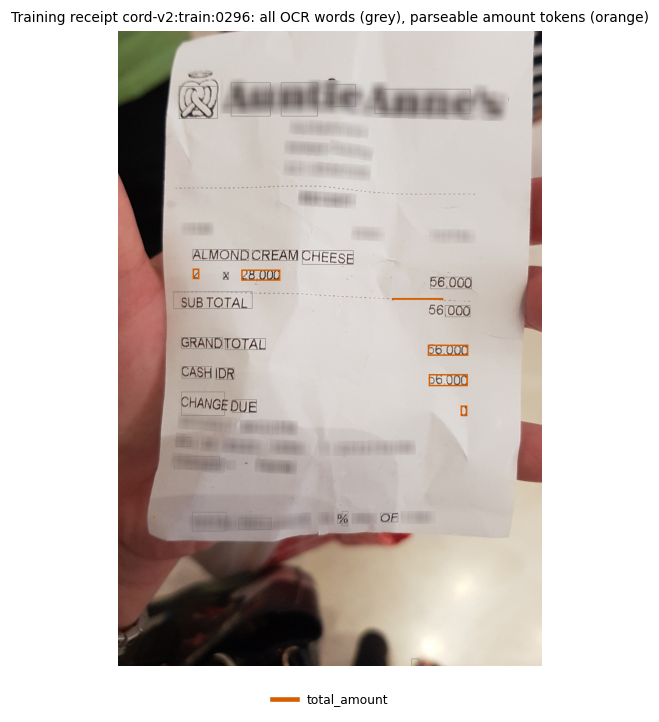

| token_id | text | line | confidence | parseable_amount |
| --- | --- | --- | --- | --- |
| 0 | ” | 1/1/1 | 10.5249 | False |
| 1 | (hy | 1/1/2 | 37.5702 | False |
| 2 | Man | 1/1/2 | 60.6876 | False |
| 3 | and | 1/1/2 | 53.0417 | False |
| 4 | be | 1/1/2 | 69.3976 | False |
| 5 | {ame | 1/1/2 | 26.1907 | False |
| 6 | ALMOND | 1/1/3 | 42.6312 | False |
| 7 | CREAM | 1/1/3 | 42.6312 | False |
| 8 | CHEESE | 1/1/3 | 90.4375 | False |
| 9 | 2 | 1/1/4 | 91.3554 | True |
| 10 | x | 1/1/4 | 91.3554 | False |
| 11 | 28,000 | 1/1/4 | 88.8630 | True |
| 12 | sajaga | 1/1/4 | 0.0000 | False |
| 13 | BEUBITOTAL | 1/1/5 | 5.3960 | False |
| 14 | 6 | 1/1/5 | 28.1402 | True |
| 15 | Coe | 1/1/5 | 18.0603 | False |
| 16 | GRAND | 1/1/6 | 19.8071 | False |
| 17 | TOTAL | 1/1/6 | 19.8071 | False |
| 18 | 56.0000 | 1/1/6 | 73.2046 | True |
| 19 | CASH | 1/1/7 | 68.3815 | False |
| 20 | IDR | 1/1/7 | 96.7300 | False |
| 21 | 56.0000 | 1/1/7 | 79.7481 | True |
| 22 | CHANGE | 1/1/8 | 96.2380 | False |
| 23 | DUE | 1/1/8 | 96.2105 | False |
| 24 | 9 | 1/1/8 | 83.0526 | True |
| 25 | > | 1/1/9 | 75.4503 | False |
| 26 | « | 1/1/9 | 72.2983 | False |
| 27 | e | 1/1/9 | 61.0083 | False |
| 28 | Ten | 1/1/10 | 25.6111 | False |
| 29 | '- | 1/1/10 | 76.0252 | False |

File: receipt_capstone_outputs/00bf144fd67d/outputs/ocr_tokens_example.csv
Showing 30 of 38 rows; open the CSV for all rows.


In [7]:
run_stage('ocr')
show_table('ocr_summary.csv')
show_figure('ocr_inspection.png')
show_table('ocr_tokens_example.csv', columns=['token_id', 'text', 'line', 'confidence', 'parseable_amount'], limit=30)

**What to notice:** the inspection uses a *training* receipt, so no evaluation receipt is examined early. Grey boxes are all recognised words; orange boxes are words the amount grammar can parse. A total that OCR split, merged or misread cannot be selected later by any extractor.

<details><summary>Show a worked answer</summary>Typical confusions are `0`/`O`, `1`/`l`, `5`/`S`, a dropped separator or a separator read as a comma. The normaliser never repairs these (no `O`→`0` substitution, no invented digits), so a misread total stays wrong or unparseable. That is deliberate: a silent repair could turn an unreadable amount into a confident wrong record.</details>

### How amounts are normalised

The frozen `cord_mixed_v1` grammar accepts non-negative integers, consistent three-digit grouping with `,` or `.`, and an optional two-digit decimal part after the *other* separator: `75,000`, `75.000`, `75,000.00` and `75.000,00` all become `75000`; `1,23,456`, percentages, signs, several amounts in one span and letters are `ambiguous`, `unsupported` or `parse_failed`, never guessed. A separately recognised `Rp` marker is removed and recorded as the currency; no currency is inferred from the country. Canonical amounts are decimal strings, never floating-point numbers.

## 5. System A: fixed keyword rules

**What does a transparent extractor get right or miss?** The keyword dictionary is derived from **training annotations only**: a key phrase becomes a field keyword when it appears at least three times and at least 80% of its training occurrences label that field. Matching is case- and punctuation-insensitive over whole OCR words, longest phrase first, so `SUB TOTAL` is never read as `TOTAL`, and cash, change and discount phrases cannot become totals. For each keyword the rule takes the rightmost parseable amount on its OCR line (receipts right-align prices), or on the next line if none; distinct values at the best rank are reported as `ambiguous`, not picked arbitrarily. Its ranking score is the lowest OCR confidence among the supporting key and amount words.

**Predict:** will the rules do better on totals or on tax, and what receipt layout would defeat them?

In [8]:
run_stage('keywords')
show_table('keyword_rules.csv', limit=30)
run_stage('rules')
show_table('validation_comparison.csv')

Running keywords in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/keywords.log
Keyword dictionary: 39 phrases from training annotations only


| field | phrase | training_support | purity |
| --- | --- | --- | --- |
| total_amount | dine in total | 8 | 1.0000 |
| total_amount | grand total | 60 | 0.9840 |
| total_amount | total sales | 9 | 1.0000 |
| total_amount | total belanja | 7 | 1.0000 |
| total_amount | amount due | 6 | 1.0000 |
| total_amount | total | 543 | 0.9490 |
| total_amount | grandtotal | 42 | 1.0000 |
| total_amount | tl | 23 | 0.9580 |
| total_amount | due | 19 | 0.9500 |
| total_amount | du | 8 | 1.0000 |
| subtotal_amount | sub total | 108 | 0.9470 |
| subtotal_amount | harga jual | 4 | 1.0000 |
| subtotal_amount | subtotal | 315 | 0.9720 |
| subtotal_amount | subttl | 22 | 1.0000 |
| subtotal_amount | dpp | 4 | 1.0000 |
| tax_amount | pajak rest 10 | 4 | 1.0000 |
| tax_amount | pajak ppn 10 | 3 | 1.0000 |
| tax_amount | pb1 10 | 45 | 1.0000 |
| tax_amount | tax 10 | 28 | 1.0000 |
| tax_amount | tax 1000 | 21 | 1.0000 |
| tax_amount | prest 10 | 17 | 1.0000 |
| tax_amount | restaurant tax | 14 | 1.0000 |
| tax_amount | tax 100 | 11 | 1.0000 |
| tax_amount | pajak 10 | 8 | 1.0000 |
| tax_amount | pb 1 | 8 | 0.8890 |
| tax_amount | pajak resto | 7 | 0.8750 |
| tax_amount | pb1 1000 | 6 | 1.0000 |
| tax_amount | vat 10 | 6 | 1.0000 |
| tax_amount | tax | 61 | 1.0000 |
| tax_amount | pb1 | 56 | 1.0000 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/keyword_rules.csv
Showing 30 of 39 rows; open the CSV for all rows.
Running rules in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/rules.log
Rule baseline predictions: 200 receipts x 4 fields


| system | field | usable_references | correct | em | parse_coverage |
| --- | --- | --- | --- | --- | --- |
| rules_baseline | total_amount | 49 | 15 | 0.3061 | 0.4200 |
| rules_baseline | subtotal_amount | 31 | 7 | 0.2258 | 0.2000 |
| rules_baseline | tax_amount | 20 | 1 | 0.0500 | 0.1200 |
| rules_baseline | service_charge | 7 | 1 | 0.1429 | 0.0200 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/validation_comparison.csv


**Interpret:** these are `validation_model` numbers (development data), not independent evidence. Each field's denominator is its count of usable references. A simple baseline winning is a legitimate result.

<details><summary>Show a worked answer</summary>Totals usually carry a distinctive keyword and sit at the right edge, so rules often do well on them; tax and service lines vary more (`PB1`, `PPN`, `SVC`, percentages next to amounts). Layouts that put the amount on a different line far below the label, abbreviations absent from training, or two `TOTAL` lines with different values defeat the rules, and the last case is reported as `ambiguous`.</details>

## 6. System B: frozen LayoutLM

**Does layout-aware extraction add value?** `impira/layoutlm-document-qa` (MIT) at a pinned revision answers each fixed question — *What is the total amount? What is the subtotal? What is the tax amount? What is the service charge?* — by choosing the best span of at most 15 tokens over overlapping 512-token windows (stride 128), exactly as the repository pipeline does. All four questions are asked for every receipt; references never decide which questions are asked. Its span score is a ranking signal, not a probability, and the model has no learned "no answer" option: it always returns its best span. These frozen predictions are saved **before** any training, so the baseline can never come from a model that was trained in memory.

**Predict:** will the frozen model's answers often include label words such as `Total`, and what would that do to exact match?

In [9]:
run_stage('frozen')
show_table('validation_comparison.csv')

Running frozen in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/frozen.log
  frozen LayoutLM 50/200
  frozen LayoutLM 100/200
  frozen LayoutLM 150/200
  frozen LayoutLM 200/200
Frozen LayoutLM predictions: 200 receipts in 27 s


| system | field | usable_references | correct | em | parse_coverage |
| --- | --- | --- | --- | --- | --- |
| rules_baseline | total_amount | 49 | 15 | 0.3061 | 0.4200 |
| rules_baseline | subtotal_amount | 31 | 7 | 0.2258 | 0.2000 |
| rules_baseline | tax_amount | 20 | 1 | 0.0500 | 0.1200 |
| rules_baseline | service_charge | 7 | 1 | 0.1429 | 0.0200 |
| layoutlm_frozen | total_amount | 49 | 19 | 0.3878 | 0.6800 |
| layoutlm_frozen | subtotal_amount | 31 | 11 | 0.3548 | 0.6400 |
| layoutlm_frozen | tax_amount | 20 | 3 | 0.1500 | 0.7200 |
| layoutlm_frozen | service_charge | 7 | 3 | 0.4286 | 0.6400 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/validation_comparison.csv


**Interpret:** a span such as `TOTAL 75.000` is readable but is not an amount, so the conservative normaliser returns `parse_failed` and the answer counts as wrong. That is the gap between *finding the right region* and *producing a usable record*.

<details><summary>Show a worked answer</summary>The Impira checkpoint was fine-tuned for general document questions, not for returning bare amounts on Indonesian receipts, so it can drift to label words, quantities or neighbouring prices. Because matching is exact, a near-miss earns no credit.</details>

## 7. Alignment and training (System C)

**What can be learned from noisy OCR?** A span extractor can learn only from a gold amount that exists in the recognised words. For each usable training reference the notebook searches contiguous OCR spans (same line, at most four words) whose normalised amount equals the reference and whose box overlaps the labelled value region (intersection-over-area ≥ 0.5). Nested matches collapse to the shortest; two separate matches are skipped as ambiguous; a missing or misread amount is skipped as `target_not_recoverable_from_ocr`. Reference text never replaces OCR tokens, and skips never become fake "no answer" examples.

The frozen recipe starts from a **fresh** pinned checkpoint (no earlier CORD adapter) and trains only the last four encoder blocks and the span head: AdamW, learning rate 3e-5, weight decay 0.01, batch 8, **4 epochs, all executed**, float32, gradient clipping 1.0, seed 42, no scheduler. The run asserts positive optimiser steps, finite loss, the exact trainable tensor list, a change in permitted tensors and **no** change in frozen tensors. The adapted candidate is chosen from **epochs 1–4** by `validation_model` total exact match (earliest epoch on ties); epoch 0 is not eligible, so the notebook always exports a trained model — even one that loses to System B.

**Predict:** what fraction of usable training totals will align to OCR, and will validation total EM rise every epoch?

Running train in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/train.log
Training on 636 aligned OCR examples from 378 receipts
epoch 1: train loss 0.9567, validation_model total EM 0.3469387755102041
epoch 2: train loss 0.5398, validation_model total EM 0.3673469387755102
epoch 3: train loss 0.4750, validation_model total EM 0.40816326530612246
epoch 4: train loss 0.3673, validation_model total EM 0.40816326530612246


| field | usable_references | aligned |
| --- | --- | --- |
| total_amount | 767 | 267 |
| subtotal_amount | 522 | 196 |
| tax_amount | 343 | 131 |
| service_charge | 97 | 42 |
| skipped: ambiguous_alignment | undefined | 2 |
| skipped: ocr_empty | undefined | 43 |
| skipped: target_not_recoverable_from_ocr | undefined | 1048 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/alignment_summary.csv


| Evidence | Value |
| --- | --- |
| adapter_sha256 | da69be11e69fc023bf956e6ffdc24b5ae1ab17810487b9194da0c40c99495549 |
| changed_tensors | 66 |
| n_total | 127792898 |
| n_trainable | 28353026 |
| optimizer_steps | 320 |
| seconds | 78.9322 |
| selected_epoch | 3 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/training_history.json


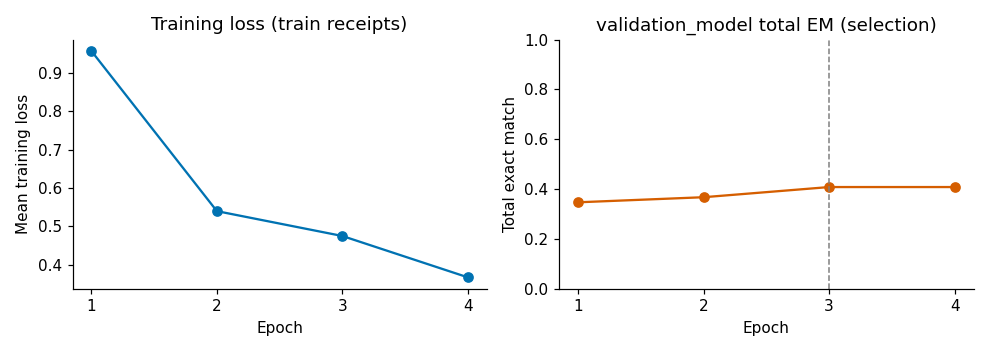

| system | field | usable_references | correct | em | parse_coverage |
| --- | --- | --- | --- | --- | --- |
| rules_baseline | total_amount | 49 | 15 | 0.3061 | 0.4200 |
| rules_baseline | subtotal_amount | 31 | 7 | 0.2258 | 0.2000 |
| rules_baseline | tax_amount | 20 | 1 | 0.0500 | 0.1200 |
| rules_baseline | service_charge | 7 | 1 | 0.1429 | 0.0200 |
| layoutlm_frozen | total_amount | 49 | 19 | 0.3878 | 0.6800 |
| layoutlm_frozen | subtotal_amount | 31 | 11 | 0.3548 | 0.6400 |
| layoutlm_frozen | tax_amount | 20 | 3 | 0.1500 | 0.7200 |
| layoutlm_frozen | service_charge | 7 | 3 | 0.4286 | 0.6400 |
| layoutlm_adapted | total_amount | 49 | 20 | 0.4082 | 0.6600 |
| layoutlm_adapted | subtotal_amount | 31 | 13 | 0.4194 | 0.6400 |
| layoutlm_adapted | tax_amount | 20 | 3 | 0.1500 | 0.7400 |
| layoutlm_adapted | service_charge | 7 | 2 | 0.2857 | 0.6800 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/validation_comparison.csv


In [10]:
run_stage('train')
show_table('alignment_summary.csv')
history = show_json('training_history.json', keys=['selected_epoch', 'n_trainable', 'n_total', 'optimizer_steps', 'changed_tensors', 'adapter_sha256', 'seconds'])
show_figure('training_curve.png')
show_table('validation_comparison.csv')

**Interpret:** read the alignment coverage beside everything that follows: fields with few aligned examples cannot be learned well. The selected epoch is the one validation favoured, not necessarily the last. Validation numbers are still development evidence.

<details><summary>Show a worked answer</summary>Alignment is limited by OCR: when Tesseract drops or garbles a digit the target is not recoverable, and the model never sees that receipt's total. Validation EM often rises then plateaus or dips; the selection rule keeps the best of epochs 1–4 without looking at test receipts.</details>

## 8. Review-policy development

**What changes when uncertain totals are referred?** A total always needs review when processing failed, no valid span exists, or the amount is unparsable or ambiguous. Otherwise it is left unflagged when its score reaches a system-specific threshold. Thresholds are chosen **only on `validation_policy` receipts**: maximise coverage subject to at least **95%** empirical accuracy, at least **50%** coverage and at least **25** unflagged receipts (illustrative teaching settings, not business service levels), searching every observed score plus accept-all and refer-all. If no threshold qualifies, the policy is **refer all** with `policy_feasible = false`; the target is never loosened automatically. States are `needs_review` and `total_unflagged` only — never "verified" or "approved".

**Predict:** will any system keep at least 95% accuracy while leaving at least half of the totals unflagged? And are each system's highest-scoring totals its most reliable ones?

Running select_policy in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/select_policy.log


| system | policy_feasible | threshold | selected_state | accepted | selection_support | coverage | empirical_accuracy | accuracy_interval |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| rules_baseline | False | undefined | refer_all | 0 | 49 | 0.0000 | undefined | undefined |
| layoutlm_frozen | False | undefined | refer_all | 0 | 49 | 0.0000 | undefined | undefined |
| layoutlm_adapted | False | undefined | refer_all | 0 | 49 | 0.0000 | undefined | undefined |

File: receipt_capstone_outputs/00bf144fd67d/outputs/policy_selection.csv


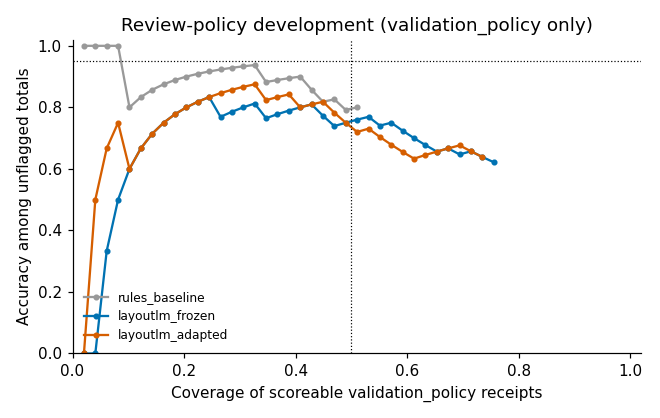

In [11]:
run_stage('select_policy')
show_table('policy_selection.csv')
show_figure('policy_validation.png')

**Interpret:** read each curve from left to right: the left end is the system's highest-scoring totals, and moving right admits lower-scoring ones. Each curve comes from about fifty receipts, so one decision moves accuracy by roughly two percentage points; the Wilson interval shows how uncertain a selected accuracy is. The dotted lines mark the 95% accuracy and 50% coverage requirements: a feasible policy needs a point above the first and to the right of the second. A feasible policy on validation is not a guarantee on new receipts, and an infeasible (refer-all) policy is a valid, reportable result.

<details><summary>Show a worked answer</summary>Coverage at a fixed accuracy target depends on how well a score *ranks* right answers above wrong ones, not on overall accuracy alone. Leaving half of the totals unflagged at 95% accuracy needs at least 95% × 50% ≈ 48% of all scoreable totals to be correct; when fewer are (compare the `validation_model` total EM from §7), no ranking can do it, so refer-all is the expected outcome. A curve that starts low at the far left means some of the system's most confident totals are wrong: its score is not a reliable signal for skipping review. A system with modest accuracy can still be safe at low coverage if its errors have low scores. §13 lets you choose the coverage and see the errors that come with it.</details>

## 9. Freeze, then test once

Before any test scoring, `selection_record.json` fixes the cohort, role and data identities, model/OCR identities, preprocessing, grammar, keyword, question and policy hashes, the training recipe, the chosen epoch, the adapter digest, every threshold and the metric definitions, sealed by its own SHA-256. Evaluation refuses to run if any of them changed.

**Primary endpoint:** total EM on test receipts with a usable total reference; OCR, model, parse and ambiguity failures count as incorrect. **Predetermined contrast:** adapted minus frozen LayoutLM, with both learned systems also compared with the rules. Intervals are paired receipt-level bootstrap (2,000 seeded resamples) for differences and Wilson intervals for single rates; they ignore merchant/template dependence and annotation bias. Secondary measures are per-field EM (with denominators), field-macro EM, the all-annotated-fields match (which says nothing about unannotated fields), text EM/ANLS and coverage.

**Predict:** will fine-tuning beat the frozen model on test totals, and will the difference's interval exclude zero?

Running freeze in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/freeze.log
Selection record frozen: 7272dcbfe2ae98ea


| Evidence | Value |
| --- | --- |
| adapter_sha256 | da69be11e69fc023bf956e6ffdc24b5ae1ab17810487b9194da0c40c99495549 |
| frozen_at | 2026-10-02T14:13:20+00:00 |
| record_digest | 7272dcbfe2ae98ea42691dbffd9d33b026b7e8d154384ec95154cf1a12495deb |
| selected_epoch | 3 |
| test_scored_before_freeze | false |

File: receipt_capstone_outputs/00bf144fd67d/outputs/selection_record.json
Running evaluate in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/evaluate.log
Held-out test evaluated once with the frozen selection record 7272dcbfe2ae98ea


| system | frozen_receipts | total_usable | total_correct | total_em | field_macro_em | all_annotated_fields_match |
| --- | --- | --- | --- | --- | --- | --- |
| rules_baseline | 100 | 94 | 28 | 0.2979 | 0.1889 | 0.2021 |
| layoutlm_frozen | 100 | 94 | 35 | 0.3723 | 0.2719 | 0.2872 |
| layoutlm_adapted | 100 | 94 | 35 | 0.3723 | 0.2966 | 0.2979 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/system_comparison.csv


| contrast | n | difference | interval_low | interval_high | resamples |
| --- | --- | --- | --- | --- | --- |
| adapted_minus_frozen | 94 | 0.0000 | -0.0532 | 0.0532 | 2000 |
| frozen_minus_rules | 94 | 0.0745 | 0.0000 | 0.1489 | 2000 |
| adapted_minus_rules | 94 | 0.0745 | 0.0106 | 0.1489 | 2000 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/paired_bootstrap.csv


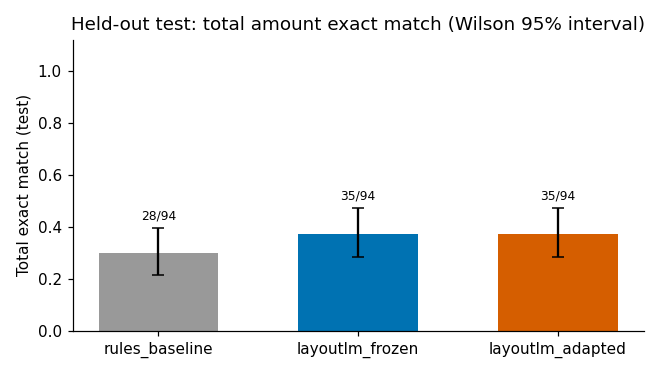

| system | field | usable_references | correct | em | parse_coverage | unscored_on_not_annotated |
| --- | --- | --- | --- | --- | --- | --- |
| rules_baseline | total_amount | 94 | 28 | 0.2979 | 0.3900 | 1 |
| rules_baseline | subtotal_amount | 65 | 21 | 0.3231 | 0.2800 | 1 |
| rules_baseline | tax_amount | 39 | 2 | 0.0513 | 0.0800 | 0 |
| rules_baseline | service_charge | 12 | 1 | 0.0833 | 0.0300 | 0 |
| layoutlm_frozen | total_amount | 94 | 35 | 0.3723 | 0.7000 | 2 |
| layoutlm_frozen | subtotal_amount | 65 | 24 | 0.3692 | 0.6400 | 19 |
| layoutlm_frozen | tax_amount | 39 | 7 | 0.1795 | 0.7200 | 40 |
| layoutlm_frozen | service_charge | 12 | 2 | 0.1667 | 0.5700 | 51 |
| layoutlm_adapted | total_amount | 94 | 35 | 0.3723 | 0.6500 | 2 |
| layoutlm_adapted | subtotal_amount | 65 | 25 | 0.3846 | 0.6500 | 20 |
| layoutlm_adapted | tax_amount | 39 | 7 | 0.1795 | 0.6400 | 36 |
| layoutlm_adapted | service_charge | 12 | 3 | 0.2500 | 0.6500 | 58 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/field_metrics.csv


| system | policy_feasible | threshold | usable_total_references | scored_coverage | selective_error | unflagged_scored | unflagged_wrong | operational_routing_coverage | review_count | hard_failures |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| rules_baseline | False | undefined | 94 | 0.0000 | undefined | 0 | 0 | 0.0000 | 100 | 61 |
| layoutlm_frozen | False | undefined | 94 | 0.0000 | undefined | 0 | 0 | 0.0000 | 100 | 30 |
| layoutlm_adapted | False | undefined | 94 | 0.0000 | undefined | 0 | 0 | 0.0000 | 100 | 35 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/review_metrics.csv


In [12]:
run_stage('freeze')
show_json('selection_record.json', keys=['record_digest', 'selected_epoch', 'adapter_sha256', 'frozen_at', 'test_scored_before_freeze'])
run_stage('evaluate')
show_table('system_comparison.csv', columns=['system', 'frozen_receipts', 'total_usable', 'total_correct', 'total_em', 'field_macro_em', 'all_annotated_fields_match'])
show_table('paired_bootstrap.csv')
show_figure('test_comparison.png')
show_table('field_metrics.csv', columns=['system', 'field', 'usable_references', 'correct', 'em', 'parse_coverage', 'unscored_on_not_annotated'], limit=12)
show_table('review_metrics.csv', columns=['system', 'policy_feasible', 'threshold', 'usable_total_references', 'scored_coverage', 'selective_error', 'unflagged_scored', 'unflagged_wrong', 'operational_routing_coverage', 'review_count', 'hard_failures'])

**Interpret:** keep the unfiltered primary EM beside the selective metrics: a low selective error on a small unflagged set does not make the whole workflow accurate. *Scored coverage* uses receipts with usable truth; *operational routing coverage* counts every frozen receipt, including those whose correctness is unknown. Do not revise any setting after reading this section — doing so starts a new experiment on an already-inspected test set.

<details><summary>Show a worked answer</summary>Fine-tuning on OCR-aligned examples usually teaches the model to return bare amounts, which the frozen model often does not, so an improvement is plausible but not guaranteed. With about one hundred test receipts, an interval that includes zero means the sample cannot distinguish the systems; that is a finding, not a failure.</details>

## 10. Diagnose: OCR, extraction, parsing or the reference?

**Reference-text diagnostic.** The same frozen weights and questions are re-run on CORD's *annotated* words and boxes (categories, key flags and parsed values stripped). This changes recognition, geometry and reading order together, so it is an input-source sensitivity check, not a causal decomposition or an upper bound; an OCR-trained model may do worse on reference text. It is labelled `reference_text_diagnostic` and never replaces the image-based result.

**OCR recoverability (evaluator-only).** For usable references, is the correct amount present in a spatially compatible OCR span? The primary score is never filtered by it and no predictor sees it.

**Failure panel.** After scores are fixed, one test receipt per category is chosen deterministically for the adapted system; an empty category is reported as empty rather than manufactured. Categories, checked in this order:

| Category | Meaning |
| --- | --- |
| success | the total equals the reference |
| failure or no candidate | processing failed or the system returned no amount at all |
| numeric ambiguity | the chosen words hold an amount the grammar refuses to guess (`ambiguous`, `unsupported`: several amounts, percentages, signs, inconsistent separators) |
| extraction error | the correct amount is in the OCR (recoverable) but the system chose other words, including words that are not an amount |
| OCR loss | the correct amount is not in the OCR at all, so no extractor could have chosen it (for example `800` read as `BOO`) |

Each panel draws the chosen words' boxes on the receipt, so you can trace the extracted total back to its OCR words.

Running diagnose in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/diagnose.log


| system | field | usable_references | actual_ocr_em | reference_text_diagnostic_em |
| --- | --- | --- | --- | --- |
| rules_baseline | total_amount | 94 | 0.2979 | 0.8191 |
| rules_baseline | subtotal_amount | 65 | 0.3231 | 0.8462 |
| rules_baseline | tax_amount | 39 | 0.0513 | 0.9231 |
| rules_baseline | service_charge | 12 | 0.0833 | 0.8333 |
| layoutlm_frozen | total_amount | 94 | 0.3723 | 0.8830 |
| layoutlm_frozen | subtotal_amount | 65 | 0.3692 | 0.9231 |
| layoutlm_frozen | tax_amount | 39 | 0.1795 | 0.7692 |
| layoutlm_frozen | service_charge | 12 | 0.1667 | 0.8333 |
| layoutlm_adapted | total_amount | 94 | 0.3723 | 0.9468 |
| layoutlm_adapted | subtotal_amount | 65 | 0.3846 | 0.9538 |
| layoutlm_adapted | tax_amount | 39 | 0.1795 | 0.9487 |
| layoutlm_adapted | service_charge | 12 | 0.2500 | 0.9167 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/reference_text_diagnostic.csv


| field | system | usable_references | ocr_recoverable | recoverable_ambiguous | not_recoverable | recoverable_proportion | em_given_recoverable_secondary |
| --- | --- | --- | --- | --- | --- | --- | --- |
| total_amount | rules_baseline | 94 | 36 | 0 | 58 | 0.3830 | 0.7778 |
| total_amount | layoutlm_frozen | 94 | 36 | 0 | 58 | 0.3830 | 0.8333 |
| total_amount | layoutlm_adapted | 94 | 36 | 0 | 58 | 0.3830 | 0.8889 |
| subtotal_amount | rules_baseline | 65 | 24 | 0 | 41 | 0.3692 | 0.7500 |
| subtotal_amount | layoutlm_frozen | 65 | 24 | 0 | 41 | 0.3692 | 0.9167 |
| subtotal_amount | layoutlm_adapted | 65 | 24 | 0 | 41 | 0.3692 | 0.9167 |
| tax_amount | rules_baseline | 39 | 10 | 0 | 29 | 0.2564 | 0.2000 |
| tax_amount | layoutlm_frozen | 39 | 10 | 0 | 29 | 0.2564 | 0.7000 |
| tax_amount | layoutlm_adapted | 39 | 10 | 0 | 29 | 0.2564 | 0.7000 |
| service_charge | rules_baseline | 12 | 4 | 0 | 8 | 0.3333 | 0.2500 |
| service_charge | layoutlm_frozen | 12 | 4 | 0 | 8 | 0.3333 | 0.5000 |
| service_charge | layoutlm_adapted | 12 | 4 | 0 | 8 | 0.3333 | 0.7500 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/ocr_recoverability.csv


| category | receipt_id | reference | prediction_raw | prediction_amount | parse_status | recoverability |
| --- | --- | --- | --- | --- | --- | --- |
| success | cord-v2:test:0099 | 75000 | 75,000 | 75000 | ok | recoverable |
| ocr_loss | cord-v2:test:0098 | 250690 | 9900 | 9900 | ok | not_recoverable |
| extraction_error | cord-v2:test:0008 | 50000 | 45,455 | 45455 | ok | recoverable |
| numeric_ambiguity | cord-v2:test:0062 | 48000 | 48, 000 | undefined | ambiguous | not_recoverable |
| failure_or_no_candidate | cord-v2:test:0020 | 377859 | undefined | undefined | failed | not_recoverable |

File: receipt_capstone_outputs/00bf144fd67d/outputs/failure_panel.csv


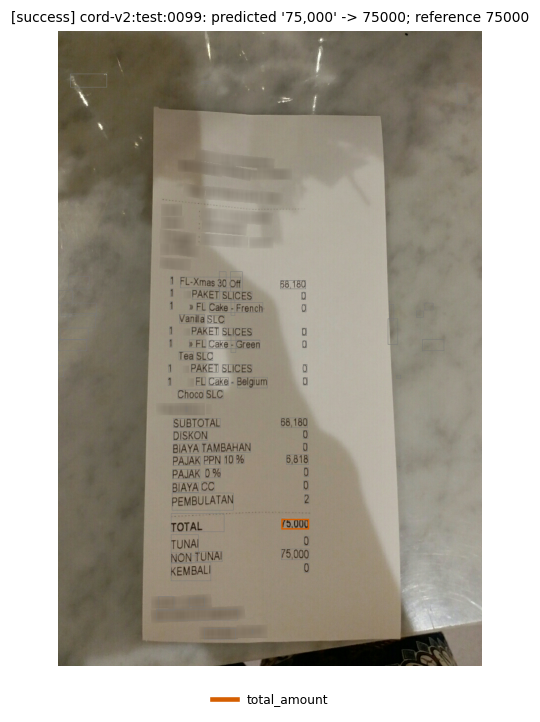

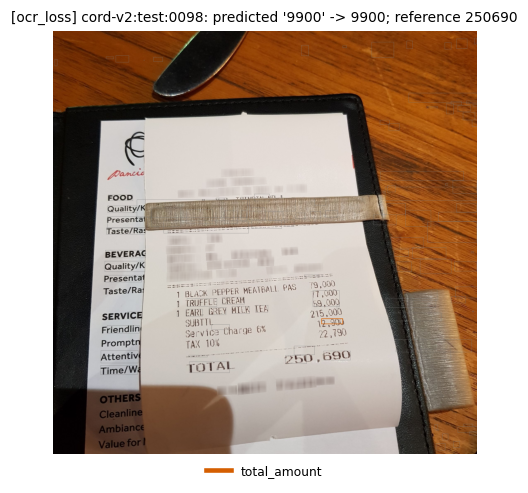

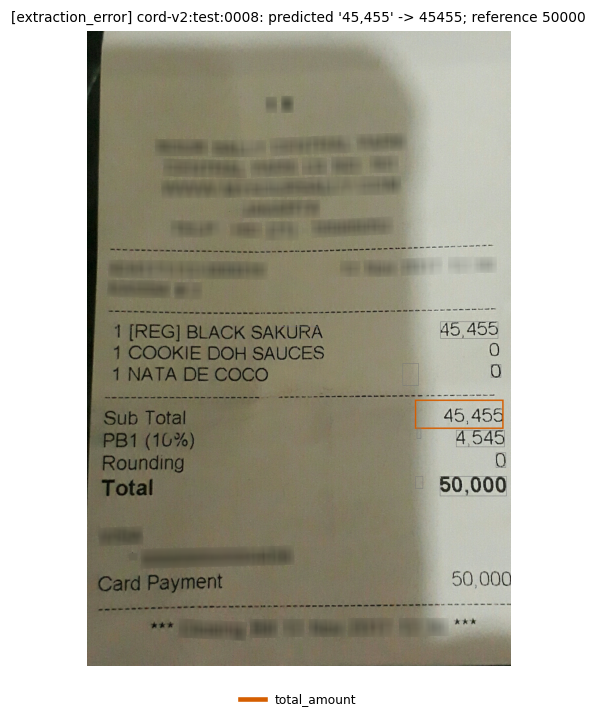

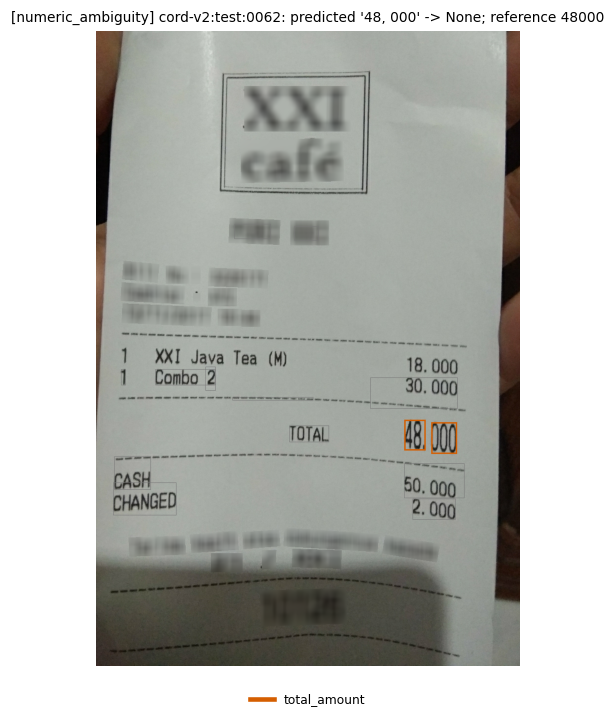

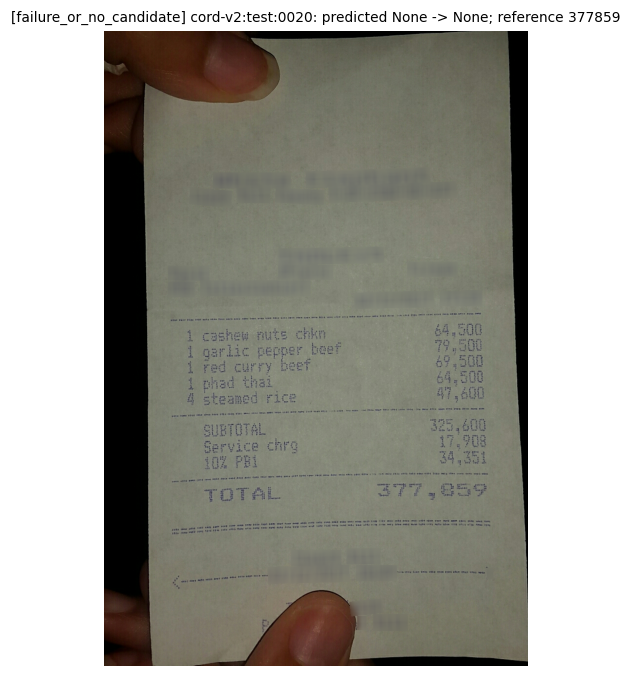

In [13]:
run_stage('diagnose')
show_table('reference_text_diagnostic.csv', limit=12)
show_table('ocr_recoverability.csv', limit=12)
show_table('failure_panel.csv')
for category in ('success', 'ocr_loss', 'extraction_error', 'numeric_ambiguity', 'failure_or_no_candidate'):
    if (ROOT / 'outputs' / 'figures' / f'panel_{category}.png').exists():
        show_figure(f'panel_{category}.png')

**Interpret:** if a large share of test totals is *not recoverable* from OCR, no extractor could have got them right; improving OCR (or image capture) would matter more than a better extractor. Conditional EM on recoverable totals is secondary evidence only.

<details><summary>Show a worked answer</summary>An extractive model selects words; it cannot restore a digit Tesseract never produced. When the reference-text diagnostic scores far higher than actual OCR, recognition is the bottleneck; when both are low, extraction or the amount grammar is the bottleneck.</details>

## 11. Infer and export

The export stage writes machine-readable records for the evaluation roles — `predictions.jsonl` (exact raw strings, token IDs, canonical amounts, parse states, review decision) and spreadsheet-safe `records.csv` (formula-like strings are neutralised; JSON keeps the exact text). It also writes the serving bundle: the selected trained tensors in SafeTensors, the base identity, questions, OCR lock, preprocessing, number grammar, keyword rules, review policy, reconstruction notes and licences. The bundle contains no receipt image, OCR transcript, training example or reference, but weights may still encode what they learned. It is not a DIMER production-worker artifact.

In [14]:
run_stage('export')
show_table('records.csv', columns=['receipt_id', 'role', 'system_id', 'total_amount_raw_text', 'total_amount_normalized', 'total_amount_parse_status', 'total_review_state'], limit=9)
show_table('artifact_inventory.csv')

Running export in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/export.log
Exported 66 trained tensors (113,419,976 bytes)


| receipt_id | role | system_id | total_amount_raw_text | total_amount_normalized | total_amount_parse_status | total_review_state |
| --- | --- | --- | --- | --- | --- | --- |
| cord-v2:test:0000 | test | rules_baseline | 60,000 | 60000 | ok | needs_review |
| cord-v2:test:0001 | test | rules_baseline | 91000 | 91000 | ok | needs_review |
| cord-v2:test:0002 | test | rules_baseline | 006 | 6 | ok | needs_review |
| cord-v2:test:0003 | test | rules_baseline | undefined | undefined | no_candidate | needs_review |
| cord-v2:test:0004 | test | rules_baseline | undefined | undefined | no_candidate | needs_review |
| cord-v2:test:0005 | test | rules_baseline | undefined | undefined | no_candidate | needs_review |
| cord-v2:test:0006 | test | rules_baseline | 46,000 | 46000 | ok | needs_review |
| cord-v2:test:0007 | test | rules_baseline | undefined | undefined | no_candidate | needs_review |
| cord-v2:test:0008 | test | rules_baseline | undefined | undefined | no_candidate | needs_review |

File: receipt_capstone_outputs/00bf144fd67d/outputs/records.csv
Showing 9 of 600 rows; open the CSV for all rows.


| file | bytes | sha256 |
| --- | --- | --- |
| manifest.json | 8486 | 7f19c29e06f10d98d0cd4866b8d624f935ef4e23d320dd22aae92e3f0f9562d4 |
| adapter.safetensors | 113419976 | da69be11e69fc023bf956e6ffdc24b5ae1ab17810487b9194da0c40c99495549 |
| model_config.json | 168 | 9a8f9b0206bd4c37b17e9328c45fb4cb8e96233ac011c5d68c2c7c09a38cb1c5 |
| field_schema.json | 418 | 3a16ed3270f4413d49e00947ae73ea585722ace56149008790e4e7cce7336be2 |
| questions.json | 173 | b661525f56d43cf505a0773d66df8e6ebb2a906746466eb4271ea46e773201cc |
| preprocessing.json | 161 | 74bff855579308bf62f73c608551291bf1ec87fcb0a9fd912d3c90bc21865c65 |
| ocr_manifest.json | 11584 | c1c0abe28c05a0745006ad706fd67d1b5ec7a9fd92155d7e0c0a037aa2fdf02e |
| number_format_policy.json | 363 | faa4053f01708c8ad5f02275f4fca010417155787beb29862679f90b7622001c |
| keyword_rules.json | 2384 | f9ba0b38fb9bf56b1bb2cc39c416975e668802896eb3ab6dd052efd3004bea93 |
| review_policy.json | 1875 | 57cba6e12777f21061b362488a978880ea8d7467d4ba8323ca9b2320c04157d5 |
| runtime_manifest.json | 874 | 9c30cd548a498647d273147ccb38996c90d8c3f5f4a2fb02b5c0dc8d97537649 |
| RECONSTRUCT.md | 1169 | 4c4fad92a1a1fcbccd4442ebc72ccfe6e7648b4d13cb62661812bef40b71f294 |
| LICENSES_AND_ATTRIBUTION.md | 551 | 3631c9fdc3ad57b0dc612b6cf67664f087bef5b88221461b48f2e5610df307a5 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/artifact_inventory.csv


## 12. Fresh reload: can the serialized workflow reproduce its output?

A **new process** verifies the bundle's file set, sizes, digests, schema, tensor names/shapes and base identity *before* loading, loads a fresh verified checkpoint, applies only the allowed tensors, rebuilds OCR, questions, grammar, rules and policy from JSON, then re-runs three deterministically chosen held-out receipts through the whole image → OCR → record path with **no labels supplied**. OCR tokens, spans, amounts, parse states and review decisions must match exactly; scores within `atol=1e-6, rtol=1e-5`. These are demonstration replays of held-out images, not a second test set.

In [15]:
run_stage('replay')
show_json('replay_report.json', keys=['pid', 'receipts', 'all_parity', 'labels_supplied', 'note'])
show_table('replay_records.csv')
run_stage('report')
show_table('runtime_summary.csv', limit=20)
show_json('archive_verification.json')
display(Markdown((ROOT / 'outputs' / 'summary.md').read_text(encoding='utf-8')))
print('Results ZIP (derived evidence + small bundle; no receipt images):', ROOT / 'outputs' / 'results.zip')
if DOWNLOAD_RESULTS:
    from google.colab import files as colab_files
    colab_files.download(str(ROOT / 'outputs' / 'results.zip'))

Running replay in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/replay.log
Fresh-process replay (pid 10386): 3 receipts, parity PASS


| Evidence | Value |
| --- | --- |
| all_parity | true |
| labels_supplied | false |
| note | held-out demonstration replay, not a second independent test |
| pid | 10386 |
| receipts | 3 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/replay_report.json


| receipt_id | total_raw_text | total_normalized | total_parse_status | total_score | total_review_state | subtotal_normalized | tax_normalized | service_normalized | parity |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| cord-v2:test:0067 | EN | undefined | parse_failed | 0.9925 | needs_review | undefined | undefined | undefined | True |
| cord-v2:test:0071 | 198000 | 198000 | ok | 0.3057 | needs_review | 499000 | 200200 | 198000 | True |
| cord-v2:test:0073 | 22.0000 | 22000 | ok | 0.9996 | needs_review | 22000 | 22000 | 22000 | True |

File: receipt_capstone_outputs/00bf144fd67d/outputs/replay_records.csv
Running report in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/report.log


...

File: receipt_capstone_outputs/00bf144fd67d/outputs/runtime_summary.csv


| Evidence | Value |
| --- | --- |
| bytes | 105385888 |
| crc | pass |
| excluded | receipt images, figures, OCR transcripts, weights of the base |
| member_digests | pass |
| members | 32 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/archive_verification.json


# Receipt intelligence capstone - run summary (0.2.0-candidate)

Run `00bf144fd67d`; selection record `7272dcbfe2ae98ea`; data naver-clova-ix/cord-v2@7f0115a4b758

| System | Test total EM | Correct / usable | Field-macro EM | Scored coverage | Selective error |
| --- | --- | --- | --- | --- | --- |
| layoutlm_adapted | 0.3723 | 35/94 | 0.2966 | 0.0000 | undefined |
| layoutlm_frozen | 0.3723 | 35/94 | 0.2719 | 0.0000 | undefined |
| rules_baseline | 0.2979 | 28/94 | 0.1889 | 0.0000 | undefined |

Paired receipt bootstrap (2,000 resamples) of total-EM differences:

- adapted_minus_frozen: 0.0000 (95% interval -0.0532 to 0.0532, n=94)
- adapted_minus_rules: 0.0745 (95% interval 0.0106 to 0.1489, n=94)
- frozen_minus_rules: 0.0745 (95% interval 0.0000 to 0.1489, n=94)

Selected epoch 3 of 4 (validation_model total EM); 636 aligned OCR training examples; fresh-process replay parity: PASS.

Scope: Indonesian CORD v2 receipts. No Philippine, unseen-merchant, production or accounting-grade claim follows. Review states are routing, not verification.


Results ZIP (derived evidence + small bundle; no receipt images): /content/receipt_capstone_outputs/00bf144fd67d/outputs/results.zip


## 13. Change one thing: how many totals to leave unflagged

**Predict → change one thing → run → observe → explain.** The canonical policy demands 95% accuracy on at least half of the totals and may refer every total. Here the one changed setting is the **share of totals left unflagged** (the `ACTIVITY_COVERAGE` control, default 0.30): each system leaves its top-scored 30% of scoreable `validation_policy` totals unflagged and refers the rest, with no accuracy requirement. The table puts each system's canonical row beside its activity row: `accepted` totals left unflagged, their `empirical_accuracy`, and `unflagged_wrong`, the wrong totals that would skip human review. No training and no test data are used; the canonical threshold, model, selection record and test results are untouched, and results go to `outputs/activity/coverage_<value>/`.

To try another value, edit `ACTIVITY_COVERAGE` in §1, run the §1 controls cell again, then run the next cell; each value gets its own folder. Values from 0.05 to 1.0 are accepted.

**Predict:** at 30% coverage, which system leaves the fewest wrong totals unflagged, and is it the system with the best overall exact match?

Running activity-coverage in a separate process. Log: /content/receipt_capstone_outputs/00bf144fd67d/activity-coverage.log
{"folder": "/content/receipt_capstone_outputs/00bf144fd67d/outputs/activity/coverage_0.30"}


| system | setting | threshold | accepted | coverage | empirical_accuracy | unflagged_wrong | accuracy_interval | reached_requested | selection_support |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| rules_baseline | canonical_95pct_policy | undefined | 0 | 0.0000 | undefined | 0 | undefined | not_applicable | 49 |
| rules_baseline | activity_coverage_0.30 | 0.7437 | 15 | 0.3061 | 0.9333 | 1 | [0.7018347012621998, 0.9881331045067315] | True | 49 |
| layoutlm_frozen | canonical_95pct_policy | undefined | 0 | 0.0000 | undefined | 0 | undefined | not_applicable | 49 |
| layoutlm_frozen | activity_coverage_0.30 | 0.9991 | 15 | 0.3061 | 0.8000 | 3 | [0.5481455128483065, 0.9295245065301844] | True | 49 |
| layoutlm_adapted | canonical_95pct_policy | undefined | 0 | 0.0000 | undefined | 0 | undefined | not_applicable | 49 |
| layoutlm_adapted | activity_coverage_0.30 | 0.9961 | 15 | 0.3061 | 0.8667 | 2 | [0.6211801716767764, 0.9626387408969346] | True | 49 |

File: receipt_capstone_outputs/00bf144fd67d/outputs/activity/coverage_0.30/activity_comparison.csv


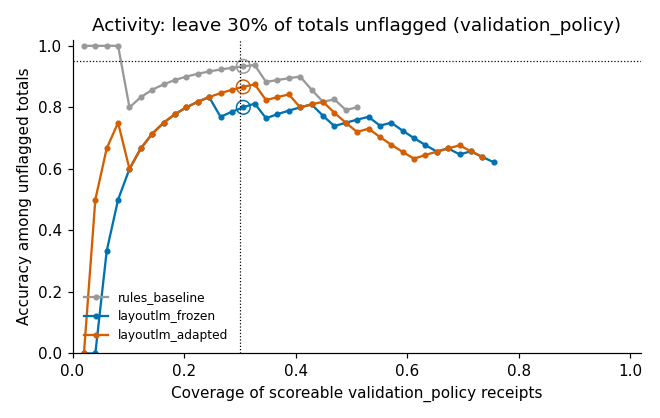

In [16]:
run_stage(None, '--activity-coverage', repr(float(ACTIVITY_COVERAGE)))
folder = ROOT / 'outputs' / 'activity' / f'coverage_{float(ACTIVITY_COVERAGE):.2f}'
show_table(str(folder.relative_to(ROOT / 'outputs') / 'activity_comparison.csv'))
display(Image(filename=str(folder / 'activity.png')))

**Explain:** the vertical dotted line is your chosen coverage and the open circles are each system's operating point; the horizontal line is the canonical 95% requirement. Leaving more totals unflagged admits lower-scoring ones, so accuracy among unflagged totals usually falls and `unflagged_wrong` rises. `reached_requested` showing False means the system had too few valid totals to reach your coverage, so all of them were accepted. On about fifty validation receipts each total moves accuracy by about two points; this is a teaching comparison, not an estimate of a real service level.

<details><summary>Show a worked answer</summary>The safest system at low coverage is the one whose *scores* put right answers first, which need not be the one with the best overall exact match. A transparent rule whose score is the lowest OCR confidence of its supporting words can rank its few confident totals well, while a model that always returns its best span can attach high scores to wrong spans; that shows as a low left end of its curve. Raising the coverage moves every system right along its curve toward its overall accuracy. Whatever the numbers, none of these operating points is validated for new receipts or for the held-out test set.</details>

## 14. Optional: bring your own receipts (BYOD)

Off by default. **Privacy and authority:** process only receipts you are authorised to process in this hosted runtime, remove unnecessary personal or payment details first, and review every export before sharing. Nothing is sent to an OCR or LLM API; "local" here means this Colab runtime, not your own computer.

Upload a ZIP in the Files panel, set `USE_BYOD`, `BYOD_MODE`, `BYOD_PATH` and `BYOD_AUTHORIZED` in §1, **run the §1 controls cell again** so the new values take effect, then run this section. The ZIP holds `manifest.json` (schema `org.dimer.receipt-byod.v1`, `authorized: true`, `number_format_policy` = `dot_decimal_comma_grouping` or `comma_decimal_dot_grouping`, a three-letter `currency` such as `PHP`, and one entry per image with a nonidentifying `receipt_id` and relative `image` path) and the JPEG/PNG images. Limits: 1,000 images, 2 GiB compressed, 5 GiB expanded, 20 MiB / 20 MP per image; traversal, links, duplicates and undeclared files are refused.

* **`inference`**: the canonical bundle extracts four candidates; the CORD-selected threshold is **not validated for your receipts**, so every total defaults to `needs_review` and the transferred decision is only shown for comparison. No accuracy is reported without checked references.
* **`adapt`**: adds `annotations.jsonl` (per receipt and field: `status` `present`/`not_annotated`, `raw_value`, `value_boxes` in original-image pixels, `provenance`) and explicit disjoint roles `train`, `validation_model`, `validation_policy`, `test` (optional `inference`) with a `group_id` per receipt; groups may not cross roles. The full workflow then runs in a separate directory from a fresh base: at least eight aligned training examples and nonempty validation and test roles are required, and missing prerequisites are refused. Small samples are small-sample evidence; a Philippine BYOD run is a new evaluation, not an extension of the CORD score.

In [17]:
# @title Optional BYOD run (off unless enabled in §1)
if not USE_BYOD:
    print('Optional BYOD is off. To run it, set USE_BYOD and the other BYOD fields in §1, run the §1 controls cell again, then run this cell.')
else:
    if not BYOD_AUTHORIZED:
        raise ValueError('Confirm in §1 that you are authorised to process these receipts (BYOD_AUTHORIZED).')
    archive = Path(BYOD_PATH).expanduser().resolve()
    if not archive.is_file():
        raise ValueError('Upload a ZIP in the Colab Files panel and set BYOD_PATH to its path.')
    inspect = subprocess.run([str(PYTHON), str(ROOT / 'capstone.py'), '--byod-inspect', str(archive), '--byod-mode', BYOD_MODE],
                             env=ENV, capture_output=True, text=True)
    if inspect.returncode:
        raise ValueError('BYOD archive refused: ' + inspect.stderr.strip().splitlines()[-1])
    contract = json.loads(inspect.stdout)
    byod_root = ROOT.parent / (ROOT.name + '-byod-' + uuid.uuid4().hex[:6])
    byod_root.mkdir()
    for name, text in CARRIED_FILES.items():
        path = byod_root / name
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(text, encoding='utf-8', newline='\n')
    config = {'run_id': RUN_ID + '-byod', 'source': 'byod', 'byod_archive': str(archive), 'byod_mode': BYOD_MODE,
              'number_format_policy': contract['policy'], 'currency': contract['currency'],
              'cache_dir': str(ROOT / 'cache'), 'ocr_runtime_from': str(ROOT / 'outputs' / 'ocr_runtime.json'),
              'keyword_rules_from': str(ROOT / 'stages' / 'keywords' / 'keyword_rules.json')}
    if BYOD_MODE == 'inference':
        config.update(mode='byod_inference', bundle_from=str(ROOT / 'stages' / 'export' / 'receipt_intelligence_artifact'))
        stages = ('prepare', 'ocr_runtime', 'model', 'ocr', 'byod_infer')
    else:
        config.update(mode='canonical')
        stages = ('prepare', 'references', 'ocr_runtime', 'model', 'ocr', 'keywords', 'rules', 'frozen', 'train',
                  'select_policy', 'freeze', 'evaluate', 'diagnose', 'export', 'replay', 'report')
    (byod_root / 'run_config.json').write_text(json.dumps(config), encoding='utf-8')
    for stage in stages:
        run_stage(stage, root=byod_root)
    if BYOD_MODE == 'inference':
        show_table('byod_records.csv', root=byod_root, limit=20)
    else:
        show_table('system_comparison.csv', root=byod_root)
        show_table('review_metrics.csv', root=byod_root, columns=['system', 'policy_feasible', 'scored_coverage', 'selective_error', 'unflagged_scored'])
    print('Separate BYOD outputs (never merged into the canonical results):', byod_root / 'outputs')

Optional BYOD is off. To run it, set USE_BYOD and the other BYOD fields in §1, run the §1 controls cell again, then run this cell.


## 15. Conclude with evidence

Complete this optional scaffold in your own words:

> **Task and population:** On [n] held-out CORD v2 Indonesian receipts, extracting [fields] from photographs through Tesseract OCR…
> **Principal result and baseline:** [system] reached total EM [value, interval] versus [rules] and [frozen model]; the adapted-minus-frozen difference was [value, interval].
> **One failure mode:** [OCR loss / label words in spans / ambiguous separators / …], seen in [evidence].
> **Review trade-off:** the validation-selected 95% policy left [scored coverage] unflagged with selective error [value] (policy feasible: [yes/no]); leaving [x] of validation totals unflagged, [system] left [k] wrong totals unflagged ([accuracy]).
> **Uncertainty:** [small validation sets, template dependence, annotation bias, unknown pretraining overlap].
> **Evidence needed for transfer:** [authorised local receipts with checked references and boxes, merchant-disjoint splits, a locally validated review policy, human audit of references…].

Limits that bound every conclusion: published CORD annotations are references, not verified accounting truth; missing annotations do not establish absence; scores are uncalibrated; the review policy routes totals only and never certifies a record; the arithmetic `subtotal + tax + service = total` is not assumed (discounts, inclusive tax and rounding are outside this schema); and a losing fine-tuned model, poor OCR or an infeasible 95% policy are valid, informative outcomes.

### References

- Park, S., Shin, S., Lee, B., Lee, J., Surh, J., Seo, M., & Lee, H. (2019). *CORD: A consolidated receipt dataset for post-OCR parsing*. Document Intelligence Workshop at NeurIPS. [Publisher repository](https://github.com/clovaai/cord) (no DOI verified). Dataset: [naver-clova-ix/cord-v2](https://huggingface.co/datasets/naver-clova-ix/cord-v2), CC BY 4.0.
- Xu, Y., Li, M., Cui, L., Huang, S., Wei, F., & Zhou, M. (2020). LayoutLM: Pre-training of text and layout for document image understanding. *Proceedings of KDD 2020*, 1192–1200. https://doi.org/10.1145/3394486.3403172
- Chow, C. K. (1970). On optimum recognition error and reject tradeoff. *IEEE Transactions on Information Theory, 16*(1), 41–46. https://doi.org/10.1109/TIT.1970.1054406 (the error–rejection idea; not a claim that this uncalibrated threshold is optimal).
- Engineering sources: [impira/layoutlm-document-qa model card](https://huggingface.co/impira/layoutlm-document-qa); [Tesseract command-line usage](https://tesseract-ocr.github.io/tessdoc/Command-Line-Usage.html) and [tessdata_fast](https://github.com/tesseract-ocr/tessdata_fast); [DIMER notebook standard](https://github.com/kurtvalcorza/ml-worker/blob/main/integrations/dimer/fleet-specs/NOTEBOOK_SPEC.md); [this repository](https://github.com/kurtvalcorza/layoutlm-document-qa-pipeline).

### Troubleshooting

| Observation | Response |
| --- | --- |
| No T4 or too little disk | Start a fresh T4 runtime; do not substitute a CPU or another accelerator silently. |
| Hash, count or schema refusal | Stop and keep the log; never switch to `main`, a mirror, another dataset version or reference OCR. |
| OCR install or language check fails | Keep the log. The pinned closure installed on Colab and Kaggle T4 runtimes on 2026-09-29, so a failure is most often a transient download error: start a fresh runtime and Run all again. Never switch to an unpinned Tesseract. |
| Training refuses (< 8 aligned examples) | The data contract failed; do not synthesise supervision. |
| Policy is refer-all | A valid result: no threshold met the declared targets on validation. |
| Replay parity fails | Keep outputs; resolve the mismatch before any release claim. |
| An undefined metric | Read its denominator; do not replace it with a favourable number. |